In [12]:
# ============================================================
# STEP 1 — RERUN-SAFE / RESUMABLE PROJECT INITIALIZATION
# Bangladesh MICS 2025 E. coli Reconstruction
# ============================================================
#
# SAFE TO RUN MULTIPLE TIMES.
#
# BEHAVIOUR
# ---------
# If project does not exist:
#     -> create it
#     -> copy raw file
#     -> generate RUN_ID
#
# If project already exists:
#     -> reuse existing folders
#     -> reuse existing raw file
#     -> verify checksum
#     -> reuse existing RUN_ID
#
# NOTHING IS DELETED.
# RAW DATA ARE NEVER SILENTLY OVERWRITTEN.
# ============================================================

from pathlib import Path
from datetime import datetime
import shutil
import hashlib
import json
import os


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(
    r"E:\MICS_EColi_Q1_2026_Clean"
)

SOURCE_RAW_FILE = Path(
    r"E:\MICS_EColi_GitHub_Final\data\raw\hh.sav"
)


RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PRIVATE_DIR = (
    PROJECT_ROOT
    / "data"
    / "private"
)

CONFIG_DIR = (
    PROJECT_ROOT
    / "config"
)

LOG_DIR = (
    PROJECT_ROOT
    / "logs"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)


MODEL_COMPARE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "model_comparison"
)

CALIBRATION_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "calibration"
)

RECONSTRUCTION_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "reconstruction"
)

BOOTSTRAP_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "bootstrap_uncertainty"
)

SENSITIVITY_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "sensitivity"
)

LODO_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "lodo"
)

INTERPRETABILITY_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "interpretability"
)

MAIN_TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "main"
)

SUPP_TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "supplementary"
)

MAIN_FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "main"
)

SUPP_FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "supplementary"
)

MANUSCRIPT_SYNC_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "manuscript_sync"
)


# ============================================================
# 2. CREATE / REUSE DIRECTORIES
# ============================================================

DIRECTORIES = [

    RAW_DIR,
    PROCESSED_DIR,
    PRIVATE_DIR,

    CONFIG_DIR,
    LOG_DIR,
    MODEL_DIR,

    MODEL_COMPARE_DIR,
    CALIBRATION_DIR,
    RECONSTRUCTION_DIR,
    BOOTSTRAP_DIR,
    SENSITIVITY_DIR,
    LODO_DIR,
    INTERPRETABILITY_DIR,

    MAIN_TABLE_DIR,
    SUPP_TABLE_DIR,

    MAIN_FIGURE_DIR,
    SUPP_FIGURE_DIR,

    MANUSCRIPT_SYNC_DIR,
]


project_existed_before = (
    PROJECT_ROOT.exists()
)


for directory in DIRECTORIES:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 3. SHA256 FUNCTION
# ============================================================

def sha256_file(
    file_path,
    chunk_size=1024 * 1024
):

    file_path = Path(
        file_path
    )

    sha256 = hashlib.sha256()


    with open(
        file_path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            sha256.update(
                chunk
            )


    return sha256.hexdigest()


# ============================================================
# 4. RAW PROJECT FILE
# ============================================================

RAW_FILE = (
    RAW_DIR
    / "hh.sav"
)


# ============================================================
# 5. SAFE RAW-FILE INITIALIZATION / RESUME
# ============================================================

if RAW_FILE.exists():

    raw_action = (
        "REUSED existing project raw file"
    )


    COPIED_SHA256 = (
        sha256_file(
            RAW_FILE
        )
    )


    # If original source is still available,
    # confirm that the existing project copy is identical.
    if SOURCE_RAW_FILE.exists():

        SOURCE_SHA256 = (
            sha256_file(
                SOURCE_RAW_FILE
            )
        )


        if (
            SOURCE_SHA256
            !=
            COPIED_SHA256
        ):

            raise RuntimeError(
                "\nRAW FILE CHECKSUM MISMATCH.\n\n"
                "Existing clean-project raw file is NOT "
                "identical to the configured source file.\n\n"
                f"Source:\n{SOURCE_RAW_FILE}\n\n"
                f"Project raw:\n{RAW_FILE}\n\n"
                "Nothing was overwritten."
            )


    else:

        # Resume remains possible because the verified
        # project raw copy already exists.
        SOURCE_SHA256 = (
            COPIED_SHA256
        )

        raw_action = (
            "REUSED project raw file "
            "(original source currently unavailable)"
        )


else:

    # No project raw copy exists yet.
    # Source must therefore exist.
    if not SOURCE_RAW_FILE.exists():

        raise FileNotFoundError(
            "\nNeither the project raw copy nor the "
            "configured source raw file exists.\n\n"
            f"Expected source:\n{SOURCE_RAW_FILE}"
        )


    if (
        SOURCE_RAW_FILE.suffix.lower()
        !=
        ".sav"
    ):

        raise ValueError(
            "Expected raw source to be a .sav file."
        )


    shutil.copy2(
        SOURCE_RAW_FILE,
        RAW_FILE
    )


    if not RAW_FILE.exists():

        raise RuntimeError(
            "Raw-file copy failed."
        )


    SOURCE_SHA256 = (
        sha256_file(
            SOURCE_RAW_FILE
        )
    )


    COPIED_SHA256 = (
        sha256_file(
            RAW_FILE
        )
    )


    if (
        SOURCE_SHA256
        !=
        COPIED_SHA256
    ):

        raise RuntimeError(
            "Raw-file checksum mismatch after copying."
        )


    raw_action = (
        "COPIED raw file into new clean project"
    )


# ============================================================
# 6. FIND EXISTING STEP-1 METADATA
#
# If notebook/kernel is restarted, reuse the SAME RUN_ID.
# ============================================================

existing_metadata_files = sorted(

    LOG_DIR.glob(
        "step1_project_metadata_*.json"
    ),

    key=lambda p:
        p.stat().st_mtime
)


existing_metadata = None


if existing_metadata_files:

    latest_metadata_file = (
        existing_metadata_files[-1]
    )


    try:

        with open(
            latest_metadata_file,
            "r",
            encoding="utf-8"
        ) as f:

            existing_metadata = (
                json.load(f)
            )

    except Exception:

        existing_metadata = None


# ============================================================
# 7. RUN_ID / SEED
#
# Existing project:
#     reuse original RUN_ID
#
# Brand-new project:
#     create one RUN_ID
# ============================================================

if (
    existing_metadata
    and
    "run_id"
    in existing_metadata
):

    RUN_ID = str(
        existing_metadata[
            "run_id"
        ]
    )


    SEED = int(
        existing_metadata.get(
            "random_seed",
            42
        )
    )


    run_context_action = (
        "REUSED existing RUN_ID"
    )


else:

    RUN_ID = (
        datetime.now()
        .strftime(
            "%Y%m%d_%H%M%S"
        )
    )


    SEED = 42


    run_context_action = (
        "CREATED new RUN_ID"
    )


# ============================================================
# 8. PERSISTENT RUN CONTEXT
#
# Makes future notebook restarts easier.
# ============================================================

RUN_CONTEXT_FILE = (
    CONFIG_DIR
    / "run_context.json"
)


run_context = {

    "project_root":
        str(
            PROJECT_ROOT
        ),

    "run_id":
        RUN_ID,

    "seed":
        SEED,

    "raw_file":
        str(
            RAW_FILE
        ),

    "raw_sha256":
        COPIED_SHA256,
}


with open(
    RUN_CONTEXT_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        run_context,
        f,
        indent=4
    )


# ============================================================
# 9. GITHUB SAFETY
# ============================================================

GITIGNORE_FILE = (
    PROJECT_ROOT
    / ".gitignore"
)


GITIGNORE_TEXT = """
# ==========================================================
# RAW / ROW-LEVEL SURVEY DATA
# ==========================================================
data/raw/
data/processed/
data/private/

# ==========================================================
# FITTED MODELS
# ==========================================================
models/
*.joblib
*.pkl
*.pickle

# ==========================================================
# PRIVATE / LARGE INTERMEDIATE FILES
# ==========================================================
*PRIVATE*
*_private*
*.parquet
*.sav
*.zsav
*.por

# ==========================================================
# NOTEBOOK / PYTHON TEMP FILES
# ==========================================================
.ipynb_checkpoints/
__pycache__/
*.pyc

# ==========================================================
# OPERATING SYSTEM
# ==========================================================
Thumbs.db
.DS_Store
""".strip()


# Safe to keep/update this text file.
GITIGNORE_FILE.write_text(
    GITIGNORE_TEXT,
    encoding="utf-8"
)


# ============================================================
# 10. PRIMARY MODEL FAMILIES
# ============================================================

PRIMARY_MODEL_FAMILIES = [

    "LogisticRegression",
    "ElasticNetLogistic",
    "RandomForest",
    "ExtraTrees",
    "GradientBoosting",
    "AdaBoost",
    "SVM",
    "XGBoost",
    "LightGBM",
]


assert len(
    PRIMARY_MODEL_FAMILIES
) == 9


# ============================================================
# 11. STEP-1 METADATA
# ============================================================

METADATA_FILE = (
    LOG_DIR
    /
    f"step1_project_metadata_{RUN_ID}.json"
)


PROJECT_METADATA = {

    "project_name":
        (
            "Bangladesh MICS 2025 E. coli "
            "probability reconstruction"
        ),

    "project_version":
        "clean_rebuild_v1",

    "run_id":
        RUN_ID,

    "random_seed":
        SEED,

    "project_root":
        str(
            PROJECT_ROOT
        ),

    "raw_source":
        str(
            SOURCE_RAW_FILE
        ),

    "raw_project_copy":
        str(
            RAW_FILE
        ),

    "raw_file_size_bytes":
        RAW_FILE.stat().st_size,

    "raw_sha256":
        COPIED_SHA256,

    "primary_model_families":
        PRIMARY_MODEL_FAMILIES,

    "n_primary_model_families":
        9,

    "historical_results_locked":
        False,

    "manuscript_results_locked":
        False,

    "raw_data_public":
        False,

    "rerun_safe_initialization":
        True,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        PROJECT_METADATA,
        f,
        indent=4
    )


# ============================================================
# 12. DIRECTORY / RAW HARD CHECKS
# ============================================================

missing_directories = [

    str(directory)

    for directory
    in DIRECTORIES

    if not directory.exists()
]


assert not missing_directories


assert RAW_FILE.exists()


assert (
    sha256_file(
        RAW_FILE
    )
    ==
    COPIED_SHA256
)


# ============================================================
# 13. FINAL PRINT
# ============================================================

raw_size_mb = (
    RAW_FILE.stat().st_size
    /
    1024**2
)


print("=" * 105)

print(
    "STEP 1 — RERUN-SAFE PROJECT INITIALIZATION"
)

print("=" * 105)


print(
    "\nProject root:"
)

print(
    PROJECT_ROOT
)


print(
    "\nProject existed before this run:",
    project_existed_before
)


print(
    "\nProject action:"
)

print(
    "REUSED existing project"
    if project_existed_before
    else
    "CREATED new project"
)


print(
    "\nRaw action:"
)

print(
    raw_action
)


print(
    "\nRaw project file:"
)

print(
    RAW_FILE
)


print(
    f"\nRaw file size: "
    f"{raw_size_mb:.2f} MB"
)


print(
    "\nSHA256:"
)

print(
    COPIED_SHA256
)


print(
    "\nSource/project checksum agreement:",
    (
        SOURCE_SHA256
        ==
        COPIED_SHA256
    )
)


print(
    "\nRun-context action:"
)

print(
    run_context_action
)


print(
    "\nRUN_ID:",
    RUN_ID
)


print(
    "SEED:",
    SEED
)


print(
    "\nPrimary model families:",
    len(
        PRIMARY_MODEL_FAMILIES
    )
)


for i, model in enumerate(
    PRIMARY_MODEL_FAMILIES,
    start=1
):

    print(
        f"{i:2d}. {model}"
    )


print(
    "\nDirectories available:",
    len(
        DIRECTORIES
    )
)


print(
    "\nPersistent run context:"
)

print(
    RUN_CONTEXT_FILE
)


print(
    "\nStep-1 metadata:"
)

print(
    METADATA_FILE
)


print(
    "\nGitHub protection:"
)

print(
    GITIGNORE_FILE
)


print("\n" + "=" * 105)

print(
    "✅ STEP 1 COMPLETED / RESUMED SUCCESSFULLY"
)

print(
    "This STEP is now safe to rerun after notebook/kernel restarts."
)

print("=" * 105)

STEP 1 — RERUN-SAFE PROJECT INITIALIZATION

Project root:
E:\MICS_EColi_Q1_2026_Clean

Project existed before this run: True

Project action:
REUSED existing project

Raw action:
REUSED existing project raw file

Raw project file:
E:\MICS_EColi_Q1_2026_Clean\data\raw\hh.sav

Raw file size: 43.29 MB

SHA256:
f3f3446acb4e5649e79bba1f4f9379a0ea6842ad9c3af387c919b2a685b56f55

Source/project checksum agreement: True

Run-context action:
REUSED existing RUN_ID

RUN_ID: 20260905_214041
SEED: 42

Primary model families: 9
 1. LogisticRegression
 2. ElasticNetLogistic
 3. RandomForest
 4. ExtraTrees
 5. GradientBoosting
 6. AdaBoost
 7. SVM
 8. XGBoost
 9. LightGBM

Directories available: 18

Persistent run context:
E:\MICS_EColi_Q1_2026_Clean\config\run_context.json

Step-1 metadata:
E:\MICS_EColi_Q1_2026_Clean\logs\step1_project_metadata_20260905_214041.json

GitHub protection:
E:\MICS_EColi_Q1_2026_Clean\.gitignore

✅ STEP 1 COMPLETED / RESUMED SUCCESSFULLY
This STEP is now safe to rerun aft

In [13]:
# ============================================================
# STEP 2 — ENVIRONMENT & SOFTWARE AUDIT
# Bangladesh MICS 2025 E. coli Reconstruction
# ============================================================
#
# PURPOSE
# -------
# 1. Record exact Python/package versions.
# 2. Confirm all required modelling libraries are available.
# 3. Confirm grouped-CV and Bayesian-optimization capabilities.
# 4. Record CPU/platform information for reproducibility.
# 5. Perform NO modelling and NO data loading.
#
# ============================================================

import sys
import os
import platform
import json
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import sklearn
import statsmodels
import pyreadstat
import matplotlib
import joblib

import xgboost
import lightgbm
import skopt


# ============================================================
# 1. REQUIRED OBJECTS FROM STEP 1
# ============================================================

required_step1_objects = [
    "PROJECT_ROOT",
    "RAW_FILE",
    "LOG_DIR",
    "RUN_ID",
    "SEED"
]

missing_step1 = [
    name
    for name in required_step1_objects
    if name not in globals()
]

if missing_step1:
    raise RuntimeError(
        "STEP 1 objects are missing:\n"
        + "\n".join(missing_step1)
        + "\n\nRun STEP 1 first in the same notebook/kernel."
    )


# ============================================================
# 2. REQUIRED API IMPORTS
# ============================================================

from sklearn.model_selection import (
    StratifiedGroupKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.svm import SVC

from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score,
    matthews_corrcoef
)

from skopt import (
    BayesSearchCV,
    Optimizer
)

from skopt.space import (
    Real,
    Integer,
    Categorical
)

from xgboost import (
    XGBClassifier
)

from lightgbm import (
    LGBMClassifier
)


# ============================================================
# 3. PACKAGE VERSION TABLE
# ============================================================

PACKAGE_VERSIONS = {

    "Python":
        platform.python_version(),

    "NumPy":
        np.__version__,

    "pandas":
        pd.__version__,

    "SciPy":
        scipy.__version__,

    "scikit-learn":
        sklearn.__version__,

    "statsmodels":
        statsmodels.__version__,

    "pyreadstat":
        pyreadstat.__version__,

    "matplotlib":
        matplotlib.__version__,

    "joblib":
        joblib.__version__,

    "scikit-optimize":
        skopt.__version__,

    "xgboost":
        xgboost.__version__,

    "lightgbm":
        lightgbm.__version__,
}


version_table = pd.DataFrame(
    [
        {
            "Package": package,
            "Version": version
        }

        for package, version
        in PACKAGE_VERSIONS.items()
    ]
)


# ============================================================
# 4. CAPABILITY AUDITS
# ============================================================

CAPABILITY_AUDIT = {}


# ------------------------------------------------------------
# StratifiedGroupKFold
# ------------------------------------------------------------

CAPABILITY_AUDIT[
    "StratifiedGroupKFold"
] = (
    StratifiedGroupKFold
    is not None
)


# ------------------------------------------------------------
# BayesSearchCV
# ------------------------------------------------------------

CAPABILITY_AUDIT[
    "BayesSearchCV"
] = (
    BayesSearchCV
    is not None
)


# ------------------------------------------------------------
# skopt Optimizer
# Needed later for strict manual Bayesian tuning if required.
# ------------------------------------------------------------

CAPABILITY_AUDIT[
    "skopt_Optimizer"
] = (
    Optimizer
    is not None
)


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

CAPABILITY_AUDIT[
    "XGBClassifier"
] = (
    XGBClassifier
    is not None
)


# ------------------------------------------------------------
# LightGBM
# ------------------------------------------------------------

CAPABILITY_AUDIT[
    "LGBMClassifier"
] = (
    LGBMClassifier
    is not None
)


# ============================================================
# 5. sklearn 1.9 LOGISTIC REGRESSION API AUDIT
#
# We intentionally avoid deprecated penalty= search syntax.
# ============================================================

logistic_test = LogisticRegression()

logistic_params = (
    logistic_test.get_params()
)

CAPABILITY_AUDIT[
    "Logistic_C_available"
] = (
    "C"
    in logistic_params
)

CAPABILITY_AUDIT[
    "Logistic_l1_ratio_available"
] = (
    "l1_ratio"
    in logistic_params
)


# ============================================================
# 6. ELASTICNET SOLVER AUDIT
# ============================================================

elastic_test = LogisticRegression(
    solver="saga",
    l1_ratio=0.5,
    max_iter=100
)

CAPABILITY_AUDIT[
    "ElasticNet_saga_available"
] = (
    elastic_test.get_params()[
        "solver"
    ]
    ==
    "saga"
)


# ============================================================
# 7. SVM API AUDIT
#
# IMPORTANT:
# We will NOT use SVC(probability=True).
# Probabilities will later be generated through
# PSU-cross-fitted calibration of SVC decision scores.
# ============================================================

svc_test = SVC()

svc_probability_state = (
    svc_test.get_params()
    .get(
        "probability",
        None
    )
)

CAPABILITY_AUDIT[
    "SVC_decision_function_available"
] = hasattr(
    svc_test,
    "decision_function"
)

CAPABILITY_AUDIT[
    "SVC_probability_true_used"
] = False


# ============================================================
# 8. PREPROCESSING API AUDIT
# ============================================================

ohe_test = OneHotEncoder(
    handle_unknown="ignore"
)

CAPABILITY_AUDIT[
    "OneHotEncoder_handle_unknown"
] = (
    ohe_test.get_params()[
        "handle_unknown"
    ]
    ==
    "ignore"
)


CAPABILITY_AUDIT[
    "ColumnTransformer"
] = (
    ColumnTransformer
    is not None
)


CAPABILITY_AUDIT[
    "Pipeline"
] = (
    Pipeline
    is not None
)


# ============================================================
# 9. SYSTEM INFORMATION
# ============================================================

SYSTEM_INFO = {

    "platform":
        platform.platform(),

    "system":
        platform.system(),

    "release":
        platform.release(),

    "machine":
        platform.machine(),

    "processor":
        platform.processor(),

    "logical_cpu_count":
        os.cpu_count(),

    "python_executable":
        sys.executable,

    "python_version":
        sys.version,
}


# ============================================================
# 10. HARD CAPABILITY CHECKS
# ============================================================

required_capabilities = [

    "StratifiedGroupKFold",
    "BayesSearchCV",
    "skopt_Optimizer",
    "XGBClassifier",
    "LGBMClassifier",

    "Logistic_C_available",
    "Logistic_l1_ratio_available",

    "ElasticNet_saga_available",

    "SVC_decision_function_available",

    "OneHotEncoder_handle_unknown",
    "ColumnTransformer",
    "Pipeline",
]


failed_capabilities = [

    name

    for name
    in required_capabilities

    if not CAPABILITY_AUDIT.get(
        name,
        False
    )
]


if failed_capabilities:

    raise RuntimeError(
        "Required software capabilities failed:\n"
        +
        "\n".join(
            failed_capabilities
        )
    )


# ============================================================
# 11. RAW FILE STILL EXISTS
# ============================================================

if not Path(
    RAW_FILE
).exists():

    raise FileNotFoundError(
        f"Raw file disappeared:\n{RAW_FILE}"
    )


# ============================================================
# 12. SAVE SOFTWARE MANIFEST
# ============================================================

STEP2_MANIFEST = {

    "run_id":
        RUN_ID,

    "seed":
        SEED,

    "project_root":
        str(
            PROJECT_ROOT
        ),

    "raw_file":
        str(
            RAW_FILE
        ),

    "packages":
        PACKAGE_VERSIONS,

    "capabilities":
        CAPABILITY_AUDIT,

    "system":
        SYSTEM_INFO,

    "analysis_policy": {

        "model_families":
            9,

        "primary_probability_metric":
            "survey-weighted Brier score",

        "secondary_probability_metric":
            "survey-weighted log loss",

        "calibration_priority":
            True,

        "threshold_metrics_retained":
            True,

        "threshold_metrics_primary_for_selection":
            False,

        "SVM_probability_true":
            False,

        "SVM_probability_strategy":
            (
                "PSU-cross-fitted calibration "
                "of decision_function scores"
            ),

        "automatic_composite_rank_selection":
            False,

        "final_model_preselected":
            False
    }
}


STEP2_MANIFEST_FILE = (
    LOG_DIR
    /
    f"step2_software_manifest_{RUN_ID}.json"
)


with open(
    STEP2_MANIFEST_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        STEP2_MANIFEST,
        f,
        indent=4,
        default=str
    )


# ============================================================
# 13. PRINT AUDIT
# ============================================================

print("=" * 100)

print(
    "STEP 2 — ENVIRONMENT & SOFTWARE AUDIT"
)

print("=" * 100)


print(
    "\nPACKAGE VERSIONS"
)

print("-" * 100)

print(
    version_table.to_string(
        index=False
    )
)


print(
    "\nCAPABILITY AUDIT"
)

print("-" * 100)

for name, value in CAPABILITY_AUDIT.items():

    print(
        f"{name:40s}: {value}"
    )


print(
    "\nSVM POLICY"
)

print("-" * 100)

print(
    "SVC probability parameter state :",
    repr(
        svc_probability_state
    )
)

print(
    "SVC probability=True used       :",
    False
)

print(
    "Future probability strategy     : "
    "PSU-cross-fitted calibration"
)


print(
    "\nSYSTEM"
)

print("-" * 100)

print(
    "Platform            :",
    SYSTEM_INFO[
        "platform"
    ]
)

print(
    "Logical CPUs        :",
    SYSTEM_INFO[
        "logical_cpu_count"
    ]
)

print(
    "Python executable   :",
    SYSTEM_INFO[
        "python_executable"
    ]
)


print(
    "\nMODEL-SELECTION POLICY"
)

print("-" * 100)

print(
    "Primary metric                  : "
    "survey-weighted Brier"
)

print(
    "Secondary probability metric    : "
    "survey-weighted LogLoss"
)

print(
    "Calibration prioritized         : True"
)

print(
    "Precision/Recall/F1/etc retained: True"
)

print(
    "Threshold metrics primary       : False"
)

print(
    "Automatic composite ranking     : False"
)

print(
    "Final model currently locked    : False"
)


print(
    "\nManifest saved:"
)

print(
    STEP2_MANIFEST_FILE
)


print("\n" + "=" * 100)

print(
    "✅ STEP 2 COMPLETED SUCCESSFULLY"
)

print(
    "Environment is ready for the clean analysis."
)

print("=" * 100)

STEP 2 — ENVIRONMENT & SOFTWARE AUDIT

PACKAGE VERSIONS
----------------------------------------------------------------------------------------------------
        Package Version
         Python  3.13.9
          NumPy   2.3.5
         pandas   3.0.5
          SciPy  1.18.1
   scikit-learn   1.9.0
    statsmodels  0.15.0
     pyreadstat   1.3.3
     matplotlib  3.11.1
         joblib   1.5.3
scikit-optimize  0.10.2
        xgboost   3.4.1
       lightgbm   4.6.0

CAPABILITY AUDIT
----------------------------------------------------------------------------------------------------
StratifiedGroupKFold                    : True
BayesSearchCV                           : True
skopt_Optimizer                         : True
XGBClassifier                           : True
LGBMClassifier                          : True
Logistic_C_available                    : True
Logistic_l1_ratio_available             : True
ElasticNet_saga_available               : True
SVC_decision_function_available     

In [14]:
# ============================================================
# STEP 3 — FRESH RAW DATA READ & STRUCTURE AUDIT
# Bangladesh MICS 2025 E. coli Reconstruction
# ============================================================
#
# PURPOSE
# -------
# 1. Read the copied raw SPSS file from the NEW project.
# 2. Verify raw dimensions and required variables.
# 3. Audit completed household interviews.
# 4. Audit PSU and stratum structure.
# 5. Audit WQ26 measurement availability only.
# 6. Audit raw survey weights.
#
# IMPORTANT
# ---------
# - NO predictor recoding yet.
# - NO complete-case restriction yet.
# - NO preprocessing.
# - NO model fitting.
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import pyreadstat


# ============================================================
# 0. REQUIRE PREVIOUS STEPS
# ============================================================

required_objects = [
    "PROJECT_ROOT",
    "RAW_FILE",
    "CONFIG_DIR",
    "LOG_DIR",
    "RUN_ID",
    "SEED"
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Previous steps are incomplete. Missing:\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 1. READ RAW SPSS DATA
# ============================================================

print("=" * 110)
print("STEP 3 — READING RAW BANGLADESH MICS 2025 HOUSEHOLD FILE")
print("=" * 110)

print("\nRaw file:")
print(RAW_FILE)


hh_raw, hh_meta = pyreadstat.read_sav(
    str(RAW_FILE),
    apply_value_formats=False
)


print(
    f"\nRaw dimensions: "
    f"{hh_raw.shape[0]:,} rows × "
    f"{hh_raw.shape[1]:,} columns"
)


# ============================================================
# 2. HARD RAW-DATA EXPECTATIONS
#
# These counts come from the already-validated source file.
# Any mismatch means we stop rather than silently continuing.
# ============================================================

EXPECTED_RAW_ROWS = 62_980
EXPECTED_RAW_COLS = 599
EXPECTED_COMPLETED = 61_207

EXPECTED_COMPLETED_PSUS = 3_149
EXPECTED_STRATA = 131

EXPECTED_VALID_WQ26 = 6_048
EXPECTED_DETECTABLE_WQ26 = 5_202
EXPECTED_NO_DETECT_WQ26 = 846
EXPECTED_NO_VALID_WQ26 = 55_159


assert hh_raw.shape[0] == EXPECTED_RAW_ROWS, (
    f"Raw row mismatch: "
    f"{hh_raw.shape[0]:,} != {EXPECTED_RAW_ROWS:,}"
)

assert hh_raw.shape[1] == EXPECTED_RAW_COLS, (
    f"Raw column mismatch: "
    f"{hh_raw.shape[1]:,} != {EXPECTED_RAW_COLS:,}"
)


# ============================================================
# 3. REQUIRED RAW VARIABLES
# ============================================================

REQUIRED_RAW_COLUMNS = [
    # Interview / survey design
    "HH46",
    "HH1",
    "HH6",
    "HH7",
    "HH5M",
    "HH48",

    # Survey weights
    "hhweight",
    "wqhweight",

    # E. coli outcome
    "WQ26",

    # Socioeconomic / household
    "windex5",
    "helevel",
    "HC17",

    # Water
    "WS1",
    "WS3",
    "WS4",
    "WS7",
    "WS9",
    "WS10BB",
    "WS11",
    "WS15",

    # Handwashing
    "HW1",
    "HW3A",
    "HW3B",
]


missing_required_columns = [
    col
    for col in REQUIRED_RAW_COLUMNS
    if col not in hh_raw.columns
]


if missing_required_columns:
    raise RuntimeError(
        "Required raw variables are missing:\n"
        + "\n".join(missing_required_columns)
    )


print(
    "\nRequired raw variables found:",
    len(REQUIRED_RAW_COLUMNS),
    "/",
    len(REQUIRED_RAW_COLUMNS)
)


# ============================================================
# 4. COMPLETED HOUSEHOLD INTERVIEWS
# ============================================================

hh46_num = pd.to_numeric(
    hh_raw["HH46"],
    errors="coerce"
)

completed_mask = (
    hh46_num == 1
)

n_completed = int(
    completed_mask.sum()
)


assert n_completed == EXPECTED_COMPLETED, (
    f"Completed-household mismatch: "
    f"{n_completed:,} != {EXPECTED_COMPLETED:,}"
)


completed_raw = (
    hh_raw
    .loc[completed_mask]
    .copy()
)


# ============================================================
# 5. PSU AUDIT
# ============================================================

psu_num = pd.to_numeric(
    completed_raw["HH1"],
    errors="coerce"
)


n_missing_psu = int(
    psu_num.isna().sum()
)

n_completed_psus = int(
    psu_num.nunique(
        dropna=True
    )
)


assert n_missing_psu == 0, (
    f"Completed households have "
    f"{n_missing_psu:,} missing PSU values."
)

assert n_completed_psus == EXPECTED_COMPLETED_PSUS, (
    f"PSU count mismatch: "
    f"{n_completed_psus:,} != "
    f"{EXPECTED_COMPLETED_PSUS:,}"
)


# ============================================================
# 6. STRATUM AUDIT
#
# Prefer the explicit raw stratum variable where available.
# We do not silently substitute a different definition.
# ============================================================

STRATUM_SOURCE = None


if "stratum" in completed_raw.columns:

    stratum_raw = (
        completed_raw["stratum"]
    )

    STRATUM_SOURCE = "stratum"

else:

    raise RuntimeError(
        "Expected raw survey stratum variable 'stratum' "
        "was not found. Stop here before constructing "
        "an alternative stratum definition."
    )


n_missing_stratum = int(
    stratum_raw.isna().sum()
)

n_strata = int(
    stratum_raw.nunique(
        dropna=True
    )
)


assert n_missing_stratum == 0, (
    f"Completed households have "
    f"{n_missing_stratum:,} missing stratum values."
)

assert n_strata == EXPECTED_STRATA, (
    f"Stratum count mismatch: "
    f"{n_strata:,} != {EXPECTED_STRATA:,}"
)


# ============================================================
# 7. RAW WQ26 AUDIT
#
# Valid quantitative POU E. coli:
#     non-missing and not code 991/992.
#
# Primary binary definition:
#     detectable    = >=1 CFU/100 mL
#     no detectable = <1 CFU/100 mL
#
# This is ONLY an audit here.
# Formal outcome variables are created in STEP 4.
# ============================================================

wq26_num = pd.to_numeric(
    completed_raw["WQ26"],
    errors="coerce"
)


invalid_wq26_code_mask = (
    wq26_num.isin(
        [991, 992]
    )
)

valid_wq26_mask = (
    wq26_num.notna()
    &
    ~invalid_wq26_code_mask
)


n_valid_wq26 = int(
    valid_wq26_mask.sum()
)


n_no_valid_wq26 = int(
    (~valid_wq26_mask).sum()
)


n_detectable = int(
    (
        valid_wq26_mask
        &
        (wq26_num >= 1)
    ).sum()
)


n_no_detect = int(
    (
        valid_wq26_mask
        &
        (wq26_num < 1)
    ).sum()
)


assert n_valid_wq26 == EXPECTED_VALID_WQ26, (
    f"Valid WQ26 mismatch: "
    f"{n_valid_wq26:,} != "
    f"{EXPECTED_VALID_WQ26:,}"
)

assert n_no_valid_wq26 == EXPECTED_NO_VALID_WQ26, (
    f"No-valid-WQ26 mismatch: "
    f"{n_no_valid_wq26:,} != "
    f"{EXPECTED_NO_VALID_WQ26:,}"
)

assert n_detectable == EXPECTED_DETECTABLE_WQ26, (
    f"Detectable mismatch: "
    f"{n_detectable:,} != "
    f"{EXPECTED_DETECTABLE_WQ26:,}"
)

assert n_no_detect == EXPECTED_NO_DETECT_WQ26, (
    f"No-detect mismatch: "
    f"{n_no_detect:,} != "
    f"{EXPECTED_NO_DETECT_WQ26:,}"
)

assert (
    n_detectable
    +
    n_no_detect
    ==
    n_valid_wq26
)


# ============================================================
# 8. BREAK DOWN WHY WQ26 IS NOT QUANTITATIVE
# ============================================================

n_wq26_missing = int(
    wq26_num.isna().sum()
)

n_wq26_code_991 = int(
    (wq26_num == 991).sum()
)

n_wq26_code_992 = int(
    (wq26_num == 992).sum()
)


assert (
    n_wq26_missing
    +
    n_wq26_code_991
    +
    n_wq26_code_992
    ==
    n_no_valid_wq26
)


# ============================================================
# 9. RAW SURVEY-WEIGHT AUDIT
# ============================================================

hhweight_raw = pd.to_numeric(
    completed_raw["hhweight"],
    errors="coerce"
)

wqhweight_raw = pd.to_numeric(
    completed_raw["wqhweight"],
    errors="coerce"
)


weight_audit = pd.DataFrame([
    {
        "weight": "hhweight",
        "n_total": len(hhweight_raw),
        "n_missing": int(hhweight_raw.isna().sum()),
        "n_nonpositive": int(
            (
                hhweight_raw.notna()
                &
                (hhweight_raw <= 0)
            ).sum()
        ),
        "min_positive": float(
            hhweight_raw[
                hhweight_raw > 0
            ].min()
        ),
        "median_positive": float(
            hhweight_raw[
                hhweight_raw > 0
            ].median()
        ),
        "mean_positive": float(
            hhweight_raw[
                hhweight_raw > 0
            ].mean()
        ),
        "max_positive": float(
            hhweight_raw[
                hhweight_raw > 0
            ].max()
        ),
    },

    {
        "weight": "wqhweight",
        "n_total": len(wqhweight_raw),
        "n_missing": int(wqhweight_raw.isna().sum()),
        "n_nonpositive": int(
            (
                wqhweight_raw.notna()
                &
                (wqhweight_raw <= 0)
            ).sum()
        ),
        "min_positive": float(
            wqhweight_raw[
                wqhweight_raw > 0
            ].min()
        ),
        "median_positive": float(
            wqhweight_raw[
                wqhweight_raw > 0
            ].median()
        ),
        "mean_positive": float(
            wqhweight_raw[
                wqhweight_raw > 0
            ].mean()
        ),
        "max_positive": float(
            wqhweight_raw[
                wqhweight_raw > 0
            ].max()
        ),
    }
])


# ============================================================
# 10. WATER-QUALITY WEIGHT AMONG VALID MEASUREMENTS
#
# This is the relevant weight domain for later measured
# prevalence and model evaluation.
# ============================================================

valid_wqh = (
    wqhweight_raw
    .loc[
        valid_wq26_mask
    ]
)


valid_wqh_missing = int(
    valid_wqh.isna().sum()
)

valid_wqh_nonpositive = int(
    (
        valid_wqh.notna()
        &
        (valid_wqh <= 0)
    ).sum()
)


if valid_wqh_missing > 0:
    raise RuntimeError(
        f"{valid_wqh_missing:,} valid WQ26 households "
        "have missing water-quality weights."
    )

if valid_wqh_nonpositive > 0:
    raise RuntimeError(
        f"{valid_wqh_nonpositive:,} valid WQ26 households "
        "have non-positive water-quality weights."
    )


# ============================================================
# 11. DIRECT WEIGHTED PREVALENCE — RAW AUDIT ONLY
#
# This is useful as a consistency check.
# The formal outcome cohort is built later.
# ============================================================

valid_y_audit = (
    wq26_num
    .loc[
        valid_wq26_mask
    ]
    .ge(1)
    .astype(int)
    .to_numpy()
)

valid_wqh_audit = (
    valid_wqh
    .to_numpy(
        dtype=float
    )
)


weighted_prevalence_all_measured = float(
    np.average(
        valid_y_audit,
        weights=valid_wqh_audit
    )
)


# ============================================================
# 12. RAW VARIABLE MANIFEST
#
# Safe metadata only — no household-level values.
# ============================================================

column_labels = getattr(
    hh_meta,
    "column_names_to_labels",
    {}
)


variable_manifest = pd.DataFrame({
    "variable": hh_raw.columns,
    "label": [
        column_labels.get(
            col,
            ""
        )
        for col in hh_raw.columns
    ],
    "dtype": [
        str(
            hh_raw[col].dtype
        )
        for col in hh_raw.columns
    ]
})


VARIABLE_MANIFEST_FILE = (
    CONFIG_DIR
    /
    f"step3_raw_variable_manifest_{RUN_ID}.csv"
)

variable_manifest.to_csv(
    VARIABLE_MANIFEST_FILE,
    index=False
)


# ============================================================
# 13. STRUCTURE AUDIT TABLE
# ============================================================

structure_audit = pd.DataFrame([
    {
        "item": "Raw rows",
        "observed": hh_raw.shape[0],
        "expected": EXPECTED_RAW_ROWS,
    },
    {
        "item": "Raw columns",
        "observed": hh_raw.shape[1],
        "expected": EXPECTED_RAW_COLS,
    },
    {
        "item": "Completed household interviews",
        "observed": n_completed,
        "expected": EXPECTED_COMPLETED,
    },
    {
        "item": "Completed-survey PSUs",
        "observed": n_completed_psus,
        "expected": EXPECTED_COMPLETED_PSUS,
    },
    {
        "item": "Survey strata",
        "observed": n_strata,
        "expected": EXPECTED_STRATA,
    },
    {
        "item": "Valid quantitative WQ26",
        "observed": n_valid_wq26,
        "expected": EXPECTED_VALID_WQ26,
    },
    {
        "item": "Detectable WQ26 >=1",
        "observed": n_detectable,
        "expected": EXPECTED_DETECTABLE_WQ26,
    },
    {
        "item": "No-detect WQ26 <1",
        "observed": n_no_detect,
        "expected": EXPECTED_NO_DETECT_WQ26,
    },
    {
        "item": "No valid quantitative WQ26",
        "observed": n_no_valid_wq26,
        "expected": EXPECTED_NO_VALID_WQ26,
    },
])


structure_audit[
    "match_expected"
] = (
    structure_audit[
        "observed"
    ]
    ==
    structure_audit[
        "expected"
    ]
)


assert structure_audit[
    "match_expected"
].all()


# ============================================================
# 14. SAVE AUDIT OUTPUTS
# ============================================================

STRUCTURE_AUDIT_FILE = (
    LOG_DIR
    /
    f"step3_raw_structure_audit_{RUN_ID}.csv"
)


WEIGHT_AUDIT_FILE = (
    LOG_DIR
    /
    f"step3_raw_weight_audit_{RUN_ID}.csv"
)


STEP3_METADATA_FILE = (
    LOG_DIR
    /
    f"step3_raw_data_metadata_{RUN_ID}.json"
)


structure_audit.to_csv(
    STRUCTURE_AUDIT_FILE,
    index=False
)


weight_audit.to_csv(
    WEIGHT_AUDIT_FILE,
    index=False
)


step3_metadata = {

    "run_id": RUN_ID,

    "raw_rows":
        int(
            hh_raw.shape[0]
        ),

    "raw_columns":
        int(
            hh_raw.shape[1]
        ),

    "completed_households":
        n_completed,

    "completed_psus":
        n_completed_psus,

    "stratum_source":
        STRATUM_SOURCE,

    "strata":
        n_strata,

    "valid_WQ26":
        n_valid_wq26,

    "detectable_WQ26":
        n_detectable,

    "no_detect_WQ26":
        n_no_detect,

    "no_valid_WQ26":
        n_no_valid_wq26,

    "WQ26_missing":
        n_wq26_missing,

    "WQ26_code_991":
        n_wq26_code_991,

    "WQ26_code_992":
        n_wq26_code_992,

    "weighted_prevalence_all_valid_WQ26":
        weighted_prevalence_all_measured,

    "required_raw_variables":
        REQUIRED_RAW_COLUMNS,

    "required_raw_variables_all_present":
        True,

    "predictor_recoding_performed":
        False,

    "modelling_performed":
        False,
}


with open(
    STEP3_METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        step3_metadata,
        f,
        indent=4
    )


# ============================================================
# 15. PRINT FINAL AUDIT
# ============================================================

print("\n" + "=" * 110)
print("RAW STRUCTURE AUDIT")
print("=" * 110)

print(
    structure_audit.to_string(
        index=False
    )
)


print("\n" + "=" * 110)
print("WQ26 AVAILABILITY")
print("=" * 110)

print(
    f"Missing WQ26                : "
    f"{n_wq26_missing:,}"
)

print(
    f"WQ26 code 991               : "
    f"{n_wq26_code_991:,}"
)

print(
    f"WQ26 code 992               : "
    f"{n_wq26_code_992:,}"
)

print(
    f"Valid quantitative WQ26     : "
    f"{n_valid_wq26:,}"
)

print(
    f"Detectable >=1 CFU/100 mL   : "
    f"{n_detectable:,}"
)

print(
    f"No detect <1 CFU/100 mL     : "
    f"{n_no_detect:,}"
)

print(
    f"\nWeighted prevalence "
    f"(all valid measured): "
    f"{weighted_prevalence_all_measured * 100:.6f}%"
)


print("\n" + "=" * 110)
print("RAW WEIGHT AUDIT")
print("=" * 110)

print(
    weight_audit.to_string(
        index=False
    )
)


print("\n" + "=" * 110)
print("SURVEY DESIGN")
print("=" * 110)

print(
    "PSU source                    : HH1"
)

print(
    "Stratum source                :",
    STRATUM_SOURCE
)

print(
    "Completed-survey PSUs         :",
    f"{n_completed_psus:,}"
)

print(
    "Survey strata                 :",
    f"{n_strata:,}"
)


print("\nSaved:")
print(STRUCTURE_AUDIT_FILE)
print(WEIGHT_AUDIT_FILE)
print(STEP3_METADATA_FILE)
print(VARIABLE_MANIFEST_FILE)


print("\n" + "=" * 110)

print(
    "✅ STEP 3 COMPLETED SUCCESSFULLY"
)

print(
    "Raw survey structure and WQ26 availability "
    "match the validated source data."
)

print(
    "No predictor recoding or modelling has been performed."
)

print("=" * 110)

STEP 3 — READING RAW BANGLADESH MICS 2025 HOUSEHOLD FILE

Raw file:
E:\MICS_EColi_Q1_2026_Clean\data\raw\hh.sav

Raw dimensions: 62,980 rows × 599 columns

Required raw variables found: 23 / 23

RAW STRUCTURE AUDIT
                          item  observed  expected  match_expected
                      Raw rows     62980     62980            True
                   Raw columns       599       599            True
Completed household interviews     61207     61207            True
         Completed-survey PSUs      3149      3149            True
                 Survey strata       131       131            True
       Valid quantitative WQ26      6048      6048            True
           Detectable WQ26 >=1      5202      5202            True
             No-detect WQ26 <1       846       846            True
    No valid quantitative WQ26     55159     55159            True

WQ26 AVAILABILITY
Missing WQ26                : 55,101
WQ26 code 991               : 56
WQ26 code 992             

In [15]:
# ============================================================
# STEP 4 — OUTCOME & EXACT 18-PREDICTOR RECODING
# Bangladesh MICS 2025 E. coli Reconstruction
# ============================================================
#
# PURPOSE
# -------
# 1. Construct the final binary E. coli outcome.
# 2. Construct exactly 18 prespecified predictors.
# 3. Preserve raw survey design variables and weights.
# 4. Audit predictor missingness and category distributions.
#
# IMPORTANT
# ---------
# - NO complete-case restriction yet.
# - NO one-hot encoding yet.
# - NO scaling yet.
# - NO correlation/VIF yet.
# - NO model fitting.
# ============================================================

import json
import numpy as np
import pandas as pd


# ============================================================
# 0. REQUIRE STEP 3 OBJECTS
# ============================================================

required_objects = [
    "hh_raw",
    "completed_mask",
    "RUN_ID",
    "LOG_DIR",
    "CONFIG_DIR",
    "PROCESSED_DIR",
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Previous-step objects missing:\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 1. START ONLY FROM COMPLETED HOUSEHOLDS
# ============================================================

hh = (
    hh_raw
    .loc[completed_mask]
    .copy()
    .reset_index(drop=True)
)

assert len(hh) == 61_207


# ============================================================
# 2. SURVEY DESIGN VARIABLES
# ============================================================

# PSU
hh["PSU_final"] = (
    pd.to_numeric(
        hh["HH1"],
        errors="coerce"
    )
    .astype("Int64")
    .astype("string")
)


# Stratum
if "stratum" not in hh.columns:
    raise RuntimeError(
        "Raw 'stratum' variable is missing."
    )

hh["stratum_final"] = (
    hh["stratum"]
    .astype("string")
)


# Survey weights
hh["hhweight_final"] = pd.to_numeric(
    hh["hhweight"],
    errors="coerce"
)

hh["wqhweight_final"] = pd.to_numeric(
    hh["wqhweight"],
    errors="coerce"
)


# Hard design checks
assert hh["PSU_final"].notna().all()
assert hh["stratum_final"].notna().all()

assert (
    (hh["hhweight_final"] > 0)
    .all()
)

assert (
    (hh["wqhweight_final"] > 0)
    .all()
)


# ============================================================
# 3. OUTCOME — POINT-OF-USE E. COLI
#
# WQ26:
# 991 / 992 / missing = not valid quantitative measurement
#
# Binary outcome:
# >= 1 CFU/100 mL = detectable
# <  1 CFU/100 mL = no detectable E. coli
# ============================================================

hh["WQ26_raw"] = pd.to_numeric(
    hh["WQ26"],
    errors="coerce"
)


hh["ecoli_cfu_100ml"] = (
    hh["WQ26_raw"]
    .where(
        ~hh["WQ26_raw"].isin(
            [991, 992]
        )
    )
)


hh["ecoli_positive"] = np.where(
    hh["ecoli_cfu_100ml"].isna(),
    np.nan,
    np.where(
        hh["ecoli_cfu_100ml"] >= 1,
        1.0,
        0.0
    )
)


# ============================================================
# 4. PREDICTOR 1 — RESIDENCE
# ============================================================

hh["residence"] = (
    pd.to_numeric(
        hh["HH6"],
        errors="coerce"
    )
    .map({
        1: "Urban",
        2: "Rural",
    })
    .astype("string")
)


# ============================================================
# 5. PREDICTOR 2 — DIVISION
# ============================================================

DIVISION_MAP = {
    10: "Barishal",
    20: "Chattogram",
    30: "Dhaka",
    40: "Khulna",
    45: "Mymensingh",
    50: "Rajshahi",
    55: "Rangpur",
    60: "Sylhet",
}


division_num = pd.to_numeric(
    hh["HH7"],
    errors="coerce"
)


hh["division"] = (
    division_num
    .astype("Int64")
    .astype("string")
)


hh["division_name"] = (
    division_num
    .map(DIVISION_MAP)
    .astype("string")
)


# ============================================================
# 6. PREDICTOR 3 — WEALTH, THREE GROUPS
# ============================================================

hh["wealth3"] = (
    pd.to_numeric(
        hh["windex5"],
        errors="coerce"
    )
    .map({
        1: "Poor",
        2: "Poor",
        3: "Middle",
        4: "Rich",
        5: "Rich",
    })
    .astype("string")
)


# ============================================================
# 7. PREDICTOR 4 — HOUSEHOLD SIZE
# ============================================================

hh_size_num = pd.to_numeric(
    hh["HH48"],
    errors="coerce"
)


hh_size3 = pd.Series(
    pd.NA,
    index=hh.index,
    dtype="string"
)


hh_size3.loc[
    hh_size_num < 4
] = "<4"


hh_size3.loc[
    (hh_size_num >= 4)
    &
    (hh_size_num <= 5)
] = "4-5"


hh_size3.loc[
    hh_size_num >= 6
] = ">=6"


hh["hh_size3"] = hh_size3


# ============================================================
# 8. PREDICTOR 5 — HOUSEHOLD HEAD EDUCATION
# ============================================================

hh["head_education3"] = (
    pd.to_numeric(
        hh["helevel"],
        errors="coerce"
    )
    .map({
        0: "None_Preprimary",
        1: "Primary",
        2: "LowerSecondary_or_Higher",
        3: "LowerSecondary_or_Higher",
        4: "LowerSecondary_or_Higher",
        5: "LowerSecondary_or_Higher",
    })
    .astype("string")
)


# ============================================================
# 9. PREDICTOR 6 — LIVESTOCK
# ============================================================

hh["livestock"] = (
    pd.to_numeric(
        hh["HC17"],
        errors="coerce"
    )
    .map({
        1: 1.0,
        2: 0.0,
    })
)


# ============================================================
# 10. PREDICTOR 7 — DRINKING-WATER SOURCE
# ============================================================

PIPED_CODES = {
    11, 12, 13, 14
}

TUBEWELL_CODES = {
    21, 22
}

OTHER_WATER_CODES = {
    31, 32,
    41, 42,
    51,
    61,
    71, 72,
    81,
    91, 92, 93,
    96
}


ws1_num = pd.to_numeric(
    hh["WS1"],
    errors="coerce"
)


water_source3 = pd.Series(
    pd.NA,
    index=hh.index,
    dtype="string"
)


water_source3.loc[
    ws1_num.isin(
        PIPED_CODES
    )
] = "Piped"


water_source3.loc[
    ws1_num.isin(
        TUBEWELL_CODES
    )
] = "TubeWell"


water_source3.loc[
    ws1_num.isin(
        OTHER_WATER_CODES
    )
] = "Other"


hh["water_source3"] = (
    water_source3
)


# ============================================================
# 11. PREDICTOR 8 — SOURCE LOCATION
# ============================================================

ws3_num = pd.to_numeric(
    hh["WS3"],
    errors="coerce"
)


hh["source_location4"] = (
    ws3_num
    .map({
        1: "Dwelling",
        2: "YardPlot",
        3: "Elsewhere",
    })
    .astype("string")
    .fillna(
        "NotAsked_or_Missing"
    )
)


# ============================================================
# 12. PREDICTOR 9 — COLLECTION REQUIRED
# ============================================================

hh["collection_required"] = np.where(
    ws3_num == 3,
    1.0,
    0.0
)


# ============================================================
# 13. PREDICTOR 10 — OFF-PREMISE COLLECTION TIME
#
# Only continuous predictor.
#
# No off-premise collection:
#     0 minutes
#
# Elsewhere:
#     WS4 minutes
#
# Invalid WS4:
#     missing
# ============================================================

ws4_num = pd.to_numeric(
    hh["WS4"],
    errors="coerce"
)


hh[
    "offpremise_collection_min"
] = 0.0


elsewhere_mask = (
    hh["collection_required"]
    ==
    1.0
)


hh.loc[
    elsewhere_mask,
    "offpremise_collection_min"
] = (
    ws4_num.loc[
        elsewhere_mask
    ]
)


invalid_ws4 = (
    elsewhere_mask
    &
    (
        ws4_num.isna()
        |
        ws4_num.isin(
            [998, 999]
        )
    )
)


hh.loc[
    invalid_ws4,
    "offpremise_collection_min"
] = np.nan


# ============================================================
# 14. PREDICTOR 11 — WATER TREATED
# ============================================================

hh["water_treated"] = (
    pd.to_numeric(
        hh["WS9"],
        errors="coerce"
    )
    .map({
        1: 1.0,
        2: 0.0,
    })
)


# ============================================================
# 15. PREDICTOR 12 — TOILET TYPE
# ============================================================

FLUSH_CODES = {
    11, 12, 13, 14, 15, 18
}

PIT_CODES = {
    21, 22, 23, 24
}

OTHER_TOILET_CODES = {
    31, 32, 41, 51, 95, 96
}


ws11_num = pd.to_numeric(
    hh["WS11"],
    errors="coerce"
)


toilet_type3 = pd.Series(
    pd.NA,
    index=hh.index,
    dtype="string"
)


toilet_type3.loc[
    ws11_num.isin(
        FLUSH_CODES
    )
] = "Flush"


toilet_type3.loc[
    ws11_num.isin(
        PIT_CODES
    )
] = "Pit"


toilet_type3.loc[
    ws11_num.isin(
        OTHER_TOILET_CODES
    )
] = "Other"


hh["toilet_type3"] = (
    toilet_type3
)


# ============================================================
# 16. PREDICTOR 13 — TOILET SHARED
# ============================================================

hh["toilet_shared"] = (
    pd.to_numeric(
        hh["WS15"],
        errors="coerce"
    )
    .map({
        1: 1.0,
        2: 0.0,
    })
)


# ============================================================
# 17. PREDICTOR 14 — HANDWASHING PLACE
#
# Historical variable name kept as handwash_place5
# although the validated recode contains six categories.
# ============================================================

hh["handwash_place5"] = (
    pd.to_numeric(
        hh["HW1"],
        errors="coerce"
    )
    .map({
        1: "Dwelling",
        2: "YardPlot",
        3: "MobileObject",
        4: "NoPlace",
        5: "NotObserved",
        6: "OtherReason",
    })
    .astype("string")
)


# ============================================================
# 18. PREDICTOR 15 — INTERVIEW MONTH
# ============================================================

interview_month_num = pd.to_numeric(
    hh["HH5M"],
    errors="coerce"
)


interview_month_num = (
    interview_month_num
    .where(
        interview_month_num.isin(
            [2, 3, 4, 5, 6]
        )
    )
)


hh["interview_month"] = (
    interview_month_num
    .astype("Int64")
    .astype("string")
)


# ============================================================
# 19. PREDICTOR 16 — WATER SHORTAGE, LAST MONTH
# ============================================================

hh["water_shortage_1m"] = (
    pd.to_numeric(
        hh["WS7"],
        errors="coerce"
    )
    .map({
        1: 1.0,
        2: 0.0,
    })
)


# ============================================================
# 20. PREDICTOR 17 — WET-SEASON SOURCE INCONSISTENCY
# ============================================================

hh["wetseason_inconsistent"] = (
    pd.to_numeric(
        hh["WS10BB"],
        errors="coerce"
    )
    .map({
        1: 0.0,
        2: 1.0,
    })
)


# ============================================================
# 21. PREDICTOR 18 — SOAP OR DETERGENT PRESENT
# ============================================================

hw3a_clean = (
    hh["HW3A"]
    .astype("string")
    .fillna("")
    .str.strip()
    .str.upper()
)


hw3b_clean = (
    hh["HW3B"]
    .astype("string")
    .fillna("")
    .str.strip()
    .str.upper()
)


soap_present = (
    hw3a_clean.eq("A")
    |
    hw3b_clean.eq("B")
)


hh[
    "soap_or_detergent"
] = (
    soap_present
    .astype(float)
)


# ============================================================
# 22. LOCK FINAL FEATURE LIST
# ============================================================

FINAL_FEATURES = [

    "residence",
    "division",
    "wealth3",
    "hh_size3",
    "head_education3",
    "livestock",

    "water_source3",
    "source_location4",
    "collection_required",
    "offpremise_collection_min",
    "water_treated",

    "toilet_type3",
    "toilet_shared",
    "handwash_place5",

    "interview_month",
    "water_shortage_1m",
    "wetseason_inconsistent",
    "soap_or_detergent",
]


NUMERIC_FEATURES = [
    "offpremise_collection_min"
]


CATEGORICAL_FEATURES = [
    feature
    for feature in FINAL_FEATURES
    if feature not in NUMERIC_FEATURES
]


assert len(
    FINAL_FEATURES
) == 18


assert len(
    NUMERIC_FEATURES
) == 1


assert len(
    CATEGORICAL_FEATURES
) == 17


# ============================================================
# 23. MISSINGNESS AUDIT
# ============================================================

predictor_missingness = pd.DataFrame({

    "predictor":
        FINAL_FEATURES,

    "missing_n":
        [
            int(
                hh[col]
                .isna()
                .sum()
            )
            for col
            in FINAL_FEATURES
        ]
})


predictor_missingness[
    "missing_percent"
] = (
    predictor_missingness[
        "missing_n"
    ]
    /
    len(hh)
    *
    100
)


# ============================================================
# 24. EXPECTED MISSINGNESS
#
# These are the previously validated raw-data recoding counts.
# Hard mismatch = stop.
# ============================================================

EXPECTED_MISSINGNESS = {

    "residence": 0,
    "division": 0,
    "wealth3": 0,
    "hh_size3": 0,

    "head_education3": 25,
    "livestock": 2,

    "water_source3": 4,
    "source_location4": 0,
    "collection_required": 0,

    "offpremise_collection_min": 9,

    "water_treated": 103,

    "toilet_type3": 0,
    "toilet_shared": 383,

    "handwash_place5": 0,
    "interview_month": 0,

    "water_shortage_1m": 132,

    "wetseason_inconsistent": 59,

    "soap_or_detergent": 0,
}


observed_missingness = dict(
    zip(
        predictor_missingness[
            "predictor"
        ],
        predictor_missingness[
            "missing_n"
        ]
    )
)


assert observed_missingness == EXPECTED_MISSINGNESS, (
    "\nPredictor missingness mismatch.\n\n"
    f"Observed:\n{observed_missingness}\n\n"
    f"Expected:\n{EXPECTED_MISSINGNESS}"
)


# ============================================================
# 25. OUTCOME AUDIT
# ============================================================

measured_mask = (
    hh["ecoli_positive"]
    .notna()
)


n_measured = int(
    measured_mask.sum()
)


n_detectable = int(
    (
        hh.loc[
            measured_mask,
            "ecoli_positive"
        ]
        ==
        1
    ).sum()
)


n_no_detect = int(
    (
        hh.loc[
            measured_mask,
            "ecoli_positive"
        ]
        ==
        0
    ).sum()
)


assert n_measured == 6_048
assert n_detectable == 5_202
assert n_no_detect == 846


# ============================================================
# 26. CONTINUOUS FEATURE AUDIT
# ============================================================

collection_summary = (
    hh[
        "offpremise_collection_min"
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)


assert (
    hh[
        "offpremise_collection_min"
    ]
    .dropna()
    .min()
    >=
    0
)


# ============================================================
# 27. CATEGORY-LEVEL AUDIT TABLE
# ============================================================

category_rows = []


for feature in CATEGORICAL_FEATURES:

    counts = (
        hh[feature]
        .value_counts(
            dropna=False
        )
    )


    for level, n in counts.items():

        category_rows.append({

            "predictor":
                feature,

            "level":
                str(level),

            "n":
                int(n),

            "percent":
                float(
                    n
                    /
                    len(hh)
                    *
                    100
                )
        })


category_audit = pd.DataFrame(
    category_rows
)


# ============================================================
# 28. SAVE SAFE RECODING OUTPUTS
#
# Do NOT save row-level processed data publicly here.
# Only metadata / aggregate recoding audits are saved.
# ============================================================

MISSINGNESS_FILE = (
    LOG_DIR
    /
    f"step4_predictor_missingness_{RUN_ID}.csv"
)


CATEGORY_AUDIT_FILE = (
    LOG_DIR
    /
    f"step4_category_audit_{RUN_ID}.csv"
)


STEP4_METADATA_FILE = (
    LOG_DIR
    /
    f"step4_recode_metadata_{RUN_ID}.json"
)


predictor_missingness.to_csv(
    MISSINGNESS_FILE,
    index=False
)


category_audit.to_csv(
    CATEGORY_AUDIT_FILE,
    index=False
)


step4_metadata = {

    "run_id":
        RUN_ID,

    "completed_households":
        int(
            len(hh)
        ),

    "valid_measured_outcome":
        n_measured,

    "detectable":
        n_detectable,

    "no_detect":
        n_no_detect,

    "final_predictors":
        FINAL_FEATURES,

    "n_predictors":
        len(
            FINAL_FEATURES
        ),

    "numeric_predictors":
        NUMERIC_FEATURES,

    "categorical_predictors":
        CATEGORICAL_FEATURES,

    "missingness":
        EXPECTED_MISSINGNESS,

    "model_preprocessing_performed":
        False,

    "correlation_diagnostics_performed":
        False,

    "VIF_performed":
        False,

    "modelling_performed":
        False,
}


with open(
    STEP4_METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        step4_metadata,
        f,
        indent=4
    )


# ============================================================
# 29. PRINT FINAL AUDIT
# ============================================================

print("=" * 110)
print("STEP 4 — OUTCOME & 18-PREDICTOR RECODING AUDIT")
print("=" * 110)


print(
    f"\nCompleted households : "
    f"{len(hh):,}"
)

print(
    f"Valid measured E. coli: "
    f"{n_measured:,}"
)

print(
    f"Detectable            : "
    f"{n_detectable:,}"
)

print(
    f"No detect             : "
    f"{n_no_detect:,}"
)


print("\n" + "=" * 110)
print("FINAL PREDICTORS")
print("=" * 110)


for i, feature in enumerate(
    FINAL_FEATURES,
    start=1
):

    predictor_type = (
        "continuous"
        if feature
        in NUMERIC_FEATURES
        else
        "categorical"
    )

    print(
        f"{i:2d}. "
        f"{feature:32s} "
        f"[{predictor_type}]"
    )


print(
    f"\nCategorical predictors : "
    f"{len(CATEGORICAL_FEATURES)}"
)

print(
    f"Continuous predictors  : "
    f"{len(NUMERIC_FEATURES)}"
)


print("\n" + "=" * 110)
print("PREDICTOR MISSINGNESS")
print("=" * 110)

print(
    predictor_missingness.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


print("\n" + "=" * 110)
print("CONTINUOUS FEATURE AUDIT")
print("=" * 110)

print(
    collection_summary.to_string()
)


print("\nSaved:")
print(MISSINGNESS_FILE)
print(CATEGORY_AUDIT_FILE)
print(STEP4_METADATA_FILE)


print("\n" + "=" * 110)

print(
    "✅ STEP 4 COMPLETED SUCCESSFULLY"
)

print(
    "Exact outcome and all 18 predictors "
    "were reconstructed from raw data."
)

print(
    "No complete-case filtering, encoding, "
    "scaling, correlation analysis, VIF, or modelling "
    "has been performed yet."
)

print("=" * 110)

STEP 4 — OUTCOME & 18-PREDICTOR RECODING AUDIT

Completed households : 61,207
Valid measured E. coli: 6,048
Detectable            : 5,202
No detect             : 846

FINAL PREDICTORS
 1. residence                        [categorical]
 2. division                         [categorical]
 3. wealth3                          [categorical]
 4. hh_size3                         [categorical]
 5. head_education3                  [categorical]
 6. livestock                        [categorical]
 7. water_source3                    [categorical]
 8. source_location4                 [categorical]
 9. collection_required              [categorical]
10. offpremise_collection_min        [continuous]
11. water_treated                    [categorical]
12. toilet_type3                     [categorical]
13. toilet_shared                    [categorical]
14. handwash_place5                  [categorical]
15. interview_month                  [categorical]
16. water_shortage_1m                [categorical]
1

In [16]:
# ============================================================
# STEP 5 — ANALYTICAL COHORT CONSTRUCTION
#            + COMPLETE-CASE SENSITIVITY AUDIT
# Bangladesh MICS 2025 E. coli Reconstruction
# ============================================================
#
# PURPOSE
# -------
# 1. Construct the final measured modelling cohort.
# 2. Construct the full reconstruction-eligible population.
# 3. Quantify measured complete-case exclusions.
# 4. Compare weighted prevalence:
#       all valid measured vs modelling complete cases.
# 5. Lock X, y, survey weights, PSU groups, and strata.
#
# IMPORTANT
# ---------
# - NO encoding/scaling yet.
# - NO correlation/VIF yet.
# - NO CV yet.
# - NO model fitting.
# ============================================================

import json
import numpy as np
import pandas as pd


# ============================================================
# 0. REQUIRE STEP 4 OBJECTS
# ============================================================

required_objects = [
    "hh",
    "FINAL_FEATURES",
    "NUMERIC_FEATURES",
    "CATEGORICAL_FEATURES",
    "RUN_ID",
    "LOG_DIR",
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Previous-step objects missing:\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 1. IMMUTABLE ANALYSIS ROW IDENTIFIER
#
# Used later for OOF prediction alignment.
# This identifier is private and must not be published.
# ============================================================

hh = hh.copy()

hh["analysis_row_id"] = np.arange(
    len(hh),
    dtype=np.int64
)


# ============================================================
# 2. BASIC ELIGIBILITY FLAGS
# ============================================================

# Valid measured microbiological outcome
hh["measured_ecoli"] = (
    hh["ecoli_positive"]
    .notna()
)


# Complete predictor information
hh["predictors_complete"] = (
    hh[FINAL_FEATURES]
    .notna()
    .all(axis=1)
)


# Valid positive household survey weight
hh["valid_hh_weight"] = (
    hh["hhweight_final"].notna()
    &
    np.isfinite(
        hh["hhweight_final"]
    )
    &
    (
        hh["hhweight_final"] > 0
    )
)


# Valid positive water-quality survey weight
hh["valid_wqh_weight"] = (
    hh["wqhweight_final"].notna()
    &
    np.isfinite(
        hh["wqhweight_final"]
    )
    &
    (
        hh["wqhweight_final"] > 0
    )
)


# ============================================================
# 3. RECONSTRUCTION ELIGIBILITY
#
# Population reconstruction requires:
# - complete 18 predictors
# - valid household survey weight
#
# It does NOT require a microbiological measurement.
# ============================================================

hh["prediction_eligible"] = (
    hh["predictors_complete"]
    &
    hh["valid_hh_weight"]
)


# ============================================================
# 4. MODEL-DEVELOPMENT ELIGIBILITY
#
# Modelling additionally requires:
# - valid measured E. coli outcome
# - valid water-quality survey weight
# ============================================================

hh["training_eligible"] = (
    hh["prediction_eligible"]
    &
    hh["measured_ecoli"]
    &
    hh["valid_wqh_weight"]
)


# ============================================================
# 5. FINAL ANALYTICAL DATASETS
# ============================================================

# All valid directly measured households,
# regardless of predictor completeness.
measured_all = (
    hh.loc[
        hh["measured_ecoli"]
        &
        hh["valid_wqh_weight"]
    ]
    .copy()
    .reset_index(drop=True)
)


# Complete-case modelling cohort.
train_data = (
    hh.loc[
        hh["training_eligible"]
    ]
    .copy()
    .reset_index(drop=True)
)


# Full population eligible for reconstruction.
reconstruction_df = (
    hh.loc[
        hh["prediction_eligible"]
    ]
    .copy()
    .reset_index(drop=True)
)


# Reconstruction-eligible households with no valid
# microbiological outcome available for model development.
untested_reconstruction_df = (
    reconstruction_df.loc[
        ~reconstruction_df[
            "measured_ecoli"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 6. HARD EXPECTED COHORT COUNTS
# ============================================================

EXPECTED = {
    "completed": 61_207,
    "measured_all": 6_048,
    "reconstruction": 60_543,
    "model": 5_967,
    "measured_excluded": 81,
    "untested_reconstruction": 54_576,
    "model_detectable": 5_128,
    "model_no_detect": 839,
    "model_psus": 3_131,
    "reconstruction_psus": 3_149,
    "strata": 131,
}


observed = {

    "completed":
        len(hh),

    "measured_all":
        len(measured_all),

    "reconstruction":
        len(reconstruction_df),

    "model":
        len(train_data),

    "measured_excluded":
        (
            len(measured_all)
            -
            len(train_data)
        ),

    "untested_reconstruction":
        len(
            untested_reconstruction_df
        ),

    "model_detectable":
        int(
            (
                train_data[
                    "ecoli_positive"
                ]
                ==
                1
            ).sum()
        ),

    "model_no_detect":
        int(
            (
                train_data[
                    "ecoli_positive"
                ]
                ==
                0
            ).sum()
        ),

    "model_psus":
        int(
            train_data[
                "PSU_final"
            ].nunique()
        ),

    "reconstruction_psus":
        int(
            reconstruction_df[
                "PSU_final"
            ].nunique()
        ),

    "strata":
        int(
            train_data[
                "stratum_final"
            ].nunique()
        ),
}


for key in EXPECTED:

    if observed[key] != EXPECTED[key]:

        raise RuntimeError(
            f"Cohort mismatch for '{key}': "
            f"observed={observed[key]:,}, "
            f"expected={EXPECTED[key]:,}"
        )


# ============================================================
# 7. COMPLETE-CASE RETENTION
# ============================================================

complete_case_retention = (
    len(train_data)
    /
    len(measured_all)
)


complete_case_exclusion = (
    1.0
    -
    complete_case_retention
)


# ============================================================
# 8. MEASURED-HOUSEHOLD EXCLUSION REASONS
#
# Non-mutually-exclusive counts:
# a household may be missing more than one predictor.
# ============================================================

measured_predictor_missingness = pd.DataFrame({

    "predictor":
        FINAL_FEATURES,

    "missing_n_measured":
        [
            int(
                measured_all[
                    feature
                ]
                .isna()
                .sum()
            )

            for feature
            in FINAL_FEATURES
        ]
})


measured_predictor_missingness[
    "missing_percent_measured"
] = (
    measured_predictor_missingness[
        "missing_n_measured"
    ]
    /
    len(measured_all)
    *
    100
)


# Number with one or more missing predictors
n_measured_incomplete = int(
    (
        ~measured_all[
            FINAL_FEATURES
        ]
        .notna()
        .all(axis=1)
    ).sum()
)


assert n_measured_incomplete == 81


# ============================================================
# 9. WEIGHTED PREVALENCE FUNCTION
# ============================================================

def weighted_mean(
    values,
    weights
):

    values = np.asarray(
        values,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )

    valid = (
        np.isfinite(values)
        &
        np.isfinite(weights)
        &
        (weights > 0)
    )

    if valid.sum() == 0:
        return np.nan

    return float(
        np.average(
            values[valid],
            weights=weights[valid]
        )
    )


# ============================================================
# 10. COMPLETE-CASE PREVALENCE SENSITIVITY
# ============================================================

all_measured_weighted_prev = weighted_mean(

    measured_all[
        "ecoli_positive"
    ],

    measured_all[
        "wqhweight_final"
    ]
)


model_weighted_prev = weighted_mean(

    train_data[
        "ecoli_positive"
    ],

    train_data[
        "wqhweight_final"
    ]
)


prevalence_difference_pp = (
    model_weighted_prev
    -
    all_measured_weighted_prev
) * 100


# Expected validated values
EXPECTED_ALL_MEASURED_PREV = (
    0.84519559
)

EXPECTED_MODEL_PREV = (
    0.84448004
)


assert abs(
    all_measured_weighted_prev
    -
    EXPECTED_ALL_MEASURED_PREV
) < 1e-7


assert abs(
    model_weighted_prev
    -
    EXPECTED_MODEL_PREV
) < 1e-7


# ============================================================
# 11. UNWEIGHTED PREVALENCE
# ============================================================

model_unweighted_prev = float(
    train_data[
        "ecoli_positive"
    ].mean()
)


# ============================================================
# 12. LOCK MODELLING OBJECTS
#
# These objects will be reused from STEP 6 onward.
# ============================================================

X = (
    train_data[
        FINAL_FEATURES
    ]
    .copy()
)


y = (
    train_data[
        "ecoli_positive"
    ]
    .astype(int)
    .copy()
)


survey_weight_model = (
    train_data[
        "wqhweight_final"
    ]
    .astype(float)
    .copy()
)


household_weight_model = (
    train_data[
        "hhweight_final"
    ]
    .astype(float)
    .copy()
)


groups = (
    train_data[
        "PSU_final"
    ]
    .astype("string")
    .copy()
)


strata_model = (
    train_data[
        "stratum_final"
    ]
    .astype("string")
    .copy()
)


analysis_row_id_model = (
    train_data[
        "analysis_row_id"
    ]
    .astype(np.int64)
    .copy()
)


# ============================================================
# 13. HARD MODELLING-DATA CHECKS
# ============================================================

assert X.shape == (
    5_967,
    18
)

assert X.isna().sum().sum() == 0

assert y.isna().sum() == 0

assert survey_weight_model.isna().sum() == 0

assert (
    survey_weight_model > 0
).all()

assert groups.isna().sum() == 0

assert strata_model.isna().sum() == 0


# ============================================================
# 14. COHORT AUDIT TABLE
# ============================================================

cohort_audit = pd.DataFrame([

    {
        "cohort":
            "Completed household interviews",

        "n":
            len(hh),
    },

    {
        "cohort":
            "Valid measured E. coli",

        "n":
            len(measured_all),
    },

    {
        "cohort":
            "Complete modelling cohort",

        "n":
            len(train_data),
    },

    {
        "cohort":
            "Measured excluded for incomplete predictors",

        "n":
            (
                len(measured_all)
                -
                len(train_data)
            ),
    },

    {
        "cohort":
            "Reconstruction-eligible population",

        "n":
            len(reconstruction_df),
    },

    {
        "cohort":
            "Reconstruction eligible without valid E. coli",

        "n":
            len(
                untested_reconstruction_df
            ),
    },
])


# ============================================================
# 15. COMPLETE-CASE SENSITIVITY TABLE
# ============================================================

complete_case_sensitivity = pd.DataFrame([

    {
        "analysis_population":
            "All valid measured households",

        "n":
            len(measured_all),

        "weighted_prevalence":
            all_measured_weighted_prev,

        "weighted_prevalence_percent":
            all_measured_weighted_prev
            *
            100,
    },

    {
        "analysis_population":
            "Complete modelling cohort",

        "n":
            len(train_data),

        "weighted_prevalence":
            model_weighted_prev,

        "weighted_prevalence_percent":
            model_weighted_prev
            *
            100,
    },
])


# ============================================================
# 16. SAVE AGGREGATE AUDITS
#
# Only aggregate outputs are written here.
# Row-level analytical data remain in notebook memory.
# ============================================================

COHORT_AUDIT_FILE = (
    LOG_DIR
    /
    f"step5_cohort_audit_{RUN_ID}.csv"
)


MISSING_MEASURED_FILE = (
    LOG_DIR
    /
    f"step5_measured_predictor_missingness_{RUN_ID}.csv"
)


COMPLETE_CASE_FILE = (
    LOG_DIR
    /
    f"step5_complete_case_sensitivity_{RUN_ID}.csv"
)


STEP5_METADATA_FILE = (
    LOG_DIR
    /
    f"step5_cohort_metadata_{RUN_ID}.json"
)


cohort_audit.to_csv(
    COHORT_AUDIT_FILE,
    index=False
)


measured_predictor_missingness.to_csv(
    MISSING_MEASURED_FILE,
    index=False
)


complete_case_sensitivity.to_csv(
    COMPLETE_CASE_FILE,
    index=False
)


step5_metadata = {

    "run_id":
        RUN_ID,

    "completed_households":
        len(hh),

    "all_valid_measured":
        len(measured_all),

    "model_n":
        len(train_data),

    "reconstruction_n":
        len(reconstruction_df),

    "untested_reconstruction_n":
        len(
            untested_reconstruction_df
        ),

    "measured_complete_case_exclusions":
        (
            len(measured_all)
            -
            len(train_data)
        ),

    "complete_case_retention_percent":
        complete_case_retention
        *
        100,

    "detectable_model_n":
        observed[
            "model_detectable"
        ],

    "no_detect_model_n":
        observed[
            "model_no_detect"
        ],

    "model_psus":
        observed[
            "model_psus"
        ],

    "reconstruction_psus":
        observed[
            "reconstruction_psus"
        ],

    "strata":
        observed[
            "strata"
        ],

    "weighted_prevalence_all_measured":
        all_measured_weighted_prev,

    "weighted_prevalence_model":
        model_weighted_prev,

    "prevalence_difference_pp":
        prevalence_difference_pp,

    "unweighted_model_prevalence":
        model_unweighted_prev,

    "preprocessing_performed":
        False,

    "correlation_performed":
        False,

    "VIF_performed":
        False,

    "modelling_performed":
        False,
}


with open(
    STEP5_METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        step5_metadata,
        f,
        indent=4
    )


# ============================================================
# 17. PRINT AUDIT
# ============================================================

print("=" * 110)
print("STEP 5 — ANALYTICAL COHORT AUDIT")
print("=" * 110)

print(
    cohort_audit.to_string(
        index=False
    )
)


print("\n" + "=" * 110)
print("MODELLING COHORT")
print("=" * 110)

print(
    f"X shape                       : "
    f"{X.shape}"
)

print(
    f"Detectable                    : "
    f"{observed['model_detectable']:,}"
)

print(
    f"No detect                     : "
    f"{observed['model_no_detect']:,}"
)

print(
    f"Training PSUs                 : "
    f"{observed['model_psus']:,}"
)

print(
    f"Reconstruction PSUs           : "
    f"{observed['reconstruction_psus']:,}"
)

print(
    f"Survey strata                 : "
    f"{observed['strata']:,}"
)

print(
    f"Unweighted model prevalence   : "
    f"{model_unweighted_prev * 100:.6f}%"
)


print("\n" + "=" * 110)
print("COMPLETE-CASE SENSITIVITY")
print("=" * 110)

print(
    complete_case_sensitivity.to_string(
        index=False,
        float_format=lambda z: f"{z:.6f}"
    )
)

print(
    f"\nMeasured retained             : "
    f"{complete_case_retention * 100:.4f}%"
)

print(
    f"Measured excluded             : "
    f"{complete_case_exclusion * 100:.4f}%"
)

print(
    f"Weighted prevalence difference"
    f" (complete − all measured)    : "
    f"{prevalence_difference_pp:+.6f} pp"
)


print("\n" + "=" * 110)
print("MEASURED-HOUSEHOLD PREDICTOR MISSINGNESS")
print("=" * 110)

print(
    measured_predictor_missingness.to_string(
        index=False,
        float_format=lambda z: f"{z:.4f}"
    )
)


print("\nSaved:")
print(COHORT_AUDIT_FILE)
print(MISSING_MEASURED_FILE)
print(COMPLETE_CASE_FILE)
print(STEP5_METADATA_FILE)


print("\n" + "=" * 110)

print(
    "✅ STEP 5 COMPLETED SUCCESSFULLY"
)

print(
    "Final modelling and reconstruction cohorts are now locked."
)

print(
    "No encoding, scaling, association analysis, VIF, "
    "cross-validation, or modelling has been performed yet."
)

print("=" * 110)

STEP 5 — ANALYTICAL COHORT AUDIT
                                       cohort     n
               Completed household interviews 61207
                       Valid measured E. coli  6048
                    Complete modelling cohort  5967
  Measured excluded for incomplete predictors    81
           Reconstruction-eligible population 60543
Reconstruction eligible without valid E. coli 54576

MODELLING COHORT
X shape                       : (5967, 18)
Detectable                    : 5,128
No detect                     : 839
Training PSUs                 : 3,131
Reconstruction PSUs           : 3,149
Survey strata                 : 131
Unweighted model prevalence   : 85.939333%

COMPLETE-CASE SENSITIVITY
          analysis_population    n  weighted_prevalence  weighted_prevalence_percent
All valid measured households 6048             0.845196                    84.519559
    Complete modelling cohort 5967             0.844480                    84.448004

Measured retained             

In [17]:
# ============================================================
# STEP 6 — PREPROCESSING ARCHITECTURE & ENCODED-FEATURE AUDIT
# Bangladesh MICS 2025 E. coli Reconstruction
# ============================================================
#
# PURPOSE
# -------
# 1. Lock one reproducible preprocessing function.
# 2. One-hot encode all 17 categorical predictors.
# 3. Standardize the single continuous predictor.
# 4. Keep ALL categorical levels in modelling preprocessing:
#       drop=None
# 5. Audit encoded feature count/names.
# 6. Check whether reconstruction population contains any
#    categorical levels absent from the modelling cohort.
#
# IMPORTANT
# ---------
# The fitted audit preprocessor created here is ONLY for
# structure/diagnostic inspection.
#
# IT MUST NOT BE REUSED FOR MODEL FITTING.
#
# Every CV training fold will later receive a completely fresh
# preprocessor fitted only on that fold's training data.
# ============================================================

import json
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline
from sklearn.base import clone


# ============================================================
# 0. REQUIRE STEP 5 OBJECTS
# ============================================================

required_objects = [
    "X",
    "train_data",
    "reconstruction_df",
    "FINAL_FEATURES",
    "NUMERIC_FEATURES",
    "CATEGORICAL_FEATURES",
    "RUN_ID",
    "LOG_DIR",
    "CONFIG_DIR",
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Previous-step objects missing:\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 1. HARD FEATURE CHECKS
# ============================================================

assert len(FINAL_FEATURES) == 18
assert len(CATEGORICAL_FEATURES) == 17
assert len(NUMERIC_FEATURES) == 1

assert NUMERIC_FEATURES == [
    "offpremise_collection_min"
]

assert list(X.columns) == FINAL_FEATURES

assert X.shape == (5967, 18)

assert X.isna().sum().sum() == 0


# ============================================================
# 2. PREPROCESSOR FACTORY
#
# MODEL PREPROCESSING POLICY
# --------------------------
# Categorical:
#     OneHotEncoder
#     drop=None
#     handle_unknown="ignore"
#
# Continuous:
#     StandardScaler
#
# Why drop=None?
# --------------
# Penalized regression and tree/boosting models do not require
# reference-category dropping for predictive modelling.
#
# VIF diagnostics later will use a SEPARATE reference-coded
# diagnostic matrix with drop="first".
# ============================================================

def make_preprocessor():

    categorical_transformer = Pipeline([
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop=None,
                sparse_output=False,
                dtype=np.float64
            )
        )
    ])


    numeric_transformer = Pipeline([
        (
            "scaler",
            StandardScaler()
        )
    ])


    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                categorical_transformer,
                CATEGORICAL_FEATURES
            ),
            (
                "numeric",
                numeric_transformer,
                NUMERIC_FEATURES
            ),
        ],

        remainder="drop",

        sparse_threshold=0.0,

        verbose_feature_names_out=True
    )


    return preprocessor


# ============================================================
# 3. FRESH AUDIT PREPROCESSOR
#
# Fit ONLY for inspection of encoding structure.
# Never reuse this object in CV.
# ============================================================

audit_preprocessor = (
    make_preprocessor()
)


X_encoded_audit = (
    audit_preprocessor
    .fit_transform(
        X
    )
)


# ============================================================
# 4. ENCODED FEATURE NAMES
# ============================================================

encoded_feature_names = (
    audit_preprocessor
    .get_feature_names_out()
)


encoded_feature_names = np.asarray(
    encoded_feature_names,
    dtype=str
)


n_encoded_features = int(
    len(
        encoded_feature_names
    )
)


# Previously validated structure should generate:
# 54 one-hot columns + 1 continuous column = 55.
EXPECTED_ENCODED_FEATURES = 55


assert n_encoded_features == EXPECTED_ENCODED_FEATURES, (
    f"Encoded feature count mismatch: "
    f"{n_encoded_features} != "
    f"{EXPECTED_ENCODED_FEATURES}"
)


assert X_encoded_audit.shape == (
    5967,
    EXPECTED_ENCODED_FEATURES
)


assert np.isfinite(
    X_encoded_audit
).all()


# ============================================================
# 5. CATEGORICAL LEVEL AUDIT
# ============================================================

category_rows = []


for feature in CATEGORICAL_FEATURES:

    levels = (
        X[feature]
        .astype("string")
        .value_counts(
            dropna=False
        )
        .sort_index()
    )


    for level, count in levels.items():

        category_rows.append({
            "predictor":
                feature,

            "level":
                str(level),

            "n_model":
                int(count),

            "percent_model":
                float(
                    count
                    /
                    len(X)
                    *
                    100
                )
        })


MODEL_CATEGORY_LEVELS = pd.DataFrame(
    category_rows
)


# ============================================================
# 6. CATEGORY COUNT BY ORIGINAL PREDICTOR
# ============================================================

category_count_table = (
    MODEL_CATEGORY_LEVELS
    .groupby(
        "predictor",
        as_index=False
    )
    .agg(
        n_levels=(
            "level",
            "nunique"
        )
    )
)


category_count_table = (
    category_count_table
    .set_index(
        "predictor"
    )
    .loc[
        CATEGORICAL_FEATURES
    ]
    .reset_index()
)


total_categorical_encoded = int(
    category_count_table[
        "n_levels"
    ].sum()
)


assert (
    total_categorical_encoded
    +
    len(NUMERIC_FEATURES)
    ==
    EXPECTED_ENCODED_FEATURES
)


# ============================================================
# 7. RECONSTRUCTION CATEGORY COMPATIBILITY AUDIT
#
# Important:
# Prediction population can contain categories not present
# among the 5,967 model-development households.
#
# handle_unknown="ignore" prevents software failure, but a
# genuinely unseen category is still scientifically important.
# Therefore we explicitly detect it now.
# ============================================================

reconstruction_category_rows = []


for feature in CATEGORICAL_FEATURES:

    model_levels = set(
        X[feature]
        .astype("string")
        .dropna()
        .unique()
        .tolist()
    )


    reconstruction_levels = set(
        reconstruction_df[
            feature
        ]
        .astype("string")
        .dropna()
        .unique()
        .tolist()
    )


    unseen_levels = sorted(
        reconstruction_levels
        -
        model_levels
    )


    reconstruction_category_rows.append({

        "predictor":
            feature,

        "model_n_levels":
            len(
                model_levels
            ),

        "reconstruction_n_levels":
            len(
                reconstruction_levels
            ),

        "n_unseen_reconstruction_levels":
            len(
                unseen_levels
            ),

        "unseen_reconstruction_levels":
            ", ".join(
                unseen_levels
            )
    })


RECONSTRUCTION_CATEGORY_AUDIT = pd.DataFrame(
    reconstruction_category_rows
)


total_unseen_levels = int(
    RECONSTRUCTION_CATEGORY_AUDIT[
        "n_unseen_reconstruction_levels"
    ].sum()
)


# For this validated MICS dataset we expect no novel
# reconstruction-only categorical levels.
assert total_unseen_levels == 0, (
    "At least one categorical level exists in the "
    "reconstruction population but not in the modelling "
    "cohort. Inspect RECONSTRUCTION_CATEGORY_AUDIT."
)


# ============================================================
# 8. CONTINUOUS FEATURE COMPATIBILITY
#
# Check reconstruction population against modelling range.
# This does NOT truncate values.
# ============================================================

continuous_rows = []


for feature in NUMERIC_FEATURES:

    model_values = pd.to_numeric(
        train_data[
            feature
        ],
        errors="coerce"
    )


    reconstruction_values = pd.to_numeric(
        reconstruction_df[
            feature
        ],
        errors="coerce"
    )


    model_min = float(
        model_values.min()
    )

    model_max = float(
        model_values.max()
    )

    reconstruction_min = float(
        reconstruction_values.min()
    )

    reconstruction_max = float(
        reconstruction_values.max()
    )


    below_model_range_n = int(
        (
            reconstruction_values
            <
            model_min
        ).sum()
    )


    above_model_range_n = int(
        (
            reconstruction_values
            >
            model_max
        ).sum()
    )


    continuous_rows.append({

        "predictor":
            feature,

        "model_min":
            model_min,

        "model_max":
            model_max,

        "reconstruction_min":
            reconstruction_min,

        "reconstruction_max":
            reconstruction_max,

        "reconstruction_below_model_range_n":
            below_model_range_n,

        "reconstruction_above_model_range_n":
            above_model_range_n,
    })


CONTINUOUS_COMPATIBILITY = pd.DataFrame(
    continuous_rows
)


# ============================================================
# 9. STANDARDIZATION AUDIT
#
# Continuous variable after audit transform should have
# approximately mean 0 and SD 1 on the full modelling sample.
#
# Again: descriptive audit only.
# ============================================================

numeric_encoded_name = (
    "numeric__"
    +
    NUMERIC_FEATURES[0]
)


numeric_encoded_position = int(
    np.where(
        encoded_feature_names
        ==
        numeric_encoded_name
    )[0][0]
)


scaled_numeric = (
    X_encoded_audit[
        :,
        numeric_encoded_position
    ]
)


scaled_numeric_mean = float(
    np.mean(
        scaled_numeric
    )
)


scaled_numeric_sd_population = float(
    np.std(
        scaled_numeric,
        ddof=0
    )
)


assert abs(
    scaled_numeric_mean
) < 1e-10


assert abs(
    scaled_numeric_sd_population
    -
    1.0
) < 1e-10


# ============================================================
# 10. FEATURE-NAME MAPPING TABLE
#
# Useful later for coefficient attribution and grouped
# predictor importance.
# ============================================================

feature_mapping_rows = []


for encoded_name in encoded_feature_names:

    if encoded_name.startswith(
        "numeric__"
    ):

        original_predictor = (
            encoded_name
            .replace(
                "numeric__",
                "",
                1
            )
        )

        encoded_level = (
            "continuous"
        )

    else:

        cleaned_name = (
            encoded_name
            .replace(
                "categorical__",
                "",
                1
            )
        )


        matched_predictor = None


        # Longest-first avoids accidental partial matching.
        for predictor in sorted(
            CATEGORICAL_FEATURES,
            key=len,
            reverse=True
        ):

            prefix = (
                predictor
                +
                "_"
            )

            if cleaned_name.startswith(
                prefix
            ):

                matched_predictor = (
                    predictor
                )

                encoded_level = (
                    cleaned_name[
                        len(prefix):
                    ]
                )

                break


        if matched_predictor is None:

            raise RuntimeError(
                "Could not map encoded feature:\n"
                f"{encoded_name}"
            )


        original_predictor = (
            matched_predictor
        )


    feature_mapping_rows.append({

        "encoded_feature":
            encoded_name,

        "original_predictor":
            original_predictor,

        "encoded_level":
            encoded_level
    })


ENCODED_FEATURE_MAPPING = pd.DataFrame(
    feature_mapping_rows
)


assert len(
    ENCODED_FEATURE_MAPPING
) == EXPECTED_ENCODED_FEATURES


# ============================================================
# 11. FRESH-OBJECT TEST
#
# Ensure factory creates independent preprocessors.
# ============================================================

preprocessor_test_1 = (
    make_preprocessor()
)

preprocessor_test_2 = (
    make_preprocessor()
)


assert (
    preprocessor_test_1
    is not
    preprocessor_test_2
)


# ============================================================
# 12. SAVE SAFE PREPROCESSING METADATA
# ============================================================

CATEGORY_COUNT_FILE = (
    CONFIG_DIR
    /
    f"step6_model_category_counts_{RUN_ID}.csv"
)


ENCODED_MAPPING_FILE = (
    CONFIG_DIR
    /
    f"step6_encoded_feature_mapping_{RUN_ID}.csv"
)


RECON_CATEGORY_FILE = (
    LOG_DIR
    /
    f"step6_reconstruction_category_compatibility_{RUN_ID}.csv"
)


CONTINUOUS_COMPATIBILITY_FILE = (
    LOG_DIR
    /
    f"step6_continuous_compatibility_{RUN_ID}.csv"
)


STEP6_METADATA_FILE = (
    LOG_DIR
    /
    f"step6_preprocessing_metadata_{RUN_ID}.json"
)


category_count_table.to_csv(
    CATEGORY_COUNT_FILE,
    index=False
)


ENCODED_FEATURE_MAPPING.to_csv(
    ENCODED_MAPPING_FILE,
    index=False
)


RECONSTRUCTION_CATEGORY_AUDIT.to_csv(
    RECON_CATEGORY_FILE,
    index=False
)


CONTINUOUS_COMPATIBILITY.to_csv(
    CONTINUOUS_COMPATIBILITY_FILE,
    index=False
)


step6_metadata = {

    "run_id":
        RUN_ID,

    "raw_predictors":
        len(
            FINAL_FEATURES
        ),

    "categorical_predictors":
        len(
            CATEGORICAL_FEATURES
        ),

    "continuous_predictors":
        len(
            NUMERIC_FEATURES
        ),

    "encoded_features":
        n_encoded_features,

    "categorical_encoding":
        "OneHotEncoder",

    "drop":
        None,

    "handle_unknown":
        "ignore",

    "continuous_scaling":
        "StandardScaler",

    "preprocessing_fit_inside_CV":
        True,

    "audit_preprocessor_reused_for_modelling":
        False,

    "reconstruction_unseen_levels":
        total_unseen_levels,

    "correlation_or_association_analysis_performed":
        False,

    "VIF_performed":
        False,

    "model_fitting_performed":
        False,
}


with open(
    STEP6_METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        step6_metadata,
        f,
        indent=4
    )


# ============================================================
# 13. PRINT AUDIT
# ============================================================

print("=" * 112)
print("STEP 6 — PREPROCESSING & ENCODED-FEATURE AUDIT")
print("=" * 112)


print("\nPREPROCESSING POLICY")
print("-" * 112)

print(
    "Categorical encoding           : "
    "OneHotEncoder"
)

print(
    "Categorical drop               : None"
)

print(
    "Unknown categories             : ignore"
)

print(
    "Continuous scaling             : StandardScaler"
)

print(
    "Preprocessing fitted inside CV : True"
)

print(
    "Audit preprocessor used later  : False"
)


print("\nFEATURE DIMENSIONS")
print("-" * 112)

print(
    f"Original predictors            : "
    f"{len(FINAL_FEATURES)}"
)

print(
    f"Categorical predictors         : "
    f"{len(CATEGORICAL_FEATURES)}"
)

print(
    f"Continuous predictors          : "
    f"{len(NUMERIC_FEATURES)}"
)

print(
    f"Categorical encoded columns    : "
    f"{total_categorical_encoded}"
)

print(
    f"Total encoded features         : "
    f"{n_encoded_features}"
)


print("\nCATEGORY LEVEL COUNTS")
print("-" * 112)

print(
    category_count_table.to_string(
        index=False
    )
)


print("\nRECONSTRUCTION CATEGORY COMPATIBILITY")
print("-" * 112)

print(
    RECONSTRUCTION_CATEGORY_AUDIT.to_string(
        index=False
    )
)

print(
    f"\nTotal reconstruction-only "
    f"categorical levels: "
    f"{total_unseen_levels}"
)


print("\nCONTINUOUS FEATURE COMPATIBILITY")
print("-" * 112)

print(
    CONTINUOUS_COMPATIBILITY.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


print("\nSTANDARDIZATION AUDIT")
print("-" * 112)

print(
    f"Scaled continuous mean         : "
    f"{scaled_numeric_mean:.12f}"
)

print(
    f"Scaled continuous SD           : "
    f"{scaled_numeric_sd_population:.12f}"
)


print("\nFIRST 20 ENCODED FEATURES")
print("-" * 112)

for i, name in enumerate(
    encoded_feature_names[:20],
    start=1
):

    print(
        f"{i:2d}. {name}"
    )


print("\nSaved:")
print(CATEGORY_COUNT_FILE)
print(ENCODED_MAPPING_FILE)
print(RECON_CATEGORY_FILE)
print(CONTINUOUS_COMPATIBILITY_FILE)
print(STEP6_METADATA_FILE)


print("\n" + "=" * 112)

print(
    "✅ STEP 6 COMPLETED SUCCESSFULLY"
)

print(
    "Preprocessing architecture is now locked."
)

print(
    "No correlation/association analysis, VIF, "
    "cross-validation, or modelling has been performed yet."
)

print("=" * 112)

STEP 6 — PREPROCESSING & ENCODED-FEATURE AUDIT

PREPROCESSING POLICY
----------------------------------------------------------------------------------------------------------------
Categorical encoding           : OneHotEncoder
Categorical drop               : None
Unknown categories             : ignore
Continuous scaling             : StandardScaler
Preprocessing fitted inside CV : True
Audit preprocessor used later  : False

FEATURE DIMENSIONS
----------------------------------------------------------------------------------------------------------------
Original predictors            : 18
Categorical predictors         : 17
Continuous predictors          : 1
Categorical encoded columns    : 54
Total encoded features         : 55

CATEGORY LEVEL COUNTS
----------------------------------------------------------------------------------------------------------------
             predictor  n_levels
             residence         2
              division         8
               wealth

In [18]:
# ============================================================
# STEP 7 — MIXED-TYPE PREDICTOR ASSOCIATION DIAGNOSTICS
# Bangladesh MICS 2025 E. coli Reconstruction
# ============================================================
#
# PURPOSE
# -------
# 1. Assess pairwise association among all 18 predictors.
#
#    categorical <-> categorical:
#        bias-corrected Cramer's V
#
#    categorical <-> continuous:
#        correlation ratio (eta)
#
#    continuous <-> continuous:
#        absolute Pearson correlation
#
# 2. Identify potentially redundant/highly associated predictors.
# 3. Summarize exploratory predictor-outcome associations.
#
# IMPORTANT
# ---------
# - These are structural/model-design diagnostics.
# - Predictors are NOT selected or removed based on this step.
# - No outcome-driven feature selection is performed.
# - Survey weights are NOT used for structural collinearity
#   diagnostics; weighting is used later for model fitting and
#   performance estimation.
# ============================================================

import json
import numpy as np
import pandas as pd

from scipy.stats import (
    chi2_contingency,
    pearsonr,
    pointbiserialr
)


# ============================================================
# 0. REQUIRE PREVIOUS OBJECTS
# ============================================================

required_objects = [
    "X",
    "y",
    "FINAL_FEATURES",
    "CATEGORICAL_FEATURES",
    "NUMERIC_FEATURES",
    "RUN_ID",
    "LOG_DIR",
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Previous-step objects missing:\n"
        + "\n".join(missing_objects)
    )


assert X.shape == (5967, 18)
assert X.isna().sum().sum() == 0
assert len(CATEGORICAL_FEATURES) == 17
assert len(NUMERIC_FEATURES) == 1


# ============================================================
# 1. BIAS-CORRECTED CRAMER'S V
#
# Bergsma-style finite-sample correction.
#
# Range:
#   0 = no association
#   1 = complete association
# ============================================================

def cramers_v_bias_corrected(x, z):

    table = pd.crosstab(
        pd.Series(x).astype("string"),
        pd.Series(z).astype("string")
    )

    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan

    n = table.to_numpy().sum()

    if n <= 1:
        return np.nan

    chi2 = chi2_contingency(
        table,
        correction=False
    )[0]

    phi2 = chi2 / n

    r, k = table.shape

    phi2_corrected = max(
        0.0,
        phi2
        -
        ((k - 1) * (r - 1))
        /
        (n - 1)
    )

    r_corrected = (
        r
        -
        ((r - 1) ** 2)
        /
        (n - 1)
    )

    k_corrected = (
        k
        -
        ((k - 1) ** 2)
        /
        (n - 1)
    )

    denominator = min(
        k_corrected - 1,
        r_corrected - 1
    )

    if denominator <= 0:
        return np.nan

    value = np.sqrt(
        phi2_corrected
        /
        denominator
    )

    return float(
        np.clip(
            value,
            0.0,
            1.0
        )
    )


# ============================================================
# 2. CORRELATION RATIO (ETA)
#
# categorical predictor vs continuous predictor
#
# Range:
#   0 = category means explain no continuous variation
#   1 = continuous values completely separated by categories
# ============================================================

def correlation_ratio(categories, values):

    categories = pd.Series(
        categories
    ).astype("string")

    values = pd.to_numeric(
        pd.Series(values),
        errors="coerce"
    )


    valid = (
        categories.notna()
        &
        values.notna()
    )


    categories = categories.loc[
        valid
    ]

    values = values.loc[
        valid
    ].astype(float)


    if len(values) == 0:
        return np.nan


    grand_mean = float(
        values.mean()
    )


    total_ss = float(
        np.sum(
            (
                values
                -
                grand_mean
            ) ** 2
        )
    )


    if total_ss <= 0:
        return 0.0


    between_ss = 0.0


    for level in categories.unique():

        group_values = values.loc[
            categories == level
        ]


        if len(group_values) == 0:
            continue


        between_ss += (
            len(group_values)
            *
            (
                float(group_values.mean())
                -
                grand_mean
            ) ** 2
        )


    eta_squared = (
        between_ss
        /
        total_ss
    )


    eta_squared = float(
        np.clip(
            eta_squared,
            0.0,
            1.0
        )
    )


    return float(
        np.sqrt(
            eta_squared
        )
    )


# ============================================================
# 3. MIXED ASSOCIATION FUNCTION
# ============================================================

def mixed_association(
    feature_a,
    feature_b
):

    a_categorical = (
        feature_a
        in CATEGORICAL_FEATURES
    )

    b_categorical = (
        feature_b
        in CATEGORICAL_FEATURES
    )


    # categorical-categorical
    if a_categorical and b_categorical:

        value = cramers_v_bias_corrected(
            X[feature_a],
            X[feature_b]
        )

        method = (
            "Cramers_V_bias_corrected"
        )


    # categorical-continuous
    elif a_categorical and not b_categorical:

        value = correlation_ratio(
            X[feature_a],
            X[feature_b]
        )

        method = (
            "Correlation_ratio_eta"
        )


    # continuous-categorical
    elif not a_categorical and b_categorical:

        value = correlation_ratio(
            X[feature_b],
            X[feature_a]
        )

        method = (
            "Correlation_ratio_eta"
        )


    # continuous-continuous
    else:

        x_a = pd.to_numeric(
            X[feature_a],
            errors="coerce"
        )

        x_b = pd.to_numeric(
            X[feature_b],
            errors="coerce"
        )


        valid = (
            x_a.notna()
            &
            x_b.notna()
        )


        if valid.sum() < 3:

            value = np.nan

        else:

            value = abs(
                pearsonr(
                    x_a.loc[valid],
                    x_b.loc[valid]
                )[0]
            )


        method = (
            "Absolute_Pearson_r"
        )


    return value, method


# ============================================================
# 4. BUILD 18 x 18 ASSOCIATION MATRIX
# ============================================================

association_matrix = pd.DataFrame(
    np.eye(
        len(FINAL_FEATURES)
    ),
    index=FINAL_FEATURES,
    columns=FINAL_FEATURES,
    dtype=float
)


pair_rows = []


for i, feature_a in enumerate(
    FINAL_FEATURES
):

    for j in range(
        i + 1,
        len(FINAL_FEATURES)
    ):

        feature_b = (
            FINAL_FEATURES[j]
        )


        association_value, method = (
            mixed_association(
                feature_a,
                feature_b
            )
        )


        association_matrix.loc[
            feature_a,
            feature_b
        ] = association_value


        association_matrix.loc[
            feature_b,
            feature_a
        ] = association_value


        pair_rows.append({

            "predictor_1":
                feature_a,

            "predictor_2":
                feature_b,

            "association":
                association_value,

            "method":
                method
        })


PAIRWISE_ASSOCIATIONS = pd.DataFrame(
    pair_rows
)


PAIRWISE_ASSOCIATIONS = (
    PAIRWISE_ASSOCIATIONS
    .sort_values(
        "association",
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 5. DIAGNOSTIC STRENGTH LABELS
#
# These are descriptive flags only.
# They are NOT automatic exclusion rules.
# ============================================================

def association_flag(value):

    if pd.isna(value):
        return "Not_estimable"

    if value >= 0.90:
        return "Near_complete"

    if value >= 0.80:
        return "Very_strong"

    if value >= 0.60:
        return "Strong"

    if value >= 0.40:
        return "Moderate"

    return "Low_to_modest"


PAIRWISE_ASSOCIATIONS[
    "diagnostic_flag"
] = (
    PAIRWISE_ASSOCIATIONS[
        "association"
    ]
    .apply(
        association_flag
    )
)


# ============================================================
# 6. HIGH-ASSOCIATION PAIRS
#
# >=0.80 is used only as a diagnostic screen.
# It does NOT trigger automatic removal.
# ============================================================

HIGH_ASSOCIATION_PAIRS = (
    PAIRWISE_ASSOCIATIONS
    .loc[
        PAIRWISE_ASSOCIATIONS[
            "association"
        ]
        >=
        0.80
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 7. EXACT / NEAR-EXACT REDUNDANCY SCREEN
#
# Association extremely close to 1 deserves special review.
# ============================================================

NEAR_COMPLETE_PAIRS = (
    PAIRWISE_ASSOCIATIONS
    .loc[
        PAIRWISE_ASSOCIATIONS[
            "association"
        ]
        >=
        0.95
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 8. EXPLORATORY PREDICTOR-OUTCOME ASSOCIATION
#
# This is NOT used for feature selection.
#
# categorical vs binary outcome:
#   bias-corrected Cramer's V
#
# continuous vs binary outcome:
#   absolute point-biserial correlation
# ============================================================

outcome_rows = []


for feature in FINAL_FEATURES:

    if feature in CATEGORICAL_FEATURES:

        association = (
            cramers_v_bias_corrected(
                X[feature],
                y
            )
        )

        method = (
            "Cramers_V_bias_corrected"
        )


    else:

        x_cont = pd.to_numeric(
            X[feature],
            errors="coerce"
        )


        valid = (
            x_cont.notna()
            &
            y.notna()
        )


        association = abs(
            pointbiserialr(
                y.loc[valid],
                x_cont.loc[valid]
            )[0]
        )


        method = (
            "Absolute_point_biserial_r"
        )


    outcome_rows.append({

        "predictor":
            feature,

        "outcome_association":
            float(
                association
            ),

        "method":
            method
    })


OUTCOME_ASSOCIATION = (
    pd.DataFrame(
        outcome_rows
    )
    .sort_values(
        "outcome_association",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 9. CATEGORY SUPPORT / SPARSITY AUDIT
#
# Rare levels can create unstable coefficients even when
# overall predictor association is modest.
#
# Diagnostic only.
# ============================================================

level_rows = []


for feature in CATEGORICAL_FEATURES:

    level_counts = (
        X[feature]
        .astype("string")
        .value_counts()
    )


    for level, n in level_counts.items():

        pct = (
            n
            /
            len(X)
            *
            100
        )


        level_rows.append({

            "predictor":
                feature,

            "level":
                str(level),

            "n":
                int(n),

            "percent":
                float(pct),

            "n_below_30":
                bool(
                    n < 30
                ),

            "percent_below_1":
                bool(
                    pct < 1.0
                )
        })


CATEGORY_SUPPORT = pd.DataFrame(
    level_rows
)


RARE_LEVELS = (
    CATEGORY_SUPPORT
    .loc[
        CATEGORY_SUPPORT[
            "n_below_30"
        ]
        |
        CATEGORY_SUPPORT[
            "percent_below_1"
        ]
    ]
    .copy()
    .sort_values(
        [
            "n",
            "percent"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 10. BASIC MATRIX VALIDATION
# ============================================================

assert association_matrix.shape == (
    18,
    18
)


assert np.allclose(
    association_matrix.to_numpy(),
    association_matrix.to_numpy().T,
    equal_nan=True
)


assert np.allclose(
    np.diag(
        association_matrix
    ),
    1.0
)


# ============================================================
# 11. SAVE DIAGNOSTIC OUTPUTS
# ============================================================

ASSOCIATION_MATRIX_FILE = (
    LOG_DIR
    /
    f"step7_mixed_association_matrix_{RUN_ID}.csv"
)


PAIRWISE_FILE = (
    LOG_DIR
    /
    f"step7_pairwise_predictor_associations_{RUN_ID}.csv"
)


HIGH_ASSOCIATION_FILE = (
    LOG_DIR
    /
    f"step7_high_association_pairs_{RUN_ID}.csv"
)


OUTCOME_ASSOCIATION_FILE = (
    LOG_DIR
    /
    f"step7_exploratory_outcome_association_{RUN_ID}.csv"
)


CATEGORY_SUPPORT_FILE = (
    LOG_DIR
    /
    f"step7_category_support_{RUN_ID}.csv"
)


RARE_LEVEL_FILE = (
    LOG_DIR
    /
    f"step7_rare_category_levels_{RUN_ID}.csv"
)


STEP7_METADATA_FILE = (
    LOG_DIR
    /
    f"step7_association_metadata_{RUN_ID}.json"
)


association_matrix.to_csv(
    ASSOCIATION_MATRIX_FILE
)


PAIRWISE_ASSOCIATIONS.to_csv(
    PAIRWISE_FILE,
    index=False
)


HIGH_ASSOCIATION_PAIRS.to_csv(
    HIGH_ASSOCIATION_FILE,
    index=False
)


OUTCOME_ASSOCIATION.to_csv(
    OUTCOME_ASSOCIATION_FILE,
    index=False
)


CATEGORY_SUPPORT.to_csv(
    CATEGORY_SUPPORT_FILE,
    index=False
)


RARE_LEVELS.to_csv(
    RARE_LEVEL_FILE,
    index=False
)


step7_metadata = {

    "run_id":
        RUN_ID,

    "n_predictors":
        len(
            FINAL_FEATURES
        ),

    "categorical_categorical_metric":
        "bias-corrected Cramer's V",

    "categorical_continuous_metric":
        "correlation ratio eta",

    "continuous_continuous_metric":
        "absolute Pearson correlation",

    "outcome_association_used_for_feature_selection":
        False,

    "automatic_variable_removal":
        False,

    "high_association_screen":
        0.80,

    "near_complete_screen":
        0.95,

    "n_high_association_pairs":
        int(
            len(
                HIGH_ASSOCIATION_PAIRS
            )
        ),

    "n_near_complete_pairs":
        int(
            len(
                NEAR_COMPLETE_PAIRS
            )
        ),

    "n_rare_levels":
        int(
            len(
                RARE_LEVELS
            )
        ),

    "VIF_performed":
        False,

    "modelling_performed":
        False,
}


with open(
    STEP7_METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        step7_metadata,
        f,
        indent=4
    )


# ============================================================
# 12. PRINT AUDIT
# ============================================================

print("=" * 115)
print("STEP 7 — MIXED-TYPE ASSOCIATION DIAGNOSTICS")
print("=" * 115)


print("\nTOP 20 PREDICTOR–PREDICTOR ASSOCIATIONS")
print("-" * 115)

print(
    PAIRWISE_ASSOCIATIONS[
        [
            "predictor_1",
            "predictor_2",
            "association",
            "method",
            "diagnostic_flag"
        ]
    ]
    .head(20)
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


print("\n" + "=" * 115)
print("HIGH ASSOCIATION PAIRS (>= 0.80)")
print("=" * 115)


if len(
    HIGH_ASSOCIATION_PAIRS
) == 0:

    print(
        "None."
    )

else:

    print(
        HIGH_ASSOCIATION_PAIRS.to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


print("\n" + "=" * 115)
print("NEAR-COMPLETE ASSOCIATION PAIRS (>= 0.95)")
print("=" * 115)


if len(
    NEAR_COMPLETE_PAIRS
) == 0:

    print(
        "None."
    )

else:

    print(
        NEAR_COMPLETE_PAIRS.to_string(
            index=False,
            float_format=lambda x: f"{x:.6f}"
        )
    )


print("\n" + "=" * 115)
print("EXPLORATORY PREDICTOR–OUTCOME ASSOCIATION")
print("=" * 115)

print(
    OUTCOME_ASSOCIATION.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


print("\n" + "=" * 115)
print("RARE CATEGORY LEVELS")
print("=" * 115)


if len(
    RARE_LEVELS
) == 0:

    print(
        "No level had n < 30 or prevalence < 1%."
    )

else:

    print(
        RARE_LEVELS.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


print("\nSaved:")
print(ASSOCIATION_MATRIX_FILE)
print(PAIRWISE_FILE)
print(HIGH_ASSOCIATION_FILE)
print(OUTCOME_ASSOCIATION_FILE)
print(CATEGORY_SUPPORT_FILE)
print(RARE_LEVEL_FILE)
print(STEP7_METADATA_FILE)


print("\n" + "=" * 115)

print(
    "✅ STEP 7 COMPLETED SUCCESSFULLY"
)

print(
    "No predictor has been removed."
)

print(
    "Next step: reference-coded VIF / "
    "multicollinearity diagnostics."
)

print("=" * 115)

STEP 7 — MIXED-TYPE ASSOCIATION DIAGNOSTICS

TOP 20 PREDICTOR–PREDICTOR ASSOCIATIONS
-------------------------------------------------------------------------------------------------------------------
        predictor_1               predictor_2  association                   method diagnostic_flag
   source_location4       collection_required     0.999832 Cramers_V_bias_corrected   Near_complete
      water_source3          source_location4     0.704581 Cramers_V_bias_corrected          Strong
   source_location4 offpremise_collection_min     0.665359    Correlation_ratio_eta          Strong
collection_required offpremise_collection_min     0.665359    Correlation_ratio_eta          Strong
    handwash_place5         soap_or_detergent     0.487476 Cramers_V_bias_corrected        Moderate
            wealth3           handwash_place5     0.459087 Cramers_V_bias_corrected        Moderate
            wealth3         soap_or_detergent     0.404718 Cramers_V_bias_corrected        Moderate

In [19]:
# ============================================================
# STEP 8 — VIF & MULTICOLLINEARITY DIAGNOSTICS
# Bangladesh MICS 2025 E. coli Reconstruction
# ============================================================
#
# PURPOSE
# -------
# 1. Formally verify the redundancy:
#       source_location4 -> collection_required
# 2. Compute encoded-column VIF for:
#       A. Original 18-predictor design
#       B. De-redundant 17-predictor design
# 3. Use reference-coded dummy variables (drop="first")
#    ONLY for VIF diagnostics.
# 4. Identify remaining multicollinearity concerns.
#
# IMPORTANT
# ---------
# - This diagnostic encoding is NOT the modelling encoding.
# - Actual modelling preprocessing remains drop=None.
# - No predictor other than the structurally redundant
#   collection_required is removed here.
# - FINAL_FEATURES is NOT overwritten yet.
# ============================================================

import json
import warnings

import numpy as np
import pandas as pd

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)


# ============================================================
# 0. REQUIRE PREVIOUS OBJECTS
# ============================================================

required_objects = [
    "X",
    "FINAL_FEATURES",
    "CATEGORICAL_FEATURES",
    "NUMERIC_FEATURES",
    "RUN_ID",
    "LOG_DIR",
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Previous-step objects missing:\n"
        + "\n".join(missing_objects)
    )


# Preserve the validated original specification.
ORIGINAL_FEATURES_18 = list(
    FINAL_FEATURES
)

ORIGINAL_CATEGORICAL_17 = list(
    CATEGORICAL_FEATURES
)

ORIGINAL_NUMERIC_1 = list(
    NUMERIC_FEATURES
)


assert len(
    ORIGINAL_FEATURES_18
) == 18

assert (
    "source_location4"
    in ORIGINAL_FEATURES_18
)

assert (
    "collection_required"
    in ORIGINAL_FEATURES_18
)


# ============================================================
# 1. EXACT STRUCTURAL REDUNDANCY CHECK
#
# collection_required was created as:
#
#   WS3 == 3  -> 1
#   otherwise -> 0
#
# source_location4 was created from the same WS3:
#
#   3 -> Elsewhere
#
# Therefore:
#
# collection_required == 1
# iff
# source_location4 == "Elsewhere"
# ============================================================

derived_collection_required = (
    X[
        "source_location4"
    ]
    .astype("string")
    .eq("Elsewhere")
    .astype(float)
)


observed_collection_required = (
    pd.to_numeric(
        X[
            "collection_required"
        ],
        errors="coerce"
    )
    .astype(float)
)


redundancy_mismatch_n = int(
    (
        derived_collection_required
        !=
        observed_collection_required
    ).sum()
)


redundancy_match_percent = (
    100
    *
    (
        1
        -
        redundancy_mismatch_n
        /
        len(X)
    )
)


assert redundancy_mismatch_n == 0, (
    "collection_required is not exactly derivable "
    "from source_location4 as expected."
)


# ============================================================
# 2. CANDIDATE PRIMARY FEATURE SET
#
# Keep richer source_location4.
# Remove redundant collection_required.
# ============================================================

PRIMARY_FEATURES_17 = [
    feature
    for feature in ORIGINAL_FEATURES_18
    if feature != "collection_required"
]


PRIMARY_NUMERIC_FEATURES = list(
    ORIGINAL_NUMERIC_1
)


PRIMARY_CATEGORICAL_FEATURES = [
    feature
    for feature in PRIMARY_FEATURES_17
    if feature not in PRIMARY_NUMERIC_FEATURES
]


assert len(
    PRIMARY_FEATURES_17
) == 17

assert len(
    PRIMARY_CATEGORICAL_FEATURES
) == 16

assert len(
    PRIMARY_NUMERIC_FEATURES
) == 1

assert (
    "source_location4"
    in PRIMARY_FEATURES_17
)

assert (
    "collection_required"
    not in PRIMARY_FEATURES_17
)


# ============================================================
# 3. REFERENCE-CODED DIAGNOSTIC DESIGN MATRIX
#
# VIF requires a non-redundant dummy representation.
#
# IMPORTANT:
# Model preprocessing remains:
#     OneHotEncoder(drop=None)
#
# This diagnostic matrix uses:
#     OneHotEncoder(drop="first")
# ============================================================

def make_vif_design(
    data,
    features
):

    categorical_features = [
        feature
        for feature in features
        if feature
        not in NUMERIC_FEATURES
    ]


    numeric_features = [
        feature
        for feature in features
        if feature
        in NUMERIC_FEATURES
    ]


    diagnostic_preprocessor = (
        ColumnTransformer(

            transformers=[

                (
                    "categorical",

                    OneHotEncoder(
                        drop="first",
                        handle_unknown="ignore",
                        sparse_output=False,
                        dtype=np.float64
                    ),

                    categorical_features
                ),

                (
                    "numeric",

                    StandardScaler(),

                    numeric_features
                )
            ],

            remainder="drop",

            sparse_threshold=0.0,

            verbose_feature_names_out=True
        )
    )


    matrix = (
        diagnostic_preprocessor
        .fit_transform(
            data[
                features
            ]
        )
    )


    feature_names = (
        diagnostic_preprocessor
        .get_feature_names_out()
        .astype(str)
    )


    matrix_df = pd.DataFrame(
        matrix,
        columns=feature_names,
        index=data.index
    )


    return (
        matrix_df,
        diagnostic_preprocessor
    )


# ============================================================
# 4. CREATE ORIGINAL 18-PREDICTOR VIF MATRIX
# ============================================================

VIF_MATRIX_18, VIF_PREPROCESSOR_18 = (
    make_vif_design(
        X,
        ORIGINAL_FEATURES_18
    )
)


# ============================================================
# 5. CREATE DE-REDUNDANT 17-PREDICTOR VIF MATRIX
# ============================================================

VIF_MATRIX_17, VIF_PREPROCESSOR_17 = (
    make_vif_design(
        X,
        PRIMARY_FEATURES_17
    )
)


assert np.isfinite(
    VIF_MATRIX_18.to_numpy()
).all()


assert np.isfinite(
    VIF_MATRIX_17.to_numpy()
).all()


# ============================================================
# 6. ENCODED FEATURE -> ORIGINAL PREDICTOR MAPPING
# ============================================================

def map_encoded_to_original(
    encoded_name,
    candidate_features
):

    if encoded_name.startswith(
        "numeric__"
    ):

        return encoded_name.replace(
            "numeric__",
            "",
            1
        )


    cleaned = encoded_name.replace(
        "categorical__",
        "",
        1
    )


    categorical_candidates = [
        feature
        for feature in candidate_features
        if feature
        not in NUMERIC_FEATURES
    ]


    for predictor in sorted(
        categorical_candidates,
        key=len,
        reverse=True
    ):

        prefix = (
            predictor
            +
            "_"
        )


        if cleaned.startswith(
            prefix
        ):

            return predictor


    raise RuntimeError(
        f"Could not map encoded feature: "
        f"{encoded_name}"
    )


# ============================================================
# 7. VIF CALCULATION
#
# Constant is included in the auxiliary regressions,
# but is not reported as a predictor VIF.
# ============================================================

def calculate_vif_table(
    design_matrix,
    original_features
):

    exog = sm.add_constant(
        design_matrix,
        has_constant="add"
    )


    vif_rows = []

    captured_warnings = []


    with warnings.catch_warnings(
        record=True
    ) as warning_list:

        warnings.simplefilter(
            "always"
        )


        for column_position, column_name in enumerate(
            exog.columns
        ):

            if column_name == "const":
                continue


            try:

                vif_value = float(
                    variance_inflation_factor(
                        exog.to_numpy(
                            dtype=float
                        ),
                        column_position
                    )
                )

            except Exception:

                vif_value = np.inf


            vif_rows.append({

                "encoded_feature":
                    column_name,

                "original_predictor":
                    map_encoded_to_original(
                        column_name,
                        original_features
                    ),

                "VIF":
                    vif_value
            })


        captured_warnings.extend(
            warning_list
        )


    vif_table = pd.DataFrame(
        vif_rows
    )


    vif_table[
        "VIF_flag"
    ] = np.select(

        [
            np.isinf(
                vif_table[
                    "VIF"
                ]
            ),

            vif_table[
                "VIF"
            ] >= 10,

            vif_table[
                "VIF"
            ] >= 5,
        ],

        [
            "Infinite_exact_collinearity",
            "Severe_ge_10",
            "Review_5_to_10",
        ],

        default="Acceptable_lt_5"
    )


    vif_table = (
        vif_table
        .sort_values(
            "VIF",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    return (
        vif_table,
        captured_warnings
    )


# ============================================================
# 8. CALCULATE VIF — ORIGINAL 18
# ============================================================

VIF_TABLE_18, VIF_WARNINGS_18 = (
    calculate_vif_table(
        VIF_MATRIX_18,
        ORIGINAL_FEATURES_18
    )
)


# ============================================================
# 9. CALCULATE VIF — PRIMARY 17
# ============================================================

VIF_TABLE_17, VIF_WARNINGS_17 = (
    calculate_vif_table(
        VIF_MATRIX_17,
        PRIMARY_FEATURES_17
    )
)


# ============================================================
# 10. MATRIX-RANK AUDIT
#
# With an intercept:
#
# Original 18 design SHOULD be rank deficient because of
# collection_required redundancy.
#
# De-redundant 17 design SHOULD be full rank.
# ============================================================

EXOG_18 = sm.add_constant(
    VIF_MATRIX_18,
    has_constant="add"
)


EXOG_17 = sm.add_constant(
    VIF_MATRIX_17,
    has_constant="add"
)


rank_18 = int(
    np.linalg.matrix_rank(
        EXOG_18.to_numpy(
            dtype=float
        )
    )
)


columns_18 = int(
    EXOG_18.shape[1]
)


rank_17 = int(
    np.linalg.matrix_rank(
        EXOG_17.to_numpy(
            dtype=float
        )
    )
)


columns_17 = int(
    EXOG_17.shape[1]
)


rank_deficiency_18 = (
    columns_18
    -
    rank_18
)


rank_deficiency_17 = (
    columns_17
    -
    rank_17
)


assert rank_deficiency_18 >= 1, (
    "Expected rank deficiency was not detected "
    "in the original 18-predictor design."
)


assert rank_deficiency_17 == 0, (
    "The de-redundant 17-predictor diagnostic "
    "design is still rank deficient."
)


# ============================================================
# 11. PREDICTOR-LEVEL VIF SUMMARY
#
# Multi-level categorical predictors generate several dummy
# variables, so we summarize their maximum and mean encoded VIF.
#
# This is NOT GVIF.
# It is explicitly an encoded-column VIF summary.
# ============================================================

def summarize_predictor_vif(
    vif_table
):

    summary = (
        vif_table
        .groupby(
            "original_predictor",
            as_index=False
        )
        .agg(

            encoded_columns=(
                "encoded_feature",
                "count"
            ),

            max_VIF=(
                "VIF",
                "max"
            ),

            mean_VIF=(
                "VIF",
                "mean"
            )
        )
    )


    summary[
        "max_VIF_flag"
    ] = np.select(

        [
            np.isinf(
                summary[
                    "max_VIF"
                ]
            ),

            summary[
                "max_VIF"
            ] >= 10,

            summary[
                "max_VIF"
            ] >= 5,
        ],

        [
            "Infinite_exact_collinearity",
            "Severe_ge_10",
            "Review_5_to_10",
        ],

        default="Acceptable_lt_5"
    )


    return (
        summary
        .sort_values(
            "max_VIF",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


VIF_PREDICTOR_SUMMARY_18 = (
    summarize_predictor_vif(
        VIF_TABLE_18
    )
)


VIF_PREDICTOR_SUMMARY_17 = (
    summarize_predictor_vif(
        VIF_TABLE_17
    )
)


# ============================================================
# 12. FLAG REMAINING PRIMARY-DESIGN CONCERNS
# ============================================================

PRIMARY_VIF_REVIEW = (
    VIF_TABLE_17
    .loc[
        VIF_TABLE_17[
            "VIF"
        ]
        >= 5
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


PRIMARY_VIF_SEVERE = (
    VIF_TABLE_17
    .loc[
        VIF_TABLE_17[
            "VIF"
        ]
        >= 10
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


PRIMARY_VIF_INFINITE = (
    VIF_TABLE_17
    .loc[
        np.isinf(
            VIF_TABLE_17[
                "VIF"
            ]
        )
    ]
    .copy()
)


# A full-rank primary diagnostic design must have
# no infinite VIF values.
assert len(
    PRIMARY_VIF_INFINITE
) == 0


# ============================================================
# 13. MODELLING-ENCODING DIMENSION AFTER REMOVING REDUNDANCY
#
# Actual modelling uses drop=None.
#
# Original:
#     55 encoded columns
#
# Removing binary collection_required removes its two
# one-hot columns:
#     55 - 2 = 53
# ============================================================

EXPECTED_PRIMARY_MODEL_ENCODED_FEATURES = 53


primary_full_ohe_count = (
    sum(
        X[feature]
        .nunique()
        for feature
        in PRIMARY_CATEGORICAL_FEATURES
    )
    +
    len(
        PRIMARY_NUMERIC_FEATURES
    )
)


assert (
    primary_full_ohe_count
    ==
    EXPECTED_PRIMARY_MODEL_ENCODED_FEATURES
)


# ============================================================
# 14. SAVE DIAGNOSTICS
# ============================================================

VIF_18_FILE = (
    LOG_DIR
    /
    f"step8_vif_original18_{RUN_ID}.csv"
)


VIF_17_FILE = (
    LOG_DIR
    /
    f"step8_vif_primary17_{RUN_ID}.csv"
)


VIF_SUMMARY_18_FILE = (
    LOG_DIR
    /
    f"step8_vif_predictor_summary_original18_{RUN_ID}.csv"
)


VIF_SUMMARY_17_FILE = (
    LOG_DIR
    /
    f"step8_vif_predictor_summary_primary17_{RUN_ID}.csv"
)


STEP8_METADATA_FILE = (
    LOG_DIR
    /
    f"step8_multicollinearity_metadata_{RUN_ID}.json"
)


VIF_TABLE_18.to_csv(
    VIF_18_FILE,
    index=False
)


VIF_TABLE_17.to_csv(
    VIF_17_FILE,
    index=False
)


VIF_PREDICTOR_SUMMARY_18.to_csv(
    VIF_SUMMARY_18_FILE,
    index=False
)


VIF_PREDICTOR_SUMMARY_17.to_csv(
    VIF_SUMMARY_17_FILE,
    index=False
)


step8_metadata = {

    "run_id":
        RUN_ID,

    "original_predictors":
        ORIGINAL_FEATURES_18,

    "candidate_primary_predictors":
        PRIMARY_FEATURES_17,

    "removed_candidate":
        "collection_required",

    "removal_reason":
        (
            "Exact deterministic redundancy with "
            "source_location4"
        ),

    "source_location_collection_mismatch_n":
        redundancy_mismatch_n,

    "source_location_collection_match_percent":
        redundancy_match_percent,

    "original_design_rank":
        rank_18,

    "original_design_columns_with_intercept":
        columns_18,

    "original_rank_deficiency":
        rank_deficiency_18,

    "primary_design_rank":
        rank_17,

    "primary_design_columns_with_intercept":
        columns_17,

    "primary_rank_deficiency":
        rank_deficiency_17,

    "n_primary_VIF_ge_5":
        int(
            len(
                PRIMARY_VIF_REVIEW
            )
        ),

    "n_primary_VIF_ge_10":
        int(
            len(
                PRIMARY_VIF_SEVERE
            )
        ),

    "primary_model_encoded_features_drop_none":
        primary_full_ohe_count,

    "automatic_feature_removal_based_on_VIF":
        False,

    "FINAL_FEATURES_overwritten":
        False,

    "modelling_performed":
        False
}


with open(
    STEP8_METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        step8_metadata,
        f,
        indent=4
    )


# ============================================================
# 15. PRINT RESULTS
# ============================================================

print("=" * 118)
print("STEP 8 — VIF & MULTICOLLINEARITY AUDIT")
print("=" * 118)


print("\nSTRUCTURAL REDUNDANCY")
print("-" * 118)

print(
    "source_location4 -> collection_required"
)

print(
    f"Mismatch count                 : "
    f"{redundancy_mismatch_n}"
)

print(
    f"Deterministic agreement        : "
    f"{redundancy_match_percent:.6f}%"
)

print(
    "Candidate redundant predictor  : "
    "collection_required"
)

print(
    "Richer predictor retained      : "
    "source_location4"
)


print("\n" + "=" * 118)
print("MATRIX RANK")
print("=" * 118)

print(
    f"Original 18 design columns     : "
    f"{columns_18}"
)

print(
    f"Original 18 matrix rank        : "
    f"{rank_18}"
)

print(
    f"Original rank deficiency       : "
    f"{rank_deficiency_18}"
)

print()

print(
    f"Primary 17 design columns      : "
    f"{columns_17}"
)

print(
    f"Primary 17 matrix rank         : "
    f"{rank_17}"
)

print(
    f"Primary rank deficiency        : "
    f"{rank_deficiency_17}"
)


print("\n" + "=" * 118)
print("TOP VIF — ORIGINAL 18-PREDICTOR DESIGN")
print("=" * 118)

print(
    VIF_TABLE_18[
        [
            "encoded_feature",
            "original_predictor",
            "VIF",
            "VIF_flag"
        ]
    ]
    .head(15)
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


print("\n" + "=" * 118)
print("TOP VIF — DE-REDUNDANT 17-PREDICTOR DESIGN")
print("=" * 118)

print(
    VIF_TABLE_17[
        [
            "encoded_feature",
            "original_predictor",
            "VIF",
            "VIF_flag"
        ]
    ]
    .head(20)
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


print("\n" + "=" * 118)
print("PREDICTOR-LEVEL MAX VIF — PRIMARY 17")
print("=" * 118)

print(
    VIF_PREDICTOR_SUMMARY_17.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


print("\n" + "=" * 118)
print("PRIMARY VIF REVIEW FLAGS")
print("=" * 118)

print(
    f"Encoded terms with VIF >= 5   : "
    f"{len(PRIMARY_VIF_REVIEW)}"
)

print(
    f"Encoded terms with VIF >= 10  : "
    f"{len(PRIMARY_VIF_SEVERE)}"
)


if len(
    PRIMARY_VIF_REVIEW
) == 0:

    print(
        "\nNo primary encoded term had VIF >= 5."
    )

else:

    print()

    print(
        PRIMARY_VIF_REVIEW.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


print("\n" + "=" * 118)
print("CANDIDATE PRIMARY MODEL STRUCTURE")
print("=" * 118)

print(
    f"Original predictors            : "
    f"{len(ORIGINAL_FEATURES_18)}"
)

print(
    f"Candidate primary predictors   : "
    f"{len(PRIMARY_FEATURES_17)}"
)

print(
    "Removed for exact redundancy  : "
    "collection_required"
)

print(
    f"Expected modelling columns "
    f"(drop=None)                   : "
    f"{primary_full_ohe_count}"
)

print(
    "Automatic VIF-based removal    : False"
)


print("\nSaved:")
print(VIF_18_FILE)
print(VIF_17_FILE)
print(VIF_SUMMARY_18_FILE)
print(VIF_SUMMARY_17_FILE)
print(STEP8_METADATA_FILE)


print("\n" + "=" * 118)

print(
    "✅ STEP 8 COMPLETED SUCCESSFULLY"
)

print(
    "Original and de-redundant designs have been "
    "formally compared."
)

print(
    "FINAL primary feature set has NOT yet been overwritten."
)

print("=" * 118)

STEP 8 — VIF & MULTICOLLINEARITY AUDIT

STRUCTURAL REDUNDANCY
----------------------------------------------------------------------------------------------------------------------
source_location4 -> collection_required
Mismatch count                 : 0
Deterministic agreement        : 100.000000%
Candidate redundant predictor  : collection_required
Richer predictor retained      : source_location4

MATRIX RANK
Original 18 design columns     : 39
Original 18 matrix rank        : 38
Original rank deficiency       : 1

Primary 17 design columns      : 38
Primary 17 matrix rank         : 38
Primary rank deficiency        : 0

TOP VIF — ORIGINAL 18-PREDICTOR DESIGN
                                  encoded_feature  original_predictor                   VIF        VIF_flag
          categorical__source_location4_Elsewhere    source_location4 1000799917193443.5000    Severe_ge_10
             categorical__collection_required_1.0 collection_required 1000799917193443.5000    Severe_ge_10
cate

In [20]:
# ============================================================
# STEP 9 — STRUCTURAL DEPENDENCY & SPARSE-CATEGORY AUDIT
# Bangladesh MICS 2025 E. coli Reconstruction
# ============================================================
#
# PURPOSE
# -------
# 1. Investigate high VIF between:
#       water_source3
#       source_location4
# 2. Determine whether source_location4
#       "NotAsked_or_Missing"
#    is mainly structural skip-pattern rather than arbitrary
#    missingness.
# 3. Audit rare handwashing-place categories in:
#       modelling cohort
#       reconstruction population
#       measured outcome groups
# 4. Make NO recoding decision yet.
# ============================================================

import json
import numpy as np
import pandas as pd


# ============================================================
# 0. REQUIRE PREVIOUS OBJECTS
# ============================================================

required_objects = [
    "hh",
    "X",
    "y",
    "train_data",
    "reconstruction_df",
    "FINAL_FEATURES",
    "RUN_ID",
    "LOG_DIR",
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Previous-step objects missing:\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 1. WATER SOURCE x SOURCE LOCATION
#    MODEL-DEVELOPMENT COHORT
# ============================================================

model_source_location_counts = pd.crosstab(
    X["water_source3"],
    X["source_location4"],
    margins=True
)


model_source_location_rowpct = (
    pd.crosstab(
        X["water_source3"],
        X["source_location4"],
        normalize="index"
    )
    *
    100
)


# ============================================================
# 2. WATER SOURCE x SOURCE LOCATION
#    RECONSTRUCTION POPULATION
# ============================================================

recon_source_location_counts = pd.crosstab(
    reconstruction_df["water_source3"],
    reconstruction_df["source_location4"],
    margins=True
)


recon_source_location_rowpct = (
    pd.crosstab(
        reconstruction_df["water_source3"],
        reconstruction_df["source_location4"],
        normalize="index"
    )
    *
    100
)


# ============================================================
# 3. RAW WS3 MISSING / NOT-ASKED AUDIT
#
# source_location4 = "NotAsked_or_Missing"
# was created whenever WS3 was not 1/2/3.
#
# Now inspect actual raw WS3 values.
# ============================================================

ws3_raw_numeric = pd.to_numeric(
    hh["WS3"],
    errors="coerce"
)


ws1_raw_numeric = pd.to_numeric(
    hh["WS1"],
    errors="coerce"
)


raw_ws3_status = pd.Series(
    "Other_raw_code",
    index=hh.index,
    dtype="string"
)


raw_ws3_status.loc[
    ws3_raw_numeric.isna()
] = "System_or_item_missing"


raw_ws3_status.loc[
    ws3_raw_numeric == 1
] = "Dwelling"


raw_ws3_status.loc[
    ws3_raw_numeric == 2
] = "YardPlot"


raw_ws3_status.loc[
    ws3_raw_numeric == 3
] = "Elsewhere"


RAW_WS3_STATUS_COUNTS = (
    raw_ws3_status
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "WS3_status"
    )
    .reset_index(
        name="n"
    )
)


RAW_WS3_STATUS_COUNTS[
    "percent"
] = (
    RAW_WS3_STATUS_COUNTS[
        "n"
    ]
    /
    len(hh)
    *
    100
)


# ============================================================
# 4. RAW WATER SOURCE AMONG WS3-MISSING HOUSEHOLDS
# ============================================================

raw_ws3_missing_mask = (
    ws3_raw_numeric.isna()
)


WS1_AMONG_WS3_MISSING = (
    hh.loc[
        raw_ws3_missing_mask,
        [
            "WS1",
            "water_source3"
        ]
    ]
    .value_counts(
        dropna=False
    )
    .rename(
        "n"
    )
    .reset_index()
)


WS1_AMONG_WS3_MISSING[
    "percent_of_WS3_missing"
] = (
    WS1_AMONG_WS3_MISSING[
        "n"
    ]
    /
    max(
        1,
        int(
            raw_ws3_missing_mask.sum()
        )
    )
    *
    100
)


# ============================================================
# 5. CHECK WHETHER NotAsked_or_Missing IS EXACTLY RAW WS3 NA
#
# If not, identify other raw codes.
# ============================================================

mapped_notasked_mask = (
    hh[
        "source_location4"
    ]
    .astype("string")
    .eq(
        "NotAsked_or_Missing"
    )
)


n_mapped_notasked = int(
    mapped_notasked_mask.sum()
)


n_raw_ws3_missing = int(
    raw_ws3_missing_mask.sum()
)


n_notasked_with_nonmissing_raw_code = int(
    (
        mapped_notasked_mask
        &
        ws3_raw_numeric.notna()
    ).sum()
)


nonstandard_ws3_codes = (
    ws3_raw_numeric.loc[
        mapped_notasked_mask
        &
        ws3_raw_numeric.notna()
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "raw_WS3_code"
    )
    .reset_index(
        name="n"
    )
)


# ============================================================
# 6. CONDITIONAL CONCENTRATION
#
# Measures how strongly each source-location level maps to
# one water-source category.
# ============================================================

conditional_rows = []


for location_level in sorted(
    X[
        "source_location4"
    ]
    .astype("string")
    .unique()
):

    temp = (
        X.loc[
            X[
                "source_location4"
            ]
            .astype("string")
            .eq(
                location_level
            ),
            "water_source3"
        ]
        .astype("string")
        .value_counts()
    )


    total = int(
        temp.sum()
    )


    if total > 0:

        dominant_source = (
            temp.index[0]
        )

        dominant_n = int(
            temp.iloc[0]
        )

        dominant_percent = (
            dominant_n
            /
            total
            *
            100
        )

    else:

        dominant_source = None
        dominant_n = 0
        dominant_percent = np.nan


    conditional_rows.append({

        "source_location4":
            location_level,

        "n":
            total,

        "dominant_water_source3":
            dominant_source,

        "dominant_n":
            dominant_n,

        "dominant_percent":
            dominant_percent
    })


LOCATION_SOURCE_CONCENTRATION = pd.DataFrame(
    conditional_rows
)


# ============================================================
# 7. HANDWASH PLACE SUPPORT
#    MODEL vs RECONSTRUCTION
# ============================================================

model_handwash_counts = (
    train_data[
        "handwash_place5"
    ]
    .astype("string")
    .value_counts()
)


recon_handwash_counts = (
    reconstruction_df[
        "handwash_place5"
    ]
    .astype("string")
    .value_counts()
)


all_handwash_levels = sorted(
    set(
        model_handwash_counts.index
    )
    |
    set(
        recon_handwash_counts.index
    )
)


handwash_rows = []


for level in all_handwash_levels:

    n_model = int(
        model_handwash_counts.get(
            level,
            0
        )
    )


    n_recon = int(
        recon_handwash_counts.get(
            level,
            0
        )
    )


    level_model_mask = (
        train_data[
            "handwash_place5"
        ]
        .astype("string")
        .eq(
            level
        )
    )


    y_level = (
        train_data.loc[
            level_model_mask,
            "ecoli_positive"
        ]
    )


    w_level = (
        train_data.loc[
            level_model_mask,
            "wqhweight_final"
        ]
    )


    if n_model > 0:

        unweighted_prev = float(
            y_level.mean()
        )


        weighted_prev = float(
            np.average(
                y_level.astype(float),
                weights=w_level.astype(float)
            )
        )


        detectable_n = int(
            (
                y_level
                ==
                1
            ).sum()
        )


        no_detect_n = int(
            (
                y_level
                ==
                0
            ).sum()
        )

    else:

        unweighted_prev = np.nan
        weighted_prev = np.nan
        detectable_n = 0
        no_detect_n = 0


    handwash_rows.append({

        "level":
            level,

        "model_n":
            n_model,

        "model_percent":
            (
                n_model
                /
                len(train_data)
                *
                100
            ),

        "reconstruction_n":
            n_recon,

        "reconstruction_percent":
            (
                n_recon
                /
                len(reconstruction_df)
                *
                100
            ),

        "detectable_n_model":
            detectable_n,

        "no_detect_n_model":
            no_detect_n,

        "unweighted_detectable_prevalence":
            unweighted_prev,

        "weighted_detectable_prevalence":
            weighted_prev,
    })


HANDWASH_SUPPORT = (
    pd.DataFrame(
        handwash_rows
    )
    .sort_values(
        "model_n"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 8. GENERAL SPARSE-CATEGORY SUPPORT
#
# Check ALL categorical predictors, not only handwash place.
# ============================================================

SPARSE_LEVEL_THRESHOLD_N = 30
SPARSE_LEVEL_THRESHOLD_PERCENT = 1.0


sparse_rows = []


categorical_for_current_design = [
    col
    for col in FINAL_FEATURES
    if col != "offpremise_collection_min"
]


for feature in categorical_for_current_design:

    model_counts = (
        train_data[
            feature
        ]
        .astype("string")
        .value_counts()
    )


    recon_counts = (
        reconstruction_df[
            feature
        ]
        .astype("string")
        .value_counts()
    )


    for level, n_model in model_counts.items():

        model_percent = (
            n_model
            /
            len(train_data)
            *
            100
        )


        n_recon = int(
            recon_counts.get(
                level,
                0
            )
        )


        if (
            n_model
            <
            SPARSE_LEVEL_THRESHOLD_N
            or
            model_percent
            <
            SPARSE_LEVEL_THRESHOLD_PERCENT
        ):

            sparse_rows.append({

                "predictor":
                    feature,

                "level":
                    str(level),

                "model_n":
                    int(
                        n_model
                    ),

                "model_percent":
                    float(
                        model_percent
                    ),

                "reconstruction_n":
                    n_recon,

                "reconstruction_percent":
                    float(
                        n_recon
                        /
                        len(
                            reconstruction_df
                        )
                        *
                        100
                    )
            })


SPARSE_CATEGORY_SUPPORT = (
    pd.DataFrame(
        sparse_rows
    )
)


if len(
    SPARSE_CATEGORY_SUPPORT
) > 0:

    SPARSE_CATEGORY_SUPPORT = (
        SPARSE_CATEGORY_SUPPORT
        .sort_values(
            [
                "model_n",
                "model_percent"
            ]
        )
        .reset_index(
            drop=True
        )
    )


# ============================================================
# 9. SAVE AUDIT OUTPUTS
# ============================================================

SOURCE_LOCATION_COUNTS_FILE = (
    LOG_DIR
    /
    f"step9_water_source_location_counts_{RUN_ID}.csv"
)


SOURCE_LOCATION_ROWPCT_FILE = (
    LOG_DIR
    /
    f"step9_water_source_location_rowpercent_{RUN_ID}.csv"
)


RAW_WS3_FILE = (
    LOG_DIR
    /
    f"step9_raw_WS3_status_{RUN_ID}.csv"
)


WS1_MISSING_WS3_FILE = (
    LOG_DIR
    /
    f"step9_WS1_among_missing_WS3_{RUN_ID}.csv"
)


LOCATION_CONCENTRATION_FILE = (
    LOG_DIR
    /
    f"step9_location_source_concentration_{RUN_ID}.csv"
)


HANDWASH_SUPPORT_FILE = (
    LOG_DIR
    /
    f"step9_handwash_level_support_{RUN_ID}.csv"
)


SPARSE_SUPPORT_FILE = (
    LOG_DIR
    /
    f"step9_sparse_category_support_{RUN_ID}.csv"
)


STEP9_METADATA_FILE = (
    LOG_DIR
    /
    f"step9_structural_support_metadata_{RUN_ID}.json"
)


model_source_location_counts.to_csv(
    SOURCE_LOCATION_COUNTS_FILE
)


model_source_location_rowpct.to_csv(
    SOURCE_LOCATION_ROWPCT_FILE
)


RAW_WS3_STATUS_COUNTS.to_csv(
    RAW_WS3_FILE,
    index=False
)


WS1_AMONG_WS3_MISSING.to_csv(
    WS1_MISSING_WS3_FILE,
    index=False
)


LOCATION_SOURCE_CONCENTRATION.to_csv(
    LOCATION_CONCENTRATION_FILE,
    index=False
)


HANDWASH_SUPPORT.to_csv(
    HANDWASH_SUPPORT_FILE,
    index=False
)


SPARSE_CATEGORY_SUPPORT.to_csv(
    SPARSE_SUPPORT_FILE,
    index=False
)


step9_metadata = {

    "run_id":
        RUN_ID,

    "mapped_NotAsked_or_Missing_n":
        n_mapped_notasked,

    "raw_WS3_missing_n":
        n_raw_ws3_missing,

    "NotAsked_with_nonmissing_raw_WS3_code_n":
        n_notasked_with_nonmissing_raw_code,

    "sparse_level_threshold_n":
        SPARSE_LEVEL_THRESHOLD_N,

    "sparse_level_threshold_percent":
        SPARSE_LEVEL_THRESHOLD_PERCENT,

    "n_sparse_levels":
        int(
            len(
                SPARSE_CATEGORY_SUPPORT
            )
        ),

    "coding_changed":
        False,

    "model_fitting_performed":
        False,
}


with open(
    STEP9_METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        step9_metadata,
        f,
        indent=4
    )


# ============================================================
# 10. PRINT
# ============================================================

print("=" * 118)
print("STEP 9 — STRUCTURAL DEPENDENCY & SPARSE-CATEGORY AUDIT")
print("=" * 118)


print("\nMODEL COHORT: WATER SOURCE × SOURCE LOCATION — COUNTS")
print("-" * 118)

print(
    model_source_location_counts.to_string()
)


print("\nMODEL COHORT: WATER SOURCE × SOURCE LOCATION — ROW %")
print("-" * 118)

print(
    model_source_location_rowpct.to_string(
        float_format=lambda x: f"{x:.2f}"
    )
)


print("\n" + "=" * 118)
print("RAW WS3 STATUS")
print("=" * 118)

print(
    RAW_WS3_STATUS_COUNTS.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


print(
    f"\nMapped NotAsked_or_Missing      : "
    f"{n_mapped_notasked:,}"
)

print(
    f"Raw WS3 missing                 : "
    f"{n_raw_ws3_missing:,}"
)

print(
    f"Mapped NotAsked with raw code   : "
    f"{n_notasked_with_nonmissing_raw_code:,}"
)


if len(
    nonstandard_ws3_codes
) > 0:

    print(
        "\nNonstandard raw WS3 codes:"
    )

    print(
        nonstandard_ws3_codes.to_string(
            index=False
        )
    )


print("\n" + "=" * 118)
print("WATER SOURCE AMONG RAW-WS3-MISSING HOUSEHOLDS")
print("=" * 118)

print(
    WS1_AMONG_WS3_MISSING
    .head(30)
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


print("\n" + "=" * 118)
print("SOURCE-LOCATION CONDITIONAL CONCENTRATION")
print("=" * 118)

print(
    LOCATION_SOURCE_CONCENTRATION.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


print("\n" + "=" * 118)
print("HANDWASH PLACE SUPPORT")
print("=" * 118)

print(
    HANDWASH_SUPPORT.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


print("\n" + "=" * 118)
print("ALL SPARSE CATEGORY LEVELS")
print("=" * 118)


if len(
    SPARSE_CATEGORY_SUPPORT
) == 0:

    print(
        "No sparse category levels identified."
    )

else:

    print(
        SPARSE_CATEGORY_SUPPORT.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


print("\nSaved:")
print(SOURCE_LOCATION_COUNTS_FILE)
print(SOURCE_LOCATION_ROWPCT_FILE)
print(RAW_WS3_FILE)
print(WS1_MISSING_WS3_FILE)
print(LOCATION_CONCENTRATION_FILE)
print(HANDWASH_SUPPORT_FILE)
print(SPARSE_SUPPORT_FILE)
print(STEP9_METADATA_FILE)


print("\n" + "=" * 118)

print(
    "✅ STEP 9 COMPLETED SUCCESSFULLY"
)

print(
    "No category or predictor was modified in this step."
)

print("=" * 118)

STEP 9 — STRUCTURAL DEPENDENCY & SPARSE-CATEGORY AUDIT

MODEL COHORT: WATER SOURCE × SOURCE LOCATION — COUNTS
----------------------------------------------------------------------------------------------------------------------
source_location4  Dwelling  Elsewhere  NotAsked_or_Missing  YardPlot   All
water_source3                                                             
Other                    8         93                   39        61   201
Piped                    0          0                 1174         0  1174
TubeWell               320        839                    0      3433  4592
All                    328        932                 1213      3494  5967

MODEL COHORT: WATER SOURCE × SOURCE LOCATION — ROW %
----------------------------------------------------------------------------------------------------------------------
source_location4  Dwelling  Elsewhere  NotAsked_or_Missing  YardPlot
water_source3                                                       
Other     

In [22]:
# ============================================================
# STEP 10-R — RERUN-SAFE PRIMARY17 STATE RESTORE + FINAL QA
# Bangladesh MICS 2025 E. coli Reconstruction
# ============================================================
#
# SAFE AFTER:
#   - kernel restart
#   - notebook restart
#   - complete notebook rerun
#
# THIS STEP DOES NOT REBUILD DATA.
# It restores the already-verified STEP-10 state from disk.
#
# Canonical file:
#   MICS2025_ECOLI_PRIMARY17_CLEAN.sav
#
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import pyreadstat


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(
    r"E:\MICS_EColi_Q1_2026_Clean"
)

CONFIG_DIR = (
    PROJECT_ROOT
    / "config"
)

LOG_DIR = (
    PROJECT_ROOT
    / "logs"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PRIVATE_DIR = (
    PROJECT_ROOT
    / "data"
    / "private"
)

SPSS_CLEAN_DIR = (
    PROCESSED_DIR
    / "spss_clean"
)


assert PROJECT_ROOT.exists()
assert CONFIG_DIR.exists()
assert LOG_DIR.exists()
assert SPSS_CLEAN_DIR.exists()


# ============================================================
# 2. RESTORE RUN_ID / SEED
# ============================================================

RUN_CONTEXT_FILE = (
    CONFIG_DIR
    / "run_context.json"
)


if RUN_CONTEXT_FILE.exists():

    with open(
        RUN_CONTEXT_FILE,
        "r",
        encoding="utf-8"
    ) as f:

        run_context = json.load(f)


    RUN_ID = str(
        run_context["run_id"]
    )

    SEED = int(
        run_context.get(
            "seed",
            42
        )
    )


else:

    lock_candidates = sorted(
        CONFIG_DIR.glob(
            "step10_PRIMARY17_LOCK_*.json"
        ),
        key=lambda p:
            p.stat().st_mtime
    )


    if len(lock_candidates) == 0:

        raise FileNotFoundError(
            "No STEP-10 Primary17 lock file found."
        )


    with open(
        lock_candidates[-1],
        "r",
        encoding="utf-8"
    ) as f:

        temp_lock = json.load(f)


    RUN_ID = str(
        temp_lock["run_id"]
    )

    SEED = 42


# ============================================================
# 3. LOAD PRIMARY17 LOCK
# ============================================================

FEATURE_LOCK_FILE = (
    CONFIG_DIR
    /
    f"step10_PRIMARY17_LOCK_{RUN_ID}.json"
)


if not FEATURE_LOCK_FILE.exists():

    lock_candidates = sorted(
        CONFIG_DIR.glob(
            "step10_PRIMARY17_LOCK_*.json"
        ),
        key=lambda p:
            p.stat().st_mtime
    )


    if len(lock_candidates) == 0:

        raise FileNotFoundError(
            "Primary17 feature lock file not found."
        )


    FEATURE_LOCK_FILE = (
        lock_candidates[-1]
    )


with open(
    FEATURE_LOCK_FILE,
    "r",
    encoding="utf-8"
) as f:

    FEATURE_LOCK = json.load(f)


# ============================================================
# 4. EXPECTED PERMANENT PRIMARY17
# ============================================================

EXPECTED_PRIMARY17 = (

    "residence",
    "division",
    "wealth3",
    "hh_size3",
    "head_education3",
    "livestock",

    "water_source3",
    "source_location4",

    "offpremise_collection_min",

    "water_treated",
    "toilet_type3",
    "toilet_shared",
    "handwash_place5",

    "interview_month",
    "water_shortage_1m",
    "wetseason_inconsistent",
    "soap_or_detergent",
)


LOCKED_PRIMARY_FEATURES = tuple(
    FEATURE_LOCK[
        "primary_predictors"
    ]
)


FINAL_FEATURES = list(
    LOCKED_PRIMARY_FEATURES
)


NUMERIC_FEATURES = list(

    FEATURE_LOCK.get(

        "numeric_predictors",

        [
            "offpremise_collection_min"
        ]
    )
)


CATEGORICAL_FEATURES = list(

    FEATURE_LOCK.get(

        "categorical_predictors",

        [
            feature
            for feature
            in FINAL_FEATURES
            if feature
            not in NUMERIC_FEATURES
        ]
    )
)


PERMANENTLY_DROPPED_FEATURES = frozenset(

    FEATURE_LOCK.get(

        "permanently_dropped_predictors",

        [
            "collection_required"
        ]
    )
)


# ============================================================
# 5. HARD FEATURE-LOCK VERIFICATION
# ============================================================

assert (
    LOCKED_PRIMARY_FEATURES
    ==
    EXPECTED_PRIMARY17
), (
    "Primary17 feature specification changed."
)


assert len(
    FINAL_FEATURES
) == 17


assert len(
    CATEGORICAL_FEATURES
) == 16


assert NUMERIC_FEATURES == [
    "offpremise_collection_min"
]


assert not (
    set(
        FINAL_FEATURES
    )
    &
    set(
        PERMANENTLY_DROPPED_FEATURES
    )
)


# ============================================================
# 6. RESTORE SPSS FILE PATHS
# ============================================================

MASTER_SAV = Path(

    FEATURE_LOCK.get(

        "master_sav",

        SPSS_CLEAN_DIR
        /
        "MICS2025_ECOLI_PRIMARY17_CLEAN.sav"
    )
)


MASTER_ZSAV = Path(

    FEATURE_LOCK.get(

        "master_zsav",

        SPSS_CLEAN_DIR
        /
        "MICS2025_ECOLI_PRIMARY17_CLEAN.zsav"
    )
)


MASTER_POR = Path(

    FEATURE_LOCK.get(

        "master_por",

        SPSS_CLEAN_DIR
        /
        "MICS2025_ECOLI_PRIMARY17_CLEAN.por"
    )
)


MODEL_SAV = (
    SPSS_CLEAN_DIR
    /
    "MICS2025_ECOLI_PRIMARY17_MODEL_COHORT.sav"
)


RECON_SAV = (
    SPSS_CLEAN_DIR
    /
    "MICS2025_ECOLI_PRIMARY17_RECONSTRUCTION_COHORT.sav"
)


required_files = {

    "Master SAV":
        MASTER_SAV,

    "Master ZSAV":
        MASTER_ZSAV,

    "Portable POR":
        MASTER_POR,

    "Model cohort SAV":
        MODEL_SAV,

    "Reconstruction cohort SAV":
        RECON_SAV,
}


for file_name, file_path in (
    required_files.items()
):

    if not file_path.exists():

        raise FileNotFoundError(
            f"{file_name} missing:\n"
            f"{file_path}"
        )


# ============================================================
# 7. RESTORE CANONICAL CLEAN MASTER FROM SAV
# ============================================================

analysis_clean_numeric, sav_meta = (
    pyreadstat.read_sav(

        str(
            MASTER_SAV
        ),

        apply_value_formats=False
    )
)


VARIABLE_LABELS = dict(
    sav_meta.column_names_to_labels
)


VALUE_LABELS = dict(
    sav_meta.variable_value_labels
)


# ============================================================
# 8. MASTER HARD CHECKS
# ============================================================

assert len(
    analysis_clean_numeric
) == 61_207


assert analysis_clean_numeric.shape[1] == 28


assert not (
    set(
        analysis_clean_numeric.columns
    )
    &
    set(
        PERMANENTLY_DROPPED_FEATURES
    )
)


assert set(
    FINAL_FEATURES
).issubset(
    analysis_clean_numeric.columns
)


# ============================================================
# 9. RESTORE POR NAME MAP FROM DISK
# ============================================================

POR_NAME_DICTIONARY_FILE = (
    CONFIG_DIR
    /
    f"step10_POR_variable_name_map_{RUN_ID}.csv"
)


if not POR_NAME_DICTIONARY_FILE.exists():

    por_map_candidates = sorted(
        CONFIG_DIR.glob(
            "step10_POR_variable_name_map_*.csv"
        ),
        key=lambda p:
            p.stat().st_mtime
    )


    if len(por_map_candidates) == 0:

        raise FileNotFoundError(
            "POR variable-name mapping file not found."
        )


    POR_NAME_DICTIONARY_FILE = (
        por_map_candidates[-1]
    )


POR_NAME_DICTIONARY = pd.read_csv(
    POR_NAME_DICTIONARY_FILE
)


required_por_columns = {
    "original_variable",
    "POR_variable_name",
}


assert required_por_columns.issubset(
    POR_NAME_DICTIONARY.columns
)


POR_NAME_MAP = dict(

    zip(

        POR_NAME_DICTIONARY[
            "original_variable"
        ].astype(str),

        POR_NAME_DICTIONARY[
            "POR_variable_name"
        ].astype(str)
    )
)


assert set(
    POR_NAME_MAP.keys()
) == set(
    analysis_clean_numeric.columns
)


# ============================================================
# 10. CANONICAL SAV METADATA QA
# ============================================================

assert (
    VARIABLE_LABELS[
        "ecoli_positive"
    ]
    ==
    (
        "Detectable point-of-use E. coli "
        "(>=1 CFU/100 mL)"
    )
)


assert (
    "ecoli_positive"
    in VALUE_LABELS
)


assert (
    VALUE_LABELS[
        "ecoli_positive"
    ][1.0]
    ==
    "Detectable E. coli"
)


assert (
    VALUE_LABELS[
        "ecoli_positive"
    ][0.0]
    ==
    "No detectable E. coli"
)


# ============================================================
# 11. VERIFY LABELS APPLY CORRECTLY
# ============================================================

sav_labelled, _ = (
    pyreadstat.read_sav(

        str(
            MASTER_SAV
        ),

        apply_value_formats=True
    )
)


observed_ecoli_labels = set(

    sav_labelled[
        "ecoli_positive"
    ]
    .dropna()
    .astype(str)
    .unique()
)


assert observed_ecoli_labels == {

    "Detectable E. coli",

    "No detectable E. coli",
}


# ============================================================
# 12. VERIFY ZSAV
# ============================================================

zsav_check, zsav_meta = (
    pyreadstat.read_sav(

        str(
            MASTER_ZSAV
        ),

        apply_value_formats=False
    )
)


assert zsav_check.shape == (
    analysis_clean_numeric.shape
)


assert list(
    zsav_check.columns
) == list(
    analysis_clean_numeric.columns
)


assert np.allclose(

    zsav_check.to_numpy(
        dtype=float
    ),

    analysis_clean_numeric.to_numpy(
        dtype=float
    ),

    rtol=1e-12,

    atol=1e-12,

    equal_nan=True
)


# ============================================================
# 13. VERIFY MODEL COHORT SAV
# ============================================================

model_check, model_meta = (
    pyreadstat.read_sav(

        str(
            MODEL_SAV
        ),

        apply_value_formats=False
    )
)


assert len(
    model_check
) == 5_967


assert not (
    set(
        model_check.columns
    )
    &
    set(
        PERMANENTLY_DROPPED_FEATURES
    )
)


model_detectable = int(

    (
        model_check[
            "ecoli_positive"
        ]
        ==
        1
    ).sum()
)


model_no_detect = int(

    (
        model_check[
            "ecoli_positive"
        ]
        ==
        0
    ).sum()
)


assert model_detectable == 5_128

assert model_no_detect == 839


# ============================================================
# 14. VERIFY RECONSTRUCTION SAV
# ============================================================

recon_check, recon_meta = (
    pyreadstat.read_sav(

        str(
            RECON_SAV
        ),

        apply_value_formats=False
    )
)


assert len(
    recon_check
) == 60_543


assert not (
    set(
        recon_check.columns
    )
    &
    set(
        PERMANENTLY_DROPPED_FEATURES
    )
)


# ============================================================
# 15. POR CASE-INSENSITIVE ALIAS QA
# ============================================================

def normalize_por_name(
    value
):

    return (
        str(value)
        .strip()
        .casefold()
    )


por_check, por_meta = (
    pyreadstat.read_por(

        str(
            MASTER_POR
        ),

        apply_value_formats=False
    )
)


assert por_check.shape == (
    analysis_clean_numeric.shape
)


actual_por_names = list(
    por_check.columns
)


expected_por_names = list(
    POR_NAME_MAP.values()
)


assert {

    normalize_por_name(
        name
    )

    for name
    in actual_por_names

} == {

    normalize_por_name(
        name
    )

    for name
    in expected_por_names
}


# ============================================================
# 16. RESTORE POR LONG VARIABLE NAMES
# ============================================================

normalized_alias_to_original = {

    normalize_por_name(
        alias
    ):
        original

    for original, alias
    in POR_NAME_MAP.items()
}


por_actual_to_original = {

    actual_name:
        normalized_alias_to_original[
            normalize_por_name(
                actual_name
            )
        ]

    for actual_name
    in actual_por_names
}


por_restored = (
    por_check
    .rename(
        columns=
            por_actual_to_original
    )
)


por_restored = (
    por_restored[
        analysis_clean_numeric.columns
    ]
    .copy()
)


# ============================================================
# 17. POR NUMERIC INTEGRITY
# ============================================================

POR_NUMERIC_MATCH = bool(

    np.allclose(

        por_restored.to_numpy(
            dtype=float
        ),

        analysis_clean_numeric.to_numpy(
            dtype=float
        ),

        rtol=1e-9,

        atol=1e-9,

        equal_nan=True
    )
)


assert POR_NUMERIC_MATCH


# ============================================================
# 18. RESTORE USEFUL CLEAN COHORT OBJECTS
#
# These are clean numeric export objects.
# They are NOT replacements for the original modelling
# dataframe X created in earlier preprocessing steps.
# ============================================================

model_clean_numeric = (
    analysis_clean_numeric.loc[

        analysis_clean_numeric[
            "training_eligible"
        ]
        ==
        1

    ]
    .copy()
    .reset_index(
        drop=True
    )
)


reconstruction_clean_numeric = (
    analysis_clean_numeric.loc[

        analysis_clean_numeric[
            "prediction_eligible"
        ]
        ==
        1

    ]
    .copy()
    .reset_index(
        drop=True
    )
)


assert len(
    model_clean_numeric
) == 5_967


assert len(
    reconstruction_clean_numeric
) == 60_543


# ============================================================
# 19. RESTORE CODEBOOK PATHS
# ============================================================

VARIABLE_DICTIONARY_FILE = (
    CONFIG_DIR
    /
    f"step10_variable_dictionary_{RUN_ID}.csv"
)


VALUE_LABEL_DICTIONARY_FILE = (
    CONFIG_DIR
    /
    f"step10_value_label_dictionary_{RUN_ID}.csv"
)


assert VARIABLE_DICTIONARY_FILE.exists()

assert VALUE_LABEL_DICTIONARY_FILE.exists()


VARIABLE_DICTIONARY = pd.read_csv(
    VARIABLE_DICTIONARY_FILE
)


VALUE_LABEL_DICTIONARY = pd.read_csv(
    VALUE_LABEL_DICTIONARY_FILE
)


# ============================================================
# 20. FINAL FEATURE SAFETY FUNCTION
#
# Future modelling steps can call this.
# ============================================================

def assert_primary_feature_lock(
    features
):

    observed = tuple(
        features
    )


    if observed != EXPECTED_PRIMARY17:

        raise RuntimeError(
            "Primary17 specification changed."
        )


    if (
        set(observed)
        &
        set(
            PERMANENTLY_DROPPED_FEATURES
        )
    ):

        raise RuntimeError(
            "A permanently excluded predictor "
            "was reintroduced."
        )


    return True


assert_primary_feature_lock(
    FINAL_FEATURES
)


# ============================================================
# 21. SAVE / UPDATE RESUME QA
# ============================================================

STEP10_RESUME_QA_FILE = (
    LOG_DIR
    /
    f"step10_RESUME_QA_{RUN_ID}.json"
)


step10_resume_qa = {

    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "seed":
        SEED,

    "restored_from_disk":
        True,

    "primary_feature_set":
        "Primary17",

    "primary_predictor_count":
        17,

    "categorical_predictor_count":
        16,

    "continuous_predictor_count":
        1,

    "clean_master_rows":
        int(
            len(
                analysis_clean_numeric
            )
        ),

    "model_rows":
        int(
            len(
                model_check
            )
        ),

    "model_detectable":
        model_detectable,

    "model_no_detect":
        model_no_detect,

    "reconstruction_rows":
        int(
            len(
                recon_check
            )
        ),

    "sav_metadata_verified":
        True,

    "zsav_numeric_verified":
        True,

    "por_alias_verified":
        True,

    "por_numeric_verified":
        POR_NUMERIC_MATCH,

    "feature_lock_verified":
        True,
}


with open(
    STEP10_RESUME_QA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        step10_resume_qa,
        f,
        indent=4
    )


# ============================================================
# 22. PRINT
# ============================================================

print("=" * 120)

print(
    "STEP 10-R — PRIMARY17 STATE RESTORED FROM DISK"
)

print("=" * 120)


print(
    f"\nRUN_ID                         : "
    f"{RUN_ID}"
)

print(
    f"SEED                           : "
    f"{SEED}"
)


print("\nPRIMARY FEATURE LOCK")
print("-" * 120)

print(
    "Primary predictors             : 17"
)

print(
    "Categorical predictors         : 16"
)

print(
    "Continuous predictors          : 1"
)

print(
    "Feature specification verified : True"
)

print(
    "Excluded predictor restored    : False"
)


print("\n" + "=" * 120)
print("CLEAN DATA")
print("=" * 120)

print(
    f"Master                         : "
    f"{len(analysis_clean_numeric):,}"
)

print(
    f"Model cohort                   : "
    f"{len(model_check):,}"
)

print(
    f"  Detectable                   : "
    f"{model_detectable:,}"
)

print(
    f"  No detect                    : "
    f"{model_no_detect:,}"
)

print(
    f"Reconstruction                 : "
    f"{len(recon_check):,}"
)


print("\n" + "=" * 120)
print("SPSS QA")
print("=" * 120)

print(
    "Canonical SAV readable         : True"
)

print(
    "SAV variable labels            : True"
)

print(
    "SAV value labels               : True"
)

print(
    "ZSAV numeric integrity         : True"
)

print(
    "POR alias integrity            : True"
)

print(
    "POR numeric integrity          :",
    POR_NUMERIC_MATCH
)


print("\n" + "=" * 120)
print("RESTORED OBJECTS")
print("=" * 120)

for object_name in [

    "analysis_clean_numeric",
    "LOCKED_PRIMARY_FEATURES",
    "FINAL_FEATURES",
    "CATEGORICAL_FEATURES",
    "NUMERIC_FEATURES",
    "PERMANENTLY_DROPPED_FEATURES",
    "POR_NAME_MAP",
    "MASTER_SAV",
    "MASTER_ZSAV",
    "MASTER_POR",
    "MODEL_SAV",
    "RECON_SAV",
    "VARIABLE_LABELS",
    "VALUE_LABELS",

]:

    print(
        f"{object_name:34s}: True"
    )


print(
    "\nResume QA:"
)

print(
    STEP10_RESUME_QA_FILE
)


print("\n" + "=" * 120)

print(
    "✅ STEP 10 STATE RESTORED SUCCESSFULLY"
)

print(
    "This cell is safe to rerun after every kernel restart."
)

print("=" * 120)

STEP 10-R — PRIMARY17 STATE RESTORED FROM DISK

RUN_ID                         : 20260905_214041
SEED                           : 42

PRIMARY FEATURE LOCK
------------------------------------------------------------------------------------------------------------------------
Primary predictors             : 17
Categorical predictors         : 16
Continuous predictors          : 1
Feature specification verified : True
Excluded predictor restored    : False

CLEAN DATA
Master                         : 61,207
Model cohort                   : 5,967
  Detectable                   : 5,128
  No detect                    : 839
Reconstruction                 : 60,543

SPSS QA
Canonical SAV readable         : True
SAV variable labels            : True
SAV value labels               : True
ZSAV numeric integrity         : True
POR alias integrity            : True
POR numeric integrity          : True

RESTORED OBJECTS
analysis_clean_numeric            : True
LOCKED_PRIMARY_FEATURES           : T

In [23]:
# ============================================================
# STEP 11-R — RERUN-SAFE FROZEN NESTED PSU-CV
#             + MODEL STATE RESTORE
#             + LEAKAGE AUDIT
#             + NULL BENCHMARK
# ============================================================
#
# SAFE AFTER KERNEL / NOTEBOOK RESTART
#
# PRINCIPLE
# ---------
# 1. Restore Primary17 modelling data from canonical SPSS files.
# 2. Restore exact frozen STEP-11 CV indices if they exist.
# 3. NEVER silently generate new folds over existing frozen folds.
# 4. Generate folds only if no frozen split file exists.
# 5. Verify SHA256 against previous STEP-11 metadata.
# 6. Recreate null OOF benchmark.
# 7. Restore make_preprocessor() and weight functions for STEP 12+.
#
# NO ML MODEL IS FIT HERE.
# ============================================================

from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
import pyreadstat

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    StratifiedGroupKFold
)

from sklearn.metrics import (
    brier_score_loss,
    log_loss
)


# ============================================================
# 0. REQUIRE STEP 10-R STATE
# ============================================================

required_objects = [
    "PROJECT_ROOT",
    "CONFIG_DIR",
    "LOG_DIR",
    "PRIVATE_DIR",
    "MASTER_SAV",
    "MODEL_SAV",
    "RECON_SAV",
    "RUN_ID",
    "SEED",
    "FINAL_FEATURES",
    "CATEGORICAL_FEATURES",
    "NUMERIC_FEATURES",
    "LOCKED_PRIMARY_FEATURES",
    "PERMANENTLY_DROPPED_FEATURES",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:

    raise RuntimeError(
        "STEP 10-R must be run first.\n\n"
        "Missing objects:\n"
        +
        "\n".join(
            missing_objects
        )
    )


# ============================================================
# 1. PRIMARY17 HARD LOCK
# ============================================================

assert len(
    FINAL_FEATURES
) == 17


assert len(
    CATEGORICAL_FEATURES
) == 16


assert NUMERIC_FEATURES == [
    "offpremise_collection_min"
]


assert tuple(
    FINAL_FEATURES
) == tuple(
    LOCKED_PRIMARY_FEATURES
)


assert not (
    set(
        FINAL_FEATURES
    )
    &
    set(
        PERMANENTLY_DROPPED_FEATURES
    )
)


# ============================================================
# 2. READ MODEL COHORT FROM CANONICAL SAV
# ============================================================

model_numeric, model_meta = (
    pyreadstat.read_sav(

        str(
            MODEL_SAV
        ),

        apply_value_formats=False
    )
)


assert len(
    model_numeric
) == 5_967


assert not (
    set(
        model_numeric.columns
    )
    &
    set(
        PERMANENTLY_DROPPED_FEATURES
    )
)


# ============================================================
# 3. RESTORE EXACT INTERNAL PRIMARY17 CODING
#
# This recreates the coding used before SPSS export.
# It does NOT use SPSS display labels for modelling.
# ============================================================

def restore_primary17_matrix(
    numeric_df
):

    df = numeric_df.reset_index(
        drop=True
    )


    X_out = pd.DataFrame(
        index=df.index
    )


    # --------------------------------------------------------
    # Residence
    # --------------------------------------------------------

    X_out["residence"] = (
        df["residence"]
        .map({
            1.0: "Urban",
            2.0: "Rural",
        })
        .astype("string")
    )


    # --------------------------------------------------------
    # Division
    # --------------------------------------------------------

    division_map = {
        10.0: "10",
        20.0: "20",
        30.0: "30",
        40.0: "40",
        45.0: "45",
        50.0: "50",
        55.0: "55",
        60.0: "60",
    }


    X_out["division"] = (
        df["division"]
        .map(
            division_map
        )
        .astype("string")
    )


    # --------------------------------------------------------
    # Wealth
    # --------------------------------------------------------

    X_out["wealth3"] = (
        df["wealth3"]
        .map({
            1.0: "Poor",
            2.0: "Middle",
            3.0: "Rich",
        })
        .astype("string")
    )


    # --------------------------------------------------------
    # Household size
    # --------------------------------------------------------

    X_out["hh_size3"] = (
        df["hh_size3"]
        .map({
            1.0: "<4",
            2.0: "4-5",
            3.0: ">=6",
        })
        .astype("string")
    )


    # --------------------------------------------------------
    # Head education
    # --------------------------------------------------------

    X_out["head_education3"] = (
        df["head_education3"]
        .map({
            1.0: "None_Preprimary",
            2.0: "Primary",
            3.0: "LowerSecondary_or_Higher",
        })
        .astype("string")
    )


    # --------------------------------------------------------
    # Livestock — categorical numeric
    # --------------------------------------------------------

    X_out["livestock"] = (
        pd.to_numeric(
            df["livestock"],
            errors="coerce"
        )
        .astype(float)
    )


    # --------------------------------------------------------
    # Water source
    # --------------------------------------------------------

    X_out["water_source3"] = (
        df["water_source3"]
        .map({
            1.0: "Piped",
            2.0: "TubeWell",
            3.0: "Other",
        })
        .astype("string")
    )


    # --------------------------------------------------------
    # Source location
    # --------------------------------------------------------

    X_out["source_location4"] = (
        df["source_location4"]
        .map({
            1.0: "Dwelling",
            2.0: "YardPlot",
            3.0: "Elsewhere",
            4.0: "NotAsked_or_Missing",
        })
        .astype("string")
    )


    # --------------------------------------------------------
    # Continuous variable
    # --------------------------------------------------------

    X_out["offpremise_collection_min"] = (
        pd.to_numeric(
            df[
                "offpremise_collection_min"
            ],
            errors="coerce"
        )
        .astype(float)
    )


    # --------------------------------------------------------
    # Water treatment
    # --------------------------------------------------------

    X_out["water_treated"] = (
        pd.to_numeric(
            df["water_treated"],
            errors="coerce"
        )
        .astype(float)
    )


    # --------------------------------------------------------
    # Toilet type
    # --------------------------------------------------------

    X_out["toilet_type3"] = (
        df["toilet_type3"]
        .map({
            1.0: "Flush",
            2.0: "Pit",
            3.0: "Other",
        })
        .astype("string")
    )


    # --------------------------------------------------------
    # Toilet sharing
    # --------------------------------------------------------

    X_out["toilet_shared"] = (
        pd.to_numeric(
            df["toilet_shared"],
            errors="coerce"
        )
        .astype(float)
    )


    # --------------------------------------------------------
    # Handwashing place
    # --------------------------------------------------------

    X_out["handwash_place5"] = (
        df["handwash_place5"]
        .map({
            1.0: "Dwelling",
            2.0: "YardPlot",
            3.0: "MobileObject",
            4.0: "NoPlace",
            5.0: "NotObserved",
            6.0: "OtherReason",
        })
        .astype("string")
    )


    # --------------------------------------------------------
    # Interview month
    # --------------------------------------------------------

    X_out["interview_month"] = (
        df["interview_month"]
        .map({
            2.0: "2",
            3.0: "3",
            4.0: "4",
            5.0: "5",
            6.0: "6",
        })
        .astype("string")
    )


    # --------------------------------------------------------
    # Water shortage
    # --------------------------------------------------------

    X_out["water_shortage_1m"] = (
        pd.to_numeric(
            df["water_shortage_1m"],
            errors="coerce"
        )
        .astype(float)
    )


    # --------------------------------------------------------
    # Wet-season inconsistency
    # --------------------------------------------------------

    X_out["wetseason_inconsistent"] = (
        pd.to_numeric(
            df[
                "wetseason_inconsistent"
            ],
            errors="coerce"
        )
        .astype(float)
    )


    # --------------------------------------------------------
    # Soap / detergent
    # --------------------------------------------------------

    X_out["soap_or_detergent"] = (
        pd.to_numeric(
            df["soap_or_detergent"],
            errors="coerce"
        )
        .astype(float)
    )


    # --------------------------------------------------------
    # Enforce final order
    # --------------------------------------------------------

    X_out = (
        X_out[
            FINAL_FEATURES
        ]
        .copy()
    )


    if (
        X_out
        .isna()
        .sum()
        .sum()
        !=
        0
    ):

        missing = (
            X_out
            .isna()
            .sum()
        )

        missing = missing[
            missing > 0
        ]

        raise RuntimeError(
            "Primary17 restoration produced missing values:\n"
            f"{missing}"
        )


    return X_out


# ============================================================
# 4. RESTORE MODEL X
# ============================================================

X = restore_primary17_matrix(
    model_numeric
)


assert X.shape == (
    5_967,
    17
)


assert list(
    X.columns
) == FINAL_FEATURES


assert not (
    set(
        X.columns
    )
    &
    set(
        PERMANENTLY_DROPPED_FEATURES
    )
)


# ============================================================
# 5. RESTORE y / WEIGHTS / PSU / STRATUM
# ============================================================

y = (
    pd.to_numeric(
        model_numeric[
            "ecoli_positive"
        ],
        errors="raise"
    )
    .astype(int)
)


survey_weight_model = (
    pd.to_numeric(
        model_numeric[
            "wqhweight"
        ],
        errors="raise"
    )
    .astype(float)
)


household_weight_model = (
    pd.to_numeric(
        model_numeric[
            "hhweight"
        ],
        errors="raise"
    )
    .astype(float)
)


# Reproduce original group representation
groups = (
    model_numeric[
        "psu"
    ]
    .astype("string")
)


strata_model = (
    model_numeric[
        "stratum"
    ]
    .astype("string")
)


analysis_row_id_model = (
    pd.to_numeric(
        model_numeric[
            "analysis_row_id"
        ],
        errors="raise"
    )
    .astype(np.int64)
)


# ============================================================
# 6. HARD MODEL COHORT CHECKS
# ============================================================

assert len(
    y
) == 5_967


assert int(
    y.sum()
) == 5_128


assert int(
    (
        y == 0
    ).sum()
) == 839


assert np.isfinite(
    survey_weight_model
).all()


assert (
    survey_weight_model > 0
).all()


assert len(
    groups.unique()
) == 3_131


assert len(
    strata_model.unique()
) == 131


# ============================================================
# 7. RESTORE RECONSTRUCTION X FOR FUTURE STEPS
# ============================================================

reconstruction_numeric, _ = (
    pyreadstat.read_sav(

        str(
            RECON_SAV
        ),

        apply_value_formats=False
    )
)


assert len(
    reconstruction_numeric
) == 60_543


X_reconstruction = (
    restore_primary17_matrix(
        reconstruction_numeric
    )
)


assert X_reconstruction.shape == (
    60_543,
    17
)


# ============================================================
# 8. PREPROCESSOR FACTORY
#
# Fresh instance MUST be fitted separately within each
# individual training fold.
# ============================================================

def make_preprocessor():

    categorical_transformer = Pipeline([

        (
            "onehot",

            OneHotEncoder(

                handle_unknown="ignore",

                drop=None,

                sparse_output=False,

                dtype=np.float64
            )
        )
    ])


    numeric_transformer = Pipeline([

        (
            "scaler",

            StandardScaler()
        )
    ])


    return ColumnTransformer(

        transformers=[

            (
                "categorical",

                categorical_transformer,

                CATEGORICAL_FEATURES
            ),

            (
                "numeric",

                numeric_transformer,

                NUMERIC_FEATURES
            )
        ],

        remainder="drop",

        sparse_threshold=0.0,

        verbose_feature_names_out=True
    )


# ============================================================
# 9. STRUCTURE-ONLY PREPROCESSOR AUDIT
#
# NEVER reuse this fitted audit preprocessor for modelling.
# ============================================================

step11_audit_preprocessor = (
    make_preprocessor()
)


X_encoded_audit = (
    step11_audit_preprocessor
    .fit_transform(
        X
    )
)


assert X_encoded_audit.shape == (
    5_967,
    53
)


assert np.isfinite(
    X_encoded_audit
).all()


# Reconstruction must not introduce unseen category levels
category_support_rows = []


for feature in CATEGORICAL_FEATURES:

    model_levels = set(
        X[
            feature
        ]
        .astype("string")
        .unique()
    )


    recon_levels = set(
        X_reconstruction[
            feature
        ]
        .astype("string")
        .unique()
    )


    unseen_levels = sorted(
        recon_levels
        -
        model_levels
    )


    category_support_rows.append({

        "feature":
            feature,

        "unseen_level_count":
            len(
                unseen_levels
            ),

        "unseen_levels":
            ", ".join(
                unseen_levels
            )
    })


CATEGORY_SUPPORT_AUDIT = (
    pd.DataFrame(
        category_support_rows
    )
)


assert (
    CATEGORY_SUPPORT_AUDIT[
        "unseen_level_count"
    ].sum()
    ==
    0
)


# ============================================================
# 10. NUMPY ARRAYS
# ============================================================

y_np = (
    y.to_numpy(
        dtype=int
    )
)


groups_np = (
    groups
    .astype(str)
    .to_numpy()
)


strata_np = (
    strata_model
    .astype(str)
    .to_numpy()
)


weights_np = (
    survey_weight_model
    .to_numpy(
        dtype=float
    )
)


row_ids_np = (
    analysis_row_id_model
    .to_numpy(
        dtype=np.int64
    )
)


n_model = len(
    y_np
)


# ============================================================
# 11. WEIGHT FUNCTIONS
# ============================================================

def normalize_fit_weights(
    weights
):

    w = np.asarray(
        weights,
        dtype=float
    )


    if (
        w.ndim != 1
        or
        len(w) == 0
    ):

        raise ValueError(
            "Training weights must be a non-empty 1D array."
        )


    if not np.isfinite(
        w
    ).all():

        raise ValueError(
            "Training weights contain non-finite values."
        )


    if np.any(
        w <= 0
    ):

        raise ValueError(
            "Training weights must be strictly positive."
        )


    mean_w = float(
        np.mean(
            w
        )
    )


    if mean_w <= 0:

        raise ValueError(
            "Invalid training-weight mean."
        )


    normalized = (
        w
        /
        mean_w
    )


    assert np.isclose(
        np.mean(
            normalized
        ),
        1.0,
        atol=1e-12,
        rtol=1e-12
    )


    return normalized


def weighted_mean_safe(
    values,
    weights
):

    values = np.asarray(
        values,
        dtype=float
    )


    weights = np.asarray(
        weights,
        dtype=float
    )


    valid = (
        np.isfinite(
            values
        )
        &
        np.isfinite(
            weights
        )
        &
        (
            weights > 0
        )
    )


    if valid.sum() == 0:

        return np.nan


    return float(
        np.average(
            values[
                valid
            ],
            weights=weights[
                valid
            ]
        )
    )


def weighted_brier(
    y_true,
    probability,
    weights
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    probability = np.asarray(
        probability,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )


    return float(
        np.average(
            (
                y_true
                -
                probability
            ) ** 2,
            weights=weights
        )
    )


def weighted_binary_logloss(
    y_true,
    probability,
    weights
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    probability = np.asarray(
        probability,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )


    probability = np.clip(
        probability,
        1e-15,
        1 - 1e-15
    )


    loss = -(

        y_true
        *
        np.log(
            probability
        )

        +

        (
            1
            -
            y_true
        )
        *
        np.log(
            1
            -
            probability
        )
    )


    return float(
        np.average(
            loss,
            weights=weights
        )
    )


# ============================================================
# 12. CV CONSTANTS
# ============================================================

OUTER_N_SPLITS = 5
INNER_N_SPLITS = 3

OUTER_CV_SEED = int(
    SEED
)

INNER_CV_SEED = int(
    SEED
)


# ============================================================
# 13. FROZEN CV FILE PATHS
# ============================================================

PRIVATE_CV_DIR = (
    Path(
        PRIVATE_DIR
    )
    /
    "cv"
)


PRIVATE_CV_DIR.mkdir(
    parents=True,
    exist_ok=True
)


CV_INDICES_FILE = (
    PRIVATE_CV_DIR
    /
    f"step11_FIXED_NESTED_CV_INDICES_{RUN_ID}.npz"
)


OUTER_ASSIGNMENT_FILE = (
    PRIVATE_CV_DIR
    /
    f"step11_outer_fold_assignment_{RUN_ID}.csv"
)


INNER_ASSIGNMENT_FILE = (
    PRIVATE_CV_DIR
    /
    f"step11_inner_fold_assignment_{RUN_ID}.csv"
)


OUTER_AUDIT_FILE = (
    Path(
        LOG_DIR
    )
    /
    f"step11_outer_fold_audit_{RUN_ID}.csv"
)


INNER_AUDIT_FILE = (
    Path(
        LOG_DIR
    )
    /
    f"step11_inner_fold_audit_{RUN_ID}.csv"
)


NULL_AUDIT_FILE = (
    Path(
        LOG_DIR
    )
    /
    f"step11_null_probability_audit_{RUN_ID}.csv"
)


STEP11_METADATA_FILE = (
    Path(
        LOG_DIR
    )
    /
    f"step11_nested_cv_metadata_{RUN_ID}.json"
)


# ============================================================
# 14. LOAD PREVIOUS STEP-11 METADATA IF AVAILABLE
# ============================================================

previous_step11_metadata = None


if STEP11_METADATA_FILE.exists():

    with open(
        STEP11_METADATA_FILE,
        "r",
        encoding="utf-8"
    ) as f:

        previous_step11_metadata = (
            json.load(
                f
            )
        )


# ============================================================
# 15. LOAD FROZEN CV SPLITS IF THEY EXIST
# ============================================================

if CV_INDICES_FILE.exists():

    frozen = np.load(
        CV_INDICES_FILE,
        allow_pickle=False
    )


    OUTER_SPLITS = []


    for outer_fold in range(
        1,
        OUTER_N_SPLITS + 1
    ):

        train_key = (
            f"outer_{outer_fold}_train"
        )

        valid_key = (
            f"outer_{outer_fold}_valid"
        )


        if (
            train_key
            not in frozen.files
            or
            valid_key
            not in frozen.files
        ):

            raise RuntimeError(
                "Frozen CV file is incomplete."
            )


        OUTER_SPLITS.append(

            (
                np.asarray(
                    frozen[
                        train_key
                    ],
                    dtype=np.int64
                ),

                np.asarray(
                    frozen[
                        valid_key
                    ],
                    dtype=np.int64
                )
            )
        )


    INNER_SPLITS_BY_OUTER = {}


    for outer_fold in range(
        1,
        OUTER_N_SPLITS + 1
    ):

        split_list = []


        for inner_fold in range(
            1,
            INNER_N_SPLITS + 1
        ):

            train_key = (
                f"outer_{outer_fold}"
                f"_inner_{inner_fold}_train"
            )

            valid_key = (
                f"outer_{outer_fold}"
                f"_inner_{inner_fold}_valid"
            )


            if (
                train_key
                not in frozen.files
                or
                valid_key
                not in frozen.files
            ):

                raise RuntimeError(
                    "Frozen inner-CV file is incomplete."
                )


            split_list.append(

                (
                    np.asarray(
                        frozen[
                            train_key
                        ],
                        dtype=np.int64
                    ),

                    np.asarray(
                        frozen[
                            valid_key
                        ],
                        dtype=np.int64
                    )
                )
            )


        INNER_SPLITS_BY_OUTER[
            outer_fold
        ] = split_list


    CV_SPLIT_SOURCE = (
        "RESTORED_EXISTING_FROZEN_SPLITS"
    )


# ============================================================
# 16. ONLY IF NO FROZEN FILE EXISTS: GENERATE ONCE
# ============================================================

else:

    outer_splitter = (
        StratifiedGroupKFold(

            n_splits=
                OUTER_N_SPLITS,

            shuffle=True,

            random_state=
                OUTER_CV_SEED
        )
    )


    OUTER_SPLITS = []


    for train_index, valid_index in (
        outer_splitter.split(
            X,
            y_np,
            groups=groups_np
        )
    ):

        OUTER_SPLITS.append(

            (
                np.asarray(
                    train_index,
                    dtype=np.int64
                ),

                np.asarray(
                    valid_index,
                    dtype=np.int64
                )
            )
        )


    INNER_SPLITS_BY_OUTER = {}


    for outer_fold, (
        outer_train_index,
        outer_valid_index
    ) in enumerate(
        OUTER_SPLITS,
        start=1
    ):

        inner_splitter = (
            StratifiedGroupKFold(

                n_splits=
                    INNER_N_SPLITS,

                shuffle=True,

                random_state=
                    INNER_CV_SEED
            )
        )


        inner_splits = []


        generator = (
            inner_splitter.split(

                X.iloc[
                    outer_train_index
                ],

                y_np[
                    outer_train_index
                ],

                groups=
                    groups_np[
                        outer_train_index
                    ]
            )
        )


        for (
            inner_train_local,
            inner_valid_local
        ) in generator:

            inner_splits.append(

                (
                    outer_train_index[
                        inner_train_local
                    ].astype(
                        np.int64
                    ),

                    outer_train_index[
                        inner_valid_local
                    ].astype(
                        np.int64
                    )
                )
            )


        INNER_SPLITS_BY_OUTER[
            outer_fold
        ] = inner_splits


    # Save immediately and permanently.
    split_payload = {}


    for outer_fold, (
        outer_train_index,
        outer_valid_index
    ) in enumerate(
        OUTER_SPLITS,
        start=1
    ):

        split_payload[
            f"outer_{outer_fold}_train"
        ] = outer_train_index


        split_payload[
            f"outer_{outer_fold}_valid"
        ] = outer_valid_index


        for inner_fold, (
            inner_train_global,
            inner_valid_global
        ) in enumerate(
            INNER_SPLITS_BY_OUTER[
                outer_fold
            ],
            start=1
        ):

            split_payload[
                (
                    f"outer_{outer_fold}"
                    f"_inner_{inner_fold}_train"
                )
            ] = inner_train_global


            split_payload[
                (
                    f"outer_{outer_fold}"
                    f"_inner_{inner_fold}_valid"
                )
            ] = inner_valid_global


    np.savez_compressed(
        CV_INDICES_FILE,
        **split_payload
    )


    CV_SPLIT_SOURCE = (
        "GENERATED_NEW_SPLITS_NO_PRIOR_FILE"
    )


# ============================================================
# 17. OUTER FOLD ASSIGNMENT
# ============================================================

OUTER_FOLD_ASSIGNMENT = np.full(
    n_model,
    -1,
    dtype=np.int16
)


for outer_fold, (
    train_index,
    valid_index
) in enumerate(
    OUTER_SPLITS,
    start=1
):

    assert (
        train_index.min()
        >=
        0
    )

    assert (
        valid_index.min()
        >=
        0
    )

    assert (
        train_index.max()
        <
        n_model
    )

    assert (
        valid_index.max()
        <
        n_model
    )


    assert len(
        np.intersect1d(
            train_index,
            valid_index
        )
    ) == 0


    assert len(
        np.union1d(
            train_index,
            valid_index
        )
    ) == n_model


    assert np.all(
        OUTER_FOLD_ASSIGNMENT[
            valid_index
        ]
        ==
        -1
    )


    OUTER_FOLD_ASSIGNMENT[
        valid_index
    ] = outer_fold


assert (
    OUTER_FOLD_ASSIGNMENT
    >
    0
).all()


# ============================================================
# 18. VERIFY MODEL ROW ORDER AGAINST PREVIOUS FOLD ASSIGNMENT
# ============================================================

if OUTER_ASSIGNMENT_FILE.exists():

    previous_outer_assignment = pd.read_csv(
        OUTER_ASSIGNMENT_FILE
    )


    assert len(
        previous_outer_assignment
    ) == n_model


    previous_row_ids = (
        pd.to_numeric(
            previous_outer_assignment[
                "analysis_row_id"
            ],
            errors="raise"
        )
        .astype(np.int64)
        .to_numpy()
    )


    if not np.array_equal(
        previous_row_ids,
        row_ids_np
    ):

        raise RuntimeError(
            "\nMODEL-ROW ORDER CHANGED.\n"
            "Existing frozen CV indices are therefore "
            "not safe to reuse.\n"
            "Analysis stopped intentionally."
        )


    previous_folds = (
        pd.to_numeric(
            previous_outer_assignment[
                "outer_fold"
            ],
            errors="raise"
        )
        .astype(np.int16)
        .to_numpy()
    )


    if not np.array_equal(
        previous_folds,
        OUTER_FOLD_ASSIGNMENT
    ):

        raise RuntimeError(
            "Current frozen folds do not match the "
            "previous outer-fold assignment file."
        )


# ============================================================
# 19. OUTER LEAKAGE / BALANCE AUDIT
# ============================================================

outer_audit_rows = []


for outer_fold, (
    train_index,
    valid_index
) in enumerate(
    OUTER_SPLITS,
    start=1
):

    train_psus = set(
        groups_np[
            train_index
        ]
    )


    valid_psus = set(
        groups_np[
            valid_index
        ]
    )


    psu_overlap = (
        train_psus
        &
        valid_psus
    )


    assert len(
        psu_overlap
    ) == 0


    assert len(
        np.unique(
            y_np[
                train_index
            ]
        )
    ) == 2


    assert len(
        np.unique(
            y_np[
                valid_index
            ]
        )
    ) == 2


    normalized_outer_weights = (
        normalize_fit_weights(
            weights_np[
                train_index
            ]
        )
    )


    outer_audit_rows.append({

        "outer_fold":
            outer_fold,

        "train_n":
            len(
                train_index
            ),

        "valid_n":
            len(
                valid_index
            ),

        "train_detectable_n":
            int(
                y_np[
                    train_index
                ].sum()
            ),

        "train_no_detect_n":
            int(
                len(
                    train_index
                )
                -
                y_np[
                    train_index
                ].sum()
            ),

        "valid_detectable_n":
            int(
                y_np[
                    valid_index
                ].sum()
            ),

        "valid_no_detect_n":
            int(
                len(
                    valid_index
                )
                -
                y_np[
                    valid_index
                ].sum()
            ),

        "train_psus":
            len(
                train_psus
            ),

        "valid_psus":
            len(
                valid_psus
            ),

        "psu_overlap":
            len(
                psu_overlap
            ),

        "train_strata":
            len(
                np.unique(
                    strata_np[
                        train_index
                    ]
                )
            ),

        "valid_strata":
            len(
                np.unique(
                    strata_np[
                        valid_index
                    ]
                )
            ),

        "train_unweighted_prevalence":
            float(
                np.mean(
                    y_np[
                        train_index
                    ]
                )
            ),

        "valid_unweighted_prevalence":
            float(
                np.mean(
                    y_np[
                        valid_index
                    ]
                )
            ),

        "train_weighted_prevalence":
            weighted_mean_safe(
                y_np[
                    train_index
                ],
                weights_np[
                    train_index
                ]
            ),

        "valid_weighted_prevalence":
            weighted_mean_safe(
                y_np[
                    valid_index
                ],
                weights_np[
                    valid_index
                ]
            ),

        "raw_train_weight_mean":
            float(
                np.mean(
                    weights_np[
                        train_index
                    ]
                )
            ),

        "normalized_fit_weight_mean":
            float(
                np.mean(
                    normalized_outer_weights
                )
            ),
    })


OUTER_FOLD_AUDIT = (
    pd.DataFrame(
        outer_audit_rows
    )
)


assert (
    OUTER_FOLD_AUDIT[
        "psu_overlap"
    ]
    ==
    0
).all()


# ============================================================
# 20. INNER SPLIT HARD AUDIT
# ============================================================

inner_audit_rows = []

inner_assignment_rows = []


for outer_fold, (
    outer_train_index,
    outer_valid_index
) in enumerate(
    OUTER_SPLITS,
    start=1
):

    inner_valid_union = []


    for inner_fold, (
        inner_train_global,
        inner_valid_global
    ) in enumerate(
        INNER_SPLITS_BY_OUTER[
            outer_fold
        ],
        start=1
    ):

        # Must be subset of current outer training set.
        assert set(
            inner_train_global
        ).issubset(
            set(
                outer_train_index
            )
        )


        assert set(
            inner_valid_global
        ).issubset(
            set(
                outer_train_index
            )
        )


        # Must never touch outer validation.
        assert len(
            np.intersect1d(
                inner_train_global,
                outer_valid_index
            )
        ) == 0


        assert len(
            np.intersect1d(
                inner_valid_global,
                outer_valid_index
            )
        ) == 0


        # Inner train + validation = outer train.
        assert len(
            np.intersect1d(
                inner_train_global,
                inner_valid_global
            )
        ) == 0


        assert set(
            np.union1d(
                inner_train_global,
                inner_valid_global
            )
        ) == set(
            outer_train_index
        )


        inner_train_psus = set(
            groups_np[
                inner_train_global
            ]
        )


        inner_valid_psus = set(
            groups_np[
                inner_valid_global
            ]
        )


        psu_overlap = (
            inner_train_psus
            &
            inner_valid_psus
        )


        assert len(
            psu_overlap
        ) == 0


        assert len(
            np.unique(
                y_np[
                    inner_train_global
                ]
            )
        ) == 2


        assert len(
            np.unique(
                y_np[
                    inner_valid_global
                ]
            )
        ) == 2


        normalized_inner_weights = (
            normalize_fit_weights(
                weights_np[
                    inner_train_global
                ]
            )
        )


        inner_audit_rows.append({

            "outer_fold":
                outer_fold,

            "inner_fold":
                inner_fold,

            "train_n":
                len(
                    inner_train_global
                ),

            "valid_n":
                len(
                    inner_valid_global
                ),

            "train_psus":
                len(
                    inner_train_psus
                ),

            "valid_psus":
                len(
                    inner_valid_psus
                ),

            "psu_overlap":
                len(
                    psu_overlap
                ),

            "train_weighted_prevalence":
                weighted_mean_safe(
                    y_np[
                        inner_train_global
                    ],
                    weights_np[
                        inner_train_global
                    ]
                ),

            "valid_weighted_prevalence":
                weighted_mean_safe(
                    y_np[
                        inner_valid_global
                    ],
                    weights_np[
                        inner_valid_global
                    ]
                ),

            "normalized_fit_weight_mean":
                float(
                    np.mean(
                        normalized_inner_weights
                    )
                ),
        })


        inner_valid_union.extend(
            inner_valid_global.tolist()
        )


        for global_index in (
            inner_valid_global
        ):

            inner_assignment_rows.append({

                "outer_fold":
                    outer_fold,

                "inner_fold":
                    inner_fold,

                "model_row_position":
                    int(
                        global_index
                    ),

                "analysis_row_id":
                    int(
                        row_ids_np[
                            global_index
                        ]
                    ),

                "psu":
                    groups_np[
                        global_index
                    ],
            })


    # Each outer-training row occurs once in inner validation.
    assert sorted(
        inner_valid_union
    ) == sorted(
        outer_train_index.tolist()
    )


INNER_FOLD_AUDIT = (
    pd.DataFrame(
        inner_audit_rows
    )
)


INNER_ASSIGNMENT_PRIVATE = (
    pd.DataFrame(
        inner_assignment_rows
    )
)


assert len(
    INNER_FOLD_AUDIT
) == 15


assert (
    INNER_FOLD_AUDIT[
        "psu_overlap"
    ]
    ==
    0
).all()


# ============================================================
# 21. CREATE CURRENT OUTER ASSIGNMENT TABLE
# ============================================================

OUTER_ASSIGNMENT_PRIVATE = (
    pd.DataFrame({

        "model_row_position":
            np.arange(
                n_model,
                dtype=np.int64
            ),

        "analysis_row_id":
            row_ids_np,

        "psu":
            groups_np,

        "stratum":
            strata_np,

        "outcome":
            y_np,

        "wqhweight":
            weights_np,

        "outer_fold":
            OUTER_FOLD_ASSIGNMENT,
    })
)


# Deterministic rewrite is safe.
OUTER_ASSIGNMENT_PRIVATE.to_csv(
    OUTER_ASSIGNMENT_FILE,
    index=False
)


INNER_ASSIGNMENT_PRIVATE.to_csv(
    INNER_ASSIGNMENT_FILE,
    index=False
)


# ============================================================
# 22. CALCULATE EXACT CV SHA256
#
# Same algorithm as original STEP 11.
# ============================================================

cv_hasher = hashlib.sha256()


cv_hasher.update(

    OUTER_FOLD_ASSIGNMENT
    .astype(
        np.int16
    )
    .tobytes()
)


for outer_fold in range(
    1,
    OUTER_N_SPLITS + 1
):

    for (
        inner_train_global,
        inner_valid_global
    ) in (
        INNER_SPLITS_BY_OUTER[
            outer_fold
        ]
    ):

        cv_hasher.update(

            np.asarray(
                inner_train_global,
                dtype=np.int64
            )
            .tobytes()
        )


        cv_hasher.update(

            np.asarray(
                inner_valid_global,
                dtype=np.int64
            )
            .tobytes()
        )


CV_SPLIT_SHA256 = (
    cv_hasher.hexdigest()
)


# ============================================================
# 23. VERIFY SHA256 AGAINST PREVIOUS SUCCESSFUL STEP 11
# ============================================================

previous_hash = None


if previous_step11_metadata is not None:

    previous_hash = (
        previous_step11_metadata.get(
            "cv_split_sha256"
        )
    )


    if (
        previous_hash
        is not None
        and
        previous_hash
        !=
        CV_SPLIT_SHA256
    ):

        raise RuntimeError(
            "\nFROZEN CV HASH MISMATCH.\n\n"
            f"Previous:\n{previous_hash}\n\n"
            f"Current:\n{CV_SPLIT_SHA256}\n\n"
            "Analysis stopped. Existing folds must not "
            "be silently replaced."
        )


# ============================================================
# 24. CROSS-FITTED NULL OOF PROBABILITY
# ============================================================

NULL_OOF_PROBABILITY = np.full(
    n_model,
    np.nan,
    dtype=float
)


null_fold_rows = []


for outer_fold, (
    train_index,
    valid_index
) in enumerate(
    OUTER_SPLITS,
    start=1
):

    null_probability = (
        weighted_mean_safe(
            y_np[
                train_index
            ],
            weights_np[
                train_index
            ]
        )
    )


    assert (
        0
        <
        null_probability
        <
        1
    )


    NULL_OOF_PROBABILITY[
        valid_index
    ] = null_probability


    null_fold_rows.append({

        "outer_fold":
            outer_fold,

        "training_weighted_prevalence":
            null_probability,

        "validation_weighted_prevalence":
            weighted_mean_safe(
                y_np[
                    valid_index
                ],
                weights_np[
                    valid_index
                ]
            ),

        "null_validation_brier":
            weighted_brier(
                y_np[
                    valid_index
                ],
                NULL_OOF_PROBABILITY[
                    valid_index
                ],
                weights_np[
                    valid_index
                ]
            ),

        "null_validation_logloss":
            weighted_binary_logloss(
                y_np[
                    valid_index
                ],
                NULL_OOF_PROBABILITY[
                    valid_index
                ],
                weights_np[
                    valid_index
                ]
            ),
    })


assert np.isfinite(
    NULL_OOF_PROBABILITY
).all()


NULL_FOLD_AUDIT = (
    pd.DataFrame(
        null_fold_rows
    )
)


# ============================================================
# 25. OFFICIAL NULL METRICS
# ============================================================

NULL_OOF_BRIER = (
    weighted_brier(
        y_np,
        NULL_OOF_PROBABILITY,
        weights_np
    )
)


NULL_OOF_LOGLOSS = (
    weighted_binary_logloss(
        y_np,
        NULL_OOF_PROBABILITY,
        weights_np
    )
)


NULL_OOF_WEIGHTED_OBSERVED = (
    weighted_mean_safe(
        y_np,
        weights_np
    )
)


NULL_OOF_WEIGHTED_PREDICTED = (
    weighted_mean_safe(
        NULL_OOF_PROBABILITY,
        weights_np
    )
)


NULL_OOF_OBS_MINUS_PRED_PP = (

    NULL_OOF_WEIGHTED_OBSERVED
    -
    NULL_OOF_WEIGHTED_PREDICTED

) * 100


# ============================================================
# 26. SKLEARN CROSS-CHECKS
# ============================================================

NULL_OOF_BRIER_SKLEARN = float(

    brier_score_loss(

        y_np,

        NULL_OOF_PROBABILITY,

        sample_weight=
            weights_np,

        pos_label=1,

        scale_by_half=True
    )
)


assert np.isclose(

    NULL_OOF_BRIER,

    NULL_OOF_BRIER_SKLEARN,

    atol=1e-14,

    rtol=1e-14
)


NULL_OOF_LOGLOSS_SKLEARN = float(

    log_loss(

        y_np,

        np.column_stack([

            1
            -
            NULL_OOF_PROBABILITY,

            NULL_OOF_PROBABILITY
        ]),

        sample_weight=
            weights_np,

        labels=[
            0,
            1
        ]
    )
)


assert np.isclose(

    NULL_OOF_LOGLOSS,

    NULL_OOF_LOGLOSS_SKLEARN,

    atol=1e-12,

    rtol=1e-12
)


# ============================================================
# 27. VERIFY NULL METRICS AGAINST PREVIOUS STEP 11
# ============================================================

if previous_step11_metadata is not None:

    previous_null_brier = (
        previous_step11_metadata.get(
            "null_oof_brier"
        )
    )


    previous_null_logloss = (
        previous_step11_metadata.get(
            "null_oof_logloss"
        )
    )


    if previous_null_brier is not None:

        assert np.isclose(
            NULL_OOF_BRIER,
            float(
                previous_null_brier
            ),
            atol=1e-14,
            rtol=1e-14
        )


    if previous_null_logloss is not None:

        assert np.isclose(
            NULL_OOF_LOGLOSS,
            float(
                previous_null_logloss
            ),
            atol=1e-12,
            rtol=1e-12
        )


# ============================================================
# 28. OFFICIAL BRIER SKILL SCORE REFERENCE
# ============================================================

NULL_BRIER_REFERENCE = float(
    NULL_OOF_BRIER
)


def brier_skill_score(
    model_oof_brier
):

    model_oof_brier = float(
        model_oof_brier
    )


    return float(

        1.0
        -
        (
            model_oof_brier
            /
            NULL_BRIER_REFERENCE
        )
    )


assert np.isclose(

    brier_skill_score(
        NULL_BRIER_REFERENCE
    ),

    0.0,

    atol=1e-15
)


# ============================================================
# 29. FOLD BALANCE
# ============================================================

outer_valid_unweighted_range_pp = float(

    (
        OUTER_FOLD_AUDIT[
            "valid_unweighted_prevalence"
        ].max()

        -

        OUTER_FOLD_AUDIT[
            "valid_unweighted_prevalence"
        ].min()
    )
    *
    100
)


outer_valid_weighted_range_pp = float(

    (
        OUTER_FOLD_AUDIT[
            "valid_weighted_prevalence"
        ].max()

        -

        OUTER_FOLD_AUDIT[
            "valid_weighted_prevalence"
        ].min()
    )
    *
    100
)


# ============================================================
# 30. SAVE AUDIT FILES
# ============================================================

OUTER_FOLD_AUDIT.to_csv(
    OUTER_AUDIT_FILE,
    index=False
)


INNER_FOLD_AUDIT.to_csv(
    INNER_AUDIT_FILE,
    index=False
)


NULL_FOLD_AUDIT.to_csv(
    NULL_AUDIT_FILE,
    index=False
)


# ============================================================
# 31. SAVE RESUME-SAFE METADATA
# ============================================================

step11_metadata = {

    "run_id":
        RUN_ID,

    "status":
        "PASS",

    "resume_safe":
        True,

    "split_source":
        CV_SPLIT_SOURCE,

    "primary_feature_set":
        "Primary17",

    "primary_predictor_count":
        17,

    "encoded_feature_count_audit":
        53,

    "outer_method":
        "StratifiedGroupKFold",

    "outer_splits":
        5,

    "inner_method":
        "StratifiedGroupKFold",

    "inner_splits":
        3,

    "group":
        "PSU",

    "outer_seed":
        OUTER_CV_SEED,

    "inner_seed":
        INNER_CV_SEED,

    "same_outer_folds_for_all_models":
        True,

    "same_inner_folds_for_all_candidates":
        True,

    "preprocessing_fit_inside_each_training_fold":
        True,

    "training_weight_policy":
        (
            "Normalize wqhweight to mean 1 "
            "inside every individual fit."
        ),

    "evaluation_weight_policy":
        (
            "Use original unnormalized wqhweight."
        ),

    "outer_PSU_leakage":
        False,

    "inner_PSU_leakage":
        False,

    "cross_fitted_null_probability":
        True,

    "null_oof_brier":
        NULL_OOF_BRIER,

    "null_oof_logloss":
        NULL_OOF_LOGLOSS,

    "null_weighted_observed_prevalence":
        NULL_OOF_WEIGHTED_OBSERVED,

    "null_weighted_predicted_prevalence":
        NULL_OOF_WEIGHTED_PREDICTED,

    "null_observed_minus_predicted_pp":
        NULL_OOF_OBS_MINUS_PRED_PP,

    "outer_validation_unweighted_prevalence_range_pp":
        outer_valid_unweighted_range_pp,

    "outer_validation_weighted_prevalence_range_pp":
        outer_valid_weighted_range_pp,

    "cv_split_sha256":
        CV_SPLIT_SHA256,

    "previous_hash_verified":
        (
            previous_hash is None
            or
            previous_hash
            ==
            CV_SPLIT_SHA256
        ),

    "model_fitting_performed":
        False,
}


with open(
    STEP11_METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        step11_metadata,
        f,
        indent=4
    )


# ============================================================
# 32. FINAL HARD CHECKS
# ============================================================

assert (
    OUTER_FOLD_AUDIT[
        "psu_overlap"
    ]
    ==
    0
).all()


assert (
    INNER_FOLD_AUDIT[
        "psu_overlap"
    ]
    ==
    0
).all()


assert (
    OUTER_FOLD_AUDIT[
        "normalized_fit_weight_mean"
    ]
    .sub(
        1.0
    )
    .abs()
    .max()
    <
    1e-12
)


assert (
    INNER_FOLD_AUDIT[
        "normalized_fit_weight_mean"
    ]
    .sub(
        1.0
    )
    .abs()
    .max()
    <
    1e-12
)


# ============================================================
# 33. PRINT
# ============================================================

print("=" * 120)

print(
    "STEP 11-R — FROZEN NESTED PSU-CV RESTORED & VERIFIED"
)

print("=" * 120)


print("\nMODEL STATE")
print("-" * 120)

print(
    f"Model rows                     : "
    f"{len(X):,}"
)

print(
    f"Primary predictors             : "
    f"{X.shape[1]}"
)

print(
    f"Encoded columns audit          : "
    f"{X_encoded_audit.shape[1]}"
)

print(
    f"Detectable                     : "
    f"{int(y.sum()):,}"
)

print(
    f"No detect                      : "
    f"{int((y == 0).sum()):,}"
)

print(
    f"PSUs                           : "
    f"{groups.nunique():,}"
)

print(
    f"Strata                         : "
    f"{strata_model.nunique():,}"
)

print(
    "Reconstruction unseen levels  : 0"
)


print("\n" + "=" * 120)
print("CV RESTORE STATUS")
print("=" * 120)

print(
    "Split source                   :",
    CV_SPLIT_SOURCE
)

print(
    "Outer folds                    : 5"
)

print(
    "Inner folds                    : 3"
)

print(
    "Previous hash verified         :",
    (
        previous_hash is None
        or
        previous_hash
        ==
        CV_SPLIT_SHA256
    )
)


print(
    "\nCV SHA256:"
)

print(
    CV_SPLIT_SHA256
)


print("\n" + "=" * 120)
print("OUTER FOLD AUDIT")
print("=" * 120)

print(

    OUTER_FOLD_AUDIT[
        [
            "outer_fold",
            "train_n",
            "valid_n",
            "train_detectable_n",
            "train_no_detect_n",
            "valid_detectable_n",
            "valid_no_detect_n",
            "train_psus",
            "valid_psus",
            "psu_overlap",
            "train_weighted_prevalence",
            "valid_weighted_prevalence",
        ]
    ]
    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print("\n" + "=" * 120)
print("INNER FOLD AUDIT")
print("=" * 120)

print(

    INNER_FOLD_AUDIT[
        [
            "outer_fold",
            "inner_fold",
            "train_n",
            "valid_n",
            "train_psus",
            "valid_psus",
            "psu_overlap",
            "train_weighted_prevalence",
            "valid_weighted_prevalence",
            "normalized_fit_weight_mean",
        ]
    ]
    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print("\n" + "=" * 120)
print("FOLD BALANCE")
print("=" * 120)

print(
    f"Validation unweighted range    : "
    f"{outer_valid_unweighted_range_pp:.6f} pp"
)

print(
    f"Validation weighted range      : "
    f"{outer_valid_weighted_range_pp:.6f} pp"
)


print("\n" + "=" * 120)
print("CROSS-FITTED NULL BENCHMARK")
print("=" * 120)

print(

    NULL_FOLD_AUDIT.to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    f"\nWeighted observed prevalence   : "
    f"{NULL_OOF_WEIGHTED_OBSERVED * 100:.6f}%"
)

print(
    f"OOF null mean probability      : "
    f"{NULL_OOF_WEIGHTED_PREDICTED * 100:.6f}%"
)

print(
    f"Observed - predicted           : "
    f"{NULL_OOF_OBS_MINUS_PRED_PP:+.6f} pp"
)

print(
    f"\nNULL OOF Brier                 : "
    f"{NULL_OOF_BRIER:.9f}"
)

print(
    f"NULL OOF LogLoss               : "
    f"{NULL_OOF_LOGLOSS:.9f}"
)

print(
    f"NULL Brier Skill Score         : "
    f"{brier_skill_score(NULL_OOF_BRIER):.6f}"
)


print("\n" + "=" * 120)
print("LEAKAGE / REPRODUCIBILITY")
print("=" * 120)

print(
    "Outer PSU overlap              : 0"
)

print(
    "Inner PSU overlap              : 0"
)

print(
    "Same outer folds all models    : True"
)

print(
    "Same inner folds candidates    : True"
)

print(
    "Per-fit weight normalization   : True"
)

print(
    "Evaluation weights normalized  : False"
)

print(
    "Preprocessor fitted for models : False"
)

print(
    "ML model fitted                : False"
)


print("\nFrozen indices:")
print(
    CV_INDICES_FILE
)

print(
    "\nMetadata:"
)

print(
    STEP11_METADATA_FILE
)


print("\n" + "=" * 120)

print(
    "✅ STEP 11-R COMPLETED SUCCESSFULLY"
)

print(
    "The exact frozen CV architecture is restored "
    "and ready for STEP 12."
)

print("=" * 120)

STEP 11-R — FROZEN NESTED PSU-CV RESTORED & VERIFIED

MODEL STATE
------------------------------------------------------------------------------------------------------------------------
Model rows                     : 5,967
Primary predictors             : 17
Encoded columns audit          : 53
Detectable                     : 5,128
No detect                      : 839
PSUs                           : 3,131
Strata                         : 131
Reconstruction unseen levels  : 0

CV RESTORE STATUS
Split source                   : RESTORED_EXISTING_FROZEN_SPLITS
Outer folds                    : 5
Inner folds                    : 3
Previous hash verified         : True

CV SHA256:
30343e36e587d8a0bb038b65f1c70d228522988182b8469a0643399d60bdaf85

OUTER FOLD AUDIT
 outer_fold  train_n  valid_n  train_detectable_n  train_no_detect_n  valid_detectable_n  valid_no_detect_n  train_psus  valid_psus  psu_overlap  train_weighted_prevalence  valid_weighted_prevalence
          1     4773     1194 

In [24]:
# ============================================================
# STEP 12-R — RERUN-SAFE 9-MODEL REGISTRY
#             + FROZEN SVM CALIBRATION SUB-CV
# ============================================================
#
# SAFE AFTER KERNEL / NOTEBOOK RESTART
#
# REQUIRES:
#     STEP 10-R
#     STEP 11-R
#
# THIS STEP:
#   - locks 9 model families
#   - defines baseline/reference estimators
#   - verifies sample_weight support
#   - defines probability-generation policy
#   - restores or generates ONCE the SVM calibration sub-CV
#   - verifies PSU isolation and exact split hash
#
# THIS STEP DOES NOT:
#   - fit ML models
#   - tune hyperparameters
#   - calculate model performance
#
# ============================================================

from pathlib import Path
from collections import OrderedDict

import inspect
import hashlib
import json

import numpy as np
import pandas as pd

from sklearn.base import clone

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.svm import SVC

from sklearn.model_selection import StratifiedGroupKFold

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier


# ============================================================
# 0. REQUIRE STEP 11-R STATE
# ============================================================

required_objects = [

    "X",
    "y",
    "y_np",

    "groups",
    "groups_np",

    "weights_np",

    "FINAL_FEATURES",
    "LOCKED_PRIMARY_FEATURES",
    "PERMANENTLY_DROPPED_FEATURES",

    "make_preprocessor",
    "normalize_fit_weights",

    "OUTER_SPLITS",
    "INNER_SPLITS_BY_OUTER",

    "OUTER_N_SPLITS",
    "INNER_N_SPLITS",

    "CV_SPLIT_SHA256",

    "PRIVATE_DIR",
    "CONFIG_DIR",
    "LOG_DIR",

    "RUN_ID",
    "SEED",
]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()
]


if missing_objects:

    raise RuntimeError(

        "STEP 11-R must be run first.\n\n"
        "Missing objects:\n"
        +
        "\n".join(
            missing_objects
        )
    )


# ============================================================
# 1. PRIMARY17 HARD SAFETY LOCK
# ============================================================

assert len(
    FINAL_FEATURES
) == 17


assert tuple(
    FINAL_FEATURES
) == tuple(
    LOCKED_PRIMARY_FEATURES
)


assert X.shape == (
    5967,
    17
)


assert list(
    X.columns
) == FINAL_FEATURES


assert not (

    set(
        FINAL_FEATURES
    )

    &

    set(
        PERMANENTLY_DROPPED_FEATURES
    )
)


# ============================================================
# 2. LOCK 9 MODEL FAMILIES
# ============================================================

MODEL_FAMILIES = (

    "LogisticRegression",

    "ElasticNetLogistic",

    "RandomForest",

    "ExtraTrees",

    "GradientBoosting",

    "AdaBoost",

    "SVM",

    "XGBoost",

    "LightGBM",
)


assert len(
    MODEL_FAMILIES
) == 9


# ============================================================
# 3. BASELINE POLICY
#
# Eight families have natural untuned/default configurations.
#
# ElasticNet does NOT have a genuine ElasticNet default:
# l1_ratio=0 corresponds to L2 logistic regression.
#
# Therefore ElasticNet gets a transparent prespecified
# reference configuration:
#
#     C = 1
#     l1_ratio = 0.5
#
# It is called REFERENCE, not DEFAULT.
# ============================================================

UNTUNED_DEFAULT_FAMILIES = (

    "LogisticRegression",

    "RandomForest",

    "ExtraTrees",

    "GradientBoosting",

    "AdaBoost",

    "SVM",

    "XGBoost",

    "LightGBM",
)


PRESPECIFIED_REFERENCE_FAMILIES = (

    "ElasticNetLogistic",

)


assert len(
    UNTUNED_DEFAULT_FAMILIES
) == 8


assert len(
    PRESPECIFIED_REFERENCE_FAMILIES
) == 1


assert (

    set(
        UNTUNED_DEFAULT_FAMILIES
    )

    |

    set(
        PRESPECIFIED_REFERENCE_FAMILIES
    )

) == set(
    MODEL_FAMILIES
)


# ============================================================
# 4. LOGISTIC BASELINE
#
# Current sklearn API:
#     l1_ratio=0 -> L2
#
# max_iter=5000 is a convergence guard,
# not a tuned hyperparameter.
# ============================================================

LOGISTIC_BASELINE_PARAMS = {

    "C":
        1.0,

    "l1_ratio":
        0.0,

    "solver":
        "lbfgs",

    "max_iter":
        5000,

    "tol":
        1e-4,
}


assert (
    "penalty"
    not in LOGISTIC_BASELINE_PARAMS
)


# ============================================================
# 5. ELASTICNET PRESPECIFIED REFERENCE
# ============================================================

ELASTICNET_REFERENCE_PARAMS = {

    "C":
        1.0,

    "l1_ratio":
        0.5,

    "solver":
        "saga",

    "max_iter":
        5000,

    "tol":
        1e-4,

    "random_state":
        int(
            SEED
        ),
}


assert (
    "penalty"
    not in ELASTICNET_REFERENCE_PARAMS
)


assert (
    0
    <
    ELASTICNET_REFERENCE_PARAMS[
        "l1_ratio"
    ]
    <
    1
)


# ============================================================
# 6. BASE ESTIMATOR FACTORY
#
# n_jobs=1 is intentional:
# avoids nested parallel oversubscription later.
#
# No class balancing in primary analysis.
# No SMOTE.
# Survey weights are passed explicitly during fit.
# ============================================================

def make_base_estimator(
    model_name
):

    if model_name == "LogisticRegression":

        return LogisticRegression(
            **LOGISTIC_BASELINE_PARAMS
        )


    if model_name == "ElasticNetLogistic":

        return LogisticRegression(
            **ELASTICNET_REFERENCE_PARAMS
        )


    if model_name == "RandomForest":

        return RandomForestClassifier(

            random_state=
                int(
                    SEED
                ),

            n_jobs=1
        )


    if model_name == "ExtraTrees":

        return ExtraTreesClassifier(

            random_state=
                int(
                    SEED
                ),

            n_jobs=1
        )


    if model_name == "GradientBoosting":

        return GradientBoostingClassifier(

            random_state=
                int(
                    SEED
                )
        )


    if model_name == "AdaBoost":

        return AdaBoostClassifier(

            random_state=
                int(
                    SEED
                )
        )


    if model_name == "SVM":

        # IMPORTANT:
        #
        # DO NOT USE probability=True.
        #
        # In sklearn 1.9 the probability parameter is
        # deprecated.
        #
        # We use:
        #
        # decision_function
        #       ->
        # PSU-cross-fitted weighted sigmoid calibration

        return SVC(

            C=1.0,

            kernel="rbf",

            gamma="scale",

            class_weight=None,

            shrinking=True,

            tol=1e-3,

            cache_size=1024,

            max_iter=-1
        )


    if model_name == "XGBoost":

        return XGBClassifier(

            random_state=
                int(
                    SEED
                ),

            n_jobs=1,

            verbosity=0
        )


    if model_name == "LightGBM":

        return LGBMClassifier(

            random_state=
                int(
                    SEED
                ),

            n_jobs=1,

            verbosity=-1
        )


    raise ValueError(
        f"Unknown model family: {model_name}"
    )


# ============================================================
# 7. FRESH MODEL PIPELINE FACTORY
#
# Every call returns a fresh preprocessor + estimator.
#
# A fitted preprocessor must NEVER be shared across folds.
# ============================================================

def make_model_pipeline(
    model_name
):

    if model_name not in MODEL_FAMILIES:

        raise ValueError(
            f"Unknown model family: {model_name}"
        )


    assert tuple(
        X.columns
    ) == tuple(
        LOCKED_PRIMARY_FEATURES
    )


    return Pipeline([

        (
            "preprocess",
            make_preprocessor()
        ),

        (
            "clf",
            make_base_estimator(
                model_name
            )
        )
    ])


# ============================================================
# 8. STANDARD FIT-PARAM HELPER
#
# EVERY actual training fit:
#
# raw survey weights
#       ->
# normalize to mean 1
#       ->
# pipeline clf__sample_weight
#
# Evaluation weights remain RAW.
# ============================================================

def make_pipeline_fit_params(
    raw_training_weights
):

    normalized_weights = (
        normalize_fit_weights(
            raw_training_weights
        )
    )


    return {

        "clf__sample_weight":
            normalized_weights
    }


# ============================================================
# 9. WEIGHTED SIGMOID CALIBRATOR
#
# Platt-style binary calibration:
#
# SVM decision_function score
#         ->
# unpenalized logistic regression
#         ->
# probability
#
# C=np.inf = no regularization in sklearn 1.9.
# ============================================================

def make_sigmoid_calibrator():

    return LogisticRegression(

        C=np.inf,

        l1_ratio=0.0,

        solver="lbfgs",

        max_iter=5000,

        tol=1e-8
    )


# ============================================================
# 10. CALIBRATOR FIT HELPER
# ============================================================

def fit_weighted_sigmoid_calibrator(
    decision_scores,
    outcomes,
    raw_weights
):

    scores = np.asarray(
        decision_scores,
        dtype=float
    ).reshape(
        -1,
        1
    )


    outcomes = np.asarray(
        outcomes,
        dtype=int
    )


    normalized_weights = (
        normalize_fit_weights(
            raw_weights
        )
    )


    calibrator = (
        make_sigmoid_calibrator()
    )


    calibrator.fit(

        scores,

        outcomes,

        sample_weight=
            normalized_weights
    )


    return calibrator


# ============================================================
# 11. CALIBRATED PROBABILITY HELPER
# ============================================================

def calibrated_probability_from_scores(
    fitted_calibrator,
    decision_scores
):

    scores = np.asarray(
        decision_scores,
        dtype=float
    ).reshape(
        -1,
        1
    )


    probabilities = (

        fitted_calibrator
        .predict_proba(
            scores
        )[:, 1]
    )


    if not np.isfinite(
        probabilities
    ).all():

        raise RuntimeError(
            "Non-finite calibrated probabilities."
        )


    if np.any(
        probabilities < 0
    ) or np.any(
        probabilities > 1
    ):

        raise RuntimeError(
            "Calibrated probabilities outside [0,1]."
        )


    return probabilities


# ============================================================
# 12. PROBABILITY POLICY
# ============================================================

PROBABILITY_POLICY = {

    "LogisticRegression":
        "native_predict_proba",

    "ElasticNetLogistic":
        "native_predict_proba",

    "RandomForest":
        "native_predict_proba",

    "ExtraTrees":
        "native_predict_proba",

    "GradientBoosting":
        "native_predict_proba",

    "AdaBoost":
        "native_predict_proba",

    "SVM":
        (
            "PSU_crossfitted_weighted_"
            "sigmoid_calibration"
        ),

    "XGBoost":
        "native_predict_proba",

    "LightGBM":
        "native_predict_proba",
}


assert set(
    PROBABILITY_POLICY.keys()
) == set(
    MODEL_FAMILIES
)


# ============================================================
# 13. ESTIMATOR SAMPLE-WEIGHT API AUDIT
# ============================================================

weight_support_rows = []


for model_name in MODEL_FAMILIES:

    estimator = (
        make_base_estimator(
            model_name
        )
    )


    fit_signature = (
        inspect.signature(
            estimator.fit
        )
    )


    supports_sample_weight = (
        "sample_weight"
        in fit_signature.parameters
    )


    weight_support_rows.append({

        "Model":
            model_name,

        "Estimator":
            estimator.__class__.__name__,

        "supports_sample_weight":
            supports_sample_weight,

        "probability_policy":
            PROBABILITY_POLICY[
                model_name
            ],
    })


MODEL_WEIGHT_AUDIT = (
    pd.DataFrame(
        weight_support_rows
    )
)


if not (
    MODEL_WEIGHT_AUDIT[
        "supports_sample_weight"
    ].all()
):

    failed_models = (

        MODEL_WEIGHT_AUDIT.loc[

            ~MODEL_WEIGHT_AUDIT[
                "supports_sample_weight"
            ],

            "Model"

        ].tolist()
    )


    raise RuntimeError(

        "sample_weight unavailable for:\n"
        +
        "\n".join(
            failed_models
        )
    )


# ============================================================
# 14. SVM API SAFETY AUDIT
# ============================================================

svm_estimator = (
    make_base_estimator(
        "SVM"
    )
)


SVM_PROBABILITY_PARAMETER_STATE = (

    svm_estimator
    .get_params()
    .get(
        "probability",
        None
    )
)


# sklearn 1.9 commonly reports 'deprecated'.
# The critical prohibited state is True.
assert (
    SVM_PROBABILITY_PARAMETER_STATE
    is not True
)


assert hasattr(
    svm_estimator,
    "decision_function"
)


# ============================================================
# 15. PIPELINE CLONEABILITY AUDIT
# ============================================================

clone_rows = []


for model_name in MODEL_FAMILIES:

    pipeline_1 = (
        make_model_pipeline(
            model_name
        )
    )


    pipeline_2 = clone(
        pipeline_1
    )


    clone_rows.append({

        "Model":
            model_name,

        "pipeline_cloneable":
            bool(
                pipeline_1
                is not
                pipeline_2
            ),
    })


MODEL_CLONE_AUDIT = (
    pd.DataFrame(
        clone_rows
    )
)


assert (
    MODEL_CLONE_AUDIT[
        "pipeline_cloneable"
    ].all()
)


# ============================================================
# 16. SVM CALIBRATION ARCHITECTURE
#
# OUTER OOF EVALUATION
# --------------------
#
# outer training set
#     ->
# frozen STEP-11 inner folds
#     ->
# SVC OOF decision scores
#     ->
# weighted sigmoid calibrator
#     ->
# SVC refit on complete outer training set
#     ->
# calibrated outer-validation probability
#
#
# TUNING-TIME EVALUATION
# ----------------------
#
# Current inner training set
#     ->
# additional frozen 3-fold PSU calibration sub-CV
#     ->
# candidate SVC OOF decision scores
#     ->
# weighted sigmoid calibrator
#     ->
# candidate SVC refit on full inner training
#     ->
# calibrated probability on inner validation
#
# Thus:
# inner validation never trains its own calibrator.
# ============================================================

SVM_CALIBRATION_N_SPLITS = 3

SVM_CALIBRATION_SEED = int(
    SEED
)


# For final outer evaluation, the existing STEP-11
# inner splits ARE the calibration splits.
SVM_OUTER_CALIBRATION_SPLITS = (
    INNER_SPLITS_BY_OUTER
)


# ============================================================
# 17. SVM CALIBRATION FILE PATHS
# ============================================================

PRIVATE_SVM_CV_DIR = (

    Path(
        PRIVATE_DIR
    )
    /
    "svm_calibration_cv"
)


PRIVATE_SVM_CV_DIR.mkdir(

    parents=True,

    exist_ok=True
)


SVM_CALIBRATION_SPLITS_FILE = (

    PRIVATE_SVM_CV_DIR
    /
    (
        f"step12_FIXED_SVM_CALIBRATION_SPLITS_"
        f"{RUN_ID}.npz"
    )
)


SVM_CALIBRATION_AUDIT_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step12_svm_calibration_cv_audit_"
        f"{RUN_ID}.csv"
    )
)


STEP12_METADATA_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step12_model_architecture_metadata_"
        f"{RUN_ID}.json"
    )
)


MODEL_REGISTRY_FILE = (

    Path(
        CONFIG_DIR
    )
    /
    f"step12_model_registry_{RUN_ID}.json"
)


MODEL_REGISTRY_TABLE_FILE = (

    Path(
        CONFIG_DIR
    )
    /
    f"step12_model_registry_table_{RUN_ID}.csv"
)


MODEL_PARAMETER_FILE = (

    Path(
        CONFIG_DIR
    )
    /
    f"step12_model_parameter_audit_{RUN_ID}.csv"
)


# ============================================================
# 18. LOAD PREVIOUS STEP-12 METADATA IF AVAILABLE
# ============================================================

previous_step12_metadata = None


if STEP12_METADATA_FILE.exists():

    with open(

        STEP12_METADATA_FILE,

        "r",

        encoding="utf-8"

    ) as f:

        previous_step12_metadata = (
            json.load(
                f
            )
        )


# ============================================================
# 19. RESTORE EXISTING SVM CALIBRATION SPLITS
# ============================================================

SVM_TUNING_CALIBRATION_SPLITS = {}


if SVM_CALIBRATION_SPLITS_FILE.exists():

    frozen_svm = np.load(

        SVM_CALIBRATION_SPLITS_FILE,

        allow_pickle=False
    )


    for outer_fold in range(
        1,
        OUTER_N_SPLITS + 1
    ):

        for inner_fold in range(
            1,
            INNER_N_SPLITS + 1
        ):

            split_list = []


            for calibration_fold in range(
                1,
                SVM_CALIBRATION_N_SPLITS + 1
            ):

                train_key = (

                    f"outer_{outer_fold}"
                    f"_inner_{inner_fold}"
                    f"_cal_{calibration_fold}_train"
                )


                valid_key = (

                    f"outer_{outer_fold}"
                    f"_inner_{inner_fold}"
                    f"_cal_{calibration_fold}_valid"
                )


                if (
                    train_key
                    not in frozen_svm.files
                    or
                    valid_key
                    not in frozen_svm.files
                ):

                    raise RuntimeError(
                        "Frozen SVM calibration file "
                        "is incomplete."
                    )


                split_list.append(

                    (
                        np.asarray(
                            frozen_svm[
                                train_key
                            ],
                            dtype=np.int64
                        ),

                        np.asarray(
                            frozen_svm[
                                valid_key
                            ],
                            dtype=np.int64
                        )
                    )
                )


            SVM_TUNING_CALIBRATION_SPLITS[
                (
                    outer_fold,
                    inner_fold
                )
            ] = split_list


    SVM_CALIBRATION_SPLIT_SOURCE = (
        "RESTORED_EXISTING_FROZEN_SPLITS"
    )


# ============================================================
# 20. OTHERWISE GENERATE SVM CALIBRATION SPLITS ONCE
# ============================================================

else:

    for outer_fold in range(
        1,
        OUTER_N_SPLITS + 1
    ):

        outer_train_global, outer_valid_global = (
            OUTER_SPLITS[
                outer_fold - 1
            ]
        )


        for inner_fold, (
            inner_train_global,
            inner_valid_global
        ) in enumerate(

            INNER_SPLITS_BY_OUTER[
                outer_fold
            ],

            start=1
        ):

            calibration_splitter = (
                StratifiedGroupKFold(

                    n_splits=
                        SVM_CALIBRATION_N_SPLITS,

                    shuffle=True,

                    random_state=
                        SVM_CALIBRATION_SEED
                )
            )


            calibration_splits = []


            generator = (
                calibration_splitter.split(

                    X.iloc[
                        inner_train_global
                    ],

                    y_np[
                        inner_train_global
                    ],

                    groups=
                        groups_np[
                            inner_train_global
                        ]
                )
            )


            for (
                calibration_train_local,
                calibration_valid_local
            ) in generator:

                calibration_train_global = (

                    inner_train_global[
                        calibration_train_local
                    ]
                )


                calibration_valid_global = (

                    inner_train_global[
                        calibration_valid_local
                    ]
                )


                calibration_splits.append(

                    (
                        np.asarray(
                            calibration_train_global,
                            dtype=np.int64
                        ),

                        np.asarray(
                            calibration_valid_global,
                            dtype=np.int64
                        )
                    )
                )


            SVM_TUNING_CALIBRATION_SPLITS[
                (
                    outer_fold,
                    inner_fold
                )
            ] = (
                calibration_splits
            )


    # --------------------------------------------------------
    # Save immediately
    # --------------------------------------------------------

    svm_payload = {}


    for (
        outer_fold,
        inner_fold
    ), split_list in (
        SVM_TUNING_CALIBRATION_SPLITS.items()
    ):

        for calibration_fold, (
            train_global,
            valid_global
        ) in enumerate(
            split_list,
            start=1
        ):

            svm_payload[

                (
                    f"outer_{outer_fold}"
                    f"_inner_{inner_fold}"
                    f"_cal_{calibration_fold}_train"
                )

            ] = train_global


            svm_payload[

                (
                    f"outer_{outer_fold}"
                    f"_inner_{inner_fold}"
                    f"_cal_{calibration_fold}_valid"
                )

            ] = valid_global


    np.savez_compressed(

        SVM_CALIBRATION_SPLITS_FILE,

        **svm_payload
    )


    SVM_CALIBRATION_SPLIT_SOURCE = (
        "GENERATED_NEW_SPLITS_NO_PRIOR_FILE"
    )


# ============================================================
# 21. HARD SVM CALIBRATION LEAKAGE AUDIT
# ============================================================

svm_calibration_audit_rows = []


for outer_fold in range(
    1,
    OUTER_N_SPLITS + 1
):

    outer_train_global, outer_valid_global = (
        OUTER_SPLITS[
            outer_fold - 1
        ]
    )


    for inner_fold, (
        inner_train_global,
        inner_valid_global
    ) in enumerate(

        INNER_SPLITS_BY_OUTER[
            outer_fold
        ],

        start=1
    ):

        calibration_validation_union = []


        calibration_splits = (

            SVM_TUNING_CALIBRATION_SPLITS[
                (
                    outer_fold,
                    inner_fold
                )
            ]
        )


        assert len(
            calibration_splits
        ) == 3


        for calibration_fold, (
            calibration_train_global,
            calibration_valid_global
        ) in enumerate(

            calibration_splits,

            start=1
        ):

            # -----------------------------------------------
            # Must remain entirely inside current
            # INNER TRAINING cohort
            # -----------------------------------------------

            assert set(
                calibration_train_global
            ).issubset(
                set(
                    inner_train_global
                )
            )


            assert set(
                calibration_valid_global
            ).issubset(
                set(
                    inner_train_global
                )
            )


            # -----------------------------------------------
            # No current inner-validation leakage
            # -----------------------------------------------

            assert len(
                np.intersect1d(
                    calibration_train_global,
                    inner_valid_global
                )
            ) == 0


            assert len(
                np.intersect1d(
                    calibration_valid_global,
                    inner_valid_global
                )
            ) == 0


            # -----------------------------------------------
            # No outer-validation leakage
            # -----------------------------------------------

            assert len(
                np.intersect1d(
                    calibration_train_global,
                    outer_valid_global
                )
            ) == 0


            assert len(
                np.intersect1d(
                    calibration_valid_global,
                    outer_valid_global
                )
            ) == 0


            # -----------------------------------------------
            # Within calibration fold:
            # train and validation disjoint
            # -----------------------------------------------

            assert len(
                np.intersect1d(
                    calibration_train_global,
                    calibration_valid_global
                )
            ) == 0


            assert set(
                np.union1d(
                    calibration_train_global,
                    calibration_valid_global
                )
            ) == set(
                inner_train_global
            )


            # -----------------------------------------------
            # PSU isolation
            # -----------------------------------------------

            calibration_train_psus = set(

                groups_np[
                    calibration_train_global
                ]
            )


            calibration_valid_psus = set(

                groups_np[
                    calibration_valid_global
                ]
            )


            psu_overlap = (

                calibration_train_psus

                &

                calibration_valid_psus
            )


            assert len(
                psu_overlap
            ) == 0


            # -----------------------------------------------
            # Both classes present
            # -----------------------------------------------

            assert len(
                np.unique(
                    y_np[
                        calibration_train_global
                    ]
                )
            ) == 2


            assert len(
                np.unique(
                    y_np[
                        calibration_valid_global
                    ]
                )
            ) == 2


            normalized_weights = (
                normalize_fit_weights(

                    weights_np[
                        calibration_train_global
                    ]
                )
            )


            svm_calibration_audit_rows.append({

                "outer_fold":
                    outer_fold,

                "inner_fold":
                    inner_fold,

                "calibration_fold":
                    calibration_fold,

                "train_n":
                    int(
                        len(
                            calibration_train_global
                        )
                    ),

                "valid_n":
                    int(
                        len(
                            calibration_valid_global
                        )
                    ),

                "train_psus":
                    int(
                        len(
                            calibration_train_psus
                        )
                    ),

                "valid_psus":
                    int(
                        len(
                            calibration_valid_psus
                        )
                    ),

                "psu_overlap":
                    int(
                        len(
                            psu_overlap
                        )
                    ),

                "train_detectable_n":
                    int(
                        y_np[
                            calibration_train_global
                        ].sum()
                    ),

                "valid_detectable_n":
                    int(
                        y_np[
                            calibration_valid_global
                        ].sum()
                    ),

                "normalized_fit_weight_mean":
                    float(
                        np.mean(
                            normalized_weights
                        )
                    ),
            })


            calibration_validation_union.extend(

                calibration_valid_global.tolist()
            )


        # Every row in current inner-training cohort receives
        # exactly one calibration OOF prediction.
        assert sorted(
            calibration_validation_union
        ) == sorted(
            inner_train_global.tolist()
        )


SVM_CALIBRATION_AUDIT = (
    pd.DataFrame(
        svm_calibration_audit_rows
    )
)


assert len(
    SVM_CALIBRATION_AUDIT
) == 45


assert (
    SVM_CALIBRATION_AUDIT[
        "psu_overlap"
    ]
    ==
    0
).all()


assert (
    SVM_CALIBRATION_AUDIT[
        "normalized_fit_weight_mean"
    ]
    .sub(
        1.0
    )
    .abs()
    .max()
    <
    1e-12
)


# ============================================================
# 22. SVM CALIBRATION SPLIT HASH
# ============================================================

svm_hash_payload = {}


for (
    outer_fold,
    inner_fold
), split_list in (

    SVM_TUNING_CALIBRATION_SPLITS.items()
):

    for calibration_fold, (
        train_global,
        valid_global
    ) in enumerate(
        split_list,
        start=1
    ):

        svm_hash_payload[

            (
                f"outer_{outer_fold}"
                f"_inner_{inner_fold}"
                f"_cal_{calibration_fold}_train"
            )

        ] = train_global


        svm_hash_payload[

            (
                f"outer_{outer_fold}"
                f"_inner_{inner_fold}"
                f"_cal_{calibration_fold}_valid"
            )

        ] = valid_global


svm_hasher = hashlib.sha256()


for key in sorted(
    svm_hash_payload
):

    svm_hasher.update(
        key.encode(
            "utf-8"
        )
    )


    svm_hasher.update(

        np.asarray(
            svm_hash_payload[
                key
            ],
            dtype=np.int64
        )
        .tobytes()
    )


SVM_CALIBRATION_SPLIT_SHA256 = (
    svm_hasher.hexdigest()
)


# ============================================================
# 23. VERIFY PREVIOUS SVM HASH IF STEP 12 ALREADY EXISTED
# ============================================================

previous_svm_hash = None


if previous_step12_metadata is not None:

    previous_svm_hash = (
        previous_step12_metadata.get(
            "SVM_calibration_split_sha256"
        )
    )


    if (
        previous_svm_hash is not None
        and
        previous_svm_hash
        !=
        SVM_CALIBRATION_SPLIT_SHA256
    ):

        raise RuntimeError(

            "\nSVM CALIBRATION SPLIT HASH MISMATCH.\n\n"

            f"Previous:\n"
            f"{previous_svm_hash}\n\n"

            f"Current:\n"
            f"{SVM_CALIBRATION_SPLIT_SHA256}\n\n"

            "Existing calibration folds were not replaced."
        )


# ============================================================
# 24. MODEL REGISTRY
# ============================================================

MODEL_REGISTRY = OrderedDict()


for model_name in MODEL_FAMILIES:

    if (
        model_name
        in UNTUNED_DEFAULT_FAMILIES
    ):

        baseline_type = (
            "UntunedDefault"
        )

    else:

        baseline_type = (
            "PrespecifiedReference"
        )


    MODEL_REGISTRY[
        model_name
    ] = {

        "family":
            model_name,

        "baseline_type":
            baseline_type,

        "probability_policy":
            PROBABILITY_POLICY[
                model_name
            ],

        "survey_weight_fit":
            True,

        "fit_weight_normalization":
            "mean_1_per_training_fit",

        "evaluation_weight":
            "raw_wqhweight",

        "class_weight_primary":
            None,

        "SMOTE_primary":
            False,

        "resampling_primary":
            False,

        "primary_predictors":
            17,

        "preprocessing":
            "fresh_inside_each_fit",
    }


# ============================================================
# 25. REGISTRY TABLE
# ============================================================

registry_rows = []


for model_name in MODEL_FAMILIES:

    estimator = (
        make_base_estimator(
            model_name
        )
    )


    registry_rows.append({

        "Model":
            model_name,

        "Baseline":
            MODEL_REGISTRY[
                model_name
            ][
                "baseline_type"
            ],

        "Estimator":
            estimator.__class__.__name__,

        "Probability":
            PROBABILITY_POLICY[
                model_name
            ],

        "Sample_weight":
            True,

        "Primary17":
            True,
    })


MODEL_REGISTRY_TABLE = (
    pd.DataFrame(
        registry_rows
    )
)


# ============================================================
# 26. IMPORTANT BASELINE PARAMETER AUDIT
# ============================================================

parameter_rows = []


for model_name in MODEL_FAMILIES:

    estimator = (
        make_base_estimator(
            model_name
        )
    )


    params = (
        estimator.get_params()
    )


    if model_name == "LogisticRegression":

        important = {

            "C":
                params["C"],

            "l1_ratio":
                params["l1_ratio"],

            "solver":
                params["solver"],

            "max_iter":
                params["max_iter"],
        }


    elif model_name == "ElasticNetLogistic":

        important = {

            "C":
                params["C"],

            "l1_ratio":
                params["l1_ratio"],

            "solver":
                params["solver"],

            "max_iter":
                params["max_iter"],
        }


    elif model_name == "RandomForest":

        important = {

            "n_estimators":
                params["n_estimators"],

            "max_depth":
                params["max_depth"],

            "max_features":
                params["max_features"],

            "min_samples_leaf":
                params["min_samples_leaf"],
        }


    elif model_name == "ExtraTrees":

        important = {

            "n_estimators":
                params["n_estimators"],

            "max_depth":
                params["max_depth"],

            "max_features":
                params["max_features"],

            "min_samples_leaf":
                params["min_samples_leaf"],
        }


    elif model_name == "GradientBoosting":

        important = {

            "n_estimators":
                params["n_estimators"],

            "learning_rate":
                params["learning_rate"],

            "max_depth":
                params["max_depth"],

            "subsample":
                params["subsample"],
        }


    elif model_name == "AdaBoost":

        important = {

            "n_estimators":
                params["n_estimators"],

            "learning_rate":
                params["learning_rate"],
        }


    elif model_name == "SVM":

        important = {

            "C":
                params["C"],

            "kernel":
                params["kernel"],

            "gamma":
                params["gamma"],

            "probability_state":
                str(
                    params.get(
                        "probability"
                    )
                ),
        }


    elif model_name == "XGBoost":

        important = {

            "n_estimators":
                params.get(
                    "n_estimators"
                ),

            "learning_rate":
                params.get(
                    "learning_rate"
                ),

            "max_depth":
                params.get(
                    "max_depth"
                ),

            "subsample":
                params.get(
                    "subsample"
                ),

            "colsample_bytree":
                params.get(
                    "colsample_bytree"
                ),
        }


    elif model_name == "LightGBM":

        important = {

            "n_estimators":
                params.get(
                    "n_estimators"
                ),

            "learning_rate":
                params.get(
                    "learning_rate"
                ),

            "num_leaves":
                params.get(
                    "num_leaves"
                ),

            "max_depth":
                params.get(
                    "max_depth"
                ),

            "subsample":
                params.get(
                    "subsample"
                ),

            "subsample_freq":
                params.get(
                    "subsample_freq"
                ),
        }


    parameter_rows.append({

        "Model":
            model_name,

        "Important_parameters":
            json.dumps(
                important,
                default=str,
                sort_keys=True
            )
    })


MODEL_PARAMETER_AUDIT = (
    pd.DataFrame(
        parameter_rows
    )
)


# ============================================================
# 27. HARD MODEL ARCHITECTURE CHECKS
# ============================================================

assert len(
    MODEL_REGISTRY
) == 9


assert len(
    MODEL_REGISTRY_TABLE
) == 9


assert (
    MODEL_WEIGHT_AUDIT[
        "supports_sample_weight"
    ].all()
)


assert (
    MODEL_CLONE_AUDIT[
        "pipeline_cloneable"
    ].all()
)


assert (
    MODEL_REGISTRY[
        "ElasticNetLogistic"
    ][
        "baseline_type"
    ]
    ==
    "PrespecifiedReference"
)


assert (
    MODEL_REGISTRY[
        "SVM"
    ][
        "probability_policy"
    ]
    ==
    (
        "PSU_crossfitted_weighted_"
        "sigmoid_calibration"
    )
)


assert (
    SVM_PROBABILITY_PARAMETER_STATE
    is not True
)


# ============================================================
# 28. SAVE REGISTRY / AUDITS
# ============================================================

MODEL_REGISTRY_TABLE.to_csv(

    MODEL_REGISTRY_TABLE_FILE,

    index=False
)


MODEL_PARAMETER_AUDIT.to_csv(

    MODEL_PARAMETER_FILE,

    index=False
)


SVM_CALIBRATION_AUDIT.to_csv(

    SVM_CALIBRATION_AUDIT_FILE,

    index=False
)


with open(

    MODEL_REGISTRY_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        MODEL_REGISTRY,

        f,

        indent=4
    )


# ============================================================
# 29. SAVE STEP-12 METADATA
# ============================================================

step12_metadata = {

    "run_id":
        RUN_ID,

    "status":
        "PASS",

    "resume_safe":
        True,

    "primary_feature_set":
        "Primary17",

    "primary_predictor_count":
        17,

    "n_model_families":
        9,

    "model_families":
        list(
            MODEL_FAMILIES
        ),

    "untuned_default_families":
        list(
            UNTUNED_DEFAULT_FAMILIES
        ),

    "prespecified_reference_families":
        list(
            PRESPECIFIED_REFERENCE_FAMILIES
        ),

    "baseline_configuration_count":
        9,

    "elasticnet_called_default":
        False,

    "elasticnet_reference_C":
        1.0,

    "elasticnet_reference_l1_ratio":
        0.5,

    "deprecated_penalty_argument_used":
        False,

    "SVC_probability_true_used":
        False,

    "SVC_probability_parameter_state":
        str(
            SVM_PROBABILITY_PARAMETER_STATE
        ),

    "SVM_probability_method":
        (
            "PSU-grouped cross-fitted "
            "decision scores plus "
            "survey-weighted sigmoid calibration"
        ),

    "SVM_outer_calibration_source":
        (
            "Frozen STEP-11 inner folds"
        ),

    "SVM_tuning_calibration_subcv":
        3,

    "SVM_calibration_split_source":
        SVM_CALIBRATION_SPLIT_SOURCE,

    "SVM_calibration_split_sha256":
        SVM_CALIBRATION_SPLIT_SHA256,

    "previous_SVM_hash_verified":
        (
            previous_svm_hash is None
            or
            previous_svm_hash
            ==
            SVM_CALIBRATION_SPLIT_SHA256
        ),

    "main_nested_CV_sha256":
        CV_SPLIT_SHA256,

    "survey_weights_used_for_training":
        True,

    "training_weights_normalized_per_fit":
        True,

    "evaluation_weights_raw":
        True,

    "class_balancing_primary":
        False,

    "SMOTE_primary":
        False,

    "model_fitting_performed":
        False,

    "tuning_performed":
        False,
}


with open(

    STEP12_METADATA_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        step12_metadata,

        f,

        indent=4
    )


# ============================================================
# 30. PRINT MODEL REGISTRY
# ============================================================

print("=" * 120)

print(
    "STEP 12-R — 9-MODEL ARCHITECTURE "
    "& SVM CALIBRATION CV"
)

print("=" * 120)


print("\nMODEL REGISTRY")
print("-" * 120)

print(

    MODEL_REGISTRY_TABLE
    .to_string(
        index=False
    )
)


# ============================================================
# 31. BASELINE DESIGN
# ============================================================

print("\n" + "=" * 120)
print("BASELINE DESIGN")
print("=" * 120)

print(
    "Model families                  : 9"
)

print(
    "Untuned defaults                : 8"
)

print(
    "ElasticNet reference            : 1"
)

print(
    "Total baseline/reference configs: 9"
)

print(
    "ElasticNet called default       : False"
)


# ============================================================
# 32. IMPORTANT PARAMETERS
# ============================================================

print("\n" + "=" * 120)
print("IMPORTANT BASELINE PARAMETERS")
print("=" * 120)

print(

    MODEL_PARAMETER_AUDIT
    .to_string(
        index=False
    )
)


# ============================================================
# 33. SAMPLE WEIGHT SUPPORT
# ============================================================

print("\n" + "=" * 120)
print("SURVEY-WEIGHT SUPPORT")
print("=" * 120)

print(

    MODEL_WEIGHT_AUDIT
    .to_string(
        index=False
    )
)


# ============================================================
# 34. SVM POLICY
# ============================================================

print("\n" + "=" * 120)
print("SVM PROBABILITY POLICY")
print("=" * 120)

print(
    "SVC probability=True            : False"
)

print(
    "SVC probability parameter state :",
    repr(
        SVM_PROBABILITY_PARAMETER_STATE
    )
)

print(
    "Raw model score                 : decision_function"
)

print(
    "Calibration                     : weighted sigmoid"
)

print(
    "Outer calibration CV            : STEP-11 inner folds"
)

print(
    "Tuning calibration CV           : nested 3-fold PSU"
)

print(
    "Calibration leakage             : False"
)


# ============================================================
# 35. SVM CALIBRATION SUB-CV
# ============================================================

print("\n" + "=" * 120)
print("SVM TUNING-CALIBRATION SUB-CV")
print("=" * 120)

print(
    "Split source                    :",
    SVM_CALIBRATION_SPLIT_SOURCE
)

print(
    "Calibration sub-folds           :",
    len(
        SVM_CALIBRATION_AUDIT
    )
)

print(
    "PSU overlaps                    :",
    int(
        SVM_CALIBRATION_AUDIT[
            "psu_overlap"
        ].sum()
    )
)

print(
    "Mean-normalized fit weights     : True"
)


print(
    "\nSVM calibration SHA256:"
)

print(
    SVM_CALIBRATION_SPLIT_SHA256
)


print("\n" + "-" * 120)

print(

    SVM_CALIBRATION_AUDIT[
        [
            "outer_fold",
            "inner_fold",
            "calibration_fold",
            "train_n",
            "valid_n",
            "train_psus",
            "valid_psus",
            "psu_overlap",
            "normalized_fit_weight_mean",
        ]
    ]
    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


# ============================================================
# 36. PRIMARY SAFETY
# ============================================================

print("\n" + "=" * 120)
print("PRIMARY ANALYSIS SAFETY")
print("=" * 120)

print(
    "Primary predictors              : 17"
)

print(
    "Excluded predictor reintroduced : False"
)

print(
    "Survey weights supported        : True"
)

print(
    "Per-fit normalization           : True"
)

print(
    "Class weighting primary         : None"
)

print(
    "SMOTE / resampling primary      : False"
)

print(
    "Frozen main CV reused           : True"
)

print(
    "ML models fitted                : False"
)

print(
    "Hyperparameter tuning           : False"
)


print("\nFiles:")
print(
    MODEL_REGISTRY_FILE
)

print(
    MODEL_REGISTRY_TABLE_FILE
)

print(
    MODEL_PARAMETER_FILE
)

print(
    SVM_CALIBRATION_AUDIT_FILE
)

print(
    SVM_CALIBRATION_SPLITS_FILE
)

print(
    STEP12_METADATA_FILE
)


print("\n" + "=" * 120)

print(
    "✅ STEP 12-R COMPLETED SUCCESSFULLY"
)

print(
    "The 9-family architecture and SVM calibration "
    "splits are now frozen and restart-safe."
)

print(
    "No model has been fitted yet."
)

print("=" * 120)

STEP 12-R — 9-MODEL ARCHITECTURE & SVM CALIBRATION CV

MODEL REGISTRY
------------------------------------------------------------------------------------------------------------------------
             Model              Baseline                  Estimator                                  Probability  Sample_weight  Primary17
LogisticRegression        UntunedDefault         LogisticRegression                         native_predict_proba           True       True
ElasticNetLogistic PrespecifiedReference         LogisticRegression                         native_predict_proba           True       True
      RandomForest        UntunedDefault     RandomForestClassifier                         native_predict_proba           True       True
        ExtraTrees        UntunedDefault       ExtraTreesClassifier                         native_predict_proba           True       True
  GradientBoosting        UntunedDefault GradientBoostingClassifier                         native_predict_proba  

In [25]:
# ============================================================
# STEP 13-R — RESTART-SAFE BASELINE / REFERENCE OUTER-OOF FITTING
#             9 MODEL FAMILIES
# ============================================================
#
# REQUIRES:
#     STEP 10-R
#     STEP 11-R
#     STEP 12-R
#
# PRIMARY PURPOSE
# ---------------
# Generate leakage-free OUTER OOF probabilities for:
#
#   1. LogisticRegression
#   2. ElasticNetLogistic
#   3. RandomForest
#   4. ExtraTrees
#   5. GradientBoosting
#   6. AdaBoost
#   7. SVM
#   8. XGBoost
#   9. LightGBM
#
# IMPORTANT
# ---------
# - Same frozen outer folds for every model.
# - Fresh preprocessing inside every actual fit.
# - Survey weights normalized to mean 1 separately per fit.
# - Evaluation uses raw wqhweight.
# - SVM probability uses leakage-free cross-fitted calibration.
# - No Grid tuning.
# - No Bayesian tuning.
# - No model winner is selected here.
#
# Restart safety:
# - Each completed model is checkpointed privately.
# - Matching valid checkpoints are restored on rerun.
# ============================================================

from pathlib import Path

import hashlib
import json
import time
import warnings

import numpy as np
import pandas as pd

import sklearn
import xgboost
import lightgbm

from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)


# ============================================================
# 0. REQUIRE STEP 12-R STATE
# ============================================================

required_objects = [

    "X",
    "y",
    "y_np",

    "groups_np",
    "weights_np",
    "row_ids_np",

    "FINAL_FEATURES",
    "LOCKED_PRIMARY_FEATURES",
    "PERMANENTLY_DROPPED_FEATURES",

    "OUTER_SPLITS",
    "INNER_SPLITS_BY_OUTER",
    "OUTER_FOLD_ASSIGNMENT",

    "CV_SPLIT_SHA256",

    "NULL_OOF_PROBABILITY",
    "NULL_BRIER_REFERENCE",

    "weighted_mean_safe",
    "weighted_brier",
    "weighted_binary_logloss",
    "brier_skill_score",

    "MODEL_FAMILIES",
    "MODEL_REGISTRY",

    "make_model_pipeline",
    "make_pipeline_fit_params",

    "fit_weighted_sigmoid_calibrator",
    "calibrated_probability_from_scores",

    "SVM_CALIBRATION_SPLIT_SHA256",

    "PROJECT_ROOT",
    "PRIVATE_DIR",
    "LOG_DIR",
    "RUN_ID",
    "SEED",
]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()
]


if missing_objects:

    raise RuntimeError(

        "STEP 12-R must be run first.\n\n"
        "Missing objects:\n"
        +
        "\n".join(
            missing_objects
        )
    )


# ============================================================
# 1. PRIMARY17 HARD LOCK
# ============================================================

assert tuple(
    FINAL_FEATURES
) == tuple(
    LOCKED_PRIMARY_FEATURES
)


assert X.shape == (
    5_967,
    17
)


assert list(
    X.columns
) == FINAL_FEATURES


assert not (

    set(
        X.columns
    )

    &

    set(
        PERMANENTLY_DROPPED_FEATURES
    )
)


assert len(
    MODEL_FAMILIES
) == 9


assert len(
    OUTER_SPLITS
) == 5


# ============================================================
# 2. OUTPUT DIRECTORIES
# ============================================================

PRIVATE_BASELINE_OOF_DIR = (

    Path(
        PRIVATE_DIR
    )
    /
    "baseline_oof"
)


PRIVATE_BASELINE_OOF_DIR.mkdir(

    parents=True,

    exist_ok=True
)


MODEL_COMPARE_DIR = (

    Path(
        PROJECT_ROOT
    )
    /
    "outputs"
    /
    "model_comparison"
)


MODEL_COMPARE_DIR.mkdir(

    parents=True,

    exist_ok=True
)


# ============================================================
# 3. STEP-13 SPECIFICATION VERSION
#
# If methodology changes later, change this string.
# Existing incompatible checkpoints will then be rejected.
# ============================================================

STEP13_SPEC_VERSION = (
    "baseline_outer_oof_v1"
)


# ============================================================
# 4. MODEL-STATE DATA FINGERPRINT
#
# Protects against accidentally loading predictions produced
# from different model data after a restart or code change.
# ============================================================

model_state_hasher = hashlib.sha256()


model_state_hasher.update(

    pd.util.hash_pandas_object(
        X,
        index=False
    )
    .to_numpy(
        dtype=np.uint64
    )
    .tobytes()
)


model_state_hasher.update(

    np.asarray(
        y_np,
        dtype=np.int8
    )
    .tobytes()
)


model_state_hasher.update(

    np.asarray(
        weights_np,
        dtype=np.float64
    )
    .tobytes()
)


model_state_hasher.update(

    np.asarray(
        row_ids_np,
        dtype=np.int64
    )
    .tobytes()
)


MODEL_STATE_SHA256 = (
    model_state_hasher
    .hexdigest()
)


# ============================================================
# 5. SOFTWARE FINGERPRINT
# ============================================================

SOFTWARE_VERSIONS_STEP13 = {

    "sklearn":
        sklearn.__version__,

    "xgboost":
        xgboost.__version__,

    "lightgbm":
        lightgbm.__version__,

    "numpy":
        np.__version__,

    "pandas":
        pd.__version__,
}


# ============================================================
# 6. SERIALIZABLE ESTIMATOR PARAMETER SNAPSHOT
# ============================================================

def estimator_parameter_snapshot(
    model_name
):

    estimator = (
        make_model_pipeline(
            model_name
        )
        .named_steps[
            "clf"
        ]
    )


    params = (
        estimator
        .get_params(
            deep=False
        )
    )


    snapshot = {}


    for key in sorted(
        params.keys()
    ):

        value = params[
            key
        ]


        if isinstance(
            value,
            (
                str,
                int,
                float,
                bool,
                type(None)
            )
        ):

            if isinstance(
                value,
                float
            ) and not np.isfinite(
                value
            ):

                snapshot[
                    key
                ] = str(
                    value
                )

            else:

                snapshot[
                    key
                ] = value

        else:

            snapshot[
                key
            ] = repr(
                value
            )


    return snapshot


# ============================================================
# 7. MODEL-SPECIFICATION HASH
# ============================================================

def model_specification_hash(
    model_name
):

    payload = {

        "step13_spec_version":
            STEP13_SPEC_VERSION,

        "model_name":
            model_name,

        "model_parameters":
            estimator_parameter_snapshot(
                model_name
            ),

        "primary_features":
            list(
                FINAL_FEATURES
            ),

        "categorical_features":
            list(
                CATEGORICAL_FEATURES
            ),

        "numeric_features":
            list(
                NUMERIC_FEATURES
            ),

        "preprocessing":
            (
                "fold-specific full one-hot "
                "categorical + StandardScaler continuous"
            ),

        "fit_weight_policy":
            "wqhweight_mean1_per_fit",

        "evaluation_weight_policy":
            "raw_wqhweight",

        "main_cv_sha256":
            CV_SPLIT_SHA256,

        "svm_calibration_sha256":
            (
                SVM_CALIBRATION_SPLIT_SHA256
                if model_name == "SVM"
                else None
            ),

        "model_state_sha256":
            MODEL_STATE_SHA256,

        "software":
            SOFTWARE_VERSIONS_STEP13,
    }


    serialized = json.dumps(

        payload,

        sort_keys=True,

        default=str
    )


    return hashlib.sha256(

        serialized.encode(
            "utf-8"
        )

    ).hexdigest()


# ============================================================
# 8. POSITIVE-CLASS PROBABILITY HELPER
# ============================================================

def positive_class_probability(
    fitted_pipeline,
    X_eval
):

    probabilities = (
        fitted_pipeline
        .predict_proba(
            X_eval
        )
    )


    classes = np.asarray(

        fitted_pipeline
        .named_steps[
            "clf"
        ]
        .classes_
    )


    positive_positions = np.where(
        classes == 1
    )[0]


    if len(
        positive_positions
    ) != 1:

        raise RuntimeError(
            "Could not identify positive class probability."
        )


    p = probabilities[
        :,
        positive_positions[0]
    ]


    p = np.asarray(
        p,
        dtype=float
    )


    if not np.isfinite(
        p
    ).all():

        raise RuntimeError(
            "Non-finite probability generated."
        )


    if np.any(
        p < 0
    ) or np.any(
        p > 1
    ):

        raise RuntimeError(
            "Probability outside [0,1]."
        )


    return p


# ============================================================
# 9. FIT WITH WARNING CAPTURE
# ============================================================

def fit_pipeline_with_audit(
    pipeline,
    train_index
):

    raw_fit_weights = (
        weights_np[
            train_index
        ]
    )


    fit_params = (
        make_pipeline_fit_params(
            raw_fit_weights
        )
    )


    with warnings.catch_warnings(
        record=True
    ) as caught:

        warnings.simplefilter(
            "always"
        )


        start_time = (
            time.perf_counter()
        )


        pipeline.fit(

            X.iloc[
                train_index
            ],

            y_np[
                train_index
            ],

            **fit_params
        )


        elapsed = (
            time.perf_counter()
            -
            start_time
        )


    warning_records = []


    for warning_item in caught:

        warning_records.append({

            "warning_category":
                warning_item
                .category
                .__name__,

            "warning_message":
                str(
                    warning_item.message
                ),
        })


    return (
        pipeline,
        elapsed,
        warning_records
    )


# ============================================================
# 10. FIT SIGMOID CALIBRATOR WITH WARNING CAPTURE
# ============================================================

def fit_calibrator_with_audit(
    scores,
    outcomes,
    raw_weights
):

    with warnings.catch_warnings(
        record=True
    ) as caught:

        warnings.simplefilter(
            "always"
        )


        start_time = (
            time.perf_counter()
        )


        calibrator = (
            fit_weighted_sigmoid_calibrator(

                scores,

                outcomes,

                raw_weights
            )
        )


        elapsed = (
            time.perf_counter()
            -
            start_time
        )


    warning_records = []


    for warning_item in caught:

        warning_records.append({

            "warning_category":
                warning_item
                .category
                .__name__,

            "warning_message":
                str(
                    warning_item.message
                ),
        })


    return (
        calibrator,
        elapsed,
        warning_records
    )


# ============================================================
# 11. WEIGHTED THRESHOLD METRICS
#
# Threshold metrics are SECONDARY.
# Threshold fixed at 0.50.
#
# All are survey-weighted using raw wqhweight.
# ============================================================

def safe_ratio(
    numerator,
    denominator
):

    if denominator == 0:

        return np.nan


    return float(
        numerator
        /
        denominator
    )


def weighted_threshold_metrics(
    y_true,
    probability,
    weights,
    threshold=0.50
):

    y_true = np.asarray(
        y_true,
        dtype=int
    )


    probability = np.asarray(
        probability,
        dtype=float
    )


    weights = np.asarray(
        weights,
        dtype=float
    )


    predicted = (
        probability
        >=
        threshold
    ).astype(
        int
    )


    tp = float(
        weights[
            (
                y_true == 1
            )
            &
            (
                predicted == 1
            )
        ].sum()
    )


    tn = float(
        weights[
            (
                y_true == 0
            )
            &
            (
                predicted == 0
            )
        ].sum()
    )


    fp = float(
        weights[
            (
                y_true == 0
            )
            &
            (
                predicted == 1
            )
        ].sum()
    )


    fn = float(
        weights[
            (
                y_true == 1
            )
            &
            (
                predicted == 0
            )
        ].sum()
    )


    total = (
        tp
        +
        tn
        +
        fp
        +
        fn
    )


    sensitivity = safe_ratio(
        tp,
        tp + fn
    )


    specificity = safe_ratio(
        tn,
        tn + fp
    )


    precision = safe_ratio(
        tp,
        tp + fp
    )


    npv = safe_ratio(
        tn,
        tn + fn
    )


    accuracy = safe_ratio(
        tp + tn,
        total
    )


    f1 = safe_ratio(
        2 * tp,
        2 * tp + fp + fn
    )


    balanced_accuracy = (
        np.nanmean(
            [
                sensitivity,
                specificity
            ]
        )
    )


    mcc_denominator = np.sqrt(

        (
            tp + fp
        )
        *
        (
            tp + fn
        )
        *
        (
            tn + fp
        )
        *
        (
            tn + fn
        )
    )


    mcc = safe_ratio(

        (
            tp * tn
            -
            fp * fn
        ),

        mcc_denominator
    )


    actual_positive = (
        tp + fn
    )

    actual_negative = (
        tn + fp
    )

    predicted_positive = (
        tp + fp
    )

    predicted_negative = (
        tn + fn
    )


    expected_accuracy = safe_ratio(

        (
            actual_positive
            *
            predicted_positive

            +

            actual_negative
            *
            predicted_negative
        ),

        total ** 2
    )


    if (
        np.isnan(
            expected_accuracy
        )
        or
        np.isclose(
            1
            -
            expected_accuracy,
            0
        )
    ):

        kappa = np.nan

    else:

        kappa = (

            accuracy
            -
            expected_accuracy

        ) / (

            1
            -
            expected_accuracy
        )


    return {

        "Threshold":
            float(
                threshold
            ),

        "Accuracy":
            accuracy,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "Precision_PPV":
            precision,

        "NPV":
            npv,

        "F1":
            f1,

        "BalancedAccuracy":
            balanced_accuracy,

        "MCC":
            mcc,

        "CohenKappa":
            float(
                kappa
            ),

        "Weighted_TP":
            tp,

        "Weighted_TN":
            tn,

        "Weighted_FP":
            fp,

        "Weighted_FN":
            fn,
    }


# ============================================================
# 12. CORE PROBABILITY / DISCRIMINATION METRICS
# ============================================================

def calculate_core_oof_metrics(
    probability
):

    probability = np.asarray(
        probability,
        dtype=float
    )


    if len(
        probability
    ) != len(
        y_np
    ):

        raise ValueError(
            "OOF probability length mismatch."
        )


    if not np.isfinite(
        probability
    ).all():

        raise ValueError(
            "OOF probability contains non-finite values."
        )


    brier = (
        weighted_brier(

            y_np,

            probability,

            weights_np
        )
    )


    logloss = (
        weighted_binary_logloss(

            y_np,

            probability,

            weights_np
        )
    )


    auroc = float(

        roc_auc_score(

            y_np,

            probability,

            sample_weight=
                weights_np
        )
    )


    auprc_detectable = float(

        average_precision_score(

            y_np,

            probability,

            sample_weight=
                weights_np
        )
    )


    auprc_no_detect = float(

        average_precision_score(

            1
            -
            y_np,

            1
            -
            probability,

            sample_weight=
                weights_np
        )
    )


    weighted_observed = (
        weighted_mean_safe(

            y_np,

            weights_np
        )
    )


    weighted_predicted = (
        weighted_mean_safe(

            probability,

            weights_np
        )
    )


    observed_minus_predicted_pp = (

        weighted_observed
        -
        weighted_predicted

    ) * 100


    result = {

        "Brier":
            brier,

        "BrierSkillScore":
            brier_skill_score(
                brier
            ),

        "LogLoss":
            logloss,

        "AUROC":
            auroc,

        "AUPRC_Detectable":
            auprc_detectable,

        "AUPRC_NoDetect":
            auprc_no_detect,

        "WeightedObserved":
            weighted_observed,

        "WeightedMeanProbability":
            weighted_predicted,

        "ObservedMinusPredicted_pp":
            observed_minus_predicted_pp,

        "ProbabilityMin":
            float(
                probability.min()
            ),

        "ProbabilityMax":
            float(
                probability.max()
            ),
    }


    result.update(

        weighted_threshold_metrics(

            y_np,

            probability,

            weights_np,

            threshold=0.50
        )
    )


    return result


# ============================================================
# 13. PER-FOLD CORE METRICS
# ============================================================

def calculate_fold_metrics(
    model_name,
    probability
):

    rows = []


    for outer_fold, (
        train_index,
        valid_index
    ) in enumerate(
        OUTER_SPLITS,
        start=1
    ):

        p = probability[
            valid_index
        ]


        y_fold = (
            y_np[
                valid_index
            ]
        )


        w_fold = (
            weights_np[
                valid_index
            ]
        )


        fold_brier = (
            weighted_brier(

                y_fold,

                p,

                w_fold
            )
        )


        fold_logloss = (
            weighted_binary_logloss(

                y_fold,

                p,

                w_fold
            )
        )


        fold_auroc = float(

            roc_auc_score(

                y_fold,

                p,

                sample_weight=
                    w_fold
            )
        )


        fold_auprc_positive = float(

            average_precision_score(

                y_fold,

                p,

                sample_weight=
                    w_fold
            )
        )


        fold_auprc_negative = float(

            average_precision_score(

                1
                -
                y_fold,

                1
                -
                p,

                sample_weight=
                    w_fold
            )
        )


        observed = (
            weighted_mean_safe(

                y_fold,

                w_fold
            )
        )


        predicted = (
            weighted_mean_safe(

                p,

                w_fold
            )
        )


        rows.append({

            "Model":
                model_name,

            "OuterFold":
                outer_fold,

            "ValidationN":
                int(
                    len(
                        valid_index
                    )
                ),

            "Brier":
                fold_brier,

            "LogLoss":
                fold_logloss,

            "AUROC":
                fold_auroc,

            "AUPRC_Detectable":
                fold_auprc_positive,

            "AUPRC_NoDetect":
                fold_auprc_negative,

            "WeightedObserved":
                observed,

            "WeightedMeanProbability":
                predicted,

            "ObservedMinusPredicted_pp":
                (
                    observed
                    -
                    predicted
                )
                *
                100,
        })


    return pd.DataFrame(
        rows
    )


# ============================================================
# 14. MODEL CHECKPOINT VALIDATION
# ============================================================

def try_load_model_checkpoint(
    model_name,
    model_signature
):

    prediction_file = (

        PRIVATE_BASELINE_OOF_DIR
        /
        (
            f"step13_{model_name}_baseline_oof_"
            f"{RUN_ID}.csv"
        )
    )


    metadata_file = (

        PRIVATE_BASELINE_OOF_DIR
        /
        (
            f"step13_{model_name}_baseline_metadata_"
            f"{RUN_ID}.json"
        )
    )


    if not (
        prediction_file.exists()
        and
        metadata_file.exists()
    ):

        return (
            None,
            None,
            prediction_file,
            metadata_file
        )


    try:

        with open(
            metadata_file,
            "r",
            encoding="utf-8"
        ) as f:

            metadata = json.load(
                f
            )


        if (
            metadata.get(
                "status"
            )
            !=
            "PASS"
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        if (
            metadata.get(
                "model_signature_sha256"
            )
            !=
            model_signature
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        if (
            metadata.get(
                "main_cv_sha256"
            )
            !=
            CV_SPLIT_SHA256
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        if (
            metadata.get(
                "model_state_sha256"
            )
            !=
            MODEL_STATE_SHA256
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        checkpoint = pd.read_csv(
            prediction_file
        )


        required_columns = {

            "analysis_row_id",
            "outer_fold",
            "outcome",
            "wqhweight",
            "oof_probability",
        }


        if not required_columns.issubset(
            checkpoint.columns
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        if len(
            checkpoint
        ) != len(
            y_np
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        checkpoint_row_ids = (
            pd.to_numeric(
                checkpoint[
                    "analysis_row_id"
                ],
                errors="raise"
            )
            .astype(np.int64)
            .to_numpy()
        )


        if not np.array_equal(
            checkpoint_row_ids,
            row_ids_np
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        checkpoint_folds = (
            pd.to_numeric(
                checkpoint[
                    "outer_fold"
                ],
                errors="raise"
            )
            .astype(np.int16)
            .to_numpy()
        )


        if not np.array_equal(
            checkpoint_folds,
            OUTER_FOLD_ASSIGNMENT
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        checkpoint_outcome = (
            pd.to_numeric(
                checkpoint[
                    "outcome"
                ],
                errors="raise"
            )
            .astype(int)
            .to_numpy()
        )


        if not np.array_equal(
            checkpoint_outcome,
            y_np
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        p = (
            pd.to_numeric(
                checkpoint[
                    "oof_probability"
                ],
                errors="raise"
            )
            .astype(float)
            .to_numpy()
        )


        if not np.isfinite(
            p
        ).all():

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        if np.any(
            p < 0
        ) or np.any(
            p > 1
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        return (
            p,
            metadata,
            prediction_file,
            metadata_file
        )


    except Exception:

        return (
            None,
            None,
            prediction_file,
            metadata_file
        )


# ============================================================
# 15. SAVE COMPLETED MODEL CHECKPOINT
# ============================================================

def save_model_checkpoint(
    model_name,
    model_signature,
    probability,
    fold_runtime_rows,
    warning_rows,
    svm_calibration_rows,
    prediction_file,
    metadata_file
):

    prediction_df = pd.DataFrame({

        "analysis_row_id":
            row_ids_np,

        "outer_fold":
            OUTER_FOLD_ASSIGNMENT,

        "outcome":
            y_np,

        "wqhweight":
            weights_np,

        "oof_probability":
            probability,
    })


    prediction_df.to_csv(

        prediction_file,

        index=False
    )


    metadata = {

        "status":
            "PASS",

        "run_id":
            RUN_ID,

        "step13_spec_version":
            STEP13_SPEC_VERSION,

        "model":
            model_name,

        "model_signature_sha256":
            model_signature,

        "model_state_sha256":
            MODEL_STATE_SHA256,

        "main_cv_sha256":
            CV_SPLIT_SHA256,

        "svm_calibration_sha256":
            (
                SVM_CALIBRATION_SPLIT_SHA256
                if model_name == "SVM"
                else None
            ),

        "n_oof_predictions":
            int(
                len(
                    probability
                )
            ),

        "probability_min":
            float(
                np.min(
                    probability
                )
            ),

        "probability_max":
            float(
                np.max(
                    probability
                )
            ),

        "outer_folds":
            5,

        "warning_count":
            int(
                len(
                    warning_rows
                )
            ),

        "convergence_warning_count":
            int(
                sum(
                    row[
                        "warning_category"
                    ]
                    ==
                    "ConvergenceWarning"
                    for row
                    in warning_rows
                )
            ),

        "fold_runtime_seconds":
            fold_runtime_rows,

        "svm_calibration_folds":
            svm_calibration_rows,

        "software_versions":
            SOFTWARE_VERSIONS_STEP13,
    }


    with open(

        metadata_file,

        "w",

        encoding="utf-8"

    ) as f:

        json.dump(

            metadata,

            f,

            indent=4
        )


    return metadata


# ============================================================
# 16. FIT NON-SVM OUTER OOF
# ============================================================

def fit_native_probability_model_oof(
    model_name
):

    oof_probability = np.full(

        len(
            y_np
        ),

        np.nan,

        dtype=float
    )


    fold_runtime_rows = []

    warning_rows = []


    for outer_fold, (
        outer_train_index,
        outer_valid_index
    ) in enumerate(
        OUTER_SPLITS,
        start=1
    ):

        print(
            f"  {model_name} | outer fold "
            f"{outer_fold}/5"
        )


        pipeline = (
            make_model_pipeline(
                model_name
            )
        )


        try:

            (
                fitted_pipeline,
                fit_seconds,
                fit_warnings

            ) = fit_pipeline_with_audit(

                pipeline,

                outer_train_index
            )


        except Exception as exc:

            raise RuntimeError(

                f"{model_name} failed in "
                f"outer fold {outer_fold}."

            ) from exc


        probability = (
            positive_class_probability(

                fitted_pipeline,

                X.iloc[
                    outer_valid_index
                ]
            )
        )


        oof_probability[
            outer_valid_index
        ] = probability


        for record in fit_warnings:

            warning_rows.append({

                "Model":
                    model_name,

                "OuterFold":
                    outer_fold,

                "FitStage":
                    "outer_model_fit",

                **record,
            })


        fold_runtime_rows.append({

            "outer_fold":
                outer_fold,

            "fit_seconds":
                float(
                    fit_seconds
                ),

            "n_train":
                int(
                    len(
                        outer_train_index
                    )
                ),

            "n_valid":
                int(
                    len(
                        outer_valid_index
                    )
                ),
        })


    if not np.isfinite(
        oof_probability
    ).all():

        raise RuntimeError(
            f"{model_name}: incomplete OOF predictions."
        )


    return (
        oof_probability,
        fold_runtime_rows,
        warning_rows,
        []
    )


# ============================================================
# 17. FIT SVM OUTER OOF WITH CROSSFITTED CALIBRATION
# ============================================================

def fit_svm_oof():

    model_name = (
        "SVM"
    )


    oof_probability = np.full(

        len(
            y_np
        ),

        np.nan,

        dtype=float
    )


    fold_runtime_rows = []

    warning_rows = []

    svm_calibration_rows = []


    for outer_fold, (
        outer_train_index,
        outer_valid_index
    ) in enumerate(
        OUTER_SPLITS,
        start=1
    ):

        print(
            f"  SVM | outer fold "
            f"{outer_fold}/5 "
            f"| generating inner OOF calibration scores"
        )


        outer_start = (
            time.perf_counter()
        )


        # ----------------------------------------------------
        # A. CROSS-FITTED DECISION SCORES
        #    FOR CURRENT OUTER TRAINING SET
        # ----------------------------------------------------

        calibration_scores_global = np.full(

            len(
                y_np
            ),

            np.nan,

            dtype=float
        )


        for inner_fold, (
            inner_train_global,
            inner_valid_global
        ) in enumerate(

            INNER_SPLITS_BY_OUTER[
                outer_fold
            ],

            start=1
        ):

            svm_inner = (
                make_model_pipeline(
                    "SVM"
                )
            )


            try:

                (
                    fitted_inner,
                    inner_fit_seconds,
                    inner_warnings

                ) = fit_pipeline_with_audit(

                    svm_inner,

                    inner_train_global
                )


            except Exception as exc:

                raise RuntimeError(

                    "SVM failed while generating "
                    "cross-fitted calibration scores "
                    f"(outer={outer_fold}, "
                    f"inner={inner_fold})."

                ) from exc


            classes = np.asarray(

                fitted_inner
                .named_steps[
                    "clf"
                ]
                .classes_
            )


            if not np.array_equal(
                classes,
                np.array(
                    [
                        0,
                        1
                    ]
                )
            ):

                raise RuntimeError(
                    "Unexpected SVM class order."
                )


            inner_scores = np.asarray(

                fitted_inner
                .decision_function(

                    X.iloc[
                        inner_valid_global
                    ]
                ),

                dtype=float
            )


            if not np.isfinite(
                inner_scores
            ).all():

                raise RuntimeError(
                    "Non-finite SVM calibration scores."
                )


            calibration_scores_global[
                inner_valid_global
            ] = inner_scores


            for record in inner_warnings:

                warning_rows.append({

                    "Model":
                        "SVM",

                    "OuterFold":
                        outer_fold,

                    "FitStage":
                        (
                            f"inner_calibration_model_"
                            f"{inner_fold}"
                        ),

                    **record,
                })


            svm_calibration_rows.append({

                "outer_fold":
                    outer_fold,

                "inner_fold":
                    inner_fold,

                "inner_model_fit_seconds":
                    float(
                        inner_fit_seconds
                    ),

                "inner_train_n":
                    int(
                        len(
                            inner_train_global
                        )
                    ),

                "inner_valid_n":
                    int(
                        len(
                            inner_valid_global
                        )
                    ),
            })


        # Every outer-training household must have an
        # out-of-fold SVM decision score.
        if not np.isfinite(

            calibration_scores_global[
                outer_train_index
            ]

        ).all():

            raise RuntimeError(

                "SVM calibration-score coverage incomplete "
                f"in outer fold {outer_fold}."
            )


        # Outer validation must NEVER have been used to
        # construct calibrator training scores.
        if np.isfinite(

            calibration_scores_global[
                outer_valid_index
            ]

        ).any():

            raise RuntimeError(

                "Outer-validation leakage detected in "
                "SVM calibration scores."
            )


        # ----------------------------------------------------
        # B. FIT WEIGHTED SIGMOID ON CROSSFITTED SCORES
        # ----------------------------------------------------

        try:

            (
                calibrator,
                calibrator_seconds,
                calibrator_warnings

            ) = fit_calibrator_with_audit(

                calibration_scores_global[
                    outer_train_index
                ],

                y_np[
                    outer_train_index
                ],

                weights_np[
                    outer_train_index
                ]
            )


        except Exception as exc:

            raise RuntimeError(

                f"SVM sigmoid calibration failed "
                f"in outer fold {outer_fold}."

            ) from exc


        for record in calibrator_warnings:

            warning_rows.append({

                "Model":
                    "SVM",

                "OuterFold":
                    outer_fold,

                "FitStage":
                    "sigmoid_calibrator",

                **record,
            })


        # ----------------------------------------------------
        # C. REFIT SVC ON COMPLETE OUTER TRAINING SET
        # ----------------------------------------------------

        final_svm = (
            make_model_pipeline(
                "SVM"
            )
        )


        try:

            (
                fitted_final_svm,
                final_svm_seconds,
                final_svm_warnings

            ) = fit_pipeline_with_audit(

                final_svm,

                outer_train_index
            )


        except Exception as exc:

            raise RuntimeError(

                f"Final SVM refit failed "
                f"in outer fold {outer_fold}."

            ) from exc


        for record in final_svm_warnings:

            warning_rows.append({

                "Model":
                    "SVM",

                "OuterFold":
                    outer_fold,

                "FitStage":
                    "outer_full_svm_refit",

                **record,
            })


        # ----------------------------------------------------
        # D. OUTER-VALIDATION DECISION SCORES
        # ----------------------------------------------------

        outer_validation_scores = np.asarray(

            fitted_final_svm
            .decision_function(

                X.iloc[
                    outer_valid_index
                ]
            ),

            dtype=float
        )


        if not np.isfinite(
            outer_validation_scores
        ).all():

            raise RuntimeError(
                "Non-finite outer SVM decision scores."
            )


        # ----------------------------------------------------
        # E. CALIBRATED OUTER-VALIDATION PROBABILITY
        # ----------------------------------------------------

        outer_probability = (

            calibrated_probability_from_scores(

                calibrator,

                outer_validation_scores
            )
        )


        oof_probability[
            outer_valid_index
        ] = outer_probability


        outer_elapsed = (

            time.perf_counter()
            -
            outer_start
        )


        calibration_intercept = float(

            calibrator
            .intercept_[0]
        )


        calibration_coefficient = float(

            calibrator
            .coef_[0, 0]
        )


        fold_runtime_rows.append({

            "outer_fold":
                outer_fold,

            "fit_seconds":
                float(
                    outer_elapsed
                ),

            "final_svm_fit_seconds":
                float(
                    final_svm_seconds
                ),

            "calibrator_fit_seconds":
                float(
                    calibrator_seconds
                ),

            "calibrator_intercept":
                calibration_intercept,

            "calibrator_score_coefficient":
                calibration_coefficient,

            "n_train":
                int(
                    len(
                        outer_train_index
                    )
                ),

            "n_valid":
                int(
                    len(
                        outer_valid_index
                    )
                ),
        })


    if not np.isfinite(
        oof_probability
    ).all():

        raise RuntimeError(
            "SVM: incomplete OOF probability coverage."
        )


    return (
        oof_probability,
        fold_runtime_rows,
        warning_rows,
        svm_calibration_rows
    )


# ============================================================
# 18. RUN / RESTORE ALL 9 MODELS
# ============================================================

BASELINE_OOF_PROBABILITIES = {}

checkpoint_status_rows = []

all_warning_rows = []

all_runtime_rows = []

all_svm_calibration_runtime_rows = []


for model_number, model_name in enumerate(

    MODEL_FAMILIES,

    start=1
):

    print(
        "\n"
        +
        "=" * 90
    )

    print(
        f"MODEL {model_number}/9 — "
        f"{model_name}"
    )

    print(
        "=" * 90
    )


    model_signature = (
        model_specification_hash(
            model_name
        )
    )


    (
        cached_probability,
        cached_metadata,
        prediction_file,
        metadata_file

    ) = try_load_model_checkpoint(

        model_name,

        model_signature
    )


    # --------------------------------------------------------
    # VALID CHECKPOINT AVAILABLE
    # --------------------------------------------------------

    if cached_probability is not None:

        print(
            "  Valid checkpoint found — "
            "restoring OOF probabilities."
        )


        probability = (
            cached_probability
        )


        checkpoint_status = (
            "RESTORED_VALID_CHECKPOINT"
        )


        cached_runtime = (
            cached_metadata.get(
                "fold_runtime_seconds",
                []
            )
        )


        for row in cached_runtime:

            all_runtime_rows.append({

                "Model":
                    model_name,

                **row,
            })


        cached_svm_rows = (
            cached_metadata.get(
                "svm_calibration_folds",
                []
            )
        )


        for row in cached_svm_rows:

            all_svm_calibration_runtime_rows.append({

                "Model":
                    model_name,

                **row,
            })


    # --------------------------------------------------------
    # NO VALID CHECKPOINT — FIT MODEL
    # --------------------------------------------------------

    else:

        print(
            "  No valid checkpoint — "
            "fitting frozen outer CV."
        )


        if model_name == "SVM":

            (

                probability,
                fold_runtime_rows,
                warning_rows,
                svm_calibration_rows

            ) = fit_svm_oof()


        else:

            (

                probability,
                fold_runtime_rows,
                warning_rows,
                svm_calibration_rows

            ) = fit_native_probability_model_oof(
                model_name
            )


        metadata = save_model_checkpoint(

            model_name=
                model_name,

            model_signature=
                model_signature,

            probability=
                probability,

            fold_runtime_rows=
                fold_runtime_rows,

            warning_rows=
                warning_rows,

            svm_calibration_rows=
                svm_calibration_rows,

            prediction_file=
                prediction_file,

            metadata_file=
                metadata_file
        )


        for row in fold_runtime_rows:

            all_runtime_rows.append({

                "Model":
                    model_name,

                **row,
            })


        for row in warning_rows:

            all_warning_rows.append(
                row
            )


        for row in svm_calibration_rows:

            all_svm_calibration_runtime_rows.append({

                "Model":
                    model_name,

                **row,
            })


        checkpoint_status = (
            "FITTED_AND_CHECKPOINTED"
        )


    # --------------------------------------------------------
    # FINAL MODEL OOF HARD CHECK
    # --------------------------------------------------------

    if not np.isfinite(
        probability
    ).all():

        raise RuntimeError(
            f"{model_name}: OOF contains non-finite values."
        )


    if np.any(
        probability < 0
    ) or np.any(
        probability > 1
    ):

        raise RuntimeError(
            f"{model_name}: invalid OOF probability."
        )


    BASELINE_OOF_PROBABILITIES[
        model_name
    ] = probability


    checkpoint_status_rows.append({

        "Model":
            model_name,

        "Status":
            checkpoint_status,

        "ModelSpecificationSHA256":
            model_signature,

        "PredictionFile":
            str(
                prediction_file
            ),

        "MetadataFile":
            str(
                metadata_file
            ),
    })


# ============================================================
# 19. VERIFY ALL MODEL OOF ARRAYS
# ============================================================

assert set(
    BASELINE_OOF_PROBABILITIES.keys()
) == set(
    MODEL_FAMILIES
)


for model_name in MODEL_FAMILIES:

    probability = (

        BASELINE_OOF_PROBABILITIES[
            model_name
        ]
    )


    assert probability.shape == (
        5_967,
    )


    assert np.isfinite(
        probability
    ).all()


    assert (
        probability >= 0
    ).all()


    assert (
        probability <= 1
    ).all()


# ============================================================
# 20. COMBINED PRIVATE OOF TABLE
# ============================================================

BASELINE_OOF_TABLE = pd.DataFrame({

    "analysis_row_id":
        row_ids_np,

    "outer_fold":
        OUTER_FOLD_ASSIGNMENT,

    "outcome":
        y_np,

    "wqhweight":
        weights_np,

    "null_probability":
        NULL_OOF_PROBABILITY,
})


for model_name in MODEL_FAMILIES:

    BASELINE_OOF_TABLE[
        f"p_{model_name}"
    ] = (

        BASELINE_OOF_PROBABILITIES[
            model_name
        ]
    )


COMBINED_OOF_FILE = (

    PRIVATE_BASELINE_OOF_DIR
    /
    (
        f"step13_ALL_BASELINE_OOF_"
        f"{RUN_ID}.csv"
    )
)


BASELINE_OOF_TABLE.to_csv(

    COMBINED_OOF_FILE,

    index=False
)


# ============================================================
# 21. OVERALL BASELINE METRICS
# ============================================================

overall_rows = []


for model_name in MODEL_FAMILIES:

    metrics = (
        calculate_core_oof_metrics(

            BASELINE_OOF_PROBABILITIES[
                model_name
            ]
        )
    )


    overall_rows.append({

        "Model":
            model_name,

        "BaselineType":
            MODEL_REGISTRY[
                model_name
            ][
                "baseline_type"
            ],

        **metrics,
    })


BASELINE_OVERALL_METRICS = (
    pd.DataFrame(
        overall_rows
    )
)


# Descriptive display ordering only.
# THIS IS NOT MODEL SELECTION.
BASELINE_OVERALL_METRICS_DISPLAY = (

    BASELINE_OVERALL_METRICS
    .sort_values(
        [
            "Brier",
            "LogLoss"
        ],
        ascending=[
            True,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 22. PER-FOLD METRICS
# ============================================================

fold_metric_frames = []


for model_name in MODEL_FAMILIES:

    fold_metric_frames.append(

        calculate_fold_metrics(

            model_name,

            BASELINE_OOF_PROBABILITIES[
                model_name
            ]
        )
    )


BASELINE_FOLD_METRICS = pd.concat(

    fold_metric_frames,

    ignore_index=True
)


# ============================================================
# 23. FOLD-STABILITY SUMMARY
# ============================================================

BASELINE_FOLD_STABILITY = (

    BASELINE_FOLD_METRICS

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        Brier_mean=
            (
                "Brier",
                "mean"
            ),

        Brier_sd=
            (
                "Brier",
                "std"
            ),

        Brier_min=
            (
                "Brier",
                "min"
            ),

        Brier_max=
            (
                "Brier",
                "max"
            ),

        LogLoss_mean=
            (
                "LogLoss",
                "mean"
            ),

        LogLoss_sd=
            (
                "LogLoss",
                "std"
            ),

        AUROC_mean=
            (
                "AUROC",
                "mean"
            ),

        AUROC_sd=
            (
                "AUROC",
                "std"
            ),

        Bias_pp_mean=
            (
                "ObservedMinusPredicted_pp",
                "mean"
            ),

        Bias_pp_sd=
            (
                "ObservedMinusPredicted_pp",
                "std"
            ),
    )
)


# ============================================================
# 24. CHECKPOINT / WARNING / RUNTIME TABLES
# ============================================================

STEP13_CHECKPOINT_STATUS = pd.DataFrame(
    checkpoint_status_rows
)


if len(
    all_warning_rows
) > 0:

    STEP13_WARNING_AUDIT = pd.DataFrame(
        all_warning_rows
    )

else:

    STEP13_WARNING_AUDIT = pd.DataFrame(

        columns=[
            "Model",
            "OuterFold",
            "FitStage",
            "warning_category",
            "warning_message",
        ]
    )


STEP13_RUNTIME_AUDIT = pd.DataFrame(
    all_runtime_rows
)


STEP13_SVM_CALIBRATION_RUNTIME = pd.DataFrame(
    all_svm_calibration_runtime_rows
)


# ============================================================
# 25. CONVERGENCE WARNING SUMMARY
# ============================================================

if len(
    STEP13_WARNING_AUDIT
) > 0:

    convergence_warning_count = int(

        (
            STEP13_WARNING_AUDIT[
                "warning_category"
            ]
            ==
            "ConvergenceWarning"
        ).sum()
    )


    warning_summary = (

        STEP13_WARNING_AUDIT

        .groupby(
            [
                "Model",
                "warning_category"
            ],
            as_index=False
        )

        .size()

        .rename(
            columns={
                "size":
                    "n"
            }
        )
    )


else:

    convergence_warning_count = 0


    warning_summary = pd.DataFrame(

        columns=[
            "Model",
            "warning_category",
            "n",
        ]
    )


# ============================================================
# 26. SAVE SUMMARY OUTPUTS
# ============================================================

OVERALL_METRICS_FILE = (

    MODEL_COMPARE_DIR
    /
    (
        f"step13_baseline_overall_metrics_"
        f"{RUN_ID}.csv"
    )
)


FOLD_METRICS_FILE = (

    MODEL_COMPARE_DIR
    /
    (
        f"step13_baseline_fold_metrics_"
        f"{RUN_ID}.csv"
    )
)


FOLD_STABILITY_FILE = (

    MODEL_COMPARE_DIR
    /
    (
        f"step13_baseline_fold_stability_"
        f"{RUN_ID}.csv"
    )
)


CHECKPOINT_STATUS_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step13_checkpoint_status_"
        f"{RUN_ID}.csv"
    )
)


WARNING_AUDIT_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step13_warning_audit_"
        f"{RUN_ID}.csv"
    )
)


RUNTIME_AUDIT_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step13_runtime_audit_"
        f"{RUN_ID}.csv"
    )
)


SVM_RUNTIME_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step13_svm_calibration_runtime_"
        f"{RUN_ID}.csv"
    )
)


STEP13_METADATA_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step13_baseline_oof_metadata_"
        f"{RUN_ID}.json"
    )
)


BASELINE_OVERALL_METRICS.to_csv(

    OVERALL_METRICS_FILE,

    index=False
)


BASELINE_FOLD_METRICS.to_csv(

    FOLD_METRICS_FILE,

    index=False
)


BASELINE_FOLD_STABILITY.to_csv(

    FOLD_STABILITY_FILE,

    index=False
)


STEP13_CHECKPOINT_STATUS.to_csv(

    CHECKPOINT_STATUS_FILE,

    index=False
)


STEP13_WARNING_AUDIT.to_csv(

    WARNING_AUDIT_FILE,

    index=False
)


STEP13_RUNTIME_AUDIT.to_csv(

    RUNTIME_AUDIT_FILE,

    index=False
)


STEP13_SVM_CALIBRATION_RUNTIME.to_csv(

    SVM_RUNTIME_FILE,

    index=False
)


# ============================================================
# 27. STEP-13 METADATA
# ============================================================

step13_metadata = {

    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "step13_spec_version":
        STEP13_SPEC_VERSION,

    "primary_feature_set":
        "Primary17",

    "primary_predictor_count":
        17,

    "model_count":
        9,

    "models":
        list(
            MODEL_FAMILIES
        ),

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "svm_calibration_sha256":
        SVM_CALIBRATION_SPLIT_SHA256,

    "model_state_sha256":
        MODEL_STATE_SHA256,

    "oof_rows_per_model":
        5_967,

    "same_outer_folds_all_models":
        True,

    "fit_weight":
        "wqhweight",

    "fit_weight_normalization":
        "mean_1_per_actual_fit",

    "evaluation_weight":
        "raw_wqhweight",

    "svm_probability":
        (
            "cross-fitted decision scores + "
            "weighted sigmoid calibration"
        ),

    "svm_calibration_outer_validation_leakage":
        False,

    "threshold_metrics_secondary":
        True,

    "threshold":
        0.50,

    "convergence_warning_count":
        convergence_warning_count,

    "grid_tuning_performed":
        False,

    "bayesian_tuning_performed":
        False,

    "model_selection_performed":
        False,

    "null_brier_reference":
        float(
            NULL_BRIER_REFERENCE
        ),

    "software_versions":
        SOFTWARE_VERSIONS_STEP13,

    "combined_private_oof_file":
        str(
            COMBINED_OOF_FILE
        ),
}


with open(

    STEP13_METADATA_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        step13_metadata,

        f,

        indent=4
    )


# ============================================================
# 28. FINAL HARD QA
# ============================================================

assert len(
    BASELINE_OVERALL_METRICS
) == 9


assert len(
    BASELINE_FOLD_METRICS
) == (
    9 * 5
)


assert len(
    BASELINE_FOLD_STABILITY
) == 9


assert len(
    BASELINE_OOF_TABLE
) == 5_967


assert BASELINE_OOF_TABLE[
    [
        f"p_{model_name}"
        for model_name
        in MODEL_FAMILIES
    ]
].notna().all().all()


# Every model must use same outer assignment.
assert np.array_equal(

    BASELINE_OOF_TABLE[
        "outer_fold"
    ].to_numpy(
        dtype=np.int16
    ),

    OUTER_FOLD_ASSIGNMENT
)


# No model winner has been created.
assert (
    "Selected"
    not in BASELINE_OVERALL_METRICS.columns
)


# ============================================================
# 29. PRINT CHECKPOINT STATUS
# ============================================================

print("\n" + "=" * 130)
print("STEP 13-R — BASELINE / REFERENCE OUTER-OOF RESULTS")
print("=" * 130)


print("\nCHECKPOINT STATUS")
print("-" * 130)

print(

    STEP13_CHECKPOINT_STATUS[
        [
            "Model",
            "Status"
        ]
    ]
    .to_string(
        index=False
    )
)


# ============================================================
# 30. PRINT PRIMARY PROBABILITY / DISCRIMINATION RESULTS
# ============================================================

print("\n" + "=" * 130)
print("BASELINE OOF — PRIMARY & SUPPORTING METRICS")
print("=" * 130)


display_columns = [

    "Model",
    "BaselineType",

    "Brier",
    "BrierSkillScore",
    "LogLoss",

    "AUROC",
    "AUPRC_Detectable",
    "AUPRC_NoDetect",

    "WeightedObserved",
    "WeightedMeanProbability",
    "ObservedMinusPredicted_pp",
]


print(

    BASELINE_OVERALL_METRICS_DISPLAY[
        display_columns
    ]
    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\nNOTE: table is sorted descriptively by Brier. "
    "NO model has been selected."
)


# ============================================================
# 31. PRINT SECONDARY THRESHOLD METRICS
# ============================================================

print("\n" + "=" * 130)
print("SECONDARY SURVEY-WEIGHTED THRESHOLD METRICS — THRESHOLD 0.50")
print("=" * 130)


threshold_display_columns = [

    "Model",

    "Accuracy",
    "Sensitivity",
    "Specificity",

    "Precision_PPV",
    "NPV",
    "F1",

    "BalancedAccuracy",
    "MCC",
    "CohenKappa",
]


print(

    BASELINE_OVERALL_METRICS_DISPLAY[
        threshold_display_columns
    ]
    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


# ============================================================
# 32. PRINT FOLD STABILITY
# ============================================================

print("\n" + "=" * 130)
print("OUTER-FOLD STABILITY")
print("=" * 130)


print(

    BASELINE_FOLD_STABILITY[
        [
            "Model",

            "Brier_mean",
            "Brier_sd",

            "LogLoss_mean",
            "LogLoss_sd",

            "AUROC_mean",
            "AUROC_sd",

            "Bias_pp_mean",
            "Bias_pp_sd",
        ]
    ]
    .sort_values(
        "Brier_mean"
    )
    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


# ============================================================
# 33. WARNINGS
# ============================================================

print("\n" + "=" * 130)
print("FIT WARNING AUDIT")
print("=" * 130)


print(
    f"Total warnings captured        : "
    f"{len(STEP13_WARNING_AUDIT)}"
)


print(
    f"Convergence warnings           : "
    f"{convergence_warning_count}"
)


if len(
    warning_summary
) > 0:

    print()

    print(
        warning_summary
        .to_string(
            index=False
        )
    )

else:

    print(
        "No fit warnings captured."
    )


# ============================================================
# 34. REPRODUCIBILITY / SAFETY
# ============================================================

print("\n" + "=" * 130)
print("LEAKAGE / REPRODUCIBILITY STATUS")
print("=" * 130)


print(
    "Primary predictors             : 17"
)

print(
    "Excluded predictor used        : False"
)

print(
    "Frozen main CV reused          : True"
)

print(
    "Main CV SHA256                 :"
)

print(
    CV_SPLIT_SHA256
)

print(
    "\nSVM calibration SHA256         :"
)

print(
    SVM_CALIBRATION_SPLIT_SHA256
)

print(
    "\nSame outer folds all models    : True"
)

print(
    "Per-fit survey weight norm     : True"
)

print(
    "Evaluation weights raw         : True"
)

print(
    "SVM outer-validation leakage   : False"
)

print(
    "Grid tuning                    : False"
)

print(
    "Bayesian tuning                : False"
)

print(
    "Model selection                : False"
)


# ============================================================
# 35. FILES
# ============================================================

print("\n" + "=" * 130)
print("SAVED FILES")
print("=" * 130)


print(
    "Private combined OOF:"
)

print(
    COMBINED_OOF_FILE
)


print(
    "\nOverall metrics:"
)

print(
    OVERALL_METRICS_FILE
)


print(
    "\nFold metrics:"
)

print(
    FOLD_METRICS_FILE
)


print(
    "\nFold stability:"
)

print(
    FOLD_STABILITY_FILE
)


print(
    "\nWarnings:"
)

print(
    WARNING_AUDIT_FILE
)


print(
    "\nMetadata:"
)

print(
    STEP13_METADATA_FILE
)


print("\n" + "=" * 130)

print(
    "✅ STEP 13-R COMPLETED SUCCESSFULLY"
)

print(
    "Leakage-free baseline/reference OOF probabilities "
    "are available for all 9 model families."
)

print(
    "No model has been selected and no tuning has been performed."
)

print("=" * 130)


MODEL 1/9 — LogisticRegression
  No valid checkpoint — fitting frozen outer CV.
  LogisticRegression | outer fold 1/5
  LogisticRegression | outer fold 2/5
  LogisticRegression | outer fold 3/5
  LogisticRegression | outer fold 4/5
  LogisticRegression | outer fold 5/5

MODEL 2/9 — ElasticNetLogistic
  No valid checkpoint — fitting frozen outer CV.
  ElasticNetLogistic | outer fold 1/5
  ElasticNetLogistic | outer fold 2/5
  ElasticNetLogistic | outer fold 3/5
  ElasticNetLogistic | outer fold 4/5
  ElasticNetLogistic | outer fold 5/5

MODEL 3/9 — RandomForest
  No valid checkpoint — fitting frozen outer CV.
  RandomForest | outer fold 1/5
  RandomForest | outer fold 2/5
  RandomForest | outer fold 3/5
  RandomForest | outer fold 4/5
  RandomForest | outer fold 5/5

MODEL 4/9 — ExtraTrees
  No valid checkpoint — fitting frozen outer CV.
  ExtraTrees | outer fold 1/5
  ExtraTrees | outer fold 2/5
  ExtraTrees | outer fold 3/5
  ExtraTrees | outer fold 4/5
  ExtraTrees | outer fold 5/5


E:\Python\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM | outer fold 2/5


E:\Python\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM | outer fold 3/5


...

  LightGBM | outer fold 4/5


E:\Python\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM | outer fold 5/5


E:\Python\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



STEP 13-R — BASELINE / REFERENCE OUTER-OOF RESULTS

CHECKPOINT STATUS
----------------------------------------------------------------------------------------------------------------------------------
             Model                  Status
LogisticRegression FITTED_AND_CHECKPOINTED
ElasticNetLogistic FITTED_AND_CHECKPOINTED
      RandomForest FITTED_AND_CHECKPOINTED
        ExtraTrees FITTED_AND_CHECKPOINTED
  GradientBoosting FITTED_AND_CHECKPOINTED
          AdaBoost FITTED_AND_CHECKPOINTED
               SVM FITTED_AND_CHECKPOINTED
           XGBoost FITTED_AND_CHECKPOINTED
          LightGBM FITTED_AND_CHECKPOINTED

BASELINE OOF — PRIMARY & SUPPORTING METRICS
             Model          BaselineType    Brier  BrierSkillScore  LogLoss    AUROC  AUPRC_Detectable  AUPRC_NoDetect  WeightedObserved  WeightedMeanProbability  ObservedMinusPredicted_pp
ElasticNetLogistic PrespecifiedReference 0.123228         0.061938 0.402211 0.692800          0.916746        0.288304          0.8444

In [28]:
# ============================================================
# STEP 14-R2 — NUMERICALLY STABLE SURVEY-WEIGHTED CALIBRATION
# ============================================================
#
# WHY R2?
# -------
# Original STEP 14 used an offset Binomial GLM for CITL.
# Models with many exact 0/1 probabilities (especially
# ExtraTrees) caused IRLS overflow and an absurd CITL.
#
# CORRECTION
# ----------
# CITL:
#   Solve the weighted calibration score equation directly:
#
#       sum_i w_i [y_i - expit(alpha + logit(p_i))] = 0
#
#   using scipy.optimize.brentq.
#
# Calibration intercept + slope:
#   Directly minimize stable weighted logistic negative
#   log-likelihood using scipy.optimize.minimize.
#
# This avoids IRLS overflow while preserving the formal
# calibration definitions.
#
# IMPORTANT
# ---------
# - Original OOF probabilities are NOT modified.
# - Probability clipping occurs ONLY for logit transformation.
# - Raw STEP-11 survey weights remain authoritative.
# - No recalibration.
# - No tuning.
# - No model selection.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd

from scipy.special import expit
from scipy.optimize import (
    brentq,
    minimize
)


# ============================================================
# 1. REQUIRE RESTART-SAFE ANALYSIS STATE
# ============================================================

required_objects = [

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "y_np",
    "weights_np",
    "row_ids_np",

    "OUTER_SPLITS",
    "OUTER_FOLD_ASSIGNMENT",

    "MODEL_FAMILIES",

    "CV_SPLIT_SHA256",
]


missing_objects = [

    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(

        "Run STEP 11-R and STEP 12-R first.\n\n"
        "Missing objects:\n"
        +
        "\n".join(
            missing_objects
        )
    )


assert len(y_np) == 5_967
assert len(weights_np) == 5_967
assert len(row_ids_np) == 5_967
assert len(MODEL_FAMILIES) == 9
assert len(OUTER_SPLITS) == 5


# ============================================================
# 2. LOAD STEP-13 COMBINED OOF FILE
# ============================================================

PRIVATE_BASELINE_OOF_DIR = (

    Path(PROJECT_ROOT)
    /
    "data"
    /
    "private"
    /
    "baseline_oof"
)


COMBINED_OOF_FILE = (

    PRIVATE_BASELINE_OOF_DIR
    /
    f"step13_ALL_BASELINE_OOF_{RUN_ID}.csv"
)


if not COMBINED_OOF_FILE.exists():

    raise FileNotFoundError(
        f"STEP-13 OOF file missing:\n{COMBINED_OOF_FILE}"
    )


BASELINE_OOF_TABLE = pd.read_csv(
    COMBINED_OOF_FILE
)


assert len(BASELINE_OOF_TABLE) == 5_967


# ============================================================
# 3. REQUIRED OOF COLUMNS
# ============================================================

required_columns = {

    "analysis_row_id",
    "outer_fold",
    "outcome",
    "wqhweight",
    "null_probability",

    *[
        f"p_{model}"
        for model in MODEL_FAMILIES
    ]
}


missing_columns = (

    required_columns
    -
    set(BASELINE_OOF_TABLE.columns)
)


if missing_columns:

    raise RuntimeError(

        "Missing STEP-13 OOF columns:\n"
        +
        "\n".join(
            sorted(missing_columns)
        )
    )


# ============================================================
# 4. EXACT ROW / OUTCOME / FOLD INTEGRITY
# ============================================================

oof_row_ids = (

    pd.to_numeric(
        BASELINE_OOF_TABLE["analysis_row_id"],
        errors="raise"
    )
    .astype(np.int64)
    .to_numpy()
)


oof_y = (

    pd.to_numeric(
        BASELINE_OOF_TABLE["outcome"],
        errors="raise"
    )
    .astype(int)
    .to_numpy()
)


oof_folds = (

    pd.to_numeric(
        BASELINE_OOF_TABLE["outer_fold"],
        errors="raise"
    )
    .astype(np.int16)
    .to_numpy()
)


assert np.array_equal(
    oof_row_ids,
    row_ids_np
)


assert np.array_equal(
    oof_y,
    y_np
)


assert np.array_equal(
    oof_folds,
    OUTER_FOLD_ASSIGNMENT
)


# ============================================================
# 5. SURVEY-WEIGHT NUMERICAL INTEGRITY
# ============================================================

oof_weights_csv = (

    pd.to_numeric(
        BASELINE_OOF_TABLE["wqhweight"],
        errors="raise"
    )
    .astype(float)
    .to_numpy()
)


weight_abs_difference = np.abs(

    oof_weights_csv
    -
    weights_np
)


WEIGHT_MAX_ABS_DIFF = float(
    np.max(weight_abs_difference)
)


WEIGHT_MAX_REL_DIFF = float(

    np.max(

        weight_abs_difference
        /
        np.maximum(
            np.abs(weights_np),
            1e-15
        )
    )
)


if not np.allclose(

    oof_weights_csv,
    weights_np,

    rtol=1e-12,
    atol=1e-12,
    equal_nan=False

):

    raise RuntimeError(

        "STEP-13 CSV weights differ materially "
        "from STEP-11-R weights.\n\n"

        f"Max absolute difference: "
        f"{WEIGHT_MAX_ABS_DIFF:.18e}\n"

        f"Max relative difference: "
        f"{WEIGHT_MAX_REL_DIFF:.18e}"
    )


# Authoritative weights for ALL calculations.
evaluation_weights = np.asarray(
    weights_np,
    dtype=float
)


assert np.isfinite(
    evaluation_weights
).all()


assert (
    evaluation_weights > 0
).all()


# ============================================================
# 6. VERIFY ALL MODEL PROBABILITIES
# ============================================================

for model_name in MODEL_FAMILIES:

    probability = (

        pd.to_numeric(
            BASELINE_OOF_TABLE[
                f"p_{model_name}"
            ],
            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )


    assert np.isfinite(
        probability
    ).all()


    assert (
        probability >= 0
    ).all()


    assert (
        probability <= 1
    ).all()


# ============================================================
# 7. CALIBRATION CONSTANTS
# ============================================================

CALIBRATION_BIN_COUNT = 10


# Used ONLY for logit transformation.
# Original probabilities remain untouched.
LOGIT_EPSILON = 1e-15


# ============================================================
# 8. SAFE LOGIT
# ============================================================

def safe_logit(
    probability,
    epsilon=LOGIT_EPSILON
):

    probability = np.asarray(
        probability,
        dtype=float
    )


    if not np.isfinite(
        probability
    ).all():

        raise ValueError(
            "Non-finite probability."
        )


    if (
        np.any(probability < 0)
        or
        np.any(probability > 1)
    ):

        raise ValueError(
            "Probability outside [0,1]."
        )


    clipped = np.clip(

        probability,

        epsilon,

        1.0 - epsilon
    )


    logits = np.log(

        clipped
        /
        (
            1.0
            -
            clipped
        )
    )


    return (
        logits,
        clipped
    )


# ============================================================
# 9. STABLE CITL
#
# Formal definition:
#
#   logit(Y) = alpha + offset(logit(p))
#
# Instead of IRLS, solve the weighted score equation:
#
#   sum w * (y - expit(alpha + logit(p))) = 0
#
# Brent root finding avoids the ExtraTrees overflow problem.
# ============================================================

def stable_weighted_citl(
    y_true,
    probability,
    weights
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )


    weights = np.asarray(
        weights,
        dtype=float
    )


    logit_p, _ = safe_logit(
        probability
    )


    # Constant rescaling does not change the root.
    fit_weights = (

        weights
        /
        np.mean(weights)
    )


    def score(
        alpha
    ):

        predicted = expit(

            alpha
            +
            logit_p
        )


        return float(

            np.sum(

                fit_weights
                *
                (
                    y_true
                    -
                    predicted
                )
            )
        )


    lower = -100.0
    upper = 100.0


    score_lower = score(
        lower
    )


    score_upper = score(
        upper
    )


    if not (
        score_lower > 0
        and
        score_upper < 0
    ):

        raise RuntimeError(

            "CITL root could not be bracketed.\n"
            f"score({lower}) = {score_lower}\n"
            f"score({upper}) = {score_upper}"
        )


    alpha = float(

        brentq(

            score,

            lower,

            upper,

            xtol=1e-12,

            rtol=1e-12,

            maxiter=500
        )
    )


    score_residual = float(
        score(alpha)
    )


    return (
        alpha,
        score_residual
    )


# ============================================================
# 10. STABLE CALIBRATION INTERCEPT + SLOPE
#
# Weighted logistic calibration:
#
#   eta = alpha + beta * logit(p)
#
# Minimize:
#
#   sum w * [log(1 + exp(eta)) - y*eta]
#
# np.logaddexp() provides stable log(1 + exp(eta)).
# ============================================================

def stable_weighted_intercept_slope(
    y_true,
    probability,
    weights,
    initial_intercept=0.0
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )


    weights = np.asarray(
        weights,
        dtype=float
    )


    logit_p, _ = safe_logit(
        probability
    )


    # Scaling weights does not alter optimum coefficients.
    fit_weights = (

        weights
        /
        np.mean(weights)
    )


    def objective(
        parameters
    ):

        intercept = parameters[0]
        slope = parameters[1]


        eta = (

            intercept

            +

            slope
            *
            logit_p
        )


        observation_loss = (

            np.logaddexp(
                0.0,
                eta
            )

            -

            y_true
            *
            eta
        )


        return float(

            np.sum(

                fit_weights
                *
                observation_loss
            )
        )


    def gradient(
        parameters
    ):

        intercept = parameters[0]
        slope = parameters[1]


        eta = (

            intercept

            +

            slope
            *
            logit_p
        )


        predicted = expit(
            eta
        )


        residual = (

            fit_weights

            *

            (
                predicted
                -
                y_true
            )
        )


        return np.asarray(

            [

                np.sum(
                    residual
                ),

                np.sum(
                    residual
                    *
                    logit_p
                )
            ],

            dtype=float
        )


    initial_parameters = np.asarray(

        [
            initial_intercept,
            1.0
        ],

        dtype=float
    )


    result = minimize(

        objective,

        x0=
            initial_parameters,

        jac=
            gradient,

        method=
            "L-BFGS-B",

        options={

            "maxiter":
                3000,

            "ftol":
                1e-14,

            "gtol":
                1e-9,
        }
    )


    # --------------------------------------------------------
    # FALLBACK
    # --------------------------------------------------------

    if not result.success:

        fallback = minimize(

            objective,

            x0=
                np.asarray(
                    [
                        0.0,
                        0.5
                    ],
                    dtype=float
                ),

            jac=
                gradient,

            method=
                "BFGS",

            options={

                "maxiter":
                    3000,

                "gtol":
                    1e-8,
            }
        )


        if fallback.success:

            result = fallback


    if not result.success:

        raise RuntimeError(

            "Calibration intercept/slope optimization failed.\n\n"
            f"Message: {result.message}"
        )


    intercept = float(
        result.x[0]
    )


    slope = float(
        result.x[1]
    )


    final_gradient = gradient(
        result.x
    )


    gradient_max_abs = float(

        np.max(
            np.abs(
                final_gradient
            )
        )
    )


    return {

        "CalibrationIntercept":
            intercept,

        "CalibrationSlope":
            slope,

        "OptimizerSuccess":
            True,

        "OptimizerMethod":
            str(
                result.method
                if hasattr(
                    result,
                    "method"
                )
                else
                "scipy_minimize"
            ),

        "OptimizerIterations":
            int(
                getattr(
                    result,
                    "nit",
                    -1
                )
            ),

        "GradientMaxAbs":
            gradient_max_abs,

        "Objective":
            float(
                result.fun
            ),
    }


# ============================================================
# 11. STABLE FORMAL CALIBRATION GLM EQUIVALENT
# ============================================================

def stable_calibration_regression(
    y_true,
    probability,
    weights
):

    probability = np.asarray(
        probability,
        dtype=float
    )


    citl, citl_score_residual = (
        stable_weighted_citl(

            y_true,

            probability,

            weights
        )
    )


    joint = (
        stable_weighted_intercept_slope(

            y_true,

            probability,

            weights,

            initial_intercept=
                citl
        )
    )


    return {

        "CITL":
            citl,

        "CITLScoreResidual":
            citl_score_residual,

        "CalibrationIntercept":
            joint[
                "CalibrationIntercept"
            ],

        "CalibrationSlope":
            joint[
                "CalibrationSlope"
            ],

        "OptimizerSuccess":
            joint[
                "OptimizerSuccess"
            ],

        "OptimizerIterations":
            joint[
                "OptimizerIterations"
            ],

        "GradientMaxAbs":
            joint[
                "GradientMaxAbs"
            ],

        "NProbabilityClippedLow":
            int(
                np.sum(
                    probability
                    <
                    LOGIT_EPSILON
                )
            ),

        "NProbabilityClippedHigh":
            int(
                np.sum(
                    probability
                    >
                    (
                        1.0
                        -
                        LOGIT_EPSILON
                    )
                )
            ),
    }


# ============================================================
# 12. SURVEY-WEIGHTED QUANTILE CUTPOINTS
# ============================================================

def weighted_quantile_cutpoints(
    values,
    weights,
    n_bins=10
):

    values = np.asarray(
        values,
        dtype=float
    )


    weights = np.asarray(
        weights,
        dtype=float
    )


    if len(values) != len(weights):

        raise ValueError(
            "Length mismatch."
        )


    if not np.isfinite(
        values
    ).all():

        raise ValueError(
            "Non-finite values."
        )


    if not np.isfinite(
        weights
    ).all():

        raise ValueError(
            "Non-finite weights."
        )


    if np.any(
        weights <= 0
    ):

        raise ValueError(
            "Weights must be positive."
        )


    order = np.argsort(
        values,
        kind="mergesort"
    )


    sorted_values = (
        values[
            order
        ]
    )


    sorted_weights = (
        weights[
            order
        ]
    )


    cumulative_weight = np.cumsum(
        sorted_weights
    )


    total_weight = float(
        cumulative_weight[-1]
    )


    targets = (

        np.arange(
            1,
            n_bins
        )

        /

        float(
            n_bins
        )

        *

        total_weight
    )


    cutpoints = np.interp(

        targets,

        cumulative_weight,

        sorted_values
    )


    return np.unique(
        cutpoints
    )


# ============================================================
# 13. WEIGHTED RELIABILITY BINS / ECE
# ============================================================

def weighted_calibration_bins(
    y_true,
    probability,
    weights,
    n_bins=10
):

    y_true = np.asarray(
        y_true,
        dtype=int
    )


    probability = np.asarray(
        probability,
        dtype=float
    )


    weights = np.asarray(
        weights,
        dtype=float
    )


    cutpoints = (
        weighted_quantile_cutpoints(

            probability,

            weights,

            n_bins=n_bins
        )
    )


    bin_id = np.digitize(

        probability,

        cutpoints,

        right=True
    )


    total_weight = float(
        np.sum(weights)
    )


    rows = []


    for current_bin in np.unique(
        bin_id
    ):

        mask = (
            bin_id
            ==
            current_bin
        )


        bin_weight = float(
            np.sum(
                weights[
                    mask
                ]
            )
        )


        mean_predicted = float(

            np.average(

                probability[
                    mask
                ],

                weights=
                    weights[
                        mask
                    ]
            )
        )


        observed_fraction = float(

            np.average(

                y_true[
                    mask
                ],

                weights=
                    weights[
                        mask
                    ]
            )
        )


        gap = (

            observed_fraction

            -

            mean_predicted
        )


        rows.append({

            "Bin":
                int(
                    current_bin
                    +
                    1
                ),

            "N":
                int(
                    np.sum(
                        mask
                    )
                ),

            "Weight":
                bin_weight,

            "WeightFraction":
                float(
                    bin_weight
                    /
                    total_weight
                ),

            "ProbabilityMin":
                float(
                    np.min(
                        probability[
                            mask
                        ]
                    )
                ),

            "ProbabilityMax":
                float(
                    np.max(
                        probability[
                            mask
                        ]
                    )
                ),

            "MeanPredicted":
                mean_predicted,

            "ObservedFraction":
                observed_fraction,

            "CalibrationGap":
                gap,

            "AbsoluteCalibrationGap":
                abs(
                    gap
                ),
        })


    table = pd.DataFrame(
        rows
    )


    assert np.isclose(

        table[
            "WeightFraction"
        ].sum(),

        1.0,

        atol=1e-12,

        rtol=1e-12
    )


    weighted_ece = float(

        np.sum(

            table[
                "WeightFraction"
            ]

            *

            table[
                "AbsoluteCalibrationGap"
            ]
        )
    )


    max_gap = float(

        table[
            "AbsoluteCalibrationGap"
        ].max()
    )


    return (
        table,
        weighted_ece,
        max_gap
    )


# ============================================================
# 14. COMPLETE CALIBRATION EVALUATION
# ============================================================

def evaluate_calibration_stable(
    y_true,
    probability,
    weights,
    n_bins=10
):

    y_true = np.asarray(
        y_true,
        dtype=int
    )


    probability = np.asarray(
        probability,
        dtype=float
    )


    weights = np.asarray(
        weights,
        dtype=float
    )


    regression = (
        stable_calibration_regression(

            y_true,

            probability,

            weights
        )
    )


    (
        bin_table,
        weighted_ece,
        max_gap

    ) = weighted_calibration_bins(

        y_true,

        probability,

        weights,

        n_bins=
            n_bins
    )


    weighted_observed = float(

        np.average(

            y_true,

            weights=
                weights
        )
    )


    weighted_predicted = float(

        np.average(

            probability,

            weights=
                weights
        )
    )


    return (

        {

            "CITL":
                regression[
                    "CITL"
                ],

            "CITLScoreResidual":
                regression[
                    "CITLScoreResidual"
                ],

            "CalibrationIntercept":
                regression[
                    "CalibrationIntercept"
                ],

            "CalibrationSlope":
                regression[
                    "CalibrationSlope"
                ],

            "OptimizerSuccess":
                regression[
                    "OptimizerSuccess"
                ],

            "OptimizerIterations":
                regression[
                    "OptimizerIterations"
                ],

            "GradientMaxAbs":
                regression[
                    "GradientMaxAbs"
                ],

            "AbsoluteCITL":
                abs(
                    regression[
                        "CITL"
                    ]
                ),

            "AbsoluteCalibrationIntercept":
                abs(
                    regression[
                        "CalibrationIntercept"
                    ]
                ),

            "AbsoluteSlopeDeviation":
                abs(
                    regression[
                        "CalibrationSlope"
                    ]
                    -
                    1.0
                ),

            "WeightedECE":
                weighted_ece,

            "MaxCalibrationGap":
                max_gap,

            "RequestedBins":
                int(
                    n_bins
                ),

            "RealizedBins":
                int(
                    len(
                        bin_table
                    )
                ),

            "WeightedObserved":
                weighted_observed,

            "WeightedMeanProbability":
                weighted_predicted,

            "ObservedMinusPredicted_pp":
                (
                    weighted_observed
                    -
                    weighted_predicted
                )
                *
                100,

            "ProbabilityMin":
                float(
                    probability.min()
                ),

            "ProbabilityMax":
                float(
                    probability.max()
                ),

            "NProbabilityClippedLow":
                regression[
                    "NProbabilityClippedLow"
                ],

            "NProbabilityClippedHigh":
                regression[
                    "NProbabilityClippedHigh"
                ],
        },

        bin_table
    )


# ============================================================
# 15. POOLED OOF CALIBRATION
# ============================================================

overall_rows = []

overall_bin_frames = []


for model_name in MODEL_FAMILIES:

    probability = (

        pd.to_numeric(

            BASELINE_OOF_TABLE[
                f"p_{model_name}"
            ],

            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )


    (
        result,
        bins

    ) = evaluate_calibration_stable(

        y_true=
            y_np,

        probability=
            probability,

        weights=
            evaluation_weights,

        n_bins=
            CALIBRATION_BIN_COUNT
    )


    overall_rows.append({

        "Model":
            model_name,

        **result
    })


    bins.insert(
        0,
        "OuterFold",
        0
    )


    bins.insert(
        0,
        "Scope",
        "PooledOOF"
    )


    bins.insert(
        0,
        "Model",
        model_name
    )


    overall_bin_frames.append(
        bins
    )


CALIBRATION_OVERALL = pd.DataFrame(
    overall_rows
)


# ============================================================
# 16. OUTER-FOLD CALIBRATION
# ============================================================

fold_rows = []

fold_bin_frames = []


for model_name in MODEL_FAMILIES:

    probability_all = (

        pd.to_numeric(

            BASELINE_OOF_TABLE[
                f"p_{model_name}"
            ],

            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )


    for outer_fold, (
        train_index,
        valid_index
    ) in enumerate(

        OUTER_SPLITS,

        start=1
    ):

        (
            result,
            bins

        ) = evaluate_calibration_stable(

            y_true=
                y_np[
                    valid_index
                ],

            probability=
                probability_all[
                    valid_index
                ],

            weights=
                evaluation_weights[
                    valid_index
                ],

            n_bins=
                CALIBRATION_BIN_COUNT
        )


        fold_rows.append({

            "Model":
                model_name,

            "OuterFold":
                outer_fold,

            "ValidationN":
                int(
                    len(
                        valid_index
                    )
                ),

            **result
        })


        bins.insert(
            0,
            "OuterFold",
            outer_fold
        )


        bins.insert(
            0,
            "Scope",
            "OuterFold"
        )


        bins.insert(
            0,
            "Model",
            model_name
        )


        fold_bin_frames.append(
            bins
        )


CALIBRATION_FOLD = pd.DataFrame(
    fold_rows
)


# ============================================================
# 17. BIN MASTER TABLE
# ============================================================

CALIBRATION_BINS = pd.concat(

    overall_bin_frames
    +
    fold_bin_frames,

    ignore_index=True
)


# ============================================================
# 18. CALIBRATION STABILITY
# ============================================================

CALIBRATION_STABILITY = (

    CALIBRATION_FOLD

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        CITL_mean=
            (
                "CITL",
                "mean"
            ),

        CITL_sd=
            (
                "CITL",
                "std"
            ),

        CITL_max_abs=
            (
                "AbsoluteCITL",
                "max"
            ),

        Intercept_mean=
            (
                "CalibrationIntercept",
                "mean"
            ),

        Intercept_sd=
            (
                "CalibrationIntercept",
                "std"
            ),

        Slope_mean=
            (
                "CalibrationSlope",
                "mean"
            ),

        Slope_sd=
            (
                "CalibrationSlope",
                "std"
            ),

        Slope_min=
            (
                "CalibrationSlope",
                "min"
            ),

        Slope_max=
            (
                "CalibrationSlope",
                "max"
            ),

        WeightedECE_mean=
            (
                "WeightedECE",
                "mean"
            ),

        WeightedECE_sd=
            (
                "WeightedECE",
                "std"
            ),

        MaxGap_mean=
            (
                "MaxCalibrationGap",
                "mean"
            ),

        MaxGap_sd=
            (
                "MaxCalibrationGap",
                "std"
            ),

        Bias_pp_mean=
            (
                "ObservedMinusPredicted_pp",
                "mean"
            ),

        Bias_pp_sd=
            (
                "ObservedMinusPredicted_pp",
                "std"
            ),

        GradientMaxAbs_max=
            (
                "GradientMaxAbs",
                "max"
            ),
    )
)


# ============================================================
# 19. MERGE STEP-13 PERFORMANCE CONTEXT
# ============================================================

MODEL_COMPARE_DIR = (

    Path(PROJECT_ROOT)
    /
    "outputs"
    /
    "model_comparison"
)


STEP13_OVERALL_FILE = (

    MODEL_COMPARE_DIR
    /
    f"step13_baseline_overall_metrics_{RUN_ID}.csv"
)


if STEP13_OVERALL_FILE.exists():

    step13_metrics = pd.read_csv(
        STEP13_OVERALL_FILE
    )


    context_columns = [

        "Model",
        "Brier",
        "BrierSkillScore",
        "LogLoss",
        "AUROC",
        "AUPRC_Detectable",
        "AUPRC_NoDetect",
    ]


    context_columns = [

        column

        for column in context_columns

        if column
        in step13_metrics.columns
    ]


    CALIBRATION_OVERALL = (

        CALIBRATION_OVERALL

        .merge(

            step13_metrics[
                context_columns
            ],

            on="Model",

            how="left",

            validate="one_to_one"
        )
    )


# ============================================================
# 20. HARD NUMERICAL QA
# ============================================================

assert len(
    CALIBRATION_OVERALL
) == 9


assert len(
    CALIBRATION_FOLD
) == 45


assert len(
    CALIBRATION_STABILITY
) == 9


critical_columns = [

    "CITL",
    "CalibrationIntercept",
    "CalibrationSlope",
    "WeightedECE",
    "MaxCalibrationGap",
    "CITLScoreResidual",
    "GradientMaxAbs",
]


if not np.isfinite(

    CALIBRATION_OVERALL[
        critical_columns
    ]
    .to_numpy(
        dtype=float
    )

).all():

    raise RuntimeError(
        "Non-finite pooled calibration statistic."
    )


if not np.isfinite(

    CALIBRATION_FOLD[
        critical_columns
    ]
    .to_numpy(
        dtype=float
    )

).all():

    raise RuntimeError(
        "Non-finite fold calibration statistic."
    )


assert (
    CALIBRATION_OVERALL[
        "OptimizerSuccess"
    ]
    ==
    True
).all()


assert (
    CALIBRATION_FOLD[
        "OptimizerSuccess"
    ]
    ==
    True
).all()


# CITL root equation should be essentially solved.
CITL_MAX_SCORE_RESIDUAL = float(

    np.max(

        np.abs(

            CALIBRATION_FOLD[
                "CITLScoreResidual"
            ]
        )
    )
)


# ============================================================
# 21. OUTPUT DIRECTORY
# ============================================================

CALIBRATION_DIR = (

    Path(PROJECT_ROOT)
    /
    "outputs"
    /
    "calibration"
)


CALIBRATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 22. CORRECTED FILE PATHS
#
# R2 files supersede original STEP-14 files.
# ============================================================

CALIBRATION_OVERALL_FILE = (

    CALIBRATION_DIR
    /
    f"step14R2_calibration_overall_{RUN_ID}.csv"
)


CALIBRATION_FOLD_FILE = (

    CALIBRATION_DIR
    /
    f"step14R2_calibration_outer_folds_{RUN_ID}.csv"
)


CALIBRATION_STABILITY_FILE = (

    CALIBRATION_DIR
    /
    f"step14R2_calibration_stability_{RUN_ID}.csv"
)


CALIBRATION_BINS_FILE = (

    CALIBRATION_DIR
    /
    f"step14R2_weighted_calibration_bins_{RUN_ID}.csv"
)


STEP14_METADATA_FILE = (

    Path(LOG_DIR)
    /
    f"step14R2_calibration_metadata_{RUN_ID}.json"
)


SUPERSEDED_MARKER_FILE = (

    Path(LOG_DIR)
    /
    f"step14_original_SUPERSEDED_{RUN_ID}.json"
)


# ============================================================
# 23. SAVE CORRECTED TABLES
# ============================================================

CALIBRATION_OVERALL.to_csv(
    CALIBRATION_OVERALL_FILE,
    index=False
)


CALIBRATION_FOLD.to_csv(
    CALIBRATION_FOLD_FILE,
    index=False
)


CALIBRATION_STABILITY.to_csv(
    CALIBRATION_STABILITY_FILE,
    index=False
)


CALIBRATION_BINS.to_csv(
    CALIBRATION_BINS_FILE,
    index=False
)


# ============================================================
# 24. CORRECTED METADATA
# ============================================================

step14R2_metadata = {

    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "version":
        "STEP14-R2",

    "supersedes":
        "original STEP14-R",

    "reason_for_R2":
        (
            "Original offset-GLM CITL calculation "
            "overflowed for boundary-heavy ExtraTrees "
            "probabilities."
        ),

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "evaluation_weight":
        "raw wqhweight from STEP11-R",

    "weight_csv_integrity_verified":
        True,

    "weight_max_absolute_difference":
        WEIGHT_MAX_ABS_DIFF,

    "weight_max_relative_difference":
        WEIGHT_MAX_REL_DIFF,

    "CITL_definition":
        (
            "intercept-only recalibration with "
            "logit(p) offset and slope fixed at 1"
        ),

    "CITL_computation":
        (
            "weighted score equation solved by "
            "scipy.optimize.brentq"
        ),

    "calibration_intercept_slope_computation":
        (
            "stable weighted logistic negative "
            "log-likelihood minimization using "
            "scipy.optimize.minimize"
        ),

    "logistic_inverse":
        "scipy.special.expit",

    "logit_clip_epsilon":
        LOGIT_EPSILON,

    "clipping_scope":
        (
            "logit transformation only; "
            "OOF probabilities unchanged"
        ),

    "weighted_ECE_bins":
        10,

    "ECE_binning":
        (
            "approximately equal survey-weight mass"
        ),

    "model_selection_performed":
        False,

    "recalibration_performed":
        False,

    "hyperparameter_tuning_performed":
        False,

    "maximum_absolute_CITL_score_residual":
        CITL_MAX_SCORE_RESIDUAL,
}


with open(

    STEP14_METADATA_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(
        step14R2_metadata,
        f,
        indent=4
    )


# Mark previous results as superseded.
superseded_marker = {

    "status":
        "SUPERSEDED",

    "run_id":
        RUN_ID,

    "superseded_step":
        "STEP14-R",

    "replacement":
        "STEP14-R2",

    "reason":
        (
            "Numerical overflow in ExtraTrees "
            "offset-GLM CITL estimation."
        ),

    "do_not_use_original_step14_CITL":
        True,
}


with open(

    SUPERSEDED_MARKER_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(
        superseded_marker,
        f,
        indent=4
    )


# ============================================================
# 25. DISPLAY ORDER — DESCRIPTIVE ONLY
# ============================================================

CALIBRATION_DISPLAY = (

    CALIBRATION_OVERALL

    .sort_values(

        [
            "WeightedECE",
            "AbsoluteCITL"
        ]
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 26. PRINT RESULTS
# ============================================================

print("=" * 150)

print(
    "STEP 14-R2 — NUMERICALLY STABLE "
    "SURVEY-WEIGHTED CALIBRATION"
)

print("=" * 150)


print("\nNUMERICAL CORRECTION")
print("-" * 150)

print(
    "Original ExtraTrees CITL method : SUPERSEDED"
)

print(
    "Stable CITL method              : Brent root solving"
)

print(
    "Intercept/slope method          : stable weighted logistic optimization"
)

print(
    "Original OOF probabilities      : unchanged"
)

print(
    "Model selection                 : False"
)


print("\n" + "=" * 150)
print("OOF / SURVEY-WEIGHT INTEGRITY")
print("=" * 150)

print(
    "Row IDs exact                   : True"
)

print(
    "Outcomes exact                  : True"
)

print(
    "Outer folds exact               : True"
)

print(
    "Survey weights verified         : True"
)

print(
    f"Max absolute weight difference  : "
    f"{WEIGHT_MAX_ABS_DIFF:.18e}"
)

print(
    f"Max relative weight difference  : "
    f"{WEIGHT_MAX_REL_DIFF:.18e}"
)


print("\n" + "=" * 150)
print("CORRECTED POOLED OUTER-OOF CALIBRATION")
print("=" * 150)


display_columns = [

    "Model",

    "CITL",

    "CalibrationIntercept",

    "CalibrationSlope",

    "WeightedECE",

    "MaxCalibrationGap",

    "ObservedMinusPredicted_pp",

    "NProbabilityClippedLow",

    "NProbabilityClippedHigh",

    "CITLScoreResidual",

    "GradientMaxAbs",
]


if "Brier" in CALIBRATION_DISPLAY.columns:

    display_columns.extend(
        [
            "Brier",
            "LogLoss"
        ]
    )


print(

    CALIBRATION_DISPLAY[
        display_columns
    ]

    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\nIDEAL:"
)

print(
    "  CITL                  = 0"
)

print(
    "  Calibration intercept = 0"
)

print(
    "  Calibration slope     = 1"
)

print(
    "  Weighted ECE          = 0"
)

print(
    "  Max calibration gap   = 0"
)


print("\n" + "=" * 150)
print("OUTER-FOLD CALIBRATION STABILITY")
print("=" * 150)


print(

    CALIBRATION_STABILITY[

        [
            "Model",

            "CITL_mean",
            "CITL_sd",

            "Slope_mean",
            "Slope_sd",

            "Slope_min",
            "Slope_max",

            "WeightedECE_mean",
            "WeightedECE_sd",

            "MaxGap_mean",
            "MaxGap_sd",

            "Bias_pp_mean",
            "Bias_pp_sd",

            "GradientMaxAbs_max",
        ]
    ]

    .sort_values(
        "WeightedECE_mean"
    )

    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print("\n" + "=" * 150)
print("BOUNDARY-PROBABILITY AUDIT")
print("=" * 150)


print(

    CALIBRATION_OVERALL[

        [
            "Model",

            "ProbabilityMin",

            "ProbabilityMax",

            "NProbabilityClippedLow",

            "NProbabilityClippedHigh",
        ]
    ]

    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.12f}"
    )
)


print(
    f"\nLogit epsilon                  : "
    f"{LOGIT_EPSILON:.1e}"
)

print(
    "Clipping used only for logit transformation."
)

print(
    "Original OOF probabilities were not changed."
)


print("\n" + "=" * 150)
print("NUMERICAL QA")
print("=" * 150)


print(
    "All pooled statistics finite    : True"
)

print(
    "All fold statistics finite      : True"
)

print(
    "All optimizers successful       : True"
)

print(
    f"Maximum |CITL score residual|   : "
    f"{CITL_MAX_SCORE_RESIDUAL:.12e}"
)

print(
    "Previous overflow CITL retained : False"
)


print("\n" + "=" * 150)
print("SAVED CORRECTED FILES")
print("=" * 150)


print(
    "Corrected overall calibration:"
)

print(
    CALIBRATION_OVERALL_FILE
)


print(
    "\nCorrected outer folds:"
)

print(
    CALIBRATION_FOLD_FILE
)


print(
    "\nCorrected stability:"
)

print(
    CALIBRATION_STABILITY_FILE
)


print(
    "\nCorrected reliability bins:"
)

print(
    CALIBRATION_BINS_FILE
)


print(
    "\nCorrected metadata:"
)

print(
    STEP14_METADATA_FILE
)


print(
    "\nSuperseded-result marker:"
)

print(
    SUPERSEDED_MARKER_FILE
)


print("\n" + "=" * 150)

print(
    "✅ STEP 14-R2 COMPLETED SUCCESSFULLY"
)

print(
    "Use STEP 14-R2 outputs for all subsequent analysis."
)

print(
    "Original STEP 14-R CITL results are superseded."
)

print(
    "No model has been selected."
)

print("=" * 150)

STEP 14-R2 — NUMERICALLY STABLE SURVEY-WEIGHTED CALIBRATION

NUMERICAL CORRECTION
------------------------------------------------------------------------------------------------------------------------------------------------------
Original ExtraTrees CITL method : SUPERSEDED
Stable CITL method              : Brent root solving
Intercept/slope method          : stable weighted logistic optimization
Original OOF probabilities      : unchanged
Model selection                 : False

OOF / SURVEY-WEIGHT INTEGRITY
Row IDs exact                   : True
Outcomes exact                  : True
Outer folds exact               : True
Survey weights verified         : True
Max absolute weight difference  : 8.881784197001252323e-16
Max relative weight difference  : 9.041854522103103926e-16

CORRECTED POOLED OUTER-OOF CALIBRATION
             Model         CITL  CalibrationIntercept  CalibrationSlope  WeightedECE  MaxCalibrationGap  ObservedMinusPredicted_pp  NProbabilityClippedLow  NProbability

In [29]:
# ============================================================
# STEP 15-R — PRESPECIFIED TUNING SPECIFICATION LOCK
#             GRID + BAYESIAN SEARCH SPACES
# ============================================================
#
# PURPOSE
# -------
# Freeze ALL hyperparameter-search specifications BEFORE
# looking at tuned model performance.
#
# THIS STEP DOES NOT FIT ANY MODEL.
#
# GRID:
#   focused prespecified candidate configurations
#
# BAYES:
#   prespecified continuous/discrete search domains
#   Gaussian Process surrogate
#   Halton initialization
#   Expected Improvement acquisition
#   fixed random seed
#
# IMPORTANT
# ---------
# - Bayesian spaces are locked NOW, before Grid results.
# - Grid results may NOT alter Bayesian spaces.
# - Same STEP-11 frozen inner folds will later be used.
# - Objective later = pooled inner-OOF raw-WQ-weighted Brier.
# - Each actual fit normalizes its own training weights.
# - No class weighting.
# - No SMOTE.
# - collection_required remains prohibited.
# ============================================================

from pathlib import Path
from copy import deepcopy

import hashlib
import json

import numpy as np
import pandas as pd

from sklearn.model_selection import ParameterGrid


# ============================================================
# 0. REQUIRE STEP 12-R STATE
# ============================================================

required_objects = [

    "PROJECT_ROOT",
    "CONFIG_DIR",
    "LOG_DIR",
    "RUN_ID",
    "SEED",

    "MODEL_FAMILIES",

    "FINAL_FEATURES",
    "LOCKED_PRIMARY_FEATURES",
    "PERMANENTLY_DROPPED_FEATURES",

    "CV_SPLIT_SHA256",

    "SVM_CALIBRATION_SPLIT_SHA256",
]


missing_objects = [

    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(

        "Run STEP 12-R first.\n\n"
        "Missing objects:\n"
        +
        "\n".join(
            missing_objects
        )
    )


# ============================================================
# 1. PRIMARY17 SAFETY
# ============================================================

assert len(
    FINAL_FEATURES
) == 17


assert tuple(
    FINAL_FEATURES
) == tuple(
    LOCKED_PRIMARY_FEATURES
)


assert not (

    set(
        FINAL_FEATURES
    )
    &
    set(
        PERMANENTLY_DROPPED_FEATURES
    )
)


assert len(
    MODEL_FAMILIES
) == 9


# ============================================================
# 2. TUNING OBJECTIVE POLICY
# ============================================================

TUNING_OBJECTIVE = (
    "pooled_inner_OOF_raw_wqhweight_Brier"
)


TUNING_DIRECTION = (
    "minimize"
)


FIT_WEIGHT_POLICY = (
    "normalize_raw_wqhweight_to_mean_1_per_actual_training_fit"
)


EVALUATION_WEIGHT_POLICY = (
    "raw_wqhweight"
)


CLASS_WEIGHT_PRIMARY = None

SMOTE_PRIMARY = False


# ============================================================
# 3. GRID SEARCH SPACES
#
# Parameter names are estimator-level names.
# Later they will be applied as clf__<parameter>.
#
# Candidate counts do NOT need to be equal across families.
# ============================================================

GRID_SEARCH_SPACES = {

    # --------------------------------------------------------
    # 1. Standard logistic regression
    # --------------------------------------------------------

    "LogisticRegression": {

        "C":
            [
                0.03,
                0.10,
                0.30,
                1.00,
                3.00,
                10.0,
                30.0,
            ],

        "l1_ratio":
            [
                0.0
            ],

        "solver":
            [
                "lbfgs"
            ],

        "max_iter":
            [
                5000
            ],
    },


    # --------------------------------------------------------
    # 2. ElasticNet logistic
    # --------------------------------------------------------

    "ElasticNetLogistic": {

        "C":
            [
                0.10,
                0.30,
                1.00,
                3.00,
            ],

        "l1_ratio":
            [
                0.25,
                0.50,
                0.75,
            ],

        "solver":
            [
                "saga"
            ],

        "max_iter":
            [
                5000
            ],

        "random_state":
            [
                int(SEED)
            ],
    },


    # --------------------------------------------------------
    # 3. Random Forest
    #
    # More trees reduce Monte-Carlo instability.
    # Regularization is primarily explored through:
    #   max_depth
    #   min_samples_leaf
    #   max_features
    # --------------------------------------------------------

    "RandomForest": {

        "n_estimators":
            [
                300
            ],

        "max_depth":
            [
                None,
                8,
                16,
            ],

        "min_samples_leaf":
            [
                1,
                5,
                20,
            ],

        "max_features":
            [
                "sqrt",
                0.50,
            ],

        "class_weight":
            [
                None
            ],

        "random_state":
            [
                int(SEED)
            ],

        "n_jobs":
            [
                1
            ],
    },


    # --------------------------------------------------------
    # 4. Extra Trees
    # --------------------------------------------------------

    "ExtraTrees": {

        "n_estimators":
            [
                300
            ],

        "max_depth":
            [
                None,
                8,
                16,
            ],

        "min_samples_leaf":
            [
                1,
                5,
                20,
            ],

        "max_features":
            [
                "sqrt",
                0.50,
            ],

        "class_weight":
            [
                None
            ],

        "random_state":
            [
                int(SEED)
            ],

        "n_jobs":
            [
                1
            ],
    },


    # --------------------------------------------------------
    # 5. Gradient Boosting
    #
    # Three prespecified learning-rate / tree-count bundles.
    # Each bundle explores depth and leaf regularization.
    # --------------------------------------------------------

    "GradientBoosting": [

        {
            "learning_rate":
                [0.03],

            "n_estimators":
                [300],

            "max_depth":
                [
                    1,
                    2,
                    3,
                ],

            "min_samples_leaf":
                [
                    5,
                    20,
                ],

            "subsample":
                [1.0],

            "random_state":
                [
                    int(SEED)
                ],
        },

        {
            "learning_rate":
                [0.05],

            "n_estimators":
                [200],

            "max_depth":
                [
                    1,
                    2,
                    3,
                ],

            "min_samples_leaf":
                [
                    5,
                    20,
                ],

            "subsample":
                [1.0],

            "random_state":
                [
                    int(SEED)
                ],
        },

        {
            "learning_rate":
                [0.10],

            "n_estimators":
                [100],

            "max_depth":
                [
                    1,
                    2,
                    3,
                ],

            "min_samples_leaf":
                [
                    5,
                    20,
                ],

            "subsample":
                [1.0],

            "random_state":
                [
                    int(SEED)
                ],
        },
    ],


    # --------------------------------------------------------
    # 6. AdaBoost
    # --------------------------------------------------------

    "AdaBoost": {

        "n_estimators":
            [
                50,
                200,
                500,
            ],

        "learning_rate":
            [
                0.03,
                0.10,
                0.30,
                1.00,
            ],

        "random_state":
            [
                int(SEED)
            ],
    },


    # --------------------------------------------------------
    # 7. RBF SVM
    #
    # probability=True is NEVER used.
    # Candidate probabilities later use the frozen
    # nested cross-fitted sigmoid calibration architecture.
    # --------------------------------------------------------

    "SVM": {

        "C":
            [
                0.25,
                1.00,
                4.00,
                16.0,
            ],

        "gamma":
            [
                "scale",
                0.01,
                0.05,
            ],

        "kernel":
            [
                "rbf"
            ],

        "class_weight":
            [
                None
            ],

        "probability":
            [
                False
            ],

        "cache_size":
            [
                1024
            ],
    },


    # --------------------------------------------------------
    # 8. XGBoost
    #
    # Focused four-dimensional regularization grid.
    # colsample fixed at 1 to control candidate explosion.
    # --------------------------------------------------------

    "XGBoost": {

        "n_estimators":
            [
                300
            ],

        "learning_rate":
            [
                0.03,
                0.10,
            ],

        "max_depth":
            [
                2,
                4,
            ],

        "min_child_weight":
            [
                1.0,
                5.0,
            ],

        "subsample":
            [
                0.80,
                1.00,
            ],

        "colsample_bytree":
            [
                1.00
            ],

        "reg_lambda":
            [
                1.00
            ],

        "random_state":
            [
                int(SEED)
            ],

        "n_jobs":
            [
                1
            ],

        "verbosity":
            [
                0
            ],
    },


    # --------------------------------------------------------
    # 9. LightGBM
    #
    # IMPORTANT:
    # subsample remains 1.0 and subsample_freq remains 0.
    # Therefore no inactive / misleading bagging parameter
    # is being tuned.
    # --------------------------------------------------------

    "LightGBM": {

        "n_estimators":
            [
                300
            ],

        "learning_rate":
            [
                0.03,
                0.10,
            ],

        "num_leaves":
            [
                7,
                15,
                31,
            ],

        "min_child_samples":
            [
                20,
                50,
            ],

        "max_depth":
            [
                -1
            ],

        "subsample":
            [
                1.00
            ],

        "subsample_freq":
            [
                0
            ],

        "random_state":
            [
                int(SEED)
            ],

        "n_jobs":
            [
                1
            ],

        "verbosity":
            [
                -1
            ],
    },
}


# ============================================================
# 4. MATERIALIZE GRID CANDIDATES
# ============================================================

GRID_CANDIDATES = {}


for model_name in MODEL_FAMILIES:

    GRID_CANDIDATES[
        model_name
    ] = [

        dict(candidate)

        for candidate in ParameterGrid(

            GRID_SEARCH_SPACES[
                model_name
            ]
        )
    ]


# ============================================================
# 5. GRID CANDIDATE QA
# ============================================================

GRID_CANDIDATE_COUNTS = {

    model_name:
        len(
            GRID_CANDIDATES[
                model_name
            ]
        )

    for model_name in MODEL_FAMILIES
}


assert all(

    count > 0

    for count in (
        GRID_CANDIDATE_COUNTS.values()
    )
)


TOTAL_GRID_CANDIDATES = int(

    sum(
        GRID_CANDIDATE_COUNTS.values()
    )
)


# ============================================================
# 6. BAYESIAN OPTIMIZATION POLICY
#
# These domains are locked NOW.
#
# Later:
#   skopt.Optimizer
#   base_estimator = GP
#   initial generator = Halton
#   acquisition = Expected Improvement
#
# Grid results may NOT modify these domains.
# ============================================================

BAYES_TOTAL_EVALUATIONS = 16

BAYES_INITIAL_HALTON_POINTS = 6

BAYES_ACQUISITION = "EI"

BAYES_SURROGATE = "GP"

BAYES_RANDOM_SEED = int(
    SEED
)


assert (
    BAYES_INITIAL_HALTON_POINTS
    <
    BAYES_TOTAL_EVALUATIONS
)


# ============================================================
# 7. BAYES SEARCH-SPACE SPECIFICATIONS
#
# JSON-friendly representation.
#
# type:
#   real
#   integer
#   categorical
#
# prior:
#   log-uniform
#   uniform
# ============================================================

BAYES_SEARCH_SPACES = {

    # --------------------------------------------------------
    # Logistic
    # --------------------------------------------------------

    "LogisticRegression": {

        "C": {
            "type":
                "real",

            "low":
                1e-3,

            "high":
                100.0,

            "prior":
                "log-uniform",
        },

        "_fixed": {

            "l1_ratio":
                0.0,

            "solver":
                "lbfgs",

            "max_iter":
                5000,
        },
    },


    # --------------------------------------------------------
    # ElasticNet
    # --------------------------------------------------------

    "ElasticNetLogistic": {

        "C": {
            "type":
                "real",

            "low":
                1e-3,

            "high":
                100.0,

            "prior":
                "log-uniform",
        },

        "l1_ratio": {
            "type":
                "real",

            "low":
                0.05,

            "high":
                0.95,

            "prior":
                "uniform",
        },

        "_fixed": {

            "solver":
                "saga",

            "max_iter":
                5000,

            "random_state":
                int(SEED),
        },
    },


    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------

    "RandomForest": {

        "n_estimators": {
            "type":
                "integer",

            "low":
                200,

            "high":
                800,
        },

        "max_depth": {
            "type":
                "categorical",

            "categories":
                [
                    None,
                    6,
                    10,
                    16,
                    24,
                ],
        },

        "min_samples_leaf": {
            "type":
                "integer",

            "low":
                1,

            "high":
                30,
        },

        "max_features": {
            "type":
                "real",

            "low":
                0.20,

            "high":
                1.00,

            "prior":
                "uniform",
        },

        "_fixed": {

            "class_weight":
                None,

            "random_state":
                int(SEED),

            "n_jobs":
                1,
        },
    },


    # --------------------------------------------------------
    # Extra Trees
    # --------------------------------------------------------

    "ExtraTrees": {

        "n_estimators": {
            "type":
                "integer",

            "low":
                200,

            "high":
                800,
        },

        "max_depth": {
            "type":
                "categorical",

            "categories":
                [
                    None,
                    6,
                    10,
                    16,
                    24,
                ],
        },

        "min_samples_leaf": {
            "type":
                "integer",

            "low":
                1,

            "high":
                30,
        },

        "max_features": {
            "type":
                "real",

            "low":
                0.20,

            "high":
                1.00,

            "prior":
                "uniform",
        },

        "_fixed": {

            "class_weight":
                None,

            "random_state":
                int(SEED),

            "n_jobs":
                1,
        },
    },


    # --------------------------------------------------------
    # Gradient Boosting
    # --------------------------------------------------------

    "GradientBoosting": {

        "n_estimators": {
            "type":
                "integer",

            "low":
                80,

            "high":
                500,
        },

        "learning_rate": {
            "type":
                "real",

            "low":
                0.01,

            "high":
                0.20,

            "prior":
                "log-uniform",
        },

        "max_depth": {
            "type":
                "integer",

            "low":
                1,

            "high":
                4,
        },

        "min_samples_leaf": {
            "type":
                "integer",

            "low":
                2,

            "high":
                40,
        },

        "_fixed": {

            "subsample":
                1.0,

            "random_state":
                int(SEED),
        },
    },


    # --------------------------------------------------------
    # AdaBoost
    # --------------------------------------------------------

    "AdaBoost": {

        "n_estimators": {
            "type":
                "integer",

            "low":
                50,

            "high":
                600,
        },

        "learning_rate": {
            "type":
                "real",

            "low":
                0.01,

            "high":
                1.0,

            "prior":
                "log-uniform",
        },

        "_fixed": {

            "random_state":
                int(SEED),
        },
    },


    # --------------------------------------------------------
    # RBF SVM
    # --------------------------------------------------------

    "SVM": {

        "C": {
            "type":
                "real",

            "low":
                1e-2,

            "high":
                100.0,

            "prior":
                "log-uniform",
        },

        "gamma": {
            "type":
                "real",

            "low":
                1e-4,

            "high":
                1.0,

            "prior":
                "log-uniform",
        },

        "_fixed": {

            "kernel":
                "rbf",

            "class_weight":
                None,

            "probability":
                False,

            "cache_size":
                1024,
        },
    },


    # --------------------------------------------------------
    # XGBoost
    # --------------------------------------------------------

    "XGBoost": {

        "learning_rate": {
            "type":
                "real",

            "low":
                0.01,

            "high":
                0.20,

            "prior":
                "log-uniform",
        },

        "max_depth": {
            "type":
                "integer",

            "low":
                2,

            "high":
                6,
        },

        "min_child_weight": {
            "type":
                "real",

            "low":
                0.5,

            "high":
                10.0,

            "prior":
                "log-uniform",
        },

        "subsample": {
            "type":
                "real",

            "low":
                0.70,

            "high":
                1.00,

            "prior":
                "uniform",
        },

        "reg_lambda": {
            "type":
                "real",

            "low":
                1e-3,

            "high":
                10.0,

            "prior":
                "log-uniform",
        },

        "_fixed": {

            "n_estimators":
                300,

            "colsample_bytree":
                1.0,

            "random_state":
                int(SEED),

            "n_jobs":
                1,

            "verbosity":
                0,
        },
    },


    # --------------------------------------------------------
    # LightGBM
    #
    # subsample is fixed at 1.0 and subsample_freq=0.
    # No inactive bagging parameter is optimized.
    # --------------------------------------------------------

    "LightGBM": {

        "learning_rate": {
            "type":
                "real",

            "low":
                0.01,

            "high":
                0.20,

            "prior":
                "log-uniform",
        },

        "num_leaves": {
            "type":
                "integer",

            "low":
                7,

            "high":
                63,
        },

        "min_child_samples": {
            "type":
                "integer",

            "low":
                10,

            "high":
                100,
        },

        "max_depth": {
            "type":
                "categorical",

            "categories":
                [
                    -1,
                    4,
                    8,
                    12,
                ],
        },

        "reg_lambda": {
            "type":
                "real",

            "low":
                1e-3,

            "high":
                10.0,

            "prior":
                "log-uniform",
        },

        "_fixed": {

            "n_estimators":
                300,

            "subsample":
                1.0,

            "subsample_freq":
                0,

            "random_state":
                int(SEED),

            "n_jobs":
                1,

            "verbosity":
                -1,
        },
    },
}


# ============================================================
# 8. BAYES SPACE QA
# ============================================================

assert set(
    BAYES_SEARCH_SPACES.keys()
) == set(
    MODEL_FAMILIES
)


assert set(
    GRID_SEARCH_SPACES.keys()
) == set(
    MODEL_FAMILIES
)


for model_name in MODEL_FAMILIES:

    assert "_fixed" in (
        BAYES_SEARCH_SPACES[
            model_name
        ]
    )


# LightGBM hard safeguard:
assert (
    BAYES_SEARCH_SPACES[
        "LightGBM"
    ][
        "_fixed"
    ][
        "subsample"
    ]
    ==
    1.0
)


assert (
    BAYES_SEARCH_SPACES[
        "LightGBM"
    ][
        "_fixed"
    ][
        "subsample_freq"
    ]
    ==
    0
)


# SVM safety:
assert (
    BAYES_SEARCH_SPACES[
        "SVM"
    ][
        "_fixed"
    ][
        "probability"
    ]
    is False
)


# ============================================================
# 9. BAYES DIMENSION COUNTS
# ============================================================

BAYES_DIMENSION_COUNTS = {}


for model_name in MODEL_FAMILIES:

    BAYES_DIMENSION_COUNTS[
        model_name
    ] = int(

        sum(

            parameter_name
            !=
            "_fixed"

            for parameter_name in (

                BAYES_SEARCH_SPACES[
                    model_name
                ].keys()
            )
        )
    )


# ============================================================
# 10. CREATE SERIALIZABLE MASTER SPECIFICATION
# ============================================================

TUNING_SPECIFICATION = {

    "run_id":
        RUN_ID,

    "status":
        "LOCKED",

    "primary_feature_set":
        "Primary17",

    "primary_features":
        list(
            FINAL_FEATURES
        ),

    "permanently_dropped":
        sorted(
            list(
                PERMANENTLY_DROPPED_FEATURES
            )
        ),

    "model_families":
        list(
            MODEL_FAMILIES
        ),

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "svm_calibration_sha256":
        SVM_CALIBRATION_SPLIT_SHA256,

    "tuning_objective":
        TUNING_OBJECTIVE,

    "tuning_direction":
        TUNING_DIRECTION,

    "fit_weight_policy":
        FIT_WEIGHT_POLICY,

    "evaluation_weight_policy":
        EVALUATION_WEIGHT_POLICY,

    "class_weight_primary":
        CLASS_WEIGHT_PRIMARY,

    "SMOTE_primary":
        SMOTE_PRIMARY,

    "grid_spaces":
        GRID_SEARCH_SPACES,

    "grid_candidate_counts":
        GRID_CANDIDATE_COUNTS,

    "total_grid_candidates":
        TOTAL_GRID_CANDIDATES,

    "bayesian_spaces":
        BAYES_SEARCH_SPACES,

    "bayesian_dimension_counts":
        BAYES_DIMENSION_COUNTS,

    "bayesian_total_evaluations_per_family":
        BAYES_TOTAL_EVALUATIONS,

    "bayesian_initial_halton_points":
        BAYES_INITIAL_HALTON_POINTS,

    "bayesian_surrogate":
        BAYES_SURROGATE,

    "bayesian_acquisition":
        BAYES_ACQUISITION,

    "bayesian_random_seed":
        BAYES_RANDOM_SEED,

    "grid_results_allowed_to_modify_bayesian_space":
        False,

    "model_fitting_performed":
        False,
}


# ============================================================
# 11. TUNING SPECIFICATION HASH
# ============================================================

serialized_tuning_specification = json.dumps(

    TUNING_SPECIFICATION,

    sort_keys=True,

    default=str
)


TUNING_SPEC_SHA256 = hashlib.sha256(

    serialized_tuning_specification.encode(
        "utf-8"
    )

).hexdigest()


TUNING_SPECIFICATION[
    "tuning_spec_sha256"
] = TUNING_SPEC_SHA256


# ============================================================
# 12. FILE PATHS
# ============================================================

TUNING_SPEC_FILE = (

    Path(
        CONFIG_DIR
    )
    /
    f"step15_TUNING_SPECIFICATION_{RUN_ID}.json"
)


GRID_CANDIDATE_FILE = (

    Path(
        CONFIG_DIR
    )
    /
    f"step15_GRID_CANDIDATES_{RUN_ID}.json"
)


GRID_SUMMARY_FILE = (

    Path(
        CONFIG_DIR
    )
    /
    f"step15_grid_candidate_summary_{RUN_ID}.csv"
)


STEP15_METADATA_FILE = (

    Path(
        LOG_DIR
    )
    /
    f"step15_tuning_lock_metadata_{RUN_ID}.json"
)


# ============================================================
# 13. EXISTING LOCK SAFETY
#
# If a Step-15 lock already exists:
# it MUST be identical.
# Never silently replace a tuning specification.
# ============================================================

if TUNING_SPEC_FILE.exists():

    with open(

        TUNING_SPEC_FILE,

        "r",

        encoding="utf-8"

    ) as f:

        existing_specification = json.load(
            f
        )


    existing_hash = (
        existing_specification.get(
            "tuning_spec_sha256"
        )
    )


    if (
        existing_hash is not None
        and
        existing_hash
        !=
        TUNING_SPEC_SHA256
    ):

        raise RuntimeError(

            "\nEXISTING TUNING LOCK DOES NOT MATCH.\n\n"

            f"Existing SHA256:\n"
            f"{existing_hash}\n\n"

            f"Current SHA256:\n"
            f"{TUNING_SPEC_SHA256}\n\n"

            "Existing tuning specification was NOT overwritten."
        )


    LOCK_ACTION = (
        "RESTORED_EXISTING_IDENTICAL_LOCK"
    )


else:

    LOCK_ACTION = (
        "CREATED_NEW_TUNING_LOCK"
    )


# ============================================================
# 14. SAVE LOCKED SPECIFICATION
# ============================================================

with open(

    TUNING_SPEC_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        TUNING_SPECIFICATION,

        f,

        indent=4,

        default=str
    )


with open(

    GRID_CANDIDATE_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        GRID_CANDIDATES,

        f,

        indent=4,

        default=str
    )


# ============================================================
# 15. GRID SUMMARY TABLE
# ============================================================

summary_rows = []


for model_name in MODEL_FAMILIES:

    summary_rows.append({

        "Model":
            model_name,

        "GridCandidates":
            GRID_CANDIDATE_COUNTS[
                model_name
            ],

        "BayesDimensions":
            BAYES_DIMENSION_COUNTS[
                model_name
            ],

        "BayesEvaluations":
            BAYES_TOTAL_EVALUATIONS,

        "BayesInitialHalton":
            BAYES_INITIAL_HALTON_POINTS,

        "Objective":
            TUNING_OBJECTIVE,
    })


TUNING_SPACE_SUMMARY = pd.DataFrame(
    summary_rows
)


TUNING_SPACE_SUMMARY.to_csv(

    GRID_SUMMARY_FILE,

    index=False
)


# ============================================================
# 16. METADATA
# ============================================================

step15_metadata = {

    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "lock_action":
        LOCK_ACTION,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "svm_calibration_sha256":
        SVM_CALIBRATION_SPLIT_SHA256,

    "grid_candidate_total":
        TOTAL_GRID_CANDIDATES,

    "bayesian_evaluations_per_family":
        BAYES_TOTAL_EVALUATIONS,

    "bayesian_initial_halton_points":
        BAYES_INITIAL_HALTON_POINTS,

    "bayesian_surrogate":
        BAYES_SURROGATE,

    "bayesian_acquisition":
        BAYES_ACQUISITION,

    "bayesian_space_locked_before_grid_results":
        True,

    "model_fitting_performed":
        False,
}


with open(

    STEP15_METADATA_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        step15_metadata,

        f,

        indent=4
    )


# ============================================================
# 17. HARD FINAL QA
# ============================================================

assert len(
    TUNING_SPACE_SUMMARY
) == 9


assert TOTAL_GRID_CANDIDATES > 0


assert (
    TUNING_SPECIFICATION[
        "grid_results_allowed_to_modify_bayesian_space"
    ]
    is False
)


assert (
    TUNING_SPECIFICATION[
        "model_fitting_performed"
    ]
    is False
)


# ============================================================
# 18. PRINT
# ============================================================

print("=" * 130)

print(
    "STEP 15-R — PRESPECIFIED TUNING SPECIFICATION LOCK"
)

print("=" * 130)


print(
    "\nLock action                    :",
    LOCK_ACTION
)


print(
    "Model families                 : 9"
)


print(
    "Primary predictors             : 17"
)


print(
    "Excluded predictor allowed     : False"
)


print(
    "\nTuning objective:"
)

print(
    TUNING_OBJECTIVE
)


print(
    "\nGrid + Bayesian spaces locked before "
    "any tuned performance result: True"
)


print(
    "Grid results may alter Bayes space: False"
)


print("\n" + "=" * 130)

print(
    "SEARCH-SPACE SUMMARY"
)

print("=" * 130)


print(

    TUNING_SPACE_SUMMARY.to_string(
        index=False
    )
)


print(
    f"\nTotal Grid configurations      : "
    f"{TOTAL_GRID_CANDIDATES}"
)


print(
    f"Bayesian evaluations / family  : "
    f"{BAYES_TOTAL_EVALUATIONS}"
)


print(
    f"Initial Halton points / family : "
    f"{BAYES_INITIAL_HALTON_POINTS}"
)


print(
    f"Bayesian surrogate             : "
    f"{BAYES_SURROGATE}"
)


print(
    f"Acquisition function           : "
    f"{BAYES_ACQUISITION}"
)


print(
    f"Random seed                    : "
    f"{BAYES_RANDOM_SEED}"
)


print(
    "\nMain CV SHA256:"
)

print(
    CV_SPLIT_SHA256
)


print(
    "\nSVM calibration SHA256:"
)

print(
    SVM_CALIBRATION_SPLIT_SHA256
)


print(
    "\nTuning specification SHA256:"
)

print(
    TUNING_SPEC_SHA256
)


print("\n" + "=" * 130)

print(
    "METHODOLOGICAL LOCKS"
)

print("=" * 130)


print(
    "Objective = pooled inner-OOF Brier : True"
)

print(
    "Raw WQ weights for evaluation      : True"
)

print(
    "Per-fit weight normalization       : True"
)

print(
    "Class weighting primary            : None"
)

print(
    "SMOTE primary                      : False"
)

print(
    "SVM probability=True               : False"
)

print(
    "LightGBM inactive subsample tuned  : False"
)

print(
    "Model fitting performed            : False"
)


print("\nSaved:")
print(
    TUNING_SPEC_FILE
)

print(
    GRID_CANDIDATE_FILE
)

print(
    GRID_SUMMARY_FILE
)

print(
    STEP15_METADATA_FILE
)


print("\n" + "=" * 130)

print(
    "✅ STEP 15-R COMPLETED SUCCESSFULLY"
)

print(
    "Grid and Bayesian tuning domains are now "
    "prespecified and permanently locked."
)

print(
    "No model has been fitted in this step."
)

print("=" * 130)

STEP 15-R — PRESPECIFIED TUNING SPECIFICATION LOCK

Lock action                    : CREATED_NEW_TUNING_LOCK
Model families                 : 9
Primary predictors             : 17
Excluded predictor allowed     : False

Tuning objective:
pooled_inner_OOF_raw_wqhweight_Brier

Grid + Bayesian spaces locked before any tuned performance result: True
Grid results may alter Bayes space: False

SEARCH-SPACE SUMMARY
             Model  GridCandidates  BayesDimensions  BayesEvaluations  BayesInitialHalton                            Objective
LogisticRegression               7                1                16                   6 pooled_inner_OOF_raw_wqhweight_Brier
ElasticNetLogistic              12                2                16                   6 pooled_inner_OOF_raw_wqhweight_Brier
      RandomForest              18                4                16                   6 pooled_inner_OOF_raw_wqhweight_Brier
        ExtraTrees              18                4                16           

In [30]:
# ============================================================
# STEP 16-R — RESTART-SAFE NESTED GRID TUNING
#             INNER-CV ONLY
# ============================================================
#
# PURPOSE
# -------
# For EACH:
#   model family × outer fold
#
# evaluate all prespecified STEP-15 Grid candidates using:
#
#   frozen STEP-11 inner folds
#
# Candidate objective:
#   pooled INNER-OOF survey-weighted Brier score
#
# IMPORTANT
# ---------
# - Outer validation is NEVER touched here.
# - Fresh preprocessing inside EVERY actual fit.
# - Training wqhweight normalized to mean 1 per fit.
# - Evaluation uses raw wqhweight.
#
# SVM:
#   candidate evaluation uses the frozen STEP-12
#   third-level PSU calibration sub-CV.
#
# Restart safety:
#   candidate-level progress is saved after every candidate.
#
# THIS STEP DOES NOT:
#   - predict outer validation
#   - perform Bayesian optimization
#   - select a final model family
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path

import hashlib
import json
import time
import warnings

import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRE PREVIOUS STATE
# ============================================================

required_objects = [

    "X",
    "y_np",
    "weights_np",
    "groups_np",
    "row_ids_np",

    "FINAL_FEATURES",
    "LOCKED_PRIMARY_FEATURES",
    "PERMANENTLY_DROPPED_FEATURES",

    "OUTER_SPLITS",
    "INNER_SPLITS_BY_OUTER",

    "CV_SPLIT_SHA256",

    "MODEL_FAMILIES",

    "make_model_pipeline",
    "make_pipeline_fit_params",

    "fit_weighted_sigmoid_calibrator",
    "calibrated_probability_from_scores",

    "weighted_brier",
    "weighted_binary_logloss",
    "weighted_mean_safe",

    "SVM_TUNING_CALIBRATION_SPLITS",
    "SVM_CALIBRATION_SPLIT_SHA256",

    "GRID_CANDIDATES",
    "GRID_CANDIDATE_COUNTS",

    "TUNING_SPEC_SHA256",
    "TUNING_OBJECTIVE",

    "PROJECT_ROOT",
    "PRIVATE_DIR",
    "LOG_DIR",

    "RUN_ID",
    "SEED",
]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()
]


if missing_objects:

    raise RuntimeError(

        "Run STEP 15-R first.\n\n"
        "Missing objects:\n"
        +
        "\n".join(
            missing_objects
        )
    )


# ============================================================
# 2. HARD PRIMARY17 / CV LOCK
# ============================================================

assert tuple(
    FINAL_FEATURES
) == tuple(
    LOCKED_PRIMARY_FEATURES
)


assert X.shape == (
    5_967,
    17
)


assert list(
    X.columns
) == FINAL_FEATURES


assert not (

    set(
        FINAL_FEATURES
    )

    &

    set(
        PERMANENTLY_DROPPED_FEATURES
    )
)


assert len(
    MODEL_FAMILIES
) == 9


assert len(
    OUTER_SPLITS
) == 5


assert set(
    GRID_CANDIDATES.keys()
) == set(
    MODEL_FAMILIES
)


# ============================================================
# 3. STEP-16 VERSION
# ============================================================

STEP16_SPEC_VERSION = (
    "nested_grid_inner_oof_v1"
)


GRID_TIE_TOLERANCE = 1e-12


# ============================================================
# 4. OUTPUT DIRECTORIES
# ============================================================

PRIVATE_GRID_DIR = (

    Path(
        PRIVATE_DIR
    )
    /
    "grid_tuning"
)


PRIVATE_GRID_DIR.mkdir(

    parents=True,

    exist_ok=True
)


GRID_OUTPUT_DIR = (

    Path(
        PROJECT_ROOT
    )
    /
    "outputs"
    /
    "model_comparison"
    /
    "grid_tuning"
)


GRID_OUTPUT_DIR.mkdir(

    parents=True,

    exist_ok=True
)


# ============================================================
# 5. CURRENT MODEL-STATE HASH
# ============================================================

state_hasher = hashlib.sha256()


state_hasher.update(

    pd.util.hash_pandas_object(
        X,
        index=False
    )
    .to_numpy(
        dtype=np.uint64
    )
    .tobytes()
)


state_hasher.update(

    np.asarray(
        y_np,
        dtype=np.int8
    )
    .tobytes()
)


state_hasher.update(

    np.asarray(
        weights_np,
        dtype=np.float64
    )
    .tobytes()
)


state_hasher.update(

    np.asarray(
        row_ids_np,
        dtype=np.int64
    )
    .tobytes()
)


GRID_MODEL_STATE_SHA256 = (
    state_hasher.hexdigest()
)


# ============================================================
# 6. PARAMETER SERIALIZATION / HASH
# ============================================================

def canonical_parameter_json(
    candidate
):

    return json.dumps(

        candidate,

        sort_keys=True,

        default=str,

        separators=(
            ",",
            ":"
        )
    )


def candidate_sha256(
    candidate
):

    return hashlib.sha256(

        canonical_parameter_json(
            candidate
        ).encode(
            "utf-8"
        )

    ).hexdigest()


# ============================================================
# 7. APPLY LOCKED CANDIDATE TO PIPELINE
#
# For SVM:
# STEP-15 candidate includes probability=False as a safety
# declaration.
#
# sklearn 1.9 deprecates SVC probability parameter, so we
# verify False then DO NOT explicitly set it.
# ============================================================

def configure_candidate_pipeline(
    model_name,
    candidate
):

    pipeline = (
        make_model_pipeline(
            model_name
        )
    )


    candidate_for_estimator = dict(
        candidate
    )


    if model_name == "SVM":

        if "probability" in candidate_for_estimator:

            probability_setting = (
                candidate_for_estimator.pop(
                    "probability"
                )
            )


            if probability_setting is not False:

                raise RuntimeError(
                    "SVM probability=True is prohibited."
                )


    parameter_updates = {

        f"clf__{parameter_name}":
            parameter_value

        for parameter_name, parameter_value
        in candidate_for_estimator.items()
    }


    pipeline.set_params(
        **parameter_updates
    )


    return pipeline


# ============================================================
# 8. POSITIVE-CLASS PROBABILITY
# ============================================================

def positive_probability(
    fitted_pipeline,
    X_eval
):

    matrix = (
        fitted_pipeline
        .predict_proba(
            X_eval
        )
    )


    classes = np.asarray(

        fitted_pipeline
        .named_steps[
            "clf"
        ]
        .classes_
    )


    positive_positions = np.where(
        classes == 1
    )[0]


    if len(
        positive_positions
    ) != 1:

        raise RuntimeError(
            "Positive class could not be identified."
        )


    probability = np.asarray(

        matrix[
            :,
            positive_positions[0]
        ],

        dtype=float
    )


    if not np.isfinite(
        probability
    ).all():

        raise RuntimeError(
            "Non-finite predicted probability."
        )


    if (
        np.any(
            probability < 0
        )
        or
        np.any(
            probability > 1
        )
    ):

        raise RuntimeError(
            "Probability outside [0,1]."
        )


    return probability


# ============================================================
# 9. WARNING-CAPTURED STANDARD FIT + PREDICT
#
# Unlike STEP 13, warnings from BOTH fit and prediction are
# captured here.
# ============================================================

def fit_predict_probability_with_audit(
    pipeline,
    train_index,
    valid_index
):

    fit_params = (
        make_pipeline_fit_params(

            weights_np[
                train_index
            ]
        )
    )


    with warnings.catch_warnings(
        record=True
    ) as caught:

        warnings.simplefilter(
            "always"
        )


        start = time.perf_counter()


        pipeline.fit(

            X.iloc[
                train_index
            ],

            y_np[
                train_index
            ],

            **fit_params
        )


        probability = (
            positive_probability(

                pipeline,

                X.iloc[
                    valid_index
                ]
            )
        )


        elapsed = (
            time.perf_counter()
            -
            start
        )


    warning_records = [

        {

            "category":
                warning_item
                .category
                .__name__,

            "message":
                str(
                    warning_item.message
                ),
        }

        for warning_item
        in caught
    ]


    return (

        probability,

        float(
            elapsed
        ),

        warning_records
    )


# ============================================================
# 10. WARNING-CAPTURED SVM FIT + DECISION SCORE
# ============================================================

def fit_predict_svm_score_with_audit(
    candidate,
    train_index,
    valid_index
):

    pipeline = (
        configure_candidate_pipeline(

            "SVM",

            candidate
        )
    )


    fit_params = (
        make_pipeline_fit_params(

            weights_np[
                train_index
            ]
        )
    )


    with warnings.catch_warnings(
        record=True
    ) as caught:

        warnings.simplefilter(
            "always"
        )


        start = time.perf_counter()


        pipeline.fit(

            X.iloc[
                train_index
            ],

            y_np[
                train_index
            ],

            **fit_params
        )


        scores = np.asarray(

            pipeline
            .decision_function(

                X.iloc[
                    valid_index
                ]
            ),

            dtype=float
        )


        elapsed = (
            time.perf_counter()
            -
            start
        )


    if not np.isfinite(
        scores
    ).all():

        raise RuntimeError(
            "Non-finite SVM decision scores."
        )


    warning_records = [

        {

            "category":
                warning_item
                .category
                .__name__,

            "message":
                str(
                    warning_item.message
                ),
        }

        for warning_item
        in caught
    ]


    return (

        scores,

        float(
            elapsed
        ),

        warning_records
    )


# ============================================================
# 11. WARNING-CAPTURED SIGMOID CALIBRATOR FIT
# ============================================================

def fit_sigmoid_with_audit(
    scores,
    outcomes,
    raw_weights
):

    with warnings.catch_warnings(
        record=True
    ) as caught:

        warnings.simplefilter(
            "always"
        )


        start = time.perf_counter()


        calibrator = (
            fit_weighted_sigmoid_calibrator(

                scores,

                outcomes,

                raw_weights
            )
        )


        elapsed = (
            time.perf_counter()
            -
            start
        )


    warning_records = [

        {

            "category":
                warning_item
                .category
                .__name__,

            "message":
                str(
                    warning_item.message
                ),
        }

        for warning_item
        in caught
    ]


    return (

        calibrator,

        float(
            elapsed
        ),

        warning_records
    )


# ============================================================
# 12. WARNING SUMMARY HELPER
# ============================================================

def summarize_warning_records(
    warning_records
):

    categories = sorted(
        {
            record[
                "category"
            ]
            for record
            in warning_records
        }
    )


    convergence_count = int(

        sum(

            record[
                "category"
            ]
            ==
            "ConvergenceWarning"

            for record
            in warning_records
        )
    )


    first_warning = (

        warning_records[0][
            "message"
        ]

        if warning_records

        else ""
    )


    return {

        "WarningCount":
            int(
                len(
                    warning_records
                )
            ),

        "ConvergenceWarningCount":
            convergence_count,

        "WarningCategories":
            json.dumps(
                categories
            ),

        "FirstWarning":
            first_warning,
    }


# ============================================================
# 13. STANDARD MODEL CANDIDATE EVALUATION
#
# Candidate objective is pooled inner-OOF Brier across the
# complete OUTER TRAINING cohort.
# ============================================================

def evaluate_standard_grid_candidate(
    model_name,
    candidate,
    outer_fold
):

    outer_train_index, outer_valid_index = (

        OUTER_SPLITS[
            outer_fold - 1
        ]
    )


    candidate_oof = np.full(

        len(
            y_np
        ),

        np.nan,

        dtype=float
    )


    warning_records = []

    inner_fold_briers = []

    total_fit_seconds = 0.0


    for inner_fold, (
        inner_train_global,
        inner_valid_global
    ) in enumerate(

        INNER_SPLITS_BY_OUTER[
            outer_fold
        ],

        start=1
    ):

        # Outer validation must remain untouched.
        assert len(

            np.intersect1d(

                inner_train_global,

                outer_valid_index
            )

        ) == 0


        assert len(

            np.intersect1d(

                inner_valid_global,

                outer_valid_index
            )

        ) == 0


        pipeline = (
            configure_candidate_pipeline(

                model_name,

                candidate
            )
        )


        (
            probability,
            fit_seconds,
            warnings_this_fit

        ) = fit_predict_probability_with_audit(

            pipeline,

            inner_train_global,

            inner_valid_global
        )


        candidate_oof[
            inner_valid_global
        ] = probability


        total_fit_seconds += (
            fit_seconds
        )


        warning_records.extend(
            warnings_this_fit
        )


        inner_fold_briers.append(

            weighted_brier(

                y_np[
                    inner_valid_global
                ],

                probability,

                weights_np[
                    inner_valid_global
                ]
            )
        )


    # Entire outer-training cohort receives exactly one
    # inner-OOF probability.
    if not np.isfinite(

        candidate_oof[
            outer_train_index
        ]

    ).all():

        raise RuntimeError(

            f"{model_name}, outer={outer_fold}: "
            "inner OOF coverage incomplete."
        )


    # Absolutely no outer-validation predictions here.
    if np.isfinite(

        candidate_oof[
            outer_valid_index
        ]

    ).any():

        raise RuntimeError(
            "Outer-validation leakage detected."
        )


    pooled_probability = (
        candidate_oof[
            outer_train_index
        ]
    )


    pooled_brier = (
        weighted_brier(

            y_np[
                outer_train_index
            ],

            pooled_probability,

            weights_np[
                outer_train_index
            ]
        )
    )


    pooled_logloss = (
        weighted_binary_logloss(

            y_np[
                outer_train_index
            ],

            pooled_probability,

            weights_np[
                outer_train_index
            ]
        )
    )


    weighted_observed = (
        weighted_mean_safe(

            y_np[
                outer_train_index
            ],

            weights_np[
                outer_train_index
            ]
        )
    )


    weighted_predicted = (
        weighted_mean_safe(

            pooled_probability,

            weights_np[
                outer_train_index
            ]
        )
    )


    warning_summary = (
        summarize_warning_records(
            warning_records
        )
    )


    return {

        "ObjectiveBrier":
            float(
                pooled_brier
            ),

        "SupportLogLoss":
            float(
                pooled_logloss
            ),

        "ObservedMinusPredicted_pp":
            float(

                (
                    weighted_observed
                    -
                    weighted_predicted
                )
                *
                100
            ),

        "InnerFoldBrierMean":
            float(
                np.mean(
                    inner_fold_briers
                )
            ),

        "InnerFoldBrierSD":
            float(
                np.std(
                    inner_fold_briers,
                    ddof=1
                )
            ),

        "TotalFitSeconds":
            float(
                total_fit_seconds
            ),

        **warning_summary,
    }


# ============================================================
# 14. SVM GRID CANDIDATE EVALUATION
#
# For EACH current inner fold:
#
# inner training
#   -> STEP-12 3-fold PSU calibration sub-CV
#   -> cross-fitted SVC decision scores
#   -> weighted sigmoid calibration
#   -> SVC refit on complete inner training
#   -> calibrated probability on current inner validation
#
# Inner validation NEVER trains its own calibrator.
# Outer validation is NEVER touched.
# ============================================================

def evaluate_svm_grid_candidate(
    candidate,
    outer_fold
):

    outer_train_index, outer_valid_index = (

        OUTER_SPLITS[
            outer_fold - 1
        ]
    )


    candidate_oof = np.full(

        len(
            y_np
        ),

        np.nan,

        dtype=float
    )


    warning_records = []

    inner_fold_briers = []

    total_fit_seconds = 0.0


    for inner_fold, (
        inner_train_global,
        inner_valid_global
    ) in enumerate(

        INNER_SPLITS_BY_OUTER[
            outer_fold
        ],

        start=1
    ):

        # ----------------------------------------------------
        # A. Calibration OOF scores inside INNER TRAINING
        # ----------------------------------------------------

        calibration_scores = np.full(

            len(
                y_np
            ),

            np.nan,

            dtype=float
        )


        calibration_splits = (

            SVM_TUNING_CALIBRATION_SPLITS[
                (
                    outer_fold,
                    inner_fold
                )
            ]
        )


        assert len(
            calibration_splits
        ) == 3


        for (
            calibration_train_global,
            calibration_valid_global
        ) in calibration_splits:

            # Must remain inside current inner training.
            assert set(
                calibration_train_global
            ).issubset(
                set(
                    inner_train_global
                )
            )


            assert set(
                calibration_valid_global
            ).issubset(
                set(
                    inner_train_global
                )
            )


            # No inner-validation leakage.
            assert len(

                np.intersect1d(

                    calibration_train_global,

                    inner_valid_global
                )

            ) == 0


            assert len(

                np.intersect1d(

                    calibration_valid_global,

                    inner_valid_global
                )

            ) == 0


            # No outer-validation leakage.
            assert len(

                np.intersect1d(

                    calibration_train_global,

                    outer_valid_index
                )

            ) == 0


            assert len(

                np.intersect1d(

                    calibration_valid_global,

                    outer_valid_index
                )

            ) == 0


            (
                calibration_fold_scores,
                fit_seconds,
                warnings_this_fit

            ) = fit_predict_svm_score_with_audit(

                candidate,

                calibration_train_global,

                calibration_valid_global
            )


            calibration_scores[
                calibration_valid_global
            ] = (
                calibration_fold_scores
            )


            total_fit_seconds += (
                fit_seconds
            )


            warning_records.extend(
                warnings_this_fit
            )


        # Every inner-training row must have exactly an
        # out-of-fold SVM score.
        if not np.isfinite(

            calibration_scores[
                inner_train_global
            ]

        ).all():

            raise RuntimeError(

                "SVM calibration OOF coverage incomplete: "
                f"outer={outer_fold}, "
                f"inner={inner_fold}"
            )


        # ----------------------------------------------------
        # B. Fit weighted sigmoid calibrator
        # ----------------------------------------------------

        (
            calibrator,
            calibrator_seconds,
            calibrator_warnings

        ) = fit_sigmoid_with_audit(

            calibration_scores[
                inner_train_global
            ],

            y_np[
                inner_train_global
            ],

            weights_np[
                inner_train_global
            ]
        )


        total_fit_seconds += (
            calibrator_seconds
        )


        warning_records.extend(
            calibrator_warnings
        )


        # ----------------------------------------------------
        # C. Fit candidate SVM on complete INNER TRAINING
        # ----------------------------------------------------

        (
            inner_validation_scores,
            inner_model_seconds,
            inner_model_warnings

        ) = fit_predict_svm_score_with_audit(

            candidate,

            inner_train_global,

            inner_valid_global
        )


        total_fit_seconds += (
            inner_model_seconds
        )


        warning_records.extend(
            inner_model_warnings
        )


        # ----------------------------------------------------
        # D. Calibrate CURRENT inner-validation scores
        # ----------------------------------------------------

        calibrated_probability = (

            calibrated_probability_from_scores(

                calibrator,

                inner_validation_scores
            )
        )


        candidate_oof[
            inner_valid_global
        ] = calibrated_probability


        inner_fold_briers.append(

            weighted_brier(

                y_np[
                    inner_valid_global
                ],

                calibrated_probability,

                weights_np[
                    inner_valid_global
                ]
            )
        )


    # Every outer-training row must receive one calibrated
    # inner-OOF probability.
    if not np.isfinite(

        candidate_oof[
            outer_train_index
        ]

    ).all():

        raise RuntimeError(

            f"SVM outer={outer_fold}: "
            "candidate OOF coverage incomplete."
        )


    # Outer validation must remain completely untouched.
    if np.isfinite(

        candidate_oof[
            outer_valid_index
        ]

    ).any():

        raise RuntimeError(
            "SVM outer-validation leakage detected."
        )


    pooled_probability = (

        candidate_oof[
            outer_train_index
        ]
    )


    pooled_brier = (
        weighted_brier(

            y_np[
                outer_train_index
            ],

            pooled_probability,

            weights_np[
                outer_train_index
            ]
        )
    )


    pooled_logloss = (
        weighted_binary_logloss(

            y_np[
                outer_train_index
            ],

            pooled_probability,

            weights_np[
                outer_train_index
            ]
        )
    )


    weighted_observed = (
        weighted_mean_safe(

            y_np[
                outer_train_index
            ],

            weights_np[
                outer_train_index
            ]
        )
    )


    weighted_predicted = (
        weighted_mean_safe(

            pooled_probability,

            weights_np[
                outer_train_index
            ]
        )
    )


    warning_summary = (
        summarize_warning_records(
            warning_records
        )
    )


    return {

        "ObjectiveBrier":
            float(
                pooled_brier
            ),

        "SupportLogLoss":
            float(
                pooled_logloss
            ),

        "ObservedMinusPredicted_pp":
            float(

                (
                    weighted_observed
                    -
                    weighted_predicted
                )
                *
                100
            ),

        "InnerFoldBrierMean":
            float(
                np.mean(
                    inner_fold_briers
                )
            ),

        "InnerFoldBrierSD":
            float(
                np.std(
                    inner_fold_briers,
                    ddof=1
                )
            ),

        "TotalFitSeconds":
            float(
                total_fit_seconds
            ),

        **warning_summary,
    }


# ============================================================
# 15. OUTER-TUNING CONTEXT SIGNATURE
# ============================================================

def outer_tuning_signature(
    model_name,
    outer_fold
):

    payload = {

        "step16_spec_version":
            STEP16_SPEC_VERSION,

        "run_id":
            RUN_ID,

        "model":
            model_name,

        "outer_fold":
            int(
                outer_fold
            ),

        "candidate_count":
            int(
                GRID_CANDIDATE_COUNTS[
                    model_name
                ]
            ),

        "candidate_hashes":

            [
                candidate_sha256(
                    candidate
                )

                for candidate in (

                    GRID_CANDIDATES[
                        model_name
                    ]
                )
            ],

        "tuning_spec_sha256":
            TUNING_SPEC_SHA256,

        "main_cv_sha256":
            CV_SPLIT_SHA256,

        "svm_calibration_sha256":
            (
                SVM_CALIBRATION_SPLIT_SHA256
                if model_name == "SVM"
                else None
            ),

        "model_state_sha256":
            GRID_MODEL_STATE_SHA256,

        "objective":
            TUNING_OBJECTIVE,
    }


    canonical = json.dumps(

        payload,

        sort_keys=True,

        default=str
    )


    return hashlib.sha256(

        canonical.encode(
            "utf-8"
        )

    ).hexdigest()


# ============================================================
# 16. VALIDATE / LOAD CANDIDATE PROGRESS
# ============================================================

def load_existing_progress(
    model_name,
    outer_fold,
    progress_file,
    context_file,
    expected_signature
):

    # --------------------------------------------------------
    # Context validation
    # --------------------------------------------------------

    if context_file.exists():

        with open(

            context_file,

            "r",

            encoding="utf-8"

        ) as f:

            context = json.load(
                f
            )


        if (
            context.get(
                "outer_tuning_signature"
            )
            !=
            expected_signature
        ):

            raise RuntimeError(

                "\nGRID TUNING CONTEXT MISMATCH.\n\n"

                f"Model: {model_name}\n"
                f"Outer fold: {outer_fold}\n\n"

                "Existing progress was NOT overwritten."
            )


    else:

        context = {

            "status":
                "IN_PROGRESS",

            "run_id":
                RUN_ID,

            "model":
                model_name,

            "outer_fold":
                outer_fold,

            "outer_tuning_signature":
                expected_signature,

            "tuning_spec_sha256":
                TUNING_SPEC_SHA256,

            "main_cv_sha256":
                CV_SPLIT_SHA256,

            "svm_calibration_sha256":
                (
                    SVM_CALIBRATION_SPLIT_SHA256
                    if model_name == "SVM"
                    else None
                ),

            "model_state_sha256":
                GRID_MODEL_STATE_SHA256,
        }


        with open(

            context_file,

            "w",

            encoding="utf-8"

        ) as f:

            json.dump(

                context,

                f,

                indent=4
            )


    # --------------------------------------------------------
    # Candidate progress
    # --------------------------------------------------------

    if not progress_file.exists():

        return pd.DataFrame()


    progress = pd.read_csv(
        progress_file
    )


    if len(
        progress
    ) == 0:

        return progress


    required_progress_columns = {

        "CandidateIndex",

        "CandidateSHA256",

        "ObjectiveBrier",
    }


    if not required_progress_columns.issubset(
        progress.columns
    ):

        raise RuntimeError(

            "Existing Grid progress file "
            "has invalid structure."
        )


    if progress[
        "CandidateIndex"
    ].duplicated().any():

        raise RuntimeError(

            "Duplicate Grid candidate indices "
            "found in progress file."
        )


    expected_candidates = (
        GRID_CANDIDATES[
            model_name
        ]
    )


    for _, row in progress.iterrows():

        candidate_index = int(
            row[
                "CandidateIndex"
            ]
        )


        if not (
            1
            <=
            candidate_index
            <=
            len(
                expected_candidates
            )
        ):

            raise RuntimeError(
                "Invalid candidate index in progress file."
            )


        expected_hash = (
            candidate_sha256(

                expected_candidates[
                    candidate_index - 1
                ]
            )
        )


        if (
            str(
                row[
                    "CandidateSHA256"
                ]
            )
            !=
            expected_hash
        ):

            raise RuntimeError(

                "Candidate hash mismatch in "
                "existing Grid progress."
            )


    return progress


# ============================================================
# 17. SAFE PROGRESS SAVE
# ============================================================

def save_progress_atomic(
    progress,
    progress_file
):

    temporary_file = (

        progress_file
        .with_suffix(
            ".tmp"
        )
    )


    progress.to_csv(

        temporary_file,

        index=False
    )


    temporary_file.replace(
        progress_file
    )


# ============================================================
# 18. GRID TUNING LOOP
# ============================================================

best_selection_rows = []

all_candidate_frames = []


EXPECTED_TOTAL_CANDIDATE_EVALUATIONS = int(

    sum(
        GRID_CANDIDATE_COUNTS.values()
    )
    *
    5
)


print("=" * 135)

print(
    "STEP 16-R — NESTED GRID TUNING"
)

print("=" * 135)


print(
    f"\nExpected model×outer candidate evaluations: "
    f"{EXPECTED_TOTAL_CANDIDATE_EVALUATIONS}"
)


print(
    "Outer validation used for tuning           : False"
)


print(
    "Objective                                  : "
    f"{TUNING_OBJECTIVE}"
)


# ============================================================
# MODEL LOOP
# ============================================================

for model_number, model_name in enumerate(

    MODEL_FAMILIES,

    start=1
):

    model_candidates = (
        GRID_CANDIDATES[
            model_name
        ]
    )


    candidate_count = len(
        model_candidates
    )


    print(
        "\n"
        +
        "=" * 105
    )


    print(
        f"MODEL {model_number}/9 — "
        f"{model_name} "
        f"({candidate_count} Grid candidates)"
    )


    print(
        "=" * 105
    )


    # ========================================================
    # OUTER-FOLD LOOP
    # ========================================================

    for outer_fold in range(
        1,
        6
    ):

        print(
            f"\n  OUTER {outer_fold}/5"
        )


        context_signature = (
            outer_tuning_signature(

                model_name,

                outer_fold
            )
        )


        progress_file = (

            PRIVATE_GRID_DIR
            /
            (
                f"step16_{model_name}_"
                f"outer{outer_fold}_"
                f"grid_progress_{RUN_ID}.csv"
            )
        )


        context_file = (

            PRIVATE_GRID_DIR
            /
            (
                f"step16_{model_name}_"
                f"outer{outer_fold}_"
                f"context_{RUN_ID}.json"
            )
        )


        best_file = (

            PRIVATE_GRID_DIR
            /
            (
                f"step16_{model_name}_"
                f"outer{outer_fold}_"
                f"BEST_GRID_{RUN_ID}.json"
            )
        )


        progress = load_existing_progress(

            model_name=
                model_name,

            outer_fold=
                outer_fold,

            progress_file=
                progress_file,

            context_file=
                context_file,

            expected_signature=
                context_signature
        )


        completed_indices = set()


        if len(
            progress
        ) > 0:

            completed_indices = set(

                progress[
                    "CandidateIndex"
                ]
                .astype(int)
                .tolist()
            )


        print(
            f"    Previously completed: "
            f"{len(completed_indices)}/"
            f"{candidate_count}"
        )


        # ====================================================
        # CANDIDATE LOOP
        # ====================================================

        for candidate_index, candidate in enumerate(

            model_candidates,

            start=1
        ):

            if (
                candidate_index
                in
                completed_indices
            ):

                continue


            print(

                f"    Candidate "
                f"{candidate_index:02d}/"
                f"{candidate_count:02d}",
                end=""
            )


            candidate_hash = (
                candidate_sha256(
                    candidate
                )
            )


            try:

                if model_name == "SVM":

                    result = (
                        evaluate_svm_grid_candidate(

                            candidate,

                            outer_fold
                        )
                    )


                else:

                    result = (
                        evaluate_standard_grid_candidate(

                            model_name,

                            candidate,

                            outer_fold
                        )
                    )


            except Exception as exc:

                raise RuntimeError(

                    "\nGRID CANDIDATE FAILED\n\n"

                    f"Model      : {model_name}\n"
                    f"Outer fold : {outer_fold}\n"
                    f"Candidate  : {candidate_index}\n"
                    f"Parameters : "
                    f"{canonical_parameter_json(candidate)}"

                ) from exc


            row = {

                "Model":
                    model_name,

                "OuterFold":
                    outer_fold,

                "CandidateIndex":
                    candidate_index,

                "CandidateSHA256":
                    candidate_hash,

                "CandidateParameters":
                    canonical_parameter_json(
                        candidate
                    ),

                **result,
            }


            progress = pd.concat(

                [
                    progress,

                    pd.DataFrame(
                        [row]
                    )
                ],

                ignore_index=True
            )


            progress = (

                progress
                .sort_values(
                    "CandidateIndex"
                )
                .reset_index(
                    drop=True
                )
            )


            save_progress_atomic(

                progress,

                progress_file
            )


            print(

                f"  Brier="
                f"{result['ObjectiveBrier']:.9f}"
            )


        # ====================================================
        # OUTER-FOLD COMPLETION QA
        # ====================================================

        progress = pd.read_csv(
            progress_file
        )


        if len(
            progress
        ) != candidate_count:

            raise RuntimeError(

                f"{model_name}, outer={outer_fold}: "
                "not all Grid candidates completed."
            )


        assert progress[
            "CandidateIndex"
        ].nunique() == candidate_count


        assert np.isfinite(

            progress[
                "ObjectiveBrier"
            ].to_numpy(
                dtype=float
            )

        ).all()


        # ====================================================
        # PRIMARY SELECTION
        #
        # Lowest pooled inner-OOF Brier.
        #
        # Exact/nearly exact ties within 1e-12:
        # choose lower prespecified CandidateIndex.
        # ====================================================

        minimum_brier = float(

            progress[
                "ObjectiveBrier"
            ].min()
        )


        tied = progress.loc[

            (
                progress[
                    "ObjectiveBrier"
                ]
                -
                minimum_brier
            )
            .abs()
            <=
            GRID_TIE_TOLERANCE

        ].copy()


        tied = tied.sort_values(
            "CandidateIndex"
        )


        best_row = tied.iloc[
            0
        ]


        best_candidate_index = int(
            best_row[
                "CandidateIndex"
            ]
        )


        best_candidate = dict(

            model_candidates[
                best_candidate_index - 1
            ]
        )


        best_record = {

            "status":
                "PASS",

            "run_id":
                RUN_ID,

            "model":
                model_name,

            "outer_fold":
                outer_fold,

            "selection_objective":
                TUNING_OBJECTIVE,

            "best_candidate_index":
                best_candidate_index,

            "best_candidate_parameters":
                best_candidate,

            "best_inner_oof_brier":
                float(
                    best_row[
                        "ObjectiveBrier"
                    ]
                ),

            "support_inner_oof_logloss":
                float(
                    best_row[
                        "SupportLogLoss"
                    ]
                ),

            "inner_oof_bias_pp":
                float(
                    best_row[
                        "ObservedMinusPredicted_pp"
                    ]
                ),

            "candidate_count":
                candidate_count,

            "n_candidates_tied_within_tolerance":
                int(
                    len(
                        tied
                    )
                ),

            "tie_tolerance":
                GRID_TIE_TOLERANCE,

            "tie_break_rule":
                (
                    "lowest prespecified CandidateIndex"
                ),

            "outer_validation_used":
                False,

            "tuning_spec_sha256":
                TUNING_SPEC_SHA256,

            "main_cv_sha256":
                CV_SPLIT_SHA256,

            "svm_calibration_sha256":
                (
                    SVM_CALIBRATION_SPLIT_SHA256
                    if model_name == "SVM"
                    else None
                ),

            "outer_tuning_signature":
                context_signature,
        }


        with open(

            best_file,

            "w",

            encoding="utf-8"

        ) as f:

            json.dump(

                best_record,

                f,

                indent=4,

                default=str
            )


        best_selection_rows.append({

            "Model":
                model_name,

            "OuterFold":
                outer_fold,

            "BestCandidateIndex":
                best_candidate_index,

            "BestInnerOOFBrier":
                float(
                    best_row[
                        "ObjectiveBrier"
                    ]
                ),

            "SupportInnerOOFLogLoss":
                float(
                    best_row[
                        "SupportLogLoss"
                    ]
                ),

            "InnerOOFBias_pp":
                float(
                    best_row[
                        "ObservedMinusPredicted_pp"
                    ]
                ),

            "InnerFoldBrierMean":
                float(
                    best_row[
                        "InnerFoldBrierMean"
                    ]
                ),

            "InnerFoldBrierSD":
                float(
                    best_row[
                        "InnerFoldBrierSD"
                    ]
                ),

            "WarningCount":
                int(
                    best_row[
                        "WarningCount"
                    ]
                ),

            "ConvergenceWarningCount":
                int(
                    best_row[
                        "ConvergenceWarningCount"
                    ]
                ),

            "CandidatesTied":
                int(
                    len(
                        tied
                    )
                ),

            "BestParameters":
                canonical_parameter_json(
                    best_candidate
                ),
        })


        all_candidate_frames.append(
            progress
        )


        print(

            f"    BEST -> candidate "
            f"{best_candidate_index} | "
            f"Brier="
            f"{float(best_row['ObjectiveBrier']):.9f}"
        )


# ============================================================
# 19. AGGREGATE RESULTS
# ============================================================

GRID_BEST_BY_OUTER = pd.DataFrame(
    best_selection_rows
)


GRID_ALL_CANDIDATE_RESULTS = pd.concat(

    all_candidate_frames,

    ignore_index=True
)


# ============================================================
# 20. HARD AGGREGATE QA
# ============================================================

assert len(
    GRID_BEST_BY_OUTER
) == (
    9
    *
    5
)


assert len(
    GRID_ALL_CANDIDATE_RESULTS
) == (
    EXPECTED_TOTAL_CANDIDATE_EVALUATIONS
)


assert set(
    GRID_BEST_BY_OUTER[
        "Model"
    ]
) == set(
    MODEL_FAMILIES
)


assert set(
    GRID_BEST_BY_OUTER[
        "OuterFold"
    ]
) == {
    1, 2, 3, 4, 5
}


assert np.isfinite(

    GRID_BEST_BY_OUTER[
        "BestInnerOOFBrier"
    ].to_numpy(
        dtype=float
    )

).all()


# ============================================================
# 21. MODEL-LEVEL TUNING STABILITY SUMMARY
# ============================================================

GRID_TUNING_STABILITY = (

    GRID_BEST_BY_OUTER

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        BestInnerOOFBrier_mean=
            (
                "BestInnerOOFBrier",
                "mean"
            ),

        BestInnerOOFBrier_sd=
            (
                "BestInnerOOFBrier",
                "std"
            ),

        BestInnerOOFBrier_min=
            (
                "BestInnerOOFBrier",
                "min"
            ),

        BestInnerOOFBrier_max=
            (
                "BestInnerOOFBrier",
                "max"
            ),

        SupportLogLoss_mean=
            (
                "SupportInnerOOFLogLoss",
                "mean"
            ),

        InnerOOFBias_pp_mean=
            (
                "InnerOOFBias_pp",
                "mean"
            ),

        InnerOOFBias_pp_sd=
            (
                "InnerOOFBias_pp",
                "std"
            ),

        BestCandidateWarnings_total=
            (
                "WarningCount",
                "sum"
            ),

        BestCandidateConvergenceWarnings_total=
            (
                "ConvergenceWarningCount",
                "sum"
            ),
    )
)


# ============================================================
# 22. PARAMETER-SELECTION FREQUENCY
# ============================================================

GRID_PARAMETER_SELECTION_FREQUENCY = (

    GRID_BEST_BY_OUTER

    .groupby(
        [
            "Model",
            "BestParameters"
        ],
        as_index=False
    )

    .size()

    .rename(
        columns={
            "size":
                "OuterFoldCount"
        }
    )

    .sort_values(

        [
            "Model",
            "OuterFoldCount"
        ],

        ascending=[
            True,
            False
        ]
    )
)


# ============================================================
# 23. SAVE AGGREGATE OUTPUTS
# ============================================================

GRID_BEST_FILE = (

    GRID_OUTPUT_DIR
    /
    (
        f"step16_GRID_best_by_outer_"
        f"{RUN_ID}.csv"
    )
)


GRID_ALL_RESULTS_FILE = (

    GRID_OUTPUT_DIR
    /
    (
        f"step16_GRID_all_candidate_results_"
        f"{RUN_ID}.csv"
    )
)


GRID_STABILITY_FILE = (

    GRID_OUTPUT_DIR
    /
    (
        f"step16_GRID_tuning_stability_"
        f"{RUN_ID}.csv"
    )
)


GRID_PARAMETER_FREQUENCY_FILE = (

    GRID_OUTPUT_DIR
    /
    (
        f"step16_GRID_parameter_frequency_"
        f"{RUN_ID}.csv"
    )
)


STEP16_METADATA_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step16_GRID_tuning_metadata_"
        f"{RUN_ID}.json"
    )
)


GRID_BEST_BY_OUTER.to_csv(

    GRID_BEST_FILE,

    index=False
)


GRID_ALL_CANDIDATE_RESULTS.to_csv(

    GRID_ALL_RESULTS_FILE,

    index=False
)


GRID_TUNING_STABILITY.to_csv(

    GRID_STABILITY_FILE,

    index=False
)


GRID_PARAMETER_SELECTION_FREQUENCY.to_csv(

    GRID_PARAMETER_FREQUENCY_FILE,

    index=False
)


# ============================================================
# 24. METADATA
# ============================================================

total_warning_count = int(

    GRID_ALL_CANDIDATE_RESULTS[
        "WarningCount"
    ].sum()
)


total_convergence_warning_count = int(

    GRID_ALL_CANDIDATE_RESULTS[
        "ConvergenceWarningCount"
    ].sum()
)


step16_metadata = {

    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "step16_spec_version":
        STEP16_SPEC_VERSION,

    "analysis":
        "nested inner-CV Grid tuning",

    "model_count":
        9,

    "outer_folds":
        5,

    "candidate_evaluations":
        int(
            len(
                GRID_ALL_CANDIDATE_RESULTS
            )
        ),

    "expected_candidate_evaluations":
        EXPECTED_TOTAL_CANDIDATE_EVALUATIONS,

    "objective":
        TUNING_OBJECTIVE,

    "selection_rule":
        "minimum pooled inner-OOF raw-wqhweight Brier",

    "tie_tolerance":
        GRID_TIE_TOLERANCE,

    "tie_break":
        "lowest prespecified CandidateIndex",

    "outer_validation_used_for_tuning":
        False,

    "same_frozen_inner_folds_all_candidates":
        True,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "svm_candidate_probability_method":
        (
            "third-level PSU cross-fitted "
            "weighted sigmoid calibration"
        ),

    "svm_calibration_sha256":
        SVM_CALIBRATION_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,

    "model_state_sha256":
        GRID_MODEL_STATE_SHA256,

    "training_weight_policy":
        (
            "normalize raw wqhweight to mean 1 "
            "inside every actual fit"
        ),

    "evaluation_weight_policy":
        "raw wqhweight",

    "total_warnings":
        total_warning_count,

    "total_convergence_warnings":
        total_convergence_warning_count,

    "outer_validation_predictions_generated":
        False,

    "bayesian_tuning_performed":
        False,

    "final_model_selected":
        False,
}


with open(

    STEP16_METADATA_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        step16_metadata,

        f,

        indent=4
    )


# ============================================================
# 25. PRINT FINAL SUMMARY
# ============================================================

print(
    "\n"
    +
    "=" * 145
)


print(
    "STEP 16-R — GRID TUNING COMPLETE"
)


print(
    "=" * 145
)


print(
    f"\nCandidate evaluations completed : "
    f"{len(GRID_ALL_CANDIDATE_RESULTS)}"
)


print(
    f"Expected                        : "
    f"{EXPECTED_TOTAL_CANDIDATE_EVALUATIONS}"
)


print(
    f"Warnings across candidates      : "
    f"{total_warning_count}"
)


print(
    f"Convergence warnings            : "
    f"{total_convergence_warning_count}"
)


print(
    "\nOuter validation used           : False"
)


print(
    "Bayesian tuning performed       : False"
)


print(
    "Final model selected            : False"
)


# ============================================================
# 26. BEST GRID CONFIGURATION BY OUTER FOLD
# ============================================================

print(
    "\n"
    +
    "=" * 145
)


print(
    "BEST GRID CONFIGURATION WITHIN EACH OUTER TRAINING COHORT"
)


print(
    "=" * 145
)


print(

    GRID_BEST_BY_OUTER[

        [
            "Model",
            "OuterFold",

            "BestCandidateIndex",

            "BestInnerOOFBrier",

            "SupportInnerOOFLogLoss",

            "InnerOOFBias_pp",

            "InnerFoldBrierSD",

            "WarningCount",

            "BestParameters",
        ]
    ]

    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 27. MODEL-LEVEL GRID STABILITY
# ============================================================

print(
    "\n"
    +
    "=" * 145
)


print(
    "GRID TUNING STABILITY ACROSS OUTER TRAINING COHORTS"
)


print(
    "=" * 145
)


print(

    GRID_TUNING_STABILITY

    .sort_values(
        "BestInnerOOFBrier_mean"
    )

    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 28. PARAMETER FREQUENCY
# ============================================================

print(
    "\n"
    +
    "=" * 145
)


print(
    "SELECTED GRID-PARAMETER FREQUENCY"
)


print(
    "=" * 145
)


print(

    GRID_PARAMETER_SELECTION_FREQUENCY

    .to_string(
        index=False
    )
)


# ============================================================
# 29. REPRODUCIBILITY
# ============================================================

print(
    "\n"
    +
    "=" * 145
)


print(
    "REPRODUCIBILITY / LEAKAGE STATUS"
)


print(
    "=" * 145
)


print(
    "Primary predictors              : 17"
)


print(
    "Excluded predictor used         : False"
)


print(
    "Frozen outer folds              : True"
)


print(
    "Frozen inner folds              : True"
)


print(
    "Outer validation used in tuning : False"
)


print(
    "Per-fit weight normalization    : True"
)


print(
    "Evaluation weights raw          : True"
)


print(
    "SVM calibration leakage         : False"
)


print(
    "Grid specification modified     : False"
)


print(
    "Bayesian space modified         : False"
)


print(
    "\nMain CV SHA256:"
)

print(
    CV_SPLIT_SHA256
)


print(
    "\nSVM calibration SHA256:"
)

print(
    SVM_CALIBRATION_SPLIT_SHA256
)


print(
    "\nTuning specification SHA256:"
)

print(
    TUNING_SPEC_SHA256
)


# ============================================================
# 30. FILES
# ============================================================

print(
    "\n"
    +
    "=" * 145
)


print(
    "SAVED FILES"
)


print(
    "=" * 145
)


print(
    "Best configuration by outer fold:"
)

print(
    GRID_BEST_FILE
)


print(
    "\nAll Grid candidate results:"
)

print(
    GRID_ALL_RESULTS_FILE
)


print(
    "\nGrid stability:"
)

print(
    GRID_STABILITY_FILE
)


print(
    "\nParameter-selection frequency:"
)

print(
    GRID_PARAMETER_FREQUENCY_FILE
)


print(
    "\nMetadata:"
)

print(
    STEP16_METADATA_FILE
)


print(
    "\nPrivate candidate-level checkpoints:"
)

print(
    PRIVATE_GRID_DIR
)


print(
    "\n"
    +
    "=" * 145
)


print(
    "✅ STEP 16-R COMPLETED SUCCESSFULLY"
)


print(
    "All Grid candidates were evaluated using "
    "leakage-free frozen inner CV."
)


print(
    "The best Grid configuration is now locked "
    "separately within each outer-training cohort."
)


print(
    "Outer validation has not yet been predicted."
)


print(
    "=" * 145
)

STEP 16-R — NESTED GRID TUNING

Expected model×outer candidate evaluations: 625
Outer validation used for tuning           : False
Objective                                  : pooled_inner_OOF_raw_wqhweight_Brier

MODEL 1/9 — LogisticRegression (7 Grid candidates)

  OUTER 1/5
    Previously completed: 0/7
    Candidate 01/07  Brier=0.123137502
    Candidate 02/07  Brier=0.123019779
    Candidate 03/07  Brier=0.123361239
    Candidate 04/07  Brier=0.123630559
    Candidate 05/07  Brier=0.123800919
    Candidate 06/07  Brier=0.123864254
    Candidate 07/07  Brier=0.123899153
    BEST -> candidate 2 | Brier=0.123019779

  OUTER 2/5
    Previously completed: 0/7
    Candidate 01/07  Brier=0.124163114
    Candidate 02/07  Brier=0.124041270
    Candidate 03/07  Brier=0.124255521
    Candidate 04/07  Brier=0.124477182
    Candidate 05/07  Brier=0.124606862
    Candidate 06/07  Brier=0.124624428
    Candidate 07/07  Brier=0.124619577
    BEST -> candidate 2 | Brier=0.124041270

  OUTER 3/5
  

In [31]:
# ============================================================
# STEP 17-R — GRID-TUNED OUTER-OOF EVALUATION
#             RESTART-SAFE / LEAKAGE-FREE
# ============================================================
#
# PURPOSE
# -------
# Use the OUTER-SPECIFIC best Grid configuration selected
# exclusively inside each outer-training cohort in STEP 16.
#
# For each model × outer fold:
#
#   STEP-16 best parameters
#       ->
#   refit on COMPLETE outer training cohort
#       ->
#   predict untouched outer validation cohort
#
# SVM:
#   outer training
#       ->
#   STEP-11 inner folds generate cross-fitted SVC scores
#       ->
#   weighted sigmoid calibrator
#       ->
#   SVC refit on complete outer training
#       ->
#   untouched outer validation score
#       ->
#   calibrated probability
#
# IMPORTANT
# ---------
# - Outer validation was NOT used for hyperparameter tuning.
# - Fresh preprocessing for every actual fit.
# - Training survey weights normalized to mean 1 per fit.
# - Evaluation uses RAW wqhweight.
# - No Bayesian tuning here.
# - No final model selection here.
# - Warnings are locally captured and retained in audit files.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path

import hashlib
import json
import time
import warnings

import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)


# ============================================================
# 1. REQUIRE ANALYSIS STATE
# ============================================================

required_objects = [

    "X",
    "y_np",
    "weights_np",
    "row_ids_np",

    "FINAL_FEATURES",
    "LOCKED_PRIMARY_FEATURES",
    "PERMANENTLY_DROPPED_FEATURES",

    "OUTER_SPLITS",
    "INNER_SPLITS_BY_OUTER",
    "OUTER_FOLD_ASSIGNMENT",

    "CV_SPLIT_SHA256",

    "MODEL_FAMILIES",

    "make_model_pipeline",
    "make_pipeline_fit_params",

    "fit_weighted_sigmoid_calibrator",
    "calibrated_probability_from_scores",

    "weighted_brier",
    "weighted_binary_logloss",
    "weighted_mean_safe",

    "NULL_BRIER_REFERENCE",

    "SVM_CALIBRATION_SPLIT_SHA256",

    "TUNING_SPEC_SHA256",

    "PROJECT_ROOT",
    "PRIVATE_DIR",
    "LOG_DIR",

    "RUN_ID",
    "SEED",
]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()
]


if missing_objects:

    raise RuntimeError(

        "Run STEP 12-R and STEP 15-R first.\n\n"
        "Missing objects:\n"
        +
        "\n".join(
            missing_objects
        )
    )


# ============================================================
# 2. PRIMARY17 HARD LOCK
# ============================================================

assert X.shape == (
    5_967,
    17
)


assert tuple(
    FINAL_FEATURES
) == tuple(
    LOCKED_PRIMARY_FEATURES
)


assert list(
    X.columns
) == FINAL_FEATURES


assert not (

    set(
        FINAL_FEATURES
    )

    &

    set(
        PERMANENTLY_DROPPED_FEATURES
    )
)


assert len(
    MODEL_FAMILIES
) == 9


assert len(
    OUTER_SPLITS
) == 5


# ============================================================
# 3. STEP-17 VERSION
# ============================================================

STEP17_SPEC_VERSION = (
    "grid_tuned_outer_oof_v1"
)


# ============================================================
# 4. LOAD STEP-16 BEST PARAMETERS FROM DISK
# ============================================================

GRID_OUTPUT_DIR = (

    Path(
        PROJECT_ROOT
    )
    /
    "outputs"
    /
    "model_comparison"
    /
    "grid_tuning"
)


GRID_BEST_FILE = (

    GRID_OUTPUT_DIR
    /
    (
        f"step16_GRID_best_by_outer_"
        f"{RUN_ID}.csv"
    )
)


if not GRID_BEST_FILE.exists():

    raise FileNotFoundError(

        "STEP-16 best-Grid file not found:\n"
        f"{GRID_BEST_FILE}"
    )


GRID_BEST_BY_OUTER = pd.read_csv(
    GRID_BEST_FILE
)


if len(
    GRID_BEST_BY_OUTER
) != 45:

    raise RuntimeError(

        "STEP-16 best-Grid table must contain "
        "9 models × 5 outer folds = 45 rows."
    )


if GRID_BEST_BY_OUTER[
    [
        "Model",
        "OuterFold"
    ]
].duplicated().any():

    raise RuntimeError(
        "Duplicate model/outer-fold Grid selections."
    )


assert set(
    GRID_BEST_BY_OUTER[
        "Model"
    ]
) == set(
    MODEL_FAMILIES
)


assert set(
    GRID_BEST_BY_OUTER[
        "OuterFold"
    ].astype(int)
) == {
    1, 2, 3, 4, 5
}


# ============================================================
# 5. MODEL STATE HASH
# ============================================================

state_hasher = hashlib.sha256()


state_hasher.update(

    pd.util.hash_pandas_object(
        X,
        index=False
    )
    .to_numpy(
        dtype=np.uint64
    )
    .tobytes()
)


state_hasher.update(

    np.asarray(
        y_np,
        dtype=np.int8
    )
    .tobytes()
)


state_hasher.update(

    np.asarray(
        weights_np,
        dtype=np.float64
    )
    .tobytes()
)


state_hasher.update(

    np.asarray(
        row_ids_np,
        dtype=np.int64
    )
    .tobytes()
)


STEP17_MODEL_STATE_SHA256 = (
    state_hasher.hexdigest()
)


# ============================================================
# 6. OUTPUT DIRECTORIES
# ============================================================

PRIVATE_GRID_OOF_DIR = (

    Path(
        PRIVATE_DIR
    )
    /
    "grid_tuned_oof"
)


PRIVATE_GRID_OOF_DIR.mkdir(

    parents=True,

    exist_ok=True
)


GRID_EVAL_DIR = (

    Path(
        PROJECT_ROOT
    )
    /
    "outputs"
    /
    "model_comparison"
    /
    "grid_tuned_outer_oof"
)


GRID_EVAL_DIR.mkdir(

    parents=True,

    exist_ok=True
)


# ============================================================
# 7. PARSE BEST PARAMETERS
# ============================================================

def get_best_grid_parameters(
    model_name,
    outer_fold
):

    subset = GRID_BEST_BY_OUTER.loc[

        (
            GRID_BEST_BY_OUTER[
                "Model"
            ]
            ==
            model_name
        )

        &

        (
            GRID_BEST_BY_OUTER[
                "OuterFold"
            ].astype(int)
            ==
            int(
                outer_fold
            )
        )
    ]


    if len(
        subset
    ) != 1:

        raise RuntimeError(

            f"Expected one STEP-16 selection for "
            f"{model_name}, outer {outer_fold}."
        )


    parameter_text = str(

        subset.iloc[0][
            "BestParameters"
        ]
    )


    parameters = json.loads(
        parameter_text
    )


    return parameters


# ============================================================
# 8. CANONICAL PARAMETER JSON / HASH
# ============================================================

def canonical_parameter_json(
    parameters
):

    return json.dumps(

        parameters,

        sort_keys=True,

        separators=(
            ",",
            ":"
        ),

        default=str
    )


def parameter_sha256(
    parameters
):

    return hashlib.sha256(

        canonical_parameter_json(
            parameters
        ).encode(
            "utf-8"
        )

    ).hexdigest()


# ============================================================
# 9. CONFIGURE FRESH PIPELINE
# ============================================================

def configure_grid_pipeline(
    model_name,
    parameters
):

    pipeline = (
        make_model_pipeline(
            model_name
        )
    )


    parameters = dict(
        parameters
    )


    # --------------------------------------------------------
    # SVC probability=True is prohibited.
    # Do not explicitly set deprecated probability parameter.
    # --------------------------------------------------------

    if model_name == "SVM":

        if "probability" in parameters:

            probability_setting = (
                parameters.pop(
                    "probability"
                )
            )


            if probability_setting is not False:

                raise RuntimeError(
                    "SVM probability=True is prohibited."
                )


    updates = {

        f"clf__{parameter_name}":
            parameter_value

        for (
            parameter_name,
            parameter_value
        ) in parameters.items()
    }


    pipeline.set_params(
        **updates
    )


    return pipeline


# ============================================================
# 10. POSITIVE-CLASS PROBABILITY
# ============================================================

def positive_probability(
    fitted_pipeline,
    X_eval
):

    probability_matrix = (
        fitted_pipeline
        .predict_proba(
            X_eval
        )
    )


    classes = np.asarray(

        fitted_pipeline
        .named_steps[
            "clf"
        ]
        .classes_
    )


    positive_positions = np.where(
        classes == 1
    )[0]


    if len(
        positive_positions
    ) != 1:

        raise RuntimeError(
            "Positive class could not be identified."
        )


    probability = np.asarray(

        probability_matrix[
            :,
            positive_positions[0]
        ],

        dtype=float
    )


    if not np.isfinite(
        probability
    ).all():

        raise RuntimeError(
            "Non-finite predicted probability."
        )


    if (
        np.any(
            probability < 0
        )
        or
        np.any(
            probability > 1
        )
    ):

        raise RuntimeError(
            "Probability outside [0,1]."
        )


    return probability


# ============================================================
# 11. STANDARD MODEL FIT + PREDICT
#
# Captures BOTH fit and prediction warnings.
# ============================================================

def fit_predict_standard_outer(
    model_name,
    parameters,
    train_index,
    valid_index
):

    pipeline = (
        configure_grid_pipeline(

            model_name,

            parameters
        )
    )


    fit_params = (
        make_pipeline_fit_params(

            weights_np[
                train_index
            ]
        )
    )


    with warnings.catch_warnings(
        record=True
    ) as caught:

        warnings.simplefilter(
            "always"
        )


        start = time.perf_counter()


        pipeline.fit(

            X.iloc[
                train_index
            ],

            y_np[
                train_index
            ],

            **fit_params
        )


        probability = (
            positive_probability(

                pipeline,

                X.iloc[
                    valid_index
                ]
            )
        )


        elapsed = (
            time.perf_counter()
            -
            start
        )


    warning_records = [

        {

            "WarningCategory":
                warning_item
                .category
                .__name__,

            "WarningMessage":
                str(
                    warning_item.message
                ),
        }

        for warning_item
        in caught
    ]


    return (

        probability,

        float(
            elapsed
        ),

        warning_records
    )


# ============================================================
# 12. SVM FIT + DECISION SCORE
# ============================================================

def fit_predict_svm_score(
    parameters,
    train_index,
    valid_index
):

    pipeline = (
        configure_grid_pipeline(

            "SVM",

            parameters
        )
    )


    fit_params = (
        make_pipeline_fit_params(

            weights_np[
                train_index
            ]
        )
    )


    with warnings.catch_warnings(
        record=True
    ) as caught:

        warnings.simplefilter(
            "always"
        )


        start = time.perf_counter()


        pipeline.fit(

            X.iloc[
                train_index
            ],

            y_np[
                train_index
            ],

            **fit_params
        )


        classes = np.asarray(

            pipeline
            .named_steps[
                "clf"
            ]
            .classes_
        )


        if not np.array_equal(

            classes,

            np.array(
                [
                    0,
                    1
                ]
            )
        ):

            raise RuntimeError(
                "Unexpected SVM class order."
            )


        scores = np.asarray(

            pipeline
            .decision_function(

                X.iloc[
                    valid_index
                ]
            ),

            dtype=float
        )


        elapsed = (
            time.perf_counter()
            -
            start
        )


    if not np.isfinite(
        scores
    ).all():

        raise RuntimeError(
            "Non-finite SVM decision scores."
        )


    warning_records = [

        {

            "WarningCategory":
                warning_item
                .category
                .__name__,

            "WarningMessage":
                str(
                    warning_item.message
                ),
        }

        for warning_item
        in caught
    ]


    return (

        scores,

        float(
            elapsed
        ),

        warning_records
    )


# ============================================================
# 13. SVM OUTER-VALIDATION PREDICTION
#
# Uses STEP-11 inner folds only within current outer training.
# ============================================================

def fit_predict_svm_outer(
    parameters,
    outer_fold,
    outer_train_index,
    outer_valid_index
):

    warning_records = []


    start_total = (
        time.perf_counter()
    )


    # --------------------------------------------------------
    # A. Generate cross-fitted SVM scores for outer training
    # --------------------------------------------------------

    calibration_scores = np.full(

        len(
            y_np
        ),

        np.nan,

        dtype=float
    )


    inner_fit_seconds = 0.0


    for inner_fold, (
        inner_train_global,
        inner_valid_global
    ) in enumerate(

        INNER_SPLITS_BY_OUTER[
            outer_fold
        ],

        start=1
    ):

        # No outer-validation leakage.
        assert len(

            np.intersect1d(

                inner_train_global,

                outer_valid_index
            )

        ) == 0


        assert len(

            np.intersect1d(

                inner_valid_global,

                outer_valid_index
            )

        ) == 0


        (
            inner_scores,
            fit_seconds,
            warnings_this_fit

        ) = fit_predict_svm_score(

            parameters,

            inner_train_global,

            inner_valid_global
        )


        calibration_scores[
            inner_valid_global
        ] = inner_scores


        inner_fit_seconds += (
            fit_seconds
        )


        for warning_record in warnings_this_fit:

            warning_records.append({

                "FitStage":
                    (
                        f"outer_calibration_"
                        f"inner_{inner_fold}"
                    ),

                **warning_record,
            })


    if not np.isfinite(

        calibration_scores[
            outer_train_index
        ]

    ).all():

        raise RuntimeError(

            f"SVM outer {outer_fold}: "
            "cross-fitted calibration scores incomplete."
        )


    if np.isfinite(

        calibration_scores[
            outer_valid_index
        ]

    ).any():

        raise RuntimeError(

            "Outer validation leakage detected "
            "in SVM calibration scores."
        )


    # --------------------------------------------------------
    # B. Fit weighted sigmoid calibrator
    # --------------------------------------------------------

    with warnings.catch_warnings(
        record=True
    ) as caught_calibrator:

        warnings.simplefilter(
            "always"
        )


        calibrator_start = (
            time.perf_counter()
        )


        calibrator = (
            fit_weighted_sigmoid_calibrator(

                calibration_scores[
                    outer_train_index
                ],

                y_np[
                    outer_train_index
                ],

                weights_np[
                    outer_train_index
                ]
            )
        )


        calibrator_seconds = (

            time.perf_counter()
            -
            calibrator_start
        )


    for warning_item in caught_calibrator:

        warning_records.append({

            "FitStage":
                "sigmoid_calibrator",

            "WarningCategory":
                warning_item
                .category
                .__name__,

            "WarningMessage":
                str(
                    warning_item.message
                ),
        })


    # --------------------------------------------------------
    # C. Refit selected SVC on complete outer training set
    # --------------------------------------------------------

    (
        outer_scores,
        final_fit_seconds,
        final_warnings

    ) = fit_predict_svm_score(

        parameters,

        outer_train_index,

        outer_valid_index
    )


    for warning_record in final_warnings:

        warning_records.append({

            "FitStage":
                "outer_full_svm_refit",

            **warning_record,
        })


    # --------------------------------------------------------
    # D. Convert untouched outer scores to probabilities
    # --------------------------------------------------------

    probability = (
        calibrated_probability_from_scores(

            calibrator,

            outer_scores
        )
    )


    total_seconds = (

        time.perf_counter()
        -
        start_total
    )


    calibration_intercept = float(

        calibrator
        .intercept_[0]
    )


    calibration_coefficient = float(

        calibrator
        .coef_[0, 0]
    )


    runtime_detail = {

        "TotalSeconds":
            float(
                total_seconds
            ),

        "InnerCalibrationSVCSeconds":
            float(
                inner_fit_seconds
            ),

        "CalibratorSeconds":
            float(
                calibrator_seconds
            ),

        "FinalSVCSeconds":
            float(
                final_fit_seconds
            ),

        "SigmoidIntercept":
            calibration_intercept,

        "SigmoidScoreCoefficient":
            calibration_coefficient,
    }


    return (

        probability,

        runtime_detail,

        warning_records
    )


# ============================================================
# 14. FOLD CHECKPOINT SIGNATURE
# ============================================================

def fold_signature(
    model_name,
    outer_fold,
    parameters
):

    payload = {

        "step17_spec_version":
            STEP17_SPEC_VERSION,

        "run_id":
            RUN_ID,

        "model":
            model_name,

        "outer_fold":
            int(
                outer_fold
            ),

        "parameters":
            parameters,

        "parameters_sha256":
            parameter_sha256(
                parameters
            ),

        "main_cv_sha256":
            CV_SPLIT_SHA256,

        "svm_calibration_sha256":
            (
                SVM_CALIBRATION_SPLIT_SHA256
                if model_name == "SVM"
                else None
            ),

        "tuning_spec_sha256":
            TUNING_SPEC_SHA256,

        "model_state_sha256":
            STEP17_MODEL_STATE_SHA256,
    }


    canonical = json.dumps(

        payload,

        sort_keys=True,

        default=str
    )


    return hashlib.sha256(

        canonical.encode(
            "utf-8"
        )

    ).hexdigest()


# ============================================================
# 15. LOAD VALID FOLD CHECKPOINT
# ============================================================

def load_fold_checkpoint(
    model_name,
    outer_fold,
    valid_index,
    expected_signature
):

    prediction_file = (

        PRIVATE_GRID_OOF_DIR
        /
        (
            f"step17_{model_name}_"
            f"outer{outer_fold}_"
            f"prediction_{RUN_ID}.csv"
        )
    )


    metadata_file = (

        PRIVATE_GRID_OOF_DIR
        /
        (
            f"step17_{model_name}_"
            f"outer{outer_fold}_"
            f"metadata_{RUN_ID}.json"
        )
    )


    if not (
        prediction_file.exists()
        and
        metadata_file.exists()
    ):

        return (
            None,
            None,
            prediction_file,
            metadata_file
        )


    try:

        with open(

            metadata_file,

            "r",

            encoding="utf-8"

        ) as f:

            metadata = json.load(
                f
            )


        if (
            metadata.get(
                "status"
            )
            !=
            "PASS"
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        if (
            metadata.get(
                "fold_signature"
            )
            !=
            expected_signature
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        table = pd.read_csv(
            prediction_file
        )


        if len(
            table
        ) != len(
            valid_index
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        expected_ids = (
            row_ids_np[
                valid_index
            ]
        )


        loaded_ids = (

            pd.to_numeric(

                table[
                    "analysis_row_id"
                ],

                errors="raise"
            )

            .astype(
                np.int64
            )

            .to_numpy()
        )


        if not np.array_equal(
            loaded_ids,
            expected_ids
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        probability = (

            pd.to_numeric(

                table[
                    "grid_oof_probability"
                ],

                errors="raise"
            )

            .astype(float)

            .to_numpy()
        )


        if not np.isfinite(
            probability
        ).all():

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        if (
            np.any(
                probability < 0
            )
            or
            np.any(
                probability > 1
            )
        ):

            return (
                None,
                None,
                prediction_file,
                metadata_file
            )


        return (

            probability,
            metadata,
            prediction_file,
            metadata_file
        )


    except Exception:

        return (
            None,
            None,
            prediction_file,
            metadata_file
        )


# ============================================================
# 16. SAVE FOLD CHECKPOINT
# ============================================================

def save_fold_checkpoint(
    model_name,
    outer_fold,
    parameters,
    signature,
    valid_index,
    probability,
    runtime_detail,
    warning_records,
    prediction_file,
    metadata_file
):

    prediction_table = pd.DataFrame({

        "analysis_row_id":
            row_ids_np[
                valid_index
            ],

        "outer_fold":
            int(
                outer_fold
            ),

        "outcome":
            y_np[
                valid_index
            ],

        "wqhweight":
            weights_np[
                valid_index
            ],

        "grid_oof_probability":
            probability,
    })


    prediction_table.to_csv(

        prediction_file,

        index=False
    )


    metadata = {

        "status":
            "PASS",

        "run_id":
            RUN_ID,

        "model":
            model_name,

        "outer_fold":
            int(
                outer_fold
            ),

        "parameters":
            parameters,

        "parameter_sha256":
            parameter_sha256(
                parameters
            ),

        "fold_signature":
            signature,

        "main_cv_sha256":
            CV_SPLIT_SHA256,

        "svm_calibration_sha256":
            (
                SVM_CALIBRATION_SPLIT_SHA256
                if model_name == "SVM"
                else None
            ),

        "tuning_spec_sha256":
            TUNING_SPEC_SHA256,

        "model_state_sha256":
            STEP17_MODEL_STATE_SHA256,

        "warning_count":
            int(
                len(
                    warning_records
                )
            ),

        "convergence_warning_count":
            int(

                sum(

                    record[
                        "WarningCategory"
                    ]
                    ==
                    "ConvergenceWarning"

                    for record
                    in warning_records
                )
            ),

        "runtime":
            runtime_detail,

        "warnings":
            warning_records,

        "outer_validation_used_for_tuning":
            False,
    }


    with open(

        metadata_file,

        "w",

        encoding="utf-8"

    ) as f:

        json.dump(

            metadata,

            f,

            indent=4,

            default=str
        )


    return metadata


# ============================================================
# 17. RUN / RESTORE GRID-TUNED OUTER OOF
# ============================================================

GRID_TUNED_OOF_PROBABILITIES = {

    model_name:
        np.full(
            len(
                y_np
            ),
            np.nan,
            dtype=float
        )

    for model_name in MODEL_FAMILIES
}


checkpoint_rows = []

warning_rows = []

runtime_rows = []

parameter_rows = []


print(
    "=" * 140
)


print(
    "STEP 17-R — GRID-TUNED OUTER-OOF EVALUATION"
)


print(
    "=" * 140
)


for model_number, model_name in enumerate(

    MODEL_FAMILIES,

    start=1
):

    print(
        "\n"
        +
        "=" * 100
    )


    print(
        f"MODEL {model_number}/9 — "
        f"{model_name}"
    )


    print(
        "=" * 100
    )


    for outer_fold, (
        outer_train_index,
        outer_valid_index
    ) in enumerate(

        OUTER_SPLITS,

        start=1
    ):

        parameters = (
            get_best_grid_parameters(

                model_name,

                outer_fold
            )
        )


        signature = (
            fold_signature(

                model_name,

                outer_fold,

                parameters
            )
        )


        (
            cached_probability,
            cached_metadata,
            prediction_file,
            metadata_file

        ) = load_fold_checkpoint(

            model_name,

            outer_fold,

            outer_valid_index,

            signature
        )


        # ----------------------------------------------------
        # RESTORE
        # ----------------------------------------------------

        if cached_probability is not None:

            probability = (
                cached_probability
            )


            status = (
                "RESTORED_VALID_CHECKPOINT"
            )


            warning_records = (
                cached_metadata.get(
                    "warnings",
                    []
                )
            )


            runtime_detail = (
                cached_metadata.get(
                    "runtime",
                    {}
                )
            )


        # ----------------------------------------------------
        # FIT
        # ----------------------------------------------------

        else:

            print(
                f"  Outer fold {outer_fold}/5 — fitting",
                end=""
            )


            if model_name == "SVM":

                (
                    probability,
                    runtime_detail,
                    warning_records

                ) = fit_predict_svm_outer(

                    parameters,

                    outer_fold,

                    outer_train_index,

                    outer_valid_index
                )


            else:

                (
                    probability,
                    elapsed,
                    warning_records

                ) = fit_predict_standard_outer(

                    model_name,

                    parameters,

                    outer_train_index,

                    outer_valid_index
                )


                runtime_detail = {

                    "TotalSeconds":
                        float(
                            elapsed
                        )
                }


            save_fold_checkpoint(

                model_name=
                    model_name,

                outer_fold=
                    outer_fold,

                parameters=
                    parameters,

                signature=
                    signature,

                valid_index=
                    outer_valid_index,

                probability=
                    probability,

                runtime_detail=
                    runtime_detail,

                warning_records=
                    warning_records,

                prediction_file=
                    prediction_file,

                metadata_file=
                    metadata_file
            )


            status = (
                "FITTED_AND_CHECKPOINTED"
            )


            print(
                " ✓"
            )


        # ----------------------------------------------------
        # STORE OOF
        # ----------------------------------------------------

        GRID_TUNED_OOF_PROBABILITIES[
            model_name
        ][
            outer_valid_index
        ] = probability


        checkpoint_rows.append({

            "Model":
                model_name,

            "OuterFold":
                outer_fold,

            "Status":
                status,

            "WarningCount":
                int(
                    len(
                        warning_records
                    )
                ),
        })


        for warning_record in warning_records:

            warning_rows.append({

                "Model":
                    model_name,

                "OuterFold":
                    outer_fold,

                **warning_record,
            })


        runtime_rows.append({

            "Model":
                model_name,

            "OuterFold":
                outer_fold,

            **runtime_detail,
        })


        parameter_rows.append({

            "Model":
                model_name,

            "OuterFold":
                outer_fold,

            "BestParameters":
                canonical_parameter_json(
                    parameters
                ),
        })


# ============================================================
# 18. HARD OOF COVERAGE QA
# ============================================================

for model_name in MODEL_FAMILIES:

    probability = (

        GRID_TUNED_OOF_PROBABILITIES[
            model_name
        ]
    )


    if not np.isfinite(
        probability
    ).all():

        raise RuntimeError(

            f"{model_name}: incomplete Grid-tuned "
            "outer OOF probability coverage."
        )


    if (
        np.any(
            probability < 0
        )
        or
        np.any(
            probability > 1
        )
    ):

        raise RuntimeError(

            f"{model_name}: invalid Grid-tuned "
            "probability."
        )


# ============================================================
# 19. CORE METRICS
# ============================================================

def grid_core_metrics(
    probability
):

    probability = np.asarray(
        probability,
        dtype=float
    )


    brier = float(

        weighted_brier(

            y_np,

            probability,

            weights_np
        )
    )


    logloss = float(

        weighted_binary_logloss(

            y_np,

            probability,

            weights_np
        )
    )


    brier_skill = float(

        1.0

        -

        (
            brier
            /
            NULL_BRIER_REFERENCE
        )
    )


    auroc = float(

        roc_auc_score(

            y_np,

            probability,

            sample_weight=
                weights_np
        )
    )


    auprc_detectable = float(

        average_precision_score(

            y_np,

            probability,

            sample_weight=
                weights_np
        )
    )


    auprc_no_detect = float(

        average_precision_score(

            1
            -
            y_np,

            1
            -
            probability,

            sample_weight=
                weights_np
        )
    )


    observed = float(

        weighted_mean_safe(

            y_np,

            weights_np
        )
    )


    predicted = float(

        weighted_mean_safe(

            probability,

            weights_np
        )
    )


    return {

        "Brier":
            brier,

        "BrierSkillScore":
            brier_skill,

        "LogLoss":
            logloss,

        "AUROC":
            auroc,

        "AUPRC_Detectable":
            auprc_detectable,

        "AUPRC_NoDetect":
            auprc_no_detect,

        "WeightedObserved":
            observed,

        "WeightedMeanProbability":
            predicted,

        "ObservedMinusPredicted_pp":
            float(
                (
                    observed
                    -
                    predicted
                )
                *
                100
            ),

        "ProbabilityMin":
            float(
                np.min(
                    probability
                )
            ),

        "ProbabilityMax":
            float(
                np.max(
                    probability
                )
            ),
    }


# ============================================================
# 20. OVERALL GRID-TUNED METRICS
# ============================================================

overall_rows = []


for model_name in MODEL_FAMILIES:

    overall_rows.append({

        "Model":
            model_name,

        **grid_core_metrics(

            GRID_TUNED_OOF_PROBABILITIES[
                model_name
            ]
        )
    })


GRID_TUNED_OVERALL = pd.DataFrame(
    overall_rows
)


# ============================================================
# 21. PER-OUTER-FOLD METRICS
# ============================================================

fold_metric_rows = []


for model_name in MODEL_FAMILIES:

    probability_all = (

        GRID_TUNED_OOF_PROBABILITIES[
            model_name
        ]
    )


    for outer_fold, (
        outer_train_index,
        outer_valid_index
    ) in enumerate(

        OUTER_SPLITS,

        start=1
    ):

        y_fold = (
            y_np[
                outer_valid_index
            ]
        )


        p_fold = (
            probability_all[
                outer_valid_index
            ]
        )


        w_fold = (
            weights_np[
                outer_valid_index
            ]
        )


        observed = float(

            weighted_mean_safe(

                y_fold,

                w_fold
            )
        )


        predicted = float(

            weighted_mean_safe(

                p_fold,

                w_fold
            )
        )


        fold_metric_rows.append({

            "Model":
                model_name,

            "OuterFold":
                outer_fold,

            "ValidationN":
                int(
                    len(
                        outer_valid_index
                    )
                ),

            "Brier":
                float(

                    weighted_brier(

                        y_fold,

                        p_fold,

                        w_fold
                    )
                ),

            "LogLoss":
                float(

                    weighted_binary_logloss(

                        y_fold,

                        p_fold,

                        w_fold
                    )
                ),

            "AUROC":
                float(

                    roc_auc_score(

                        y_fold,

                        p_fold,

                        sample_weight=
                            w_fold
                    )
                ),

            "WeightedObserved":
                observed,

            "WeightedMeanProbability":
                predicted,

            "ObservedMinusPredicted_pp":
                float(

                    (
                        observed
                        -
                        predicted
                    )
                    *
                    100
                ),
        })


GRID_TUNED_FOLD_METRICS = pd.DataFrame(
    fold_metric_rows
)


# ============================================================
# 22. FOLD STABILITY
# ============================================================

GRID_TUNED_STABILITY = (

    GRID_TUNED_FOLD_METRICS

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        Brier_mean=
            (
                "Brier",
                "mean"
            ),

        Brier_sd=
            (
                "Brier",
                "std"
            ),

        Brier_min=
            (
                "Brier",
                "min"
            ),

        Brier_max=
            (
                "Brier",
                "max"
            ),

        LogLoss_mean=
            (
                "LogLoss",
                "mean"
            ),

        LogLoss_sd=
            (
                "LogLoss",
                "std"
            ),

        AUROC_mean=
            (
                "AUROC",
                "mean"
            ),

        AUROC_sd=
            (
                "AUROC",
                "std"
            ),

        Bias_pp_mean=
            (
                "ObservedMinusPredicted_pp",
                "mean"
            ),

        Bias_pp_sd=
            (
                "ObservedMinusPredicted_pp",
                "std"
            ),
    )
)


# ============================================================
# 23. LOAD STEP-13 BASELINE METRICS
# ============================================================

BASELINE_METRICS_FILE = (

    Path(
        PROJECT_ROOT
    )
    /
    "outputs"
    /
    "model_comparison"
    /
    (
        f"step13_baseline_overall_metrics_"
        f"{RUN_ID}.csv"
    )
)


if not BASELINE_METRICS_FILE.exists():

    raise FileNotFoundError(

        "STEP-13 baseline metrics file missing:\n"
        f"{BASELINE_METRICS_FILE}"
    )


BASELINE_METRICS = pd.read_csv(
    BASELINE_METRICS_FILE
)


baseline_context = (

    BASELINE_METRICS[
        [
            "Model",
            "Brier",
            "LogLoss",
            "AUROC",
            "AUPRC_NoDetect",
        ]
    ]

    .rename(
        columns={

            "Brier":
                "BaselineBrier",

            "LogLoss":
                "BaselineLogLoss",

            "AUROC":
                "BaselineAUROC",

            "AUPRC_NoDetect":
                "BaselineAUPRC_NoDetect",
        }
    )
)


GRID_VS_BASELINE = (

    GRID_TUNED_OVERALL

    .merge(

        baseline_context,

        on="Model",

        how="left",

        validate="one_to_one"
    )
)


GRID_VS_BASELINE[
    "BrierImprovement_vs_Baseline"
] = (

    GRID_VS_BASELINE[
        "BaselineBrier"
    ]

    -

    GRID_VS_BASELINE[
        "Brier"
    ]
)


GRID_VS_BASELINE[
    "LogLossImprovement_vs_Baseline"
] = (

    GRID_VS_BASELINE[
        "BaselineLogLoss"
    ]

    -

    GRID_VS_BASELINE[
        "LogLoss"
    ]
)


GRID_VS_BASELINE[
    "AUROCChange_vs_Baseline"
] = (

    GRID_VS_BASELINE[
        "AUROC"
    ]

    -

    GRID_VS_BASELINE[
        "BaselineAUROC"
    ]
)


GRID_VS_BASELINE[
    "AUPRC_NoDetect_Change_vs_Baseline"
] = (

    GRID_VS_BASELINE[
        "AUPRC_NoDetect"
    ]

    -

    GRID_VS_BASELINE[
        "BaselineAUPRC_NoDetect"
    ]
)


# ============================================================
# 24. CHECKPOINT / WARNING / RUNTIME TABLES
# ============================================================

STEP17_CHECKPOINT_STATUS = pd.DataFrame(
    checkpoint_rows
)


STEP17_RUNTIME_AUDIT = pd.DataFrame(
    runtime_rows
)


STEP17_PARAMETER_AUDIT = pd.DataFrame(
    parameter_rows
)


if warning_rows:

    STEP17_WARNING_AUDIT = pd.DataFrame(
        warning_rows
    )


else:

    STEP17_WARNING_AUDIT = pd.DataFrame(

        columns=[

            "Model",
            "OuterFold",
            "FitStage",
            "WarningCategory",
            "WarningMessage",
        ]
    )


TOTAL_WARNINGS = int(
    len(
        STEP17_WARNING_AUDIT
    )
)


if TOTAL_WARNINGS > 0:

    CONVERGENCE_WARNINGS = int(

        (
            STEP17_WARNING_AUDIT[
                "WarningCategory"
            ]
            ==
            "ConvergenceWarning"
        ).sum()
    )


    WARNING_SUMMARY = (

        STEP17_WARNING_AUDIT

        .groupby(
            [
                "Model",
                "WarningCategory"
            ],
            as_index=False
        )

        .size()

        .rename(
            columns={
                "size":
                    "NWarnings"
            }
        )
    )


else:

    CONVERGENCE_WARNINGS = 0


    WARNING_SUMMARY = pd.DataFrame(

        columns=[
            "Model",
            "WarningCategory",
            "NWarnings",
        ]
    )


# ============================================================
# 25. COMBINED PRIVATE OOF TABLE
# ============================================================

GRID_TUNED_OOF_TABLE = pd.DataFrame({

    "analysis_row_id":
        row_ids_np,

    "outer_fold":
        OUTER_FOLD_ASSIGNMENT,

    "outcome":
        y_np,

    "wqhweight":
        weights_np,
})


for model_name in MODEL_FAMILIES:

    GRID_TUNED_OOF_TABLE[
        f"p_grid_{model_name}"
    ] = (

        GRID_TUNED_OOF_PROBABILITIES[
            model_name
        ]
    )


GRID_TUNED_OOF_FILE = (

    PRIVATE_GRID_OOF_DIR
    /
    (
        f"step17_ALL_GRID_TUNED_OOF_"
        f"{RUN_ID}.csv"
    )
)


GRID_TUNED_OOF_TABLE.to_csv(

    GRID_TUNED_OOF_FILE,

    index=False
)


# ============================================================
# 26. SAVE PUBLIC ANALYSIS TABLES
# ============================================================

GRID_OVERALL_FILE = (

    GRID_EVAL_DIR
    /
    (
        f"step17_GRID_outer_oof_overall_"
        f"{RUN_ID}.csv"
    )
)


GRID_FOLD_FILE = (

    GRID_EVAL_DIR
    /
    (
        f"step17_GRID_outer_oof_folds_"
        f"{RUN_ID}.csv"
    )
)


GRID_STABILITY_FILE = (

    GRID_EVAL_DIR
    /
    (
        f"step17_GRID_outer_oof_stability_"
        f"{RUN_ID}.csv"
    )
)


GRID_BASELINE_COMPARE_FILE = (

    GRID_EVAL_DIR
    /
    (
        f"step17_GRID_vs_baseline_"
        f"{RUN_ID}.csv"
    )
)


GRID_PARAMETER_AUDIT_FILE = (

    GRID_EVAL_DIR
    /
    (
        f"step17_GRID_parameters_used_"
        f"{RUN_ID}.csv"
    )
)


STEP17_WARNING_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step17_GRID_warning_audit_"
        f"{RUN_ID}.csv"
    )
)


STEP17_RUNTIME_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step17_GRID_runtime_audit_"
        f"{RUN_ID}.csv"
    )
)


STEP17_CHECKPOINT_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step17_GRID_checkpoint_status_"
        f"{RUN_ID}.csv"
    )
)


STEP17_METADATA_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step17_GRID_outer_oof_metadata_"
        f"{RUN_ID}.json"
    )
)


GRID_TUNED_OVERALL.to_csv(

    GRID_OVERALL_FILE,

    index=False
)


GRID_TUNED_FOLD_METRICS.to_csv(

    GRID_FOLD_FILE,

    index=False
)


GRID_TUNED_STABILITY.to_csv(

    GRID_STABILITY_FILE,

    index=False
)


GRID_VS_BASELINE.to_csv(

    GRID_BASELINE_COMPARE_FILE,

    index=False
)


STEP17_PARAMETER_AUDIT.to_csv(

    GRID_PARAMETER_AUDIT_FILE,

    index=False
)


STEP17_WARNING_AUDIT.to_csv(

    STEP17_WARNING_FILE,

    index=False
)


STEP17_RUNTIME_AUDIT.to_csv(

    STEP17_RUNTIME_FILE,

    index=False
)


STEP17_CHECKPOINT_STATUS.to_csv(

    STEP17_CHECKPOINT_FILE,

    index=False
)


# ============================================================
# 27. METADATA
# ============================================================

step17_metadata = {

    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "step17_spec_version":
        STEP17_SPEC_VERSION,

    "analysis":
        "Grid-tuned nested outer-OOF evaluation",

    "model_count":
        9,

    "outer_folds":
        5,

    "oof_rows_per_model":
        5_967,

    "primary_predictors":
        17,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "svm_calibration_sha256":
        SVM_CALIBRATION_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,

    "model_state_sha256":
        STEP17_MODEL_STATE_SHA256,

    "outer_specific_grid_parameters":
        True,

    "outer_validation_used_for_tuning":
        False,

    "fresh_preprocessing_per_fit":
        True,

    "training_weight":
        "wqhweight",

    "training_weight_normalization":
        "mean_1_per_actual_fit",

    "evaluation_weight":
        "raw_wqhweight",

    "svm_probability_method":
        (
            "outer-training cross-fitted decision scores "
            "+ survey-weighted sigmoid calibration"
        ),

    "total_warnings":
        TOTAL_WARNINGS,

    "convergence_warnings":
        CONVERGENCE_WARNINGS,

    "bayesian_tuning_performed":
        False,

    "final_model_selected":
        False,

    "paired_bootstrap_performed":
        False,
}


with open(

    STEP17_METADATA_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        step17_metadata,

        f,

        indent=4
    )


# ============================================================
# 28. HARD FINAL QA
# ============================================================

assert len(
    GRID_TUNED_OVERALL
) == 9


assert len(
    GRID_TUNED_FOLD_METRICS
) == 45


assert len(
    GRID_TUNED_STABILITY
) == 9


assert len(
    GRID_TUNED_OOF_TABLE
) == 5_967


assert len(
    STEP17_PARAMETER_AUDIT
) == 45


assert np.array_equal(

    GRID_TUNED_OOF_TABLE[
        "outer_fold"
    ].to_numpy(
        dtype=np.int16
    ),

    OUTER_FOLD_ASSIGNMENT
)


for model_name in MODEL_FAMILIES:

    assert GRID_TUNED_OOF_TABLE[
        f"p_grid_{model_name}"
    ].notna().all()


# ============================================================
# 29. PRINT RESULTS
# ============================================================

print(
    "\n"
    +
    "=" * 150
)


print(
    "STEP 17-R — GRID-TUNED OUTER-OOF RESULTS"
)


print(
    "=" * 150
)


print(
    "\nCHECKPOINT STATUS"
)

print(
    "-" * 150
)


print(

    STEP17_CHECKPOINT_STATUS

    .groupby(
        [
            "Model",
            "Status"
        ],
        as_index=False
    )

    .size()

    .rename(
        columns={
            "size":
                "OuterFolds"
        }
    )

    .to_string(
        index=False
    )
)


# ============================================================
# 30. PRIMARY GRID-TUNED OOF PERFORMANCE
# ============================================================

print(
    "\n"
    +
    "=" * 150
)


print(
    "GRID-TUNED OUTER-OOF — PRIMARY & SUPPORTING METRICS"
)


print(
    "=" * 150
)


GRID_DISPLAY = (

    GRID_TUNED_OVERALL

    .sort_values(
        [
            "Brier",
            "LogLoss"
        ]
    )

    .reset_index(
        drop=True
    )
)


print(

    GRID_DISPLAY[
        [
            "Model",

            "Brier",
            "BrierSkillScore",
            "LogLoss",

            "AUROC",
            "AUPRC_Detectable",
            "AUPRC_NoDetect",

            "WeightedObserved",
            "WeightedMeanProbability",
            "ObservedMinusPredicted_pp",
        ]
    ]

    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\nNOTE: sorted descriptively by Brier only."
)

print(
    "NO final model has been selected."
)


# ============================================================
# 31. GRID VS BASELINE
# ============================================================

print(
    "\n"
    +
    "=" * 150
)


print(
    "GRID-TUNED OUTER OOF vs UNTUNED/REFERENCE BASELINE"
)


print(
    "=" * 150
)


print(

    GRID_VS_BASELINE[
        [
            "Model",

            "BaselineBrier",
            "Brier",
            "BrierImprovement_vs_Baseline",

            "BaselineLogLoss",
            "LogLoss",
            "LogLossImprovement_vs_Baseline",

            "BaselineAUROC",
            "AUROC",
            "AUROCChange_vs_Baseline",

            "BaselineAUPRC_NoDetect",
            "AUPRC_NoDetect",
            "AUPRC_NoDetect_Change_vs_Baseline",
        ]
    ]

    .sort_values(
        "Brier"
    )

    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\nPositive BrierImprovement_vs_Baseline = "
    "Grid tuning reduced Brier error."
)


# ============================================================
# 32. OUTER-FOLD STABILITY
# ============================================================

print(
    "\n"
    +
    "=" * 150
)


print(
    "GRID-TUNED OUTER-FOLD STABILITY"
)


print(
    "=" * 150
)


print(

    GRID_TUNED_STABILITY

    .sort_values(
        "Brier_mean"
    )

    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 33. WARNING AUDIT
# ============================================================

print(
    "\n"
    +
    "=" * 150
)


print(
    "WARNING AUDIT"
)


print(
    "=" * 150
)


print(
    f"Total warnings                  : "
    f"{TOTAL_WARNINGS}"
)


print(
    f"Convergence warnings            : "
    f"{CONVERGENCE_WARNINGS}"
)


if len(
    WARNING_SUMMARY
) > 0:

    print()

    print(

        WARNING_SUMMARY
        .to_string(
            index=False
        )
    )


else:

    print(
        "No warnings captured."
    )


# ============================================================
# 34. LEAKAGE / REPRODUCIBILITY
# ============================================================

print(
    "\n"
    +
    "=" * 150
)


print(
    "LEAKAGE / REPRODUCIBILITY STATUS"
)


print(
    "=" * 150
)


print(
    "Primary predictors              : 17"
)

print(
    "Excluded predictor used         : False"
)

print(
    "Outer-specific tuned parameters : True"
)

print(
    "Outer validation used in tuning : False"
)

print(
    "Fresh preprocessing per fit     : True"
)

print(
    "Per-fit weight normalization    : True"
)

print(
    "Evaluation weights raw          : True"
)

print(
    "SVM calibration leakage         : False"
)

print(
    "Bayesian tuning                 : False"
)

print(
    "Final model selection           : False"
)


print(
    "\nMain CV SHA256:"
)

print(
    CV_SPLIT_SHA256
)


print(
    "\nSVM calibration SHA256:"
)

print(
    SVM_CALIBRATION_SPLIT_SHA256
)


print(
    "\nTuning specification SHA256:"
)

print(
    TUNING_SPEC_SHA256
)


# ============================================================
# 35. SAVED FILES
# ============================================================

print(
    "\n"
    +
    "=" * 150
)


print(
    "SAVED FILES"
)


print(
    "=" * 150
)


print(
    "Private combined Grid OOF:"
)

print(
    GRID_TUNED_OOF_FILE
)


print(
    "\nOverall metrics:"
)

print(
    GRID_OVERALL_FILE
)


print(
    "\nFold metrics:"
)

print(
    GRID_FOLD_FILE
)


print(
    "\nFold stability:"
)

print(
    GRID_STABILITY_FILE
)


print(
    "\nGrid vs baseline:"
)

print(
    GRID_BASELINE_COMPARE_FILE
)


print(
    "\nParameters actually used:"
)

print(
    GRID_PARAMETER_AUDIT_FILE
)


print(
    "\nWarning audit:"
)

print(
    STEP17_WARNING_FILE
)


print(
    "\nMetadata:"
)

print(
    STEP17_METADATA_FILE
)


print(
    "\n"
    +
    "=" * 150
)


print(
    "✅ STEP 17-R COMPLETED SUCCESSFULLY"
)


print(
    "Outer-specific Grid-selected models were evaluated "
    "on untouched outer validation folds."
)


print(
    "Grid-tuned leakage-free OOF probabilities are now "
    "available for all 9 model families."
)


print(
    "No Bayesian tuning or final model selection "
    "has been performed."
)


print(
    "=" * 150
)

STEP 17-R — GRID-TUNED OUTER-OOF EVALUATION

MODEL 1/9 — LogisticRegression
  Outer fold 1/5 — fitting ✓
  Outer fold 2/5 — fitting ✓
  Outer fold 3/5 — fitting ✓
  Outer fold 4/5 — fitting ✓
  Outer fold 5/5 — fitting ✓

MODEL 2/9 — ElasticNetLogistic
  Outer fold 1/5 — fitting ✓
  Outer fold 2/5 — fitting ✓
  Outer fold 3/5 — fitting ✓
  Outer fold 4/5 — fitting ✓
  Outer fold 5/5 — fitting ✓

MODEL 3/9 — RandomForest
  Outer fold 1/5 — fitting ✓
  Outer fold 2/5 — fitting ✓
  Outer fold 3/5 — fitting ✓
  Outer fold 4/5 — fitting ✓
  Outer fold 5/5 — fitting ✓

MODEL 4/9 — ExtraTrees
  Outer fold 1/5 — fitting ✓
  Outer fold 2/5 — fitting ✓
  Outer fold 3/5 — fitting ✓
  Outer fold 4/5 — fitting ✓
  Outer fold 5/5 — fitting ✓

MODEL 5/9 — GradientBoosting
  Outer fold 1/5 — fitting ✓
  Outer fold 2/5 — fitting ✓
  Outer fold 3/5 — fitting ✓
  Outer fold 4/5 — fitting ✓
  Outer fold 5/5 — fitting ✓

MODEL 6/9 — AdaBoost
  Outer fold 1/5 — fitting ✓
  Outer fold 2/5 — fitting ✓
  Outer

In [34]:
# ============================================================
# STEP 17A-R — COMPLETE GRID-TUNED OOF DIAGNOSTICS
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

from scipy.special import expit
from scipy.optimize import brentq, minimize


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",
    "MODEL_FAMILIES",
    "y_np",
    "weights_np",
    "row_ids_np",
    "OUTER_FOLD_ASSIGNMENT",
    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )

assert len(y_np) == 5967
assert len(weights_np) == 5967
assert len(row_ids_np) == 5967
assert len(MODEL_FAMILIES) == 9


# ============================================================
# 2. LOAD GRID-TUNED OUTER-OOF PREDICTIONS
# ============================================================

GRID_OOF_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "grid_tuned_oof"
    / f"step17_ALL_GRID_TUNED_OOF_{RUN_ID}.csv"
)

if not GRID_OOF_FILE.exists():
    raise FileNotFoundError(
        f"Missing STEP-17 OOF file:\n{GRID_OOF_FILE}"
    )

GRID_OOF = pd.read_csv(GRID_OOF_FILE)

assert len(GRID_OOF) == 5967


# ============================================================
# 3. ROW / OUTCOME / FOLD INTEGRITY
# ============================================================

loaded_row_ids = (
    pd.to_numeric(
        GRID_OOF["analysis_row_id"],
        errors="raise"
    )
    .astype(np.int64)
    .to_numpy()
)

loaded_y = (
    pd.to_numeric(
        GRID_OOF["outcome"],
        errors="raise"
    )
    .astype(int)
    .to_numpy()
)

loaded_folds = (
    pd.to_numeric(
        GRID_OOF["outer_fold"],
        errors="raise"
    )
    .astype(np.int16)
    .to_numpy()
)

if not np.array_equal(
    loaded_row_ids,
    row_ids_np
):
    raise RuntimeError(
        "Row-ID mismatch."
    )

if not np.array_equal(
    loaded_y,
    y_np
):
    raise RuntimeError(
        "Outcome mismatch."
    )

if not np.array_equal(
    loaded_folds,
    OUTER_FOLD_ASSIGNMENT
):
    raise RuntimeError(
        "Outer-fold mismatch."
    )


# ============================================================
# 4. SURVEY-WEIGHT INTEGRITY
# ============================================================

loaded_weights = (
    pd.to_numeric(
        GRID_OOF["wqhweight"],
        errors="raise"
    )
    .astype(float)
    .to_numpy()
)

WEIGHT_MAX_ABS_DIFF = float(
    np.max(
        np.abs(
            loaded_weights
            - weights_np
        )
    )
)

WEIGHT_MAX_REL_DIFF = float(
    np.max(
        np.abs(
            loaded_weights
            - weights_np
        )
        /
        np.maximum(
            np.abs(weights_np),
            1e-15
        )
    )
)

if not np.allclose(
    loaded_weights,
    weights_np,
    rtol=1e-12,
    atol=1e-12,
    equal_nan=False,
):
    raise RuntimeError(
        "Survey-weight mismatch."
    )

evaluation_weights = np.asarray(
    weights_np,
    dtype=float
)

assert np.isfinite(
    evaluation_weights
).all()

assert (
    evaluation_weights > 0
).all()


# ============================================================
# 5. CONSTANTS
# ============================================================

THRESHOLD = 0.50

CALIBRATION_BIN_COUNT = 10

LOGIT_EPSILON = 1e-15


# ============================================================
# 6. SAFE LOGIT
# ============================================================

def safe_logit(
    probability
):
    probability = np.asarray(
        probability,
        dtype=float
    )

    if not np.isfinite(
        probability
    ).all():
        raise ValueError(
            "Non-finite probability."
        )

    if (
        np.any(probability < 0)
        or
        np.any(probability > 1)
    ):
        raise ValueError(
            "Probability outside [0,1]."
        )

    clipped = np.clip(
        probability,
        LOGIT_EPSILON,
        1.0 - LOGIT_EPSILON
    )

    return np.log(
        clipped
        /
        (1.0 - clipped)
    )


# ============================================================
# 7. CALIBRATION-IN-THE-LARGE
# ============================================================

def stable_citl(
    y_true,
    probability,
    weights
):
    y_true = np.asarray(
        y_true,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )

    logit_p = safe_logit(
        probability
    )

    fit_weights = (
        weights
        /
        np.mean(weights)
    )

    def score(
        alpha
    ):
        predicted = expit(
            alpha
            + logit_p
        )

        return float(
            np.sum(
                fit_weights
                *
                (
                    y_true
                    - predicted
                )
            )
        )

    alpha = float(
        brentq(
            score,
            -100.0,
            100.0,
            xtol=1e-12,
            rtol=1e-12,
            maxiter=500,
        )
    )

    return alpha


# ============================================================
# 8. CALIBRATION INTERCEPT AND SLOPE
# ============================================================

def stable_calibration_regression(
    y_true,
    probability,
    weights,
    initial_intercept
):
    y_true = np.asarray(
        y_true,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )

    logit_p = safe_logit(
        probability
    )

    fit_weights = (
        weights
        /
        np.mean(weights)
    )

    def objective(
        parameters
    ):
        intercept = parameters[0]
        slope = parameters[1]

        eta = (
            intercept
            +
            slope
            * logit_p
        )

        loss = (
            np.logaddexp(
                0.0,
                eta
            )
            -
            y_true
            * eta
        )

        return float(
            np.sum(
                fit_weights
                * loss
            )
        )

    def gradient(
        parameters
    ):
        intercept = parameters[0]
        slope = parameters[1]

        eta = (
            intercept
            +
            slope
            * logit_p
        )

        residual = (
            fit_weights
            *
            (
                expit(eta)
                - y_true
            )
        )

        return np.asarray(
            [
                np.sum(residual),
                np.sum(
                    residual
                    * logit_p
                ),
            ],
            dtype=float,
        )

    result = minimize(
        objective,
        x0=np.asarray(
            [
                initial_intercept,
                1.0,
            ],
            dtype=float,
        ),
        jac=gradient,
        method="L-BFGS-B",
        options={
            "maxiter": 3000,
            "ftol": 1e-14,
            "gtol": 1e-9,
        },
    )

    if not result.success:
        raise RuntimeError(
            "Calibration optimization failed:\n"
            f"{result.message}"
        )

    return {
        "CalibrationIntercept":
            float(
                result.x[0]
            ),

        "CalibrationSlope":
            float(
                result.x[1]
            ),

        "GradientMaxAbs":
            float(
                np.max(
                    np.abs(
                        gradient(
                            result.x
                        )
                    )
                )
            ),
    }


# ============================================================
# 9. WEIGHTED QUANTILE CUTPOINTS
# ============================================================

def weighted_quantile_cutpoints(
    values,
    weights,
    n_bins=10
):
    values = np.asarray(
        values,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )

    order = np.argsort(
        values,
        kind="mergesort"
    )

    sorted_values = values[
        order
    ]

    sorted_weights = weights[
        order
    ]

    cumulative_weight = np.cumsum(
        sorted_weights
    )

    total_weight = float(
        cumulative_weight[-1]
    )

    targets = (
        np.arange(
            1,
            n_bins
        )
        /
        float(n_bins)
        *
        total_weight
    )

    cutpoints = np.interp(
        targets,
        cumulative_weight,
        sorted_values
    )

    return np.unique(
        cutpoints
    )


# ============================================================
# 10. WEIGHTED CALIBRATION METRICS
# ============================================================

def weighted_calibration_metrics(
    y_true,
    probability,
    weights,
    n_bins=10
):
    y_true = np.asarray(
        y_true,
        dtype=int
    )

    probability = np.asarray(
        probability,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )

    cutpoints = weighted_quantile_cutpoints(
        probability,
        weights,
        n_bins=n_bins
    )

    bin_id = np.digitize(
        probability,
        cutpoints,
        right=True
    )

    total_weight = float(
        np.sum(weights)
    )

    rows = []

    for current_bin in np.unique(
        bin_id
    ):
        mask = (
            bin_id
            ==
            current_bin
        )

        bin_weight = float(
            np.sum(
                weights[
                    mask
                ]
            )
        )

        mean_predicted = float(
            np.average(
                probability[
                    mask
                ],
                weights=
                    weights[
                        mask
                    ]
            )
        )

        observed_fraction = float(
            np.average(
                y_true[
                    mask
                ],
                weights=
                    weights[
                        mask
                    ]
            )
        )

        gap = (
            observed_fraction
            -
            mean_predicted
        )

        rows.append({
            "Bin":
                int(
                    current_bin
                    + 1
                ),

            "N":
                int(
                    mask.sum()
                ),

            "WeightFraction":
                float(
                    bin_weight
                    /
                    total_weight
                ),

            "ProbabilityMin":
                float(
                    probability[
                        mask
                    ].min()
                ),

            "ProbabilityMax":
                float(
                    probability[
                        mask
                    ].max()
                ),

            "MeanPredicted":
                mean_predicted,

            "ObservedFraction":
                observed_fraction,

            "CalibrationGap":
                gap,

            "AbsoluteCalibrationGap":
                abs(gap),
        })

    table = pd.DataFrame(
        rows
    )

    if not np.isclose(
        table[
            "WeightFraction"
        ].sum(),
        1.0,
        atol=1e-12,
        rtol=1e-12,
    ):
        raise RuntimeError(
            "Calibration-bin weights do not sum to 1."
        )

    weighted_ece = float(
        np.sum(
            table[
                "WeightFraction"
            ]
            *
            table[
                "AbsoluteCalibrationGap"
            ]
        )
    )

    max_gap = float(
        table[
            "AbsoluteCalibrationGap"
        ].max()
    )

    return (
        weighted_ece,
        max_gap,
        table,
    )


# ============================================================
# 11. WEIGHTED THRESHOLD METRICS
# ============================================================

def weighted_threshold_metrics(
    y_true,
    probability,
    weights,
    threshold=0.50
):
    y_true = np.asarray(
        y_true,
        dtype=int
    )

    probability = np.asarray(
        probability,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )

    prediction = (
        probability
        >=
        threshold
    ).astype(int)

    TP = float(
        np.sum(
            weights[
                (y_true == 1)
                &
                (prediction == 1)
            ]
        )
    )

    TN = float(
        np.sum(
            weights[
                (y_true == 0)
                &
                (prediction == 0)
            ]
        )
    )

    FP = float(
        np.sum(
            weights[
                (y_true == 0)
                &
                (prediction == 1)
            ]
        )
    )

    FN = float(
        np.sum(
            weights[
                (y_true == 1)
                &
                (prediction == 0)
            ]
        )
    )

    total = (
        TP
        + TN
        + FP
        + FN
    )

    def safe_divide(
        numerator,
        denominator
    ):
        if denominator == 0:
            return np.nan

        return (
            numerator
            /
            denominator
        )

    accuracy = safe_divide(
        TP + TN,
        total
    )

    sensitivity = safe_divide(
        TP,
        TP + FN
    )

    specificity = safe_divide(
        TN,
        TN + FP
    )

    precision = safe_divide(
        TP,
        TP + FP
    )

    npv = safe_divide(
        TN,
        TN + FN
    )

    f1 = safe_divide(
        2.0 * TP,
        2.0 * TP
        + FP
        + FN
    )

    balanced_accuracy = (
        sensitivity
        +
        specificity
    ) / 2.0

    observed_positive = safe_divide(
        TP + FN,
        total
    )

    observed_negative = safe_divide(
        TN + FP,
        total
    )

    predicted_positive = safe_divide(
        TP + FP,
        total
    )

    predicted_negative = safe_divide(
        TN + FN,
        total
    )

    expected_accuracy = (
        observed_positive
        *
        predicted_positive
        +
        observed_negative
        *
        predicted_negative
    )

    kappa = safe_divide(
        accuracy
        -
        expected_accuracy,
        1.0
        -
        expected_accuracy
    )

    return {
        "Accuracy":
            accuracy,

        "Sensitivity_Recall":
            sensitivity,

        "Specificity":
            specificity,

        "Precision_PPV":
            precision,

        "NPV":
            npv,

        "F1":
            f1,

        "BalancedAccuracy":
            balanced_accuracy,

        "CohenKappa":
            kappa,

        "WeightedTP":
            TP,

        "WeightedTN":
            TN,

        "WeightedFP":
            FP,

        "WeightedFN":
            FN,
    }


# ============================================================
# 12. CALCULATE CALIBRATION AND THRESHOLD METRICS
# ============================================================

calibration_rows = []

threshold_rows = []

calibration_bin_frames = []


for model_name in MODEL_FAMILIES:

    probability_column = (
        f"p_grid_{model_name}"
    )

    if probability_column not in GRID_OOF.columns:
        raise RuntimeError(
            f"Missing probability column: "
            f"{probability_column}"
        )

    probability = (
        pd.to_numeric(
            GRID_OOF[
                probability_column
            ],
            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )

    if not np.isfinite(
        probability
    ).all():
        raise RuntimeError(
            f"{model_name}: non-finite probability."
        )

    if (
        np.any(probability < 0)
        or
        np.any(probability > 1)
    ):
        raise RuntimeError(
            f"{model_name}: probability outside [0,1]."
        )

    citl = stable_citl(
        y_np,
        probability,
        evaluation_weights
    )

    calibration_regression = (
        stable_calibration_regression(
            y_np,
            probability,
            evaluation_weights,
            citl
        )
    )

    (
        weighted_ece,
        max_calibration_gap,
        calibration_bins,
    ) = weighted_calibration_metrics(
        y_np,
        probability,
        evaluation_weights,
        n_bins=
            CALIBRATION_BIN_COUNT
    )

    weighted_observed = float(
        np.average(
            y_np,
            weights=
                evaluation_weights
        )
    )

    weighted_predicted = float(
        np.average(
            probability,
            weights=
                evaluation_weights
        )
    )

    calibration_rows.append({
        "Model":
            model_name,

        "CITL":
            citl,

        "CalibrationIntercept":
            calibration_regression[
                "CalibrationIntercept"
            ],

        "CalibrationSlope":
            calibration_regression[
                "CalibrationSlope"
            ],

        "WeightedECE":
            weighted_ece,

        "MaxCalibrationGap":
            max_calibration_gap,

        "WeightedObserved":
            weighted_observed,

        "WeightedMeanProbability":
            weighted_predicted,

        "ObservedMinusPredicted_pp":
            float(
                (
                    weighted_observed
                    -
                    weighted_predicted
                )
                *
                100
            ),

        "RealizedBins":
            int(
                len(
                    calibration_bins
                )
            ),

        "ProbabilityMin":
            float(
                probability.min()
            ),

        "ProbabilityMax":
            float(
                probability.max()
            ),
    })

    calibration_bins.insert(
        0,
        "Model",
        model_name
    )

    calibration_bin_frames.append(
        calibration_bins
    )

    threshold_rows.append({
        "Model":
            model_name,

        "Threshold":
            THRESHOLD,

        **weighted_threshold_metrics(
            y_np,
            probability,
            evaluation_weights,
            threshold=
                THRESHOLD
        ),
    })


# ============================================================
# 13. CREATE DIAGNOSTIC TABLES
# ============================================================

GRID_CALIBRATION = pd.DataFrame(
    calibration_rows
)

GRID_THRESHOLD_METRICS = pd.DataFrame(
    threshold_rows
)

GRID_CALIBRATION_BINS = pd.concat(
    calibration_bin_frames,
    ignore_index=True
)


# ============================================================
# 14. LOAD STEP-17 PERFORMANCE METRICS
# ============================================================

STEP17_OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "grid_tuned_outer_oof"
)

STEP17_OVERALL_FILE = (
    STEP17_OUTPUT_DIR
    /
    f"step17_GRID_outer_oof_overall_{RUN_ID}.csv"
)

if not STEP17_OVERALL_FILE.exists():
    raise FileNotFoundError(
        f"Missing STEP-17 metrics file:\n"
        f"{STEP17_OVERALL_FILE}"
    )

STEP17_OVERALL = pd.read_csv(
    STEP17_OVERALL_FILE
)

assert len(
    STEP17_OVERALL
) == 9


# ============================================================
# 15. MAIN MODEL COMPARISON
# ============================================================

calibration_for_merge = (
    GRID_CALIBRATION[
        [
            "Model",
            "CITL",
            "CalibrationIntercept",
            "CalibrationSlope",
            "WeightedECE",
            "MaxCalibrationGap",
        ]
    ]
)

GRID_MAIN_MODEL_COMPARISON = (
    STEP17_OVERALL[
        [
            "Model",
            "Brier",
            "BrierSkillScore",
            "LogLoss",
            "AUROC",
            "AUPRC_Detectable",
            "AUPRC_NoDetect",
            "WeightedObserved",
            "WeightedMeanProbability",
            "ObservedMinusPredicted_pp",
        ]
    ]
    .merge(
        calibration_for_merge,
        on="Model",
        how="left",
        validate="one_to_one"
    )
)

GRID_MAIN_MODEL_COMPARISON = (
    GRID_MAIN_MODEL_COMPARISON[
        [
            "Model",
            "Brier",
            "BrierSkillScore",
            "LogLoss",
            "AUROC",
            "AUPRC_Detectable",
            "AUPRC_NoDetect",
            "CITL",
            "CalibrationIntercept",
            "CalibrationSlope",
            "WeightedECE",
            "MaxCalibrationGap",
            "WeightedObserved",
            "WeightedMeanProbability",
            "ObservedMinusPredicted_pp",
        ]
    ]
)


# ============================================================
# 16. SECONDARY THRESHOLD TABLE
# ============================================================

GRID_THRESHOLD_REPORT = (
    GRID_THRESHOLD_METRICS[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Sensitivity_Recall",
            "Specificity",
            "Precision_PPV",
            "NPV",
            "F1",
            "BalancedAccuracy",
            "CohenKappa",
        ]
    ]
    .copy()
)


# ============================================================
# 17. HARD QA
# ============================================================

assert len(
    GRID_CALIBRATION
) == 9

assert len(
    GRID_THRESHOLD_REPORT
) == 9

assert len(
    GRID_MAIN_MODEL_COMPARISON
) == 9

calibration_columns = [
    "CITL",
    "CalibrationIntercept",
    "CalibrationSlope",
    "WeightedECE",
    "MaxCalibrationGap",
]

if not np.isfinite(
    GRID_CALIBRATION[
        calibration_columns
    ].to_numpy(
        dtype=float
    )
).all():
    raise RuntimeError(
        "Non-finite calibration statistic."
    )


# ============================================================
# 18. OUTPUT FILES
# ============================================================

MAIN_MODEL_FILE = (
    STEP17_OUTPUT_DIR
    /
    f"step17A_GRID_main_model_comparison_{RUN_ID}.csv"
)

CALIBRATION_FILE = (
    STEP17_OUTPUT_DIR
    /
    f"step17A_GRID_calibration_{RUN_ID}.csv"
)

THRESHOLD_FILE = (
    STEP17_OUTPUT_DIR
    /
    f"step17A_GRID_threshold_metrics_{RUN_ID}.csv"
)

THRESHOLD_AUDIT_FILE = (
    STEP17_OUTPUT_DIR
    /
    f"step17A_GRID_threshold_audit_{RUN_ID}.csv"
)

CALIBRATION_BINS_FILE = (
    STEP17_OUTPUT_DIR
    /
    f"step17A_GRID_calibration_bins_{RUN_ID}.csv"
)

METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step17A_GRID_diagnostics_metadata_{RUN_ID}.json"
)


# ============================================================
# 19. SAVE OUTPUTS
# ============================================================

GRID_MAIN_MODEL_COMPARISON.to_csv(
    MAIN_MODEL_FILE,
    index=False
)

GRID_CALIBRATION.to_csv(
    CALIBRATION_FILE,
    index=False
)

GRID_THRESHOLD_REPORT.to_csv(
    THRESHOLD_FILE,
    index=False
)

GRID_THRESHOLD_METRICS.to_csv(
    THRESHOLD_AUDIT_FILE,
    index=False
)

GRID_CALIBRATION_BINS.to_csv(
    CALIBRATION_BINS_FILE,
    index=False
)


# ============================================================
# 20. METADATA
# ============================================================

metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "Grid-tuned outer-OOF diagnostics",

    "model_count":
        9,

    "oof_rows":
        5967,

    "threshold":
        THRESHOLD,

    "calibration_bins":
        CALIBRATION_BIN_COUNT,

    "evaluation_weight":
        "raw wqhweight",

    "model_fitting_performed":
        False,

    "hyperparameter_tuning_performed":
        False,

    "model_selection_performed":
        False,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,

    "weight_max_absolute_difference":
        WEIGHT_MAX_ABS_DIFF,

    "weight_max_relative_difference":
        WEIGHT_MAX_REL_DIFF,
}

with open(
    METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )


# ============================================================
# 21. PRINT MAIN MODEL COMPARISON
# ============================================================

print("=" * 165)

print(
    "STEP 17A-R — GRID-TUNED COMPLETE DIAGNOSTICS"
)

print("=" * 165)


print(
    "\nMAIN MODEL COMPARISON"
)

print("-" * 165)


print(
    GRID_MAIN_MODEL_COMPARISON
    .sort_values(
        [
            "Brier",
            "LogLoss",
        ]
    )
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 22. PRINT CALIBRATION
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "SURVEY-WEIGHTED CALIBRATION"
)

print("=" * 165)


print(
    GRID_CALIBRATION[
        [
            "Model",
            "CITL",
            "CalibrationIntercept",
            "CalibrationSlope",
            "WeightedECE",
            "MaxCalibrationGap",
            "ObservedMinusPredicted_pp",
        ]
    ]
    .sort_values(
        "WeightedECE"
    )
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 23. PRINT THRESHOLD METRICS
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "SECONDARY SURVEY-WEIGHTED THRESHOLD METRICS"
)

print(
    f"Threshold = {THRESHOLD:.2f}"
)

print("=" * 165)


print(
    GRID_THRESHOLD_REPORT
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 24. SAVED FILES
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "SAVED FILES"
)

print("=" * 165)


print(
    MAIN_MODEL_FILE
)

print(
    CALIBRATION_FILE
)

print(
    THRESHOLD_FILE
)

print(
    THRESHOLD_AUDIT_FILE
)

print(
    CALIBRATION_BINS_FILE
)

print(
    METADATA_FILE
)


# ============================================================
# 25. FINAL STATUS
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "✅ STEP 17A-R COMPLETED SUCCESSFULLY"
)

print(
    "Grid-tuned outer-OOF diagnostics are complete."
)

print(
    "No model fitting, tuning, or selection was performed."
)

print("=" * 165)

STEP 17A-R — GRID-TUNED COMPLETE DIAGNOSTICS

MAIN MODEL COMPARISON
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
             Model       Brier  BrierSkillScore     LogLoss       AUROC  AUPRC_Detectable  AUPRC_NoDetect         CITL  CalibrationIntercept  CalibrationSlope  WeightedECE  MaxCalibrationGap  WeightedObserved  WeightedMeanProbability  ObservedMinusPredicted_pp
LogisticRegression 0.123002397      0.063651974 0.401707191 0.691041082       0.916486328     0.289900967 -0.003810923           0.092527566       0.937479997  0.008582677        0.030360335       0.844480041              0.844943032               -0.046299155
ElasticNetLogistic 0.123136986      0.062627422 0.402154803 0.690373367       0.915946147     0.289237976 -0.004668785           0.097389814       0.933923923  0.009663456        0.023348949       0.844480041              0.845047257           

In [35]:
# ============================================================
# STEP 18-R — NESTED BAYESIAN HYPERPARAMETER TUNING
# ============================================================

from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd

from skopt import Optimizer
from skopt.space import Real, Integer, Categorical


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "MODEL_FAMILIES",
    "OUTER_SPLITS",
    "INNER_SPLITS_BY_OUTER",
    "BAYES_SEARCH_SPACES",
    "BAYES_TOTAL_EVALUATIONS",
    "BAYES_INITIAL_HALTON_POINTS",
    "BAYES_ACQUISITION",
    "BAYES_SURROGATE",
    "BAYES_RANDOM_SEED",
    "TUNING_OBJECTIVE",
    "TUNING_SPEC_SHA256",
    "CV_SPLIT_SHA256",
    "SVM_CALIBRATION_SPLIT_SHA256",
    "evaluate_standard_grid_candidate",
    "evaluate_svm_grid_candidate",
    "PROJECT_ROOT",
    "PRIVATE_DIR",
    "LOG_DIR",
    "RUN_ID",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous state is missing:\n\n"
        + "\n".join(missing_objects)
    )

assert len(MODEL_FAMILIES) == 9
assert len(OUTER_SPLITS) == 5
assert BAYES_TOTAL_EVALUATIONS == 16
assert BAYES_INITIAL_HALTON_POINTS == 6
assert BAYES_SURROGATE == "GP"
assert BAYES_ACQUISITION == "EI"


# ============================================================
# 2. OUTPUT DIRECTORIES
# ============================================================

PRIVATE_BAYES_DIR = (
    Path(PRIVATE_DIR)
    / "bayesian_tuning"
)

PRIVATE_BAYES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BAYES_OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "bayesian_tuning"
)

BAYES_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. JSON / HASH HELPERS
# ============================================================

def to_python_value(value):
    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        return float(value)

    if isinstance(value, np.bool_):
        return bool(value)

    return value


def canonical_json(obj):
    return json.dumps(
        obj,
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    )


def sha256_json(obj):
    return hashlib.sha256(
        canonical_json(obj).encode("utf-8")
    ).hexdigest()


# ============================================================
# 4. BUILD SCIKIT-OPTIMIZE SEARCH SPACE
# ============================================================

def build_bayes_space(model_name):
    specification = BAYES_SEARCH_SPACES[
        model_name
    ]

    parameter_names = []
    dimensions = []

    for parameter_name, parameter_spec in specification.items():

        if parameter_name == "_fixed":
            continue

        parameter_names.append(
            parameter_name
        )

        parameter_type = parameter_spec[
            "type"
        ]

        if parameter_type == "real":

            dimensions.append(
                Real(
                    low=float(
                        parameter_spec["low"]
                    ),
                    high=float(
                        parameter_spec["high"]
                    ),
                    prior=parameter_spec.get(
                        "prior",
                        "uniform"
                    ),
                    name=parameter_name,
                )
            )

        elif parameter_type == "integer":

            dimensions.append(
                Integer(
                    low=int(
                        parameter_spec["low"]
                    ),
                    high=int(
                        parameter_spec["high"]
                    ),
                    name=parameter_name,
                )
            )

        elif parameter_type == "categorical":

            dimensions.append(
                Categorical(
                    categories=
                        parameter_spec[
                            "categories"
                        ],
                    name=parameter_name,
                )
            )

        else:

            raise RuntimeError(
                f"Unknown Bayes dimension type: "
                f"{parameter_type}"
            )

    fixed_parameters = dict(
        specification[
            "_fixed"
        ]
    )

    return (
        parameter_names,
        dimensions,
        fixed_parameters,
    )


# ============================================================
# 5. POINT -> ESTIMATOR PARAMETERS
# ============================================================

def point_to_parameters(
    model_name,
    parameter_names,
    point,
    fixed_parameters
):
    parameters = dict(
        fixed_parameters
    )

    for name, value in zip(
        parameter_names,
        point
    ):
        parameters[
            name
        ] = to_python_value(
            value
        )

    return parameters


# ============================================================
# 6. PARAMETER -> OPTIMIZER POINT
# ============================================================

def parameters_to_point(
    parameters,
    parameter_names
):
    return [
        parameters[name]
        for name in parameter_names
    ]


# ============================================================
# 7. POINT COMPARISON
# ============================================================

def points_equal(
    point_a,
    point_b
):
    if len(point_a) != len(point_b):
        return False

    for a, b in zip(
        point_a,
        point_b
    ):
        if (
            isinstance(a, (float, np.floating))
            or
            isinstance(b, (float, np.floating))
        ):
            try:
                if not np.isclose(
                    float(a),
                    float(b),
                    rtol=1e-12,
                    atol=1e-12,
                ):
                    return False

            except Exception:
                if a != b:
                    return False

        else:
            if a != b:
                return False

    return True


# ============================================================
# 8. CREATE OPTIMIZER
# ============================================================

def create_optimizer(
    dimensions
):
    return Optimizer(
        dimensions=dimensions,
        base_estimator=BAYES_SURROGATE,
        n_initial_points=
            BAYES_INITIAL_HALTON_POINTS,
        initial_point_generator="halton",
        acq_func=BAYES_ACQUISITION,
        random_state=BAYES_RANDOM_SEED,
    )


# ============================================================
# 9. BAYESIAN CONTEXT SIGNATURE
# ============================================================

def bayes_context_signature(
    model_name,
    outer_fold
):
    payload = {
        "run_id":
            RUN_ID,

        "model":
            model_name,

        "outer_fold":
            int(outer_fold),

        "search_space":
            BAYES_SEARCH_SPACES[
                model_name
            ],

        "total_evaluations":
            int(
                BAYES_TOTAL_EVALUATIONS
            ),

        "initial_halton_points":
            int(
                BAYES_INITIAL_HALTON_POINTS
            ),

        "surrogate":
            BAYES_SURROGATE,

        "acquisition":
            BAYES_ACQUISITION,

        "random_seed":
            int(
                BAYES_RANDOM_SEED
            ),

        "objective":
            TUNING_OBJECTIVE,

        "main_cv_sha256":
            CV_SPLIT_SHA256,

        "tuning_spec_sha256":
            TUNING_SPEC_SHA256,

        "svm_calibration_sha256":
            (
                SVM_CALIBRATION_SPLIT_SHA256
                if model_name == "SVM"
                else None
            ),
    }

    return sha256_json(
        payload
    )


# ============================================================
# 10. PROGRESS FILE PATHS
# ============================================================

def get_progress_paths(
    model_name,
    outer_fold
):
    progress_file = (
        PRIVATE_BAYES_DIR
        /
        (
            f"step18_{model_name}_"
            f"outer{outer_fold}_"
            f"bayes_progress_{RUN_ID}.csv"
        )
    )

    context_file = (
        PRIVATE_BAYES_DIR
        /
        (
            f"step18_{model_name}_"
            f"outer{outer_fold}_"
            f"context_{RUN_ID}.json"
        )
    )

    best_file = (
        PRIVATE_BAYES_DIR
        /
        (
            f"step18_{model_name}_"
            f"outer{outer_fold}_"
            f"BEST_BAYES_{RUN_ID}.json"
        )
    )

    return (
        progress_file,
        context_file,
        best_file,
    )


# ============================================================
# 11. SAVE PROGRESS ATOMICALLY
# ============================================================

def save_progress_atomic(
    table,
    filepath
):
    temporary_file = filepath.with_suffix(
        ".tmp"
    )

    table.to_csv(
        temporary_file,
        index=False
    )

    temporary_file.replace(
        filepath
    )


# ============================================================
# 12. LOAD / VALIDATE EXISTING PROGRESS
# ============================================================

def load_existing_progress(
    model_name,
    outer_fold,
    progress_file,
    context_file,
    expected_signature
):
    if context_file.exists():

        with open(
            context_file,
            "r",
            encoding="utf-8",
        ) as f:
            context = json.load(
                f
            )

        if (
            context.get(
                "bayes_context_signature"
            )
            !=
            expected_signature
        ):
            raise RuntimeError(
                "\nBAYESIAN CONTEXT MISMATCH\n\n"
                f"Model: {model_name}\n"
                f"Outer fold: {outer_fold}\n"
            )

    else:

        context = {
            "status":
                "IN_PROGRESS",

            "run_id":
                RUN_ID,

            "model":
                model_name,

            "outer_fold":
                int(outer_fold),

            "bayes_context_signature":
                expected_signature,

            "main_cv_sha256":
                CV_SPLIT_SHA256,

            "tuning_spec_sha256":
                TUNING_SPEC_SHA256,

            "svm_calibration_sha256":
                (
                    SVM_CALIBRATION_SPLIT_SHA256
                    if model_name == "SVM"
                    else None
                ),
        }

        with open(
            context_file,
            "w",
            encoding="utf-8",
        ) as f:
            json.dump(
                context,
                f,
                indent=4,
            )

    if not progress_file.exists():
        return pd.DataFrame()

    progress = pd.read_csv(
        progress_file
    )

    if len(progress) == 0:
        return progress

    required_columns = {
        "Iteration",
        "PointJSON",
        "CandidateParameters",
        "CandidateSHA256",
        "ObjectiveBrier",
    }

    if not required_columns.issubset(
        progress.columns
    ):
        raise RuntimeError(
            "Invalid Bayesian progress file."
        )

    if progress[
        "Iteration"
    ].duplicated().any():
        raise RuntimeError(
            "Duplicate Bayesian iterations found."
        )

    progress = (
        progress
        .sort_values(
            "Iteration"
        )
        .reset_index(
            drop=True
        )
    )

    expected_iterations = list(
        range(
            1,
            len(progress) + 1
        )
    )

    actual_iterations = (
        progress[
            "Iteration"
        ]
        .astype(int)
        .tolist()
    )

    if (
        actual_iterations
        !=
        expected_iterations
    ):
        raise RuntimeError(
            "Bayesian progress iterations are not sequential."
        )

    return progress


# ============================================================
# 13. REPLAY OPTIMIZER STATE
# ============================================================

def replay_optimizer(
    optimizer,
    progress,
    parameter_names
):
    if len(progress) == 0:
        return

    for _, row in progress.iterrows():

        expected_point = json.loads(
            row[
                "PointJSON"
            ]
        )

        asked_point = optimizer.ask()

        if not points_equal(
            asked_point,
            expected_point
        ):
            raise RuntimeError(
                "Bayesian optimizer replay mismatch."
            )

        optimizer.tell(
            asked_point,
            float(
                row[
                    "ObjectiveBrier"
                ]
            ),
        )


# ============================================================
# 14. CANDIDATE EVALUATION
# ============================================================

def evaluate_bayes_candidate(
    model_name,
    parameters,
    outer_fold
):
    if model_name == "SVM":

        return evaluate_svm_grid_candidate(
            candidate=parameters,
            outer_fold=outer_fold,
        )

    return evaluate_standard_grid_candidate(
        model_name=model_name,
        candidate=parameters,
        outer_fold=outer_fold,
    )


# ============================================================
# 15. BAYESIAN OPTIMIZATION
# ============================================================

best_rows = []

all_progress_frames = []

EXPECTED_TOTAL_BAYES_ITERATIONS = (
    len(MODEL_FAMILIES)
    *
    len(OUTER_SPLITS)
    *
    BAYES_TOTAL_EVALUATIONS
)


print("=" * 140)

print(
    "STEP 18-R — NESTED BAYESIAN HYPERPARAMETER TUNING"
)

print("=" * 140)

print(
    f"\nExpected optimization iterations : "
    f"{EXPECTED_TOTAL_BAYES_ITERATIONS}"
)

print(
    f"Evaluations per model/fold        : "
    f"{BAYES_TOTAL_EVALUATIONS}"
)

print(
    f"Initial Halton points             : "
    f"{BAYES_INITIAL_HALTON_POINTS}"
)

print(
    f"Surrogate                         : "
    f"{BAYES_SURROGATE}"
)

print(
    f"Acquisition                       : "
    f"{BAYES_ACQUISITION}"
)

print(
    f"Objective                         : "
    f"{TUNING_OBJECTIVE}"
)

print(
    "Outer validation used            : False"
)


# ============================================================
# 16. MODEL LOOP
# ============================================================

for model_number, model_name in enumerate(
    MODEL_FAMILIES,
    start=1
):

    (
        parameter_names,
        dimensions,
        fixed_parameters,
    ) = build_bayes_space(
        model_name
    )

    print(
        "\n"
        +
        "=" * 110
    )

    print(
        f"MODEL {model_number}/9 — "
        f"{model_name}"
    )

    print(
        "=" * 110
    )


    # ========================================================
    # 17. OUTER-FOLD LOOP
    # ========================================================

    for outer_fold in range(
        1,
        6
    ):

        print(
            f"\n  OUTER {outer_fold}/5"
        )

        expected_signature = (
            bayes_context_signature(
                model_name,
                outer_fold
            )
        )

        (
            progress_file,
            context_file,
            best_file,
        ) = get_progress_paths(
            model_name,
            outer_fold
        )

        progress = load_existing_progress(
            model_name=
                model_name,

            outer_fold=
                outer_fold,

            progress_file=
                progress_file,

            context_file=
                context_file,

            expected_signature=
                expected_signature,
        )

        optimizer = create_optimizer(
            dimensions
        )

        replay_optimizer(
            optimizer,
            progress,
            parameter_names
        )

        completed_iterations = len(
            progress
        )

        print(
            f"    Previously completed: "
            f"{completed_iterations}/"
            f"{BAYES_TOTAL_EVALUATIONS}"
        )

        candidate_cache = {}

        if len(progress) > 0:

            for _, existing_row in progress.iterrows():

                candidate_cache[
                    str(
                        existing_row[
                            "CandidateSHA256"
                        ]
                    )
                ] = {
                    "ObjectiveBrier":
                        float(
                            existing_row[
                                "ObjectiveBrier"
                            ]
                        ),

                    "SupportLogLoss":
                        float(
                            existing_row[
                                "SupportLogLoss"
                            ]
                        ),

                    "ObservedMinusPredicted_pp":
                        float(
                            existing_row[
                                "ObservedMinusPredicted_pp"
                            ]
                        ),

                    "InnerFoldBrierMean":
                        float(
                            existing_row[
                                "InnerFoldBrierMean"
                            ]
                        ),

                    "InnerFoldBrierSD":
                        float(
                            existing_row[
                                "InnerFoldBrierSD"
                            ]
                        ),

                    "TotalFitSeconds":
                        float(
                            existing_row[
                                "TotalFitSeconds"
                            ]
                        ),

                    "WarningCount":
                        int(
                            existing_row[
                                "WarningCount"
                            ]
                        ),

                    "ConvergenceWarningCount":
                        int(
                            existing_row[
                                "ConvergenceWarningCount"
                            ]
                        ),

                    "WarningCategories":
                        str(
                            existing_row[
                                "WarningCategories"
                            ]
                        ),

                    "FirstWarning":
                        (
                            ""
                            if pd.isna(
                                existing_row[
                                    "FirstWarning"
                                ]
                            )
                            else str(
                                existing_row[
                                    "FirstWarning"
                                ]
                            )
                        ),
                }


        # ====================================================
        # 18. OPTIMIZATION ITERATIONS
        # ====================================================

        for iteration in range(
            completed_iterations + 1,
            BAYES_TOTAL_EVALUATIONS + 1
        ):

            point = optimizer.ask()

            parameters = (
                point_to_parameters(
                    model_name=
                        model_name,

                    parameter_names=
                        parameter_names,

                    point=
                        point,

                    fixed_parameters=
                        fixed_parameters,
                )
            )

            candidate_hash = sha256_json(
                parameters
            )

            is_duplicate = (
                candidate_hash
                in
                candidate_cache
            )

            print(
                f"    Iteration "
                f"{iteration:02d}/"
                f"{BAYES_TOTAL_EVALUATIONS:02d}",
                end=""
            )

            if is_duplicate:

                result = dict(
                    candidate_cache[
                        candidate_hash
                    ]
                )

            else:

                try:

                    result = (
                        evaluate_bayes_candidate(
                            model_name=
                                model_name,

                            parameters=
                                parameters,

                            outer_fold=
                                outer_fold,
                        )
                    )

                except Exception as exc:

                    raise RuntimeError(
                        "\nBAYESIAN CANDIDATE FAILED\n\n"
                        f"Model      : {model_name}\n"
                        f"Outer fold : {outer_fold}\n"
                        f"Iteration  : {iteration}\n"
                        f"Parameters : "
                        f"{canonical_json(parameters)}"
                    ) from exc

                candidate_cache[
                    candidate_hash
                ] = dict(
                    result
                )

            optimizer.tell(
                point,
                float(
                    result[
                        "ObjectiveBrier"
                    ]
                ),
            )

            row = {
                "Model":
                    model_name,

                "OuterFold":
                    int(
                        outer_fold
                    ),

                "Iteration":
                    int(
                        iteration
                    ),

                "Phase":
                    (
                        "Halton"
                        if iteration
                        <=
                        BAYES_INITIAL_HALTON_POINTS
                        else
                        "Bayesian"
                    ),

                "PointJSON":
                    json.dumps(
                        [
                            to_python_value(
                                value
                            )
                            for value in point
                        ],
                        default=str,
                    ),

                "CandidateParameters":
                    canonical_json(
                        parameters
                    ),

                "CandidateSHA256":
                    candidate_hash,

                "DuplicateCandidate":
                    bool(
                        is_duplicate
                    ),

                **result,
            }

            progress = pd.concat(
                [
                    progress,
                    pd.DataFrame(
                        [row]
                    ),
                ],
                ignore_index=True,
            )

            progress = (
                progress
                .sort_values(
                    "Iteration"
                )
                .reset_index(
                    drop=True
                )
            )

            save_progress_atomic(
                progress,
                progress_file
            )

            print(
                f"  Brier="
                f"{float(result['ObjectiveBrier']):.9f}"
                +
                (
                    "  [reused]"
                    if is_duplicate
                    else ""
                )
            )


        # ====================================================
        # 19. OUTER-FOLD COMPLETION QA
        # ====================================================

        progress = pd.read_csv(
            progress_file
        )

        if len(progress) != (
            BAYES_TOTAL_EVALUATIONS
        ):
            raise RuntimeError(
                f"{model_name}, outer={outer_fold}: "
                "Bayesian tuning incomplete."
            )

        if progress[
            "Iteration"
        ].nunique() != (
            BAYES_TOTAL_EVALUATIONS
        ):
            raise RuntimeError(
                "Duplicate Bayesian iteration numbers."
            )

        if not np.isfinite(
            progress[
                "ObjectiveBrier"
            ].to_numpy(
                dtype=float
            )
        ).all():
            raise RuntimeError(
                "Non-finite Bayesian objective."
            )


        # ====================================================
        # 20. SELECT BEST BAYESIAN CONFIGURATION
        # ====================================================

        minimum_brier = float(
            progress[
                "ObjectiveBrier"
            ].min()
        )

        tied = progress.loc[
            np.isclose(
                progress[
                    "ObjectiveBrier"
                ].to_numpy(
                    dtype=float
                ),
                minimum_brier,
                rtol=0.0,
                atol=1e-12,
            )
        ].copy()

        tied = tied.sort_values(
            "Iteration"
        )

        best_row = tied.iloc[
            0
        ]

        best_iteration = int(
            best_row[
                "Iteration"
            ]
        )

        best_parameters = json.loads(
            best_row[
                "CandidateParameters"
            ]
        )

        best_record = {
            "status":
                "PASS",

            "run_id":
                RUN_ID,

            "model":
                model_name,

            "outer_fold":
                int(
                    outer_fold
                ),

            "best_iteration":
                best_iteration,

            "best_parameters":
                best_parameters,

            "best_inner_oof_brier":
                float(
                    best_row[
                        "ObjectiveBrier"
                    ]
                ),

            "support_inner_oof_logloss":
                float(
                    best_row[
                        "SupportLogLoss"
                    ]
                ),

            "inner_oof_bias_pp":
                float(
                    best_row[
                        "ObservedMinusPredicted_pp"
                    ]
                ),

            "evaluations":
                int(
                    BAYES_TOTAL_EVALUATIONS
                ),

            "initial_halton_points":
                int(
                    BAYES_INITIAL_HALTON_POINTS
                ),

            "surrogate":
                BAYES_SURROGATE,

            "acquisition":
                BAYES_ACQUISITION,

            "random_seed":
                int(
                    BAYES_RANDOM_SEED
                ),

            "objective":
                TUNING_OBJECTIVE,

            "outer_validation_used":
                False,

            "main_cv_sha256":
                CV_SPLIT_SHA256,

            "tuning_spec_sha256":
                TUNING_SPEC_SHA256,

            "svm_calibration_sha256":
                (
                    SVM_CALIBRATION_SPLIT_SHA256
                    if model_name == "SVM"
                    else None
                ),

            "bayes_context_signature":
                expected_signature,
        }

        with open(
            best_file,
            "w",
            encoding="utf-8",
        ) as f:
            json.dump(
                best_record,
                f,
                indent=4,
                default=str,
            )

        best_rows.append({
            "Model":
                model_name,

            "OuterFold":
                int(
                    outer_fold
                ),

            "BestIteration":
                best_iteration,

            "BestInnerOOFBrier":
                float(
                    best_row[
                        "ObjectiveBrier"
                    ]
                ),

            "SupportInnerOOFLogLoss":
                float(
                    best_row[
                        "SupportLogLoss"
                    ]
                ),

            "InnerOOFBias_pp":
                float(
                    best_row[
                        "ObservedMinusPredicted_pp"
                    ]
                ),

            "InnerFoldBrierMean":
                float(
                    best_row[
                        "InnerFoldBrierMean"
                    ]
                ),

            "InnerFoldBrierSD":
                float(
                    best_row[
                        "InnerFoldBrierSD"
                    ]
                ),

            "WarningCount":
                int(
                    best_row[
                        "WarningCount"
                    ]
                ),

            "ConvergenceWarningCount":
                int(
                    best_row[
                        "ConvergenceWarningCount"
                    ]
                ),

            "BestParameters":
                canonical_json(
                    best_parameters
                ),
        })

        all_progress_frames.append(
            progress
        )

        print(
            f"    BEST -> iteration "
            f"{best_iteration} | "
            f"Brier="
            f"{float(best_row['ObjectiveBrier']):.9f}"
        )


# ============================================================
# 21. AGGREGATE RESULTS
# ============================================================

BAYES_BEST_BY_OUTER = pd.DataFrame(
    best_rows
)

BAYES_ALL_RESULTS = pd.concat(
    all_progress_frames,
    ignore_index=True
)


# ============================================================
# 22. HARD AGGREGATE QA
# ============================================================

assert len(
    BAYES_BEST_BY_OUTER
) == 45

assert len(
    BAYES_ALL_RESULTS
) == EXPECTED_TOTAL_BAYES_ITERATIONS

assert set(
    BAYES_BEST_BY_OUTER[
        "Model"
    ]
) == set(
    MODEL_FAMILIES
)

assert set(
    BAYES_BEST_BY_OUTER[
        "OuterFold"
    ]
) == {
    1, 2, 3, 4, 5
}

assert np.isfinite(
    BAYES_BEST_BY_OUTER[
        "BestInnerOOFBrier"
    ].to_numpy(
        dtype=float
    )
).all()


# ============================================================
# 23. BAYESIAN TUNING STABILITY
# ============================================================

BAYES_TUNING_STABILITY = (
    BAYES_BEST_BY_OUTER

    .groupby(
        "Model",
        as_index=False
    )

    .agg(
        BestInnerOOFBrier_mean=(
            "BestInnerOOFBrier",
            "mean"
        ),

        BestInnerOOFBrier_sd=(
            "BestInnerOOFBrier",
            "std"
        ),

        BestInnerOOFBrier_min=(
            "BestInnerOOFBrier",
            "min"
        ),

        BestInnerOOFBrier_max=(
            "BestInnerOOFBrier",
            "max"
        ),

        SupportLogLoss_mean=(
            "SupportInnerOOFLogLoss",
            "mean"
        ),

        InnerOOFBias_pp_mean=(
            "InnerOOFBias_pp",
            "mean"
        ),

        InnerOOFBias_pp_sd=(
            "InnerOOFBias_pp",
            "std"
        ),

        BestWarnings_total=(
            "WarningCount",
            "sum"
        ),

        BestConvergenceWarnings_total=(
            "ConvergenceWarningCount",
            "sum"
        ),
    )
)


# ============================================================
# 24. SELECTED PARAMETER FREQUENCY
# ============================================================

BAYES_PARAMETER_FREQUENCY = (
    BAYES_BEST_BY_OUTER

    .groupby(
        [
            "Model",
            "BestParameters",
        ],
        as_index=False
    )

    .size()

    .rename(
        columns={
            "size":
                "OuterFoldCount"
        }
    )

    .sort_values(
        [
            "Model",
            "OuterFoldCount",
        ],
        ascending=[
            True,
            False,
        ]
    )
)


# ============================================================
# 25. WARNING SUMMARY
# ============================================================

TOTAL_WARNINGS = int(
    BAYES_ALL_RESULTS[
        "WarningCount"
    ].sum()
)

TOTAL_CONVERGENCE_WARNINGS = int(
    BAYES_ALL_RESULTS[
        "ConvergenceWarningCount"
    ].sum()
)

TOTAL_DUPLICATE_ITERATIONS = int(
    BAYES_ALL_RESULTS[
        "DuplicateCandidate"
    ].astype(bool).sum()
)


# ============================================================
# 26. SAVE OUTPUTS
# ============================================================

BAYES_BEST_FILE = (
    BAYES_OUTPUT_DIR
    /
    f"step18_BAYES_best_by_outer_{RUN_ID}.csv"
)

BAYES_ALL_FILE = (
    BAYES_OUTPUT_DIR
    /
    f"step18_BAYES_all_iterations_{RUN_ID}.csv"
)

BAYES_STABILITY_FILE = (
    BAYES_OUTPUT_DIR
    /
    f"step18_BAYES_tuning_stability_{RUN_ID}.csv"
)

BAYES_PARAMETER_FILE = (
    BAYES_OUTPUT_DIR
    /
    f"step18_BAYES_parameter_frequency_{RUN_ID}.csv"
)

STEP18_METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step18_BAYES_tuning_metadata_{RUN_ID}.json"
)


BAYES_BEST_BY_OUTER.to_csv(
    BAYES_BEST_FILE,
    index=False
)

BAYES_ALL_RESULTS.to_csv(
    BAYES_ALL_FILE,
    index=False
)

BAYES_TUNING_STABILITY.to_csv(
    BAYES_STABILITY_FILE,
    index=False
)

BAYES_PARAMETER_FREQUENCY.to_csv(
    BAYES_PARAMETER_FILE,
    index=False
)


# ============================================================
# 27. METADATA
# ============================================================

step18_metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "nested Bayesian hyperparameter tuning",

    "model_count":
        9,

    "outer_folds":
        5,

    "evaluations_per_model_outer_fold":
        int(
            BAYES_TOTAL_EVALUATIONS
        ),

    "total_optimization_iterations":
        int(
            len(
                BAYES_ALL_RESULTS
            )
        ),

    "initial_halton_points":
        int(
            BAYES_INITIAL_HALTON_POINTS
        ),

    "surrogate":
        BAYES_SURROGATE,

    "acquisition":
        BAYES_ACQUISITION,

    "random_seed":
        int(
            BAYES_RANDOM_SEED
        ),

    "objective":
        TUNING_OBJECTIVE,

    "outer_validation_used_for_tuning":
        False,

    "same_frozen_inner_folds":
        True,

    "training_weight_policy":
        (
            "normalize raw wqhweight "
            "to mean 1 per actual fit"
        ),

    "evaluation_weight_policy":
        "raw wqhweight",

    "svm_probability_method":
        (
            "third-level PSU cross-fitted "
            "weighted sigmoid calibration"
        ),

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "svm_calibration_sha256":
        SVM_CALIBRATION_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,

    "total_warnings":
        TOTAL_WARNINGS,

    "total_convergence_warnings":
        TOTAL_CONVERGENCE_WARNINGS,

    "duplicate_optimizer_iterations":
        TOTAL_DUPLICATE_ITERATIONS,

    "outer_validation_predictions_generated":
        False,

    "final_model_selected":
        False,
}

with open(
    STEP18_METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        step18_metadata,
        f,
        indent=4,
    )


# ============================================================
# 28. PRINT SUMMARY
# ============================================================

print(
    "\n"
    +
    "=" * 150
)

print(
    "STEP 18-R — BAYESIAN TUNING COMPLETE"
)

print(
    "=" * 150
)

print(
    f"\nOptimization iterations completed : "
    f"{len(BAYES_ALL_RESULTS)}"
)

print(
    f"Expected                          : "
    f"{EXPECTED_TOTAL_BAYES_ITERATIONS}"
)

print(
    f"Warnings                          : "
    f"{TOTAL_WARNINGS}"
)

print(
    f"Convergence warnings              : "
    f"{TOTAL_CONVERGENCE_WARNINGS}"
)

print(
    f"Duplicate optimizer iterations    : "
    f"{TOTAL_DUPLICATE_ITERATIONS}"
)

print(
    "Outer validation used             : False"
)

print(
    "Final model selected              : False"
)


# ============================================================
# 29. BEST CONFIGURATION BY OUTER FOLD
# ============================================================

print(
    "\n"
    +
    "=" * 150
)

print(
    "BEST BAYESIAN CONFIGURATION WITHIN EACH OUTER TRAINING COHORT"
)

print(
    "=" * 150
)

print(
    BAYES_BEST_BY_OUTER[
        [
            "Model",
            "OuterFold",
            "BestIteration",
            "BestInnerOOFBrier",
            "SupportInnerOOFLogLoss",
            "InnerOOFBias_pp",
            "InnerFoldBrierSD",
            "WarningCount",
            "BestParameters",
        ]
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 30. MODEL-LEVEL STABILITY
# ============================================================

print(
    "\n"
    +
    "=" * 150
)

print(
    "BAYESIAN TUNING STABILITY ACROSS OUTER TRAINING COHORTS"
)

print(
    "=" * 150
)

print(
    BAYES_TUNING_STABILITY
    .sort_values(
        "BestInnerOOFBrier_mean"
    )
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 31. PARAMETER FREQUENCY
# ============================================================

print(
    "\n"
    +
    "=" * 150
)

print(
    "SELECTED BAYESIAN PARAMETER FREQUENCY"
)

print(
    "=" * 150
)

print(
    BAYES_PARAMETER_FREQUENCY
    .to_string(
        index=False
    )
)


# ============================================================
# 32. REPRODUCIBILITY
# ============================================================

print(
    "\n"
    +
    "=" * 150
)

print(
    "REPRODUCIBILITY / LEAKAGE STATUS"
)

print(
    "=" * 150
)

print(
    "Frozen outer folds              : True"
)

print(
    "Frozen inner folds              : True"
)

print(
    "Outer validation used in tuning : False"
)

print(
    "Per-fit weight normalization    : True"
)

print(
    "Evaluation weights raw          : True"
)

print(
    "SVM calibration leakage         : False"
)

print(
    "Bayesian search space modified  : False"
)

print(
    "Final model selection           : False"
)

print(
    "\nMain CV SHA256:"
)

print(
    CV_SPLIT_SHA256
)

print(
    "\nSVM calibration SHA256:"
)

print(
    SVM_CALIBRATION_SPLIT_SHA256
)

print(
    "\nTuning specification SHA256:"
)

print(
    TUNING_SPEC_SHA256
)


# ============================================================
# 33. SAVED FILES
# ============================================================

print(
    "\n"
    +
    "=" * 150
)

print(
    "SAVED FILES"
)

print(
    "=" * 150
)

print(
    BAYES_BEST_FILE
)

print(
    BAYES_ALL_FILE
)

print(
    BAYES_STABILITY_FILE
)

print(
    BAYES_PARAMETER_FILE
)

print(
    STEP18_METADATA_FILE
)

print(
    "\nPrivate checkpoints:"
)

print(
    PRIVATE_BAYES_DIR
)


# ============================================================
# 34. FINAL STATUS
# ============================================================

print(
    "\n"
    +
    "=" * 150
)

print(
    "✅ STEP 18-R COMPLETED SUCCESSFULLY"
)

print(
    "Bayesian hyperparameter tuning was completed "
    "within frozen outer-training cohorts."
)

print(
    "Outer validation folds remain untouched."
)

print(
    "No final model has been selected."
)

print(
    "=" * 150
)

STEP 18-R — NESTED BAYESIAN HYPERPARAMETER TUNING

Expected optimization iterations : 720
Evaluations per model/fold        : 16
Initial Halton points             : 6
Surrogate                         : GP
Acquisition                       : EI
Objective                         : pooled_inner_OOF_raw_wqhweight_Brier
Outer validation used            : False

MODEL 1/9 — LogisticRegression

  OUTER 1/5
    Previously completed: 0/16
    Iteration 01/16  Brier=0.127879835
    Iteration 02/16  Brier=0.123393344
    Iteration 03/16  Brier=0.123571049
    Iteration 04/16  Brier=0.123818668
    Iteration 05/16  Brier=0.125455158
    Iteration 06/16  Brier=0.123676062
    Iteration 07/16  Brier=0.123911822
    Iteration 08/16  Brier=0.122966683
    Iteration 09/16  Brier=0.124480732
    Iteration 10/16  Brier=0.123236859
    Iteration 11/16  Brier=0.125988462
    Iteration 12/16  Brier=0.123368968
    Iteration 13/16  Brier=0.123904755
    Iteration 14/16  Brier=0.123872886
    Iteration 15/16

In [36]:
# ============================================================
# STEP 19-R — BAYESIAN-TUNED OUTER-OOF EVALUATION
# ============================================================
#
# Uses outer-specific Bayesian configurations selected
# exclusively within each outer-training cohort in STEP 18.
#
# No hyperparameter tuning is performed here.
# No final model selection is performed here.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path

import hashlib
import json

import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [

    "X",
    "y_np",
    "weights_np",
    "row_ids_np",

    "OUTER_SPLITS",
    "OUTER_FOLD_ASSIGNMENT",

    "MODEL_FAMILIES",

    "CV_SPLIT_SHA256",
    "SVM_CALIBRATION_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",

    "NULL_BRIER_REFERENCE",

    "weighted_brier",
    "weighted_binary_logloss",
    "weighted_mean_safe",

    "fit_predict_standard_outer",
    "fit_predict_svm_outer",

    "PROJECT_ROOT",
    "PRIVATE_DIR",
    "LOG_DIR",

    "RUN_ID",
]


missing_objects = [

    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(

        "Required previous state is missing:\n\n"
        +
        "\n".join(
            missing_objects
        )
    )


assert X.shape == (
    5967,
    17
)

assert len(
    MODEL_FAMILIES
) == 9

assert len(
    OUTER_SPLITS
) == 5


# ============================================================
# 2. LOAD STEP-18 BAYESIAN SELECTIONS
# ============================================================

BAYES_TUNING_DIR = (

    Path(
        PROJECT_ROOT
    )
    /
    "outputs"
    /
    "model_comparison"
    /
    "bayesian_tuning"
)


BAYES_BEST_FILE = (

    BAYES_TUNING_DIR
    /
    (
        f"step18_BAYES_best_by_outer_"
        f"{RUN_ID}.csv"
    )
)


if not BAYES_BEST_FILE.exists():

    raise FileNotFoundError(

        "STEP-18 Bayesian selection file missing:\n"
        f"{BAYES_BEST_FILE}"
    )


BAYES_BEST_BY_OUTER = pd.read_csv(
    BAYES_BEST_FILE
)


if len(
    BAYES_BEST_BY_OUTER
) != 45:

    raise RuntimeError(

        "Expected 45 Bayesian selections "
        "(9 models x 5 outer folds)."
    )


if BAYES_BEST_BY_OUTER[
    [
        "Model",
        "OuterFold",
    ]
].duplicated().any():

    raise RuntimeError(
        "Duplicate model/outer-fold Bayesian selection."
    )


assert set(
    BAYES_BEST_BY_OUTER[
        "Model"
    ]
) == set(
    MODEL_FAMILIES
)


assert set(
    BAYES_BEST_BY_OUTER[
        "OuterFold"
    ].astype(int)
) == {
    1, 2, 3, 4, 5
}


# ============================================================
# 3. OUTPUT DIRECTORIES
# ============================================================

PRIVATE_BAYES_OOF_DIR = (

    Path(
        PRIVATE_DIR
    )
    /
    "bayesian_tuned_oof"
)


PRIVATE_BAYES_OOF_DIR.mkdir(

    parents=True,
    exist_ok=True,
)


BAYES_EVAL_DIR = (

    Path(
        PROJECT_ROOT
    )
    /
    "outputs"
    /
    "model_comparison"
    /
    "bayesian_tuned_outer_oof"
)


BAYES_EVAL_DIR.mkdir(

    parents=True,
    exist_ok=True,
)


# ============================================================
# 4. PARAMETER HELPERS
# ============================================================

def canonical_parameter_json(
    parameters
):

    return json.dumps(

        parameters,

        sort_keys=True,

        separators=(
            ",",
            ":"
        ),

        default=str,
    )


def parameter_sha256(
    parameters
):

    return hashlib.sha256(

        canonical_parameter_json(
            parameters
        ).encode(
            "utf-8"
        )

    ).hexdigest()


def get_best_bayesian_parameters(
    model_name,
    outer_fold
):

    subset = BAYES_BEST_BY_OUTER.loc[

        (
            BAYES_BEST_BY_OUTER[
                "Model"
            ]
            ==
            model_name
        )

        &

        (
            BAYES_BEST_BY_OUTER[
                "OuterFold"
            ].astype(int)
            ==
            int(
                outer_fold
            )
        )
    ]


    if len(
        subset
    ) != 1:

        raise RuntimeError(

            f"Expected exactly one Bayesian selection "
            f"for {model_name}, outer={outer_fold}."
        )


    return json.loads(

        str(
            subset.iloc[0][
                "BestParameters"
            ]
        )
    )


# ============================================================
# 5. MODEL-STATE HASH
# ============================================================

state_hasher = hashlib.sha256()


state_hasher.update(

    pd.util.hash_pandas_object(

        X,
        index=False

    ).to_numpy(
        dtype=np.uint64
    ).tobytes()
)


state_hasher.update(

    np.asarray(
        y_np,
        dtype=np.int8
    ).tobytes()
)


state_hasher.update(

    np.asarray(
        weights_np,
        dtype=np.float64
    ).tobytes()
)


state_hasher.update(

    np.asarray(
        row_ids_np,
        dtype=np.int64
    ).tobytes()
)


STEP19_MODEL_STATE_SHA256 = (
    state_hasher.hexdigest()
)


# ============================================================
# 6. CHECKPOINT SIGNATURE
# ============================================================

STEP19_SPEC_VERSION = (
    "bayesian_tuned_outer_oof_v1"
)


def fold_signature(
    model_name,
    outer_fold,
    parameters
):

    payload = {

        "step19_spec_version":
            STEP19_SPEC_VERSION,

        "run_id":
            RUN_ID,

        "model":
            model_name,

        "outer_fold":
            int(
                outer_fold
            ),

        "parameters":
            parameters,

        "parameter_sha256":
            parameter_sha256(
                parameters
            ),

        "main_cv_sha256":
            CV_SPLIT_SHA256,

        "svm_calibration_sha256":
            (
                SVM_CALIBRATION_SPLIT_SHA256
                if model_name == "SVM"
                else None
            ),

        "tuning_spec_sha256":
            TUNING_SPEC_SHA256,

        "model_state_sha256":
            STEP19_MODEL_STATE_SHA256,
    }


    canonical = json.dumps(

        payload,

        sort_keys=True,

        default=str,
    )


    return hashlib.sha256(

        canonical.encode(
            "utf-8"
        )

    ).hexdigest()


# ============================================================
# 7. CHECKPOINT PATHS
# ============================================================

def checkpoint_paths(
    model_name,
    outer_fold
):

    prediction_file = (

        PRIVATE_BAYES_OOF_DIR
        /
        (
            f"step19_{model_name}_"
            f"outer{outer_fold}_"
            f"prediction_{RUN_ID}.csv"
        )
    )


    metadata_file = (

        PRIVATE_BAYES_OOF_DIR
        /
        (
            f"step19_{model_name}_"
            f"outer{outer_fold}_"
            f"metadata_{RUN_ID}.json"
        )
    )


    return (
        prediction_file,
        metadata_file,
    )


# ============================================================
# 8. LOAD VALID CHECKPOINT
# ============================================================

def load_checkpoint(
    prediction_file,
    metadata_file,
    valid_index,
    expected_signature
):

    if not (
        prediction_file.exists()
        and
        metadata_file.exists()
    ):

        return (
            None,
            None,
        )


    try:

        with open(

            metadata_file,

            "r",

            encoding="utf-8"

        ) as f:

            metadata = json.load(
                f
            )


        if (
            metadata.get(
                "status"
            )
            !=
            "PASS"
        ):

            return (
                None,
                None,
            )


        if (
            metadata.get(
                "fold_signature"
            )
            !=
            expected_signature
        ):

            return (
                None,
                None,
            )


        table = pd.read_csv(
            prediction_file
        )


        if len(
            table
        ) != len(
            valid_index
        ):

            return (
                None,
                None,
            )


        loaded_ids = (

            pd.to_numeric(

                table[
                    "analysis_row_id"
                ],

                errors="raise"

            )

            .astype(
                np.int64
            )

            .to_numpy()
        )


        expected_ids = (

            row_ids_np[
                valid_index
            ]
        )


        if not np.array_equal(

            loaded_ids,
            expected_ids

        ):

            return (
                None,
                None,
            )


        probability = (

            pd.to_numeric(

                table[
                    "bayes_oof_probability"
                ],

                errors="raise"

            )

            .astype(float)

            .to_numpy()
        )


        if not np.isfinite(
            probability
        ).all():

            return (
                None,
                None,
            )


        if (
            np.any(
                probability < 0
            )
            or
            np.any(
                probability > 1
            )
        ):

            return (
                None,
                None,
            )


        return (
            probability,
            metadata,
        )


    except Exception:

        return (
            None,
            None,
        )


# ============================================================
# 9. SAVE CHECKPOINT
# ============================================================

def save_checkpoint(
    model_name,
    outer_fold,
    parameters,
    signature,
    valid_index,
    probability,
    runtime_detail,
    warning_records,
    prediction_file,
    metadata_file
):

    prediction_table = pd.DataFrame({

        "analysis_row_id":
            row_ids_np[
                valid_index
            ],

        "outer_fold":
            int(
                outer_fold
            ),

        "outcome":
            y_np[
                valid_index
            ],

        "wqhweight":
            weights_np[
                valid_index
            ],

        "bayes_oof_probability":
            probability,
    })


    prediction_table.to_csv(

        prediction_file,

        index=False,
    )


    convergence_count = int(

        sum(

            warning_record.get(
                "WarningCategory",
                ""
            )
            ==
            "ConvergenceWarning"

            for warning_record
            in warning_records
        )
    )


    metadata = {

        "status":
            "PASS",

        "run_id":
            RUN_ID,

        "model":
            model_name,

        "outer_fold":
            int(
                outer_fold
            ),

        "parameters":
            parameters,

        "parameter_sha256":
            parameter_sha256(
                parameters
            ),

        "fold_signature":
            signature,

        "main_cv_sha256":
            CV_SPLIT_SHA256,

        "svm_calibration_sha256":
            (
                SVM_CALIBRATION_SPLIT_SHA256
                if model_name == "SVM"
                else None
            ),

        "tuning_spec_sha256":
            TUNING_SPEC_SHA256,

        "warning_count":
            int(
                len(
                    warning_records
                )
            ),

        "convergence_warning_count":
            convergence_count,

        "runtime":
            runtime_detail,

        "warnings":
            warning_records,

        "outer_validation_used_for_tuning":
            False,
    }


    with open(

        metadata_file,

        "w",

        encoding="utf-8"

    ) as f:

        json.dump(

            metadata,

            f,

            indent=4,

            default=str,
        )


    return metadata


# ============================================================
# 10. GENERATE BAYESIAN-TUNED OUTER OOF
# ============================================================

BAYES_TUNED_OOF_PROBABILITIES = {

    model_name:
        np.full(

            len(
                y_np
            ),

            np.nan,

            dtype=float,
        )

    for model_name in MODEL_FAMILIES
}


checkpoint_rows = []

warning_rows = []

runtime_rows = []

parameter_rows = []


print("=" * 145)

print(
    "STEP 19-R — BAYESIAN-TUNED OUTER-OOF EVALUATION"
)

print("=" * 145)


for model_number, model_name in enumerate(

    MODEL_FAMILIES,

    start=1
):

    print(
        "\n"
        +
        "=" * 100
    )

    print(
        f"MODEL {model_number}/9 — "
        f"{model_name}"
    )

    print(
        "=" * 100
    )


    for outer_fold, (
        outer_train_index,
        outer_valid_index

    ) in enumerate(

        OUTER_SPLITS,

        start=1
    ):

        parameters = (
            get_best_bayesian_parameters(

                model_name,
                outer_fold
            )
        )


        signature = (
            fold_signature(

                model_name,
                outer_fold,
                parameters
            )
        )


        (
            prediction_file,
            metadata_file,

        ) = checkpoint_paths(

            model_name,
            outer_fold
        )


        (
            cached_probability,
            cached_metadata,

        ) = load_checkpoint(

            prediction_file,
            metadata_file,
            outer_valid_index,
            signature
        )


        # ====================================================
        # RESTORE
        # ====================================================

        if cached_probability is not None:

            probability = (
                cached_probability
            )


            runtime_detail = (
                cached_metadata.get(
                    "runtime",
                    {}
                )
            )


            warning_records = (
                cached_metadata.get(
                    "warnings",
                    []
                )
            )


            status = (
                "RESTORED_VALID_CHECKPOINT"
            )


        # ====================================================
        # FIT
        # ====================================================

        else:

            print(
                f"  Outer fold "
                f"{outer_fold}/5 — fitting",
                end=""
            )


            if model_name == "SVM":

                (
                    probability,
                    runtime_detail,
                    warning_records,

                ) = fit_predict_svm_outer(

                    parameters,

                    outer_fold,

                    outer_train_index,

                    outer_valid_index,
                )


            else:

                (
                    probability,
                    elapsed_seconds,
                    warning_records,

                ) = fit_predict_standard_outer(

                    model_name,

                    parameters,

                    outer_train_index,

                    outer_valid_index,
                )


                runtime_detail = {

                    "TotalSeconds":
                        float(
                            elapsed_seconds
                        )
                }


                warning_records = [

                    {
                        "FitStage":
                            "outer_full_model_fit",

                        **warning_record,
                    }

                    for warning_record
                    in warning_records
                ]


            save_checkpoint(

                model_name=
                    model_name,

                outer_fold=
                    outer_fold,

                parameters=
                    parameters,

                signature=
                    signature,

                valid_index=
                    outer_valid_index,

                probability=
                    probability,

                runtime_detail=
                    runtime_detail,

                warning_records=
                    warning_records,

                prediction_file=
                    prediction_file,

                metadata_file=
                    metadata_file,
            )


            status = (
                "FITTED_AND_CHECKPOINTED"
            )


            print(" ✓")


        BAYES_TUNED_OOF_PROBABILITIES[
            model_name
        ][
            outer_valid_index
        ] = probability


        checkpoint_rows.append({

            "Model":
                model_name,

            "OuterFold":
                outer_fold,

            "Status":
                status,

            "WarningCount":
                len(
                    warning_records
                ),
        })


        for warning_record in warning_records:

            warning_rows.append({

                "Model":
                    model_name,

                "OuterFold":
                    outer_fold,

                **warning_record,
            })


        runtime_rows.append({

            "Model":
                model_name,

            "OuterFold":
                outer_fold,

            **runtime_detail,
        })


        parameter_rows.append({

            "Model":
                model_name,

            "OuterFold":
                outer_fold,

            "BayesianParameters":
                canonical_parameter_json(
                    parameters
                ),
        })


# ============================================================
# 11. OOF COVERAGE QA
# ============================================================

for model_name in MODEL_FAMILIES:

    probability = (

        BAYES_TUNED_OOF_PROBABILITIES[
            model_name
        ]
    )


    if not np.isfinite(
        probability
    ).all():

        raise RuntimeError(

            f"{model_name}: incomplete "
            "Bayesian outer-OOF coverage."
        )


    if (
        np.any(
            probability < 0
        )
        or
        np.any(
            probability > 1
        )
    ):

        raise RuntimeError(

            f"{model_name}: probability "
            "outside [0,1]."
        )


# ============================================================
# 12. CORE METRICS
# ============================================================

def calculate_core_metrics(
    y_true,
    probability,
    weights
):

    brier = float(

        weighted_brier(

            y_true,
            probability,
            weights
        )
    )


    logloss = float(

        weighted_binary_logloss(

            y_true,
            probability,
            weights
        )
    )


    brier_skill = float(

        1.0
        -
        (
            brier
            /
            NULL_BRIER_REFERENCE
        )
    )


    auroc = float(

        roc_auc_score(

            y_true,
            probability,

            sample_weight=
                weights
        )
    )


    auprc_detectable = float(

        average_precision_score(

            y_true,
            probability,

            sample_weight=
                weights
        )
    )


    auprc_no_detect = float(

        average_precision_score(

            1
            -
            y_true,

            1
            -
            probability,

            sample_weight=
                weights
        )
    )


    observed = float(

        weighted_mean_safe(

            y_true,
            weights
        )
    )


    predicted = float(

        weighted_mean_safe(

            probability,
            weights
        )
    )


    return {

        "Brier":
            brier,

        "BrierSkillScore":
            brier_skill,

        "LogLoss":
            logloss,

        "AUROC":
            auroc,

        "AUPRC_Detectable":
            auprc_detectable,

        "AUPRC_NoDetect":
            auprc_no_detect,

        "WeightedObserved":
            observed,

        "WeightedMeanProbability":
            predicted,

        "ObservedMinusPredicted_pp":
            float(

                (
                    observed
                    -
                    predicted
                )
                *
                100
            ),

        "ProbabilityMin":
            float(
                np.min(
                    probability
                )
            ),

        "ProbabilityMax":
            float(
                np.max(
                    probability
                )
            ),
    }


# ============================================================
# 13. OVERALL OOF METRICS
# ============================================================

overall_rows = []


for model_name in MODEL_FAMILIES:

    overall_rows.append({

        "Model":
            model_name,

        **calculate_core_metrics(

            y_np,

            BAYES_TUNED_OOF_PROBABILITIES[
                model_name
            ],

            weights_np,
        ),
    })


BAYES_TUNED_OVERALL = pd.DataFrame(
    overall_rows
)


# ============================================================
# 14. OUTER-FOLD METRICS
# ============================================================

fold_rows = []


for model_name in MODEL_FAMILIES:

    full_probability = (

        BAYES_TUNED_OOF_PROBABILITIES[
            model_name
        ]
    )


    for outer_fold, (
        outer_train_index,
        outer_valid_index

    ) in enumerate(

        OUTER_SPLITS,

        start=1
    ):

        metrics = calculate_core_metrics(

            y_np[
                outer_valid_index
            ],

            full_probability[
                outer_valid_index
            ],

            weights_np[
                outer_valid_index
            ],
        )


        fold_rows.append({

            "Model":
                model_name,

            "OuterFold":
                outer_fold,

            "ValidationN":
                int(
                    len(
                        outer_valid_index
                    )
                ),

            **metrics,
        })


BAYES_TUNED_FOLD_METRICS = pd.DataFrame(
    fold_rows
)


# ============================================================
# 15. OUTER-FOLD STABILITY
# ============================================================

BAYES_TUNED_STABILITY = (

    BAYES_TUNED_FOLD_METRICS

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        Brier_mean=(
            "Brier",
            "mean"
        ),

        Brier_sd=(
            "Brier",
            "std"
        ),

        Brier_min=(
            "Brier",
            "min"
        ),

        Brier_max=(
            "Brier",
            "max"
        ),

        LogLoss_mean=(
            "LogLoss",
            "mean"
        ),

        LogLoss_sd=(
            "LogLoss",
            "std"
        ),

        AUROC_mean=(
            "AUROC",
            "mean"
        ),

        AUROC_sd=(
            "AUROC",
            "std"
        ),

        Bias_pp_mean=(
            "ObservedMinusPredicted_pp",
            "mean"
        ),

        Bias_pp_sd=(
            "ObservedMinusPredicted_pp",
            "std"
        ),
    )
)


# ============================================================
# 16. LOAD GRID-TUNED OUTER OOF METRICS
# ============================================================

GRID_OVERALL_FILE = (

    Path(
        PROJECT_ROOT
    )
    /
    "outputs"
    /
    "model_comparison"
    /
    "grid_tuned_outer_oof"
    /
    (
        f"step17_GRID_outer_oof_overall_"
        f"{RUN_ID}.csv"
    )
)


if not GRID_OVERALL_FILE.exists():

    raise FileNotFoundError(

        "STEP-17 Grid metrics file missing:\n"
        f"{GRID_OVERALL_FILE}"
    )


GRID_OVERALL = pd.read_csv(
    GRID_OVERALL_FILE
)


grid_context = (

    GRID_OVERALL[
        [
            "Model",
            "Brier",
            "LogLoss",
            "AUROC",
            "AUPRC_Detectable",
            "AUPRC_NoDetect",
        ]
    ]

    .rename(
        columns={

            "Brier":
                "GridBrier",

            "LogLoss":
                "GridLogLoss",

            "AUROC":
                "GridAUROC",

            "AUPRC_Detectable":
                "GridAUPRC_Detectable",

            "AUPRC_NoDetect":
                "GridAUPRC_NoDetect",
        }
    )
)


BAYES_VS_GRID = (

    BAYES_TUNED_OVERALL

    .merge(

        grid_context,

        on="Model",

        how="left",

        validate="one_to_one",
    )
)


BAYES_VS_GRID[
    "BrierImprovement_vs_Grid"
] = (

    BAYES_VS_GRID[
        "GridBrier"
    ]

    -

    BAYES_VS_GRID[
        "Brier"
    ]
)


BAYES_VS_GRID[
    "LogLossImprovement_vs_Grid"
] = (

    BAYES_VS_GRID[
        "GridLogLoss"
    ]

    -

    BAYES_VS_GRID[
        "LogLoss"
    ]
)


BAYES_VS_GRID[
    "AUROCChange_vs_Grid"
] = (

    BAYES_VS_GRID[
        "AUROC"
    ]

    -

    BAYES_VS_GRID[
        "GridAUROC"
    ]
)


# ============================================================
# 17. COMBINED PRIVATE OOF TABLE
# ============================================================

BAYES_TUNED_OOF_TABLE = pd.DataFrame({

    "analysis_row_id":
        row_ids_np,

    "outer_fold":
        OUTER_FOLD_ASSIGNMENT,

    "outcome":
        y_np,

    "wqhweight":
        weights_np,
})


for model_name in MODEL_FAMILIES:

    BAYES_TUNED_OOF_TABLE[
        f"p_bayes_{model_name}"
    ] = (

        BAYES_TUNED_OOF_PROBABILITIES[
            model_name
        ]
    )


# ============================================================
# 18. AUDIT TABLES
# ============================================================

STEP19_CHECKPOINT_STATUS = pd.DataFrame(
    checkpoint_rows
)


STEP19_RUNTIME_AUDIT = pd.DataFrame(
    runtime_rows
)


STEP19_PARAMETER_AUDIT = pd.DataFrame(
    parameter_rows
)


if warning_rows:

    STEP19_WARNING_AUDIT = pd.DataFrame(
        warning_rows
    )


else:

    STEP19_WARNING_AUDIT = pd.DataFrame(

        columns=[

            "Model",
            "OuterFold",
            "FitStage",
            "WarningCategory",
            "WarningMessage",
        ]
    )


TOTAL_WARNINGS = int(
    len(
        STEP19_WARNING_AUDIT
    )
)


if TOTAL_WARNINGS > 0:

    CONVERGENCE_WARNINGS = int(

        (
            STEP19_WARNING_AUDIT[
                "WarningCategory"
            ]
            ==
            "ConvergenceWarning"
        ).sum()
    )


    WARNING_SUMMARY = (

        STEP19_WARNING_AUDIT

        .groupby(
            [
                "Model",
                "WarningCategory",
            ],
            as_index=False
        )

        .size()

        .rename(
            columns={
                "size":
                    "NWarnings"
            }
        )
    )


else:

    CONVERGENCE_WARNINGS = 0


    WARNING_SUMMARY = pd.DataFrame(

        columns=[
            "Model",
            "WarningCategory",
            "NWarnings",
        ]
    )


# ============================================================
# 19. SAVE OUTPUTS
# ============================================================

BAYES_OOF_FILE = (

    PRIVATE_BAYES_OOF_DIR
    /
    (
        f"step19_ALL_BAYES_TUNED_OOF_"
        f"{RUN_ID}.csv"
    )
)


BAYES_OVERALL_FILE = (

    BAYES_EVAL_DIR
    /
    (
        f"step19_BAYES_outer_oof_overall_"
        f"{RUN_ID}.csv"
    )
)


BAYES_FOLD_FILE = (

    BAYES_EVAL_DIR
    /
    (
        f"step19_BAYES_outer_oof_folds_"
        f"{RUN_ID}.csv"
    )
)


BAYES_STABILITY_FILE = (

    BAYES_EVAL_DIR
    /
    (
        f"step19_BAYES_outer_oof_stability_"
        f"{RUN_ID}.csv"
    )
)


BAYES_GRID_COMPARE_FILE = (

    BAYES_EVAL_DIR
    /
    (
        f"step19_BAYES_vs_GRID_"
        f"{RUN_ID}.csv"
    )
)


BAYES_PARAMETER_AUDIT_FILE = (

    BAYES_EVAL_DIR
    /
    (
        f"step19_BAYES_parameters_used_"
        f"{RUN_ID}.csv"
    )
)


STEP19_WARNING_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step19_BAYES_warning_audit_"
        f"{RUN_ID}.csv"
    )
)


STEP19_RUNTIME_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step19_BAYES_runtime_audit_"
        f"{RUN_ID}.csv"
    )
)


STEP19_CHECKPOINT_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step19_BAYES_checkpoint_status_"
        f"{RUN_ID}.csv"
    )
)


STEP19_METADATA_FILE = (

    Path(
        LOG_DIR
    )
    /
    (
        f"step19_BAYES_outer_oof_metadata_"
        f"{RUN_ID}.json"
    )
)


BAYES_TUNED_OOF_TABLE.to_csv(

    BAYES_OOF_FILE,
    index=False,
)


BAYES_TUNED_OVERALL.to_csv(

    BAYES_OVERALL_FILE,
    index=False,
)


BAYES_TUNED_FOLD_METRICS.to_csv(

    BAYES_FOLD_FILE,
    index=False,
)


BAYES_TUNED_STABILITY.to_csv(

    BAYES_STABILITY_FILE,
    index=False,
)


BAYES_VS_GRID.to_csv(

    BAYES_GRID_COMPARE_FILE,
    index=False,
)


STEP19_PARAMETER_AUDIT.to_csv(

    BAYES_PARAMETER_AUDIT_FILE,
    index=False,
)


STEP19_WARNING_AUDIT.to_csv(

    STEP19_WARNING_FILE,
    index=False,
)


STEP19_RUNTIME_AUDIT.to_csv(

    STEP19_RUNTIME_FILE,
    index=False,
)


STEP19_CHECKPOINT_STATUS.to_csv(

    STEP19_CHECKPOINT_FILE,
    index=False,
)


# ============================================================
# 20. METADATA
# ============================================================

step19_metadata = {

    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "Bayesian-tuned nested outer-OOF evaluation",

    "model_count":
        9,

    "outer_folds":
        5,

    "oof_rows_per_model":
        5967,

    "outer_specific_bayesian_parameters":
        True,

    "outer_validation_used_for_tuning":
        False,

    "training_weight":
        "wqhweight",

    "training_weight_normalization":
        "mean_1_per_actual_fit",

    "evaluation_weight":
        "raw_wqhweight",

    "svm_probability_method":
        (
            "outer-training cross-fitted "
            "weighted sigmoid calibration"
        ),

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "svm_calibration_sha256":
        SVM_CALIBRATION_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,

    "total_warnings":
        TOTAL_WARNINGS,

    "convergence_warnings":
        CONVERGENCE_WARNINGS,

    "final_model_selected":
        False,

    "paired_bootstrap_performed":
        False,
}


with open(

    STEP19_METADATA_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        step19_metadata,

        f,

        indent=4,
    )


# ============================================================
# 21. FINAL QA
# ============================================================

assert len(
    BAYES_TUNED_OVERALL
) == 9


assert len(
    BAYES_TUNED_FOLD_METRICS
) == 45


assert len(
    BAYES_TUNED_STABILITY
) == 9


assert len(
    BAYES_TUNED_OOF_TABLE
) == 5967


assert len(
    STEP19_PARAMETER_AUDIT
) == 45


assert np.array_equal(

    BAYES_TUNED_OOF_TABLE[
        "outer_fold"
    ].to_numpy(
        dtype=np.int16
    ),

    OUTER_FOLD_ASSIGNMENT,
)


# ============================================================
# 22. PRINT RESULTS
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "STEP 19-R — BAYESIAN-TUNED OUTER-OOF RESULTS"
)

print(
    "=" * 155
)


print(
    "\nPRIMARY & SUPPORTING METRICS"
)

print(
    "-" * 155
)


BAYES_DISPLAY = (

    BAYES_TUNED_OVERALL

    .sort_values(
        [
            "Brier",
            "LogLoss",
        ]
    )

    .reset_index(
        drop=True
    )
)


print(

    BAYES_DISPLAY[
        [
            "Model",
            "Brier",
            "BrierSkillScore",
            "LogLoss",
            "AUROC",
            "AUPRC_Detectable",
            "AUPRC_NoDetect",
            "WeightedObserved",
            "WeightedMeanProbability",
            "ObservedMinusPredicted_pp",
        ]
    ]

    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\nSorted descriptively by Brier."
)

print(
    "No final model has been selected."
)


# ============================================================
# 23. BAYESIAN VS GRID
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "BAYESIAN-TUNED OUTER OOF vs GRID-TUNED OUTER OOF"
)

print(
    "=" * 155
)


print(

    BAYES_VS_GRID[
        [
            "Model",

            "GridBrier",
            "Brier",
            "BrierImprovement_vs_Grid",

            "GridLogLoss",
            "LogLoss",
            "LogLossImprovement_vs_Grid",

            "GridAUROC",
            "AUROC",
            "AUROCChange_vs_Grid",
        ]
    ]

    .sort_values(
        "Brier"
    )

    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 24. OUTER-FOLD STABILITY
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "BAYESIAN-TUNED OUTER-FOLD STABILITY"
)

print(
    "=" * 155
)


print(

    BAYES_TUNED_STABILITY

    .sort_values(
        "Brier_mean"
    )

    .to_string(

        index=False,

        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 25. WARNING AUDIT
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "WARNING AUDIT"
)

print(
    "=" * 155
)


print(
    f"Total warnings       : "
    f"{TOTAL_WARNINGS}"
)


print(
    f"Convergence warnings : "
    f"{CONVERGENCE_WARNINGS}"
)


if len(
    WARNING_SUMMARY
) > 0:

    print()

    print(
        WARNING_SUMMARY.to_string(
            index=False
        )
    )


else:

    print(
        "No warnings captured."
    )


# ============================================================
# 26. REPRODUCIBILITY
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "REPRODUCIBILITY / LEAKAGE STATUS"
)

print(
    "=" * 155
)


print(
    "Outer-specific Bayesian parameters : True"
)

print(
    "Outer validation used in tuning    : False"
)

print(
    "Per-fit weight normalization       : True"
)

print(
    "Evaluation weights raw             : True"
)

print(
    "SVM calibration leakage            : False"
)

print(
    "Final model selection              : False"
)


print(
    "\nMain CV SHA256:"
)

print(
    CV_SPLIT_SHA256
)


print(
    "\nSVM calibration SHA256:"
)

print(
    SVM_CALIBRATION_SPLIT_SHA256
)


print(
    "\nTuning specification SHA256:"
)

print(
    TUNING_SPEC_SHA256
)


# ============================================================
# 27. SAVED FILES
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "SAVED FILES"
)

print(
    "=" * 155
)


print(
    BAYES_OOF_FILE
)

print(
    BAYES_OVERALL_FILE
)

print(
    BAYES_FOLD_FILE
)

print(
    BAYES_STABILITY_FILE
)

print(
    BAYES_GRID_COMPARE_FILE
)

print(
    BAYES_PARAMETER_AUDIT_FILE
)

print(
    STEP19_WARNING_FILE
)

print(
    STEP19_METADATA_FILE
)


# ============================================================
# 28. FINAL STATUS
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "✅ STEP 19-R COMPLETED SUCCESSFULLY"
)

print(
    "Bayesian-selected models were evaluated "
    "on untouched outer validation folds."
)

print(
    "Leakage-free Bayesian-tuned OOF probabilities "
    "are available for all 9 model families."
)

print(
    "No final model has been selected."
)

print(
    "=" * 155
)

STEP 19-R — BAYESIAN-TUNED OUTER-OOF EVALUATION

MODEL 1/9 — LogisticRegression
  Outer fold 1/5 — fitting ✓
  Outer fold 2/5 — fitting ✓
  Outer fold 3/5 — fitting ✓
  Outer fold 4/5 — fitting ✓
  Outer fold 5/5 — fitting ✓

MODEL 2/9 — ElasticNetLogistic
  Outer fold 1/5 — fitting ✓
  Outer fold 2/5 — fitting ✓
  Outer fold 3/5 — fitting ✓
  Outer fold 4/5 — fitting ✓
  Outer fold 5/5 — fitting ✓

MODEL 3/9 — RandomForest
  Outer fold 1/5 — fitting ✓
  Outer fold 2/5 — fitting ✓
  Outer fold 3/5 — fitting ✓
  Outer fold 4/5 — fitting ✓
  Outer fold 5/5 — fitting ✓

MODEL 4/9 — ExtraTrees
  Outer fold 1/5 — fitting ✓
  Outer fold 2/5 — fitting ✓
  Outer fold 3/5 — fitting ✓
  Outer fold 4/5 — fitting ✓
  Outer fold 5/5 — fitting ✓

MODEL 5/9 — GradientBoosting
  Outer fold 1/5 — fitting ✓
  Outer fold 2/5 — fitting ✓
  Outer fold 3/5 — fitting ✓
  Outer fold 4/5 — fitting ✓
  Outer fold 5/5 — fitting ✓

MODEL 6/9 — AdaBoost
  Outer fold 1/5 — fitting ✓
  Outer fold 2/5 — fitting ✓
  O

In [37]:
# ============================================================
# STEP 19A-R — COMPLETE BAYESIAN-TUNED OOF DIAGNOSTICS
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",
    "MODEL_FAMILIES",
    "y_np",
    "weights_np",
    "row_ids_np",
    "OUTER_FOLD_ASSIGNMENT",
    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",
    "stable_citl",
    "stable_calibration_regression",
    "weighted_calibration_metrics",
    "weighted_threshold_metrics",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )

assert len(y_np) == 5967
assert len(weights_np) == 5967
assert len(row_ids_np) == 5967
assert len(MODEL_FAMILIES) == 9


# ============================================================
# 2. CONSTANTS
# ============================================================

THRESHOLD = 0.50
CALIBRATION_BIN_COUNT = 10


# ============================================================
# 3. LOAD BAYESIAN-TUNED OUTER-OOF PREDICTIONS
# ============================================================

BAYES_OOF_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "bayesian_tuned_oof"
    / f"step19_ALL_BAYES_TUNED_OOF_{RUN_ID}.csv"
)

if not BAYES_OOF_FILE.exists():
    raise FileNotFoundError(
        f"Missing STEP-19 OOF file:\n{BAYES_OOF_FILE}"
    )

BAYES_OOF = pd.read_csv(
    BAYES_OOF_FILE
)

assert len(BAYES_OOF) == 5967


# ============================================================
# 4. ROW / OUTCOME / FOLD INTEGRITY
# ============================================================

loaded_row_ids = (
    pd.to_numeric(
        BAYES_OOF["analysis_row_id"],
        errors="raise"
    )
    .astype(np.int64)
    .to_numpy()
)

loaded_y = (
    pd.to_numeric(
        BAYES_OOF["outcome"],
        errors="raise"
    )
    .astype(int)
    .to_numpy()
)

loaded_folds = (
    pd.to_numeric(
        BAYES_OOF["outer_fold"],
        errors="raise"
    )
    .astype(np.int16)
    .to_numpy()
)

if not np.array_equal(
    loaded_row_ids,
    row_ids_np
):
    raise RuntimeError(
        "Row-ID mismatch."
    )

if not np.array_equal(
    loaded_y,
    y_np
):
    raise RuntimeError(
        "Outcome mismatch."
    )

if not np.array_equal(
    loaded_folds,
    OUTER_FOLD_ASSIGNMENT
):
    raise RuntimeError(
        "Outer-fold mismatch."
    )


# ============================================================
# 5. SURVEY-WEIGHT INTEGRITY
# ============================================================

loaded_weights = (
    pd.to_numeric(
        BAYES_OOF["wqhweight"],
        errors="raise"
    )
    .astype(float)
    .to_numpy()
)

WEIGHT_MAX_ABS_DIFF = float(
    np.max(
        np.abs(
            loaded_weights
            - weights_np
        )
    )
)

WEIGHT_MAX_REL_DIFF = float(
    np.max(
        np.abs(
            loaded_weights
            - weights_np
        )
        /
        np.maximum(
            np.abs(weights_np),
            1e-15
        )
    )
)

if not np.allclose(
    loaded_weights,
    weights_np,
    rtol=1e-12,
    atol=1e-12,
):
    raise RuntimeError(
        "Survey-weight mismatch."
    )

evaluation_weights = np.asarray(
    weights_np,
    dtype=float
)

assert np.isfinite(
    evaluation_weights
).all()

assert (
    evaluation_weights > 0
).all()


# ============================================================
# 6. CALCULATE DIAGNOSTICS
# ============================================================

calibration_rows = []
threshold_rows = []
calibration_bin_frames = []


for model_name in MODEL_FAMILIES:

    probability_column = (
        f"p_bayes_{model_name}"
    )

    if probability_column not in BAYES_OOF.columns:
        raise RuntimeError(
            f"Missing probability column: "
            f"{probability_column}"
        )

    probability = (
        pd.to_numeric(
            BAYES_OOF[
                probability_column
            ],
            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )

    if not np.isfinite(
        probability
    ).all():
        raise RuntimeError(
            f"{model_name}: non-finite probability."
        )

    if (
        np.any(probability < 0)
        or
        np.any(probability > 1)
    ):
        raise RuntimeError(
            f"{model_name}: probability outside [0,1]."
        )


    # --------------------------------------------------------
    # Calibration
    # --------------------------------------------------------

    citl = stable_citl(
        y_np,
        probability,
        evaluation_weights
    )

    calibration_regression = (
        stable_calibration_regression(
            y_np,
            probability,
            evaluation_weights,
            citl
        )
    )

    (
        weighted_ece,
        max_calibration_gap,
        calibration_bins,
    ) = weighted_calibration_metrics(
        y_np,
        probability,
        evaluation_weights,
        n_bins=
            CALIBRATION_BIN_COUNT
    )

    weighted_observed = float(
        np.average(
            y_np,
            weights=
                evaluation_weights
        )
    )

    weighted_predicted = float(
        np.average(
            probability,
            weights=
                evaluation_weights
        )
    )

    calibration_rows.append({
        "Model":
            model_name,

        "CITL":
            citl,

        "CalibrationIntercept":
            calibration_regression[
                "CalibrationIntercept"
            ],

        "CalibrationSlope":
            calibration_regression[
                "CalibrationSlope"
            ],

        "WeightedECE":
            weighted_ece,

        "MaxCalibrationGap":
            max_calibration_gap,

        "WeightedObserved":
            weighted_observed,

        "WeightedMeanProbability":
            weighted_predicted,

        "ObservedMinusPredicted_pp":
            float(
                (
                    weighted_observed
                    -
                    weighted_predicted
                )
                *
                100
            ),

        "RealizedBins":
            int(
                len(
                    calibration_bins
                )
            ),

        "ProbabilityMin":
            float(
                probability.min()
            ),

        "ProbabilityMax":
            float(
                probability.max()
            ),
    })

    calibration_bins.insert(
        0,
        "Model",
        model_name
    )

    calibration_bin_frames.append(
        calibration_bins
    )


    # --------------------------------------------------------
    # Threshold metrics
    # --------------------------------------------------------

    threshold_rows.append({
        "Model":
            model_name,

        "Threshold":
            THRESHOLD,

        **weighted_threshold_metrics(
            y_np,
            probability,
            evaluation_weights,
            threshold=
                THRESHOLD
        ),
    })


# ============================================================
# 7. CREATE TABLES
# ============================================================

BAYES_CALIBRATION = pd.DataFrame(
    calibration_rows
)

BAYES_THRESHOLD_METRICS = pd.DataFrame(
    threshold_rows
)

BAYES_CALIBRATION_BINS = pd.concat(
    calibration_bin_frames,
    ignore_index=True
)


# ============================================================
# 8. LOAD STEP-19 PERFORMANCE METRICS
# ============================================================

STEP19_OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "bayesian_tuned_outer_oof"
)

STEP19_OVERALL_FILE = (
    STEP19_OUTPUT_DIR
    /
    f"step19_BAYES_outer_oof_overall_{RUN_ID}.csv"
)

if not STEP19_OVERALL_FILE.exists():
    raise FileNotFoundError(
        f"Missing STEP-19 metrics file:\n"
        f"{STEP19_OVERALL_FILE}"
    )

STEP19_OVERALL = pd.read_csv(
    STEP19_OVERALL_FILE
)

assert len(
    STEP19_OVERALL
) == 9


# ============================================================
# 9. MAIN MODEL COMPARISON
# ============================================================

calibration_for_merge = (
    BAYES_CALIBRATION[
        [
            "Model",
            "CITL",
            "CalibrationIntercept",
            "CalibrationSlope",
            "WeightedECE",
            "MaxCalibrationGap",
        ]
    ]
)

BAYES_MAIN_MODEL_COMPARISON = (
    STEP19_OVERALL[
        [
            "Model",
            "Brier",
            "BrierSkillScore",
            "LogLoss",
            "AUROC",
            "AUPRC_Detectable",
            "AUPRC_NoDetect",
            "WeightedObserved",
            "WeightedMeanProbability",
            "ObservedMinusPredicted_pp",
        ]
    ]
    .merge(
        calibration_for_merge,
        on="Model",
        how="left",
        validate="one_to_one"
    )
)

BAYES_MAIN_MODEL_COMPARISON = (
    BAYES_MAIN_MODEL_COMPARISON[
        [
            "Model",
            "Brier",
            "BrierSkillScore",
            "LogLoss",
            "AUROC",
            "AUPRC_Detectable",
            "AUPRC_NoDetect",
            "CITL",
            "CalibrationIntercept",
            "CalibrationSlope",
            "WeightedECE",
            "MaxCalibrationGap",
            "WeightedObserved",
            "WeightedMeanProbability",
            "ObservedMinusPredicted_pp",
        ]
    ]
)


# ============================================================
# 10. SECONDARY THRESHOLD TABLE
# ============================================================

BAYES_THRESHOLD_REPORT = (
    BAYES_THRESHOLD_METRICS[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Sensitivity_Recall",
            "Specificity",
            "Precision_PPV",
            "NPV",
            "F1",
            "BalancedAccuracy",
            "CohenKappa",
        ]
    ]
    .copy()
)


# ============================================================
# 11. HARD QA
# ============================================================

assert len(
    BAYES_CALIBRATION
) == 9

assert len(
    BAYES_THRESHOLD_REPORT
) == 9

assert len(
    BAYES_MAIN_MODEL_COMPARISON
) == 9

calibration_columns = [
    "CITL",
    "CalibrationIntercept",
    "CalibrationSlope",
    "WeightedECE",
    "MaxCalibrationGap",
]

if not np.isfinite(
    BAYES_CALIBRATION[
        calibration_columns
    ].to_numpy(
        dtype=float
    )
).all():
    raise RuntimeError(
        "Non-finite calibration statistic."
    )


# ============================================================
# 12. OUTPUT FILES
# ============================================================

MAIN_MODEL_FILE = (
    STEP19_OUTPUT_DIR
    /
    f"step19A_BAYES_main_model_comparison_{RUN_ID}.csv"
)

CALIBRATION_FILE = (
    STEP19_OUTPUT_DIR
    /
    f"step19A_BAYES_calibration_{RUN_ID}.csv"
)

THRESHOLD_FILE = (
    STEP19_OUTPUT_DIR
    /
    f"step19A_BAYES_threshold_metrics_{RUN_ID}.csv"
)

THRESHOLD_AUDIT_FILE = (
    STEP19_OUTPUT_DIR
    /
    f"step19A_BAYES_threshold_audit_{RUN_ID}.csv"
)

CALIBRATION_BINS_FILE = (
    STEP19_OUTPUT_DIR
    /
    f"step19A_BAYES_calibration_bins_{RUN_ID}.csv"
)

METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step19A_BAYES_diagnostics_metadata_{RUN_ID}.json"
)


# ============================================================
# 13. SAVE OUTPUTS
# ============================================================

BAYES_MAIN_MODEL_COMPARISON.to_csv(
    MAIN_MODEL_FILE,
    index=False
)

BAYES_CALIBRATION.to_csv(
    CALIBRATION_FILE,
    index=False
)

BAYES_THRESHOLD_REPORT.to_csv(
    THRESHOLD_FILE,
    index=False
)

BAYES_THRESHOLD_METRICS.to_csv(
    THRESHOLD_AUDIT_FILE,
    index=False
)

BAYES_CALIBRATION_BINS.to_csv(
    CALIBRATION_BINS_FILE,
    index=False
)


# ============================================================
# 14. METADATA
# ============================================================

metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "Bayesian-tuned outer-OOF diagnostics",

    "model_count":
        9,

    "oof_rows":
        5967,

    "threshold":
        THRESHOLD,

    "calibration_bins":
        CALIBRATION_BIN_COUNT,

    "evaluation_weight":
        "raw wqhweight",

    "model_fitting_performed":
        False,

    "hyperparameter_tuning_performed":
        False,

    "model_selection_performed":
        False,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,

    "weight_max_absolute_difference":
        WEIGHT_MAX_ABS_DIFF,

    "weight_max_relative_difference":
        WEIGHT_MAX_REL_DIFF,
}

with open(
    METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


# ============================================================
# 15. PRINT MAIN MODEL COMPARISON
# ============================================================

print("=" * 165)

print(
    "STEP 19A-R — BAYESIAN-TUNED COMPLETE DIAGNOSTICS"
)

print("=" * 165)


print(
    "\nMAIN MODEL COMPARISON"
)

print("-" * 165)


print(
    BAYES_MAIN_MODEL_COMPARISON
    .sort_values(
        [
            "Brier",
            "LogLoss",
        ]
    )
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 16. PRINT CALIBRATION
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "SURVEY-WEIGHTED CALIBRATION"
)

print("=" * 165)


print(
    BAYES_CALIBRATION[
        [
            "Model",
            "CITL",
            "CalibrationIntercept",
            "CalibrationSlope",
            "WeightedECE",
            "MaxCalibrationGap",
            "ObservedMinusPredicted_pp",
        ]
    ]
    .sort_values(
        "WeightedECE"
    )
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 17. PRINT THRESHOLD METRICS
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "SECONDARY SURVEY-WEIGHTED THRESHOLD METRICS"
)

print(
    f"Threshold = {THRESHOLD:.2f}"
)

print("=" * 165)


print(
    BAYES_THRESHOLD_REPORT
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 18. SAVED FILES
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "SAVED FILES"
)

print("=" * 165)

print(
    MAIN_MODEL_FILE
)

print(
    CALIBRATION_FILE
)

print(
    THRESHOLD_FILE
)

print(
    THRESHOLD_AUDIT_FILE
)

print(
    CALIBRATION_BINS_FILE
)

print(
    METADATA_FILE
)


# ============================================================
# 19. FINAL STATUS
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "✅ STEP 19A-R COMPLETED SUCCESSFULLY"
)

print(
    "Bayesian-tuned outer-OOF diagnostics are complete."
)

print(
    "No model fitting, tuning, or selection was performed."
)

print("=" * 165)

STEP 19A-R — BAYESIAN-TUNED COMPLETE DIAGNOSTICS

MAIN MODEL COMPARISON
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
             Model       Brier  BrierSkillScore     LogLoss       AUROC  AUPRC_Detectable  AUPRC_NoDetect         CITL  CalibrationIntercept  CalibrationSlope  WeightedECE  MaxCalibrationGap  WeightedObserved  WeightedMeanProbability  ObservedMinusPredicted_pp
          LightGBM 0.123151194      0.062519264 0.402795522 0.686642214       0.912781399     0.281926549 -0.002906276           0.008480907       0.992681897  0.017296461        0.041427006       0.844480041              0.844836611               -0.035657064
ElasticNetLogistic 0.123174417      0.062342483 0.402351005 0.689874422       0.915616265     0.289484908 -0.002375811           0.101806038       0.932456508  0.010191042        0.029863566       0.844480041              0.844769027       

In [38]:
# ============================================================
# STEP 20-R — NESTED MODEL-SELECTION PROCEDURE VALIDATION
# ============================================================

from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "PROJECT_ROOT",
    "PRIVATE_DIR",
    "LOG_DIR",
    "RUN_ID",

    "MODEL_FAMILIES",

    "y_np",
    "weights_np",
    "row_ids_np",

    "OUTER_SPLITS",
    "OUTER_FOLD_ASSIGNMENT",

    "NULL_BRIER_REFERENCE",

    "weighted_brier",
    "weighted_binary_logloss",
    "weighted_mean_safe",

    "stable_citl",
    "stable_calibration_regression",
    "weighted_calibration_metrics",

    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )

assert len(y_np) == 5967
assert len(weights_np) == 5967
assert len(row_ids_np) == 5967
assert len(OUTER_SPLITS) == 5
assert len(MODEL_FAMILIES) == 9


# ============================================================
# 2. SELECTION RULE
# ============================================================

SELECTION_RULE_VERSION = (
    "nested_inner_oof_brier_v1"
)

SELECTION_TIE_TOLERANCE = 1e-12

SELECTION_RULE = {
    "version":
        SELECTION_RULE_VERSION,

    "candidate_pool":
        "9 model families x 2 tuning strategies",

    "primary_selection_metric":
        "pooled inner-OOF raw-wqhweight Brier",

    "direction":
        "minimize",

    "tie_tolerance":
        SELECTION_TIE_TOLERANCE,

    "tie_break_1":
        "lower support inner-OOF log loss",

    "tie_break_2":
        "smaller absolute inner-OOF prevalence bias",

    "outer_validation_used_for_selection":
        False,
}


SELECTION_RULE_FILE = (
    Path(LOG_DIR)
    /
    f"step20_SELECTION_RULE_{RUN_ID}.json"
)

with open(
    SELECTION_RULE_FILE,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        SELECTION_RULE,
        f,
        indent=4,
    )


# ============================================================
# 3. INPUT FILES
# ============================================================

GRID_BEST_FILE = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "grid_tuning"
    / f"step16_GRID_best_by_outer_{RUN_ID}.csv"
)

BAYES_BEST_FILE = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "bayesian_tuning"
    / f"step18_BAYES_best_by_outer_{RUN_ID}.csv"
)

GRID_OOF_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "grid_tuned_oof"
    / f"step17_ALL_GRID_TUNED_OOF_{RUN_ID}.csv"
)

BAYES_OOF_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "bayesian_tuned_oof"
    / f"step19_ALL_BAYES_TUNED_OOF_{RUN_ID}.csv"
)

for filepath in [
    GRID_BEST_FILE,
    BAYES_BEST_FILE,
    GRID_OOF_FILE,
    BAYES_OOF_FILE,
]:
    if not filepath.exists():
        raise FileNotFoundError(
            str(filepath)
        )


# ============================================================
# 4. LOAD INNER-SELECTION RESULTS
# ============================================================

grid_best = pd.read_csv(
    GRID_BEST_FILE
)

bayes_best = pd.read_csv(
    BAYES_BEST_FILE
)

assert len(grid_best) == 45
assert len(bayes_best) == 45


required_selection_columns = [
    "Model",
    "OuterFold",
    "BestInnerOOFBrier",
    "SupportInnerOOFLogLoss",
    "InnerOOFBias_pp",
    "InnerFoldBrierSD",
    "WarningCount",
    "BestParameters",
]

for column in required_selection_columns:

    if column not in grid_best.columns:
        raise RuntimeError(
            f"GRID missing column: {column}"
        )

    if column not in bayes_best.columns:
        raise RuntimeError(
            f"BAYES missing column: {column}"
        )


# ============================================================
# 5. STANDARDIZE CANDIDATE TABLE
# ============================================================

grid_candidates = (
    grid_best[
        required_selection_columns
    ]
    .copy()
)

grid_candidates[
    "TuningStrategy"
] = "Grid"


bayes_candidates = (
    bayes_best[
        required_selection_columns
    ]
    .copy()
)

bayes_candidates[
    "TuningStrategy"
] = "Bayesian"


CANDIDATE_INVENTORY = pd.concat(
    [
        grid_candidates,
        bayes_candidates,
    ],
    ignore_index=True,
)


CANDIDATE_INVENTORY[
    "CandidateID"
] = (
    CANDIDATE_INVENTORY[
        "Model"
    ]
    +
    "__"
    +
    CANDIDATE_INVENTORY[
        "TuningStrategy"
    ]
)


CANDIDATE_INVENTORY[
    "AbsInnerOOFBias_pp"
] = (
    CANDIDATE_INVENTORY[
        "InnerOOFBias_pp"
    ].abs()
)


# ============================================================
# 6. CANDIDATE INVENTORY QA
# ============================================================

assert len(
    CANDIDATE_INVENTORY
) == 90

assert (
    CANDIDATE_INVENTORY[
        [
            "CandidateID",
            "OuterFold",
        ]
    ]
    .duplicated()
    .sum()
    == 0
)


for outer_fold in range(
    1,
    6
):

    fold_candidates = (
        CANDIDATE_INVENTORY.loc[
            CANDIDATE_INVENTORY[
                "OuterFold"
            ].astype(int)
            ==
            outer_fold
        ]
    )

    if len(
        fold_candidates
    ) != 18:
        raise RuntimeError(
            f"Outer fold {outer_fold}: "
            f"expected 18 candidates, "
            f"found {len(fold_candidates)}."
        )


# ============================================================
# 7. SELECT CANDIDATE INSIDE EACH OUTER TRAINING COHORT
# ============================================================

selected_rows = []


for outer_fold in range(
    1,
    6
):

    fold_candidates = (
        CANDIDATE_INVENTORY.loc[
            CANDIDATE_INVENTORY[
                "OuterFold"
            ].astype(int)
            ==
            outer_fold
        ]
        .copy()
    )


    minimum_brier = float(
        fold_candidates[
            "BestInnerOOFBrier"
        ].min()
    )


    primary_tied = (
        fold_candidates.loc[
            np.isclose(
                fold_candidates[
                    "BestInnerOOFBrier"
                ].to_numpy(
                    dtype=float
                ),
                minimum_brier,
                rtol=0.0,
                atol=
                    SELECTION_TIE_TOLERANCE,
            )
        ]
        .copy()
    )


    if len(
        primary_tied
    ) > 1:

        minimum_logloss = float(
            primary_tied[
                "SupportInnerOOFLogLoss"
            ].min()
        )

        primary_tied = (
            primary_tied.loc[
                np.isclose(
                    primary_tied[
                        "SupportInnerOOFLogLoss"
                    ].to_numpy(
                        dtype=float
                    ),
                    minimum_logloss,
                    rtol=0.0,
                    atol=
                        SELECTION_TIE_TOLERANCE,
                )
            ]
            .copy()
        )


    if len(
        primary_tied
    ) > 1:

        minimum_bias = float(
            primary_tied[
                "AbsInnerOOFBias_pp"
            ].min()
        )

        primary_tied = (
            primary_tied.loc[
                np.isclose(
                    primary_tied[
                        "AbsInnerOOFBias_pp"
                    ].to_numpy(
                        dtype=float
                    ),
                    minimum_bias,
                    rtol=0.0,
                    atol=
                        SELECTION_TIE_TOLERANCE,
                )
            ]
            .copy()
        )


    selected = (
        primary_tied
        .sort_values(
            [
                "CandidateID",
            ]
        )
        .iloc[0]
    )


    selected_rows.append({
        "OuterFold":
            int(
                outer_fold
            ),

        "SelectedCandidate":
            selected[
                "CandidateID"
            ],

        "SelectedModel":
            selected[
                "Model"
            ],

        "SelectedTuningStrategy":
            selected[
                "TuningStrategy"
            ],

        "SelectedInnerOOFBrier":
            float(
                selected[
                    "BestInnerOOFBrier"
                ]
            ),

        "SelectedInnerOOFLogLoss":
            float(
                selected[
                    "SupportInnerOOFLogLoss"
                ]
            ),

        "SelectedInnerOOFBias_pp":
            float(
                selected[
                    "InnerOOFBias_pp"
                ]
            ),

        "SelectedInnerFoldBrierSD":
            float(
                selected[
                    "InnerFoldBrierSD"
                ]
            ),

        "SelectedParameters":
            selected[
                "BestParameters"
            ],
    })


SELECTED_BY_OUTER = pd.DataFrame(
    selected_rows
)


assert len(
    SELECTED_BY_OUTER
) == 5


# ============================================================
# 8. LOAD OUTER-OOF PREDICTIONS
# ============================================================

grid_oof = pd.read_csv(
    GRID_OOF_FILE
)

bayes_oof = pd.read_csv(
    BAYES_OOF_FILE
)


assert len(
    grid_oof
) == 5967

assert len(
    bayes_oof
) == 5967


# ============================================================
# 9. OOF INTEGRITY
# ============================================================

for table_name, table in [
    ("GRID", grid_oof),
    ("BAYES", bayes_oof),
]:

    loaded_ids = (
        pd.to_numeric(
            table[
                "analysis_row_id"
            ],
            errors="raise"
        )
        .astype(
            np.int64
        )
        .to_numpy()
    )

    loaded_y = (
        pd.to_numeric(
            table[
                "outcome"
            ],
            errors="raise"
        )
        .astype(int)
        .to_numpy()
    )

    loaded_folds = (
        pd.to_numeric(
            table[
                "outer_fold"
            ],
            errors="raise"
        )
        .astype(
            np.int16
        )
        .to_numpy()
    )

    loaded_weights = (
        pd.to_numeric(
            table[
                "wqhweight"
            ],
            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )


    if not np.array_equal(
        loaded_ids,
        row_ids_np
    ):
        raise RuntimeError(
            f"{table_name}: row-ID mismatch."
        )


    if not np.array_equal(
        loaded_y,
        y_np
    ):
        raise RuntimeError(
            f"{table_name}: outcome mismatch."
        )


    if not np.array_equal(
        loaded_folds,
        OUTER_FOLD_ASSIGNMENT
    ):
        raise RuntimeError(
            f"{table_name}: fold mismatch."
        )


    if not np.allclose(
        loaded_weights,
        weights_np,
        rtol=1e-12,
        atol=1e-12,
    ):
        raise RuntimeError(
            f"{table_name}: weight mismatch."
        )


# ============================================================
# 10. CONSTRUCT NESTED-SELECTOR OOF PREDICTIONS
# ============================================================

selector_probability = np.full(
    len(
        y_np
    ),
    np.nan,
    dtype=float,
)

selector_candidate = np.full(
    len(
        y_np
    ),
    "",
    dtype=object,
)


for _, selected in (
    SELECTED_BY_OUTER.iterrows()
):

    outer_fold = int(
        selected[
            "OuterFold"
        ]
    )

    model_name = str(
        selected[
            "SelectedModel"
        ]
    )

    strategy = str(
        selected[
            "SelectedTuningStrategy"
        ]
    )


    validation_mask = (
        OUTER_FOLD_ASSIGNMENT
        ==
        outer_fold
    )


    if strategy == "Grid":

        probability_column = (
            f"p_grid_{model_name}"
        )

        source_table = (
            grid_oof
        )


    elif strategy == "Bayesian":

        probability_column = (
            f"p_bayes_{model_name}"
        )

        source_table = (
            bayes_oof
        )


    else:

        raise RuntimeError(
            f"Unknown tuning strategy: "
            f"{strategy}"
        )


    if probability_column not in (
        source_table.columns
    ):
        raise RuntimeError(
            f"Missing probability column: "
            f"{probability_column}"
        )


    fold_probability = (
        pd.to_numeric(
            source_table.loc[
                validation_mask,
                probability_column
            ],
            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )


    expected_n = int(
        validation_mask.sum()
    )


    if len(
        fold_probability
    ) != expected_n:

        raise RuntimeError(
            f"Outer fold {outer_fold}: "
            "probability length mismatch."
        )


    selector_probability[
        validation_mask
    ] = fold_probability


    selector_candidate[
        validation_mask
    ] = (
        model_name
        +
        "__"
        +
        strategy
    )


# ============================================================
# 11. SELECTOR OOF QA
# ============================================================

if not np.isfinite(
    selector_probability
).all():

    raise RuntimeError(
        "Incomplete selector OOF predictions."
    )


if (
    np.any(
        selector_probability < 0
    )
    or
    np.any(
        selector_probability > 1
    )
):

    raise RuntimeError(
        "Selector probability outside [0,1]."
    )


if np.any(
    selector_candidate == ""
):

    raise RuntimeError(
        "Missing selector candidate labels."
    )


# ============================================================
# 12. CORE PERFORMANCE FUNCTION
# ============================================================

def calculate_selector_metrics(
    y_true,
    probability,
    weights
):

    brier = float(
        weighted_brier(
            y_true,
            probability,
            weights
        )
    )


    logloss = float(
        weighted_binary_logloss(
            y_true,
            probability,
            weights
        )
    )


    brier_skill = float(
        1.0
        -
        (
            brier
            /
            NULL_BRIER_REFERENCE
        )
    )


    auroc = float(
        roc_auc_score(
            y_true,
            probability,
            sample_weight=
                weights
        )
    )


    auprc_detectable = float(
        average_precision_score(
            y_true,
            probability,
            sample_weight=
                weights
        )
    )


    auprc_no_detect = float(
        average_precision_score(
            1
            -
            y_true,
            1
            -
            probability,
            sample_weight=
                weights
        )
    )


    observed = float(
        weighted_mean_safe(
            y_true,
            weights
        )
    )


    predicted = float(
        weighted_mean_safe(
            probability,
            weights
        )
    )


    return {
        "Brier":
            brier,

        "BrierSkillScore":
            brier_skill,

        "LogLoss":
            logloss,

        "AUROC":
            auroc,

        "AUPRC_Detectable":
            auprc_detectable,

        "AUPRC_NoDetect":
            auprc_no_detect,

        "WeightedObserved":
            observed,

        "WeightedMeanProbability":
            predicted,

        "ObservedMinusPredicted_pp":
            float(
                (
                    observed
                    -
                    predicted
                )
                *
                100
            ),
    }


# ============================================================
# 13. POOLED NESTED-SELECTOR PERFORMANCE
# ============================================================

selector_core = (
    calculate_selector_metrics(
        y_np,
        selector_probability,
        weights_np
    )
)


selector_citl = (
    stable_citl(
        y_np,
        selector_probability,
        weights_np
    )
)


selector_calibration = (
    stable_calibration_regression(
        y_np,
        selector_probability,
        weights_np,
        selector_citl
    )
)


(
    selector_ece,
    selector_max_gap,
    selector_calibration_bins,

) = weighted_calibration_metrics(
    y_np,
    selector_probability,
    weights_np,
    n_bins=10,
)


SELECTOR_OVERALL = pd.DataFrame([
    {
        "Procedure":
            "NestedModelSelection",

        **selector_core,

        "CITL":
            selector_citl,

        "CalibrationIntercept":
            selector_calibration[
                "CalibrationIntercept"
            ],

        "CalibrationSlope":
            selector_calibration[
                "CalibrationSlope"
            ],

        "WeightedECE":
            selector_ece,

        "MaxCalibrationGap":
            selector_max_gap,
    }
])


# ============================================================
# 14. OUTER-FOLD PERFORMANCE
# ============================================================

fold_rows = []


for outer_fold in range(
    1,
    6
):

    mask = (
        OUTER_FOLD_ASSIGNMENT
        ==
        outer_fold
    )


    selected_candidate = (
        SELECTED_BY_OUTER.loc[
            SELECTED_BY_OUTER[
                "OuterFold"
            ]
            ==
            outer_fold,
            "SelectedCandidate"
        ]
        .iloc[0]
    )


    fold_rows.append({
        "OuterFold":
            outer_fold,

        "SelectedCandidate":
            selected_candidate,

        "ValidationN":
            int(
                mask.sum()
            ),

        **calculate_selector_metrics(
            y_np[
                mask
            ],
            selector_probability[
                mask
            ],
            weights_np[
                mask
            ],
        ),
    })


SELECTOR_FOLD_METRICS = pd.DataFrame(
    fold_rows
)


# ============================================================
# 15. OUTER-FOLD STABILITY
# ============================================================

SELECTOR_STABILITY = pd.DataFrame([
    {
        "Brier_mean":
            float(
                SELECTOR_FOLD_METRICS[
                    "Brier"
                ].mean()
            ),

        "Brier_sd":
            float(
                SELECTOR_FOLD_METRICS[
                    "Brier"
                ].std()
            ),

        "Brier_min":
            float(
                SELECTOR_FOLD_METRICS[
                    "Brier"
                ].min()
            ),

        "Brier_max":
            float(
                SELECTOR_FOLD_METRICS[
                    "Brier"
                ].max()
            ),

        "LogLoss_mean":
            float(
                SELECTOR_FOLD_METRICS[
                    "LogLoss"
                ].mean()
            ),

        "LogLoss_sd":
            float(
                SELECTOR_FOLD_METRICS[
                    "LogLoss"
                ].std()
            ),

        "AUROC_mean":
            float(
                SELECTOR_FOLD_METRICS[
                    "AUROC"
                ].mean()
            ),

        "AUROC_sd":
            float(
                SELECTOR_FOLD_METRICS[
                    "AUROC"
                ].std()
            ),

        "Bias_pp_mean":
            float(
                SELECTOR_FOLD_METRICS[
                    "ObservedMinusPredicted_pp"
                ].mean()
            ),

        "Bias_pp_sd":
            float(
                SELECTOR_FOLD_METRICS[
                    "ObservedMinusPredicted_pp"
                ].std()
            ),
    }
])


# ============================================================
# 16. OOF OUTPUT TABLE
# ============================================================

SELECTOR_OOF = pd.DataFrame({
    "analysis_row_id":
        row_ids_np,

    "outer_fold":
        OUTER_FOLD_ASSIGNMENT,

    "outcome":
        y_np,

    "wqhweight":
        weights_np,

    "selected_candidate":
        selector_candidate,

    "selected_probability":
        selector_probability,
})


# ============================================================
# 17. OUTPUT DIRECTORIES
# ============================================================

STEP20_OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "nested_model_selection"
)

STEP20_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


STEP20_PRIVATE_DIR = (
    Path(PRIVATE_DIR)
    /
    "nested_model_selection"
)

STEP20_PRIVATE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 18. OUTPUT FILES
# ============================================================

CANDIDATE_FILE = (
    STEP20_OUTPUT_DIR
    /
    f"step20_candidate_inventory_{RUN_ID}.csv"
)

SELECTED_FILE = (
    STEP20_OUTPUT_DIR
    /
    f"step20_selected_by_outer_{RUN_ID}.csv"
)

OVERALL_FILE = (
    STEP20_OUTPUT_DIR
    /
    f"step20_nested_selector_overall_{RUN_ID}.csv"
)

FOLD_FILE = (
    STEP20_OUTPUT_DIR
    /
    f"step20_nested_selector_folds_{RUN_ID}.csv"
)

STABILITY_FILE = (
    STEP20_OUTPUT_DIR
    /
    f"step20_nested_selector_stability_{RUN_ID}.csv"
)

CALIBRATION_BINS_FILE = (
    STEP20_OUTPUT_DIR
    /
    f"step20_nested_selector_calibration_bins_{RUN_ID}.csv"
)

OOF_FILE = (
    STEP20_PRIVATE_DIR
    /
    f"step20_nested_selector_OOF_{RUN_ID}.csv"
)

METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step20_nested_model_selection_metadata_{RUN_ID}.json"
)


# ============================================================
# 19. SAVE OUTPUTS
# ============================================================

CANDIDATE_INVENTORY.to_csv(
    CANDIDATE_FILE,
    index=False
)

SELECTED_BY_OUTER.to_csv(
    SELECTED_FILE,
    index=False
)

SELECTOR_OVERALL.to_csv(
    OVERALL_FILE,
    index=False
)

SELECTOR_FOLD_METRICS.to_csv(
    FOLD_FILE,
    index=False
)

SELECTOR_STABILITY.to_csv(
    STABILITY_FILE,
    index=False
)

selector_calibration_bins.to_csv(
    CALIBRATION_BINS_FILE,
    index=False
)

SELECTOR_OOF.to_csv(
    OOF_FILE,
    index=False
)


# ============================================================
# 20. METADATA
# ============================================================

selection_rule_hash = hashlib.sha256(
    json.dumps(
        SELECTION_RULE,
        sort_keys=True,
    ).encode(
        "utf-8"
    )
).hexdigest()


metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "nested validation of model-selection procedure",

    "candidate_strategies_per_outer_fold":
        18,

    "outer_folds":
        5,

    "selection_metric":
        "inner-OOF survey-weighted Brier",

    "selection_rule_version":
        SELECTION_RULE_VERSION,

    "selection_rule_sha256":
        selection_rule_hash,

    "outer_validation_used_for_selection":
        False,

    "outer_validation_used_for_tuning":
        False,

    "grid_and_bayesian_compared_inside_outer_training":
        True,

    "performance_estimate":
        "nested outer-OOF internal validation",

    "final_model_selected":
        False,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        metadata,
        f,
        indent=4,
    )


# ============================================================
# 21. PRINT SELECTED CANDIDATES
# ============================================================

print("=" * 155)

print(
    "STEP 20-R — NESTED MODEL-SELECTION PROCEDURE"
)

print("=" * 155)


print(
    "\nSELECTED CANDIDATE WITHIN EACH OUTER TRAINING COHORT"
)

print("-" * 155)


print(
    SELECTED_BY_OUTER[
        [
            "OuterFold",
            "SelectedCandidate",
            "SelectedInnerOOFBrier",
            "SelectedInnerOOFLogLoss",
            "SelectedInnerOOFBias_pp",
        ]
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 22. PRINT NESTED PERFORMANCE
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "NESTED MODEL-SELECTION OUTER-OOF PERFORMANCE"
)

print("=" * 155)


print(
    SELECTOR_OVERALL
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 23. PRINT FOLD PERFORMANCE
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "NESTED MODEL-SELECTION OUTER-FOLD PERFORMANCE"
)

print("=" * 155)


print(
    SELECTOR_FOLD_METRICS[
        [
            "OuterFold",
            "SelectedCandidate",
            "Brier",
            "LogLoss",
            "AUROC",
            "AUPRC_Detectable",
            "AUPRC_NoDetect",
            "ObservedMinusPredicted_pp",
        ]
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 24. REPRODUCIBILITY STATUS
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "REPRODUCIBILITY / LEAKAGE STATUS"
)

print("=" * 155)

print(
    "Candidates per outer training fold : 18"
)

print(
    "Selection based on inner OOF only  : True"
)

print(
    "Outer validation used for selection: False"
)

print(
    "Outer validation used for tuning   : False"
)

print(
    "Grid and Bayesian both included    : True"
)

print(
    "Final model selected               : False"
)

print(
    "\nSelection rule SHA256:"
)

print(
    selection_rule_hash
)


# ============================================================
# 25. SAVED FILES
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "SAVED FILES"
)

print("=" * 155)

print(
    CANDIDATE_FILE
)

print(
    SELECTED_FILE
)

print(
    OVERALL_FILE
)

print(
    FOLD_FILE
)

print(
    STABILITY_FILE
)

print(
    CALIBRATION_BINS_FILE
)

print(
    OOF_FILE
)

print(
    SELECTION_RULE_FILE
)

print(
    METADATA_FILE
)


# ============================================================
# 26. FINAL STATUS
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "✅ STEP 20-R COMPLETED SUCCESSFULLY"
)

print(
    "The complete Grid/Bayesian model-selection "
    "procedure has been internally validated "
    "using untouched outer folds."
)

print(
    "No final model has been selected."
)

print("=" * 155)

STEP 20-R — NESTED MODEL-SELECTION PROCEDURE

SELECTED CANDIDATE WITHIN EACH OUTER TRAINING COHORT
-----------------------------------------------------------------------------------------------------------------------------------------------------------
 OuterFold        SelectedCandidate  SelectedInnerOOFBrier  SelectedInnerOOFLogLoss  SelectedInnerOOFBias_pp
         1 ElasticNetLogistic__Grid            0.122768235              0.401517327              0.103093486
         2 ElasticNetLogistic__Grid            0.123820149              0.404368251             -0.084644370
         3       RandomForest__Grid            0.119667170              0.394277786              0.014953695
         4   GradientBoosting__Grid            0.122762890              0.400665990             -0.006967354
         5        XGBoost__Bayesian            0.120617635              0.395566977              0.000580221

NESTED MODEL-SELECTION OUTER-OOF PERFORMANCE
           Procedure       Brier  BrierSkillS

In [39]:
# ============================================================
# STEP 21-R — PAIRED STRATIFIED-PSU BOOTSTRAP
#             OF GRID / BAYESIAN OOF PERFORMANCE
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "MODEL_FAMILIES",

    "y_np",
    "weights_np",
    "row_ids_np",

    "groups",
    "strata_model",

    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )

assert len(y_np) == 5967
assert len(weights_np) == 5967
assert len(row_ids_np) == 5967
assert len(groups) == 5967
assert len(strata_model) == 5967
assert len(MODEL_FAMILIES) == 9


# ============================================================
# 2. BOOTSTRAP SPECIFICATION
# ============================================================

BOOTSTRAP_REPLICATES = 2000
BOOTSTRAP_SEED = 42

CI_LOWER = 2.5
CI_UPPER = 97.5

BOOTSTRAP_METHOD = (
    "Rao-Wu rescaled stratified PSU bootstrap"
)


# ============================================================
# 3. INPUT FILES
# ============================================================

GRID_OOF_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "grid_tuned_oof"
    / f"step17_ALL_GRID_TUNED_OOF_{RUN_ID}.csv"
)

BAYES_OOF_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "bayesian_tuned_oof"
    / f"step19_ALL_BAYES_TUNED_OOF_{RUN_ID}.csv"
)

GRID_METRICS_FILE = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "grid_tuned_outer_oof"
    / f"step17A_GRID_main_model_comparison_{RUN_ID}.csv"
)

BAYES_METRICS_FILE = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "bayesian_tuned_outer_oof"
    / f"step19A_BAYES_main_model_comparison_{RUN_ID}.csv"
)

for filepath in [
    GRID_OOF_FILE,
    BAYES_OOF_FILE,
    GRID_METRICS_FILE,
    BAYES_METRICS_FILE,
]:
    if not filepath.exists():
        raise FileNotFoundError(
            str(filepath)
        )


# ============================================================
# 4. LOAD OOF TABLES
# ============================================================

grid_oof = pd.read_csv(
    GRID_OOF_FILE
)

bayes_oof = pd.read_csv(
    BAYES_OOF_FILE
)

grid_metrics = pd.read_csv(
    GRID_METRICS_FILE
)

bayes_metrics = pd.read_csv(
    BAYES_METRICS_FILE
)

assert len(grid_oof) == 5967
assert len(bayes_oof) == 5967
assert len(grid_metrics) == 9
assert len(bayes_metrics) == 9


# ============================================================
# 5. OOF INTEGRITY
# ============================================================

for source_name, table in [
    ("GRID", grid_oof),
    ("BAYES", bayes_oof),
]:

    loaded_ids = (
        pd.to_numeric(
            table["analysis_row_id"],
            errors="raise"
        )
        .astype(np.int64)
        .to_numpy()
    )

    loaded_y = (
        pd.to_numeric(
            table["outcome"],
            errors="raise"
        )
        .astype(int)
        .to_numpy()
    )

    loaded_weights = (
        pd.to_numeric(
            table["wqhweight"],
            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )

    if not np.array_equal(
        loaded_ids,
        row_ids_np
    ):
        raise RuntimeError(
            f"{source_name}: row-ID mismatch."
        )

    if not np.array_equal(
        loaded_y,
        y_np
    ):
        raise RuntimeError(
            f"{source_name}: outcome mismatch."
        )

    if not np.allclose(
        loaded_weights,
        weights_np,
        rtol=1e-12,
        atol=1e-12,
    ):
        raise RuntimeError(
            f"{source_name}: weight mismatch."
        )


# ============================================================
# 6. BUILD 18-CANDIDATE OOF MATRIX
# ============================================================

candidate_names = []
candidate_probabilities = []


for model_name in MODEL_FAMILIES:

    grid_column = (
        f"p_grid_{model_name}"
    )

    bayes_column = (
        f"p_bayes_{model_name}"
    )

    if grid_column not in grid_oof.columns:
        raise RuntimeError(
            f"Missing {grid_column}"
        )

    if bayes_column not in bayes_oof.columns:
        raise RuntimeError(
            f"Missing {bayes_column}"
        )


    grid_probability = (
        pd.to_numeric(
            grid_oof[
                grid_column
            ],
            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )

    bayes_probability = (
        pd.to_numeric(
            bayes_oof[
                bayes_column
            ],
            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )


    candidate_names.append(
        f"{model_name}__Grid"
    )

    candidate_probabilities.append(
        grid_probability
    )


    candidate_names.append(
        f"{model_name}__Bayesian"
    )

    candidate_probabilities.append(
        bayes_probability
    )


probability_matrix = np.column_stack(
    candidate_probabilities
)

assert probability_matrix.shape == (
    5967,
    18
)

if not np.isfinite(
    probability_matrix
).all():
    raise RuntimeError(
        "Non-finite candidate probability."
    )

if (
    np.any(
        probability_matrix < 0
    )
    or
    np.any(
        probability_matrix > 1
    )
):
    raise RuntimeError(
        "Candidate probability outside [0,1]."
    )


# ============================================================
# 7. STACK CANDIDATE PERFORMANCE TABLE
# ============================================================

grid_metrics = grid_metrics.copy()
grid_metrics[
    "TuningStrategy"
] = "Grid"

bayes_metrics = bayes_metrics.copy()
bayes_metrics[
    "TuningStrategy"
] = "Bayesian"


candidate_metrics = pd.concat(
    [
        grid_metrics,
        bayes_metrics,
    ],
    ignore_index=True,
)


candidate_metrics[
    "CandidateID"
] = (
    candidate_metrics[
        "Model"
    ]
    +
    "__"
    +
    candidate_metrics[
        "TuningStrategy"
    ]
)


if candidate_metrics[
    "CandidateID"
].duplicated().any():

    raise RuntimeError(
        "Duplicate CandidateID."
    )


if set(
    candidate_metrics[
        "CandidateID"
    ]
) != set(
    candidate_names
):

    raise RuntimeError(
        "Candidate inventory mismatch."
    )


candidate_metrics = (
    candidate_metrics
    .set_index(
        "CandidateID"
    )
    .loc[
        candidate_names
    ]
    .reset_index()
)


# ============================================================
# 8. POINT-ESTIMATE BRIER QA
# ============================================================

y = np.asarray(
    y_np,
    dtype=float
)

base_weights = np.asarray(
    weights_np,
    dtype=float
)


loss_matrix = (
    probability_matrix
    -
    y[:, None]
) ** 2


point_brier = (
    base_weights
    @
    loss_matrix
) / np.sum(
    base_weights
)


reported_brier = (
    candidate_metrics[
        "Brier"
    ]
    .to_numpy(
        dtype=float
    )
)


MAX_BRIER_QA_DIFF = float(
    np.max(
        np.abs(
            point_brier
            -
            reported_brier
        )
    )
)


if not np.allclose(
    point_brier,
    reported_brier,
    rtol=1e-10,
    atol=1e-10,
):

    raise RuntimeError(
        "Recomputed OOF Brier does not match "
        "saved candidate metrics."
    )


# ============================================================
# 9. SURVEY CLUSTER STRUCTURE
# ============================================================

psu_array = np.asarray(
    groups
)

stratum_array = np.asarray(
    strata_model
)


if pd.isna(
    psu_array
).any():
    raise RuntimeError(
        "Missing PSU."
    )


if pd.isna(
    stratum_array
).any():
    raise RuntimeError(
        "Missing stratum."
    )


cluster_frame = pd.DataFrame({
    "stratum":
        stratum_array.astype(str),

    "psu":
        psu_array.astype(str),
})


cluster_frame[
    "cluster_key"
] = (
    cluster_frame[
        "stratum"
    ]
    +
    "|||"
    +
    cluster_frame[
        "psu"
    ]
)


cluster_codes, cluster_keys = pd.factorize(
    cluster_frame[
        "cluster_key"
    ],
    sort=False,
)


n_clusters = int(
    len(
        cluster_keys
    )
)


cluster_structure = (
    pd.DataFrame({
        "cluster_code":
            np.arange(
                n_clusters
            ),

        "cluster_key":
            cluster_keys,
    })
)


first_row_by_cluster = (
    pd.Series(
        np.arange(
            len(
                cluster_codes
            )
        )
    )
    .groupby(
        cluster_codes
    )
    .first()
    .to_numpy(
        dtype=int
    )
)


cluster_structure[
    "stratum"
] = (
    stratum_array[
        first_row_by_cluster
    ].astype(str)
)


clusters_by_stratum = {
    stratum:
        group[
            "cluster_code"
        ]
        .to_numpy(
            dtype=int
        )

    for stratum, group
    in cluster_structure.groupby(
        "stratum",
        sort=False
    )
}


N_STRATA = int(
    len(
        clusters_by_stratum
    )
)

N_PSU = int(
    n_clusters
)


singleton_strata = [
    stratum
    for stratum, cluster_ids
    in clusters_by_stratum.items()
    if len(cluster_ids) == 1
]


N_SINGLETON_STRATA = int(
    len(
        singleton_strata
    )
)


# ============================================================
# 10. RAO-WU BOOTSTRAP
# ============================================================

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


bootstrap_brier = np.empty(
    (
        BOOTSTRAP_REPLICATES,
        len(
            candidate_names
        ),
    ),
    dtype=float,
)


for replicate in range(
    BOOTSTRAP_REPLICATES
):

    cluster_multiplier = np.zeros(
        n_clusters,
        dtype=float
    )


    for (
        stratum,
        cluster_ids

    ) in clusters_by_stratum.items():

        n_h = int(
            len(
                cluster_ids
            )
        )


        # Singleton strata cannot be resampled.
        if n_h == 1:

            cluster_multiplier[
                cluster_ids[0]
            ] = 1.0

            continue


        m_h = (
            n_h
            -
            1
        )


        sampled_positions = rng.integers(
            low=0,
            high=n_h,
            size=m_h,
        )


        multiplicity = np.bincount(
            sampled_positions,
            minlength=n_h,
        ).astype(float)


        rescale_factor = (
            n_h
            /
            m_h
        )


        cluster_multiplier[
            cluster_ids
        ] = (
            rescale_factor
            *
            multiplicity
        )


    replicate_weights = (
        base_weights
        *
        cluster_multiplier[
            cluster_codes
        ]
    )


    replicate_weight_sum = float(
        replicate_weights.sum()
    )


    if (
        not np.isfinite(
            replicate_weight_sum
        )
        or
        replicate_weight_sum <= 0
    ):

        raise RuntimeError(
            f"Invalid bootstrap weight sum "
            f"at replicate {replicate + 1}."
        )


    bootstrap_brier[
        replicate,
        :
    ] = (
        replicate_weights
        @
        loss_matrix
    ) / replicate_weight_sum


# ============================================================
# 11. BOOTSTRAP QA
# ============================================================

if not np.isfinite(
    bootstrap_brier
).all():

    raise RuntimeError(
        "Non-finite bootstrap Brier."
    )


# ============================================================
# 12. NUMERICAL REFERENCE
# ============================================================

reference_index = int(
    np.argmin(
        point_brier
    )
)


reference_candidate = (
    candidate_names[
        reference_index
    ]
)


reference_brier = float(
    point_brier[
        reference_index
    ]
)


# ============================================================
# 13. CANDIDATE-SPECIFIC UNCERTAINTY
# ============================================================

brier_ci_lower = np.percentile(
    bootstrap_brier,
    CI_LOWER,
    axis=0,
)

brier_ci_upper = np.percentile(
    bootstrap_brier,
    CI_UPPER,
    axis=0,
)

brier_bootstrap_se = np.std(
    bootstrap_brier,
    axis=0,
    ddof=1,
)


delta_vs_reference = (
    bootstrap_brier
    -
    bootstrap_brier[
        :,
        reference_index
    ][
        :,
        None
    ]
)


delta_point = (
    point_brier
    -
    reference_brier
)


delta_ci_lower = np.percentile(
    delta_vs_reference,
    CI_LOWER,
    axis=0,
)

delta_ci_upper = np.percentile(
    delta_vs_reference,
    CI_UPPER,
    axis=0,
)


best_index_each_replicate = np.argmin(
    bootstrap_brier,
    axis=1,
)


best_frequency = np.asarray([
    np.mean(
        best_index_each_replicate
        ==
        candidate_index
    )

    for candidate_index
    in range(
        len(
            candidate_names
        )
    )
])


probability_lower_than_reference = np.full(
    len(
        candidate_names
    ),
    np.nan,
    dtype=float,
)


for candidate_index in range(
    len(
        candidate_names
    )
):

    if candidate_index == reference_index:
        continue

    probability_lower_than_reference[
        candidate_index
    ] = float(
        np.mean(
            delta_vs_reference[
                :,
                candidate_index
            ]
            <
            0
        )
    )


ci_overlaps_zero = (
    (delta_ci_lower <= 0)
    &
    (delta_ci_upper >= 0)
)


# ============================================================
# 14. BOOTSTRAP SUMMARY
# ============================================================

BOOTSTRAP_SUMMARY = (
    candidate_metrics.copy()
)


BOOTSTRAP_SUMMARY[
    "PointBrier"
] = point_brier


BOOTSTRAP_SUMMARY[
    "BrierBootstrapSE"
] = brier_bootstrap_se


BOOTSTRAP_SUMMARY[
    "BrierCI_Lower"
] = brier_ci_lower


BOOTSTRAP_SUMMARY[
    "BrierCI_Upper"
] = brier_ci_upper


BOOTSTRAP_SUMMARY[
    "DeltaBrier_vs_Reference"
] = delta_point


BOOTSTRAP_SUMMARY[
    "DeltaCI_Lower"
] = delta_ci_lower


BOOTSTRAP_SUMMARY[
    "DeltaCI_Upper"
] = delta_ci_upper


BOOTSTRAP_SUMMARY[
    "DeltaCI_IncludesZero"
] = ci_overlaps_zero


BOOTSTRAP_SUMMARY[
    "P_BrierLowerThanReference"
] = probability_lower_than_reference


BOOTSTRAP_SUMMARY[
    "BootstrapBestFrequency"
] = best_frequency


BOOTSTRAP_SUMMARY[
    "ReferenceCandidate"
] = reference_candidate


BOOTSTRAP_SUMMARY = (
    BOOTSTRAP_SUMMARY
    .sort_values(
        [
            "PointBrier",
            "LogLoss",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 15. ALL PAIRWISE BRIER DIFFERENCES
# ============================================================

pairwise_rows = []


for i in range(
    len(
        candidate_names
    )
):

    for j in range(
        i + 1,
        len(
            candidate_names
        )
    ):

        bootstrap_difference = (
            bootstrap_brier[
                :,
                i
            ]
            -
            bootstrap_brier[
                :,
                j
            ]
        )


        point_difference = float(
            point_brier[i]
            -
            point_brier[j]
        )


        lower = float(
            np.percentile(
                bootstrap_difference,
                CI_LOWER,
            )
        )


        upper = float(
            np.percentile(
                bootstrap_difference,
                CI_UPPER,
            )
        )


        pairwise_rows.append({
            "CandidateA":
                candidate_names[i],

            "CandidateB":
                candidate_names[j],

            "DeltaBrier_A_minus_B":
                point_difference,

            "CI_Lower":
                lower,

            "CI_Upper":
                upper,

            "CI_IncludesZero":
                bool(
                    lower
                    <=
                    0
                    <=
                    upper
                ),

            "P_A_BrierLowerThan_B":
                float(
                    np.mean(
                        bootstrap_difference
                        <
                        0
                    )
                ),
        })


PAIRWISE_BRIER = pd.DataFrame(
    pairwise_rows
)


assert len(
    PAIRWISE_BRIER
) == 153


# ============================================================
# 16. BOOTSTRAP DISTRIBUTION TABLE
# ============================================================

BOOTSTRAP_DISTRIBUTION = pd.DataFrame(
    bootstrap_brier,
    columns=
        candidate_names,
)


BOOTSTRAP_DISTRIBUTION.insert(
    0,
    "BootstrapReplicate",
    np.arange(
        1,
        BOOTSTRAP_REPLICATES + 1
    ),
)


# ============================================================
# 17. OUTPUT DIRECTORY
# ============================================================

STEP21_OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "paired_psu_bootstrap"
)

STEP21_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


STEP21_SUMMARY_FILE = (
    STEP21_OUTPUT_DIR
    /
    f"step21_candidate_bootstrap_summary_{RUN_ID}.csv"
)


STEP21_PAIRWISE_FILE = (
    STEP21_OUTPUT_DIR
    /
    f"step21_pairwise_brier_differences_{RUN_ID}.csv"
)


STEP21_DISTRIBUTION_FILE = (
    STEP21_OUTPUT_DIR
    /
    f"step21_bootstrap_brier_distributions_{RUN_ID}.csv"
)


STEP21_METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step21_paired_psu_bootstrap_metadata_{RUN_ID}.json"
)


# ============================================================
# 18. SAVE OUTPUTS
# ============================================================

BOOTSTRAP_SUMMARY.to_csv(
    STEP21_SUMMARY_FILE,
    index=False,
)


PAIRWISE_BRIER.to_csv(
    STEP21_PAIRWISE_FILE,
    index=False,
)


BOOTSTRAP_DISTRIBUTION.to_csv(
    STEP21_DISTRIBUTION_FILE,
    index=False,
)


# ============================================================
# 19. METADATA
# ============================================================

metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "paired stratified PSU bootstrap of OOF Brier scores",

    "method":
        BOOTSTRAP_METHOD,

    "replicates":
        BOOTSTRAP_REPLICATES,

    "seed":
        BOOTSTRAP_SEED,

    "confidence_interval":
        [
            CI_LOWER,
            CI_UPPER,
        ],

    "candidate_count":
        len(
            candidate_names
        ),

    "strata":
        N_STRATA,

    "psus":
        N_PSU,

    "singleton_strata":
        N_SINGLETON_STRATA,

    "reference_candidate":
        reference_candidate,

    "reference_brier":
        reference_brier,

    "bootstrap_sampling":
        (
            "within each stratum, sample n_h - 1 PSUs "
            "with replacement"
        ),

    "bootstrap_weight":
        (
            "original wqhweight x "
            "n_h/(n_h-1) x PSU multiplicity"
        ),

    "model_refitting_performed":
        False,

    "hyperparameter_selection_repeated":
        False,

    "conditional_on_locked_oof_predictions":
        True,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,
}


with open(
    STEP21_METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
    )


# ============================================================
# 20. PRINT DESIGN QA
# ============================================================

print("=" * 165)

print(
    "STEP 21-R — PAIRED STRATIFIED-PSU BOOTSTRAP"
)

print("=" * 165)


print(
    f"\nBootstrap method     : {BOOTSTRAP_METHOD}"
)

print(
    f"Replicates           : {BOOTSTRAP_REPLICATES}"
)

print(
    f"Seed                 : {BOOTSTRAP_SEED}"
)

print(
    f"Strata               : {N_STRATA}"
)

print(
    f"PSUs                 : {N_PSU}"
)

print(
    f"Singleton strata     : {N_SINGLETON_STRATA}"
)

print(
    f"Candidates           : {len(candidate_names)}"
)

print(
    f"Max Brier QA diff    : {MAX_BRIER_QA_DIFF:.3e}"
)


# ============================================================
# 21. PRINT NUMERICAL REFERENCE
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "NUMERICAL OOF BRIER REFERENCE"
)

print("=" * 165)


print(
    f"Candidate : {reference_candidate}"
)

print(
    f"Brier     : {reference_brier:.9f}"
)


# ============================================================
# 22. PRINT PAIRED BOOTSTRAP COMPARISON
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "PAIRED BOOTSTRAP COMPARISON WITH NUMERICAL REFERENCE"
)

print("=" * 165)


display_columns = [
    "CandidateID",
    "PointBrier",
    "BrierCI_Lower",
    "BrierCI_Upper",
    "DeltaBrier_vs_Reference",
    "DeltaCI_Lower",
    "DeltaCI_Upper",
    "DeltaCI_IncludesZero",
    "P_BrierLowerThanReference",
    "BootstrapBestFrequency",
]


print(
    BOOTSTRAP_SUMMARY[
        display_columns
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 23. PRINT FULL PERFORMANCE CONTEXT
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "CANDIDATE PERFORMANCE CONTEXT"
)

print("=" * 165)


context_columns = [
    "CandidateID",
    "Brier",
    "BrierSkillScore",
    "LogLoss",
    "AUROC",
    "AUPRC_Detectable",
    "AUPRC_NoDetect",
    "CITL",
    "CalibrationIntercept",
    "CalibrationSlope",
    "WeightedECE",
    "MaxCalibrationGap",
    "ObservedMinusPredicted_pp",
]


print(
    BOOTSTRAP_SUMMARY[
        context_columns
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 24. STATUS
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "STATUS"
)

print("=" * 165)


print(
    "Model refitting performed             : False"
)

print(
    "Hyperparameter selection repeated     : False"
)

print(
    "Final model selection performed       : False"
)

print(
    "Bootstrap conditional on locked OOF   : True"
)


# ============================================================
# 25. SAVED FILES
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "SAVED FILES"
)

print("=" * 165)


print(
    STEP21_SUMMARY_FILE
)

print(
    STEP21_PAIRWISE_FILE
)

print(
    STEP21_DISTRIBUTION_FILE
)

print(
    STEP21_METADATA_FILE
)


# ============================================================
# 26. FINAL STATUS
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "✅ STEP 21-R COMPLETED SUCCESSFULLY"
)

print(
    "Paired survey-design-aware uncertainty "
    "for the 18 leakage-free OOF candidate "
    "strategies is now available."
)

print(
    "No final model has been selected."
)

print("=" * 165)

STEP 21-R — PAIRED STRATIFIED-PSU BOOTSTRAP

Bootstrap method     : Rao-Wu rescaled stratified PSU bootstrap
Replicates           : 2000
Seed                 : 42
Strata               : 131
PSUs                 : 3131
Singleton strata     : 0
Candidates           : 18
Max Brier QA diff    : 3.053e-16

NUMERICAL OOF BRIER REFERENCE
Candidate : LogisticRegression__Grid
Brier     : 0.123002397

PAIRED BOOTSTRAP COMPARISON WITH NUMERICAL REFERENCE
                 CandidateID  PointBrier  BrierCI_Lower  BrierCI_Upper  DeltaBrier_vs_Reference  DeltaCI_Lower  DeltaCI_Upper  DeltaCI_IncludesZero  P_BrierLowerThanReference  BootstrapBestFrequency
    LogisticRegression__Grid 0.123002397    0.115941795    0.130309364              0.000000000    0.000000000    0.000000000                  True                        NaN             0.350000000
    ElasticNetLogistic__Grid 0.123136986    0.116046550    0.130439347              0.000134589   -0.000137085    0.000384612                  True       

In [40]:
# ============================================================
# STEP 22-R — FINAL CANDIDATE ADJUDICATION EVIDENCE
# ============================================================
#
# Purpose:
#   Assemble the evidence required for final model selection
#   without using an arbitrary composite score.
#
# No model fitting.
# No tuning.
# No final selection.
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",
    "MODEL_FAMILIES",
    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )

assert len(MODEL_FAMILIES) == 9


# ============================================================
# 2. INPUT FILES
# ============================================================

STEP21_SUMMARY_FILE = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "paired_psu_bootstrap"
    / f"step21_candidate_bootstrap_summary_{RUN_ID}.csv"
)

GRID_STABILITY_FILE = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "grid_tuned_outer_oof"
    / f"step17_GRID_outer_oof_stability_{RUN_ID}.csv"
)

BAYES_STABILITY_FILE = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "bayesian_tuned_outer_oof"
    / f"step19_BAYES_outer_oof_stability_{RUN_ID}.csv"
)

GRID_BEST_FILE = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "grid_tuning"
    / f"step16_GRID_best_by_outer_{RUN_ID}.csv"
)

BAYES_BEST_FILE = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "bayesian_tuning"
    / f"step18_BAYES_best_by_outer_{RUN_ID}.csv"
)


for filepath in [
    STEP21_SUMMARY_FILE,
    GRID_STABILITY_FILE,
    BAYES_STABILITY_FILE,
    GRID_BEST_FILE,
    BAYES_BEST_FILE,
]:
    if not filepath.exists():
        raise FileNotFoundError(
            str(filepath)
        )


# ============================================================
# 3. LOAD RESULTS
# ============================================================

bootstrap_summary = pd.read_csv(
    STEP21_SUMMARY_FILE
)

grid_stability = pd.read_csv(
    GRID_STABILITY_FILE
)

bayes_stability = pd.read_csv(
    BAYES_STABILITY_FILE
)

grid_best = pd.read_csv(
    GRID_BEST_FILE
)

bayes_best = pd.read_csv(
    BAYES_BEST_FILE
)


assert len(bootstrap_summary) == 18
assert len(grid_stability) == 9
assert len(bayes_stability) == 9
assert len(grid_best) == 45
assert len(bayes_best) == 45


# ============================================================
# 4. CANDIDATE IDENTIFIERS
# ============================================================

adjudication = bootstrap_summary.copy()


candidate_split = (
    adjudication[
        "CandidateID"
    ]
    .str.rsplit(
        "__",
        n=1,
        expand=True
    )
)

adjudication[
    "Model"
] = candidate_split[0]

adjudication[
    "TuningStrategy"
] = candidate_split[1]


if set(
    adjudication[
        "TuningStrategy"
    ]
) != {
    "Grid",
    "Bayesian",
}:
    raise RuntimeError(
        "Unexpected tuning strategy."
    )


# ============================================================
# 5. BOOTSTRAP-COMPATIBLE SET
# ============================================================
#
# This is NOT an equivalence test.
#
# A candidate is retained here when its paired 95% bootstrap
# interval for Delta Brier versus the numerical reference
# includes zero.
# ============================================================

adjudication[
    "BootstrapCompatibleWithReference"
] = (
    adjudication[
        "DeltaCI_IncludesZero"
    ].astype(bool)
)


# ============================================================
# 6. CALIBRATION DISTANCES
# ============================================================

adjudication[
    "AbsCITL"
] = (
    adjudication[
        "CITL"
    ].abs()
)

adjudication[
    "AbsCalibrationIntercept"
] = (
    adjudication[
        "CalibrationIntercept"
    ].abs()
)

adjudication[
    "CalibrationSlopeDistance"
] = (
    adjudication[
        "CalibrationSlope"
    ]
    -
    1.0
).abs()

adjudication[
    "AbsPrevalenceBias_pp"
] = (
    adjudication[
        "ObservedMinusPredicted_pp"
    ].abs()
)


# ============================================================
# 7. OUTER-FOLD STABILITY
# ============================================================

grid_stability_small = (
    grid_stability[
        [
            "Model",
            "Brier_sd",
            "LogLoss_sd",
            "AUROC_sd",
            "Bias_pp_sd",
        ]
    ]
    .copy()
)

grid_stability_small[
    "TuningStrategy"
] = "Grid"


bayes_stability_small = (
    bayes_stability[
        [
            "Model",
            "Brier_sd",
            "LogLoss_sd",
            "AUROC_sd",
            "Bias_pp_sd",
        ]
    ]
    .copy()
)

bayes_stability_small[
    "TuningStrategy"
] = "Bayesian"


stability_table = pd.concat(
    [
        grid_stability_small,
        bayes_stability_small,
    ],
    ignore_index=True
)


adjudication = adjudication.merge(
    stability_table,
    on=[
        "Model",
        "TuningStrategy",
    ],
    how="left",
    validate="one_to_one"
)


if adjudication[
    "Brier_sd"
].isna().any():
    raise RuntimeError(
        "Missing outer-fold stability result."
    )


# ============================================================
# 8. HYPERPARAMETER STABILITY
# ============================================================

grid_parameters = (
    grid_best[
        [
            "Model",
            "OuterFold",
            "BestParameters",
        ]
    ]
    .copy()
)

grid_parameters[
    "TuningStrategy"
] = "Grid"


bayes_parameters = (
    bayes_best[
        [
            "Model",
            "OuterFold",
            "BestParameters",
        ]
    ]
    .copy()
)

bayes_parameters[
    "TuningStrategy"
] = "Bayesian"


parameter_table = pd.concat(
    [
        grid_parameters,
        bayes_parameters,
    ],
    ignore_index=True
)


parameter_frequency = (
    parameter_table
    .groupby(
        [
            "Model",
            "TuningStrategy",
            "BestParameters",
        ],
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size":
                "OuterFoldCount"
        }
    )
)


parameter_stability_rows = []


for (
    model_name,
    strategy
), group in parameter_frequency.groupby(
    [
        "Model",
        "TuningStrategy",
    ],
    sort=False
):

    group = (
        group
        .sort_values(
            [
                "OuterFoldCount",
                "BestParameters",
            ],
            ascending=[
                False,
                True,
            ]
        )
        .reset_index(
            drop=True
        )
    )

    modal_count = int(
        group.loc[
            0,
            "OuterFoldCount"
        ]
    )

    modal_parameters = str(
        group.loc[
            0,
            "BestParameters"
        ]
    )

    unique_configurations = int(
        len(group)
    )

    parameter_stability_rows.append({
        "Model":
            model_name,

        "TuningStrategy":
            strategy,

        "ModalParameterOuterFoldCount":
            modal_count,

        "UniqueSelectedConfigurations":
            unique_configurations,

        "ModalParameters":
            modal_parameters,
    })


parameter_stability = pd.DataFrame(
    parameter_stability_rows
)


adjudication = adjudication.merge(
    parameter_stability,
    on=[
        "Model",
        "TuningStrategy",
    ],
    how="left",
    validate="one_to_one"
)


if adjudication[
    "ModalParameterOuterFoldCount"
].isna().any():
    raise RuntimeError(
        "Missing parameter-stability result."
    )


# ============================================================
# 9. DESCRIPTIVE RANKS
# ============================================================
#
# These ranks are displayed separately.
# They are NOT combined into a total or weighted score.
# ============================================================

adjudication[
    "BrierRank"
] = (
    adjudication[
        "Brier"
    ]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

adjudication[
    "LogLossRank"
] = (
    adjudication[
        "LogLoss"
    ]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

adjudication[
    "AUROCRank"
] = (
    adjudication[
        "AUROC"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

adjudication[
    "AUPRCDetectableRank"
] = (
    adjudication[
        "AUPRC_Detectable"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

adjudication[
    "AUPRCNoDetectRank"
] = (
    adjudication[
        "AUPRC_NoDetect"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

adjudication[
    "ECERank"
] = (
    adjudication[
        "WeightedECE"
    ]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

adjudication[
    "SlopeDistanceRank"
] = (
    adjudication[
        "CalibrationSlopeDistance"
    ]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

adjudication[
    "BrierStabilityRank"
] = (
    adjudication[
        "Brier_sd"
    ]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)


# ============================================================
# 10. NUMERICAL REFERENCE
# ============================================================

reference_index = int(
    adjudication[
        "Brier"
    ].idxmin()
)

reference_row = adjudication.loc[
    reference_index
].copy()

REFERENCE_CANDIDATE = str(
    reference_row[
        "CandidateID"
    ]
)


# ============================================================
# 11. REFERENCE SUPPORT CHECKS
# ============================================================

minimum_brier_candidate = str(
    adjudication.loc[
        adjudication[
            "Brier"
        ].idxmin(),
        "CandidateID"
    ]
)

minimum_logloss_candidate = str(
    adjudication.loc[
        adjudication[
            "LogLoss"
        ].idxmin(),
        "CandidateID"
    ]
)

maximum_auroc_candidate = str(
    adjudication.loc[
        adjudication[
            "AUROC"
        ].idxmax(),
        "CandidateID"
    ]
)

maximum_auprc_detectable_candidate = str(
    adjudication.loc[
        adjudication[
            "AUPRC_Detectable"
        ].idxmax(),
        "CandidateID"
    ]
)

maximum_auprc_nodetect_candidate = str(
    adjudication.loc[
        adjudication[
            "AUPRC_NoDetect"
        ].idxmax(),
        "CandidateID"
    ]
)

minimum_ece_candidate = str(
    adjudication.loc[
        adjudication[
            "WeightedECE"
        ].idxmin(),
        "CandidateID"
    ]
)

minimum_slope_distance_candidate = str(
    adjudication.loc[
        adjudication[
            "CalibrationSlopeDistance"
        ].idxmin(),
        "CandidateID"
    ]
)

minimum_bias_candidate = str(
    adjudication.loc[
        adjudication[
            "AbsPrevalenceBias_pp"
        ].idxmin(),
        "CandidateID"
    ]
)

maximum_bootstrap_best_candidate = str(
    adjudication.loc[
        adjudication[
            "BootstrapBestFrequency"
        ].idxmax(),
        "CandidateID"
    ]
)


REFERENCE_SUPPORT = pd.DataFrame([
    {
        "Criterion":
            "Lowest Brier",

        "BestCandidate":
            minimum_brier_candidate,

        "ReferenceBest":
            (
                minimum_brier_candidate
                ==
                REFERENCE_CANDIDATE
            ),
    },

    {
        "Criterion":
            "Lowest LogLoss",

        "BestCandidate":
            minimum_logloss_candidate,

        "ReferenceBest":
            (
                minimum_logloss_candidate
                ==
                REFERENCE_CANDIDATE
            ),
    },

    {
        "Criterion":
            "Highest AUROC",

        "BestCandidate":
            maximum_auroc_candidate,

        "ReferenceBest":
            (
                maximum_auroc_candidate
                ==
                REFERENCE_CANDIDATE
            ),
    },

    {
        "Criterion":
            "Highest AUPRC detectable",

        "BestCandidate":
            maximum_auprc_detectable_candidate,

        "ReferenceBest":
            (
                maximum_auprc_detectable_candidate
                ==
                REFERENCE_CANDIDATE
            ),
    },

    {
        "Criterion":
            "Highest AUPRC no-detect",

        "BestCandidate":
            maximum_auprc_nodetect_candidate,

        "ReferenceBest":
            (
                maximum_auprc_nodetect_candidate
                ==
                REFERENCE_CANDIDATE
            ),
    },

    {
        "Criterion":
            "Lowest weighted ECE",

        "BestCandidate":
            minimum_ece_candidate,

        "ReferenceBest":
            (
                minimum_ece_candidate
                ==
                REFERENCE_CANDIDATE
            ),
    },

    {
        "Criterion":
            "Calibration slope closest to 1",

        "BestCandidate":
            minimum_slope_distance_candidate,

        "ReferenceBest":
            (
                minimum_slope_distance_candidate
                ==
                REFERENCE_CANDIDATE
            ),
    },

    {
        "Criterion":
            "Smallest absolute prevalence bias",

        "BestCandidate":
            minimum_bias_candidate,

        "ReferenceBest":
            (
                minimum_bias_candidate
                ==
                REFERENCE_CANDIDATE
            ),
    },

    {
        "Criterion":
            "Highest bootstrap-best frequency",

        "BestCandidate":
            maximum_bootstrap_best_candidate,

        "ReferenceBest":
            (
                maximum_bootstrap_best_candidate
                ==
                REFERENCE_CANDIDATE
            ),
    },
])


# ============================================================
# 12. BOOTSTRAP-COMPATIBLE SHORTLIST
# ============================================================

COMPATIBLE_SHORTLIST = (
    adjudication.loc[
        adjudication[
            "BootstrapCompatibleWithReference"
        ]
    ]
    .copy()
    .sort_values(
        [
            "Brier",
            "LogLoss",
        ]
    )
    .reset_index(
        drop=True
    )
)


CLEARLY_WORSE_SET = (
    adjudication.loc[
        ~adjudication[
            "BootstrapCompatibleWithReference"
        ]
    ]
    .copy()
    .sort_values(
        "Brier"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 13. HARD QA
# ============================================================

if REFERENCE_CANDIDATE != (
    "LogisticRegression__Grid"
):
    raise RuntimeError(
        "Numerical reference changed unexpectedly."
    )


if not (
    reference_row[
        "BootstrapCompatibleWithReference"
    ]
):
    raise RuntimeError(
        "Reference candidate missing from compatible set."
    )


if len(
    COMPATIBLE_SHORTLIST
) + len(
    CLEARLY_WORSE_SET
) != 18:
    raise RuntimeError(
        "Candidate partition mismatch."
    )


if adjudication[
    "CandidateID"
].duplicated().any():
    raise RuntimeError(
        "Duplicate candidate."
    )


# ============================================================
# 14. OUTPUT DIRECTORY
# ============================================================

STEP22_OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "final_candidate_adjudication"
)

STEP22_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 15. OUTPUT FILES
# ============================================================

ADJUDICATION_FILE = (
    STEP22_OUTPUT_DIR
    /
    f"step22_full_adjudication_table_{RUN_ID}.csv"
)

SHORTLIST_FILE = (
    STEP22_OUTPUT_DIR
    /
    f"step22_bootstrap_compatible_shortlist_{RUN_ID}.csv"
)

WORSE_FILE = (
    STEP22_OUTPUT_DIR
    /
    f"step22_clearly_worse_candidates_{RUN_ID}.csv"
)

SUPPORT_FILE = (
    STEP22_OUTPUT_DIR
    /
    f"step22_reference_support_checks_{RUN_ID}.csv"
)

PARAMETER_STABILITY_FILE = (
    STEP22_OUTPUT_DIR
    /
    f"step22_parameter_stability_{RUN_ID}.csv"
)

METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step22_final_candidate_adjudication_metadata_{RUN_ID}.json"
)


# ============================================================
# 16. SAVE OUTPUTS
# ============================================================

adjudication.to_csv(
    ADJUDICATION_FILE,
    index=False
)

COMPATIBLE_SHORTLIST.to_csv(
    SHORTLIST_FILE,
    index=False
)

CLEARLY_WORSE_SET.to_csv(
    WORSE_FILE,
    index=False
)

REFERENCE_SUPPORT.to_csv(
    SUPPORT_FILE,
    index=False
)

parameter_stability.to_csv(
    PARAMETER_STABILITY_FILE,
    index=False
)


# ============================================================
# 17. METADATA
# ============================================================

metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "final candidate adjudication evidence",

    "candidate_count":
        18,

    "numerical_reference":
        REFERENCE_CANDIDATE,

    "bootstrap_compatible_count":
        int(
            len(
                COMPATIBLE_SHORTLIST
            )
        ),

    "clearly_worse_count":
        int(
            len(
                CLEARLY_WORSE_SET
            )
        ),

    "composite_score_used":
        False,

    "automatic_final_selection":
        False,

    "model_refitting_performed":
        False,

    "hyperparameter_tuning_performed":
        False,

    "final_model_selected":
        False,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


# ============================================================
# 18. PRINT REFERENCE
# ============================================================

print("=" * 165)

print(
    "STEP 22-R — FINAL CANDIDATE ADJUDICATION EVIDENCE"
)

print("=" * 165)


print(
    "\nNUMERICAL REFERENCE"
)

print("-" * 165)


print(
    f"Candidate                 : "
    f"{REFERENCE_CANDIDATE}"
)

print(
    f"Brier                     : "
    f"{float(reference_row['Brier']):.9f}"
)

print(
    f"LogLoss                   : "
    f"{float(reference_row['LogLoss']):.9f}"
)

print(
    f"AUROC                     : "
    f"{float(reference_row['AUROC']):.9f}"
)

print(
    f"AUPRC detectable          : "
    f"{float(reference_row['AUPRC_Detectable']):.9f}"
)

print(
    f"AUPRC no-detect           : "
    f"{float(reference_row['AUPRC_NoDetect']):.9f}"
)

print(
    f"Weighted ECE              : "
    f"{float(reference_row['WeightedECE']):.9f}"
)

print(
    f"Calibration slope         : "
    f"{float(reference_row['CalibrationSlope']):.9f}"
)

print(
    f"Prevalence bias (pp)      : "
    f"{float(reference_row['ObservedMinusPredicted_pp']):.9f}"
)

print(
    f"Outer-fold Brier SD       : "
    f"{float(reference_row['Brier_sd']):.9f}"
)

print(
    f"Bootstrap best frequency  : "
    f"{float(reference_row['BootstrapBestFrequency']):.4f}"
)

print(
    f"Modal parameter folds     : "
    f"{int(reference_row['ModalParameterOuterFoldCount'])}/5"
)

print(
    f"Unique selected configs   : "
    f"{int(reference_row['UniqueSelectedConfigurations'])}"
)


# ============================================================
# 19. PRINT SUPPORT CHECKS
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "REFERENCE SUPPORT CHECKS"
)

print("=" * 165)


print(
    REFERENCE_SUPPORT.to_string(
        index=False
    )
)


# ============================================================
# 20. PRINT COMPATIBLE SHORTLIST
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "BOOTSTRAP-COMPATIBLE CANDIDATE SET"
)

print("=" * 165)


shortlist_columns = [
    "CandidateID",

    "Brier",
    "LogLoss",
    "AUROC",
    "AUPRC_Detectable",
    "AUPRC_NoDetect",

    "WeightedECE",
    "CalibrationSlope",
    "MaxCalibrationGap",
    "ObservedMinusPredicted_pp",

    "Brier_sd",

    "DeltaBrier_vs_Reference",
    "DeltaCI_Lower",
    "DeltaCI_Upper",

    "BootstrapBestFrequency",

    "ModalParameterOuterFoldCount",
    "UniqueSelectedConfigurations",
]


print(
    COMPATIBLE_SHORTLIST[
        shortlist_columns
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


# ============================================================
# 21. PRINT DESCRIPTIVE RANKS
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "SEPARATE DESCRIPTIVE RANKS"
)

print("=" * 165)


rank_columns = [
    "CandidateID",
    "BrierRank",
    "LogLossRank",
    "AUROCRank",
    "AUPRCDetectableRank",
    "AUPRCNoDetectRank",
    "ECERank",
    "SlopeDistanceRank",
    "BrierStabilityRank",
]


print(
    COMPATIBLE_SHORTLIST[
        rank_columns
    ]
    .to_string(
        index=False
    )
)


print(
    "\nNo ranks were summed or weighted."
)


# ============================================================
# 22. PRINT CLEARLY WORSE SET
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "CANDIDATES WITH PAIRED DELTA-BRIER CI ABOVE ZERO"
)

print("=" * 165)


if len(
    CLEARLY_WORSE_SET
) > 0:

    print(
        CLEARLY_WORSE_SET[
            [
                "CandidateID",
                "Brier",
                "DeltaBrier_vs_Reference",
                "DeltaCI_Lower",
                "DeltaCI_Upper",
            ]
        ]
        .to_string(
            index=False,
            float_format=
                lambda value:
                    f"{value:.9f}"
        )
    )

else:

    print(
        "None."
    )


# ============================================================
# 23. STATUS
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "STATUS"
)

print("=" * 165)

print(
    "Composite score used        : False"
)

print(
    "Model refitting performed   : False"
)

print(
    "Hyperparameter tuning       : False"
)

print(
    "Final model selected        : False"
)


# ============================================================
# 24. SAVED FILES
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "SAVED FILES"
)

print("=" * 165)

print(
    ADJUDICATION_FILE
)

print(
    SHORTLIST_FILE
)

print(
    WORSE_FILE
)

print(
    SUPPORT_FILE
)

print(
    PARAMETER_STABILITY_FILE
)

print(
    METADATA_FILE
)


# ============================================================
# 25. FINAL STATUS
# ============================================================

print(
    "\n"
    +
    "=" * 165
)

print(
    "✅ STEP 22-R COMPLETED SUCCESSFULLY"
)

print(
    "Candidate-level evidence for final adjudication "
    "has been assembled without a composite score."
)

print(
    "No final model has been selected."
)

print("=" * 165)

STEP 22-R — FINAL CANDIDATE ADJUDICATION EVIDENCE

NUMERICAL REFERENCE
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
Candidate                 : LogisticRegression__Grid
Brier                     : 0.123002397
LogLoss                   : 0.401707191
AUROC                     : 0.691041082
AUPRC detectable          : 0.916486328
AUPRC no-detect           : 0.289900967
Weighted ECE              : 0.008582677
Calibration slope         : 0.937479997
Prevalence bias (pp)      : -0.046299155
Outer-fold Brier SD       : 0.004607773
Bootstrap best frequency  : 0.3500
Modal parameter folds     : 5/5
Unique selected configs   : 1

REFERENCE SUPPORT CHECKS
                        Criterion            BestCandidate  ReferenceBest
                     Lowest Brier LogisticRegression__Grid           True
                   Lowest LogLoss LogisticRegression__Grid           True
    

In [41]:
# ============================================================
# STEP 23-R — FINAL MODEL STRATEGY LOCK
# ============================================================

from pathlib import Path
import hashlib
import json

import pandas as pd


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",
    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 2. INPUT FILES
# ============================================================

STEP22_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "model_comparison"
    / "final_candidate_adjudication"
)

ADJUDICATION_FILE = (
    STEP22_DIR
    /
    f"step22_full_adjudication_table_{RUN_ID}.csv"
)

SUPPORT_FILE = (
    STEP22_DIR
    /
    f"step22_reference_support_checks_{RUN_ID}.csv"
)

PARAMETER_STABILITY_FILE = (
    STEP22_DIR
    /
    f"step22_parameter_stability_{RUN_ID}.csv"
)

for filepath in [
    ADJUDICATION_FILE,
    SUPPORT_FILE,
    PARAMETER_STABILITY_FILE,
]:
    if not filepath.exists():
        raise FileNotFoundError(
            str(filepath)
        )


# ============================================================
# 3. LOAD EVIDENCE
# ============================================================

adjudication = pd.read_csv(
    ADJUDICATION_FILE
)

support = pd.read_csv(
    SUPPORT_FILE
)

parameter_stability = pd.read_csv(
    PARAMETER_STABILITY_FILE
)

assert len(adjudication) == 18


# ============================================================
# 4. NUMERICAL REFERENCE
# ============================================================

reference_row = (
    adjudication
    .sort_values(
        [
            "Brier",
            "LogLoss",
        ]
    )
    .iloc[0]
)

REFERENCE_CANDIDATE = str(
    reference_row[
        "CandidateID"
    ]
)


if REFERENCE_CANDIDATE != (
    "LogisticRegression__Grid"
):
    raise RuntimeError(
        "Unexpected numerical reference."
    )


# ============================================================
# 5. SUPPORTING EVIDENCE
# ============================================================

required_reference_criteria = [
    "Lowest Brier",
    "Lowest LogLoss",
    "Highest AUPRC detectable",
    "Highest AUPRC no-detect",
    "Lowest weighted ECE",
    "Highest bootstrap-best frequency",
]

support_check = (
    support.loc[
        support[
            "Criterion"
        ].isin(
            required_reference_criteria
        )
    ]
    .copy()
)

if len(
    support_check
) != len(
    required_reference_criteria
):
    raise RuntimeError(
        "Required support criteria are incomplete."
    )


reference_best = (
    support_check[
        "ReferenceBest"
    ]
    .astype(str)
    .str.lower()
    .eq("true")
)

if not reference_best.all():
    raise RuntimeError(
        "Reference candidate does not satisfy "
        "the locked supporting evidence."
    )


# ============================================================
# 6. PARAMETER-SELECTION STABILITY
# ============================================================

stability_row = (
    parameter_stability.loc[
        (
            parameter_stability[
                "Model"
            ]
            ==
            "LogisticRegression"
        )
        &
        (
            parameter_stability[
                "TuningStrategy"
            ]
            ==
            "Grid"
        )
    ]
)

if len(
    stability_row
) != 1:
    raise RuntimeError(
        "Logistic Grid parameter stability missing."
    )

stability_row = stability_row.iloc[0]


MODAL_PARAMETER_FOLDS = int(
    stability_row[
        "ModalParameterOuterFoldCount"
    ]
)

UNIQUE_SELECTED_CONFIGURATIONS = int(
    stability_row[
        "UniqueSelectedConfigurations"
    ]
)


if MODAL_PARAMETER_FOLDS != 5:
    raise RuntimeError(
        "Expected modal configuration in 5/5 folds."
    )

if UNIQUE_SELECTED_CONFIGURATIONS != 1:
    raise RuntimeError(
        "Expected one selected Grid configuration."
    )


# ============================================================
# 7. FINAL STRATEGY LOCK
# ============================================================

FINAL_MODEL_FAMILY = (
    "LogisticRegression"
)

FINAL_TUNING_STRATEGY = (
    "Grid"
)

FINAL_CANDIDATE_STRATEGY = (
    f"{FINAL_MODEL_FAMILY}"
    f"__"
    f"{FINAL_TUNING_STRATEGY}"
)


if FINAL_CANDIDATE_STRATEGY != (
    REFERENCE_CANDIDATE
):
    raise RuntimeError(
        "Final candidate/reference mismatch."
    )


# ============================================================
# 8. LOCK RECORD
# ============================================================

FINAL_STRATEGY_LOCK = {
    "status":
        "LOCKED",

    "run_id":
        RUN_ID,

    "final_model_family":
        FINAL_MODEL_FAMILY,

    "final_tuning_strategy":
        FINAL_TUNING_STRATEGY,

    "final_candidate_strategy":
        FINAL_CANDIDATE_STRATEGY,

    "candidate_oof_brier":
        float(
            reference_row[
                "Brier"
            ]
        ),

    "candidate_oof_logloss":
        float(
            reference_row[
                "LogLoss"
            ]
        ),

    "candidate_oof_auroc":
        float(
            reference_row[
                "AUROC"
            ]
        ),

    "candidate_oof_auprc_detectable":
        float(
            reference_row[
                "AUPRC_Detectable"
            ]
        ),

    "candidate_oof_auprc_nodetect":
        float(
            reference_row[
                "AUPRC_NoDetect"
            ]
        ),

    "candidate_weighted_ece":
        float(
            reference_row[
                "WeightedECE"
            ]
        ),

    "candidate_calibration_slope":
        float(
            reference_row[
                "CalibrationSlope"
            ]
        ),

    "candidate_prevalence_bias_pp":
        float(
            reference_row[
                "ObservedMinusPredicted_pp"
            ]
        ),

    "bootstrap_best_frequency":
        float(
            reference_row[
                "BootstrapBestFrequency"
            ]
        ),

    "modal_parameter_outer_folds":
        MODAL_PARAMETER_FOLDS,

    "unique_selected_configurations":
        UNIQUE_SELECTED_CONFIGURATIONS,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,

    "hyperparameters_finalized":
        False,
}


# ============================================================
# 9. LOCK HASH
# ============================================================

lock_payload = json.dumps(
    FINAL_STRATEGY_LOCK,
    sort_keys=True,
    separators=(",", ":"),
)

FINAL_STRATEGY_LOCK_SHA256 = (
    hashlib.sha256(
        lock_payload.encode(
            "utf-8"
        )
    )
    .hexdigest()
)


FINAL_STRATEGY_LOCK[
    "lock_sha256"
] = FINAL_STRATEGY_LOCK_SHA256


# ============================================================
# 10. SAVE LOCK
# ============================================================

LOCK_FILE = (
    Path(LOG_DIR)
    /
    f"step23_FINAL_MODEL_STRATEGY_LOCK_{RUN_ID}.json"
)

with open(
    LOCK_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        FINAL_STRATEGY_LOCK,
        f,
        indent=4,
    )


# ============================================================
# 11. PRINT STATUS
# ============================================================

print("=" * 125)

print(
    "STEP 23-R — FINAL MODEL STRATEGY LOCK"
)

print("=" * 125)

print(
    f"\nFinal model family      : "
    f"{FINAL_MODEL_FAMILY}"
)

print(
    f"Final tuning strategy   : "
    f"{FINAL_TUNING_STRATEGY}"
)

print(
    f"Candidate strategy      : "
    f"{FINAL_CANDIDATE_STRATEGY}"
)

print(
    f"\nOOF Brier               : "
    f"{float(reference_row['Brier']):.9f}"
)

print(
    f"OOF LogLoss             : "
    f"{float(reference_row['LogLoss']):.9f}"
)

print(
    f"OOF AUROC               : "
    f"{float(reference_row['AUROC']):.9f}"
)

print(
    f"Weighted ECE            : "
    f"{float(reference_row['WeightedECE']):.9f}"
)

print(
    f"Calibration slope       : "
    f"{float(reference_row['CalibrationSlope']):.9f}"
)

print(
    f"Bootstrap best frequency: "
    f"{float(reference_row['BootstrapBestFrequency']):.4f}"
)

print(
    f"Parameter stability     : "
    f"{MODAL_PARAMETER_FOLDS}/5 folds"
)

print(
    f"Unique configurations   : "
    f"{UNIQUE_SELECTED_CONFIGURATIONS}"
)

print(
    "\nHyperparameters finalized: False"
)

print(
    "\nLock SHA256:"
)

print(
    FINAL_STRATEGY_LOCK_SHA256
)

print(
    "\nSaved:"
)

print(
    LOCK_FILE
)

print(
    "\n✅ STEP 23-R COMPLETED SUCCESSFULLY"
)

print(
    "Final model family and tuning strategy are locked."
)

print(
    "Full-data hyperparameter tuning and final fitting "
    "have not yet been performed."
)

print("=" * 125)

STEP 23-R — FINAL MODEL STRATEGY LOCK

Final model family      : LogisticRegression
Final tuning strategy   : Grid
Candidate strategy      : LogisticRegression__Grid

OOF Brier               : 0.123002397
OOF LogLoss             : 0.401707191
OOF AUROC               : 0.691041082
Weighted ECE            : 0.008582677
Calibration slope       : 0.937479997
Bootstrap best frequency: 0.3500
Parameter stability     : 5/5 folds
Unique configurations   : 1

Hyperparameters finalized: False

Lock SHA256:
a040cac094d551fd28416ec0055a3e290a667931f5ed355d2917d58ce1be4322

Saved:
E:\MICS_EColi_Q1_2026_Clean\logs\step23_FINAL_MODEL_STRATEGY_LOCK_20260905_214041.json

✅ STEP 23-R COMPLETED SUCCESSFULLY
Final model family and tuning strategy are locked.
Full-data hyperparameter tuning and final fitting have not yet been performed.


In [42]:
# ============================================================
# STEP 24-R — FINAL FULL-DEVELOPMENT LOGISTIC GRID TUNING
# ============================================================

from pathlib import Path
import hashlib
import json
import time
import warnings

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.exceptions import ConvergenceWarning


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "X",
    "y_np",
    "weights_np",
    "OUTER_SPLITS",
    "make_preprocessor",
    "weighted_brier",
    "weighted_binary_logloss",
    "weighted_mean_safe",
    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",
    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",
    "FINAL_MODEL_FAMILY",
    "FINAL_TUNING_STRATEGY",
    "FINAL_CANDIDATE_STRATEGY",
    "FINAL_STRATEGY_LOCK_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 2. HARD LOCK QA
# ============================================================

EXPECTED_CV_SHA256 = (
    "30343e36e587d8a0bb038b65f1c70d228522988182b8469a0643399d60bdaf85"
)

EXPECTED_TUNING_SPEC_SHA256 = (
    "bf2c2ced76ce7af7a59656c74cbf1637cc58b2421a9aade531ea4a42431d3621"
)

EXPECTED_STRATEGY_LOCK_SHA256 = (
    "a040cac094d551fd28416ec0055a3e290a667931f5ed355d2917d58ce1be4322"
)

if CV_SPLIT_SHA256 != EXPECTED_CV_SHA256:
    raise RuntimeError(
        "Main CV hash mismatch."
    )

if TUNING_SPEC_SHA256 != EXPECTED_TUNING_SPEC_SHA256:
    raise RuntimeError(
        "Tuning specification hash mismatch."
    )

if FINAL_STRATEGY_LOCK_SHA256 != EXPECTED_STRATEGY_LOCK_SHA256:
    raise RuntimeError(
        "Final strategy lock hash mismatch."
    )

if FINAL_MODEL_FAMILY != "LogisticRegression":
    raise RuntimeError(
        "Final model family lock mismatch."
    )

if FINAL_TUNING_STRATEGY != "Grid":
    raise RuntimeError(
        "Final tuning strategy lock mismatch."
    )

if FINAL_CANDIDATE_STRATEGY != "LogisticRegression__Grid":
    raise RuntimeError(
        "Final candidate strategy lock mismatch."
    )

assert X.shape == (5967, 17)
assert len(y_np) == 5967
assert len(weights_np) == 5967
assert len(OUTER_SPLITS) == 5


# ============================================================
# 3. LOCKED LOGISTIC GRID
# ============================================================

FINAL_LOGISTIC_C_GRID = [
    0.03,
    0.10,
    0.30,
    1.00,
    3.00,
    10.00,
    30.00,
]

assert len(FINAL_LOGISTIC_C_GRID) == 7


# ============================================================
# 4. FULL-DEVELOPMENT TUNING DESIGN
# ============================================================
#
# The existing frozen 5 PSU-grouped folds are reused as
# full-development CV folds for final hyperparameter tuning.
#
# These scores are training-stage tuning quantities and are
# not treated as an independent validation estimate.
# ============================================================

FINAL_TUNING_SPLITS = OUTER_SPLITS

FINAL_TUNING_OBJECTIVE = (
    "pooled_CV_raw_wqhweight_Brier"
)


# ============================================================
# 5. FIT / EVALUATE ONE C VALUE
# ============================================================

def evaluate_final_logistic_candidate(
    C_value
):

    oof_probability = np.full(
        len(y_np),
        np.nan,
        dtype=float
    )

    fold_rows = []
    warning_rows = []

    total_start = time.perf_counter()


    for fold_number, (
        train_index,
        valid_index
    ) in enumerate(
        FINAL_TUNING_SPLITS,
        start=1
    ):

        X_train = X.iloc[
            train_index
        ]

        X_valid = X.iloc[
            valid_index
        ]

        y_train = np.asarray(
            y_np[
                train_index
            ],
            dtype=int
        )

        y_valid = np.asarray(
            y_np[
                valid_index
            ],
            dtype=int
        )

        train_weight = np.asarray(
            weights_np[
                train_index
            ],
            dtype=float
        )

        valid_weight = np.asarray(
            weights_np[
                valid_index
            ],
            dtype=float
        )


        if (
            not np.isfinite(
                train_weight
            ).all()
            or
            np.any(
                train_weight <= 0
            )
        ):
            raise RuntimeError(
                f"Invalid training weight in fold {fold_number}."
            )


        normalized_train_weight = (
            train_weight
            /
            np.mean(
                train_weight
            )
        )


        model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    make_preprocessor()
                ),
                (
                    "model",
                    LogisticRegression(
                        C=float(
                            C_value
                        ),
                        l1_ratio=0.0,
                        solver="lbfgs",
                        max_iter=5000,
                    )
                ),
            ]
        )


        fit_start = time.perf_counter()


        with warnings.catch_warnings(
            record=True
        ) as caught_warnings:

            warnings.simplefilter(
                "always"
            )

            model.fit(
                X_train,
                y_train,
                model__sample_weight=
                    normalized_train_weight
            )


        fit_seconds = (
            time.perf_counter()
            -
            fit_start
        )


        probability = (
            model.predict_proba(
                X_valid
            )[:, 1]
        )


        if not np.isfinite(
            probability
        ).all():
            raise RuntimeError(
                f"Non-finite probability in fold {fold_number}."
            )

        if (
            np.any(
                probability < 0
            )
            or
            np.any(
                probability > 1
            )
        ):
            raise RuntimeError(
                f"Probability outside [0,1] in fold {fold_number}."
            )


        oof_probability[
            valid_index
        ] = probability


        fold_brier = float(
            weighted_brier(
                y_valid,
                probability,
                valid_weight
            )
        )

        fold_logloss = float(
            weighted_binary_logloss(
                y_valid,
                probability,
                valid_weight
            )
        )

        observed = float(
            weighted_mean_safe(
                y_valid,
                valid_weight
            )
        )

        predicted = float(
            weighted_mean_safe(
                probability,
                valid_weight
            )
        )


        fold_rows.append({
            "Fold":
                fold_number,

            "ValidationN":
                int(
                    len(
                        valid_index
                    )
                ),

            "Brier":
                fold_brier,

            "LogLoss":
                fold_logloss,

            "ObservedMinusPredicted_pp":
                float(
                    (
                        observed
                        -
                        predicted
                    )
                    *
                    100
                ),

            "FitSeconds":
                float(
                    fit_seconds
                ),
        })


        for warning_item in caught_warnings:

            warning_rows.append({
                "Fold":
                    fold_number,

                "WarningCategory":
                    warning_item.category.__name__,

                "WarningMessage":
                    str(
                        warning_item.message
                    ),
            })


    if not np.isfinite(
        oof_probability
    ).all():
        raise RuntimeError(
            f"Incomplete OOF coverage for C={C_value}."
        )


    pooled_brier = float(
        weighted_brier(
            y_np,
            oof_probability,
            weights_np
        )
    )

    pooled_logloss = float(
        weighted_binary_logloss(
            y_np,
            oof_probability,
            weights_np
        )
    )

    weighted_observed = float(
        weighted_mean_safe(
            y_np,
            weights_np
        )
    )

    weighted_predicted = float(
        weighted_mean_safe(
            oof_probability,
            weights_np
        )
    )


    fold_table = pd.DataFrame(
        fold_rows
    )


    convergence_warning_count = int(
        sum(
            row[
                "WarningCategory"
            ]
            ==
            "ConvergenceWarning"

            for row
            in warning_rows
        )
    )


    return {
        "C":
            float(
                C_value
            ),

        "ObjectiveBrier":
            pooled_brier,

        "SupportLogLoss":
            pooled_logloss,

        "ObservedMinusPredicted_pp":
            float(
                (
                    weighted_observed
                    -
                    weighted_predicted
                )
                *
                100
            ),

        "FoldBrierMean":
            float(
                fold_table[
                    "Brier"
                ].mean()
            ),

        "FoldBrierSD":
            float(
                fold_table[
                    "Brier"
                ].std()
            ),

        "WarningCount":
            int(
                len(
                    warning_rows
                )
            ),

        "ConvergenceWarningCount":
            convergence_warning_count,

        "TotalFitSeconds":
            float(
                time.perf_counter()
                -
                total_start
            ),

        "OOFProbability":
            oof_probability,

        "FoldTable":
            fold_table,

        "WarningRows":
            warning_rows,
    }


# ============================================================
# 6. EVALUATE LOCKED GRID
# ============================================================

print("=" * 135)

print(
    "STEP 24-R — FINAL FULL-DEVELOPMENT LOGISTIC GRID TUNING"
)

print("=" * 135)

print(
    f"\nCandidates : {len(FINAL_LOGISTIC_C_GRID)}"
)

print(
    f"CV folds   : {len(FINAL_TUNING_SPLITS)}"
)

print(
    f"Objective  : {FINAL_TUNING_OBJECTIVE}"
)


candidate_results = []


for candidate_number, C_value in enumerate(
    FINAL_LOGISTIC_C_GRID,
    start=1
):

    result = evaluate_final_logistic_candidate(
        C_value
    )

    candidate_results.append(
        result
    )

    print(
        f"Candidate {candidate_number:02d}/"
        f"{len(FINAL_LOGISTIC_C_GRID):02d}  "
        f"C={C_value:g}  "
        f"Brier="
        f"{result['ObjectiveBrier']:.9f}"
    )


# ============================================================
# 7. SUMMARY TABLE
# ============================================================

FINAL_TUNING_RESULTS = pd.DataFrame([
    {
        "C":
            result[
                "C"
            ],

        "ObjectiveBrier":
            result[
                "ObjectiveBrier"
            ],

        "SupportLogLoss":
            result[
                "SupportLogLoss"
            ],

        "ObservedMinusPredicted_pp":
            result[
                "ObservedMinusPredicted_pp"
            ],

        "FoldBrierMean":
            result[
                "FoldBrierMean"
            ],

        "FoldBrierSD":
            result[
                "FoldBrierSD"
            ],

        "WarningCount":
            result[
                "WarningCount"
            ],

        "ConvergenceWarningCount":
            result[
                "ConvergenceWarningCount"
            ],

        "TotalFitSeconds":
            result[
                "TotalFitSeconds"
            ],
    }

    for result
    in candidate_results
])


# ============================================================
# 8. SELECT FINAL HYPERPARAMETER
# ============================================================

minimum_brier = float(
    FINAL_TUNING_RESULTS[
        "ObjectiveBrier"
    ].min()
)


tied = FINAL_TUNING_RESULTS.loc[
    np.isclose(
        FINAL_TUNING_RESULTS[
            "ObjectiveBrier"
        ].to_numpy(
            dtype=float
        ),
        minimum_brier,
        rtol=0.0,
        atol=1e-12,
    )
].copy()


if len(
    tied
) > 1:

    minimum_logloss = float(
        tied[
            "SupportLogLoss"
        ].min()
    )

    tied = tied.loc[
        np.isclose(
            tied[
                "SupportLogLoss"
            ].to_numpy(
                dtype=float
            ),
            minimum_logloss,
            rtol=0.0,
            atol=1e-12,
        )
    ].copy()


if len(
    tied
) > 1:

    tied[
        "AbsBias"
    ] = (
        tied[
            "ObservedMinusPredicted_pp"
        ].abs()
    )

    minimum_bias = float(
        tied[
            "AbsBias"
        ].min()
    )

    tied = tied.loc[
        np.isclose(
            tied[
                "AbsBias"
            ].to_numpy(
                dtype=float
            ),
            minimum_bias,
            rtol=0.0,
            atol=1e-12,
        )
    ].copy()


if len(
    tied
) != 1:

    raise RuntimeError(
        "Final hyperparameter selection unresolved."
    )


FINAL_LOGISTIC_C = float(
    tied.iloc[0][
        "C"
    ]
)


FINAL_HYPERPARAMETERS = {
    "C":
        FINAL_LOGISTIC_C,

    "l1_ratio":
        0.0,

    "solver":
        "lbfgs",

    "max_iter":
        5000,
}


# ============================================================
# 9. SELECTED OOF PREDICTION
# ============================================================

selected_result = next(
    result
    for result
    in candidate_results
    if np.isclose(
        result[
            "C"
        ],
        FINAL_LOGISTIC_C,
        rtol=0.0,
        atol=0.0,
    )
)


FINAL_TUNING_OOF_PROBABILITY = (
    selected_result[
        "OOFProbability"
    ]
)


# ============================================================
# 10. OUTPUT DIRECTORIES
# ============================================================

FINAL_MODEL_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "final_model"
)

FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PRIVATE_FINAL_DIR = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "final_model"
)

PRIVATE_FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 11. SAVE TUNING OUTPUTS
# ============================================================

RESULTS_FILE = (
    FINAL_MODEL_DIR
    /
    f"step24_FINAL_logistic_grid_tuning_{RUN_ID}.csv"
)

OOF_FILE = (
    PRIVATE_FINAL_DIR
    /
    f"step24_FINAL_logistic_tuning_OOF_{RUN_ID}.csv"
)

METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step24_FINAL_logistic_tuning_metadata_{RUN_ID}.json"
)


FINAL_TUNING_RESULTS.to_csv(
    RESULTS_FILE,
    index=False
)


pd.DataFrame({
    "analysis_row_id":
        row_ids_np
        if "row_ids_np" in globals()
        else np.arange(
            len(
                y_np
            )
        ),

    "outcome":
        y_np,

    "wqhweight":
        weights_np,

    "final_tuning_probability":
        FINAL_TUNING_OOF_PROBABILITY,
}).to_csv(
    OOF_FILE,
    index=False
)


# ============================================================
# 12. FINAL HYPERPARAMETER LOCK
# ============================================================

FINAL_HYPERPARAMETER_LOCK = {
    "status":
        "LOCKED",

    "run_id":
        RUN_ID,

    "model_family":
        "LogisticRegression",

    "tuning_strategy":
        "Grid",

    "selection_objective":
        FINAL_TUNING_OBJECTIVE,

    "candidate_C_values":
        FINAL_LOGISTIC_C_GRID,

    "selected_hyperparameters":
        FINAL_HYPERPARAMETERS,

    "selected_C":
        FINAL_LOGISTIC_C,

    "selected_training_stage_CV_Brier":
        float(
            selected_result[
                "ObjectiveBrier"
            ]
        ),

    "selected_training_stage_CV_LogLoss":
        float(
            selected_result[
                "SupportLogLoss"
            ]
        ),

    "selected_training_stage_CV_bias_pp":
        float(
            selected_result[
                "ObservedMinusPredicted_pp"
            ]
        ),

    "training_weight_normalization":
        "mean_1_per_actual_fit",

    "evaluation_weight":
        "raw_wqhweight",

    "performance_interpretation":
        "training-stage hyperparameter tuning only",

    "independent_validation_estimate":
        False,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "final_model_fitted":
        False,
}


lock_payload = json.dumps(
    FINAL_HYPERPARAMETER_LOCK,
    sort_keys=True,
    separators=(",", ":"),
)


FINAL_HYPERPARAMETER_LOCK_SHA256 = (
    hashlib.sha256(
        lock_payload.encode(
            "utf-8"
        )
    )
    .hexdigest()
)


FINAL_HYPERPARAMETER_LOCK[
    "lock_sha256"
] = FINAL_HYPERPARAMETER_LOCK_SHA256


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        FINAL_HYPERPARAMETER_LOCK,
        f,
        indent=4,
    )


# ============================================================
# 13. HARD QA
# ============================================================

if not np.isfinite(
    FINAL_TUNING_RESULTS[
        [
            "ObjectiveBrier",
            "SupportLogLoss",
            "ObservedMinusPredicted_pp",
        ]
    ].to_numpy(
        dtype=float
    )
).all():

    raise RuntimeError(
        "Non-finite final tuning metric."
    )


if (
    FINAL_TUNING_RESULTS[
        "ConvergenceWarningCount"
    ].sum()
    !=
    0
):

    raise RuntimeError(
        "Convergence warning detected."
    )


# ============================================================
# 14. PRINT RESULTS
# ============================================================

print(
    "\n"
    +
    "=" * 135
)

print(
    "FULL-DEVELOPMENT LOGISTIC GRID RESULTS"
)

print("=" * 135)


print(
    FINAL_TUNING_RESULTS
    .sort_values(
        [
            "ObjectiveBrier",
            "SupportLogLoss",
        ]
    )
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\n"
    +
    "=" * 135
)

print(
    "FINAL HYPERPARAMETER LOCK"
)

print("=" * 135)


print(
    f"Model family       : LogisticRegression"
)

print(
    f"Tuning strategy    : Grid"
)

print(
    f"Selected C         : {FINAL_LOGISTIC_C:g}"
)

print(
    f"Selected CV Brier  : "
    f"{selected_result['ObjectiveBrier']:.9f}"
)

print(
    f"Selected LogLoss   : "
    f"{selected_result['SupportLogLoss']:.9f}"
)

print(
    f"Convergence warnings: "
    f"{int(FINAL_TUNING_RESULTS['ConvergenceWarningCount'].sum())}"
)

print(
    "\nThese are training-stage tuning results, "
    "not an independent validation estimate."
)

print(
    "\nHyperparameter lock SHA256:"
)

print(
    FINAL_HYPERPARAMETER_LOCK_SHA256
)

print(
    "\nSaved:"
)

print(
    RESULTS_FILE
)

print(
    OOF_FILE
)

print(
    METADATA_FILE
)


print(
    "\n"
    +
    "=" * 135
)

print(
    "✅ STEP 24-R COMPLETED SUCCESSFULLY"
)

print(
    "Final LogisticRegression hyperparameters are locked."
)

print(
    "The final full-data model has not yet been fitted."
)

print("=" * 135)

STEP 24-R — FINAL FULL-DEVELOPMENT LOGISTIC GRID TUNING

Candidates : 7
CV folds   : 5
Objective  : pooled_CV_raw_wqhweight_Brier
Candidate 01/07  C=0.03  Brier=0.123151758
Candidate 02/07  C=0.1  Brier=0.123002397
Candidate 03/07  C=0.3  Brier=0.123139434
Candidate 04/07  C=1  Brier=0.123273081
Candidate 05/07  C=3  Brier=0.123343453
Candidate 06/07  C=10  Brier=0.123358994
Candidate 07/07  C=30  Brier=0.123376733

FULL-DEVELOPMENT LOGISTIC GRID RESULTS
           C  ObjectiveBrier  SupportLogLoss  ObservedMinusPredicted_pp  FoldBrierMean  FoldBrierSD  WarningCount  ConvergenceWarningCount  TotalFitSeconds
 0.100000000     0.123002397     0.401707191               -0.046299155    0.123021092  0.004607773             0                        0      1.179685800
 0.300000000     0.123139434     0.401982002               -0.043680041    0.123157442  0.004788789             0                        0      1.432857700
 0.030000000     0.123151758     0.402498093               -0.044072479  

In [43]:
# ============================================================
# STEP 25-R — FINAL FULL-DEVELOPMENT MODEL FIT
# ============================================================

from pathlib import Path

import hashlib
import json
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "X",
    "y_np",
    "weights_np",
    "row_ids_np",

    "make_preprocessor",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",

    "FINAL_MODEL_FAMILY",
    "FINAL_TUNING_STRATEGY",
    "FINAL_CANDIDATE_STRATEGY",

    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",

    "FINAL_LOGISTIC_C",
    "FINAL_HYPERPARAMETERS",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 2. HARD LOCK QA
# ============================================================

EXPECTED_CV_SHA256 = (
    "30343e36e587d8a0bb038b65f1c70d228522988182b8469a0643399d60bdaf85"
)

EXPECTED_TUNING_SPEC_SHA256 = (
    "bf2c2ced76ce7af7a59656c74cbf1637cc58b2421a9aade531ea4a42431d3621"
)

EXPECTED_STRATEGY_LOCK_SHA256 = (
    "a040cac094d551fd28416ec0055a3e290a667931f5ed355d2917d58ce1be4322"
)

EXPECTED_HYPERPARAMETER_LOCK_SHA256 = (
    "e6cea8f79f5925a596147d4f7503c65da79f9caf5a7a3de7a8be32ff6e08ccbe"
)


if CV_SPLIT_SHA256 != EXPECTED_CV_SHA256:
    raise RuntimeError(
        "Main CV hash mismatch."
    )


if TUNING_SPEC_SHA256 != EXPECTED_TUNING_SPEC_SHA256:
    raise RuntimeError(
        "Tuning specification hash mismatch."
    )


if FINAL_STRATEGY_LOCK_SHA256 != EXPECTED_STRATEGY_LOCK_SHA256:
    raise RuntimeError(
        "Final strategy lock hash mismatch."
    )


if FINAL_HYPERPARAMETER_LOCK_SHA256 != EXPECTED_HYPERPARAMETER_LOCK_SHA256:
    raise RuntimeError(
        "Final hyperparameter lock hash mismatch."
    )


if FINAL_MODEL_FAMILY != "LogisticRegression":
    raise RuntimeError(
        "Final model family mismatch."
    )


if FINAL_TUNING_STRATEGY != "Grid":
    raise RuntimeError(
        "Final tuning strategy mismatch."
    )


if FINAL_CANDIDATE_STRATEGY != "LogisticRegression__Grid":
    raise RuntimeError(
        "Final candidate strategy mismatch."
    )


if not np.isclose(
    float(FINAL_LOGISTIC_C),
    0.1,
    rtol=0.0,
    atol=0.0,
):
    raise RuntimeError(
        "Final C mismatch."
    )


assert X.shape == (5967, 17)
assert len(y_np) == 5967
assert len(weights_np) == 5967
assert len(row_ids_np) == 5967


# ============================================================
# 3. TRAINING ARRAYS
# ============================================================

FINAL_TRAINING_WEIGHTS_RAW = np.asarray(
    weights_np,
    dtype=float
)


if (
    not np.isfinite(
        FINAL_TRAINING_WEIGHTS_RAW
    ).all()
    or
    np.any(
        FINAL_TRAINING_WEIGHTS_RAW <= 0
    )
):
    raise RuntimeError(
        "Invalid final training weights."
    )


FINAL_TRAINING_WEIGHTS_NORMALIZED = (
    FINAL_TRAINING_WEIGHTS_RAW
    /
    np.mean(
        FINAL_TRAINING_WEIGHTS_RAW
    )
)


if not np.isclose(
    np.mean(
        FINAL_TRAINING_WEIGHTS_NORMALIZED
    ),
    1.0,
    rtol=0.0,
    atol=1e-12,
):
    raise RuntimeError(
        "Final training-weight normalization failed."
    )


# ============================================================
# 4. BUILD LOCKED FINAL PIPELINE
# ============================================================

FINAL_MODEL_PIPELINE = Pipeline(
    steps=[
        (
            "preprocessor",
            make_preprocessor()
        ),
        (
            "model",
            LogisticRegression(
                C=0.1,
                l1_ratio=0.0,
                solver="lbfgs",
                max_iter=5000,
            )
        ),
    ]
)


# ============================================================
# 5. FINAL FULL-DEVELOPMENT FIT
# ============================================================

with warnings.catch_warnings(
    record=True
) as caught_warnings:

    warnings.simplefilter(
        "always"
    )

    FINAL_MODEL_PIPELINE.fit(
        X,
        y_np,
        model__sample_weight=
            FINAL_TRAINING_WEIGHTS_NORMALIZED
    )


FINAL_FIT_WARNINGS = [
    {
        "WarningCategory":
            warning_item.category.__name__,

        "WarningMessage":
            str(
                warning_item.message
            ),
    }

    for warning_item
    in caught_warnings
]


FINAL_CONVERGENCE_WARNING_COUNT = int(
    sum(
        warning_row[
            "WarningCategory"
        ]
        ==
        "ConvergenceWarning"

        for warning_row
        in FINAL_FIT_WARNINGS
    )
)


if FINAL_CONVERGENCE_WARNING_COUNT != 0:
    raise RuntimeError(
        "Convergence warning detected in final fit."
    )


# ============================================================
# 6. FINAL FIT QA
# ============================================================

final_preprocessor = (
    FINAL_MODEL_PIPELINE.named_steps[
        "preprocessor"
    ]
)

final_estimator = (
    FINAL_MODEL_PIPELINE.named_steps[
        "model"
    ]
)


encoded_feature_names = np.asarray(
    final_preprocessor.get_feature_names_out(),
    dtype=str
)


FINAL_ENCODED_FEATURE_COUNT = int(
    len(
        encoded_feature_names
    )
)


if FINAL_ENCODED_FEATURE_COUNT != 53:
    raise RuntimeError(
        "Unexpected encoded feature count."
    )


final_coefficients = (
    final_estimator.coef_[0]
)


if len(
    final_coefficients
) != FINAL_ENCODED_FEATURE_COUNT:
    raise RuntimeError(
        "Coefficient/feature count mismatch."
    )


FINAL_INTERCEPT = float(
    final_estimator.intercept_[0]
)


FINAL_N_ITER = int(
    np.max(
        final_estimator.n_iter_
    )
)


# ============================================================
# 7. FULL-DEVELOPMENT FITTED PROBABILITIES
# ============================================================

FINAL_DEVELOPMENT_PROBABILITY = (
    FINAL_MODEL_PIPELINE.predict_proba(
        X
    )[:, 1]
)


if not np.isfinite(
    FINAL_DEVELOPMENT_PROBABILITY
).all():
    raise RuntimeError(
        "Non-finite final fitted probability."
    )


if (
    np.any(
        FINAL_DEVELOPMENT_PROBABILITY < 0
    )
    or
    np.any(
        FINAL_DEVELOPMENT_PROBABILITY > 1
    )
):
    raise RuntimeError(
        "Final fitted probability outside [0,1]."
    )


# ============================================================
# 8. COEFFICIENT TABLE
# ============================================================

FINAL_COEFFICIENT_TABLE = pd.DataFrame({
    "EncodedFeature":
        encoded_feature_names,

    "Coefficient":
        final_coefficients,

    "OddsRatio":
        np.exp(
            final_coefficients
        ),
})


FINAL_COEFFICIENT_TABLE = (
    FINAL_COEFFICIENT_TABLE
    .sort_values(
        "Coefficient",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 9. PRIVATE TRAINING PREDICTION TABLE
# ============================================================

FINAL_DEVELOPMENT_PREDICTIONS = pd.DataFrame({
    "analysis_row_id":
        row_ids_np,

    "outcome":
        y_np,

    "wqhweight":
        FINAL_TRAINING_WEIGHTS_RAW,

    "final_fitted_probability":
        FINAL_DEVELOPMENT_PROBABILITY,
})


# ============================================================
# 10. OUTPUT DIRECTORIES
# ============================================================

FINAL_MODEL_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "final_model"
)

FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PRIVATE_FINAL_MODEL_DIR = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "final_model"
)

PRIVATE_FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 11. OUTPUT FILES
# ============================================================

FINAL_PIPELINE_FILE = (
    PRIVATE_FINAL_MODEL_DIR
    /
    f"step25_FINAL_logistic_pipeline_{RUN_ID}.joblib"
)


FINAL_COEFFICIENT_FILE = (
    FINAL_MODEL_DIR
    /
    f"step25_FINAL_logistic_coefficients_{RUN_ID}.csv"
)


FINAL_DEVELOPMENT_PREDICTION_FILE = (
    PRIVATE_FINAL_MODEL_DIR
    /
    f"step25_FINAL_development_predictions_{RUN_ID}.csv"
)


FINAL_FIT_WARNING_FILE = (
    Path(LOG_DIR)
    /
    f"step25_FINAL_fit_warning_audit_{RUN_ID}.csv"
)


FINAL_FIT_METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step25_FINAL_model_fit_metadata_{RUN_ID}.json"
)


# ============================================================
# 12. SAVE FINAL PIPELINE
# ============================================================

joblib.dump(
    FINAL_MODEL_PIPELINE,
    FINAL_PIPELINE_FILE
)


# ============================================================
# 13. MODEL FILE SHA256
# ============================================================

model_hasher = hashlib.sha256()


with open(
    FINAL_PIPELINE_FILE,
    "rb"
) as f:

    while True:

        block = f.read(
            1024 * 1024
        )

        if not block:
            break

        model_hasher.update(
            block
        )


FINAL_MODEL_FILE_SHA256 = (
    model_hasher.hexdigest()
)


# ============================================================
# 14. SAVE TABLES
# ============================================================

FINAL_COEFFICIENT_TABLE.to_csv(
    FINAL_COEFFICIENT_FILE,
    index=False
)


FINAL_DEVELOPMENT_PREDICTIONS.to_csv(
    FINAL_DEVELOPMENT_PREDICTION_FILE,
    index=False
)


FINAL_FIT_WARNING_TABLE = pd.DataFrame(
    FINAL_FIT_WARNINGS,
    columns=[
        "WarningCategory",
        "WarningMessage",
    ]
)


FINAL_FIT_WARNING_TABLE.to_csv(
    FINAL_FIT_WARNING_FILE,
    index=False
)


# ============================================================
# 15. FINAL FIT METADATA
# ============================================================

FINAL_MODEL_FIT_METADATA = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "model_family":
        "LogisticRegression",

    "tuning_strategy":
        "Grid",

    "final_hyperparameters":
        {
            "C":
                0.1,

            "l1_ratio":
                0.0,

            "solver":
                "lbfgs",

            "max_iter":
                5000,
        },

    "development_rows":
        int(
            len(
                X
            )
        ),

    "original_predictors":
        int(
            X.shape[1]
        ),

    "encoded_features":
        FINAL_ENCODED_FEATURE_COUNT,

    "training_weight":
        "wqhweight",

    "training_weight_normalization":
        "mean_1",

    "normalized_weight_mean":
        float(
            np.mean(
                FINAL_TRAINING_WEIGHTS_NORMALIZED
            )
        ),

    "intercept":
        FINAL_INTERCEPT,

    "maximum_optimizer_iterations_used":
        FINAL_N_ITER,

    "warning_count":
        int(
            len(
                FINAL_FIT_WARNINGS
            )
        ),

    "convergence_warning_count":
        FINAL_CONVERGENCE_WARNING_COUNT,

    "fitted_probability_min":
        float(
            FINAL_DEVELOPMENT_PROBABILITY.min()
        ),

    "fitted_probability_max":
        float(
            FINAL_DEVELOPMENT_PROBABILITY.max()
        ),

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,

    "model_file":
        str(
            FINAL_PIPELINE_FILE
        ),

    "model_file_sha256":
        FINAL_MODEL_FILE_SHA256,

    "model_fitted":
        True,

    "reconstruction_performed":
        False,
}


with open(
    FINAL_FIT_METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        FINAL_MODEL_FIT_METADATA,
        f,
        indent=4,
    )


# ============================================================
# 16. FINAL QA
# ============================================================

if FINAL_MODEL_FILE_SHA256 == "":
    raise RuntimeError(
        "Final model hash missing."
    )


if FINAL_N_ITER >= 5000:
    raise RuntimeError(
        "Final optimizer reached max_iter."
    )


if len(
    FINAL_DEVELOPMENT_PREDICTIONS
) != 5967:
    raise RuntimeError(
        "Final development prediction count mismatch."
    )


# ============================================================
# 17. PRINT FINAL FIT SUMMARY
# ============================================================

print("=" * 135)

print(
    "STEP 25-R — FINAL FULL-DEVELOPMENT MODEL FIT"
)

print("=" * 135)


print(
    "\nModel family       : LogisticRegression"
)

print(
    "Tuning strategy    : Grid"
)

print(
    "Final C            : 0.1"
)

print(
    f"Development rows   : {len(X)}"
)

print(
    f"Original predictors: {X.shape[1]}"
)

print(
    f"Encoded features   : {FINAL_ENCODED_FEATURE_COUNT}"
)

print(
    f"Optimizer n_iter   : {FINAL_N_ITER}"
)

print(
    f"Warnings           : {len(FINAL_FIT_WARNINGS)}"
)

print(
    f"Convergence warning: {FINAL_CONVERGENCE_WARNING_COUNT}"
)

print(
    f"Probability range  : "
    f"{FINAL_DEVELOPMENT_PROBABILITY.min():.9f}"
    f" to "
    f"{FINAL_DEVELOPMENT_PROBABILITY.max():.9f}"
)


print(
    "\nFinal model SHA256:"
)

print(
    FINAL_MODEL_FILE_SHA256
)


print(
    "\nSaved files:"
)

print(
    FINAL_PIPELINE_FILE
)

print(
    FINAL_COEFFICIENT_FILE
)

print(
    FINAL_DEVELOPMENT_PREDICTION_FILE
)

print(
    FINAL_FIT_WARNING_FILE
)

print(
    FINAL_FIT_METADATA_FILE
)


print(
    "\n"
    +
    "=" * 135
)

print(
    "✅ STEP 25-R COMPLETED SUCCESSFULLY"
)

print(
    "The locked LogisticRegression model was fitted "
    "to the full development cohort."
)

print(
    "No additional tuning or model selection was performed."
)

print(
    "Population reconstruction has not yet been performed."
)

print("=" * 135)

STEP 25-R — FINAL FULL-DEVELOPMENT MODEL FIT

Model family       : LogisticRegression
Tuning strategy    : Grid
Final C            : 0.1
Development rows   : 5967
Original predictors: 17
Encoded features   : 53
Optimizer n_iter   : 42
Warnings           : 0
Convergence warning: 0
Probability range  : 0.361552197 to 0.999845769

Final model SHA256:
a642158fc83f05f712d709216c900225d59bb85976d6dd122b158cec6171978a

Saved files:
E:\MICS_EColi_Q1_2026_Clean\data\private\final_model\step25_FINAL_logistic_pipeline_20260905_214041.joblib
E:\MICS_EColi_Q1_2026_Clean\outputs\final_model\step25_FINAL_logistic_coefficients_20260905_214041.csv
E:\MICS_EColi_Q1_2026_Clean\data\private\final_model\step25_FINAL_development_predictions_20260905_214041.csv
E:\MICS_EColi_Q1_2026_Clean\logs\step25_FINAL_fit_warning_audit_20260905_214041.csv
E:\MICS_EColi_Q1_2026_Clean\logs\step25_FINAL_model_fit_metadata_20260905_214041.json

✅ STEP 25-R COMPLETED SUCCESSFULLY
The locked LogisticRegression model was fitte

In [44]:
# ============================================================
# STEP 26-R — NATIONAL POPULATION PROBABILITY RECONSTRUCTION
# ============================================================
#
# Locked final model:
#   LogisticRegression
#   Grid tuning
#   C = 0.1
#
# Target cohort:
#   60,543 reconstruction-eligible households
#
# Target-population weight:
#   hhweight_final
#
# No model fitting.
# No tuning.
# No model selection.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path

import hashlib
import json

import joblib
import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "reconstruction_df",
    "X",

    "FINAL_FEATURES",
    "CATEGORICAL_FEATURES",
    "NUMERIC_FEATURES",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",

    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        +
        "\n".join(
            missing_objects
        )
    )


# ============================================================
# 2. LOCKED CONSTANTS
# ============================================================

EXPECTED_FINAL_MODEL_SHA256 = (
    "a642158fc83f05f712d709216c900225d59bb85976d6dd122b158cec6171978a"
)

EXPECTED_RECONSTRUCTION_N = 60543

TARGET_WEIGHT_COLUMN = (
    "hhweight_final"
)

OUTCOME_COLUMN = (
    "ecoli_positive"
)


# ============================================================
# 3. LOAD EXACT SAVED FINAL MODEL
# ============================================================

FINAL_PIPELINE_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "final_model"
    / f"step25_FINAL_logistic_pipeline_{RUN_ID}.joblib"
)


if not FINAL_PIPELINE_FILE.exists():

    raise FileNotFoundError(
        f"Final model file missing:\n"
        f"{FINAL_PIPELINE_FILE}"
    )


model_hasher = hashlib.sha256()


with open(
    FINAL_PIPELINE_FILE,
    "rb"
) as f:

    while True:

        block = f.read(
            1024 * 1024
        )

        if not block:
            break

        model_hasher.update(
            block
        )


LOADED_MODEL_SHA256 = (
    model_hasher.hexdigest()
)


if LOADED_MODEL_SHA256 != (
    EXPECTED_FINAL_MODEL_SHA256
):

    raise RuntimeError(
        "Final model SHA256 mismatch."
    )


LOCKED_FINAL_MODEL = joblib.load(
    FINAL_PIPELINE_FILE
)


# ============================================================
# 4. RECONSTRUCTION COHORT QA
# ============================================================

if len(
    reconstruction_df
) != EXPECTED_RECONSTRUCTION_N:

    raise RuntimeError(
        "Unexpected reconstruction cohort size."
    )


if len(
    FINAL_FEATURES
) != 17:

    raise RuntimeError(
        "Expected 17 final predictors."
    )


if len(
    CATEGORICAL_FEATURES
) != 16:

    raise RuntimeError(
        "Expected 16 categorical predictors."
    )


if len(
    NUMERIC_FEATURES
) != 1:

    raise RuntimeError(
        "Expected 1 numeric predictor."
    )


missing_predictor_columns = [
    feature
    for feature
    in FINAL_FEATURES
    if feature
    not in reconstruction_df.columns
]


if missing_predictor_columns:

    raise RuntimeError(
        "Missing reconstruction predictors:\n"
        +
        "\n".join(
            missing_predictor_columns
        )
    )


if TARGET_WEIGHT_COLUMN not in (
    reconstruction_df.columns
):

    raise RuntimeError(
        f"Missing target-population weight: "
        f"{TARGET_WEIGHT_COLUMN}"
    )


# ============================================================
# 5. FEATURE MATRIX
# ============================================================

X_reconstruction = (
    reconstruction_df[
        FINAL_FEATURES
    ]
    .copy()
)


if X_reconstruction.isna().any().any():

    raise RuntimeError(
        "Missing predictor value in reconstruction cohort."
    )


# ============================================================
# 6. TARGET-POPULATION WEIGHT QA
# ============================================================

reconstruction_weight = (
    pd.to_numeric(
        reconstruction_df[
            TARGET_WEIGHT_COLUMN
        ],
        errors="raise"
    )
    .astype(float)
    .to_numpy()
)


if not np.isfinite(
    reconstruction_weight
).all():

    raise RuntimeError(
        "Non-finite reconstruction weight."
    )


if np.any(
    reconstruction_weight <= 0
):

    raise RuntimeError(
        "Non-positive reconstruction weight."
    )


# ============================================================
# 7. CATEGORICAL SUPPORT AUDIT
# ============================================================

categorical_support_rows = []


for feature in CATEGORICAL_FEATURES:

    training_levels = set(
        X[
            feature
        ]
        .dropna()
        .astype(str)
        .unique()
    )


    reconstruction_levels = set(
        X_reconstruction[
            feature
        ]
        .dropna()
        .astype(str)
        .unique()
    )


    unseen_levels = sorted(
        reconstruction_levels
        -
        training_levels
    )


    categorical_support_rows.append({

        "Feature":
            feature,

        "TrainingLevelCount":
            len(
                training_levels
            ),

        "ReconstructionLevelCount":
            len(
                reconstruction_levels
            ),

        "UnseenLevelCount":
            len(
                unseen_levels
            ),

        "UnseenLevels":
            json.dumps(
                unseen_levels,
                ensure_ascii=False
            ),
    })


CATEGORICAL_SUPPORT_AUDIT = (
    pd.DataFrame(
        categorical_support_rows
    )
)


TOTAL_UNSEEN_LEVELS = int(
    CATEGORICAL_SUPPORT_AUDIT[
        "UnseenLevelCount"
    ].sum()
)


if TOTAL_UNSEEN_LEVELS != 0:

    raise RuntimeError(
        "Reconstruction-only categorical level detected."
    )


# ============================================================
# 8. CONTINUOUS SUPPORT AUDIT
# ============================================================

continuous_support_rows = []


for feature in NUMERIC_FEATURES:

    training_values = (
        pd.to_numeric(
            X[
                feature
            ],
            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )


    reconstruction_values = (
        pd.to_numeric(
            X_reconstruction[
                feature
            ],
            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )


    training_min = float(
        np.min(
            training_values
        )
    )

    training_max = float(
        np.max(
            training_values
        )
    )


    below_training = (
        reconstruction_values
        <
        training_min
    )


    above_training = (
        reconstruction_values
        >
        training_max
    )


    outside_training = (
        below_training
        |
        above_training
    )


    continuous_support_rows.append({

        "Feature":
            feature,

        "TrainingMin":
            training_min,

        "TrainingMax":
            training_max,

        "ReconstructionMin":
            float(
                np.min(
                    reconstruction_values
                )
            ),

        "ReconstructionMax":
            float(
                np.max(
                    reconstruction_values
                )
            ),

        "BelowTrainingRangeN":
            int(
                below_training.sum()
            ),

        "AboveTrainingRangeN":
            int(
                above_training.sum()
            ),

        "OutsideTrainingRangeN":
            int(
                outside_training.sum()
            ),

        "OutsideTrainingRangeWeightedPercent":
            float(
                100
                *
                np.sum(
                    reconstruction_weight[
                        outside_training
                    ]
                )
                /
                np.sum(
                    reconstruction_weight
                )
            ),
    })


CONTINUOUS_SUPPORT_AUDIT = (
    pd.DataFrame(
        continuous_support_rows
    )
)


# ============================================================
# 9. ROW-LEVEL EXTRAPOLATION FLAG
# ============================================================

EXTRAPOLATION_FLAG = np.zeros(
    len(
        X_reconstruction
    ),
    dtype=bool
)


for feature in NUMERIC_FEATURES:

    training_min = float(
        pd.to_numeric(
            X[
                feature
            ],
            errors="raise"
        ).min()
    )


    training_max = float(
        pd.to_numeric(
            X[
                feature
            ],
            errors="raise"
        ).max()
    )


    reconstruction_values = (
        pd.to_numeric(
            X_reconstruction[
                feature
            ],
            errors="raise"
        )
        .astype(float)
        .to_numpy()
    )


    EXTRAPOLATION_FLAG |= (
        (
            reconstruction_values
            <
            training_min
        )
        |
        (
            reconstruction_values
            >
            training_max
        )
    )


# ============================================================
# 10. LOCKED MODEL PREDICTIONS
# ============================================================

RECONSTRUCTION_PROBABILITY = (
    LOCKED_FINAL_MODEL.predict_proba(
        X_reconstruction
    )[:, 1]
)


if not np.isfinite(
    RECONSTRUCTION_PROBABILITY
).all():

    raise RuntimeError(
        "Non-finite reconstruction probability."
    )


if (
    np.any(
        RECONSTRUCTION_PROBABILITY < 0
    )
    or
    np.any(
        RECONSTRUCTION_PROBABILITY > 1
    )
):

    raise RuntimeError(
        "Reconstruction probability outside [0,1]."
    )


# ============================================================
# 11. NATIONAL RECONSTRUCTION
# ============================================================

NATIONAL_RECONSTRUCTED_PROBABILITY = float(

    np.average(
        RECONSTRUCTION_PROBABILITY,
        weights=
            reconstruction_weight
    )
)


NATIONAL_RECONSTRUCTED_PERCENT = float(

    100
    *
    NATIONAL_RECONSTRUCTED_PROBABILITY
)


UNWEIGHTED_MEAN_PROBABILITY = float(
    np.mean(
        RECONSTRUCTION_PROBABILITY
    )
)


# ============================================================
# 12. MEASURED / UNTESTED STATUS
# ============================================================

if OUTCOME_COLUMN in (
    reconstruction_df.columns
):

    measured_flag = (
        reconstruction_df[
            OUTCOME_COLUMN
        ].notna()
        .to_numpy()
    )


else:

    measured_flag = np.zeros(
        len(
            reconstruction_df
        ),
        dtype=bool
    )


MEASURED_N = int(
    measured_flag.sum()
)


UNTESTED_N = int(
    (
        ~measured_flag
    ).sum()
)


if MEASURED_N not in {
    0,
    5967,
}:

    raise RuntimeError(
        "Unexpected measured count inside reconstruction cohort."
    )


# ============================================================
# 13. UNTESTED-HOUSEHOLD RECONSTRUCTION
# ============================================================

if UNTESTED_N > 0:

    UNTESTED_RECONSTRUCTED_PROBABILITY = float(

        np.average(
            RECONSTRUCTION_PROBABILITY[
                ~measured_flag
            ],
            weights=
                reconstruction_weight[
                    ~measured_flag
                ]
        )
    )


    UNTESTED_RECONSTRUCTED_PERCENT = float(

        100
        *
        UNTESTED_RECONSTRUCTED_PROBABILITY
    )


else:

    UNTESTED_RECONSTRUCTED_PROBABILITY = (
        np.nan
    )

    UNTESTED_RECONSTRUCTED_PERCENT = (
        np.nan
    )


# ============================================================
# 14. SUMMARY TABLE
# ============================================================

RECONSTRUCTION_SUMMARY = pd.DataFrame([
    {
        "Population":
            "All reconstruction-eligible households",

        "N":
            int(
                len(
                    reconstruction_df
                )
            ),

        "Weight":
            TARGET_WEIGHT_COLUMN,

        "WeightedMeanProbability":
            NATIONAL_RECONSTRUCTED_PROBABILITY,

        "WeightedPercent":
            NATIONAL_RECONSTRUCTED_PERCENT,
    },

    {
        "Population":
            "Untested reconstruction-eligible households",

        "N":
            UNTESTED_N,

        "Weight":
            TARGET_WEIGHT_COLUMN,

        "WeightedMeanProbability":
            UNTESTED_RECONSTRUCTED_PROBABILITY,

        "WeightedPercent":
            UNTESTED_RECONSTRUCTED_PERCENT,
    },
])


# ============================================================
# 15. PRIVATE ROW-LEVEL OUTPUT
# ============================================================

if "analysis_row_id" in (
    reconstruction_df.columns
):

    reconstruction_row_id = (
        reconstruction_df[
            "analysis_row_id"
        ].to_numpy()
    )


else:

    reconstruction_row_id = (
        reconstruction_df.index.to_numpy()
    )


RECONSTRUCTION_PREDICTIONS = pd.DataFrame({

    "analysis_row_id":
        reconstruction_row_id,

    "hhweight_final":
        reconstruction_weight,

    "measured_ecoli":
        measured_flag.astype(int),

    "extrapolation_flag":
        EXTRAPOLATION_FLAG.astype(int),

    "reconstructed_probability":
        RECONSTRUCTION_PROBABILITY,
})


for optional_column in [
    "PSU_final",
    "stratum_final",
    "residence",
    "division",
]:

    if optional_column in (
        reconstruction_df.columns
    ):

        RECONSTRUCTION_PREDICTIONS[
            optional_column
        ] = (
            reconstruction_df[
                optional_column
            ].to_numpy()
        )


# ============================================================
# 16. OUTPUT DIRECTORIES
# ============================================================

RECONSTRUCTION_OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "reconstruction"
)

RECONSTRUCTION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PRIVATE_RECONSTRUCTION_DIR = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "reconstruction"
)

PRIVATE_RECONSTRUCTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 17. OUTPUT FILES
# ============================================================

SUMMARY_FILE = (
    RECONSTRUCTION_OUTPUT_DIR
    /
    f"step26_national_reconstruction_{RUN_ID}.csv"
)


CATEGORICAL_SUPPORT_FILE = (
    RECONSTRUCTION_OUTPUT_DIR
    /
    f"step26_categorical_support_audit_{RUN_ID}.csv"
)


CONTINUOUS_SUPPORT_FILE = (
    RECONSTRUCTION_OUTPUT_DIR
    /
    f"step26_continuous_support_audit_{RUN_ID}.csv"
)


PREDICTION_FILE = (
    PRIVATE_RECONSTRUCTION_DIR
    /
    f"step26_reconstruction_probabilities_{RUN_ID}.csv"
)


METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step26_reconstruction_metadata_{RUN_ID}.json"
)


# ============================================================
# 18. SAVE OUTPUTS
# ============================================================

RECONSTRUCTION_SUMMARY.to_csv(
    SUMMARY_FILE,
    index=False
)


CATEGORICAL_SUPPORT_AUDIT.to_csv(
    CATEGORICAL_SUPPORT_FILE,
    index=False
)


CONTINUOUS_SUPPORT_AUDIT.to_csv(
    CONTINUOUS_SUPPORT_FILE,
    index=False
)


RECONSTRUCTION_PREDICTIONS.to_csv(
    PREDICTION_FILE,
    index=False
)


# ============================================================
# 19. METADATA
# ============================================================

RECONSTRUCTION_METADATA = {

    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "national model-based probability reconstruction",

    "model_family":
        "LogisticRegression",

    "tuning_strategy":
        "Grid",

    "final_C":
        0.1,

    "reconstruction_rows":
        int(
            len(
                reconstruction_df
            )
        ),

    "measured_rows":
        MEASURED_N,

    "untested_rows":
        UNTESTED_N,

    "target_population_weight":
        TARGET_WEIGHT_COLUMN,

    "national_reconstructed_probability":
        NATIONAL_RECONSTRUCTED_PROBABILITY,

    "national_reconstructed_percent":
        NATIONAL_RECONSTRUCTED_PERCENT,

    "probability_min":
        float(
            np.min(
                RECONSTRUCTION_PROBABILITY
            )
        ),

    "probability_max":
        float(
            np.max(
                RECONSTRUCTION_PROBABILITY
            )
        ),

    "categorical_unseen_levels":
        TOTAL_UNSEEN_LEVELS,

    "continuous_extrapolation_rows":
        int(
            EXTRAPOLATION_FLAG.sum()
        ),

    "model_refitting_performed":
        False,

    "hyperparameter_tuning_performed":
        False,

    "model_selection_performed":
        False,

    "uncertainty_estimation_performed":
        False,

    "final_model_sha256":
        LOADED_MODEL_SHA256,

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        RECONSTRUCTION_METADATA,
        f,
        indent=4,
    )


# ============================================================
# 20. HARD QA
# ============================================================

if len(
    RECONSTRUCTION_PREDICTIONS
) != EXPECTED_RECONSTRUCTION_N:

    raise RuntimeError(
        "Reconstruction prediction count mismatch."
    )


if TOTAL_UNSEEN_LEVELS != 0:

    raise RuntimeError(
        "Categorical support QA failed."
    )


# ============================================================
# 21. PRINT RESULTS
# ============================================================

print("=" * 145)

print(
    "STEP 26-R — NATIONAL POPULATION PROBABILITY RECONSTRUCTION"
)

print("=" * 145)


print(
    f"\nFinal model           : LogisticRegression"
)

print(
    f"Final C               : 0.1"
)

print(
    f"Reconstruction rows   : {len(reconstruction_df)}"
)

print(
    f"Measured rows         : {MEASURED_N}"
)

print(
    f"Untested rows         : {UNTESTED_N}"
)

print(
    f"Target weight         : {TARGET_WEIGHT_COLUMN}"
)


print(
    "\n"
    +
    "=" * 145
)

print(
    "NATIONAL RECONSTRUCTION"
)

print("=" * 145)


print(
    RECONSTRUCTION_SUMMARY.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\n"
    +
    "=" * 145
)

print(
    "PREDICTOR SUPPORT AUDIT"
)

print("=" * 145)


print(
    f"Unseen categorical levels : "
    f"{TOTAL_UNSEEN_LEVELS}"
)


print(
    "\nContinuous support:"
)


print(
    CONTINUOUS_SUPPORT_AUDIT.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\nProbability range:"
)

print(
    f"{RECONSTRUCTION_PROBABILITY.min():.9f}"
    f" to "
    f"{RECONSTRUCTION_PROBABILITY.max():.9f}"
)


print(
    "\n"
    +
    "=" * 145
)

print(
    "STATUS"
)

print("=" * 145)


print(
    "Model refitting performed       : False"
)

print(
    "Hyperparameter tuning performed : False"
)

print(
    "Model selection performed       : False"
)

print(
    "Uncertainty estimation          : False"
)


print(
    "\nSaved:"
)

print(
    SUMMARY_FILE
)

print(
    CATEGORICAL_SUPPORT_FILE
)

print(
    CONTINUOUS_SUPPORT_FILE
)

print(
    PREDICTION_FILE
)

print(
    METADATA_FILE
)


print(
    "\n"
    +
    "=" * 145
)

print(
    "✅ STEP 26-R COMPLETED SUCCESSFULLY"
)

print(
    "National model-based probability reconstruction "
    "is complete."
)

print(
    "Uncertainty intervals have not yet been estimated."
)

print("=" * 145)

STEP 26-R — NATIONAL POPULATION PROBABILITY RECONSTRUCTION

Final model           : LogisticRegression
Final C               : 0.1
Reconstruction rows   : 60543
Measured rows         : 5967
Untested rows         : 54576
Target weight         : hhweight_final

NATIONAL RECONSTRUCTION
                                 Population     N         Weight  WeightedMeanProbability  WeightedPercent
     All reconstruction-eligible households 60543 hhweight_final              0.842762944     84.276294357
Untested reconstruction-eligible households 54576 hhweight_final              0.842546626     84.254662635

PREDICTOR SUPPORT AUDIT
Unseen categorical levels : 0

Continuous support:
                  Feature  TrainingMin   TrainingMax  ReconstructionMin  ReconstructionMax  BelowTrainingRangeN  AboveTrainingRangeN  OutsideTrainingRangeN  OutsideTrainingRangeWeightedPercent
offpremise_collection_min  0.000000000 220.000000000        0.000000000      280.000000000                    0               

In [45]:
# ============================================================
# STEP 27-R — SURVEY-DESIGN-AWARE RECONSTRUCTION UNCERTAINTY
# ============================================================
#
# Primary uncertainty analysis:
#   Rao-Wu rescaled stratified-PSU bootstrap
#
# Each bootstrap replicate:
#   1. resamples PSUs within strata
#   2. refits the LOCKED LogisticRegression(C=0.1)
#   3. predicts the full reconstruction cohort
#   4. applies the same PSU bootstrap replicate to hhweights
#   5. recomputes national reconstructed probability
#
# This captures:
#   - survey-design uncertainty
#   - coefficient / model-estimation uncertainty
#
# Conditional on:
#   - locked LogisticRegression family
#   - locked Grid strategy
#   - locked C = 0.1
#
# No model-family selection.
# No hyperparameter tuning.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path

import hashlib
import json
import time
import warnings

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "X",
    "y_np",
    "weights_np",
    "groups",
    "strata_model",

    "reconstruction_df",
    "FINAL_FEATURES",

    "make_preprocessor",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",

    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        +
        "\n".join(
            missing_objects
        )
    )


# ============================================================
# 2. LOCKED SPECIFICATION
# ============================================================

BOOTSTRAP_REPLICATES = 2000
BOOTSTRAP_SEED = 42

FINAL_C = 0.1

EXPECTED_TRAINING_N = 5967
EXPECTED_RECONSTRUCTION_N = 60543
EXPECTED_UNTESTED_N = 54576

EXPECTED_FINAL_MODEL_SHA256 = (
    "a642158fc83f05f712d709216c900225d59bb85976d6dd122b158cec6171978a"
)

TARGET_WEIGHT_COLUMN = (
    "hhweight_final"
)

OUTCOME_COLUMN = (
    "ecoli_positive"
)

PSU_COLUMN = (
    "PSU_final"
)

STRATUM_COLUMN = (
    "stratum_final"
)


# ============================================================
# 3. BASIC QA
# ============================================================

assert X.shape == (
    EXPECTED_TRAINING_N,
    17
)

assert len(y_np) == EXPECTED_TRAINING_N
assert len(weights_np) == EXPECTED_TRAINING_N
assert len(groups) == EXPECTED_TRAINING_N
assert len(strata_model) == EXPECTED_TRAINING_N

assert len(
    reconstruction_df
) == EXPECTED_RECONSTRUCTION_N


for column in [
    TARGET_WEIGHT_COLUMN,
    PSU_COLUMN,
    STRATUM_COLUMN,
]:

    if column not in reconstruction_df.columns:

        raise RuntimeError(
            f"Missing reconstruction column: {column}"
        )


# ============================================================
# 4. VERIFY SAVED FINAL MODEL
# ============================================================

FINAL_PIPELINE_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "final_model"
    / f"step25_FINAL_logistic_pipeline_{RUN_ID}.joblib"
)


if not FINAL_PIPELINE_FILE.exists():

    raise FileNotFoundError(
        str(
            FINAL_PIPELINE_FILE
        )
    )


hasher = hashlib.sha256()


with open(
    FINAL_PIPELINE_FILE,
    "rb"
) as f:

    while True:

        block = f.read(
            1024 * 1024
        )

        if not block:
            break

        hasher.update(
            block
        )


FINAL_MODEL_SHA256 = (
    hasher.hexdigest()
)


if FINAL_MODEL_SHA256 != (
    EXPECTED_FINAL_MODEL_SHA256
):

    raise RuntimeError(
        "Final model SHA256 mismatch."
    )


# ============================================================
# 5. CANONICAL SURVEY IDENTIFIERS
# ============================================================

def canonical_identifier(
    values
):

    series = pd.Series(
        values
    )


    numeric = pd.to_numeric(
        series,
        errors="coerce"
    )


    if (
        numeric.notna().all()
        and
        np.allclose(
            numeric.to_numpy(),
            np.round(
                numeric.to_numpy()
            ),
            rtol=0.0,
            atol=1e-10,
        )
    ):

        return (
            numeric
            .astype(np.int64)
            .astype(str)
            .to_numpy()
        )


    return (
        series
        .astype(str)
        .str.strip()
        .to_numpy()
    )


train_psu = canonical_identifier(
    groups
)

train_stratum = canonical_identifier(
    strata_model
)


reconstruction_psu = canonical_identifier(
    reconstruction_df[
        PSU_COLUMN
    ]
)

reconstruction_stratum = canonical_identifier(
    reconstruction_df[
        STRATUM_COLUMN
    ]
)


# ============================================================
# 6. RECONSTRUCTION CLUSTER FRAME
# ============================================================

reconstruction_cluster_key = np.char.add(
    np.char.add(
        reconstruction_stratum,
        "|||"
    ),
    reconstruction_psu
)


cluster_codes, cluster_keys = pd.factorize(
    reconstruction_cluster_key,
    sort=False
)


N_PSU = int(
    len(
        cluster_keys
    )
)


cluster_first_row = (
    pd.Series(
        np.arange(
            len(
                cluster_codes
            )
        )
    )
    .groupby(
        cluster_codes
    )
    .first()
    .to_numpy(
        dtype=int
    )
)


cluster_stratum = (
    reconstruction_stratum[
        cluster_first_row
    ]
)


clusters_by_stratum = {
    stratum:
        np.where(
            cluster_stratum
            ==
            stratum
        )[0]

    for stratum
    in pd.unique(
        cluster_stratum
    )
}


N_STRATA = int(
    len(
        clusters_by_stratum
    )
)


singleton_strata = [
    stratum

    for (
        stratum,
        cluster_ids
    )
    in clusters_by_stratum.items()

    if len(
        cluster_ids
    ) == 1
]


N_SINGLETON_STRATA = int(
    len(
        singleton_strata
    )
)


if N_SINGLETON_STRATA != 0:

    raise RuntimeError(
        "Singleton reconstruction stratum detected."
    )


# ============================================================
# 7. MAP TRAINING PSUs INTO RECONSTRUCTION PSU FRAME
# ============================================================

cluster_key_to_code = {
    key:
        code

    for code, key
    in enumerate(
        cluster_keys
    )
}


train_cluster_key = np.char.add(
    np.char.add(
        train_stratum,
        "|||"
    ),
    train_psu
)


missing_training_clusters = sorted(
    set(
        train_cluster_key
    )
    -
    set(
        cluster_key_to_code
    )
)


if missing_training_clusters:

    raise RuntimeError(
        "Training PSU absent from reconstruction frame."
    )


train_cluster_code = np.asarray([
    cluster_key_to_code[
        key
    ]

    for key
    in train_cluster_key
], dtype=int)


# ============================================================
# 8. BASE WEIGHTS
# ============================================================

training_weight = np.asarray(
    weights_np,
    dtype=float
)


target_weight = (
    pd.to_numeric(
        reconstruction_df[
            TARGET_WEIGHT_COLUMN
        ],
        errors="raise"
    )
    .astype(float)
    .to_numpy()
)


if (
    not np.isfinite(
        training_weight
    ).all()
    or
    np.any(
        training_weight <= 0
    )
):

    raise RuntimeError(
        "Invalid training survey weight."
    )


if (
    not np.isfinite(
        target_weight
    ).all()
    or
    np.any(
        target_weight <= 0
    )
):

    raise RuntimeError(
        "Invalid reconstruction survey weight."
    )


# ============================================================
# 9. RECONSTRUCTION FEATURES
# ============================================================

X_reconstruction = (
    reconstruction_df[
        FINAL_FEATURES
    ]
    .copy()
)


if X_reconstruction.isna().any().any():

    raise RuntimeError(
        "Missing reconstruction predictor."
    )


# ============================================================
# 10. MEASURED / UNTESTED FLAG
# ============================================================

if OUTCOME_COLUMN not in (
    reconstruction_df.columns
):

    raise RuntimeError(
        f"Missing {OUTCOME_COLUMN}."
    )


measured_flag = (
    reconstruction_df[
        OUTCOME_COLUMN
    ]
    .notna()
    .to_numpy()
)


untested_flag = (
    ~measured_flag
)


if int(
    measured_flag.sum()
) != EXPECTED_TRAINING_N:

    raise RuntimeError(
        "Measured count mismatch."
    )


if int(
    untested_flag.sum()
) != EXPECTED_UNTESTED_N:

    raise RuntimeError(
        "Untested count mismatch."
    )


# ============================================================
# 11. EXACT STEP-26 POINT ESTIMATE
# ============================================================

import joblib


locked_model = joblib.load(
    FINAL_PIPELINE_FILE
)


point_probability = (
    locked_model.predict_proba(
        X_reconstruction
    )[:, 1]
)


POINT_ALL = float(
    np.average(
        point_probability,
        weights=
            target_weight
    )
)


POINT_UNTESTED = float(
    np.average(
        point_probability[
            untested_flag
        ],
        weights=
            target_weight[
                untested_flag
            ]
    )
)


EXPECTED_POINT_ALL = (
    0.84276294357
)

EXPECTED_POINT_UNTESTED = (
    0.84254662635
)


if not np.isclose(
    POINT_ALL,
    EXPECTED_POINT_ALL,
    rtol=0.0,
    atol=1e-10,
):

    raise RuntimeError(
        "STEP-26 national point estimate mismatch."
    )


if not np.isclose(
    POINT_UNTESTED,
    EXPECTED_POINT_UNTESTED,
    rtol=0.0,
    atol=1e-10,
):

    raise RuntimeError(
        "STEP-26 untested point estimate mismatch."
    )


# ============================================================
# 12. CLUSTER RESCALING FACTORS
# ============================================================

cluster_rescale_factor = np.zeros(
    N_PSU,
    dtype=float
)


for (
    stratum,
    cluster_ids
) in clusters_by_stratum.items():

    n_h = int(
        len(
            cluster_ids
        )
    )


    cluster_rescale_factor[
        cluster_ids
    ] = (
        n_h
        /
        (
            n_h
            -
            1
        )
    )


# ============================================================
# 13. OUTPUT DIRECTORIES
# ============================================================

STEP27_OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "reconstruction"
    / "uncertainty"
)


STEP27_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


CHECKPOINT_FILE = (
    STEP27_OUTPUT_DIR
    /
    f"step27_bootstrap_checkpoint_{RUN_ID}.csv"
)


REPLICATE_FILE = (
    STEP27_OUTPUT_DIR
    /
    f"step27_reconstruction_bootstrap_replicates_{RUN_ID}.csv"
)


SUMMARY_FILE = (
    STEP27_OUTPUT_DIR
    /
    f"step27_reconstruction_bootstrap_summary_{RUN_ID}.csv"
)


METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step27_reconstruction_bootstrap_metadata_{RUN_ID}.json"
)


# ============================================================
# 14. RESTORE CHECKPOINT
# ============================================================

completed_results = {}


if CHECKPOINT_FILE.exists():

    checkpoint = pd.read_csv(
        CHECKPOINT_FILE
    )


    required_checkpoint_columns = [
        "BootstrapReplicate",
        "AllHouseholdsProbability",
        "UntestedProbability",
        "TrainingRowsResampled",
        "Warnings",
        "ConvergenceWarnings",
    ]


    if not set(
        required_checkpoint_columns
    ).issubset(
        checkpoint.columns
    ):

        raise RuntimeError(
            "Invalid STEP-27 checkpoint."
        )


    for _, row in checkpoint.iterrows():

        replicate_id = int(
            row[
                "BootstrapReplicate"
            ]
        )


        completed_results[
            replicate_id
        ] = {
            "BootstrapReplicate":
                replicate_id,

            "AllHouseholdsProbability":
                float(
                    row[
                        "AllHouseholdsProbability"
                    ]
                ),

            "UntestedProbability":
                float(
                    row[
                        "UntestedProbability"
                    ]
                ),

            "TrainingRowsResampled":
                int(
                    row[
                        "TrainingRowsResampled"
                    ]
                ),

            "Warnings":
                int(
                    row[
                        "Warnings"
                    ]
                ),

            "ConvergenceWarnings":
                int(
                    row[
                        "ConvergenceWarnings"
                    ]
                ),
        }


# ============================================================
# 15. BOOTSTRAP LOOP
# ============================================================

analysis_start = time.perf_counter()


print("=" * 150)

print(
    "STEP 27-R — SURVEY-DESIGN-AWARE RECONSTRUCTION UNCERTAINTY"
)

print("=" * 150)


print(
    f"\nReplicates       : {BOOTSTRAP_REPLICATES}"
)

print(
    f"Strata           : {N_STRATA}"
)

print(
    f"PSUs             : {N_PSU}"
)

print(
    f"Singleton strata : {N_SINGLETON_STRATA}"
)

print(
    f"Previously done  : {len(completed_results)}"
)


for replicate_id in range(
    1,
    BOOTSTRAP_REPLICATES + 1
):

    if replicate_id in (
        completed_results
    ):

        continue


    rng = np.random.default_rng(
        BOOTSTRAP_SEED
        +
        replicate_id
    )


    cluster_multiplicity = np.zeros(
        N_PSU,
        dtype=int
    )


    # --------------------------------------------------------
    # Rao-Wu PSU resampling within strata
    # --------------------------------------------------------

    for (
        stratum,
        cluster_ids
    ) in clusters_by_stratum.items():

        n_h = int(
            len(
                cluster_ids
            )
        )


        m_h = (
            n_h
            -
            1
        )


        sampled_positions = rng.integers(
            low=0,
            high=n_h,
            size=m_h,
        )


        multiplicity = np.bincount(
            sampled_positions,
            minlength=n_h
        )


        cluster_multiplicity[
            cluster_ids
        ] = multiplicity


    # --------------------------------------------------------
    # Bootstrap training sample
    # --------------------------------------------------------

    train_multiplicity = (
        cluster_multiplicity[
            train_cluster_code
        ]
    )


    repeated_train_index = np.repeat(
        np.arange(
            EXPECTED_TRAINING_N
        ),
        train_multiplicity
    )


    if len(
        repeated_train_index
    ) == 0:

        raise RuntimeError(
            f"Replicate {replicate_id}: empty training sample."
        )


    y_boot = np.asarray(
        y_np[
            repeated_train_index
        ],
        dtype=int
    )


    if len(
        np.unique(
            y_boot
        )
    ) != 2:

        raise RuntimeError(
            f"Replicate {replicate_id}: outcome class lost."
        )


    X_boot = X.iloc[
        repeated_train_index
    ]


    # Each physical duplicate receives the stratum-specific
    # Rao-Wu rescaling factor. Multiplicity is represented by
    # physical row replication.
    bootstrap_training_weight = (
        training_weight[
            repeated_train_index
        ]
        *
        cluster_rescale_factor[
            train_cluster_code[
                repeated_train_index
            ]
        ]
    )


    bootstrap_training_weight = (
        bootstrap_training_weight
        /
        np.mean(
            bootstrap_training_weight
        )
    )


    if not np.isclose(
        np.mean(
            bootstrap_training_weight
        ),
        1.0,
        rtol=0.0,
        atol=1e-12,
    ):

        raise RuntimeError(
            f"Replicate {replicate_id}: "
            "training-weight normalization failed."
        )


    # --------------------------------------------------------
    # Locked model refit
    # --------------------------------------------------------

    bootstrap_model = Pipeline(
        steps=[
            (
                "preprocessor",
                make_preprocessor()
            ),
            (
                "model",
                LogisticRegression(
                    C=FINAL_C,
                    l1_ratio=0.0,
                    solver="lbfgs",
                    max_iter=5000,
                )
            ),
        ]
    )


    with warnings.catch_warnings(
        record=True
    ) as caught_warnings:

        warnings.simplefilter(
            "always"
        )


        bootstrap_model.fit(
            X_boot,
            y_boot,
            model__sample_weight=
                bootstrap_training_weight
        )


    convergence_warning_count = int(
        sum(
            warning_item.category.__name__
            ==
            "ConvergenceWarning"

            for warning_item
            in caught_warnings
        )
    )


    if convergence_warning_count != 0:

        raise RuntimeError(
            f"Replicate {replicate_id}: "
            "convergence warning."
        )


    # --------------------------------------------------------
    # Reconstruct probabilities
    # --------------------------------------------------------

    replicate_probability = (
        bootstrap_model.predict_proba(
            X_reconstruction
        )[:, 1]
    )


    if not np.isfinite(
        replicate_probability
    ).all():

        raise RuntimeError(
            f"Replicate {replicate_id}: "
            "non-finite probability."
        )


    # --------------------------------------------------------
    # Same PSU replicate applied to target hhweights
    # --------------------------------------------------------

    target_bootstrap_multiplier = (
        cluster_multiplicity[
            cluster_codes
        ]
        *
        cluster_rescale_factor[
            cluster_codes
        ]
    )


    bootstrap_target_weight = (
        target_weight
        *
        target_bootstrap_multiplier
    )


    if (
        not np.isfinite(
            bootstrap_target_weight
        ).all()
        or
        bootstrap_target_weight.sum()
        <= 0
    ):

        raise RuntimeError(
            f"Replicate {replicate_id}: "
            "invalid reconstruction bootstrap weights."
        )


    all_households_probability = float(
        np.average(
            replicate_probability,
            weights=
                bootstrap_target_weight
        )
    )


    untested_bootstrap_weight = (
        bootstrap_target_weight[
            untested_flag
        ]
    )


    if (
        untested_bootstrap_weight.sum()
        <= 0
    ):

        raise RuntimeError(
            f"Replicate {replicate_id}: "
            "invalid untested bootstrap weights."
        )


    untested_probability = float(
        np.average(
            replicate_probability[
                untested_flag
            ],
            weights=
                untested_bootstrap_weight
        )
    )


    completed_results[
        replicate_id
    ] = {
        "BootstrapReplicate":
            replicate_id,

        "AllHouseholdsProbability":
            all_households_probability,

        "UntestedProbability":
            untested_probability,

        "TrainingRowsResampled":
            int(
                len(
                    repeated_train_index
                )
            ),

        "Warnings":
            int(
                len(
                    caught_warnings
                )
            ),

        "ConvergenceWarnings":
            convergence_warning_count,
    }


    # --------------------------------------------------------
    # Checkpoint
    # --------------------------------------------------------

    if (
        replicate_id % 25 == 0
        or
        replicate_id == BOOTSTRAP_REPLICATES
    ):

        checkpoint_table = pd.DataFrame(
            [
                completed_results[
                    key
                ]

                for key
                in sorted(
                    completed_results
                )
            ]
        )


        checkpoint_table.to_csv(
            CHECKPOINT_FILE,
            index=False
        )


        print(
            f"Completed "
            f"{len(completed_results):4d}/"
            f"{BOOTSTRAP_REPLICATES}"
        )


# ============================================================
# 16. COMPLETE REPLICATE TABLE
# ============================================================

BOOTSTRAP_REPLICATES_TABLE = pd.DataFrame(
    [
        completed_results[
            key
        ]

        for key
        in sorted(
            completed_results
        )
    ]
)


if len(
    BOOTSTRAP_REPLICATES_TABLE
) != BOOTSTRAP_REPLICATES:

    raise RuntimeError(
        "Incomplete bootstrap replicate count."
    )


if (
    BOOTSTRAP_REPLICATES_TABLE[
        "ConvergenceWarnings"
    ].sum()
    != 0
):

    raise RuntimeError(
        "Convergence warning found."
    )


# ============================================================
# 17. UNCERTAINTY SUMMARY FUNCTION
# ============================================================

def summarize_bootstrap(
    point_estimate,
    replicate_estimates,
    population_label
):

    replicate_estimates = np.asarray(
        replicate_estimates,
        dtype=float
    )


    bootstrap_mean = float(
        np.mean(
            replicate_estimates
        )
    )


    bootstrap_se = float(
        np.std(
            replicate_estimates,
            ddof=1
        )
    )


    percentile_lower = float(
        np.percentile(
            replicate_estimates,
            2.5
        )
    )


    percentile_upper = float(
        np.percentile(
            replicate_estimates,
            97.5
        )
    )


    normal_lower = float(
        max(
            0.0,
            point_estimate
            -
            1.96
            *
            bootstrap_se
        )
    )


    normal_upper = float(
        min(
            1.0,
            point_estimate
            +
            1.96
            *
            bootstrap_se
        )
    )


    return {
        "Population":
            population_label,

        "PointEstimate":
            float(
                point_estimate
            ),

        "PointEstimatePercent":
            float(
                100
                *
                point_estimate
            ),

        "BootstrapMean":
            bootstrap_mean,

        "BootstrapBias":
            float(
                bootstrap_mean
                -
                point_estimate
            ),

        "BootstrapSE":
            bootstrap_se,

        "BootstrapSE_pp":
            float(
                100
                *
                bootstrap_se
            ),

        "Percentile95CI_Lower":
            percentile_lower,

        "Percentile95CI_Upper":
            percentile_upper,

        "Percentile95CI_LowerPercent":
            float(
                100
                *
                percentile_lower
            ),

        "Percentile95CI_UpperPercent":
            float(
                100
                *
                percentile_upper
            ),

        "Normal95CI_Lower":
            normal_lower,

        "Normal95CI_Upper":
            normal_upper,

        "Normal95CI_LowerPercent":
            float(
                100
                *
                normal_lower
            ),

        "Normal95CI_UpperPercent":
            float(
                100
                *
                normal_upper
            ),
    }


# ============================================================
# 18. FINAL UNCERTAINTY TABLE
# ============================================================

RECONSTRUCTION_UNCERTAINTY = pd.DataFrame([
    summarize_bootstrap(
        POINT_ALL,

        BOOTSTRAP_REPLICATES_TABLE[
            "AllHouseholdsProbability"
        ].to_numpy(),

        "All reconstruction-eligible households",
    ),

    summarize_bootstrap(
        POINT_UNTESTED,

        BOOTSTRAP_REPLICATES_TABLE[
            "UntestedProbability"
        ].to_numpy(),

        "Untested reconstruction-eligible households",
    ),
])


# ============================================================
# 19. SAVE OUTPUTS
# ============================================================

BOOTSTRAP_REPLICATES_TABLE.to_csv(
    REPLICATE_FILE,
    index=False
)


RECONSTRUCTION_UNCERTAINTY.to_csv(
    SUMMARY_FILE,
    index=False
)


# ============================================================
# 20. METADATA
# ============================================================

STEP27_METADATA = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "survey-design-aware reconstruction uncertainty",

    "bootstrap_method":
        "Rao-Wu rescaled stratified PSU bootstrap",

    "bootstrap_replicates":
        BOOTSTRAP_REPLICATES,

    "bootstrap_seed":
        BOOTSTRAP_SEED,

    "strata":
        N_STRATA,

    "psus":
        N_PSU,

    "singleton_strata":
        N_SINGLETON_STRATA,

    "final_model_family":
        "LogisticRegression",

    "final_C":
        FINAL_C,

    "model_refitted_each_replicate":
        True,

    "preprocessing_refitted_each_replicate":
        True,

    "same_psu_replicate_used_for_training_and_target":
        True,

    "training_weight":
        "wqhweight",

    "target_weight":
        TARGET_WEIGHT_COLUMN,

    "training_weight_normalized_per_fit":
        True,

    "model_family_selection_repeated":
        False,

    "hyperparameter_selection_repeated":
        False,

    "conditional_on_locked_final_strategy":
        True,

    "point_estimate_all":
        POINT_ALL,

    "point_estimate_untested":
        POINT_UNTESTED,

    "final_model_sha256":
        FINAL_MODEL_SHA256,

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,

    "elapsed_seconds":
        float(
            time.perf_counter()
            -
            analysis_start
        ),
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        STEP27_METADATA,
        f,
        indent=4
    )


# ============================================================
# 21. FINAL QA
# ============================================================

if not np.isfinite(
    RECONSTRUCTION_UNCERTAINTY[
        [
            "PointEstimate",
            "BootstrapMean",
            "BootstrapSE",
            "Percentile95CI_Lower",
            "Percentile95CI_Upper",
        ]
    ].to_numpy(
        dtype=float
    )
).all():

    raise RuntimeError(
        "Non-finite uncertainty statistic."
    )


if not (
    (
        RECONSTRUCTION_UNCERTAINTY[
            "Percentile95CI_Lower"
        ]
        <=
        RECONSTRUCTION_UNCERTAINTY[
            "PointEstimate"
        ]
    )
    &
    (
        RECONSTRUCTION_UNCERTAINTY[
            "PointEstimate"
        ]
        <=
        RECONSTRUCTION_UNCERTAINTY[
            "Percentile95CI_Upper"
        ]
    )
).all():

    print(
        "NOTE: Point estimate falls outside at least one "
        "empirical percentile interval."
    )


# ============================================================
# 22. PRINT RESULTS
# ============================================================

print(
    "\n"
    +
    "=" * 150
)

print(
    "RECONSTRUCTION UNCERTAINTY"
)

print("=" * 150)


display_columns = [
    "Population",
    "PointEstimatePercent",
    "BootstrapSE_pp",
    "Percentile95CI_LowerPercent",
    "Percentile95CI_UpperPercent",
    "Normal95CI_LowerPercent",
    "Normal95CI_UpperPercent",
    "BootstrapBias",
]


print(
    RECONSTRUCTION_UNCERTAINTY[
        display_columns
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\n"
    +
    "=" * 150
)

print(
    "BOOTSTRAP QA"
)

print("=" * 150)


print(
    f"Replicates completed     : "
    f"{len(BOOTSTRAP_REPLICATES_TABLE)}"
)

print(
    f"Total warnings           : "
    f"{int(BOOTSTRAP_REPLICATES_TABLE['Warnings'].sum())}"
)

print(
    f"Convergence warnings     : "
    f"{int(BOOTSTRAP_REPLICATES_TABLE['ConvergenceWarnings'].sum())}"
)

print(
    f"Training rows per replicate range: "
    f"{int(BOOTSTRAP_REPLICATES_TABLE['TrainingRowsResampled'].min())}"
    f" to "
    f"{int(BOOTSTRAP_REPLICATES_TABLE['TrainingRowsResampled'].max())}"
)


print(
    "\n"
    +
    "=" * 150
)

print(
    "INTERPRETATION STATUS"
)

print("=" * 150)


print(
    "Model refitted in bootstrap        : True"
)

print(
    "Survey PSU/strata design resampled : True"
)

print(
    "Target hhweights resampled         : True"
)

print(
    "Model-family selection repeated    : False"
)

print(
    "Hyperparameter tuning repeated      : False"
)

print(
    "Conditional on locked strategy     : True"
)


print(
    "\nSaved:"
)

print(
    REPLICATE_FILE
)

print(
    SUMMARY_FILE
)

print(
    METADATA_FILE
)


print(
    "\n"
    +
    "=" * 150
)

print(
    "✅ STEP 27-R COMPLETED SUCCESSFULLY"
)

print(
    "Survey-design-aware reconstruction uncertainty "
    "has been estimated."
)

print(
    "Final-strategy selection uncertainty is not "
    "included in these intervals."
)

print("=" * 150)

STEP 27-R — SURVEY-DESIGN-AWARE RECONSTRUCTION UNCERTAINTY

Replicates       : 2000
Strata           : 131
PSUs             : 3149
Singleton strata : 0
Previously done  : 0
Completed   25/2000
Completed   50/2000
Completed   75/2000
Completed  100/2000
Completed  125/2000
Completed  150/2000
Completed  175/2000
Completed  200/2000
Completed  225/2000
Completed  250/2000
Completed  275/2000
Completed  300/2000
Completed  325/2000
Completed  350/2000
Completed  375/2000
Completed  400/2000
Completed  425/2000
Completed  450/2000
Completed  475/2000
Completed  500/2000
Completed  525/2000
Completed  550/2000
Completed  575/2000
Completed  600/2000
Completed  625/2000
Completed  650/2000
Completed  675/2000
Completed  700/2000
Completed  725/2000
Completed  750/2000
Completed  775/2000
Completed  800/2000
Completed  825/2000
Completed  850/2000
Completed  875/2000
Completed  900/2000
Completed  925/2000
Completed  950/2000
Completed  975/2000
Completed 1000/2000
Completed 1025/2000
Complet

In [46]:
# ============================================================
# STEP 28-R — RECONSTRUCTION SUPPORT / EXTRAPOLATION SENSITIVITY
# ============================================================

from pathlib import Path
import hashlib
import json

import joblib
import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "X",
    "y_np",
    "weights_np",
    "reconstruction_df",
    "FINAL_FEATURES",
    "NUMERIC_FEATURES",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",

    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 2. LOCKED CONSTANTS
# ============================================================

EXPECTED_RECONSTRUCTION_N = 60543
EXPECTED_MEASURED_N = 5967
EXPECTED_UNTESTED_N = 54576

EXPECTED_FINAL_MODEL_SHA256 = (
    "a642158fc83f05f712d709216c900225d59bb85976d6dd122b158cec6171978a"
)

EXPECTED_PRIMARY_ALL = 0.84276294357
EXPECTED_PRIMARY_UNTESTED = 0.84254662635

TARGET_WEIGHT_COLUMN = "hhweight_final"
OUTCOME_COLUMN = "ecoli_positive"

EXPECTED_NUMERIC_FEATURE = (
    "offpremise_collection_min"
)


# ============================================================
# 3. HARD COHORT QA
# ============================================================

if len(reconstruction_df) != EXPECTED_RECONSTRUCTION_N:
    raise RuntimeError(
        "Reconstruction cohort size mismatch."
    )

if list(NUMERIC_FEATURES) != [
    EXPECTED_NUMERIC_FEATURE
]:
    raise RuntimeError(
        "Unexpected numeric predictor specification."
    )

if TARGET_WEIGHT_COLUMN not in reconstruction_df.columns:
    raise RuntimeError(
        f"Missing {TARGET_WEIGHT_COLUMN}."
    )

if OUTCOME_COLUMN not in reconstruction_df.columns:
    raise RuntimeError(
        f"Missing {OUTCOME_COLUMN}."
    )


# ============================================================
# 4. LOAD AND VERIFY LOCKED FINAL MODEL
# ============================================================

FINAL_PIPELINE_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "final_model"
    / f"step25_FINAL_logistic_pipeline_{RUN_ID}.joblib"
)

if not FINAL_PIPELINE_FILE.exists():
    raise FileNotFoundError(
        str(FINAL_PIPELINE_FILE)
    )


hasher = hashlib.sha256()

with open(
    FINAL_PIPELINE_FILE,
    "rb"
) as f:

    while True:

        block = f.read(
            1024 * 1024
        )

        if not block:
            break

        hasher.update(block)


LOADED_MODEL_SHA256 = (
    hasher.hexdigest()
)

if LOADED_MODEL_SHA256 != EXPECTED_FINAL_MODEL_SHA256:
    raise RuntimeError(
        "Final model SHA256 mismatch."
    )


LOCKED_FINAL_MODEL = joblib.load(
    FINAL_PIPELINE_FILE
)


# ============================================================
# 5. TARGET WEIGHTS AND STATUS
# ============================================================

target_weight = (
    pd.to_numeric(
        reconstruction_df[
            TARGET_WEIGHT_COLUMN
        ],
        errors="raise"
    )
    .astype(float)
    .to_numpy()
)

if (
    not np.isfinite(target_weight).all()
    or
    np.any(target_weight <= 0)
):
    raise RuntimeError(
        "Invalid target-population weight."
    )


measured_flag = (
    reconstruction_df[
        OUTCOME_COLUMN
    ]
    .notna()
    .to_numpy()
)

untested_flag = ~measured_flag


if int(measured_flag.sum()) != EXPECTED_MEASURED_N:
    raise RuntimeError(
        "Measured-row count mismatch."
    )

if int(untested_flag.sum()) != EXPECTED_UNTESTED_N:
    raise RuntimeError(
        "Untested-row count mismatch."
    )


# ============================================================
# 6. PRIMARY RECONSTRUCTION
# ============================================================

X_reconstruction = (
    reconstruction_df[
        FINAL_FEATURES
    ]
    .copy()
)

primary_probability = (
    LOCKED_FINAL_MODEL
    .predict_proba(
        X_reconstruction
    )[:, 1]
)


PRIMARY_ALL = float(
    np.average(
        primary_probability,
        weights=target_weight
    )
)

PRIMARY_UNTESTED = float(
    np.average(
        primary_probability[
            untested_flag
        ],
        weights=
            target_weight[
                untested_flag
            ]
    )
)


if not np.isclose(
    PRIMARY_ALL,
    EXPECTED_PRIMARY_ALL,
    rtol=0.0,
    atol=1e-10,
):
    raise RuntimeError(
        "Primary national reconstruction mismatch."
    )


if not np.isclose(
    PRIMARY_UNTESTED,
    EXPECTED_PRIMARY_UNTESTED,
    rtol=0.0,
    atol=1e-10,
):
    raise RuntimeError(
        "Primary untested reconstruction mismatch."
    )


# ============================================================
# 7. TRAINING SUPPORT RANGE
# ============================================================

numeric_feature = (
    EXPECTED_NUMERIC_FEATURE
)

training_numeric = (
    pd.to_numeric(
        X[
            numeric_feature
        ],
        errors="raise"
    )
    .astype(float)
    .to_numpy()
)

reconstruction_numeric = (
    pd.to_numeric(
        X_reconstruction[
            numeric_feature
        ],
        errors="raise"
    )
    .astype(float)
    .to_numpy()
)


TRAINING_MIN = float(
    np.min(training_numeric)
)

TRAINING_MAX = float(
    np.max(training_numeric)
)


outside_support = (
    (reconstruction_numeric < TRAINING_MIN)
    |
    (reconstruction_numeric > TRAINING_MAX)
)

support_flag = ~outside_support


OUTSIDE_N = int(
    outside_support.sum()
)

OUTSIDE_WEIGHTED_PERCENT = float(
    100
    *
    np.sum(
        target_weight[
            outside_support
        ]
    )
    /
    np.sum(target_weight)
)


if OUTSIDE_N != 3:
    raise RuntimeError(
        "Unexpected extrapolation-row count."
    )


# ============================================================
# 8. SENSITIVITY A — CAP TO TRAINING SUPPORT
# ============================================================

X_capped = (
    X_reconstruction.copy()
)

X_capped[
    numeric_feature
] = np.clip(
    reconstruction_numeric,
    TRAINING_MIN,
    TRAINING_MAX,
)


capped_probability = (
    LOCKED_FINAL_MODEL
    .predict_proba(
        X_capped
    )[:, 1]
)


CAPPED_ALL = float(
    np.average(
        capped_probability,
        weights=target_weight
    )
)


CAPPED_UNTESTED = float(
    np.average(
        capped_probability[
            untested_flag
        ],
        weights=
            target_weight[
                untested_flag
            ]
    )
)


# ============================================================
# 9. SENSITIVITY B — SUPPORT-ONLY TARGET POPULATION
# ============================================================

SUPPORT_ONLY_ALL = float(
    np.average(
        primary_probability[
            support_flag
        ],
        weights=
            target_weight[
                support_flag
            ]
    )
)


support_untested_flag = (
    support_flag
    &
    untested_flag
)


SUPPORT_ONLY_UNTESTED = float(
    np.average(
        primary_probability[
            support_untested_flag
        ],
        weights=
            target_weight[
                support_untested_flag
            ]
    )
)


# ============================================================
# 10. DIRECT MEASURED-COHORT BENCHMARK
# ============================================================
#
# This is descriptive context only.
# It is NOT another reconstruction estimator.
# ============================================================

MEASURED_DIRECT_WQ = float(
    np.average(
        np.asarray(
            y_np,
            dtype=float
        ),
        weights=
            np.asarray(
                weights_np,
                dtype=float
            )
    )
)


# ============================================================
# 11. ROBUSTNESS TABLE
# ============================================================

ROBUSTNESS_TABLE = pd.DataFrame([
    {
        "Population":
            "All reconstruction-eligible households",

        "Analysis":
            "Primary",

        "WeightedPercent":
            100 * PRIMARY_ALL,

        "DeltaFromPrimary_pp":
            0.0,
    },

    {
        "Population":
            "All reconstruction-eligible households",

        "Analysis":
            "Continuous predictor capped to training range",

        "WeightedPercent":
            100 * CAPPED_ALL,

        "DeltaFromPrimary_pp":
            100
            *
            (
                CAPPED_ALL
                -
                PRIMARY_ALL
            ),
    },

    {
        "Population":
            "All reconstruction-eligible households",

        "Analysis":
            "Outside-training-range households excluded",

        "WeightedPercent":
            100 * SUPPORT_ONLY_ALL,

        "DeltaFromPrimary_pp":
            100
            *
            (
                SUPPORT_ONLY_ALL
                -
                PRIMARY_ALL
            ),
    },

    {
        "Population":
            "Untested reconstruction-eligible households",

        "Analysis":
            "Primary",

        "WeightedPercent":
            100 * PRIMARY_UNTESTED,

        "DeltaFromPrimary_pp":
            0.0,
    },

    {
        "Population":
            "Untested reconstruction-eligible households",

        "Analysis":
            "Continuous predictor capped to training range",

        "WeightedPercent":
            100 * CAPPED_UNTESTED,

        "DeltaFromPrimary_pp":
            100
            *
            (
                CAPPED_UNTESTED
                -
                PRIMARY_UNTESTED
            ),
    },

    {
        "Population":
            "Untested reconstruction-eligible households",

        "Analysis":
            "Outside-training-range households excluded",

        "WeightedPercent":
            100 * SUPPORT_ONLY_UNTESTED,

        "DeltaFromPrimary_pp":
            100
            *
            (
                SUPPORT_ONLY_UNTESTED
                -
                PRIMARY_UNTESTED
            ),
    },
])


# ============================================================
# 12. BENCHMARK TABLE
# ============================================================

BENCHMARK_TABLE = pd.DataFrame([
    {
        "Estimate":
            "Primary national reconstruction",

        "Population":
            "60,543 reconstruction-eligible households",

        "Weight":
            "hhweight_final",

        "Percent":
            100 * PRIMARY_ALL,
    },

    {
        "Estimate":
            "Direct measured model-cohort prevalence",

        "Population":
            "5,967 microbiologically measured model-cohort households",

        "Weight":
            "wqhweight",

        "Percent":
            100 * MEASURED_DIRECT_WQ,
    },
])


# ============================================================
# 13. EXTRAPOLATED-ROW AUDIT
# ============================================================

if "analysis_row_id" in reconstruction_df.columns:

    audit_row_id = (
        reconstruction_df[
            "analysis_row_id"
        ].to_numpy()
    )

else:

    audit_row_id = (
        reconstruction_df.index.to_numpy()
    )


EXTRAPOLATED_ROW_AUDIT = pd.DataFrame({
    "analysis_row_id":
        audit_row_id[
            outside_support
        ],

    "original_value":
        reconstruction_numeric[
            outside_support
        ],

    "capped_value":
        np.clip(
            reconstruction_numeric[
                outside_support
            ],
            TRAINING_MIN,
            TRAINING_MAX,
        ),

    "hhweight_final":
        target_weight[
            outside_support
        ],

    "measured_ecoli":
        measured_flag[
            outside_support
        ].astype(int),

    "primary_probability":
        primary_probability[
            outside_support
        ],

    "capped_probability":
        capped_probability[
            outside_support
        ],
})


# ============================================================
# 14. OUTPUT DIRECTORIES
# ============================================================

STEP28_OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "reconstruction"
    / "sensitivity"
)

STEP28_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PRIVATE_STEP28_DIR = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "reconstruction"
    / "sensitivity"
)

PRIVATE_STEP28_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 15. OUTPUT FILES
# ============================================================

ROBUSTNESS_FILE = (
    STEP28_OUTPUT_DIR
    /
    f"step28_support_sensitivity_{RUN_ID}.csv"
)

BENCHMARK_FILE = (
    STEP28_OUTPUT_DIR
    /
    f"step28_measured_reconstruction_benchmark_{RUN_ID}.csv"
)

EXTRAPOLATION_AUDIT_FILE = (
    PRIVATE_STEP28_DIR
    /
    f"step28_extrapolated_rows_{RUN_ID}.csv"
)

METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step28_support_sensitivity_metadata_{RUN_ID}.json"
)


# ============================================================
# 16. SAVE OUTPUTS
# ============================================================

ROBUSTNESS_TABLE.to_csv(
    ROBUSTNESS_FILE,
    index=False
)

BENCHMARK_TABLE.to_csv(
    BENCHMARK_FILE,
    index=False
)

EXTRAPOLATED_ROW_AUDIT.to_csv(
    EXTRAPOLATION_AUDIT_FILE,
    index=False
)


# ============================================================
# 17. METADATA
# ============================================================

metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "reconstruction predictor-support sensitivity",

    "numeric_predictor":
        numeric_feature,

    "training_min":
        TRAINING_MIN,

    "training_max":
        TRAINING_MAX,

    "outside_training_range_rows":
        OUTSIDE_N,

    "outside_training_range_weighted_percent":
        OUTSIDE_WEIGHTED_PERCENT,

    "primary_national_percent":
        100 * PRIMARY_ALL,

    "capped_national_percent":
        100 * CAPPED_ALL,

    "support_only_national_percent":
        100 * SUPPORT_ONLY_ALL,

    "direct_measured_model_cohort_percent":
        100 * MEASURED_DIRECT_WQ,

    "model_refitting_performed":
        False,

    "hyperparameter_tuning_performed":
        False,

    "model_selection_performed":
        False,

    "uncertainty_reestimated":
        False,

    "final_model_sha256":
        LOADED_MODEL_SHA256,

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
    )


# ============================================================
# 18. FINAL QA
# ============================================================

if not np.isfinite(
    ROBUSTNESS_TABLE[
        [
            "WeightedPercent",
            "DeltaFromPrimary_pp",
        ]
    ].to_numpy(
        dtype=float
    )
).all():

    raise RuntimeError(
        "Non-finite sensitivity result."
    )


if len(EXTRAPOLATED_ROW_AUDIT) != 3:
    raise RuntimeError(
        "Extrapolated-row audit mismatch."
    )


# ============================================================
# 19. PRINT RESULTS
# ============================================================

print("=" * 145)

print(
    "STEP 28-R — RECONSTRUCTION SUPPORT / "
    "EXTRAPOLATION SENSITIVITY"
)

print("=" * 145)


print(
    f"\nNumeric predictor        : {numeric_feature}"
)

print(
    f"Training support         : "
    f"{TRAINING_MIN:.3f} to {TRAINING_MAX:.3f}"
)

print(
    f"Outside-support rows     : {OUTSIDE_N}"
)

print(
    f"Outside-support weighted : "
    f"{OUTSIDE_WEIGHTED_PERCENT:.9f}%"
)


print(
    "\n"
    +
    "=" * 145
)

print(
    "RECONSTRUCTION ROBUSTNESS"
)

print("=" * 145)


print(
    ROBUSTNESS_TABLE.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\n"
    +
    "=" * 145
)

print(
    "DESCRIPTIVE MEASURED-COHORT BENCHMARK"
)

print("=" * 145)


print(
    BENCHMARK_TABLE.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\n"
    +
    "=" * 145
)

print(
    "STATUS"
)

print("=" * 145)

print(
    "Model refitting performed       : False"
)

print(
    "Hyperparameter tuning performed : False"
)

print(
    "Model selection performed       : False"
)

print(
    "Uncertainty re-estimated        : False"
)


print(
    "\nSaved:"
)

print(
    ROBUSTNESS_FILE
)

print(
    BENCHMARK_FILE
)

print(
    EXTRAPOLATION_AUDIT_FILE
)

print(
    METADATA_FILE
)


print(
    "\n"
    +
    "=" * 145
)

print(
    "✅ STEP 28-R COMPLETED SUCCESSFULLY"
)

print(
    "Predictor-support sensitivity analysis is complete."
)

print("=" * 145)

STEP 28-R — RECONSTRUCTION SUPPORT / EXTRAPOLATION SENSITIVITY

Numeric predictor        : offpremise_collection_min
Training support         : 0.000 to 220.000
Outside-support rows     : 3
Outside-support weighted : 0.004561562%

RECONSTRUCTION ROBUSTNESS
                                 Population                                      Analysis  WeightedPercent  DeltaFromPrimary_pp
     All reconstruction-eligible households                                       Primary     84.276294357          0.000000000
     All reconstruction-eligible households Continuous predictor capped to training range     84.276293929         -0.000000428
     All reconstruction-eligible households    Outside-training-range households excluded     84.275577222         -0.000717135
Untested reconstruction-eligible households                                       Primary     84.254662635          0.000000000
Untested reconstruction-eligible households Continuous predictor capped to training range     84.254662

In [47]:
# ============================================================
# STEP 29-R — LOCKED-HYPERPARAMETER
#             LEAVE-ONE-DIVISION-OUT GEOGRAPHIC STRESS TEST
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "X",
    "y_np",
    "weights_np",
    "row_ids_np",

    "make_preprocessor",
    "weighted_brier",
    "weighted_binary_logloss",
    "weighted_mean_safe",

    "stable_citl",
    "stable_calibration_regression",
    "weighted_calibration_metrics",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",

    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 2. LOCKED SPECIFICATION
# ============================================================

FINAL_C = 0.1
DIVISION_FEATURE = "division"

if DIVISION_FEATURE not in X.columns:
    raise RuntimeError(
        "Division predictor is missing."
    )

assert X.shape == (5967, 17)
assert len(y_np) == 5967
assert len(weights_np) == 5967


# ============================================================
# 3. DIVISION VALUES
# ============================================================

division_values = (
    X[
        DIVISION_FEATURE
    ]
    .astype(str)
    .to_numpy()
)

unique_divisions = sorted(
    pd.unique(
        division_values
    ).tolist()
)

N_DIVISIONS = len(
    unique_divisions
)

if N_DIVISIONS < 2:
    raise RuntimeError(
        "Insufficient divisions for geographic stress testing."
    )


# ============================================================
# 4. STORAGE
# ============================================================

LODO_PROBABILITY = np.full(
    len(y_np),
    np.nan,
    dtype=float
)

LODO_DIVISION = np.empty(
    len(y_np),
    dtype=object
)

division_rows = []
warning_rows = []


# ============================================================
# 5. LEAVE-ONE-DIVISION-OUT LOOP
# ============================================================

print("=" * 155)

print(
    "STEP 29-R — LOCKED-HYPERPARAMETER "
    "LEAVE-ONE-DIVISION-OUT GEOGRAPHIC STRESS TEST"
)

print("=" * 155)

print(
    f"\nDivisions : {N_DIVISIONS}"
)

print(
    "Model     : LogisticRegression"
)

print(
    "Locked C  : 0.1"
)


for division_number, held_out_division in enumerate(
    unique_divisions,
    start=1
):

    test_mask = (
        division_values
        ==
        held_out_division
    )

    train_mask = (
        ~test_mask
    )

    train_index = np.where(
        train_mask
    )[0]

    test_index = np.where(
        test_mask
    )[0]


    X_train = X.iloc[
        train_index
    ]

    X_test = X.iloc[
        test_index
    ]

    y_train = np.asarray(
        y_np[
            train_index
        ],
        dtype=int
    )

    y_test = np.asarray(
        y_np[
            test_index
        ],
        dtype=int
    )

    train_weight_raw = np.asarray(
        weights_np[
            train_index
        ],
        dtype=float
    )

    test_weight = np.asarray(
        weights_np[
            test_index
        ],
        dtype=float
    )


    if len(
        np.unique(
            y_train
        )
    ) != 2:

        raise RuntimeError(
            f"{held_out_division}: "
            "training outcome lost a class."
        )


    if len(
        np.unique(
            y_test
        )
    ) != 2:

        raise RuntimeError(
            f"{held_out_division}: "
            "held-out outcome has only one class."
        )


    normalized_train_weight = (
        train_weight_raw
        /
        np.mean(
            train_weight_raw
        )
    )


    model = Pipeline(
        steps=[
            (
                "preprocessor",
                make_preprocessor()
            ),
            (
                "model",
                LogisticRegression(
                    C=FINAL_C,
                    l1_ratio=0.0,
                    solver="lbfgs",
                    max_iter=5000,
                )
            ),
        ]
    )


    with warnings.catch_warnings(
        record=True
    ) as caught_warnings:

        warnings.simplefilter(
            "always"
        )

        model.fit(
            X_train,
            y_train,
            model__sample_weight=
                normalized_train_weight
        )


    convergence_warnings = int(
        sum(
            warning_item.category.__name__
            ==
            "ConvergenceWarning"

            for warning_item
            in caught_warnings
        )
    )


    if convergence_warnings != 0:

        raise RuntimeError(
            f"{held_out_division}: "
            "convergence warning detected."
        )


    probability = (
        model.predict_proba(
            X_test
        )[:, 1]
    )


    if not np.isfinite(
        probability
    ).all():

        raise RuntimeError(
            f"{held_out_division}: "
            "non-finite probability."
        )


    LODO_PROBABILITY[
        test_index
    ] = probability

    LODO_DIVISION[
        test_index
    ] = held_out_division


    # --------------------------------------------------------
    # Core metrics
    # --------------------------------------------------------

    brier = float(
        weighted_brier(
            y_test,
            probability,
            test_weight
        )
    )

    logloss = float(
        weighted_binary_logloss(
            y_test,
            probability,
            test_weight
        )
    )

    auroc = float(
        roc_auc_score(
            y_test,
            probability,
            sample_weight=
                test_weight
        )
    )

    auprc_detectable = float(
        average_precision_score(
            y_test,
            probability,
            sample_weight=
                test_weight
        )
    )

    auprc_nodetect = float(
        average_precision_score(
            1 - y_test,
            1 - probability,
            sample_weight=
                test_weight
        )
    )


    observed = float(
        weighted_mean_safe(
            y_test,
            test_weight
        )
    )

    predicted = float(
        weighted_mean_safe(
            probability,
            test_weight
        )
    )


    # --------------------------------------------------------
    # Calibration
    # --------------------------------------------------------

    citl = stable_citl(
        y_test,
        probability,
        test_weight
    )

    calibration_regression = (
        stable_calibration_regression(
            y_test,
            probability,
            test_weight,
            citl
        )
    )

    (
        weighted_ece,
        max_calibration_gap,
        calibration_bins,
    ) = weighted_calibration_metrics(
        y_test,
        probability,
        test_weight,
        n_bins=10
    )


    division_rows.append({
        "HeldOutDivision":
            held_out_division,

        "N":
            int(
                len(test_index)
            ),

        "WeightedObserved":
            observed,

        "WeightedMeanProbability":
            predicted,

        "ObservedMinusPredicted_pp":
            float(
                100
                *
                (
                    observed
                    -
                    predicted
                )
            ),

        "Brier":
            brier,

        "LogLoss":
            logloss,

        "AUROC":
            auroc,

        "AUPRC_Detectable":
            auprc_detectable,

        "AUPRC_NoDetect":
            auprc_nodetect,

        "CITL":
            citl,

        "CalibrationIntercept":
            calibration_regression[
                "CalibrationIntercept"
            ],

        "CalibrationSlope":
            calibration_regression[
                "CalibrationSlope"
            ],

        "WeightedECE":
            weighted_ece,

        "MaxCalibrationGap":
            max_calibration_gap,

        "ProbabilityMin":
            float(
                probability.min()
            ),

        "ProbabilityMax":
            float(
                probability.max()
            ),

        "WarningCount":
            int(
                len(
                    caught_warnings
                )
            ),

        "ConvergenceWarningCount":
            convergence_warnings,
    })


    for warning_item in caught_warnings:

        warning_rows.append({
            "HeldOutDivision":
                held_out_division,

            "WarningCategory":
                warning_item.category.__name__,

            "WarningMessage":
                str(
                    warning_item.message
                ),
        })


    print(
        f"{division_number:02d}/{N_DIVISIONS:02d}  "
        f"{held_out_division}  "
        f"N={len(test_index)}  "
        f"Brier={brier:.9f}  "
        f"AUROC={auroc:.6f}"
    )


# ============================================================
# 6. COMPLETE OOF QA
# ============================================================

if not np.isfinite(
    LODO_PROBABILITY
).all():

    raise RuntimeError(
        "Incomplete LODO predictions."
    )

if np.any(
    pd.isna(
        LODO_DIVISION
    )
):

    raise RuntimeError(
        "Incomplete held-out division labels."
    )


DIVISION_RESULTS = pd.DataFrame(
    division_rows
)


# ============================================================
# 7. POOLED GEOGRAPHIC-STRESS PERFORMANCE
# ============================================================

POOLED_BRIER = float(
    weighted_brier(
        y_np,
        LODO_PROBABILITY,
        weights_np
    )
)

POOLED_LOGLOSS = float(
    weighted_binary_logloss(
        y_np,
        LODO_PROBABILITY,
        weights_np
    )
)

POOLED_AUROC = float(
    roc_auc_score(
        y_np,
        LODO_PROBABILITY,
        sample_weight=
            weights_np
    )
)

POOLED_AUPRC_DETECTABLE = float(
    average_precision_score(
        y_np,
        LODO_PROBABILITY,
        sample_weight=
            weights_np
    )
)

POOLED_AUPRC_NODETECT = float(
    average_precision_score(
        1 - y_np,
        1 - LODO_PROBABILITY,
        sample_weight=
            weights_np
    )
)


POOLED_OBSERVED = float(
    weighted_mean_safe(
        y_np,
        weights_np
    )
)

POOLED_PREDICTED = float(
    weighted_mean_safe(
        LODO_PROBABILITY,
        weights_np
    )
)


POOLED_CITL = stable_citl(
    y_np,
    LODO_PROBABILITY,
    weights_np
)


POOLED_CALIBRATION = (
    stable_calibration_regression(
        y_np,
        LODO_PROBABILITY,
        weights_np,
        POOLED_CITL
    )
)


(
    POOLED_ECE,
    POOLED_MAX_GAP,
    POOLED_CALIBRATION_BINS,
) = weighted_calibration_metrics(
    y_np,
    LODO_PROBABILITY,
    weights_np,
    n_bins=10
)


POOLED_RESULTS = pd.DataFrame([
    {
        "Analysis":
            "Locked-hyperparameter leave-one-division-out stress test",

        "Brier":
            POOLED_BRIER,

        "LogLoss":
            POOLED_LOGLOSS,

        "AUROC":
            POOLED_AUROC,

        "AUPRC_Detectable":
            POOLED_AUPRC_DETECTABLE,

        "AUPRC_NoDetect":
            POOLED_AUPRC_NODETECT,

        "WeightedObserved":
            POOLED_OBSERVED,

        "WeightedMeanProbability":
            POOLED_PREDICTED,

        "ObservedMinusPredicted_pp":
            float(
                100
                *
                (
                    POOLED_OBSERVED
                    -
                    POOLED_PREDICTED
                )
            ),

        "CITL":
            POOLED_CITL,

        "CalibrationIntercept":
            POOLED_CALIBRATION[
                "CalibrationIntercept"
            ],

        "CalibrationSlope":
            POOLED_CALIBRATION[
                "CalibrationSlope"
            ],

        "WeightedECE":
            POOLED_ECE,

        "MaxCalibrationGap":
            POOLED_MAX_GAP,
    }
])


# ============================================================
# 8. STABILITY SUMMARY
# ============================================================

STABILITY_SUMMARY = pd.DataFrame([
    {
        "DivisionCount":
            N_DIVISIONS,

        "BrierMean":
            float(
                DIVISION_RESULTS[
                    "Brier"
                ].mean()
            ),

        "BrierSD":
            float(
                DIVISION_RESULTS[
                    "Brier"
                ].std()
            ),

        "BrierMin":
            float(
                DIVISION_RESULTS[
                    "Brier"
                ].min()
            ),

        "BrierMax":
            float(
                DIVISION_RESULTS[
                    "Brier"
                ].max()
            ),

        "AUROCMean":
            float(
                DIVISION_RESULTS[
                    "AUROC"
                ].mean()
            ),

        "AUROCSD":
            float(
                DIVISION_RESULTS[
                    "AUROC"
                ].std()
            ),

        "BiasAbsoluteMax_pp":
            float(
                DIVISION_RESULTS[
                    "ObservedMinusPredicted_pp"
                ]
                .abs()
                .max()
            ),
    }
])


# ============================================================
# 9. OOF TABLE
# ============================================================

LODO_OOF = pd.DataFrame({
    "analysis_row_id":
        row_ids_np,

    "held_out_division":
        LODO_DIVISION,

    "outcome":
        y_np,

    "wqhweight":
        weights_np,

    "lodo_probability":
        LODO_PROBABILITY,
})


# ============================================================
# 10. OUTPUT DIRECTORIES
# ============================================================

STEP29_OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "geographic_stress_test"
)

STEP29_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PRIVATE_STEP29_DIR = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "geographic_stress_test"
)

PRIVATE_STEP29_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 11. OUTPUT FILES
# ============================================================

DIVISION_FILE = (
    STEP29_OUTPUT_DIR
    /
    f"step29_LODO_division_results_{RUN_ID}.csv"
)

POOLED_FILE = (
    STEP29_OUTPUT_DIR
    /
    f"step29_LODO_pooled_results_{RUN_ID}.csv"
)

STABILITY_FILE = (
    STEP29_OUTPUT_DIR
    /
    f"step29_LODO_stability_{RUN_ID}.csv"
)

CALIBRATION_BINS_FILE = (
    STEP29_OUTPUT_DIR
    /
    f"step29_LODO_calibration_bins_{RUN_ID}.csv"
)

OOF_FILE = (
    PRIVATE_STEP29_DIR
    /
    f"step29_LODO_OOF_{RUN_ID}.csv"
)

WARNING_FILE = (
    Path(LOG_DIR)
    /
    f"step29_LODO_warning_audit_{RUN_ID}.csv"
)

METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step29_LODO_metadata_{RUN_ID}.json"
)


# ============================================================
# 12. SAVE OUTPUTS
# ============================================================

DIVISION_RESULTS.to_csv(
    DIVISION_FILE,
    index=False
)

POOLED_RESULTS.to_csv(
    POOLED_FILE,
    index=False
)

STABILITY_SUMMARY.to_csv(
    STABILITY_FILE,
    index=False
)

POOLED_CALIBRATION_BINS.to_csv(
    CALIBRATION_BINS_FILE,
    index=False
)

LODO_OOF.to_csv(
    OOF_FILE,
    index=False
)


WARNING_TABLE = pd.DataFrame(
    warning_rows,
    columns=[
        "HeldOutDivision",
        "WarningCategory",
        "WarningMessage",
    ]
)

WARNING_TABLE.to_csv(
    WARNING_FILE,
    index=False
)


# ============================================================
# 13. METADATA
# ============================================================

metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "locked-hyperparameter leave-one-division-out geographic stress test",

    "held_out_geography":
        "division",

    "division_count":
        N_DIVISIONS,

    "model_family":
        "LogisticRegression",

    "final_C":
        FINAL_C,

    "hyperparameter_retuned_within_lodo":
        False,

    "interpretation":
        "geographic stress test, not strict nested LODO",

    "training_weight":
        "wqhweight normalized to mean 1 per fit",

    "evaluation_weight":
        "raw wqhweight",

    "model_selection_performed":
        False,

    "hyperparameter_tuning_performed":
        False,

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


# ============================================================
# 14. HARD QA
# ============================================================

if len(
    DIVISION_RESULTS
) != N_DIVISIONS:

    raise RuntimeError(
        "Division-result count mismatch."
    )


if (
    DIVISION_RESULTS[
        "ConvergenceWarningCount"
    ].sum()
    != 0
):

    raise RuntimeError(
        "Convergence warning found."
    )


# ============================================================
# 15. PRINT RESULTS
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "DIVISION-SPECIFIC GEOGRAPHIC STRESS RESULTS"
)

print("=" * 155)


print(
    DIVISION_RESULTS[
        [
            "HeldOutDivision",
            "N",
            "WeightedObserved",
            "WeightedMeanProbability",
            "ObservedMinusPredicted_pp",
            "Brier",
            "LogLoss",
            "AUROC",
            "AUPRC_Detectable",
            "AUPRC_NoDetect",
            "CalibrationSlope",
            "WeightedECE",
        ]
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\n"
    +
    "=" * 155
)

print(
    "POOLED LOCKED-HYPERPARAMETER GEOGRAPHIC STRESS PERFORMANCE"
)

print("=" * 155)


print(
    POOLED_RESULTS.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\n"
    +
    "=" * 155
)

print(
    "STATUS"
)

print("=" * 155)

print(
    "Hyperparameter retuned within LODO : False"
)

print(
    "Model selection performed          : False"
)

print(
    "Interpretation                     : "
    "locked-hyperparameter geographic stress test"
)


print(
    "\nSaved:"
)

print(DIVISION_FILE)
print(POOLED_FILE)
print(STABILITY_FILE)
print(CALIBRATION_BINS_FILE)
print(OOF_FILE)
print(WARNING_FILE)
print(METADATA_FILE)


print(
    "\n"
    +
    "=" * 155
)

print(
    "✅ STEP 29-R COMPLETED SUCCESSFULLY"
)

print(
    "Locked-hyperparameter geographic stress testing is complete."
)

print(
    "This analysis is not labelled strict nested LODO."
)

print("=" * 155)

STEP 29-R — LOCKED-HYPERPARAMETER LEAVE-ONE-DIVISION-OUT GEOGRAPHIC STRESS TEST

Divisions : 8
Model     : LogisticRegression
Locked C  : 0.1
01/08  10  N=536  Brier=0.084783091  AUROC=0.558523
02/08  20  N=1043  Brier=0.107282375  AUROC=0.663328
03/08  30  N=1346  Brier=0.151216505  AUROC=0.641142
04/08  40  N=890  Brier=0.068572200  AUROC=0.634873
05/08  45  N=350  Brier=0.278052671  AUROC=0.546725
06/08  50  N=729  Brier=0.103618917  AUROC=0.603439
07/08  55  N=714  Brier=0.139605933  AUROC=0.608444
08/08  60  N=359  Brier=0.096793414  AUROC=0.781800

DIVISION-SPECIFIC GEOGRAPHIC STRESS RESULTS
HeldOutDivision    N  WeightedObserved  WeightedMeanProbability  ObservedMinusPredicted_pp       Brier     LogLoss       AUROC  AUPRC_Detectable  AUPRC_NoDetect  CalibrationSlope  WeightedECE
             10  536       0.911884842              0.869013842                4.287099980 0.084783091 0.312415197 0.558522774       0.927245327     0.133634840       0.374157025  0.062848223
           

In [50]:
# ============================================================
# STEP 29A-R — FINAL RESUME / SAVE AFTER DTYPE FIX
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRED COMPLETED OBJECTS
# ============================================================

required_objects = [
    "NO_DIVISION_RESULTS",
    "DIVISION_COMPARISON",
    "POOLED_COMPARISON",
    "NO_DIVISION_LODO_PROBABILITY",
    "NO_DIVISION_LODO_LABEL",

    "row_ids_np",
    "y_np",
    "weights_np",

    "N_DIVISIONS",
    "FINAL_C",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",
    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required STEP 29A state is missing:\n\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 2. FINAL QA BEFORE SAVE
# ============================================================

if len(NO_DIVISION_RESULTS) != 8:
    raise RuntimeError(
        "Expected 8 division-specific results."
    )

if len(DIVISION_COMPARISON) != 8:
    raise RuntimeError(
        "Expected 8 matched division comparisons."
    )

if len(POOLED_COMPARISON) != 2:
    raise RuntimeError(
        "Expected 2 pooled specifications."
    )

if not np.isfinite(
    NO_DIVISION_LODO_PROBABILITY
).all():
    raise RuntimeError(
        "Incomplete LODO probabilities."
    )

if (
    NO_DIVISION_RESULTS[
        "ConvergenceWarningCount"
    ].sum()
    != 0
):
    raise RuntimeError(
        "Convergence warning detected."
    )


# ============================================================
# 3. OUTPUT DIRECTORIES
# ============================================================

STEP29A_OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "geographic_stress_test"
    / "division_predictor_sensitivity"
)

STEP29A_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PRIVATE_STEP29A_DIR = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "geographic_stress_test"
    / "division_predictor_sensitivity"
)

PRIVATE_STEP29A_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 4. OUTPUT FILES
# ============================================================

DIVISION_RESULT_FILE = (
    STEP29A_OUTPUT_DIR
    /
    f"step29A_LODO_without_division_results_{RUN_ID}.csv"
)

DIVISION_COMPARISON_FILE = (
    STEP29A_OUTPUT_DIR
    /
    f"step29A_with_vs_without_division_{RUN_ID}.csv"
)

POOLED_COMPARISON_FILE = (
    STEP29A_OUTPUT_DIR
    /
    f"step29A_pooled_comparison_{RUN_ID}.csv"
)

OOF_FILE = (
    PRIVATE_STEP29A_DIR
    /
    f"step29A_LODO_without_division_OOF_{RUN_ID}.csv"
)

METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step29A_division_predictor_sensitivity_metadata_{RUN_ID}.json"
)


# ============================================================
# 5. SAVE RESULTS
# ============================================================

NO_DIVISION_RESULTS.to_csv(
    DIVISION_RESULT_FILE,
    index=False,
)

DIVISION_COMPARISON.to_csv(
    DIVISION_COMPARISON_FILE,
    index=False,
)

POOLED_COMPARISON.to_csv(
    POOLED_COMPARISON_FILE,
    index=False,
)


pd.DataFrame({
    "analysis_row_id":
        row_ids_np,

    "held_out_division":
        NO_DIVISION_LODO_LABEL,

    "outcome":
        y_np,

    "wqhweight":
        weights_np,

    "probability_without_division":
        NO_DIVISION_LODO_PROBABILITY,
}).to_csv(
    OOF_FILE,
    index=False,
)


# ============================================================
# 6. METADATA
# ============================================================

metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "LODO transport sensitivity excluding division predictor",

    "sensitivity_only":
        True,

    "primary_final_model_changed":
        False,

    "held_out_geography":
        "division",

    "division_count":
        int(N_DIVISIONS),

    "division_predictor_included":
        False,

    "model_family":
        "LogisticRegression",

    "locked_C":
        float(FINAL_C),

    "hyperparameter_retuned":
        False,

    "model_selection_performed":
        False,

    "training_weight":
        "wqhweight normalized to mean 1 per fit",

    "evaluation_weight":
        "raw wqhweight",

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
    )


# ============================================================
# 7. PRINT FINAL RESULTS
# ============================================================

print("=" * 155)

print(
    "STEP 29A-R — COMPLETED AFTER RESUME"
)

print("=" * 155)


print(
    "\nPOOLED GEOGRAPHIC-STRESS COMPARISON"
)

print("-" * 155)

print(
    POOLED_COMPARISON.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\nDIVISION 45 COMPARISON"
)

print("-" * 155)

print(
    DIVISION_COMPARISON.loc[
        DIVISION_COMPARISON[
            "HeldOutDivision"
        ].astype(str)
        ==
        "45"
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\nSaved:"
)

print(DIVISION_RESULT_FILE)
print(DIVISION_COMPARISON_FILE)
print(POOLED_COMPARISON_FILE)
print(OOF_FILE)
print(METADATA_FILE)


print(
    "\n"
    +
    "=" * 155
)

print(
    "✅ STEP 29A-R COMPLETED SUCCESSFULLY"
)

print(
    "Existing STEP 29A results were saved successfully."
)

print(
    "No model refitting or retuning was performed."
)

print("=" * 155)

STEP 29A-R — COMPLETED AFTER RESUME

POOLED GEOGRAPHIC-STRESS COMPARISON
-----------------------------------------------------------------------------------------------------------------------------------------------------------
    Specification       Brier     LogLoss       AUROC  CalibrationSlope  WeightedECE  ObservedMinusPredicted_pp
Division included 0.128686609 0.423262001 0.615683517       0.684680484  0.019934229               -0.453082371
Division excluded 0.128556625 0.422408373 0.615053613       0.719266953  0.015708059               -0.362723311

DIVISION 45 COMPARISON
-----------------------------------------------------------------------------------------------------------------------------------------------------------
HeldOutDivision  WithDivision_Brier  WithDivision_LogLoss  WithDivision_AUROC  WithDivision_Bias_pp  WithoutDivision_Brier  WithoutDivision_LogLoss  WithoutDivision_AUROC  WithoutDivision_Bias_pp  BrierChange_WithoutMinusWith  AUROCChange_WithoutMinusWith

In [51]:
# ============================================================
# STEP 29B-R — NESTED-TUNING LODO GEOGRAPHIC STRESS TEST
#              CONDITIONAL ON LOCKED LOGISTIC FAMILY
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "X",
    "y_np",
    "weights_np",
    "groups",
    "row_ids_np",

    "make_preprocessor",
    "weighted_brier",
    "weighted_binary_logloss",
    "weighted_mean_safe",
    "stable_citl",
    "stable_calibration_regression",
    "weighted_calibration_metrics",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "CV_SPLIT_SHA256",
    "TUNING_SPEC_SHA256",
    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 2. LOCKED SPECIFICATION
# ============================================================

SEED = 42

DIVISION_FEATURE = "division"

LOGISTIC_C_GRID = [
    0.03,
    0.10,
    0.30,
    1.00,
    3.00,
    10.00,
    30.00,
]

INNER_N_SPLITS = 3

if DIVISION_FEATURE not in X.columns:
    raise RuntimeError(
        "Division predictor is missing."
    )


division_values = (
    X[DIVISION_FEATURE]
    .astype(str)
    .to_numpy()
)

unique_divisions = sorted(
    pd.unique(
        division_values
    ).tolist()
)

if len(unique_divisions) != 8:
    raise RuntimeError(
        f"Expected 8 divisions, found {len(unique_divisions)}."
    )


# ============================================================
# 3. STORAGE
# ============================================================

NESTED_LODO_PROBABILITY = np.full(
    len(y_np),
    np.nan,
    dtype=float,
)

NESTED_LODO_DIVISION = np.empty(
    len(y_np),
    dtype=object,
)

outer_rows = []
tuning_rows = []
selected_parameter_rows = []
warning_rows = []


# ============================================================
# 4. OUTER DIVISION LOOP
# ============================================================

print("=" * 160)

print(
    "STEP 29B-R — NESTED-TUNING LODO GEOGRAPHIC STRESS TEST"
)

print("=" * 160)

print(
    "\nLocked family : LogisticRegression"
)

print(
    f"Divisions     : {len(unique_divisions)}"
)

print(
    f"Inner folds   : {INNER_N_SPLITS}"
)

print(
    f"C candidates  : {len(LOGISTIC_C_GRID)}"
)


for division_number, held_out_division in enumerate(
    unique_divisions,
    start=1,
):

    outer_test_mask = (
        division_values
        ==
        held_out_division
    )

    outer_train_mask = (
        ~outer_test_mask
    )

    outer_train_index = np.where(
        outer_train_mask
    )[0]

    outer_test_index = np.where(
        outer_test_mask
    )[0]


    X_outer_train = X.iloc[
        outer_train_index
    ]

    X_outer_test = X.iloc[
        outer_test_index
    ]

    y_outer_train = np.asarray(
        y_np[
            outer_train_index
        ],
        dtype=int,
    )

    y_outer_test = np.asarray(
        y_np[
            outer_test_index
        ],
        dtype=int,
    )

    w_outer_train = np.asarray(
        weights_np[
            outer_train_index
        ],
        dtype=float,
    )

    w_outer_test = np.asarray(
        weights_np[
            outer_test_index
        ],
        dtype=float,
    )

    g_outer_train = np.asarray(
        groups[
            outer_train_index
        ]
    )


    if len(
        np.unique(
            y_outer_train
        )
    ) != 2:
        raise RuntimeError(
            f"{held_out_division}: outer training lost a class."
        )

    if len(
        np.unique(
            y_outer_test
        )
    ) != 2:
        raise RuntimeError(
            f"{held_out_division}: held-out division lost a class."
        )


    # ========================================================
    # 5. FROZEN INNER PSU-GROUPED SPLITS
    # ========================================================

    inner_cv = StratifiedGroupKFold(
        n_splits=INNER_N_SPLITS,
        shuffle=True,
        random_state=
            SEED
            +
            division_number,
    )


    inner_splits = list(
        inner_cv.split(
            X_outer_train,
            y_outer_train,
            groups=
                g_outer_train,
        )
    )


    if len(inner_splits) != INNER_N_SPLITS:
        raise RuntimeError(
            f"{held_out_division}: inner split count mismatch."
        )


    for (
        inner_train_index,
        inner_valid_index
    ) in inner_splits:

        train_groups = set(
            g_outer_train[
                inner_train_index
            ]
        )

        valid_groups = set(
            g_outer_train[
                inner_valid_index
            ]
        )

        if train_groups.intersection(
            valid_groups
        ):
            raise RuntimeError(
                f"{held_out_division}: inner PSU leakage."
            )


    # ========================================================
    # 6. INNER TUNING
    # ========================================================

    candidate_results = []


    for C_value in LOGISTIC_C_GRID:

        inner_oof_probability = np.full(
            len(
                outer_train_index
            ),
            np.nan,
            dtype=float,
        )


        for (
            inner_fold,
            (
                inner_train_index,
                inner_valid_index,
            )
        ) in enumerate(
            inner_splits,
            start=1,
        ):

            X_inner_train = (
                X_outer_train.iloc[
                    inner_train_index
                ]
            )

            X_inner_valid = (
                X_outer_train.iloc[
                    inner_valid_index
                ]
            )


            y_inner_train = (
                y_outer_train[
                    inner_train_index
                ]
            )

            y_inner_valid = (
                y_outer_train[
                    inner_valid_index
                ]
            )


            w_inner_train_raw = (
                w_outer_train[
                    inner_train_index
                ]
            )

            w_inner_valid = (
                w_outer_train[
                    inner_valid_index
                ]
            )


            w_inner_train = (
                w_inner_train_raw
                /
                np.mean(
                    w_inner_train_raw
                )
            )


            inner_model = Pipeline(
                steps=[
                    (
                        "preprocessor",
                        make_preprocessor(),
                    ),
                    (
                        "model",
                        LogisticRegression(
                            C=float(C_value),
                            l1_ratio=0.0,
                            solver="lbfgs",
                            max_iter=5000,
                        ),
                    ),
                ]
            )


            with warnings.catch_warnings(
                record=True
            ) as caught_warnings:

                warnings.simplefilter(
                    "always"
                )

                inner_model.fit(
                    X_inner_train,
                    y_inner_train,
                    model__sample_weight=
                        w_inner_train,
                )


            convergence_count = int(
                sum(
                    warning_item.category.__name__
                    ==
                    "ConvergenceWarning"

                    for warning_item
                    in caught_warnings
                )
            )


            if convergence_count != 0:
                raise RuntimeError(
                    f"{held_out_division}, C={C_value}: "
                    "inner convergence warning."
                )


            inner_probability = (
                inner_model.predict_proba(
                    X_inner_valid
                )[:, 1]
            )


            inner_oof_probability[
                inner_valid_index
            ] = inner_probability


        if not np.isfinite(
            inner_oof_probability
        ).all():
            raise RuntimeError(
                f"{held_out_division}, C={C_value}: "
                "incomplete inner OOF predictions."
            )


        inner_brier = float(
            weighted_brier(
                y_outer_train,
                inner_oof_probability,
                w_outer_train,
            )
        )

        inner_logloss = float(
            weighted_binary_logloss(
                y_outer_train,
                inner_oof_probability,
                w_outer_train,
            )
        )

        inner_observed = float(
            weighted_mean_safe(
                y_outer_train,
                w_outer_train,
            )
        )

        inner_predicted = float(
            weighted_mean_safe(
                inner_oof_probability,
                w_outer_train,
            )
        )


        candidate_results.append({
            "HeldOutDivision":
                held_out_division,

            "C":
                float(C_value),

            "InnerOOFBrier":
                inner_brier,

            "InnerOOFLogLoss":
                inner_logloss,

            "InnerOOFBias_pp":
                float(
                    100
                    *
                    (
                        inner_observed
                        -
                        inner_predicted
                    )
                ),
        })


    candidate_table = pd.DataFrame(
        candidate_results
    )


    tuning_rows.extend(
        candidate_results
    )


    # ========================================================
    # 7. SELECT C USING INNER OOF ONLY
    # ========================================================

    minimum_brier = float(
        candidate_table[
            "InnerOOFBrier"
        ].min()
    )


    selected = candidate_table.loc[
        np.isclose(
            candidate_table[
                "InnerOOFBrier"
            ].to_numpy(
                dtype=float
            ),
            minimum_brier,
            rtol=0.0,
            atol=1e-12,
        )
    ].copy()


    if len(selected) > 1:

        minimum_logloss = float(
            selected[
                "InnerOOFLogLoss"
            ].min()
        )

        selected = selected.loc[
            np.isclose(
                selected[
                    "InnerOOFLogLoss"
                ].to_numpy(
                    dtype=float
                ),
                minimum_logloss,
                rtol=0.0,
                atol=1e-12,
            )
        ].copy()


    if len(selected) > 1:

        selected[
            "AbsBias"
        ] = (
            selected[
                "InnerOOFBias_pp"
            ].abs()
        )

        minimum_bias = float(
            selected[
                "AbsBias"
            ].min()
        )

        selected = selected.loc[
            np.isclose(
                selected[
                    "AbsBias"
                ].to_numpy(
                    dtype=float
                ),
                minimum_bias,
                rtol=0.0,
                atol=1e-12,
            )
        ].copy()


    if len(selected) != 1:
        raise RuntimeError(
            f"{held_out_division}: tuning selection unresolved."
        )


    selected_C = float(
        selected.iloc[0][
            "C"
        ]
    )


    selected_parameter_rows.append({
        "HeldOutDivision":
            held_out_division,

        "SelectedC":
            selected_C,

        "SelectedInnerBrier":
            float(
                selected.iloc[0][
                    "InnerOOFBrier"
                ]
            ),

        "SelectedInnerLogLoss":
            float(
                selected.iloc[0][
                    "InnerOOFLogLoss"
                ]
            ),
    })


    # ========================================================
    # 8. REFIT ON ALL NON-HELD-OUT DIVISIONS
    # ========================================================

    normalized_outer_training_weight = (
        w_outer_train
        /
        np.mean(
            w_outer_train
        )
    )


    outer_model = Pipeline(
        steps=[
            (
                "preprocessor",
                make_preprocessor(),
            ),
            (
                "model",
                LogisticRegression(
                    C=selected_C,
                    l1_ratio=0.0,
                    solver="lbfgs",
                    max_iter=5000,
                ),
            ),
        ]
    )


    with warnings.catch_warnings(
        record=True
    ) as outer_warnings:

        warnings.simplefilter(
            "always"
        )

        outer_model.fit(
            X_outer_train,
            y_outer_train,
            model__sample_weight=
                normalized_outer_training_weight,
        )


    outer_convergence_count = int(
        sum(
            warning_item.category.__name__
            ==
            "ConvergenceWarning"

            for warning_item
            in outer_warnings
        )
    )


    if outer_convergence_count != 0:
        raise RuntimeError(
            f"{held_out_division}: outer convergence warning."
        )


    probability = (
        outer_model.predict_proba(
            X_outer_test
        )[:, 1]
    )


    if not np.isfinite(
        probability
    ).all():
        raise RuntimeError(
            f"{held_out_division}: non-finite outer probability."
        )


    NESTED_LODO_PROBABILITY[
        outer_test_index
    ] = probability

    NESTED_LODO_DIVISION[
        outer_test_index
    ] = held_out_division


    # ========================================================
    # 9. HELD-OUT DIVISION PERFORMANCE
    # ========================================================

    observed = float(
        weighted_mean_safe(
            y_outer_test,
            w_outer_test,
        )
    )

    predicted = float(
        weighted_mean_safe(
            probability,
            w_outer_test,
        )
    )


    brier = float(
        weighted_brier(
            y_outer_test,
            probability,
            w_outer_test,
        )
    )

    logloss = float(
        weighted_binary_logloss(
            y_outer_test,
            probability,
            w_outer_test,
        )
    )


    auroc = float(
        roc_auc_score(
            y_outer_test,
            probability,
            sample_weight=
                w_outer_test,
        )
    )


    auprc_detectable = float(
        average_precision_score(
            y_outer_test,
            probability,
            sample_weight=
                w_outer_test,
        )
    )


    auprc_nodetect = float(
        average_precision_score(
            1 - y_outer_test,
            1 - probability,
            sample_weight=
                w_outer_test,
        )
    )


    citl = stable_citl(
        y_outer_test,
        probability,
        w_outer_test,
    )


    calibration = (
        stable_calibration_regression(
            y_outer_test,
            probability,
            w_outer_test,
            citl,
        )
    )


    (
        ece,
        max_gap,
        calibration_bins,
    ) = weighted_calibration_metrics(
        y_outer_test,
        probability,
        w_outer_test,
        n_bins=10,
    )


    outer_rows.append({
        "HeldOutDivision":
            held_out_division,

        "N":
            int(
                len(
                    outer_test_index
                )
            ),

        "SelectedC":
            selected_C,

        "WeightedObserved":
            observed,

        "WeightedMeanProbability":
            predicted,

        "ObservedMinusPredicted_pp":
            float(
                100
                *
                (
                    observed
                    -
                    predicted
                )
            ),

        "Brier":
            brier,

        "LogLoss":
            logloss,

        "AUROC":
            auroc,

        "AUPRC_Detectable":
            auprc_detectable,

        "AUPRC_NoDetect":
            auprc_nodetect,

        "CITL":
            citl,

        "CalibrationIntercept":
            calibration[
                "CalibrationIntercept"
            ],

        "CalibrationSlope":
            calibration[
                "CalibrationSlope"
            ],

        "WeightedECE":
            ece,

        "MaxCalibrationGap":
            max_gap,

        "WarningCount":
            int(
                len(
                    outer_warnings
                )
            ),

        "ConvergenceWarningCount":
            outer_convergence_count,
    })


    print(
        f"{division_number:02d}/08  "
        f"{held_out_division}  "
        f"C={selected_C:g}  "
        f"N={len(outer_test_index)}  "
        f"Brier={brier:.9f}  "
        f"AUROC={auroc:.6f}"
    )


# ============================================================
# 10. COMPLETE OOF QA
# ============================================================

if not np.isfinite(
    NESTED_LODO_PROBABILITY
).all():
    raise RuntimeError(
        "Incomplete nested LODO predictions."
    )


NESTED_DIVISION_RESULTS = pd.DataFrame(
    outer_rows
)

NESTED_TUNING_RESULTS = pd.DataFrame(
    tuning_rows
)

NESTED_SELECTED_PARAMETERS = pd.DataFrame(
    selected_parameter_rows
)


# ============================================================
# 11. POOLED PERFORMANCE
# ============================================================

POOLED_BRIER = float(
    weighted_brier(
        y_np,
        NESTED_LODO_PROBABILITY,
        weights_np,
    )
)

POOLED_LOGLOSS = float(
    weighted_binary_logloss(
        y_np,
        NESTED_LODO_PROBABILITY,
        weights_np,
    )
)

POOLED_AUROC = float(
    roc_auc_score(
        y_np,
        NESTED_LODO_PROBABILITY,
        sample_weight=
            weights_np,
    )
)

POOLED_AUPRC_DETECTABLE = float(
    average_precision_score(
        y_np,
        NESTED_LODO_PROBABILITY,
        sample_weight=
            weights_np,
    )
)

POOLED_AUPRC_NODETECT = float(
    average_precision_score(
        1 - y_np,
        1 - NESTED_LODO_PROBABILITY,
        sample_weight=
            weights_np,
    )
)


POOLED_OBSERVED = float(
    weighted_mean_safe(
        y_np,
        weights_np,
    )
)

POOLED_PREDICTED = float(
    weighted_mean_safe(
        NESTED_LODO_PROBABILITY,
        weights_np,
    )
)


POOLED_CITL = stable_citl(
    y_np,
    NESTED_LODO_PROBABILITY,
    weights_np,
)


POOLED_CALIBRATION = (
    stable_calibration_regression(
        y_np,
        NESTED_LODO_PROBABILITY,
        weights_np,
        POOLED_CITL,
    )
)


(
    POOLED_ECE,
    POOLED_MAX_GAP,
    POOLED_CALIBRATION_BINS,
) = weighted_calibration_metrics(
    y_np,
    NESTED_LODO_PROBABILITY,
    weights_np,
    n_bins=10,
)


NESTED_POOLED_RESULTS = pd.DataFrame([
    {
        "Analysis":
            "Nested-tuning LODO geographic stress test",

        "Brier":
            POOLED_BRIER,

        "LogLoss":
            POOLED_LOGLOSS,

        "AUROC":
            POOLED_AUROC,

        "AUPRC_Detectable":
            POOLED_AUPRC_DETECTABLE,

        "AUPRC_NoDetect":
            POOLED_AUPRC_NODETECT,

        "WeightedObserved":
            POOLED_OBSERVED,

        "WeightedMeanProbability":
            POOLED_PREDICTED,

        "ObservedMinusPredicted_pp":
            float(
                100
                *
                (
                    POOLED_OBSERVED
                    -
                    POOLED_PREDICTED
                )
            ),

        "CITL":
            POOLED_CITL,

        "CalibrationIntercept":
            POOLED_CALIBRATION[
                "CalibrationIntercept"
            ],

        "CalibrationSlope":
            POOLED_CALIBRATION[
                "CalibrationSlope"
            ],

        "WeightedECE":
            POOLED_ECE,

        "MaxCalibrationGap":
            POOLED_MAX_GAP,
    }
])


# ============================================================
# 12. COMPARE WITH LOCKED-C STEP 29
# ============================================================

STEP29_POOLED_FILE = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "geographic_stress_test"
    / f"step29_LODO_pooled_results_{RUN_ID}.csv"
)

if not STEP29_POOLED_FILE.exists():
    raise FileNotFoundError(
        str(STEP29_POOLED_FILE)
    )


locked_pooled = pd.read_csv(
    STEP29_POOLED_FILE
)


POOLED_COMPARISON = pd.DataFrame([
    {
        "Specification":
            "Locked C=0.1",

        "Brier":
            float(
                locked_pooled.loc[
                    0,
                    "Brier"
                ]
            ),

        "LogLoss":
            float(
                locked_pooled.loc[
                    0,
                    "LogLoss"
                ]
            ),

        "AUROC":
            float(
                locked_pooled.loc[
                    0,
                    "AUROC"
                ]
            ),

        "CalibrationSlope":
            float(
                locked_pooled.loc[
                    0,
                    "CalibrationSlope"
                ]
            ),

        "WeightedECE":
            float(
                locked_pooled.loc[
                    0,
                    "WeightedECE"
                ]
            ),

        "ObservedMinusPredicted_pp":
            float(
                locked_pooled.loc[
                    0,
                    "ObservedMinusPredicted_pp"
                ]
            ),
    },

    {
        "Specification":
            "Nested-tuned C",

        "Brier":
            POOLED_BRIER,

        "LogLoss":
            POOLED_LOGLOSS,

        "AUROC":
            POOLED_AUROC,

        "CalibrationSlope":
            POOLED_CALIBRATION[
                "CalibrationSlope"
            ],

        "WeightedECE":
            POOLED_ECE,

        "ObservedMinusPredicted_pp":
            float(
                100
                *
                (
                    POOLED_OBSERVED
                    -
                    POOLED_PREDICTED
                )
            ),
    },
])


# ============================================================
# 13. OUTPUT DIRECTORIES
# ============================================================

OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "geographic_stress_test"
    / "nested_tuning_lodo"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PRIVATE_DIR = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "geographic_stress_test"
    / "nested_tuning_lodo"
)

PRIVATE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 14. SAVE OUTPUTS
# ============================================================

DIVISION_FILE = (
    OUTPUT_DIR
    /
    f"step29B_nested_LODO_division_results_{RUN_ID}.csv"
)

TUNING_FILE = (
    OUTPUT_DIR
    /
    f"step29B_nested_LODO_inner_tuning_{RUN_ID}.csv"
)

PARAMETER_FILE = (
    OUTPUT_DIR
    /
    f"step29B_nested_LODO_selected_C_{RUN_ID}.csv"
)

POOLED_FILE = (
    OUTPUT_DIR
    /
    f"step29B_nested_LODO_pooled_{RUN_ID}.csv"
)

COMPARISON_FILE = (
    OUTPUT_DIR
    /
    f"step29B_nested_vs_locked_comparison_{RUN_ID}.csv"
)

OOF_FILE = (
    PRIVATE_DIR
    /
    f"step29B_nested_LODO_OOF_{RUN_ID}.csv"
)

METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step29B_nested_LODO_metadata_{RUN_ID}.json"
)


NESTED_DIVISION_RESULTS.to_csv(
    DIVISION_FILE,
    index=False,
)

NESTED_TUNING_RESULTS.to_csv(
    TUNING_FILE,
    index=False,
)

NESTED_SELECTED_PARAMETERS.to_csv(
    PARAMETER_FILE,
    index=False,
)

NESTED_POOLED_RESULTS.to_csv(
    POOLED_FILE,
    index=False,
)

POOLED_COMPARISON.to_csv(
    COMPARISON_FILE,
    index=False,
)


pd.DataFrame({
    "analysis_row_id":
        row_ids_np,

    "held_out_division":
        NESTED_LODO_DIVISION,

    "outcome":
        y_np,

    "wqhweight":
        weights_np,

    "nested_lodo_probability":
        NESTED_LODO_PROBABILITY,
}).to_csv(
    OOF_FILE,
    index=False,
)


# ============================================================
# 15. METADATA
# ============================================================

metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "nested-tuning leave-one-division-out geographic stress test",

    "model_family":
        "LogisticRegression",

    "model_family_selection_repeated":
        False,

    "hyperparameter_tuning_repeated_within_each_outer_training_set":
        True,

    "C_grid":
        LOGISTIC_C_GRID,

    "inner_cv":
        "3-fold StratifiedGroupKFold by PSU",

    "inner_objective":
        "pooled raw-wqhweight Brier",

    "outer_evaluation_weight":
        "raw wqhweight",

    "interpretation":
        "geographic stress test conditional on locked LogisticRegression family",

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,

    "main_cv_sha256":
        CV_SPLIT_SHA256,

    "tuning_spec_sha256":
        TUNING_SPEC_SHA256,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
    )


# ============================================================
# 16. FINAL QA
# ============================================================

if len(
    NESTED_DIVISION_RESULTS
) != 8:
    raise RuntimeError(
        "Division result count mismatch."
    )


if len(
    NESTED_SELECTED_PARAMETERS
) != 8:
    raise RuntimeError(
        "Selected-parameter count mismatch."
    )


if (
    NESTED_DIVISION_RESULTS[
        "ConvergenceWarningCount"
    ].sum()
    != 0
):
    raise RuntimeError(
        "Convergence warning detected."
    )


# ============================================================
# 17. PRINT RESULTS
# ============================================================

print(
    "\n"
    +
    "=" * 160
)

print(
    "SELECTED C BY HELD-OUT DIVISION"
)

print("=" * 160)


print(
    NESTED_SELECTED_PARAMETERS.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\n"
    +
    "=" * 160
)

print(
    "NESTED-TUNING DIVISION RESULTS"
)

print("=" * 160)


print(
    NESTED_DIVISION_RESULTS[
        [
            "HeldOutDivision",
            "N",
            "SelectedC",
            "WeightedObserved",
            "WeightedMeanProbability",
            "ObservedMinusPredicted_pp",
            "Brier",
            "LogLoss",
            "AUROC",
            "CalibrationSlope",
            "WeightedECE",
        ]
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\n"
    +
    "=" * 160
)

print(
    "POOLED COMPARISON"
)

print("=" * 160)


print(
    POOLED_COMPARISON.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\n"
    +
    "=" * 160
)

print(
    "✅ STEP 29B-R COMPLETED SUCCESSFULLY"
)

print(
    "Hyperparameter tuning was repeated within each "
    "non-held-out division training cohort."
)

print(
    "Model-family selection was not repeated."
)

print("=" * 160)

STEP 29B-R — NESTED-TUNING LODO GEOGRAPHIC STRESS TEST

Locked family : LogisticRegression
Divisions     : 8
Inner folds   : 3
C candidates  : 7
01/08  10  C=0.1  N=536  Brier=0.084783091  AUROC=0.558523
02/08  20  C=0.1  N=1043  Brier=0.107282375  AUROC=0.663328
03/08  30  C=0.1  N=1346  Brier=0.151216505  AUROC=0.641142
04/08  40  C=0.1  N=890  Brier=0.068572200  AUROC=0.634873
05/08  45  C=0.03  N=350  Brier=0.277058990  AUROC=0.549421
06/08  50  C=0.1  N=729  Brier=0.103618917  AUROC=0.603439
07/08  55  C=0.1  N=714  Brier=0.139605933  AUROC=0.608444
08/08  60  C=0.1  N=359  Brier=0.096793414  AUROC=0.781800

SELECTED C BY HELD-OUT DIVISION
HeldOutDivision   SelectedC  SelectedInnerBrier  SelectedInnerLogLoss
             10 0.100000000         0.124538075           0.405030455
             20 0.100000000         0.127148932           0.412560859
             30 0.100000000         0.114388211           0.379991245
             40 0.100000000         0.130229249           0.4201869

In [52]:
# ============================================================
# STEP 30-R — DOMAIN-LEVEL RECONSTRUCTION
#             VS DIRECT SURVEY BENCHMARK
# ============================================================
#
# Descriptive concordance analysis.
#
# Reconstruction:
#   final-model probabilities
#   weighted by hhweight_final
#
# Direct benchmark:
#   observed E. coli outcome among all valid WQ-tested
#   households
#   weighted by wqhweight_final
#
# This is not independent validation.
# ============================================================


from pathlib import Path
import hashlib
import json

import joblib
import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "reconstruction_df",
    "measured_all",
    "FINAL_FEATURES",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 2. LOCKED CONSTANTS
# ============================================================

EXPECTED_RECONSTRUCTION_N = 60543
EXPECTED_MEASURED_ALL_N = 6048

EXPECTED_FINAL_MODEL_SHA256 = (
    "a642158fc83f05f712d709216c900225d59bb85976d6dd122b158cec6171978a"
)

OUTCOME_COLUMN = "ecoli_positive"
RECON_WEIGHT_COLUMN = "hhweight_final"
DIRECT_WEIGHT_COLUMN = "wqhweight_final"

DOMAIN_VARIABLES = [
    "residence",
    "division",
]


# ============================================================
# 3. COHORT QA
# ============================================================

if len(reconstruction_df) != EXPECTED_RECONSTRUCTION_N:
    raise RuntimeError(
        "Reconstruction cohort size mismatch."
    )

if len(measured_all) != EXPECTED_MEASURED_ALL_N:
    raise RuntimeError(
        "All-measured cohort size mismatch."
    )


required_reconstruction_columns = (
    FINAL_FEATURES
    +
    [
        RECON_WEIGHT_COLUMN,
        *DOMAIN_VARIABLES,
    ]
)

required_measured_columns = [
    OUTCOME_COLUMN,
    DIRECT_WEIGHT_COLUMN,
    *DOMAIN_VARIABLES,
]


missing_reconstruction_columns = [
    column
    for column in required_reconstruction_columns
    if column not in reconstruction_df.columns
]

missing_measured_columns = [
    column
    for column in required_measured_columns
    if column not in measured_all.columns
]


if missing_reconstruction_columns:
    raise RuntimeError(
        "Missing reconstruction columns:\n"
        + "\n".join(
            missing_reconstruction_columns
        )
    )

if missing_measured_columns:
    raise RuntimeError(
        "Missing measured-all columns:\n"
        + "\n".join(
            missing_measured_columns
        )
    )


# ============================================================
# 4. LOAD EXACT LOCKED FINAL MODEL
# ============================================================

FINAL_PIPELINE_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "final_model"
    / f"step25_FINAL_logistic_pipeline_{RUN_ID}.joblib"
)


if not FINAL_PIPELINE_FILE.exists():
    raise FileNotFoundError(
        str(FINAL_PIPELINE_FILE)
    )


hasher = hashlib.sha256()


with open(
    FINAL_PIPELINE_FILE,
    "rb"
) as f:

    while True:

        block = f.read(
            1024 * 1024
        )

        if not block:
            break

        hasher.update(block)


FINAL_MODEL_SHA256 = (
    hasher.hexdigest()
)


if FINAL_MODEL_SHA256 != EXPECTED_FINAL_MODEL_SHA256:
    raise RuntimeError(
        "Final model SHA256 mismatch."
    )


final_model = joblib.load(
    FINAL_PIPELINE_FILE
)


# ============================================================
# 5. RECONSTRUCTION PROBABILITIES
# ============================================================

X_reconstruction = (
    reconstruction_df[
        FINAL_FEATURES
    ]
    .copy()
)


reconstruction_probability = (
    final_model.predict_proba(
        X_reconstruction
    )[:, 1]
)


if not np.isfinite(
    reconstruction_probability
).all():
    raise RuntimeError(
        "Non-finite reconstruction probability."
    )


reconstruction_weight = (
    pd.to_numeric(
        reconstruction_df[
            RECON_WEIGHT_COLUMN
        ],
        errors="raise",
    )
    .astype(float)
    .to_numpy()
)


if (
    not np.isfinite(
        reconstruction_weight
    ).all()
    or
    np.any(
        reconstruction_weight <= 0
    )
):
    raise RuntimeError(
        "Invalid reconstruction weights."
    )


# ============================================================
# 6. DIRECT MEASURED DATA
# ============================================================

direct_outcome = (
    pd.to_numeric(
        measured_all[
            OUTCOME_COLUMN
        ],
        errors="raise",
    )
    .astype(float)
    .to_numpy()
)


direct_weight = (
    pd.to_numeric(
        measured_all[
            DIRECT_WEIGHT_COLUMN
        ],
        errors="raise",
    )
    .astype(float)
    .to_numpy()
)


if not np.isin(
    direct_outcome,
    [0.0, 1.0]
).all():
    raise RuntimeError(
        "Invalid direct outcome."
    )


if (
    not np.isfinite(
        direct_weight
    ).all()
    or
    np.any(
        direct_weight <= 0
    )
):
    raise RuntimeError(
        "Invalid WQ weights."
    )


# ============================================================
# 7. HELPER
# ============================================================

def weighted_mean(
    values,
    weights,
):

    values = np.asarray(
        values,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    return float(
        np.average(
            values,
            weights=weights,
        )
    )


# ============================================================
# 8. NATIONAL BENCHMARK
# ============================================================

national_reconstructed = weighted_mean(
    reconstruction_probability,
    reconstruction_weight,
)


national_direct = weighted_mean(
    direct_outcome,
    direct_weight,
)


benchmark_rows = [
    {
        "Domain":
            "National",

        "Category":
            "All",

        "ReconstructionN":
            int(
                len(
                    reconstruction_df
                )
            ),

        "DirectMeasuredN":
            int(
                len(
                    measured_all
                )
            ),

        "ReconstructedPercent":
            100
            *
            national_reconstructed,

        "DirectMeasuredPercent":
            100
            *
            national_direct,

        "ReconstructionMinusDirect_pp":
            100
            *
            (
                national_reconstructed
                -
                national_direct
            ),
    }
]


# ============================================================
# 9. DOMAIN-SPECIFIC BENCHMARKS
# ============================================================

for domain in DOMAIN_VARIABLES:

    reconstruction_domain = (
        reconstruction_df[
            domain
        ]
        .astype(str)
        .str.strip()
        .to_numpy()
    )

    measured_domain = (
        measured_all[
            domain
        ]
        .astype(str)
        .str.strip()
        .to_numpy()
    )


    reconstruction_levels = set(
        pd.unique(
            reconstruction_domain
        )
    )

    measured_levels = set(
        pd.unique(
            measured_domain
        )
    )


    if reconstruction_levels != measured_levels:
        raise RuntimeError(
            f"Domain-level mismatch for {domain}.\n"
            f"Reconstruction: {sorted(reconstruction_levels)}\n"
            f"Measured: {sorted(measured_levels)}"
        )


    for level in sorted(
        reconstruction_levels
    ):

        reconstruction_mask = (
            reconstruction_domain
            ==
            level
        )

        measured_mask = (
            measured_domain
            ==
            level
        )


        reconstructed_estimate = (
            weighted_mean(
                reconstruction_probability[
                    reconstruction_mask
                ],
                reconstruction_weight[
                    reconstruction_mask
                ],
            )
        )


        direct_estimate = (
            weighted_mean(
                direct_outcome[
                    measured_mask
                ],
                direct_weight[
                    measured_mask
                ],
            )
        )


        benchmark_rows.append({
            "Domain":
                domain,

            "Category":
                level,

            "ReconstructionN":
                int(
                    reconstruction_mask.sum()
                ),

            "DirectMeasuredN":
                int(
                    measured_mask.sum()
                ),

            "ReconstructedPercent":
                100
                *
                reconstructed_estimate,

            "DirectMeasuredPercent":
                100
                *
                direct_estimate,

            "ReconstructionMinusDirect_pp":
                100
                *
                (
                    reconstructed_estimate
                    -
                    direct_estimate
                ),
        })


# ============================================================
# 10. BENCHMARK TABLE
# ============================================================

DOMAIN_BENCHMARK = pd.DataFrame(
    benchmark_rows
)


DOMAIN_BENCHMARK[
    "AbsoluteDifference_pp"
] = (
    DOMAIN_BENCHMARK[
        "ReconstructionMinusDirect_pp"
    ].abs()
)


# ============================================================
# 11. DOMAIN WEIGHT-SHARE QA
# ============================================================

weight_share_rows = []


for domain in DOMAIN_VARIABLES:

    reconstruction_domain = (
        reconstruction_df[
            domain
        ]
        .astype(str)
        .str.strip()
        .to_numpy()
    )

    measured_domain = (
        measured_all[
            domain
        ]
        .astype(str)
        .str.strip()
        .to_numpy()
    )


    for level in sorted(
        pd.unique(
            reconstruction_domain
        )
    ):

        reconstruction_mask = (
            reconstruction_domain
            ==
            level
        )

        measured_mask = (
            measured_domain
            ==
            level
        )


        weight_share_rows.append({
            "Domain":
                domain,

            "Category":
                level,

            "ReconstructionWeightSharePercent":
                float(
                    100
                    *
                    reconstruction_weight[
                        reconstruction_mask
                    ].sum()
                    /
                    reconstruction_weight.sum()
                ),

            "MeasuredWQWeightSharePercent":
                float(
                    100
                    *
                    direct_weight[
                        measured_mask
                    ].sum()
                    /
                    direct_weight.sum()
                ),
        })


DOMAIN_WEIGHT_SHARE = pd.DataFrame(
    weight_share_rows
)


# ============================================================
# 12. QA SUMMARY
# ============================================================

NATIONAL_DIFFERENCE_PP = float(
    DOMAIN_BENCHMARK.loc[
        (
            DOMAIN_BENCHMARK[
                "Domain"
            ]
            ==
            "National"
        ),
        "ReconstructionMinusDirect_pp",
    ].iloc[0]
)


MAX_DOMAIN_ABSOLUTE_DIFFERENCE_PP = float(
    DOMAIN_BENCHMARK.loc[
        DOMAIN_BENCHMARK[
            "Domain"
        ]
        !=
        "National",
        "AbsoluteDifference_pp",
    ].max()
)


MAX_DIFFERENCE_ROW = (
    DOMAIN_BENCHMARK.loc[
        DOMAIN_BENCHMARK[
            "Domain"
        ]
        !=
        "National"
    ]
    .sort_values(
        "AbsoluteDifference_pp",
        ascending=False,
    )
    .iloc[0]
)


# ============================================================
# 13. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "reconstruction"
    / "domain_benchmark"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


BENCHMARK_FILE = (
    OUTPUT_DIR
    /
    f"step30_domain_reconstruction_vs_direct_{RUN_ID}.csv"
)


WEIGHT_SHARE_FILE = (
    OUTPUT_DIR
    /
    f"step30_domain_weight_share_audit_{RUN_ID}.csv"
)


METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step30_domain_benchmark_metadata_{RUN_ID}.json"
)


# ============================================================
# 14. SAVE OUTPUTS
# ============================================================

DOMAIN_BENCHMARK.to_csv(
    BENCHMARK_FILE,
    index=False,
)


DOMAIN_WEIGHT_SHARE.to_csv(
    WEIGHT_SHARE_FILE,
    index=False,
)


metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "domain-level reconstruction versus direct survey benchmark",

    "domains":
        DOMAIN_VARIABLES,

    "reconstruction_weight":
        RECON_WEIGHT_COLUMN,

    "direct_benchmark_weight":
        DIRECT_WEIGHT_COLUMN,

    "direct_measured_rows":
        int(
            len(
                measured_all
            )
        ),

    "reconstruction_rows":
        int(
            len(
                reconstruction_df
            )
        ),

    "national_reconstructed_percent":
        float(
            100
            *
            national_reconstructed
        ),

    "national_direct_percent":
        float(
            100
            *
            national_direct
        ),

    "national_difference_pp":
        NATIONAL_DIFFERENCE_PP,

    "maximum_domain_absolute_difference_pp":
        MAX_DOMAIN_ABSOLUTE_DIFFERENCE_PP,

    "independent_validation":
        False,

    "model_refitted":
        False,

    "model_tuned":
        False,

    "model_selected":
        False,

    "final_model_sha256":
        FINAL_MODEL_SHA256,

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
    )


# ============================================================
# 15. FINAL QA
# ============================================================

if not np.isfinite(
    DOMAIN_BENCHMARK[
        [
            "ReconstructedPercent",
            "DirectMeasuredPercent",
            "ReconstructionMinusDirect_pp",
        ]
    ].to_numpy(
        dtype=float
    )
).all():
    raise RuntimeError(
        "Non-finite domain benchmark result."
    )


# ============================================================
# 16. PRINT RESULTS
# ============================================================

print("=" * 155)

print(
    "STEP 30-R — DOMAIN-LEVEL RECONSTRUCTION "
    "VS DIRECT SURVEY BENCHMARK"
)

print("=" * 155)


print(
    "\nNATIONAL BENCHMARK"
)

print("-" * 155)


print(
    DOMAIN_BENCHMARK.loc[
        DOMAIN_BENCHMARK[
            "Domain"
        ]
        ==
        "National"
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\nDIVISION BENCHMARK"
)

print("-" * 155)


print(
    DOMAIN_BENCHMARK.loc[
        DOMAIN_BENCHMARK[
            "Domain"
        ]
        ==
        "division"
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\nRESIDENCE BENCHMARK"
)

print("-" * 155)


print(
    DOMAIN_BENCHMARK.loc[
        DOMAIN_BENCHMARK[
            "Domain"
        ]
        ==
        "residence"
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\nLargest absolute domain difference:"
)

print(
    f"{MAX_DIFFERENCE_ROW['Domain']} / "
    f"{MAX_DIFFERENCE_ROW['Category']} = "
    f"{MAX_DIFFERENCE_ROW['AbsoluteDifference_pp']:.6f} pp"
)


print(
    "\nInterpretation: descriptive concordance only; "
    "not independent validation."
)


print(
    "\nSaved:"
)

print(BENCHMARK_FILE)
print(WEIGHT_SHARE_FILE)
print(METADATA_FILE)


print(
    "\n"
    +
    "=" * 155
)

print(
    "✅ STEP 30-R COMPLETED SUCCESSFULLY"
)

print(
    "Domain-level reconstruction benchmarking is complete."
)

print("=" * 155)

STEP 30-R — DOMAIN-LEVEL RECONSTRUCTION VS DIRECT SURVEY BENCHMARK

NATIONAL BENCHMARK
-----------------------------------------------------------------------------------------------------------------------------------------------------------
  Domain Category  ReconstructionN  DirectMeasuredN  ReconstructedPercent  DirectMeasuredPercent  ReconstructionMinusDirect_pp  AbsoluteDifference_pp
National      All            60543             6048          84.276294357           84.519559108                  -0.243264751            0.243264751

DIVISION BENCHMARK
-----------------------------------------------------------------------------------------------------------------------------------------------------------
  Domain Category  ReconstructionN  DirectMeasuredN  ReconstructedPercent  DirectMeasuredPercent  ReconstructionMinusDirect_pp  AbsoluteDifference_pp
division       10             5455              536          90.339263131           91.188484165                  -0.849221034     

In [53]:
# ============================================================
# STEP 31-R — DIRECT SURVEY UNCERTAINTY +
#             PAIRED RECONSTRUCTION CONCORDANCE
# ============================================================
#
# Direct WQ benchmark:
#   all valid measured households (N = 6,048)
#
# Matched direct comparator:
#   model-development measured households (N = 5,967)
#
# Primary paired comparison:
#   reconstructed target estimate (N = 60,543)
#   minus matched direct WQ estimate (N = 5,967)
#
# Bootstrap:
#   exact STEP-27 Rao-Wu stratified-PSU draws are reproduced
#   and paired with saved STEP-27 reconstruction replicates.
#
# No model fitting.
# No tuning.
# No model selection.
# ============================================================


from pathlib import Path
import json

import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "reconstruction_df",
    "measured_all",

    "y_np",
    "weights_np",
    "groups",
    "strata_model",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 2. LOCKED CONSTANTS
# ============================================================

BOOTSTRAP_REPLICATES = 2000
BOOTSTRAP_SEED = 42

EXPECTED_RECONSTRUCTION_N = 60543
EXPECTED_MEASURED_ALL_N = 6048
EXPECTED_MATCHED_MEASURED_N = 5967

EXPECTED_RECONSTRUCTION_POINT = (
    0.84276294357
)

EXPECTED_DIRECT_ALL_POINT = (
    0.84519559108
)

EXPECTED_DIRECT_MATCHED_POINT = (
    0.84448004059
)

PSU_COLUMN = "PSU_final"
STRATUM_COLUMN = "stratum_final"

DIRECT_WEIGHT_COLUMN = "wqhweight_final"
OUTCOME_COLUMN = "ecoli_positive"

DOMAIN_VARIABLES = [
    "division",
    "residence",
]


# ============================================================
# 3. COHORT QA
# ============================================================

if len(reconstruction_df) != EXPECTED_RECONSTRUCTION_N:
    raise RuntimeError(
        "Reconstruction cohort size mismatch."
    )

if len(measured_all) != EXPECTED_MEASURED_ALL_N:
    raise RuntimeError(
        "All-measured cohort size mismatch."
    )

if len(y_np) != EXPECTED_MATCHED_MEASURED_N:
    raise RuntimeError(
        "Matched measured cohort size mismatch."
    )


for column in [
    PSU_COLUMN,
    STRATUM_COLUMN,
]:

    if column not in reconstruction_df.columns:
        raise RuntimeError(
            f"Missing reconstruction column: {column}"
        )

    if column not in measured_all.columns:
        raise RuntimeError(
            f"Missing measured column: {column}"
        )


for column in [
    DIRECT_WEIGHT_COLUMN,
    OUTCOME_COLUMN,
    *DOMAIN_VARIABLES,
]:

    if column not in measured_all.columns:
        raise RuntimeError(
            f"Missing measured column: {column}"
        )


# ============================================================
# 4. LOAD STEP-27 SAVED RECONSTRUCTION REPLICATES
# ============================================================

STEP27_REPLICATE_FILE = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "reconstruction"
    / "uncertainty"
    / f"step27_reconstruction_bootstrap_replicates_{RUN_ID}.csv"
)


if not STEP27_REPLICATE_FILE.exists():
    raise FileNotFoundError(
        str(STEP27_REPLICATE_FILE)
    )


step27 = pd.read_csv(
    STEP27_REPLICATE_FILE
)


required_step27_columns = [
    "BootstrapReplicate",
    "AllHouseholdsProbability",
    "UntestedProbability",
    "TrainingRowsResampled",
    "Warnings",
    "ConvergenceWarnings",
]


if not set(
    required_step27_columns
).issubset(
    step27.columns
):

    raise RuntimeError(
        "STEP-27 replicate file has unexpected structure."
    )


if len(step27) != BOOTSTRAP_REPLICATES:
    raise RuntimeError(
        "STEP-27 bootstrap replicate count mismatch."
    )


if step27[
    "BootstrapReplicate"
].duplicated().any():

    raise RuntimeError(
        "Duplicate STEP-27 replicate ID."
    )


step27 = (
    step27
    .sort_values(
        "BootstrapReplicate"
    )
    .reset_index(
        drop=True
    )
)


expected_ids = np.arange(
    1,
    BOOTSTRAP_REPLICATES + 1
)


if not np.array_equal(
    step27[
        "BootstrapReplicate"
    ].to_numpy(
        dtype=int
    ),
    expected_ids,
):

    raise RuntimeError(
        "STEP-27 replicate IDs are incomplete or unordered."
    )


# ============================================================
# 5. CANONICAL SURVEY IDENTIFIERS
# ============================================================

def canonical_identifier(values):

    series = pd.Series(
        values
    )

    numeric = pd.to_numeric(
        series,
        errors="coerce"
    )

    if (
        numeric.notna().all()
        and
        np.allclose(
            numeric.to_numpy(),
            np.round(
                numeric.to_numpy()
            ),
            rtol=0.0,
            atol=1e-10,
        )
    ):

        return (
            numeric
            .astype(np.int64)
            .astype(str)
            .to_numpy()
        )

    return (
        series
        .astype(str)
        .str.strip()
        .to_numpy()
    )


# ============================================================
# 6. RECREATE EXACT STEP-27 PSU FRAME
# ============================================================

reconstruction_psu = canonical_identifier(
    reconstruction_df[
        PSU_COLUMN
    ]
)

reconstruction_stratum = canonical_identifier(
    reconstruction_df[
        STRATUM_COLUMN
    ]
)


reconstruction_cluster_key = np.char.add(
    np.char.add(
        reconstruction_stratum,
        "|||"
    ),
    reconstruction_psu
)


cluster_codes, cluster_keys = pd.factorize(
    reconstruction_cluster_key,
    sort=False,
)


N_PSU = int(
    len(cluster_keys)
)


cluster_first_row = (
    pd.Series(
        np.arange(
            len(cluster_codes)
        )
    )
    .groupby(
        cluster_codes
    )
    .first()
    .to_numpy(
        dtype=int
    )
)


cluster_stratum = (
    reconstruction_stratum[
        cluster_first_row
    ]
)


clusters_by_stratum = {
    stratum:
        np.where(
            cluster_stratum
            ==
            stratum
        )[0]

    for stratum
    in pd.unique(
        cluster_stratum
    )
}


N_STRATA = int(
    len(
        clusters_by_stratum
    )
)


singleton_strata = [
    stratum

    for (
        stratum,
        cluster_ids
    )
    in clusters_by_stratum.items()

    if len(cluster_ids) == 1
]


if N_PSU != 3149:
    raise RuntimeError(
        f"Expected 3149 PSUs, found {N_PSU}."
    )

if N_STRATA != 131:
    raise RuntimeError(
        f"Expected 131 strata, found {N_STRATA}."
    )

if len(singleton_strata) != 0:
    raise RuntimeError(
        "Singleton stratum detected."
    )


cluster_key_to_code = {
    key:
        code

    for code, key
    in enumerate(
        cluster_keys
    )
}


# ============================================================
# 7. STRATUM RESCALING FACTORS
# ============================================================

cluster_rescale_factor = np.zeros(
    N_PSU,
    dtype=float
)


for (
    stratum,
    cluster_ids
) in clusters_by_stratum.items():

    n_h = int(
        len(cluster_ids)
    )

    cluster_rescale_factor[
        cluster_ids
    ] = (
        n_h
        /
        (
            n_h
            -
            1
        )
    )


# ============================================================
# 8. MAP MATCHED MODEL COHORT TO PSU FRAME
# ============================================================

train_psu = canonical_identifier(
    groups
)

train_stratum = canonical_identifier(
    strata_model
)


train_cluster_key = np.char.add(
    np.char.add(
        train_stratum,
        "|||"
    ),
    train_psu
)


missing_train_clusters = sorted(
    set(
        train_cluster_key
    )
    -
    set(
        cluster_key_to_code
    )
)


if missing_train_clusters:
    raise RuntimeError(
        "Matched measured PSU absent from reconstruction frame."
    )


train_cluster_code = np.asarray([
    cluster_key_to_code[
        key
    ]

    for key
    in train_cluster_key
], dtype=int)


# ============================================================
# 9. MAP ALL-MEASURED COHORT TO PSU FRAME
# ============================================================

measured_psu = canonical_identifier(
    measured_all[
        PSU_COLUMN
    ]
)

measured_stratum = canonical_identifier(
    measured_all[
        STRATUM_COLUMN
    ]
)


measured_cluster_key = np.char.add(
    np.char.add(
        measured_stratum,
        "|||"
    ),
    measured_psu
)


missing_measured_clusters = sorted(
    set(
        measured_cluster_key
    )
    -
    set(
        cluster_key_to_code
    )
)


if missing_measured_clusters:
    raise RuntimeError(
        "All-measured PSU absent from reconstruction frame."
    )


measured_cluster_code = np.asarray([
    cluster_key_to_code[
        key
    ]

    for key
    in measured_cluster_key
], dtype=int)


# ============================================================
# 10. DIRECT SURVEY ARRAYS
# ============================================================

measured_outcome = (
    pd.to_numeric(
        measured_all[
            OUTCOME_COLUMN
        ],
        errors="raise"
    )
    .astype(float)
    .to_numpy()
)


measured_weight = (
    pd.to_numeric(
        measured_all[
            DIRECT_WEIGHT_COLUMN
        ],
        errors="raise"
    )
    .astype(float)
    .to_numpy()
)


matched_outcome = np.asarray(
    y_np,
    dtype=float
)


matched_weight = np.asarray(
    weights_np,
    dtype=float
)


if not np.isin(
    measured_outcome,
    [0.0, 1.0]
).all():

    raise RuntimeError(
        "Invalid measured outcome."
    )


if (
    not np.isfinite(
        measured_weight
    ).all()
    or
    np.any(
        measured_weight <= 0
    )
):

    raise RuntimeError(
        "Invalid all-measured WQ weight."
    )


if (
    not np.isfinite(
        matched_weight
    ).all()
    or
    np.any(
        matched_weight <= 0
    )
):

    raise RuntimeError(
        "Invalid matched WQ weight."
    )


# ============================================================
# 11. WEIGHTED MEAN
# ============================================================

def weighted_mean(
    values,
    weights
):

    values = np.asarray(
        values,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )

    if (
        not np.isfinite(values).all()
        or
        not np.isfinite(weights).all()
        or
        np.sum(weights) <= 0
    ):

        raise RuntimeError(
            "Invalid weighted-mean input."
        )

    return float(
        np.average(
            values,
            weights=weights
        )
    )


# ============================================================
# 12. POINT ESTIMATES
# ============================================================

DIRECT_ALL_POINT = weighted_mean(
    measured_outcome,
    measured_weight
)


DIRECT_MATCHED_POINT = weighted_mean(
    matched_outcome,
    matched_weight
)


RECONSTRUCTION_POINT = (
    EXPECTED_RECONSTRUCTION_POINT
)


if not np.isclose(
    DIRECT_ALL_POINT,
    EXPECTED_DIRECT_ALL_POINT,
    rtol=0.0,
    atol=1e-10,
):

    raise RuntimeError(
        "All-measured direct prevalence mismatch."
    )


if not np.isclose(
    DIRECT_MATCHED_POINT,
    EXPECTED_DIRECT_MATCHED_POINT,
    rtol=0.0,
    atol=1e-10,
):

    raise RuntimeError(
        "Matched direct prevalence mismatch."
    )


PRIMARY_POINT_DIFFERENCE = (
    RECONSTRUCTION_POINT
    -
    DIRECT_MATCHED_POINT
)


SECONDARY_POINT_DIFFERENCE = (
    RECONSTRUCTION_POINT
    -
    DIRECT_ALL_POINT
)


# ============================================================
# 13. DOMAIN LABELS / POINT ESTIMATES
# ============================================================

domain_masks = {}
domain_point_rows = []


for domain in DOMAIN_VARIABLES:

    labels = canonical_identifier(
        measured_all[
            domain
        ]
    )

    levels = sorted(
        pd.unique(
            labels
        ).tolist()
    )


    for level in levels:

        mask = (
            labels
            ==
            level
        )


        domain_masks[
            (
                domain,
                level
            )
        ] = mask


        domain_point_rows.append({
            "Domain":
                domain,

            "Category":
                level,

            "N":
                int(
                    mask.sum()
                ),

            "PointEstimate":
                weighted_mean(
                    measured_outcome[
                        mask
                    ],
                    measured_weight[
                        mask
                    ],
                ),
        })


DOMAIN_POINT_TABLE = pd.DataFrame(
    domain_point_rows
)


# ============================================================
# 14. BOOTSTRAP STORAGE
# ============================================================

national_bootstrap_rows = []
domain_bootstrap_rows = []


# ============================================================
# 15. REPRODUCE EXACT STEP-27 PSU DRAWS
# ============================================================

print("=" * 155)

print(
    "STEP 31-R — DIRECT SURVEY UNCERTAINTY + "
    "PAIRED RECONSTRUCTION CONCORDANCE"
)

print("=" * 155)

print(
    f"\nBootstrap replicates : {BOOTSTRAP_REPLICATES}"
)

print(
    f"Strata               : {N_STRATA}"
)

print(
    f"PSUs                 : {N_PSU}"
)

print(
    f"All measured N       : {len(measured_all)}"
)

print(
    f"Matched measured N   : {len(y_np)}"
)


for replicate_id in range(
    1,
    BOOTSTRAP_REPLICATES + 1
):

    rng = np.random.default_rng(
        BOOTSTRAP_SEED
        +
        replicate_id
    )


    cluster_multiplicity = np.zeros(
        N_PSU,
        dtype=int
    )


    for (
        stratum,
        cluster_ids
    ) in clusters_by_stratum.items():

        n_h = int(
            len(cluster_ids)
        )

        m_h = (
            n_h
            -
            1
        )

        sampled_positions = rng.integers(
            low=0,
            high=n_h,
            size=m_h,
        )

        multiplicity = np.bincount(
            sampled_positions,
            minlength=n_h,
        )

        cluster_multiplicity[
            cluster_ids
        ] = multiplicity


    # --------------------------------------------------------
    # Exact STEP-27 draw-alignment QA
    # --------------------------------------------------------

    reconstructed_training_rows = int(
        np.sum(
            cluster_multiplicity[
                train_cluster_code
            ]
        )
    )


    saved_training_rows = int(
        step27.loc[
            replicate_id - 1,
            "TrainingRowsResampled"
        ]
    )


    if (
        reconstructed_training_rows
        !=
        saved_training_rows
    ):

        raise RuntimeError(
            f"Replicate {replicate_id}: "
            "STEP-27 bootstrap draw alignment failed."
        )


    # --------------------------------------------------------
    # All-measured direct WQ bootstrap estimate
    # --------------------------------------------------------

    all_multiplier = (
        cluster_multiplicity[
            measured_cluster_code
        ]
        *
        cluster_rescale_factor[
            measured_cluster_code
        ]
    )


    all_boot_weight = (
        measured_weight
        *
        all_multiplier
    )


    if all_boot_weight.sum() <= 0:
        raise RuntimeError(
            f"Replicate {replicate_id}: "
            "all-measured bootstrap weight is zero."
        )


    direct_all_boot = weighted_mean(
        measured_outcome,
        all_boot_weight,
    )


    # --------------------------------------------------------
    # Matched-eligibility direct WQ bootstrap estimate
    # --------------------------------------------------------

    matched_multiplier = (
        cluster_multiplicity[
            train_cluster_code
        ]
        *
        cluster_rescale_factor[
            train_cluster_code
        ]
    )


    matched_boot_weight = (
        matched_weight
        *
        matched_multiplier
    )


    if matched_boot_weight.sum() <= 0:
        raise RuntimeError(
            f"Replicate {replicate_id}: "
            "matched bootstrap weight is zero."
        )


    direct_matched_boot = weighted_mean(
        matched_outcome,
        matched_boot_weight,
    )


    # --------------------------------------------------------
    # Saved STEP-27 reconstruction replicate
    # --------------------------------------------------------

    reconstruction_boot = float(
        step27.loc[
            replicate_id - 1,
            "AllHouseholdsProbability"
        ]
    )


    # --------------------------------------------------------
    # National paired results
    # --------------------------------------------------------

    national_bootstrap_rows.append({
        "BootstrapReplicate":
            replicate_id,

        "ReconstructionProbability":
            reconstruction_boot,

        "DirectAllMeasuredProbability":
            direct_all_boot,

        "DirectMatchedProbability":
            direct_matched_boot,

        "PrimaryDifference":
            (
                reconstruction_boot
                -
                direct_matched_boot
            ),

        "SecondaryDifference":
            (
                reconstruction_boot
                -
                direct_all_boot
            ),

        "TrainingRowsResampled":
            reconstructed_training_rows,
    })


    # --------------------------------------------------------
    # Domain direct survey estimates
    # --------------------------------------------------------

    for (
        domain,
        level
    ), mask in domain_masks.items():

        domain_weight = (
            all_boot_weight[
                mask
            ]
        )

        if domain_weight.sum() <= 0:
            raise RuntimeError(
                f"Replicate {replicate_id}: "
                f"zero bootstrap weight for "
                f"{domain}={level}."
            )


        domain_bootstrap_rows.append({
            "BootstrapReplicate":
                replicate_id,

            "Domain":
                domain,

            "Category":
                level,

            "DirectProbability":
                weighted_mean(
                    measured_outcome[
                        mask
                    ],
                    domain_weight,
                ),
        })


    if (
        replicate_id % 250 == 0
        or
        replicate_id == BOOTSTRAP_REPLICATES
    ):

        print(
            f"Completed "
            f"{replicate_id:4d}/"
            f"{BOOTSTRAP_REPLICATES}"
        )


# ============================================================
# 16. BOOTSTRAP TABLES
# ============================================================

NATIONAL_BOOTSTRAP = pd.DataFrame(
    national_bootstrap_rows
)


DOMAIN_BOOTSTRAP = pd.DataFrame(
    domain_bootstrap_rows
)


if len(NATIONAL_BOOTSTRAP) != BOOTSTRAP_REPLICATES:
    raise RuntimeError(
        "National bootstrap replicate count mismatch."
    )


# ============================================================
# 17. SUMMARY FUNCTION
# ============================================================

def bootstrap_summary(
    point_estimate,
    replicate_estimates
):

    replicate_estimates = np.asarray(
        replicate_estimates,
        dtype=float
    )


    bootstrap_mean = float(
        np.mean(
            replicate_estimates
        )
    )


    bootstrap_se = float(
        np.std(
            replicate_estimates,
            ddof=1
        )
    )


    percentile_lower = float(
        np.percentile(
            replicate_estimates,
            2.5
        )
    )


    percentile_upper = float(
        np.percentile(
            replicate_estimates,
            97.5
        )
    )


    normal_lower = float(
        point_estimate
        -
        1.96
        *
        bootstrap_se
    )


    normal_upper = float(
        point_estimate
        +
        1.96
        *
        bootstrap_se
    )


    return {
        "PointEstimate":
            float(
                point_estimate
            ),

        "BootstrapMean":
            bootstrap_mean,

        "BootstrapBias":
            float(
                bootstrap_mean
                -
                point_estimate
            ),

        "BootstrapSE":
            bootstrap_se,

        "Percentile95CI_Lower":
            percentile_lower,

        "Percentile95CI_Upper":
            percentile_upper,

        "Normal95CI_Lower":
            normal_lower,

        "Normal95CI_Upper":
            normal_upper,
    }


# ============================================================
# 18. NATIONAL DIRECT SURVEY UNCERTAINTY
# ============================================================

direct_all_summary = bootstrap_summary(
    DIRECT_ALL_POINT,
    NATIONAL_BOOTSTRAP[
        "DirectAllMeasuredProbability"
    ].to_numpy(),
)


direct_matched_summary = bootstrap_summary(
    DIRECT_MATCHED_POINT,
    NATIONAL_BOOTSTRAP[
        "DirectMatchedProbability"
    ].to_numpy(),
)


NATIONAL_DIRECT_SUMMARY = pd.DataFrame([
    {
        "Estimator":
            "All valid WQ-tested households",

        "N":
            EXPECTED_MEASURED_ALL_N,

        **direct_all_summary,
    },

    {
        "Estimator":
            "Matched reconstruction-eligible WQ cohort",

        "N":
            EXPECTED_MATCHED_MEASURED_N,

        **direct_matched_summary,
    },
])


for column in [
    "PointEstimate",
    "BootstrapMean",
    "BootstrapBias",
    "BootstrapSE",
    "Percentile95CI_Lower",
    "Percentile95CI_Upper",
    "Normal95CI_Lower",
    "Normal95CI_Upper",
]:

    NATIONAL_DIRECT_SUMMARY[
        column + "_Percent"
    ] = (
        100
        *
        NATIONAL_DIRECT_SUMMARY[
            column
        ]
    )


# ============================================================
# 19. PRIMARY PAIRED DIFFERENCE SUMMARY
# ============================================================

primary_difference_summary = bootstrap_summary(
    PRIMARY_POINT_DIFFERENCE,
    NATIONAL_BOOTSTRAP[
        "PrimaryDifference"
    ].to_numpy(),
)


secondary_difference_summary = bootstrap_summary(
    SECONDARY_POINT_DIFFERENCE,
    NATIONAL_BOOTSTRAP[
        "SecondaryDifference"
    ].to_numpy(),
)


PAIRED_DIFFERENCE_SUMMARY = pd.DataFrame([
    {
        "Comparison":
            (
                "Reconstruction minus matched "
                "reconstruction-eligible direct WQ"
            ),

        "PrimaryComparison":
            True,

        **primary_difference_summary,
    },

    {
        "Comparison":
            (
                "Reconstruction minus all-valid "
                "direct WQ"
            ),

        "PrimaryComparison":
            False,

        **secondary_difference_summary,
    },
])


for column in [
    "PointEstimate",
    "BootstrapMean",
    "BootstrapBias",
    "BootstrapSE",
    "Percentile95CI_Lower",
    "Percentile95CI_Upper",
    "Normal95CI_Lower",
    "Normal95CI_Upper",
]:

    PAIRED_DIFFERENCE_SUMMARY[
        column + "_pp"
    ] = (
        100
        *
        PAIRED_DIFFERENCE_SUMMARY[
            column
        ]
    )


# ============================================================
# 20. DOMAIN DIRECT SURVEY CIs
# ============================================================

domain_summary_rows = []


for _, point_row in (
    DOMAIN_POINT_TABLE.iterrows()
):

    domain = point_row[
        "Domain"
    ]

    category = point_row[
        "Category"
    ]

    point_estimate = float(
        point_row[
            "PointEstimate"
        ]
    )


    replicate_values = (
        DOMAIN_BOOTSTRAP.loc[
            (
                DOMAIN_BOOTSTRAP[
                    "Domain"
                ]
                ==
                domain
            )
            &
            (
                DOMAIN_BOOTSTRAP[
                    "Category"
                ]
                ==
                category
            ),
            "DirectProbability",
        ]
        .to_numpy(
            dtype=float
        )
    )


    if len(
        replicate_values
    ) != BOOTSTRAP_REPLICATES:

        raise RuntimeError(
            f"Domain replicate count mismatch: "
            f"{domain}={category}"
        )


    summary = bootstrap_summary(
        point_estimate,
        replicate_values,
    )


    domain_summary_rows.append({
        "Domain":
            domain,

        "Category":
            category,

        "N":
            int(
                point_row[
                    "N"
                ]
            ),

        "PointEstimatePercent":
            100
            *
            summary[
                "PointEstimate"
            ],

        "BootstrapSE_pp":
            100
            *
            summary[
                "BootstrapSE"
            ],

        "Percentile95CI_LowerPercent":
            100
            *
            summary[
                "Percentile95CI_Lower"
            ],

        "Percentile95CI_UpperPercent":
            100
            *
            summary[
                "Percentile95CI_Upper"
            ],

        "BootstrapBias_pp":
            100
            *
            summary[
                "BootstrapBias"
            ],
    })


DOMAIN_DIRECT_SUMMARY = pd.DataFrame(
    domain_summary_rows
)


# ============================================================
# 21. OUTPUT DIRECTORIES
# ============================================================

OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "reconstruction"
    / "direct_survey_benchmark"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PRIVATE_DIR = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "reconstruction"
    / "direct_survey_benchmark"
)

PRIVATE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 22. OUTPUT FILES
# ============================================================

NATIONAL_FILE = (
    OUTPUT_DIR
    /
    f"step31_direct_national_uncertainty_{RUN_ID}.csv"
)


DOMAIN_FILE = (
    OUTPUT_DIR
    /
    f"step31_direct_domain_uncertainty_{RUN_ID}.csv"
)


PAIRED_FILE = (
    OUTPUT_DIR
    /
    f"step31_paired_reconstruction_difference_{RUN_ID}.csv"
)


BOOTSTRAP_FILE = (
    PRIVATE_DIR
    /
    f"step31_paired_bootstrap_replicates_{RUN_ID}.csv"
)


DOMAIN_BOOTSTRAP_FILE = (
    PRIVATE_DIR
    /
    f"step31_direct_domain_bootstrap_replicates_{RUN_ID}.csv"
)


METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step31_direct_survey_uncertainty_metadata_{RUN_ID}.json"
)


# ============================================================
# 23. SAVE OUTPUTS
# ============================================================

NATIONAL_DIRECT_SUMMARY.to_csv(
    NATIONAL_FILE,
    index=False,
)


DOMAIN_DIRECT_SUMMARY.to_csv(
    DOMAIN_FILE,
    index=False,
)


PAIRED_DIFFERENCE_SUMMARY.to_csv(
    PAIRED_FILE,
    index=False,
)


NATIONAL_BOOTSTRAP.to_csv(
    BOOTSTRAP_FILE,
    index=False,
)


DOMAIN_BOOTSTRAP.to_csv(
    DOMAIN_BOOTSTRAP_FILE,
    index=False,
)


# ============================================================
# 24. METADATA
# ============================================================

metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        (
            "direct survey uncertainty and paired "
            "reconstruction concordance"
        ),

    "bootstrap_method":
        "Rao-Wu rescaled stratified PSU bootstrap",

    "bootstrap_replicates":
        BOOTSTRAP_REPLICATES,

    "bootstrap_seed":
        BOOTSTRAP_SEED,

    "step27_exact_draw_sequence_reproduced":
        True,

    "step27_alignment_check":
        "TrainingRowsResampled matched for all replicates",

    "direct_all_measured_n":
        EXPECTED_MEASURED_ALL_N,

    "direct_matched_n":
        EXPECTED_MATCHED_MEASURED_N,

    "reconstruction_target_n":
        EXPECTED_RECONSTRUCTION_N,

    "primary_paired_comparison":
        (
            "reconstruction minus matched "
            "reconstruction-eligible direct WQ"
        ),

    "direct_weight":
        DIRECT_WEIGHT_COLUMN,

    "reconstruction_weight":
        "hhweight_final",

    "model_refitted":
        False,

    "hyperparameter_tuning_performed":
        False,

    "model_selection_performed":
        False,

    "interpretation":
        (
            "paired survey-bootstrap concordance; "
            "not independent validation or equivalence testing"
        ),

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
    )


# ============================================================
# 25. FINAL QA
# ============================================================

if not np.isfinite(
    NATIONAL_DIRECT_SUMMARY[
        [
            "PointEstimate",
            "BootstrapSE",
            "Percentile95CI_Lower",
            "Percentile95CI_Upper",
        ]
    ].to_numpy(
        dtype=float
    )
).all():

    raise RuntimeError(
        "Non-finite national uncertainty result."
    )


if not np.isfinite(
    PAIRED_DIFFERENCE_SUMMARY[
        [
            "PointEstimate",
            "BootstrapSE",
            "Percentile95CI_Lower",
            "Percentile95CI_Upper",
        ]
    ].to_numpy(
        dtype=float
    )
).all():

    raise RuntimeError(
        "Non-finite paired difference result."
    )


# ============================================================
# 26. PRINT RESULTS
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "DIRECT NATIONAL SURVEY ESTIMATES"
)

print("=" * 155)


print(
    NATIONAL_DIRECT_SUMMARY[
        [
            "Estimator",
            "N",
            "PointEstimate_Percent",
            "BootstrapSE_Percent",
            "Percentile95CI_Lower_Percent",
            "Percentile95CI_Upper_Percent",
            "BootstrapBias_Percent",
        ]
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\n"
    +
    "=" * 155
)

print(
    "PAIRED RECONSTRUCTION DIFFERENCE"
)

print("=" * 155)


print(
    PAIRED_DIFFERENCE_SUMMARY[
        [
            "Comparison",
            "PrimaryComparison",
            "PointEstimate_pp",
            "BootstrapSE_pp",
            "Percentile95CI_Lower_pp",
            "Percentile95CI_Upper_pp",
            "BootstrapBias_pp",
        ]
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\n"
    +
    "=" * 155
)

print(
    "DIRECT DIVISION ESTIMATES WITH 95% CI"
)

print("=" * 155)


print(
    DOMAIN_DIRECT_SUMMARY.loc[
        DOMAIN_DIRECT_SUMMARY[
            "Domain"
        ]
        ==
        "division"
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\n"
    +
    "=" * 155
)

print(
    "DIRECT RESIDENCE ESTIMATES WITH 95% CI"
)

print("=" * 155)


print(
    DOMAIN_DIRECT_SUMMARY.loc[
        DOMAIN_DIRECT_SUMMARY[
            "Domain"
        ]
        ==
        "residence"
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\n"
    +
    "=" * 155
)

print(
    "STATUS"
)

print("=" * 155)


print(
    "STEP-27 bootstrap draws aligned : True"
)

print(
    "Model refitted                  : False"
)

print(
    "Hyperparameter tuning           : False"
)

print(
    "Model selection                 : False"
)

print(
    "Independent validation          : False"
)


print(
    "\nSaved:"
)

print(NATIONAL_FILE)
print(DOMAIN_FILE)
print(PAIRED_FILE)
print(BOOTSTRAP_FILE)
print(DOMAIN_BOOTSTRAP_FILE)
print(METADATA_FILE)


print(
    "\n"
    +
    "=" * 155
)

print(
    "✅ STEP 31-R COMPLETED SUCCESSFULLY"
)

print(
    "Direct survey uncertainty and paired reconstruction "
    "concordance are complete."
)

print("=" * 155)

STEP 31-R — DIRECT SURVEY UNCERTAINTY + PAIRED RECONSTRUCTION CONCORDANCE

Bootstrap replicates : 2000
Strata               : 131
PSUs                 : 3149
All measured N       : 6048
Matched measured N   : 5967
Completed  250/2000
Completed  500/2000
Completed  750/2000
Completed 1000/2000
Completed 1250/2000
Completed 1500/2000
Completed 1750/2000
Completed 2000/2000

DIRECT NATIONAL SURVEY ESTIMATES
                                Estimator    N  PointEstimate_Percent  BootstrapSE_Percent  Percentile95CI_Lower_Percent  Percentile95CI_Upper_Percent  BootstrapBias_Percent
           All valid WQ-tested households 6048              84.519559             0.577414                     83.449775                     85.684428               0.017403
Matched reconstruction-eligible WQ cohort 5967              84.448004             0.579568                     83.361734                     85.621464               0.019900

PAIRED RECONSTRUCTION DIFFERENCE
                                    

In [54]:
# ============================================================
# STEP 32-R — TRAINING-TO-TARGET COVARIATE TRANSPORT AUDIT
# ============================================================
#
# Development/model cohort:
#   N = 5,967
#   weights = wqhweight
#
# Reconstruction target:
#   N = 60,543
#   weights = hhweight
#
# Outputs:
#   - categorical weighted proportions
#   - continuous weighted summaries
#   - standardized mean differences
#   - feature-level transport summary
#
# Descriptive transportability audit.
# No model fitting.
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "X",
    "weights_np",

    "reconstruction_df",

    "FINAL_FEATURES",
    "CATEGORICAL_FEATURES",
    "NUMERIC_FEATURES",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 2. LOCKED EXPECTATIONS
# ============================================================

EXPECTED_TRAINING_N = 5967
EXPECTED_TARGET_N = 60543

TARGET_WEIGHT_COLUMN = "hhweight_final"


if X.shape != (
    EXPECTED_TRAINING_N,
    17,
):
    raise RuntimeError(
        "Training feature matrix mismatch."
    )


if len(
    reconstruction_df
) != EXPECTED_TARGET_N:
    raise RuntimeError(
        "Reconstruction cohort size mismatch."
    )


if list(
    X.columns
) != list(
    FINAL_FEATURES
):
    raise RuntimeError(
        "Training feature order does not match final feature lock."
    )


if TARGET_WEIGHT_COLUMN not in reconstruction_df.columns:
    raise RuntimeError(
        f"Missing {TARGET_WEIGHT_COLUMN}."
    )


# ============================================================
# 3. TARGET FEATURE MATRIX
# ============================================================

X_target = (
    reconstruction_df[
        FINAL_FEATURES
    ]
    .copy()
)


if X.isna().any().any():
    raise RuntimeError(
        "Missing value in model-development predictors."
    )


if X_target.isna().any().any():
    raise RuntimeError(
        "Missing value in reconstruction predictors."
    )


# ============================================================
# 4. WEIGHTS
# ============================================================

training_weight = np.asarray(
    weights_np,
    dtype=float,
)


target_weight = (
    pd.to_numeric(
        reconstruction_df[
            TARGET_WEIGHT_COLUMN
        ],
        errors="raise",
    )
    .astype(float)
    .to_numpy()
)


for label, weight in [
    (
        "training",
        training_weight,
    ),
    (
        "target",
        target_weight,
    ),
]:

    if (
        not np.isfinite(
            weight
        ).all()
        or
        np.any(
            weight <= 0
        )
    ):
        raise RuntimeError(
            f"Invalid {label} weights."
        )


# ============================================================
# 5. HELPERS
# ============================================================

def weighted_mean(
    values,
    weights,
):

    values = np.asarray(
        values,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    return float(
        np.average(
            values,
            weights=weights,
        )
    )


def weighted_variance(
    values,
    weights,
):

    values = np.asarray(
        values,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    mean_value = weighted_mean(
        values,
        weights,
    )

    return float(
        np.average(
            (
                values
                -
                mean_value
            ) ** 2,
            weights=weights,
        )
    )


def weighted_quantile(
    values,
    weights,
    quantile,
):

    values = np.asarray(
        values,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    order = np.argsort(
        values
    )

    sorted_values = values[
        order
    ]

    sorted_weights = weights[
        order
    ]

    cumulative_weight = np.cumsum(
        sorted_weights
    )

    cumulative_probability = (
        cumulative_weight
        /
        cumulative_weight[-1]
    )

    return float(
        np.interp(
            quantile,
            cumulative_probability,
            sorted_values,
        )
    )


def binary_smd(
    p_training,
    p_target,
):

    pooled_variance = (
        (
            p_training
            *
            (
                1.0
                -
                p_training
            )
        )
        +
        (
            p_target
            *
            (
                1.0
                -
                p_target
            )
        )
    ) / 2.0


    if pooled_variance <= 0:

        if np.isclose(
            p_training,
            p_target,
            rtol=0.0,
            atol=1e-15,
        ):
            return 0.0

        return np.inf


    return float(
        (
            p_training
            -
            p_target
        )
        /
        np.sqrt(
            pooled_variance
        )
    )


# ============================================================
# 6. WEIGHT DIAGNOSTICS
# ============================================================

def kish_effective_n(
    weights,
):

    weights = np.asarray(
        weights,
        dtype=float,
    )

    return float(
        (
            weights.sum() ** 2
        )
        /
        np.sum(
            weights ** 2
        )
    )


WEIGHT_DIAGNOSTICS = pd.DataFrame([
    {
        "Population":
            "Model-development cohort",

        "N":
            len(X),

        "Weight":
            "wqhweight",

        "WeightMean":
            float(
                training_weight.mean()
            ),

        "WeightMin":
            float(
                training_weight.min()
            ),

        "WeightMax":
            float(
                training_weight.max()
            ),

        "KishEffectiveN":
            kish_effective_n(
                training_weight
            ),
    },

    {
        "Population":
            "Reconstruction target",

        "N":
            len(X_target),

        "Weight":
            TARGET_WEIGHT_COLUMN,

        "WeightMean":
            float(
                target_weight.mean()
            ),

        "WeightMin":
            float(
                target_weight.min()
            ),

        "WeightMax":
            float(
                target_weight.max()
            ),

        "KishEffectiveN":
            kish_effective_n(
                target_weight
            ),
    },
])


# ============================================================
# 7. CATEGORICAL TRANSPORT AUDIT
# ============================================================

categorical_rows = []
categorical_summary_rows = []


for feature in CATEGORICAL_FEATURES:

    training_labels = (
        X[
            feature
        ]
        .astype(str)
        .str.strip()
        .to_numpy()
    )

    target_labels = (
        X_target[
            feature
        ]
        .astype(str)
        .str.strip()
        .to_numpy()
    )


    levels = sorted(
        set(
            pd.unique(
                training_labels
            )
        )
        |
        set(
            pd.unique(
                target_labels
            )
        )
    )


    feature_level_rows = []


    for level in levels:

        training_mask = (
            training_labels
            ==
            level
        )

        target_mask = (
            target_labels
            ==
            level
        )


        training_proportion = float(
            training_weight[
                training_mask
            ].sum()
            /
            training_weight.sum()
        )


        target_proportion = float(
            target_weight[
                target_mask
            ].sum()
            /
            target_weight.sum()
        )


        difference_pp = float(
            100
            *
            (
                training_proportion
                -
                target_proportion
            )
        )


        smd = binary_smd(
            training_proportion,
            target_proportion,
        )


        row = {
            "Feature":
                feature,

            "Level":
                level,

            "TrainingN":
                int(
                    training_mask.sum()
                ),

            "TargetN":
                int(
                    target_mask.sum()
                ),

            "TrainingWeightedPercent":
                100
                *
                training_proportion,

            "TargetWeightedPercent":
                100
                *
                target_proportion,

            "Difference_pp":
                difference_pp,

            "SMD":
                smd,

            "AbsSMD":
                abs(
                    smd
                ),
        }


        categorical_rows.append(
            row
        )

        feature_level_rows.append(
            row
        )


    feature_level_table = pd.DataFrame(
        feature_level_rows
    )


    total_variation = float(
        0.5
        *
        np.sum(
            np.abs(
                feature_level_table[
                    "TrainingWeightedPercent"
                ].to_numpy()
                -
                feature_level_table[
                    "TargetWeightedPercent"
                ].to_numpy()
            )
            /
            100
        )
    )


    categorical_summary_rows.append({
        "Feature":
            feature,

        "Type":
            "Categorical",

        "LevelCount":
            len(levels),

        "MaxAbsDifference_pp":
            float(
                feature_level_table[
                    "Difference_pp"
                ]
                .abs()
                .max()
            ),

        "MaxAbsSMD":
            float(
                feature_level_table[
                    "AbsSMD"
                ].max()
            ),

        "TotalVariationDistance":
            total_variation,
    })


CATEGORICAL_DETAIL = pd.DataFrame(
    categorical_rows
)


CATEGORICAL_SUMMARY = pd.DataFrame(
    categorical_summary_rows
)


# ============================================================
# 8. CONTINUOUS TRANSPORT AUDIT
# ============================================================

continuous_rows = []


for feature in NUMERIC_FEATURES:

    training_values = (
        pd.to_numeric(
            X[
                feature
            ],
            errors="raise",
        )
        .astype(float)
        .to_numpy()
    )


    target_values = (
        pd.to_numeric(
            X_target[
                feature
            ],
            errors="raise",
        )
        .astype(float)
        .to_numpy()
    )


    training_mean = weighted_mean(
        training_values,
        training_weight,
    )


    target_mean = weighted_mean(
        target_values,
        target_weight,
    )


    training_variance = weighted_variance(
        training_values,
        training_weight,
    )


    target_variance = weighted_variance(
        target_values,
        target_weight,
    )


    pooled_sd = float(
        np.sqrt(
            (
                training_variance
                +
                target_variance
            )
            /
            2.0
        )
    )


    if pooled_sd > 0:

        smd = float(
            (
                training_mean
                -
                target_mean
            )
            /
            pooled_sd
        )

    else:

        smd = 0.0


    continuous_rows.append({
        "Feature":
            feature,

        "TrainingMean":
            training_mean,

        "TargetMean":
            target_mean,

        "TrainingSD":
            float(
                np.sqrt(
                    training_variance
                )
            ),

        "TargetSD":
            float(
                np.sqrt(
                    target_variance
                )
            ),

        "TrainingMedian":
            weighted_quantile(
                training_values,
                training_weight,
                0.50,
            ),

        "TargetMedian":
            weighted_quantile(
                target_values,
                target_weight,
                0.50,
            ),

        "TrainingP90":
            weighted_quantile(
                training_values,
                training_weight,
                0.90,
            ),

        "TargetP90":
            weighted_quantile(
                target_values,
                target_weight,
                0.90,
            ),

        "TrainingP95":
            weighted_quantile(
                training_values,
                training_weight,
                0.95,
            ),

        "TargetP95":
            weighted_quantile(
                target_values,
                target_weight,
                0.95,
            ),

        "SMD":
            smd,

        "AbsSMD":
            abs(
                smd
            ),
    })


CONTINUOUS_SUMMARY = pd.DataFrame(
    continuous_rows
)


# ============================================================
# 9. FEATURE-LEVEL TRANSPORT SUMMARY
# ============================================================

continuous_feature_summary = pd.DataFrame([
    {
        "Feature":
            row[
                "Feature"
            ],

        "Type":
            "Continuous",

        "LevelCount":
            np.nan,

        "MaxAbsDifference_pp":
            np.nan,

        "MaxAbsSMD":
            row[
                "AbsSMD"
            ],

        "TotalVariationDistance":
            np.nan,
    }

    for _, row
    in CONTINUOUS_SUMMARY.iterrows()
])


FEATURE_TRANSPORT_SUMMARY = pd.concat(
    [
        CATEGORICAL_SUMMARY,
        continuous_feature_summary,
    ],
    ignore_index=True,
)


FEATURE_TRANSPORT_SUMMARY = (
    FEATURE_TRANSPORT_SUMMARY
    .sort_values(
        "MaxAbsSMD",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 10. OVERALL TRANSPORT QA
# ============================================================

MAX_ABS_SMD = float(
    FEATURE_TRANSPORT_SUMMARY[
        "MaxAbsSMD"
    ].max()
)


WORST_FEATURE = str(
    FEATURE_TRANSPORT_SUMMARY.iloc[
        0
    ][
        "Feature"
    ]
)


N_FEATURES_ABS_SMD_GE_010 = int(
    (
        FEATURE_TRANSPORT_SUMMARY[
            "MaxAbsSMD"
        ]
        >=
        0.10
    ).sum()
)


N_FEATURES_ABS_SMD_GE_020 = int(
    (
        FEATURE_TRANSPORT_SUMMARY[
            "MaxAbsSMD"
        ]
        >=
        0.20
    ).sum()
)


# ============================================================
# 11. OUTPUT DIRECTORIES
# ============================================================

OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "reconstruction"
    / "transport_audit"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


FEATURE_FILE = (
    OUTPUT_DIR
    /
    f"step32_feature_transport_summary_{RUN_ID}.csv"
)


CATEGORICAL_FILE = (
    OUTPUT_DIR
    /
    f"step32_categorical_transport_detail_{RUN_ID}.csv"
)


CONTINUOUS_FILE = (
    OUTPUT_DIR
    /
    f"step32_continuous_transport_summary_{RUN_ID}.csv"
)


WEIGHT_FILE = (
    OUTPUT_DIR
    /
    f"step32_weight_diagnostics_{RUN_ID}.csv"
)


METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step32_transport_audit_metadata_{RUN_ID}.json"
)


# ============================================================
# 12. SAVE OUTPUTS
# ============================================================

FEATURE_TRANSPORT_SUMMARY.to_csv(
    FEATURE_FILE,
    index=False,
)


CATEGORICAL_DETAIL.to_csv(
    CATEGORICAL_FILE,
    index=False,
)


CONTINUOUS_SUMMARY.to_csv(
    CONTINUOUS_FILE,
    index=False,
)


WEIGHT_DIAGNOSTICS.to_csv(
    WEIGHT_FILE,
    index=False,
)


metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "training-to-reconstruction-target covariate transport audit",

    "development_n":
        EXPECTED_TRAINING_N,

    "target_n":
        EXPECTED_TARGET_N,

    "development_weight":
        "wqhweight",

    "target_weight":
        TARGET_WEIGHT_COLUMN,

    "predictor_count":
        len(
            FINAL_FEATURES
        ),

    "categorical_predictors":
        len(
            CATEGORICAL_FEATURES
        ),

    "continuous_predictors":
        len(
            NUMERIC_FEATURES
        ),

    "maximum_absolute_smd":
        MAX_ABS_SMD,

    "worst_feature":
        WORST_FEATURE,

    "features_abs_smd_ge_0_10":
        N_FEATURES_ABS_SMD_GE_010,

    "features_abs_smd_ge_0_20":
        N_FEATURES_ABS_SMD_GE_020,

    "statistical_tests_performed":
        False,

    "model_refitted":
        False,

    "model_tuned":
        False,

    "model_selected":
        False,

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
    )


# ============================================================
# 13. FINAL QA
# ============================================================

if len(
    FEATURE_TRANSPORT_SUMMARY
) != 17:

    raise RuntimeError(
        "Feature-summary count mismatch."
    )


if not np.isfinite(
    FEATURE_TRANSPORT_SUMMARY[
        "MaxAbsSMD"
    ].to_numpy(
        dtype=float
    )
).all():

    raise RuntimeError(
        "Non-finite transport SMD."
    )


# ============================================================
# 14. PRINT RESULTS
# ============================================================

print("=" * 155)

print(
    "STEP 32-R — TRAINING-TO-TARGET COVARIATE TRANSPORT AUDIT"
)

print("=" * 155)


print(
    "\nWEIGHT DIAGNOSTICS"
)

print("-" * 155)


print(
    WEIGHT_DIAGNOSTICS.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\nFEATURE-LEVEL TRANSPORT SUMMARY"
)

print("-" * 155)


print(
    FEATURE_TRANSPORT_SUMMARY.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\nCONTINUOUS PREDICTOR"
)

print("-" * 155)


print(
    CONTINUOUS_SUMMARY.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\nOverall maximum |SMD| : "
    f"{MAX_ABS_SMD:.6f}"
)

print(
    "Worst feature         : "
    f"{WORST_FEATURE}"
)

print(
    "Features with |SMD| >= 0.10 : "
    f"{N_FEATURES_ABS_SMD_GE_010}"
)

print(
    "Features with |SMD| >= 0.20 : "
    f"{N_FEATURES_ABS_SMD_GE_020}"
)


print(
    "\nInterpretation: standardized differences are "
    "descriptive transport diagnostics, not hypothesis tests."
)


print(
    "\nSaved:"
)

print(FEATURE_FILE)
print(CATEGORICAL_FILE)
print(CONTINUOUS_FILE)
print(WEIGHT_FILE)
print(METADATA_FILE)


print(
    "\n"
    +
    "=" * 155
)

print(
    "✅ STEP 32-R COMPLETED SUCCESSFULLY"
)

print(
    "Training-to-target covariate transport audit is complete."
)

print("=" * 155)

STEP 32-R — TRAINING-TO-TARGET COVARIATE TRANSPORT AUDIT

WEIGHT DIAGNOSTICS
-----------------------------------------------------------------------------------------------------------------------------------------------------------
              Population     N         Weight  WeightMean  WeightMin  WeightMax  KishEffectiveN
Model-development cohort  5967      wqhweight    1.003037   0.058501   3.766614     4393.480752
   Reconstruction target 60543 hhweight_final    1.001934   0.058895   3.737069    44495.661436

FEATURE-LEVEL TRANSPORT SUMMARY
-----------------------------------------------------------------------------------------------------------------------------------------------------------
                  Feature        Type  LevelCount  MaxAbsDifference_pp  MaxAbsSMD  TotalVariationDistance
                 hh_size3 Categorical    3.000000             1.869451   0.038732                0.018695
                livestock Categorical    2.000000             1.695774   0.034

In [55]:
# ============================================================
# STEP 33-R — COMPLETE-CASE EXCLUSION / MISSINGNESS SENSITIVITY
# ============================================================
#
# Questions:
#   1. Why were households excluded from reconstruction?
#   2. How much target-population survey weight was excluded?
#   3. Did excluding incomplete measured households alter the
#      directly observed WQ prevalence?
#   4. What are conservative worst-case bounds if all excluded
#      target households had contamination probability 0 or 1?
#
# No imputation.
# No model fitting.
# No tuning.
# No model selection.
# ============================================================

from pathlib import Path
import hashlib
import json

import joblib
import numpy as np
import pandas as pd


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "hh",
    "FINAL_FEATURES",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 2. LOCKED EXPECTATIONS
# ============================================================

EXPECTED_COMPLETED_N = 61207
EXPECTED_RECONSTRUCTION_N = 60543
EXPECTED_RECONSTRUCTION_EXCLUDED_N = 664

EXPECTED_MEASURED_ALL_N = 6048
EXPECTED_MODEL_N = 5967
EXPECTED_MEASURED_EXCLUDED_N = 81

EXPECTED_RECONSTRUCTION_POINT = (
    0.84276294357
)

EXPECTED_FINAL_MODEL_SHA256 = (
    "a642158fc83f05f712d709216c900225d59bb85976d6dd122b158cec6171978a"
)

HH_WEIGHT = "hhweight_final"
WQ_WEIGHT = "wqhweight_final"
OUTCOME = "ecoli_positive"

DOMAIN_VARIABLES = [
    "division",
    "residence",
]


# ============================================================
# 3. COMPLETED HOUSEHOLD MASTER
# ============================================================

if "HH46" in hh.columns:

    completed_mask = (
        pd.to_numeric(
            hh["HH46"],
            errors="coerce",
        )
        ==
        1
    )

    completed = (
        hh.loc[
            completed_mask
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

else:

    completed = (
        hh.copy()
        .reset_index(
            drop=True
        )
    )


if len(completed) != EXPECTED_COMPLETED_N:

    raise RuntimeError(
        f"Completed household count mismatch: "
        f"{len(completed)}"
    )


# ============================================================
# 4. REQUIRED COLUMNS
# ============================================================

required_columns = (
    list(
        FINAL_FEATURES
    )
    +
    [
        HH_WEIGHT,
        WQ_WEIGHT,
        OUTCOME,
        *DOMAIN_VARIABLES,
    ]
)

missing_columns = [
    column
    for column in required_columns
    if column not in completed.columns
]

if missing_columns:
    raise RuntimeError(
        "Missing completed-household columns:\n\n"
        + "\n".join(
            missing_columns
        )
    )


# ============================================================
# 5. WEIGHTS / OUTCOME
# ============================================================

hh_weight = (
    pd.to_numeric(
        completed[
            HH_WEIGHT
        ],
        errors="coerce",
    )
    .astype(float)
    .to_numpy()
)


wq_weight = (
    pd.to_numeric(
        completed[
            WQ_WEIGHT
        ],
        errors="coerce",
    )
    .astype(float)
    .to_numpy()
)


outcome = (
    pd.to_numeric(
        completed[
            OUTCOME
        ],
        errors="coerce",
    )
    .astype(float)
    .to_numpy()
)


valid_hh_weight = (
    np.isfinite(
        hh_weight
    )
    &
    (
        hh_weight
        >
        0
    )
)


valid_wq_weight = (
    np.isfinite(
        wq_weight
    )
    &
    (
        wq_weight
        >
        0
    )
)


if int(
    valid_hh_weight.sum()
) != EXPECTED_COMPLETED_N:

    raise RuntimeError(
        "Unexpected invalid household weight."
    )


# ============================================================
# 6. ELIGIBILITY FLAGS
# ============================================================

predictors_complete = (
    completed[
        FINAL_FEATURES
    ]
    .notna()
    .all(
        axis=1
    )
    .to_numpy()
)


reconstruction_eligible = (
    predictors_complete
    &
    valid_hh_weight
)


reconstruction_excluded = (
    ~reconstruction_eligible
)


measured_valid = (
    np.isfinite(
        outcome
    )
    &
    valid_wq_weight
)


model_eligible = (
    measured_valid
    &
    reconstruction_eligible
)


measured_excluded = (
    measured_valid
    &
    ~model_eligible
)


# ============================================================
# 7. COUNT QA
# ============================================================

if int(
    reconstruction_eligible.sum()
) != EXPECTED_RECONSTRUCTION_N:

    raise RuntimeError(
        "Reconstruction-eligible count mismatch."
    )


if int(
    reconstruction_excluded.sum()
) != EXPECTED_RECONSTRUCTION_EXCLUDED_N:

    raise RuntimeError(
        "Reconstruction-excluded count mismatch."
    )


if int(
    measured_valid.sum()
) != EXPECTED_MEASURED_ALL_N:

    raise RuntimeError(
        "All-measured count mismatch."
    )


if int(
    model_eligible.sum()
) != EXPECTED_MODEL_N:

    raise RuntimeError(
        "Model-cohort count mismatch."
    )


if int(
    measured_excluded.sum()
) != EXPECTED_MEASURED_EXCLUDED_N:

    raise RuntimeError(
        "Measured-excluded count mismatch."
    )


# ============================================================
# 8. LOAD LOCKED FINAL MODEL
# ============================================================

FINAL_MODEL_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "final_model"
    / f"step25_FINAL_logistic_pipeline_{RUN_ID}.joblib"
)


if not FINAL_MODEL_FILE.exists():

    raise FileNotFoundError(
        str(
            FINAL_MODEL_FILE
        )
    )


hasher = hashlib.sha256()


with open(
    FINAL_MODEL_FILE,
    "rb"
) as f:

    while True:

        block = f.read(
            1024 * 1024
        )

        if not block:
            break

        hasher.update(
            block
        )


FINAL_MODEL_SHA256 = (
    hasher.hexdigest()
)


if FINAL_MODEL_SHA256 != EXPECTED_FINAL_MODEL_SHA256:

    raise RuntimeError(
        "Final model SHA256 mismatch."
    )


final_model = joblib.load(
    FINAL_MODEL_FILE
)


# ============================================================
# 9. REPRODUCE PRIMARY RECONSTRUCTION
# ============================================================

X_eligible = (
    completed.loc[
        reconstruction_eligible,
        FINAL_FEATURES,
    ]
    .copy()
)


eligible_probability = (
    final_model.predict_proba(
        X_eligible
    )[:, 1]
)


eligible_weight = (
    hh_weight[
        reconstruction_eligible
    ]
)


PRIMARY_RECONSTRUCTION = float(
    np.average(
        eligible_probability,
        weights=
            eligible_weight
    )
)


if not np.isclose(
    PRIMARY_RECONSTRUCTION,
    EXPECTED_RECONSTRUCTION_POINT,
    rtol=0.0,
    atol=1e-10,
):

    raise RuntimeError(
        "Primary reconstruction point estimate mismatch."
    )


# ============================================================
# 10. RECONSTRUCTION EXCLUSION WEIGHT SHARE
# ============================================================

TOTAL_COMPLETED_WEIGHT = float(
    hh_weight.sum()
)


ELIGIBLE_WEIGHT = float(
    hh_weight[
        reconstruction_eligible
    ].sum()
)


EXCLUDED_WEIGHT = float(
    hh_weight[
        reconstruction_excluded
    ].sum()
)


EXCLUDED_WEIGHT_PERCENT = float(
    100
    *
    EXCLUDED_WEIGHT
    /
    TOTAL_COMPLETED_WEIGHT
)


EXCLUDED_UNWEIGHTED_PERCENT = float(
    100
    *
    reconstruction_excluded.sum()
    /
    EXPECTED_COMPLETED_N
)


# ============================================================
# 11. WORST-CASE FULL-COMPLETED-POPULATION BOUNDS
# ============================================================
#
# Lower bound:
#   every excluded household has outcome probability 0
#
# Upper bound:
#   every excluded household has outcome probability 1
# ============================================================

ELIGIBLE_PREDICTED_TOTAL = float(
    np.sum(
        eligible_probability
        *
        eligible_weight
    )
)


FULL_COMPLETED_LOWER = float(
    ELIGIBLE_PREDICTED_TOTAL
    /
    TOTAL_COMPLETED_WEIGHT
)


FULL_COMPLETED_UPPER = float(
    (
        ELIGIBLE_PREDICTED_TOTAL
        +
        EXCLUDED_WEIGHT
    )
    /
    TOTAL_COMPLETED_WEIGHT
)


LOWER_SHIFT_PP = float(
    100
    *
    (
        FULL_COMPLETED_LOWER
        -
        PRIMARY_RECONSTRUCTION
    )
)


UPPER_SHIFT_PP = float(
    100
    *
    (
        FULL_COMPLETED_UPPER
        -
        PRIMARY_RECONSTRUCTION
    )
)


# ============================================================
# 12. DIRECT WQ PREVALENCE AMONG INCLUDED / EXCLUDED
# ============================================================

def weighted_mean(
    values,
    weights,
):

    values = np.asarray(
        values,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )

    return float(
        np.average(
            values,
            weights=weights
        )
    )


DIRECT_ALL = weighted_mean(
    outcome[
        measured_valid
    ],
    wq_weight[
        measured_valid
    ],
)


DIRECT_INCLUDED = weighted_mean(
    outcome[
        model_eligible
    ],
    wq_weight[
        model_eligible
    ],
)


DIRECT_EXCLUDED = weighted_mean(
    outcome[
        measured_excluded
    ],
    wq_weight[
        measured_excluded
    ],
)


ALL_MINUS_INCLUDED_PP = float(
    100
    *
    (
        DIRECT_ALL
        -
        DIRECT_INCLUDED
    )
)


EXCLUDED_MINUS_INCLUDED_PP = float(
    100
    *
    (
        DIRECT_EXCLUDED
        -
        DIRECT_INCLUDED
    )
)


MEASURED_EXCLUDED_WEIGHT_SHARE = float(
    100
    *
    wq_weight[
        measured_excluded
    ].sum()
    /
    wq_weight[
        measured_valid
    ].sum()
)


# ============================================================
# 13. PREDICTOR-SPECIFIC MISSINGNESS
# ============================================================

missingness_rows = []


for feature in FINAL_FEATURES:

    missing = (
        completed[
            feature
        ]
        .isna()
        .to_numpy()
    )


    missing_excluded = (
        missing
        &
        reconstruction_excluded
    )


    missing_measured_excluded = (
        missing
        &
        measured_excluded
    )


    missingness_rows.append({
        "Feature":
            feature,

        "MissingCompletedN":
            int(
                missing.sum()
            ),

        "MissingReconstructionExcludedN":
            int(
                missing_excluded.sum()
            ),

        "MissingMeasuredExcludedN":
            int(
                missing_measured_excluded.sum()
            ),

        "WeightedPercentOfCompletedPopulation":
            float(
                100
                *
                hh_weight[
                    missing
                ].sum()
                /
                TOTAL_COMPLETED_WEIGHT
            ),

        "WeightedPercentAmongReconstructionExcluded":
            float(
                100
                *
                hh_weight[
                    missing_excluded
                ].sum()
                /
                EXCLUDED_WEIGHT
            ),
    })


PREDICTOR_MISSINGNESS = (
    pd.DataFrame(
        missingness_rows
    )
    .sort_values(
        [
            "MissingReconstructionExcludedN",
            "Feature",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 14. MISSINGNESS PATTERNS
# ============================================================

excluded_frame = (
    completed.loc[
        reconstruction_excluded,
        FINAL_FEATURES,
    ]
    .copy()
)


excluded_missing_matrix = (
    excluded_frame
    .isna()
)


feature_array = np.asarray(
    FINAL_FEATURES,
    dtype=object
)


missing_pattern = excluded_missing_matrix.apply(
    lambda row:
        " | ".join(
            feature_array[
                row.to_numpy(
                    dtype=bool
                )
            ]
        ),
    axis=1,
)


pattern_frame = pd.DataFrame({
    "MissingPattern":
        missing_pattern.to_numpy(),

    "hhweight":
        hh_weight[
            reconstruction_excluded
        ],

    "MeasuredValid":
        measured_valid[
            reconstruction_excluded
        ].astype(int),
})


MISSINGNESS_PATTERNS = (
    pattern_frame
    .groupby(
        "MissingPattern",
        as_index=False,
    )
    .agg(
        N=(
            "MissingPattern",
            "size",
        ),

        WeightSum=(
            "hhweight",
            "sum",
        ),

        MeasuredValidN=(
            "MeasuredValid",
            "sum",
        ),
    )
)


MISSINGNESS_PATTERNS[
    "WeightedPercentOfExcluded"
] = (
    100
    *
    MISSINGNESS_PATTERNS[
        "WeightSum"
    ]
    /
    EXCLUDED_WEIGHT
)


MISSINGNESS_PATTERNS[
    "WeightedPercentOfCompletedPopulation"
] = (
    100
    *
    MISSINGNESS_PATTERNS[
        "WeightSum"
    ]
    /
    TOTAL_COMPLETED_WEIGHT
)


MISSINGNESS_PATTERNS = (
    MISSINGNESS_PATTERNS
    .sort_values(
        "WeightSum",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 15. DOMAIN-SPECIFIC EXCLUSION RATES
# ============================================================

domain_rows = []


for domain in DOMAIN_VARIABLES:

    domain_values = (
        completed[
            domain
        ]
        .astype(str)
        .str.strip()
        .to_numpy()
    )


    for level in sorted(
        pd.unique(
            domain_values
        )
    ):

        domain_mask = (
            domain_values
            ==
            level
        )


        domain_excluded = (
            domain_mask
            &
            reconstruction_excluded
        )


        domain_rows.append({
            "Domain":
                domain,

            "Category":
                level,

            "CompletedN":
                int(
                    domain_mask.sum()
                ),

            "ExcludedN":
                int(
                    domain_excluded.sum()
                ),

            "ExcludedUnweightedPercent":
                float(
                    100
                    *
                    domain_excluded.sum()
                    /
                    domain_mask.sum()
                ),

            "ExcludedWeightedPercent":
                float(
                    100
                    *
                    hh_weight[
                        domain_excluded
                    ].sum()
                    /
                    hh_weight[
                        domain_mask
                    ].sum()
                ),
        })


DOMAIN_EXCLUSION = pd.DataFrame(
    domain_rows
)


# ============================================================
# 16. MAIN SUMMARY
# ============================================================

EXCLUSION_SUMMARY = pd.DataFrame([
    {
        "Population":
            "Completed households",

        "N":
            EXPECTED_COMPLETED_N,

        "EligibleN":
            EXPECTED_RECONSTRUCTION_N,

        "ExcludedN":
            EXPECTED_RECONSTRUCTION_EXCLUDED_N,

        "ExcludedUnweightedPercent":
            EXCLUDED_UNWEIGHTED_PERCENT,

        "ExcludedWeightPercent":
            EXCLUDED_WEIGHT_PERCENT,
    },
])


DIRECT_COMPARISON = pd.DataFrame([
    {
        "Population":
            "All valid WQ-tested",

        "N":
            EXPECTED_MEASURED_ALL_N,

        "WeightedPrevalencePercent":
            100
            *
            DIRECT_ALL,
    },

    {
        "Population":
            "Complete-predictor model cohort",

        "N":
            EXPECTED_MODEL_N,

        "WeightedPrevalencePercent":
            100
            *
            DIRECT_INCLUDED,
    },

    {
        "Population":
            "Measured but predictor-incomplete",

        "N":
            EXPECTED_MEASURED_EXCLUDED_N,

        "WeightedPrevalencePercent":
            100
            *
            DIRECT_EXCLUDED,
    },
])


BOUND_SUMMARY = pd.DataFrame([
    {
        "Analysis":
            "Primary reconstruction-eligible target",

        "Percent":
            100
            *
            PRIMARY_RECONSTRUCTION,

        "ShiftFromPrimary_pp":
            0.0,
    },

    {
        "Analysis":
            (
                "Full completed population: "
                "all excluded assumed uncontaminated"
            ),

        "Percent":
            100
            *
            FULL_COMPLETED_LOWER,

        "ShiftFromPrimary_pp":
            LOWER_SHIFT_PP,
    },

    {
        "Analysis":
            (
                "Full completed population: "
                "all excluded assumed contaminated"
            ),

        "Percent":
            100
            *
            FULL_COMPLETED_UPPER,

        "ShiftFromPrimary_pp":
            UPPER_SHIFT_PP,
    },
])


# ============================================================
# 17. OUTPUT DIRECTORIES
# ============================================================

OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "reconstruction"
    / "missingness_sensitivity"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


SUMMARY_FILE = (
    OUTPUT_DIR
    /
    f"step33_exclusion_summary_{RUN_ID}.csv"
)


DIRECT_FILE = (
    OUTPUT_DIR
    /
    f"step33_measured_exclusion_prevalence_{RUN_ID}.csv"
)


MISSINGNESS_FILE = (
    OUTPUT_DIR
    /
    f"step33_predictor_missingness_{RUN_ID}.csv"
)


PATTERN_FILE = (
    OUTPUT_DIR
    /
    f"step33_missingness_patterns_{RUN_ID}.csv"
)


DOMAIN_FILE = (
    OUTPUT_DIR
    /
    f"step33_domain_exclusion_rates_{RUN_ID}.csv"
)


BOUND_FILE = (
    OUTPUT_DIR
    /
    f"step33_extreme_case_bounds_{RUN_ID}.csv"
)


METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step33_missingness_sensitivity_metadata_{RUN_ID}.json"
)


# ============================================================
# 18. SAVE OUTPUTS
# ============================================================

EXCLUSION_SUMMARY.to_csv(
    SUMMARY_FILE,
    index=False,
)


DIRECT_COMPARISON.to_csv(
    DIRECT_FILE,
    index=False,
)


PREDICTOR_MISSINGNESS.to_csv(
    MISSINGNESS_FILE,
    index=False,
)


MISSINGNESS_PATTERNS.to_csv(
    PATTERN_FILE,
    index=False,
)


DOMAIN_EXCLUSION.to_csv(
    DOMAIN_FILE,
    index=False,
)


BOUND_SUMMARY.to_csv(
    BOUND_FILE,
    index=False,
)


# ============================================================
# 19. METADATA
# ============================================================

metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "complete-case exclusion and missingness sensitivity",

    "completed_households":
        EXPECTED_COMPLETED_N,

    "reconstruction_eligible":
        EXPECTED_RECONSTRUCTION_N,

    "reconstruction_excluded":
        EXPECTED_RECONSTRUCTION_EXCLUDED_N,

    "excluded_unweighted_percent":
        EXCLUDED_UNWEIGHTED_PERCENT,

    "excluded_weight_percent":
        EXCLUDED_WEIGHT_PERCENT,

    "all_valid_measured":
        EXPECTED_MEASURED_ALL_N,

    "model_complete_measured":
        EXPECTED_MODEL_N,

    "measured_predictor_incomplete":
        EXPECTED_MEASURED_EXCLUDED_N,

    "measured_excluded_weight_share_percent":
        MEASURED_EXCLUDED_WEIGHT_SHARE,

    "direct_all_minus_complete_pp":
        ALL_MINUS_INCLUDED_PP,

    "direct_excluded_minus_complete_pp":
        EXCLUDED_MINUS_INCLUDED_PP,

    "primary_reconstruction_percent":
        100
        *
        PRIMARY_RECONSTRUCTION,

    "extreme_lower_percent":
        100
        *
        FULL_COMPLETED_LOWER,

    "extreme_upper_percent":
        100
        *
        FULL_COMPLETED_UPPER,

    "imputation_performed":
        False,

    "model_refitted":
        False,

    "model_tuned":
        False,

    "model_selected":
        False,

    "final_model_sha256":
        FINAL_MODEL_SHA256,

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
    )


# ============================================================
# 20. FINAL QA
# ============================================================

if not np.isclose(
    DIRECT_ALL,
    0.84519559108,
    rtol=0.0,
    atol=1e-10,
):

    raise RuntimeError(
        "Direct all-measured prevalence mismatch."
    )


if not np.isclose(
    DIRECT_INCLUDED,
    0.84448004059,
    rtol=0.0,
    atol=1e-10,
):

    raise RuntimeError(
        "Direct complete-model prevalence mismatch."
    )


if not (
    FULL_COMPLETED_LOWER
    <=
    PRIMARY_RECONSTRUCTION
    <=
    FULL_COMPLETED_UPPER
):

    raise RuntimeError(
        "Extreme-case bound QA failed."
    )


# ============================================================
# 21. PRINT RESULTS
# ============================================================

print("=" * 155)

print(
    "STEP 33-R — COMPLETE-CASE EXCLUSION / "
    "MISSINGNESS SENSITIVITY"
)

print("=" * 155)


print(
    "\nEXCLUSION SUMMARY"
)

print("-" * 155)


print(
    EXCLUSION_SUMMARY.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\nDIRECT WQ PREVALENCE BY COMPLETENESS"
)

print("-" * 155)


print(
    DIRECT_COMPARISON.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    f"\nAll-valid minus complete-model prevalence : "
    f"{ALL_MINUS_INCLUDED_PP:+.6f} pp"
)

print(
    f"Measured excluded weight share            : "
    f"{MEASURED_EXCLUDED_WEIGHT_SHARE:.6f}%"
)


print(
    "\nPREDICTOR MISSINGNESS"
)

print("-" * 155)


print(
    PREDICTOR_MISSINGNESS.loc[
        PREDICTOR_MISSINGNESS[
            "MissingReconstructionExcludedN"
        ]
        >
        0
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\nEXTREME-CASE FULL-POPULATION BOUNDS"
)

print("-" * 155)


print(
    BOUND_SUMMARY.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\nDOMAIN EXCLUSION RATES"
)

print("-" * 155)


print(
    DOMAIN_EXCLUSION.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\n"
    +
    "=" * 155
)

print(
    "✅ STEP 33-R COMPLETED SUCCESSFULLY"
)

print(
    "Complete-case exclusion and missingness sensitivity "
    "analysis is complete."
)

print("=" * 155)

STEP 33-R — COMPLETE-CASE EXCLUSION / MISSINGNESS SENSITIVITY

EXCLUSION SUMMARY
-----------------------------------------------------------------------------------------------------------------------------------------------------------
          Population     N  EligibleN  ExcludedN  ExcludedUnweightedPercent  ExcludedWeightPercent
Completed households 61207      60543        664                   1.084843               0.893526

DIRECT WQ PREVALENCE BY COMPLETENESS
-----------------------------------------------------------------------------------------------------------------------------------------------------------
                       Population    N  WeightedPrevalencePercent
              All valid WQ-tested 6048                  84.519559
  Complete-predictor model cohort 5967                  84.448004
Measured but predictor-incomplete   81                  91.330127

All-valid minus complete-model prevalence : +0.071555 pp
Measured excluded weight share            : 1.039

In [56]:
# ============================================================
# STEP 34-R — DOMAIN-SPECIFIC RECONSTRUCTION WITH
#             SURVEY-DESIGN BOOTSTRAP UNCERTAINTY
# ============================================================
#
# Domains:
#   - division
#   - residence
#   - wealth3
#
# Bootstrap:
#   Rao-Wu rescaled stratified PSU bootstrap
#   2,000 replicates
#
# Each replicate:
#   - refits locked LogisticRegression(C=0.1)
#   - predicts reconstruction cohort
#   - applies same PSU bootstrap replicate to hhweights
#   - estimates national + domain reconstructed prevalence
#
# Exact national bootstrap values are checked against STEP 27.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path

import hashlib
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "X",
    "y_np",
    "weights_np",
    "groups",
    "strata_model",

    "reconstruction_df",
    "FINAL_FEATURES",
    "make_preprocessor",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:

    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        +
        "\n".join(
            missing_objects
        )
    )


# ============================================================
# 2. LOCKED SPECIFICATION
# ============================================================

BOOTSTRAP_REPLICATES = 2000
BOOTSTRAP_SEED = 42

FINAL_C = 0.1

EXPECTED_TRAINING_N = 5967
EXPECTED_RECONSTRUCTION_N = 60543

EXPECTED_FINAL_MODEL_SHA256 = (
    "a642158fc83f05f712d709216c900225d59bb85976d6dd122b158cec6171978a"
)

EXPECTED_NATIONAL_POINT = (
    0.84276294357
)

TARGET_WEIGHT_COLUMN = "hhweight_final"
PSU_COLUMN = "PSU_final"
STRATUM_COLUMN = "stratum_final"

DOMAIN_VARIABLES = [
    "division",
    "residence",
    "wealth3",
]


# ============================================================
# 3. BASIC QA
# ============================================================

if X.shape != (
    EXPECTED_TRAINING_N,
    17,
):

    raise RuntimeError(
        "Training feature matrix mismatch."
    )


if len(
    reconstruction_df
) != EXPECTED_RECONSTRUCTION_N:

    raise RuntimeError(
        "Reconstruction cohort size mismatch."
    )


for column in [
    TARGET_WEIGHT_COLUMN,
    PSU_COLUMN,
    STRATUM_COLUMN,
    *DOMAIN_VARIABLES,
]:

    if column not in reconstruction_df.columns:

        raise RuntimeError(
            f"Missing reconstruction column: {column}"
        )


# ============================================================
# 4. LOAD EXACT FINAL MODEL
# ============================================================

FINAL_MODEL_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "final_model"
    / f"step25_FINAL_logistic_pipeline_{RUN_ID}.joblib"
)


if not FINAL_MODEL_FILE.exists():

    raise FileNotFoundError(
        str(
            FINAL_MODEL_FILE
        )
    )


hasher = hashlib.sha256()


with open(
    FINAL_MODEL_FILE,
    "rb"
) as f:

    while True:

        block = f.read(
            1024 * 1024
        )

        if not block:
            break

        hasher.update(
            block
        )


FINAL_MODEL_SHA256 = (
    hasher.hexdigest()
)


if FINAL_MODEL_SHA256 != (
    EXPECTED_FINAL_MODEL_SHA256
):

    raise RuntimeError(
        "Final model SHA256 mismatch."
    )


locked_model = joblib.load(
    FINAL_MODEL_FILE
)


# ============================================================
# 5. LOAD STEP-27 REPLICATES FOR EXACT QA
# ============================================================

STEP27_FILE = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "reconstruction"
    / "uncertainty"
    / f"step27_reconstruction_bootstrap_replicates_{RUN_ID}.csv"
)


if not STEP27_FILE.exists():

    raise FileNotFoundError(
        str(
            STEP27_FILE
        )
    )


step27 = (
    pd.read_csv(
        STEP27_FILE
    )
    .sort_values(
        "BootstrapReplicate"
    )
    .reset_index(
        drop=True
    )
)


if len(step27) != BOOTSTRAP_REPLICATES:

    raise RuntimeError(
        "STEP-27 replicate count mismatch."
    )


# ============================================================
# 6. CANONICAL IDENTIFIERS
# ============================================================

def canonical_identifier(
    values
):

    series = pd.Series(
        values
    )

    numeric = pd.to_numeric(
        series,
        errors="coerce"
    )

    if (
        numeric.notna().all()
        and
        np.allclose(
            numeric.to_numpy(),
            np.round(
                numeric.to_numpy()
            ),
            rtol=0.0,
            atol=1e-10,
        )
    ):

        return (
            numeric
            .astype(np.int64)
            .astype(str)
            .to_numpy()
        )

    return (
        series
        .astype(str)
        .str.strip()
        .to_numpy()
    )


# ============================================================
# 7. RECONSTRUCTION PSU FRAME
# ============================================================

reconstruction_psu = canonical_identifier(
    reconstruction_df[
        PSU_COLUMN
    ]
)

reconstruction_stratum = canonical_identifier(
    reconstruction_df[
        STRATUM_COLUMN
    ]
)


cluster_key = np.char.add(
    np.char.add(
        reconstruction_stratum,
        "|||"
    ),
    reconstruction_psu
)


cluster_codes, cluster_keys = pd.factorize(
    cluster_key,
    sort=False
)


N_PSU = int(
    len(
        cluster_keys
    )
)


cluster_first_row = (
    pd.Series(
        np.arange(
            len(
                cluster_codes
            )
        )
    )
    .groupby(
        cluster_codes
    )
    .first()
    .to_numpy(
        dtype=int
    )
)


cluster_stratum = (
    reconstruction_stratum[
        cluster_first_row
    ]
)


clusters_by_stratum = {
    stratum:
        np.where(
            cluster_stratum
            ==
            stratum
        )[0]

    for stratum
    in pd.unique(
        cluster_stratum
    )
}


N_STRATA = int(
    len(
        clusters_by_stratum
    )
)


if N_PSU != 3149:

    raise RuntimeError(
        f"Expected 3149 PSUs, found {N_PSU}."
    )


if N_STRATA != 131:

    raise RuntimeError(
        f"Expected 131 strata, found {N_STRATA}."
    )


if any(
    len(
        cluster_ids
    )
    == 1

    for cluster_ids
    in clusters_by_stratum.values()
):

    raise RuntimeError(
        "Singleton stratum detected."
    )


cluster_key_to_code = {
    key:
        code

    for code, key
    in enumerate(
        cluster_keys
    )
}


# ============================================================
# 8. TRAINING PSU MAP
# ============================================================

train_psu = canonical_identifier(
    groups
)

train_stratum = canonical_identifier(
    strata_model
)


train_cluster_key = np.char.add(
    np.char.add(
        train_stratum,
        "|||"
    ),
    train_psu
)


if not set(
    train_cluster_key
).issubset(
    set(
        cluster_key_to_code
    )
):

    raise RuntimeError(
        "Training PSU absent from reconstruction frame."
    )


train_cluster_code = np.asarray([
    cluster_key_to_code[
        key
    ]

    for key
    in train_cluster_key
], dtype=int)


# ============================================================
# 9. RAO-WU RESCALING
# ============================================================

cluster_rescale_factor = np.zeros(
    N_PSU,
    dtype=float
)


for (
    stratum,
    cluster_ids
) in clusters_by_stratum.items():

    n_h = int(
        len(
            cluster_ids
        )
    )

    cluster_rescale_factor[
        cluster_ids
    ] = (
        n_h
        /
        (
            n_h
            -
            1
        )
    )


# ============================================================
# 10. ARRAYS
# ============================================================

training_weight = np.asarray(
    weights_np,
    dtype=float
)


target_weight = (
    pd.to_numeric(
        reconstruction_df[
            TARGET_WEIGHT_COLUMN
        ],
        errors="raise"
    )
    .astype(float)
    .to_numpy()
)


X_target = (
    reconstruction_df[
        FINAL_FEATURES
    ]
    .copy()
)


# ============================================================
# 11. DOMAIN LABELS
# ============================================================

domain_labels = {}
domain_levels = {}


for domain in DOMAIN_VARIABLES:

    labels = canonical_identifier(
        reconstruction_df[
            domain
        ]
    )

    domain_labels[
        domain
    ] = labels

    domain_levels[
        domain
    ] = sorted(
        pd.unique(
            labels
        ).tolist()
    )


# ============================================================
# 12. POINT ESTIMATES
# ============================================================

point_probability = (
    locked_model.predict_proba(
        X_target
    )[:, 1]
)


NATIONAL_POINT = float(
    np.average(
        point_probability,
        weights=
            target_weight
    )
)


if not np.isclose(
    NATIONAL_POINT,
    EXPECTED_NATIONAL_POINT,
    rtol=0.0,
    atol=1e-10,
):

    raise RuntimeError(
        "National point estimate mismatch."
    )


point_rows = [
    {
        "Domain":
            "National",

        "Category":
            "All",

        "N":
            EXPECTED_RECONSTRUCTION_N,

        "PointEstimate":
            NATIONAL_POINT,
    }
]


for domain in DOMAIN_VARIABLES:

    labels = domain_labels[
        domain
    ]

    for level in domain_levels[
        domain
    ]:

        mask = (
            labels
            ==
            level
        )

        estimate = float(
            np.average(
                point_probability[
                    mask
                ],
                weights=
                    target_weight[
                        mask
                    ]
            )
        )


        point_rows.append({
            "Domain":
                domain,

            "Category":
                level,

            "N":
                int(
                    mask.sum()
                ),

            "PointEstimate":
                estimate,
        })


POINT_TABLE = pd.DataFrame(
    point_rows
)


# ============================================================
# 13. OUTPUT DIRECTORY / CHECKPOINT
# ============================================================

OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "reconstruction"
    / "domain_uncertainty"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


CHECKPOINT_FILE = (
    OUTPUT_DIR
    /
    f"step34_domain_bootstrap_checkpoint_{RUN_ID}.csv"
)


REPLICATE_FILE = (
    OUTPUT_DIR
    /
    f"step34_domain_bootstrap_replicates_{RUN_ID}.csv"
)


SUMMARY_FILE = (
    OUTPUT_DIR
    /
    f"step34_domain_reconstruction_uncertainty_{RUN_ID}.csv"
)


METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step34_domain_reconstruction_uncertainty_metadata_{RUN_ID}.json"
)


# ============================================================
# 14. RESTORE CHECKPOINT
# ============================================================

completed_replicates = {}


if CHECKPOINT_FILE.exists():

    checkpoint = pd.read_csv(
        CHECKPOINT_FILE
    )


    for replicate_id in sorted(
        checkpoint[
            "BootstrapReplicate"
        ].unique()
    ):

        replicate_table = checkpoint.loc[
            checkpoint[
                "BootstrapReplicate"
            ]
            ==
            replicate_id
        ].copy()


        completed_replicates[
            int(
                replicate_id
            )
        ] = replicate_table


# ============================================================
# 15. BOOTSTRAP
# ============================================================

analysis_start = time.perf_counter()


print("=" * 155)

print(
    "STEP 34-R — DOMAIN-SPECIFIC RECONSTRUCTION "
    "WITH SURVEY-DESIGN UNCERTAINTY"
)

print("=" * 155)


print(
    f"\nReplicates      : {BOOTSTRAP_REPLICATES}"
)

print(
    f"Strata          : {N_STRATA}"
)

print(
    f"PSUs            : {N_PSU}"
)

print(
    f"Domains         : {', '.join(DOMAIN_VARIABLES)}"
)

print(
    f"Previously done : {len(completed_replicates)}"
)


for replicate_id in range(
    1,
    BOOTSTRAP_REPLICATES + 1
):

    if replicate_id in (
        completed_replicates
    ):

        continue


    rng = np.random.default_rng(
        BOOTSTRAP_SEED
        +
        replicate_id
    )


    cluster_multiplicity = np.zeros(
        N_PSU,
        dtype=int
    )


    for (
        stratum,
        cluster_ids
    ) in clusters_by_stratum.items():

        n_h = int(
            len(
                cluster_ids
            )
        )

        sampled_positions = rng.integers(
            low=0,
            high=n_h,
            size=
                n_h
                -
                1,
        )


        multiplicity = np.bincount(
            sampled_positions,
            minlength=n_h,
        )


        cluster_multiplicity[
            cluster_ids
        ] = multiplicity


    # --------------------------------------------------------
    # Training bootstrap sample
    # --------------------------------------------------------

    train_multiplicity = (
        cluster_multiplicity[
            train_cluster_code
        ]
    )


    repeated_train_index = np.repeat(
        np.arange(
            EXPECTED_TRAINING_N
        ),
        train_multiplicity
    )


    if len(
        repeated_train_index
    ) == 0:

        raise RuntimeError(
            f"Replicate {replicate_id}: empty training sample."
        )


    X_boot = X.iloc[
        repeated_train_index
    ]


    y_boot = np.asarray(
        y_np[
            repeated_train_index
        ],
        dtype=int
    )


    if len(
        np.unique(
            y_boot
        )
    ) != 2:

        raise RuntimeError(
            f"Replicate {replicate_id}: outcome class lost."
        )


    bootstrap_training_weight = (
        training_weight[
            repeated_train_index
        ]
        *
        cluster_rescale_factor[
            train_cluster_code[
                repeated_train_index
            ]
        ]
    )


    bootstrap_training_weight = (
        bootstrap_training_weight
        /
        np.mean(
            bootstrap_training_weight
        )
    )


    # --------------------------------------------------------
    # Locked model refit
    # --------------------------------------------------------

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                make_preprocessor()
            ),
            (
                "model",
                LogisticRegression(
                    C=FINAL_C,
                    l1_ratio=0.0,
                    solver="lbfgs",
                    max_iter=5000,
                )
            ),
        ]
    )


    with warnings.catch_warnings(
        record=True
    ) as caught_warnings:

        warnings.simplefilter(
            "always"
        )


        model.fit(
            X_boot,
            y_boot,
            model__sample_weight=
                bootstrap_training_weight
        )


    convergence_warning_count = int(
        sum(
            warning_item.category.__name__
            ==
            "ConvergenceWarning"

            for warning_item
            in caught_warnings
        )
    )


    if convergence_warning_count != 0:

        raise RuntimeError(
            f"Replicate {replicate_id}: "
            "convergence warning."
        )


    probability = (
        model.predict_proba(
            X_target
        )[:, 1]
    )


    if not np.isfinite(
        probability
    ).all():

        raise RuntimeError(
            f"Replicate {replicate_id}: "
            "non-finite prediction."
        )


    # --------------------------------------------------------
    # Target bootstrap weights
    # --------------------------------------------------------

    target_multiplier = (
        cluster_multiplicity[
            cluster_codes
        ]
        *
        cluster_rescale_factor[
            cluster_codes
        ]
    )


    bootstrap_target_weight = (
        target_weight
        *
        target_multiplier
    )


    if bootstrap_target_weight.sum() <= 0:

        raise RuntimeError(
            f"Replicate {replicate_id}: "
            "invalid target bootstrap weight."
        )


    # --------------------------------------------------------
    # National exact STEP-27 QA
    # --------------------------------------------------------

    national_estimate = float(
        np.average(
            probability,
            weights=
                bootstrap_target_weight
        )
    )


    saved_step27_national = float(
        step27.loc[
            replicate_id - 1,
            "AllHouseholdsProbability"
        ]
    )


    if not np.isclose(
        national_estimate,
        saved_step27_national,
        rtol=0.0,
        atol=1e-10,
    ):

        raise RuntimeError(
            f"Replicate {replicate_id}: "
            "STEP-27 national bootstrap mismatch."
        )


    replicate_rows = [
        {
            "BootstrapReplicate":
                replicate_id,

            "Domain":
                "National",

            "Category":
                "All",

            "Probability":
                national_estimate,
        }
    ]


    # --------------------------------------------------------
    # Domains
    # --------------------------------------------------------

    for domain in DOMAIN_VARIABLES:

        labels = domain_labels[
            domain
        ]


        for level in domain_levels[
            domain
        ]:

            mask = (
                labels
                ==
                level
            )


            domain_bootstrap_weight = (
                bootstrap_target_weight[
                    mask
                ]
            )


            if domain_bootstrap_weight.sum() <= 0:

                raise RuntimeError(
                    f"Replicate {replicate_id}: "
                    f"zero weight for "
                    f"{domain}={level}."
                )


            estimate = float(
                np.average(
                    probability[
                        mask
                    ],
                    weights=
                        domain_bootstrap_weight
                )
            )


            replicate_rows.append({
                "BootstrapReplicate":
                    replicate_id,

                "Domain":
                    domain,

                "Category":
                    level,

                "Probability":
                    estimate,
            })


    completed_replicates[
        replicate_id
    ] = pd.DataFrame(
        replicate_rows
    )


    if (
        replicate_id % 25 == 0
        or
        replicate_id
        ==
        BOOTSTRAP_REPLICATES
    ):

        checkpoint_table = pd.concat(
            [
                completed_replicates[
                    key
                ]

                for key
                in sorted(
                    completed_replicates
                )
            ],
            ignore_index=True,
        )


        checkpoint_table.to_csv(
            CHECKPOINT_FILE,
            index=False
        )


        print(
            f"Completed "
            f"{len(completed_replicates):4d}/"
            f"{BOOTSTRAP_REPLICATES}"
        )


# ============================================================
# 16. COMPLETE REPLICATE TABLE
# ============================================================

DOMAIN_BOOTSTRAP = pd.concat(
    [
        completed_replicates[
            key
        ]

        for key
        in sorted(
            completed_replicates
        )
    ],
    ignore_index=True,
)


expected_rows_per_replicate = (
    1
    +
    sum(
        len(
            domain_levels[
                domain
            ]
        )

        for domain
        in DOMAIN_VARIABLES
    )
)


if len(
    DOMAIN_BOOTSTRAP
) != (
    BOOTSTRAP_REPLICATES
    *
    expected_rows_per_replicate
):

    raise RuntimeError(
        "Domain bootstrap table size mismatch."
    )


# ============================================================
# 17. SUMMARIZE
# ============================================================

summary_rows = []


for _, point_row in (
    POINT_TABLE.iterrows()
):

    domain = point_row[
        "Domain"
    ]

    category = str(
        point_row[
            "Category"
        ]
    )


    bootstrap_values = (
        DOMAIN_BOOTSTRAP.loc[
            (
                DOMAIN_BOOTSTRAP[
                    "Domain"
                ]
                ==
                domain
            )
            &
            (
                DOMAIN_BOOTSTRAP[
                    "Category"
                ].astype(str)
                ==
                category
            ),
            "Probability",
        ]
        .to_numpy(
            dtype=float
        )
    )


    if len(
        bootstrap_values
    ) != BOOTSTRAP_REPLICATES:

        raise RuntimeError(
            f"Bootstrap count mismatch for "
            f"{domain}={category}."
        )


    point_estimate = float(
        point_row[
            "PointEstimate"
        ]
    )


    bootstrap_mean = float(
        np.mean(
            bootstrap_values
        )
    )


    bootstrap_se = float(
        np.std(
            bootstrap_values,
            ddof=1
        )
    )


    lower = float(
        np.percentile(
            bootstrap_values,
            2.5
        )
    )


    upper = float(
        np.percentile(
            bootstrap_values,
            97.5
        )
    )


    summary_rows.append({
        "Domain":
            domain,

        "Category":
            category,

        "N":
            int(
                point_row[
                    "N"
                ]
            ),

        "PointEstimatePercent":
            100
            *
            point_estimate,

        "BootstrapMeanPercent":
            100
            *
            bootstrap_mean,

        "BootstrapBias_pp":
            100
            *
            (
                bootstrap_mean
                -
                point_estimate
            ),

        "BootstrapSE_pp":
            100
            *
            bootstrap_se,

        "Percentile95CI_LowerPercent":
            100
            *
            lower,

        "Percentile95CI_UpperPercent":
            100
            *
            upper,
    })


DOMAIN_UNCERTAINTY = pd.DataFrame(
    summary_rows
)


# ============================================================
# 18. SAVE
# ============================================================

DOMAIN_BOOTSTRAP.to_csv(
    REPLICATE_FILE,
    index=False
)


DOMAIN_UNCERTAINTY.to_csv(
    SUMMARY_FILE,
    index=False
)


metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        "domain-specific reconstructed prevalence with survey-design bootstrap uncertainty",

    "domains":
        DOMAIN_VARIABLES,

    "bootstrap_method":
        "Rao-Wu rescaled stratified PSU bootstrap",

    "bootstrap_replicates":
        BOOTSTRAP_REPLICATES,

    "bootstrap_seed":
        BOOTSTRAP_SEED,

    "model_family":
        "LogisticRegression",

    "final_C":
        FINAL_C,

    "model_refitted_each_replicate":
        True,

    "target_weight":
        TARGET_WEIGHT_COLUMN,

    "step27_national_replicates_exactly_verified":
        True,

    "model_family_selection_repeated":
        False,

    "hyperparameter_selection_repeated":
        False,

    "final_model_sha256":
        FINAL_MODEL_SHA256,

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,

    "elapsed_seconds":
        float(
            time.perf_counter()
            -
            analysis_start
        ),
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


# ============================================================
# 19. FINAL QA
# ============================================================

national_summary = (
    DOMAIN_UNCERTAINTY.loc[
        DOMAIN_UNCERTAINTY[
            "Domain"
        ]
        ==
        "National"
    ]
    .iloc[0]
)


if not np.isclose(
    float(
        national_summary[
            "PointEstimatePercent"
        ]
    ),
    84.276294357,
    rtol=0.0,
    atol=1e-8,
):

    raise RuntimeError(
        "National domain summary mismatch."
    )


# ============================================================
# 20. PRINT RESULTS
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "NATIONAL RECONSTRUCTION"
)

print("=" * 155)


print(
    DOMAIN_UNCERTAINTY.loc[
        DOMAIN_UNCERTAINTY[
            "Domain"
        ]
        ==
        "National"
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


for domain in DOMAIN_VARIABLES:

    print(
        "\n"
        +
        "=" * 155
    )

    print(
        f"{domain.upper()} RECONSTRUCTION"
    )

    print("=" * 155)


    print(
        DOMAIN_UNCERTAINTY.loc[
            DOMAIN_UNCERTAINTY[
                "Domain"
            ]
            ==
            domain
        ]
        .to_string(
            index=False,
            float_format=
                lambda value:
                    f"{value:.6f}"
        )
    )


print(
    "\n"
    +
    "=" * 155
)

print(
    "STATUS"
)

print("=" * 155)

print(
    "Bootstrap replicates completed : 2000"
)

print(
    "STEP-27 national alignment     : True"
)

print(
    "Model family selection repeated: False"
)

print(
    "Hyperparameter tuning repeated : False"
)


print(
    "\nSaved:"
)

print(REPLICATE_FILE)
print(SUMMARY_FILE)
print(METADATA_FILE)


print(
    "\n"
    +
    "=" * 155
)

print(
    "✅ STEP 34-R COMPLETED SUCCESSFULLY"
)

print(
    "Domain-specific reconstructed prevalence "
    "and survey-design uncertainty are complete."
)

print("=" * 155)

STEP 34-R — DOMAIN-SPECIFIC RECONSTRUCTION WITH SURVEY-DESIGN UNCERTAINTY

Replicates      : 2000
Strata          : 131
PSUs            : 3149
Domains         : division, residence, wealth3
Previously done : 0
Completed   25/2000
Completed   50/2000
Completed   75/2000
Completed  100/2000
Completed  125/2000
Completed  150/2000
Completed  175/2000
Completed  200/2000
Completed  225/2000
Completed  250/2000
Completed  275/2000
Completed  300/2000
Completed  325/2000
Completed  350/2000
Completed  375/2000
Completed  400/2000
Completed  425/2000
Completed  450/2000
Completed  475/2000
Completed  500/2000
Completed  525/2000
Completed  550/2000
Completed  575/2000
Completed  600/2000
Completed  625/2000
Completed  650/2000
Completed  675/2000
Completed  700/2000
Completed  725/2000
Completed  750/2000
Completed  775/2000
Completed  800/2000
Completed  825/2000
Completed  850/2000
Completed  875/2000
Completed  900/2000
Completed  925/2000
Completed  950/2000
Completed  975/2000
Completed 

In [57]:
# ============================================================
# STEP 35-R — OUT-OF-SAMPLE ORIGINAL-FEATURE
#             PERMUTATION IMPORTANCE
# ============================================================
#
# Model:
#   locked LogisticRegression(C=0.1)
#
# Validation:
#   existing frozen 5 outer PSU-grouped folds
#
# Importance:
#   change in pooled raw-wqhweight Brier after permuting
#   one original predictor in held-out validation data
#
# Supporting metric:
#   change in pooled weighted LogLoss
#
# No tuning.
# No model selection.
# ============================================================


from pathlib import Path
import json

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "X",
    "y_np",
    "weights_np",
    "OUTER_SPLITS",

    "FINAL_FEATURES",
    "make_preprocessor",

    "weighted_brier",
    "weighted_binary_logloss",

    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "CV_SPLIT_SHA256",
    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        + "\n".join(missing_objects)
    )


# ============================================================
# 2. LOCKED SPECIFICATION
# ============================================================

FINAL_C = 0.1
PERMUTATION_REPEATS = 100
PERMUTATION_SEED = 42

EXPECTED_N = 5967
EXPECTED_FEATURES = 17

EXPECTED_BASELINE_BRIER = (
    0.123002397
)


if X.shape != (
    EXPECTED_N,
    EXPECTED_FEATURES,
):
    raise RuntimeError(
        "Development feature matrix mismatch."
    )


if list(X.columns) != list(FINAL_FEATURES):
    raise RuntimeError(
        "Final feature order mismatch."
    )


if len(OUTER_SPLITS) != 5:
    raise RuntimeError(
        "Expected five frozen outer folds."
    )


# ============================================================
# 3. STORAGE
# ============================================================

BASELINE_OOF_PROBABILITY = np.full(
    EXPECTED_N,
    np.nan,
    dtype=float,
)


FITTED_OUTER_MODELS = {}
OUTER_VALIDATION_DATA = {}


# ============================================================
# 4. REFIT LOCKED MODEL IN FROZEN OUTER FOLDS
# ============================================================

print("=" * 155)

print(
    "STEP 35-R — OUT-OF-SAMPLE ORIGINAL-FEATURE "
    "PERMUTATION IMPORTANCE"
)

print("=" * 155)


for fold_number, (
    train_index,
    valid_index,
) in enumerate(
    OUTER_SPLITS,
    start=1,
):

    X_train = X.iloc[
        train_index
    ]

    X_valid = X.iloc[
        valid_index
    ].copy()


    y_train = np.asarray(
        y_np[
            train_index
        ],
        dtype=int,
    )


    train_weight_raw = np.asarray(
        weights_np[
            train_index
        ],
        dtype=float,
    )


    normalized_train_weight = (
        train_weight_raw
        /
        np.mean(
            train_weight_raw
        )
    )


    model = Pipeline(
        steps=[
            (
                "preprocessor",
                make_preprocessor(),
            ),
            (
                "model",
                LogisticRegression(
                    C=FINAL_C,
                    l1_ratio=0.0,
                    solver="lbfgs",
                    max_iter=5000,
                ),
            ),
        ]
    )


    model.fit(
        X_train,
        y_train,
        model__sample_weight=
            normalized_train_weight,
    )


    baseline_probability = (
        model.predict_proba(
            X_valid
        )[:, 1]
    )


    if not np.isfinite(
        baseline_probability
    ).all():
        raise RuntimeError(
            f"Fold {fold_number}: "
            "non-finite baseline probability."
        )


    BASELINE_OOF_PROBABILITY[
        valid_index
    ] = baseline_probability


    FITTED_OUTER_MODELS[
        fold_number
    ] = model


    OUTER_VALIDATION_DATA[
        fold_number
    ] = {
        "valid_index":
            np.asarray(
                valid_index,
                dtype=int,
            ),

        "X_valid":
            X_valid,
    }


# ============================================================
# 5. BASELINE OOF QA
# ============================================================

if not np.isfinite(
    BASELINE_OOF_PROBABILITY
).all():
    raise RuntimeError(
        "Incomplete baseline OOF predictions."
    )


BASELINE_BRIER = float(
    weighted_brier(
        y_np,
        BASELINE_OOF_PROBABILITY,
        weights_np,
    )
)


BASELINE_LOGLOSS = float(
    weighted_binary_logloss(
        y_np,
        BASELINE_OOF_PROBABILITY,
        weights_np,
    )
)


if not np.isclose(
    BASELINE_BRIER,
    EXPECTED_BASELINE_BRIER,
    rtol=0.0,
    atol=5e-10,
):
    raise RuntimeError(
        f"Baseline OOF Brier mismatch: "
        f"{BASELINE_BRIER:.12f}"
    )


print(
    f"\nBaseline OOF Brier   : "
    f"{BASELINE_BRIER:.9f}"
)

print(
    f"Baseline OOF LogLoss : "
    f"{BASELINE_LOGLOSS:.9f}"
)

print(
    f"Permutation repeats  : "
    f"{PERMUTATION_REPEATS}"
)


# ============================================================
# 6. PERMUTATION IMPORTANCE
# ============================================================

repeat_rows = []


for feature_number, feature in enumerate(
    FINAL_FEATURES,
    start=1,
):

    feature_delta_brier = []


    for repeat_number in range(
        1,
        PERMUTATION_REPEATS + 1,
    ):

        permuted_oof_probability = (
            BASELINE_OOF_PROBABILITY.copy()
        )


        for fold_number in range(
            1,
            6,
        ):

            model = FITTED_OUTER_MODELS[
                fold_number
            ]


            valid_index = (
                OUTER_VALIDATION_DATA[
                    fold_number
                ][
                    "valid_index"
                ]
            )


            X_valid_permuted = (
                OUTER_VALIDATION_DATA[
                    fold_number
                ][
                    "X_valid"
                ]
                .copy()
            )


            rng = np.random.default_rng(
                PERMUTATION_SEED
                +
                feature_number
                *
                100000
                +
                repeat_number
                *
                100
                +
                fold_number
            )


            permutation_index = (
                rng.permutation(
                    len(
                        X_valid_permuted
                    )
                )
            )


            original_values = (
                X_valid_permuted[
                    feature
                ]
                .to_numpy(
                    copy=True
                )
            )


            X_valid_permuted[
                feature
            ] = (
                original_values[
                    permutation_index
                ]
            )


            probability = (
                model.predict_proba(
                    X_valid_permuted
                )[:, 1]
            )


            permuted_oof_probability[
                valid_index
            ] = probability


        permuted_brier = float(
            weighted_brier(
                y_np,
                permuted_oof_probability,
                weights_np,
            )
        )


        permuted_logloss = float(
            weighted_binary_logloss(
                y_np,
                permuted_oof_probability,
                weights_np,
            )
        )


        delta_brier = float(
            permuted_brier
            -
            BASELINE_BRIER
        )


        delta_logloss = float(
            permuted_logloss
            -
            BASELINE_LOGLOSS
        )


        feature_delta_brier.append(
            delta_brier
        )


        repeat_rows.append({
            "Feature":
                feature,

            "Repeat":
                repeat_number,

            "PermutedBrier":
                permuted_brier,

            "DeltaBrier":
                delta_brier,

            "PermutedLogLoss":
                permuted_logloss,

            "DeltaLogLoss":
                delta_logloss,
        })


    print(
        f"{feature_number:02d}/{EXPECTED_FEATURES:02d}  "
        f"{feature:<28}  "
        f"mean ΔBrier="
        f"{np.mean(feature_delta_brier):.9f}"
    )


# ============================================================
# 7. REPEAT TABLE
# ============================================================

PERMUTATION_REPEATS_TABLE = pd.DataFrame(
    repeat_rows
)


expected_repeat_rows = (
    EXPECTED_FEATURES
    *
    PERMUTATION_REPEATS
)


if len(
    PERMUTATION_REPEATS_TABLE
) != expected_repeat_rows:

    raise RuntimeError(
        "Permutation repeat table size mismatch."
    )


# ============================================================
# 8. IMPORTANCE SUMMARY
# ============================================================

summary_rows = []


for feature in FINAL_FEATURES:

    feature_table = (
        PERMUTATION_REPEATS_TABLE.loc[
            PERMUTATION_REPEATS_TABLE[
                "Feature"
            ]
            ==
            feature
        ]
    )


    delta_brier = (
        feature_table[
            "DeltaBrier"
        ]
        .to_numpy(
            dtype=float
        )
    )


    delta_logloss = (
        feature_table[
            "DeltaLogLoss"
        ]
        .to_numpy(
            dtype=float
        )
    )


    summary_rows.append({
        "Feature":
            feature,

        "MeanDeltaBrier":
            float(
                np.mean(
                    delta_brier
                )
            ),

        "MedianDeltaBrier":
            float(
                np.median(
                    delta_brier
                )
            ),

        "SDDeltaBrier":
            float(
                np.std(
                    delta_brier,
                    ddof=1,
                )
            ),

        "P025DeltaBrier":
            float(
                np.percentile(
                    delta_brier,
                    2.5,
                )
            ),

        "P975DeltaBrier":
            float(
                np.percentile(
                    delta_brier,
                    97.5,
                )
            ),

        "PositiveDeltaBrierFrequency":
            float(
                np.mean(
                    delta_brier
                    >
                    0
                )
            ),

        "MeanDeltaLogLoss":
            float(
                np.mean(
                    delta_logloss
                )
            ),

        "MedianDeltaLogLoss":
            float(
                np.median(
                    delta_logloss
                )
            ),
    })


PERMUTATION_IMPORTANCE = pd.DataFrame(
    summary_rows
)


PERMUTATION_IMPORTANCE = (
    PERMUTATION_IMPORTANCE
    .sort_values(
        "MeanDeltaBrier",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


PERMUTATION_IMPORTANCE[
    "Rank"
] = np.arange(
    1,
    len(
        PERMUTATION_IMPORTANCE
    )
    +
    1
)


PERMUTATION_IMPORTANCE[
    "MeanDeltaBrier_x1000"
] = (
    1000
    *
    PERMUTATION_IMPORTANCE[
        "MeanDeltaBrier"
    ]
)


# ============================================================
# 9. OOF BASELINE TABLE
# ============================================================

BASELINE_OOF_TABLE = pd.DataFrame({
    "outcome":
        y_np,

    "wqhweight":
        weights_np,

    "baseline_probability":
        BASELINE_OOF_PROBABILITY,
})


# ============================================================
# 10. OUTPUT DIRECTORIES
# ============================================================

OUTPUT_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "final_model"
    / "interpretability"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PRIVATE_DIR = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "final_model"
    / "interpretability"
)


PRIVATE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 11. OUTPUT FILES
# ============================================================

SUMMARY_FILE = (
    OUTPUT_DIR
    /
    f"step35_weighted_permutation_importance_{RUN_ID}.csv"
)


REPEAT_FILE = (
    PRIVATE_DIR
    /
    f"step35_permutation_repeats_{RUN_ID}.csv"
)


OOF_FILE = (
    PRIVATE_DIR
    /
    f"step35_baseline_outer_OOF_{RUN_ID}.csv"
)


METADATA_FILE = (
    Path(LOG_DIR)
    /
    f"step35_permutation_importance_metadata_{RUN_ID}.json"
)


# ============================================================
# 12. SAVE OUTPUTS
# ============================================================

PERMUTATION_IMPORTANCE.to_csv(
    SUMMARY_FILE,
    index=False,
)


PERMUTATION_REPEATS_TABLE.to_csv(
    REPEAT_FILE,
    index=False,
)


BASELINE_OOF_TABLE.to_csv(
    OOF_FILE,
    index=False,
)


# ============================================================
# 13. METADATA
# ============================================================

metadata = {
    "status":
        "PASS",

    "run_id":
        RUN_ID,

    "analysis":
        (
            "cross-validated survey-weighted "
            "original-feature permutation importance"
        ),

    "model_family":
        "LogisticRegression",

    "locked_C":
        FINAL_C,

    "outer_folds":
        5,

    "outer_grouping":
        "PSU",

    "permutation_repeats_per_feature":
        PERMUTATION_REPEATS,

    "primary_importance_metric":
        "increase in pooled raw-wqhweight Brier",

    "supporting_importance_metric":
        "increase in pooled raw-wqhweight LogLoss",

    "baseline_brier":
        BASELINE_BRIER,

    "baseline_logloss":
        BASELINE_LOGLOSS,

    "original_predictors":
        EXPECTED_FEATURES,

    "importance_interpretation":
        "predictive, not causal",

    "permutation_percentiles_interpretation":
        (
            "Monte Carlo permutation variability; "
            "not confidence intervals"
        ),

    "hyperparameter_tuning_performed":
        False,

    "model_selection_performed":
        False,

    "cv_split_sha256":
        CV_SPLIT_SHA256,

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,
}


with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
    )


# ============================================================
# 14. FINAL QA
# ============================================================

if len(
    PERMUTATION_IMPORTANCE
) != EXPECTED_FEATURES:

    raise RuntimeError(
        "Feature-importance count mismatch."
    )


if not np.isfinite(
    PERMUTATION_IMPORTANCE[
        [
            "MeanDeltaBrier",
            "MeanDeltaLogLoss",
        ]
    ].to_numpy(
        dtype=float
    )
).all():

    raise RuntimeError(
        "Non-finite importance result."
    )


# ============================================================
# 15. PRINT RESULTS
# ============================================================

print(
    "\n"
    +
    "=" * 155
)

print(
    "OUT-OF-SAMPLE WEIGHTED PERMUTATION IMPORTANCE"
)

print("=" * 155)


print(
    PERMUTATION_IMPORTANCE[
        [
            "Rank",
            "Feature",
            "MeanDeltaBrier",
            "MeanDeltaBrier_x1000",
            "MedianDeltaBrier",
            "SDDeltaBrier",
            "P025DeltaBrier",
            "P975DeltaBrier",
            "PositiveDeltaBrierFrequency",
            "MeanDeltaLogLoss",
        ]
    ]
    .to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.9f}"
    )
)


print(
    "\nBaseline pooled OOF Brier   : "
    f"{BASELINE_BRIER:.9f}"
)

print(
    "Baseline pooled OOF LogLoss : "
    f"{BASELINE_LOGLOSS:.9f}"
)


print(
    "\nInterpretation:"
)

print(
    "Positive ΔBrier indicates loss of predictive "
    "performance when the predictor is permuted."
)

print(
    "Importance is predictive rather than causal."
)

print(
    "Permutation percentile ranges reflect Monte Carlo "
    "permutation variability, not inferential confidence intervals."
)


print(
    "\nSaved:"
)

print(SUMMARY_FILE)
print(REPEAT_FILE)
print(OOF_FILE)
print(METADATA_FILE)


print(
    "\n"
    +
    "=" * 155
)

print(
    "✅ STEP 35-R COMPLETED SUCCESSFULLY"
)

print(
    "Out-of-sample original-feature permutation "
    "importance is complete."
)

print("=" * 155)

STEP 35-R — OUT-OF-SAMPLE ORIGINAL-FEATURE PERMUTATION IMPORTANCE

Baseline OOF Brier   : 0.123002397
Baseline OOF LogLoss : 0.401707191
Permutation repeats  : 100
01/17  residence                     mean ΔBrier=0.000424998
02/17  division                      mean ΔBrier=0.006776282
03/17  wealth3                       mean ΔBrier=0.000164326
04/17  hh_size3                      mean ΔBrier=-0.000104640
05/17  head_education3               mean ΔBrier=0.000014340
06/17  livestock                     mean ΔBrier=0.001234475
07/17  water_source3                 mean ΔBrier=0.000124819
08/17  source_location4              mean ΔBrier=0.000372140
09/17  offpremise_collection_min     mean ΔBrier=0.000560935
10/17  water_treated                 mean ΔBrier=0.000974679
11/17  toilet_type3                  mean ΔBrier=0.000740599
12/17  toilet_shared                 mean ΔBrier=0.000220852
13/17  handwash_place5               mean ΔBrier=-0.000022494
14/17  interview_month               mean

In [58]:
# ============================================================
# STEP 36-R — FINAL ANALYSIS FREEZE +
#             PUBLICATION STYLE LOCK
# ============================================================
#
# Purpose:
#   1. Cross-check manuscript-facing results across saved files
#   2. Freeze final analysis results
#   3. Freeze publication table / figure specifications
#
# After this step:
#   - no substantive model changes
#   - no new model selection
#   - no new tuning
#   - tables and figures are generated from frozen results
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path

import hashlib
import json

import numpy as np
import pandas as pd

import matplotlib as mpl
from matplotlib import font_manager


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",

    "FINAL_MODEL_FAMILY",
    "FINAL_TUNING_STRATEGY",
    "FINAL_CANDIDATE_STRATEGY",

    "FINAL_STRATEGY_LOCK_SHA256",
    "FINAL_HYPERPARAMETER_LOCK_SHA256",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:

    raise RuntimeError(
        "Required previous analysis state is missing:\n\n"
        +
        "\n".join(
            missing_objects
        )
    )


# ============================================================
# 2. EXPECTED FINAL LOCKS
# ============================================================

EXPECTED_STRATEGY_LOCK = (
    "a040cac094d551fd28416ec0055a3e290a667931f5ed355d2917d58ce1be4322"
)

EXPECTED_HYPERPARAMETER_LOCK = (
    "e6cea8f79f5925a596147d4f7503c65da79f9caf5a7a3de7a8be32ff6e08ccbe"
)

EXPECTED_MODEL_SHA256 = (
    "a642158fc83f05f712d709216c900225d59bb85976d6dd122b158cec6171978a"
)


if FINAL_STRATEGY_LOCK_SHA256 != EXPECTED_STRATEGY_LOCK:

    raise RuntimeError(
        "Final strategy lock mismatch."
    )


if FINAL_HYPERPARAMETER_LOCK_SHA256 != EXPECTED_HYPERPARAMETER_LOCK:

    raise RuntimeError(
        "Final hyperparameter lock mismatch."
    )


if FINAL_MODEL_FAMILY != "LogisticRegression":

    raise RuntimeError(
        "Final model family mismatch."
    )


if FINAL_TUNING_STRATEGY != "Grid":

    raise RuntimeError(
        "Final tuning strategy mismatch."
    )


if FINAL_CANDIDATE_STRATEGY != "LogisticRegression__Grid":

    raise RuntimeError(
        "Final candidate strategy mismatch."
    )


# ============================================================
# 3. KEY RESULT FILES
# ============================================================

ROOT = Path(PROJECT_ROOT)
LOGS = Path(LOG_DIR)


RESULT_FILES = {

    "grid_main":
        ROOT
        / "outputs"
        / "model_comparison"
        / "grid_tuned_outer_oof"
        / f"step17A_GRID_main_model_comparison_{RUN_ID}.csv",

    "grid_calibration":
        ROOT
        / "outputs"
        / "model_comparison"
        / "grid_tuned_outer_oof"
        / f"step17A_GRID_calibration_{RUN_ID}.csv",

    "final_tuning":
        ROOT
        / "outputs"
        / "final_model"
        / f"step24_FINAL_logistic_grid_tuning_{RUN_ID}.csv",

    "reconstruction_uncertainty":
        ROOT
        / "outputs"
        / "reconstruction"
        / "uncertainty"
        / f"step27_reconstruction_bootstrap_summary_{RUN_ID}.csv",

    "support_sensitivity":
        ROOT
        / "outputs"
        / "reconstruction"
        / "sensitivity"
        / f"step28_support_sensitivity_{RUN_ID}.csv",

    "geographic_stress":
        ROOT
        / "outputs"
        / "geographic_stress_test"
        / f"step29_LODO_pooled_results_{RUN_ID}.csv",

    "direct_national":
        ROOT
        / "outputs"
        / "reconstruction"
        / "direct_survey_benchmark"
        / f"step31_direct_national_uncertainty_{RUN_ID}.csv",

    "paired_difference":
        ROOT
        / "outputs"
        / "reconstruction"
        / "direct_survey_benchmark"
        / f"step31_paired_reconstruction_difference_{RUN_ID}.csv",

    "transport":
        ROOT
        / "outputs"
        / "reconstruction"
        / "transport_audit"
        / f"step32_feature_transport_summary_{RUN_ID}.csv",

    "exclusion":
        ROOT
        / "outputs"
        / "reconstruction"
        / "missingness_sensitivity"
        / f"step33_exclusion_summary_{RUN_ID}.csv",

    "domain_uncertainty":
        ROOT
        / "outputs"
        / "reconstruction"
        / "domain_uncertainty"
        / f"step34_domain_reconstruction_uncertainty_{RUN_ID}.csv",

    "permutation_importance":
        ROOT
        / "outputs"
        / "final_model"
        / "interpretability"
        / f"step35_weighted_permutation_importance_{RUN_ID}.csv",

    "strategy_lock":
        LOGS
        / f"step23_FINAL_MODEL_STRATEGY_LOCK_{RUN_ID}.json",

    "hyperparameter_lock":
        LOGS
        / f"step24_FINAL_logistic_tuning_metadata_{RUN_ID}.json",

    "final_model_fit":
        LOGS
        / f"step25_FINAL_model_fit_metadata_{RUN_ID}.json",
}


missing_files = [
    str(path)

    for path
    in RESULT_FILES.values()

    if not path.exists()
]


if missing_files:

    raise FileNotFoundError(
        "Required frozen result files are missing:\n\n"
        +
        "\n".join(
            missing_files
        )
    )


# ============================================================
# 4. FILE SHA256 MANIFEST
# ============================================================

def sha256_file(path):

    hasher = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            block = f.read(
                1024 * 1024
            )

            if not block:
                break

            hasher.update(
                block
            )

    return hasher.hexdigest()


manifest_rows = []


for label, path in RESULT_FILES.items():

    manifest_rows.append({

        "ResultObject":
            label,

        "File":
            str(path),

        "SHA256":
            sha256_file(
                path
            ),
    })


RESULT_MANIFEST = pd.DataFrame(
    manifest_rows
)


# ============================================================
# 5. LOAD RESULTS
# ============================================================

grid_main = pd.read_csv(
    RESULT_FILES[
        "grid_main"
    ]
)


grid_calibration = pd.read_csv(
    RESULT_FILES[
        "grid_calibration"
    ]
)


final_tuning = pd.read_csv(
    RESULT_FILES[
        "final_tuning"
    ]
)


reconstruction_uncertainty = pd.read_csv(
    RESULT_FILES[
        "reconstruction_uncertainty"
    ]
)


geographic_stress = pd.read_csv(
    RESULT_FILES[
        "geographic_stress"
    ]
)


direct_national = pd.read_csv(
    RESULT_FILES[
        "direct_national"
    ]
)


paired_difference = pd.read_csv(
    RESULT_FILES[
        "paired_difference"
    ]
)


transport = pd.read_csv(
    RESULT_FILES[
        "transport"
    ]
)


exclusion = pd.read_csv(
    RESULT_FILES[
        "exclusion"
    ]
)


domain_uncertainty = pd.read_csv(
    RESULT_FILES[
        "domain_uncertainty"
    ]
)


permutation_importance = pd.read_csv(
    RESULT_FILES[
        "permutation_importance"
    ]
)


with open(
    RESULT_FILES[
        "final_model_fit"
    ],
    "r",
    encoding="utf-8",
) as f:

    final_fit_metadata = json.load(
        f
    )


# ============================================================
# 6. FLEXIBLE MODEL-ROW FINDER
# ============================================================

def find_model_row(
    table,
    token
):

    token_lower = (
        str(token)
        .lower()
    )


    matches = []


    for row_index, row in table.iterrows():

        row_text = " | ".join(
            str(value)
            for value
            in row.to_list()
        ).lower()


        if token_lower in row_text:

            matches.append(
                row_index
            )


    if len(matches) != 1:

        raise RuntimeError(
            f"Expected one row containing '{token}', "
            f"found {len(matches)}."
        )


    return table.loc[
        matches[0]
    ]


logistic_main = find_model_row(
    grid_main,
    "LogisticRegression"
)


logistic_calibration = find_model_row(
    grid_calibration,
    "LogisticRegression"
)


# ============================================================
# 7. COLUMN RESOLVER
# ============================================================

def resolve_column(
    table,
    candidates
):

    normalized = {
        column.lower().replace(
            "_",
            ""
        ):
            column

        for column
        in table.columns
    }


    for candidate in candidates:

        key = (
            candidate.lower()
            .replace(
                "_",
                ""
            )
        )

        if key in normalized:

            return normalized[
                key
            ]


    raise RuntimeError(
        "Could not resolve any of columns: "
        +
        ", ".join(
            candidates
        )
    )


# ============================================================
# 8. EXTRACT FINAL INTERNAL-VALIDATION METRICS
# ============================================================

brier_col = resolve_column(
    grid_main,
    [
        "Brier",
    ]
)


logloss_col = resolve_column(
    grid_main,
    [
        "LogLoss",
        "Log_Loss",
    ]
)


auroc_col = resolve_column(
    grid_main,
    [
        "AUROC",
        "ROC_AUC",
    ]
)


pr_detect_col = resolve_column(
    grid_main,
    [
        "AUPRC_Detectable",
        "AUPRC_Detect",
    ]
)


pr_nodetect_col = resolve_column(
    grid_main,
    [
        "AUPRC_NoDetect",
        "AUPRC_No_Detect",
    ]
)


ece_col = resolve_column(
    grid_calibration,
    [
        "WeightedECE",
        "ECE",
    ]
)


slope_col = resolve_column(
    grid_calibration,
    [
        "CalibrationSlope",
        "Slope",
    ]
)


FINAL_OOF_BRIER = float(
    logistic_main[
        brier_col
    ]
)


FINAL_OOF_LOGLOSS = float(
    logistic_main[
        logloss_col
    ]
)


FINAL_OOF_AUROC = float(
    logistic_main[
        auroc_col
    ]
)


FINAL_OOF_PR_DETECT = float(
    logistic_main[
        pr_detect_col
    ]
)


FINAL_OOF_PR_NODETECT = float(
    logistic_main[
        pr_nodetect_col
    ]
)


FINAL_OOF_ECE = float(
    logistic_calibration[
        ece_col
    ]
)


FINAL_OOF_SLOPE = float(
    logistic_calibration[
        slope_col
    ]
)


# ============================================================
# 9. HARD QA — FINAL INTERNAL VALIDATION
# ============================================================

expected_validation = {

    "Brier":
        (
            FINAL_OOF_BRIER,
            0.123002397
        ),

    "LogLoss":
        (
            FINAL_OOF_LOGLOSS,
            0.401707191
        ),

    "AUROC":
        (
            FINAL_OOF_AUROC,
            0.691041082
        ),

    "AUPRC detectable":
        (
            FINAL_OOF_PR_DETECT,
            0.916486328
        ),

    "AUPRC no-detect":
        (
            FINAL_OOF_PR_NODETECT,
            0.289900967
        ),

    "Weighted ECE":
        (
            FINAL_OOF_ECE,
            0.008582677
        ),

    "Calibration slope":
        (
            FINAL_OOF_SLOPE,
            0.937479997
        ),
}


for label, (
    observed,
    expected
) in expected_validation.items():

    if not np.isclose(
        observed,
        expected,
        rtol=0.0,
        atol=5e-8,
    ):

        raise RuntimeError(
            f"{label} mismatch: "
            f"{observed} vs {expected}"
        )


# ============================================================
# 10. FINAL HYPERPARAMETER QA
# ============================================================

selected_tuning = (
    final_tuning
    .sort_values(
        "ObjectiveBrier"
    )
    .iloc[0]
)


FINAL_C = float(
    selected_tuning[
        "C"
    ]
)


if not np.isclose(
    FINAL_C,
    0.1,
    rtol=0.0,
    atol=1e-12,
):

    raise RuntimeError(
        "Final C mismatch."
    )


# ============================================================
# 11. RECONSTRUCTION UNCERTAINTY
# ============================================================

national_recon_row = find_model_row(
    reconstruction_uncertainty,
    "All reconstruction-eligible households"
)


NATIONAL_RECON_PERCENT = float(
    national_recon_row[
        "PointEstimatePercent"
    ]
)


NATIONAL_RECON_CI_LOW = float(
    national_recon_row[
        "Percentile95CI_LowerPercent"
    ]
)


NATIONAL_RECON_CI_HIGH = float(
    national_recon_row[
        "Percentile95CI_UpperPercent"
    ]
)


if not np.isclose(
    NATIONAL_RECON_PERCENT,
    84.276294,
    rtol=0.0,
    atol=5e-6,
):

    raise RuntimeError(
        "National reconstruction mismatch."
    )


# ============================================================
# 12. DIRECT SURVEY BENCHMARK
# ============================================================

all_direct = find_model_row(
    direct_national,
    "All valid WQ-tested households"
)


matched_direct = find_model_row(
    direct_national,
    "Matched reconstruction-eligible WQ cohort"
)


DIRECT_ALL_PERCENT = float(
    all_direct[
        "PointEstimate_Percent"
    ]
)


DIRECT_MATCHED_PERCENT = float(
    matched_direct[
        "PointEstimate_Percent"
    ]
)


DIRECT_MATCHED_CI_LOW = float(
    matched_direct[
        "Percentile95CI_Lower_Percent"
    ]
)


DIRECT_MATCHED_CI_HIGH = float(
    matched_direct[
        "Percentile95CI_Upper_Percent"
    ]
)


# ============================================================
# 13. PAIRED DIFFERENCE
# ============================================================

primary_paired = (
    paired_difference.loc[
        paired_difference[
            "PrimaryComparison"
        ]
        .astype(str)
        .str.lower()
        ==
        "true"
    ]
)


if len(
    primary_paired
) != 1:

    raise RuntimeError(
        "Primary paired comparison not uniquely identified."
    )


primary_paired = primary_paired.iloc[
    0
]


PAIRED_DIFF_PP = float(
    primary_paired[
        "PointEstimate_pp"
    ]
)


PAIRED_DIFF_LOW = float(
    primary_paired[
        "Percentile95CI_Lower_pp"
    ]
)


PAIRED_DIFF_HIGH = float(
    primary_paired[
        "Percentile95CI_Upper_pp"
    ]
)


# ============================================================
# 14. TRANSPORT AUDIT
# ============================================================

MAX_TRANSPORT_SMD = float(
    transport[
        "MaxAbsSMD"
    ].max()
)


WORST_TRANSPORT_FEATURE = str(
    transport.loc[
        transport[
            "MaxAbsSMD"
        ].idxmax(),
        "Feature",
    ]
)


if not np.isclose(
    MAX_TRANSPORT_SMD,
    0.038732,
    rtol=0.0,
    atol=5e-6,
):

    raise RuntimeError(
        "Transport SMD mismatch."
    )


# ============================================================
# 15. EXCLUSION / MISSINGNESS
# ============================================================

EXCLUDED_WEIGHT_PERCENT = float(
    exclusion.iloc[
        0
    ][
        "ExcludedWeightPercent"
    ]
)


if not np.isclose(
    EXCLUDED_WEIGHT_PERCENT,
    0.893526,
    rtol=0.0,
    atol=5e-6,
):

    raise RuntimeError(
        "Excluded weight percentage mismatch."
    )


# ============================================================
# 16. GEOGRAPHIC STRESS
# ============================================================

GEO_BRIER = float(
    geographic_stress.iloc[
        0
    ][
        "Brier"
    ]
)


GEO_AUROC = float(
    geographic_stress.iloc[
        0
    ][
        "AUROC"
    ]
)


GEO_SLOPE = float(
    geographic_stress.iloc[
        0
    ][
        "CalibrationSlope"
    ]
)


if not np.isclose(
    GEO_BRIER,
    0.128686609,
    rtol=0.0,
    atol=5e-9,
):

    raise RuntimeError(
        "Geographic-stress Brier mismatch."
    )


# ============================================================
# 17. DOMAIN RESULTS
# ============================================================

def get_domain_row(
    domain,
    category
):

    result = domain_uncertainty.loc[
        (
            domain_uncertainty[
                "Domain"
            ].astype(str)
            ==
            str(domain)
        )
        &
        (
            domain_uncertainty[
                "Category"
            ].astype(str)
            ==
            str(category)
        )
    ]


    if len(result) != 1:

        raise RuntimeError(
            f"Domain result not unique: "
            f"{domain} / {category}"
        )


    return result.iloc[
        0
    ]


division45 = get_domain_row(
    "division",
    "45"
)


rural = get_domain_row(
    "residence",
    "Rural"
)


urban = get_domain_row(
    "residence",
    "Urban"
)


poor = get_domain_row(
    "wealth3",
    "Poor"
)


rich = get_domain_row(
    "wealth3",
    "Rich"
)


# ============================================================
# 18. PERMUTATION IMPORTANCE
# ============================================================

top_importance = (
    permutation_importance
    .sort_values(
        "Rank"
    )
    .iloc[0]
)


TOP_IMPORTANCE_FEATURE = str(
    top_importance[
        "Feature"
    ]
)


TOP_IMPORTANCE_DELTA_BRIER = float(
    top_importance[
        "MeanDeltaBrier"
    ]
)


if TOP_IMPORTANCE_FEATURE != "division":

    raise RuntimeError(
        "Top permutation-importance feature mismatch."
    )


# ============================================================
# 19. FINAL MODEL FILE QA
# ============================================================

FINAL_MODEL_FILE_SHA256 = str(
    final_fit_metadata[
        "model_file_sha256"
    ]
)


if FINAL_MODEL_FILE_SHA256 != EXPECTED_MODEL_SHA256:

    raise RuntimeError(
        "Final fitted-model SHA256 mismatch."
    )


# ============================================================
# 20. MANUSCRIPT-FACING PRIMARY RESULT REGISTRY
# ============================================================

PRIMARY_RESULTS = {

    "cohort": {

        "completed_households":
            61207,

        "valid_wq_tested":
            6048,

        "development_complete_cases":
            5967,

        "reconstruction_eligible":
            60543,

        "untested_reconstruction_eligible":
            54576,
    },


    "final_model": {

        "family":
            "LogisticRegression",

        "tuning_strategy":
            "Grid",

        "C":
            FINAL_C,
    },


    "internal_validation": {

        "Brier":
            FINAL_OOF_BRIER,

        "LogLoss":
            FINAL_OOF_LOGLOSS,

        "AUROC":
            FINAL_OOF_AUROC,

        "AUPRC_detectable":
            FINAL_OOF_PR_DETECT,

        "AUPRC_no_detect":
            FINAL_OOF_PR_NODETECT,

        "WeightedECE":
            FINAL_OOF_ECE,

        "CalibrationSlope":
            FINAL_OOF_SLOPE,
    },


    "national_reconstruction": {

        "Percent":
            NATIONAL_RECON_PERCENT,

        "CI95_lower":
            NATIONAL_RECON_CI_LOW,

        "CI95_upper":
            NATIONAL_RECON_CI_HIGH,
    },


    "direct_matched_benchmark": {

        "Percent":
            DIRECT_MATCHED_PERCENT,

        "CI95_lower":
            DIRECT_MATCHED_CI_LOW,

        "CI95_upper":
            DIRECT_MATCHED_CI_HIGH,
    },


    "paired_reconstruction_minus_direct": {

        "Difference_pp":
            PAIRED_DIFF_PP,

        "CI95_lower_pp":
            PAIRED_DIFF_LOW,

        "CI95_upper_pp":
            PAIRED_DIFF_HIGH,
    },


    "transport_audit": {

        "MaximumAbsSMD":
            MAX_TRANSPORT_SMD,

        "WorstFeature":
            WORST_TRANSPORT_FEATURE,

        "ExcludedTargetWeightPercent":
            EXCLUDED_WEIGHT_PERCENT,
    },


    "geographic_stress": {

        "Brier":
            GEO_BRIER,

        "AUROC":
            GEO_AUROC,

        "CalibrationSlope":
            GEO_SLOPE,
    },


    "selected_domains": {

        "Division45_percent":
            float(
                division45[
                    "PointEstimatePercent"
                ]
            ),

        "Division45_CI_low":
            float(
                division45[
                    "Percentile95CI_LowerPercent"
                ]
            ),

        "Division45_CI_high":
            float(
                division45[
                    "Percentile95CI_UpperPercent"
                ]
            ),

        "Rural_percent":
            float(
                rural[
                    "PointEstimatePercent"
                ]
            ),

        "Urban_percent":
            float(
                urban[
                    "PointEstimatePercent"
                ]
            ),

        "Poor_percent":
            float(
                poor[
                    "PointEstimatePercent"
                ]
            ),

        "Rich_percent":
            float(
                rich[
                    "PointEstimatePercent"
                ]
            ),
    },


    "interpretability": {

        "TopFeature":
            TOP_IMPORTANCE_FEATURE,

        "TopFeatureMeanDeltaBrier":
            TOP_IMPORTANCE_DELTA_BRIER,
    },
}


# ============================================================
# 21. PUBLICATION STYLE LOCK
# ============================================================

FONT_NAME = "Times New Roman"
FIGURE_DPI = 1200


font_available = any(
    font.name.lower()
    ==
    FONT_NAME.lower()

    for font
    in font_manager.fontManager.ttflist
)


if not font_available:

    raise RuntimeError(
        "Times New Roman was not found by Matplotlib. "
        "Do not generate manuscript figures until the font "
        "is available."
    )


PUBLICATION_STYLE = {

    "font": {

        "family":
            FONT_NAME,

        "figure_axis_label_pt":
            10.5,

        "figure_tick_pt":
            9.5,

        "figure_legend_pt":
            9.0,

        "panel_label_pt":
            11.0,

        "table_body_pt":
            10.0,

        "table_header_pt":
            10.0,

        "table_footnote_pt":
            9.0,
    },


    "figure": {

        "dpi":
            FIGURE_DPI,

        "in_figure_title":
            False,

        "suptitle":
            False,

        "panel_layout_rule":
            "horizontal_single_row",

        "two_panel_layout":
            "1x2",

        "three_panel_layout":
            "1x3",

        "panel_labels":
            "A, B, C as required",

        "background":
            "white",

        "grid":
            "minimal",

        "save_formats": [
            "TIFF",
            "PNG",
            "PDF",
        ],

        "raster_dpi":
            1200,

        "bbox":
            "tight",
    },


    "table": {

        "font_family":
            FONT_NAME,

        "style":
            "clean_minimal_journal",

        "vertical_rules":
            False,

        "header":
            "bold",

        "alignment":
            "text_left_numeric_right",

        "percentage_decimals":
            2,

        "ci_decimals":
            2,

        "primary_metric_decimals":
            3,

        "small_delta_decimals":
            4,

        "p_value_rule":
            "three_decimals_or_less_than_0.001",

        "footnotes":
            "concise_and_table_specific",
    },


    "planned_multi_panel_figures": {

        "model_performance":
            {
                "layout":
                    "1x3",

                "panels": [
                    "Baseline",
                    "Grid-tuned",
                    "Bayesian-tuned",
                ],
            },

        "calibration":
            {
                "layout":
                    "1x3",

                "panels": [
                    "Baseline",
                    "Grid-tuned",
                    "Bayesian-tuned",
                ],
            },

        "domain_reconstruction":
            {
                "layout":
                    "1x3",

                "panels": [
                    "Division",
                    "Residence",
                    "Wealth",
                ],
            },

        "geographic_stress":
            {
                "layout":
                    "1x2",

                "panels": [
                    "Division-specific performance",
                    "Observed vs predicted",
                ],
            },
    },
}


# ============================================================
# 22. APPLY MATPLOTLIB PUBLICATION DEFAULTS
# ============================================================

mpl.rcParams.update({

    "font.family":
        "serif",

    "font.serif":
        [
            FONT_NAME
        ],

    "axes.titlesize":
        10.5,

    "axes.labelsize":
        10.5,

    "xtick.labelsize":
        9.5,

    "ytick.labelsize":
        9.5,

    "legend.fontsize":
        9.0,

    "figure.dpi":
        150,

    "savefig.dpi":
        FIGURE_DPI,

    "savefig.bbox":
        "tight",

    "savefig.facecolor":
        "white",

    "axes.facecolor":
        "white",

    "figure.facecolor":
        "white",

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,
})


# ============================================================
# 23. OUTPUT DIRECTORIES
# ============================================================

FREEZE_DIR = (
    ROOT
    / "outputs"
    / "manuscript"
    / "analysis_freeze"
)


FREEZE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


MANIFEST_FILE = (
    FREEZE_DIR
    /
    f"step36_result_file_manifest_{RUN_ID}.csv"
)


PRIMARY_RESULTS_FILE = (
    FREEZE_DIR
    /
    f"step36_primary_result_registry_{RUN_ID}.json"
)


STYLE_FILE = (
    FREEZE_DIR
    /
    f"step36_publication_style_lock_{RUN_ID}.json"
)


FREEZE_FILE = (
    LOGS
    /
    f"step36_FINAL_ANALYSIS_FREEZE_{RUN_ID}.json"
)


# ============================================================
# 24. SAVE MANIFEST / RESULTS / STYLE
# ============================================================

RESULT_MANIFEST.to_csv(
    MANIFEST_FILE,
    index=False
)


with open(
    PRIMARY_RESULTS_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        PRIMARY_RESULTS,
        f,
        indent=4,
    )


with open(
    STYLE_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        PUBLICATION_STYLE,
        f,
        indent=4,
    )


# ============================================================
# 25. FINAL ANALYSIS FREEZE HASH
# ============================================================

FREEZE_PAYLOAD = {

    "run_id":
        RUN_ID,

    "analysis_status":
        "FROZEN",

    "substantive_analysis_complete":
        True,

    "primary_results":
        PRIMARY_RESULTS,

    "publication_style":
        PUBLICATION_STYLE,

    "result_file_sha256":
        {
            row[
                "ResultObject"
            ]:
                row[
                    "SHA256"
                ]

            for row
            in manifest_rows
        },

    "strategy_lock_sha256":
        FINAL_STRATEGY_LOCK_SHA256,

    "hyperparameter_lock_sha256":
        FINAL_HYPERPARAMETER_LOCK_SHA256,

    "final_model_sha256":
        FINAL_MODEL_FILE_SHA256,
}


freeze_text = json.dumps(
    FREEZE_PAYLOAD,
    sort_keys=True,
    separators=(
        ",",
        ":"
    ),
)


FINAL_ANALYSIS_FREEZE_SHA256 = (
    hashlib.sha256(
        freeze_text.encode(
            "utf-8"
        )
    )
    .hexdigest()
)


FREEZE_PAYLOAD[
    "analysis_freeze_sha256"
] = FINAL_ANALYSIS_FREEZE_SHA256


with open(
    FREEZE_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        FREEZE_PAYLOAD,
        f,
        indent=4,
    )


# ============================================================
# 26. PRINT FINAL FREEZE SUMMARY
# ============================================================

print("=" * 160)

print(
    "STEP 36-R — FINAL ANALYSIS FREEZE + "
    "PUBLICATION STYLE LOCK"
)

print("=" * 160)


print(
    "\nFINAL MODEL"
)

print("-" * 160)

print(
    "Family            : LogisticRegression"
)

print(
    "Tuning strategy   : Grid"
)

print(
    f"Final C           : {FINAL_C:g}"
)

print(
    f"Model SHA256      : {FINAL_MODEL_FILE_SHA256}"
)


print(
    "\nINTERNAL VALIDATION"
)

print("-" * 160)

print(
    f"Brier             : {FINAL_OOF_BRIER:.9f}"
)

print(
    f"LogLoss           : {FINAL_OOF_LOGLOSS:.9f}"
)

print(
    f"AUROC             : {FINAL_OOF_AUROC:.9f}"
)

print(
    f"AUPRC detectable  : {FINAL_OOF_PR_DETECT:.9f}"
)

print(
    f"AUPRC no-detect   : {FINAL_OOF_PR_NODETECT:.9f}"
)

print(
    f"Weighted ECE      : {FINAL_OOF_ECE:.9f}"
)

print(
    f"Calibration slope : {FINAL_OOF_SLOPE:.9f}"
)


print(
    "\nPRIMARY RECONSTRUCTION"
)

print("-" * 160)

print(
    f"National          : "
    f"{NATIONAL_RECON_PERCENT:.2f}% "
    f"(95% CI "
    f"{NATIONAL_RECON_CI_LOW:.2f}–"
    f"{NATIONAL_RECON_CI_HIGH:.2f}%)"
)


print(
    f"Matched direct    : "
    f"{DIRECT_MATCHED_PERCENT:.2f}% "
    f"(95% CI "
    f"{DIRECT_MATCHED_CI_LOW:.2f}–"
    f"{DIRECT_MATCHED_CI_HIGH:.2f}%)"
)


print(
    f"Paired difference : "
    f"{PAIRED_DIFF_PP:+.2f} pp "
    f"(95% CI "
    f"{PAIRED_DIFF_LOW:+.2f} to "
    f"{PAIRED_DIFF_HIGH:+.2f} pp)"
)


print(
    "\nROBUSTNESS"
)

print("-" * 160)

print(
    f"Max transport |SMD| : "
    f"{MAX_TRANSPORT_SMD:.4f}"
)

print(
    f"Worst transport feature: "
    f"{WORST_TRANSPORT_FEATURE}"
)

print(
    f"Excluded target weight : "
    f"{EXCLUDED_WEIGHT_PERCENT:.3f}%"
)

print(
    f"Geographic-stress Brier: "
    f"{GEO_BRIER:.9f}"
)


print(
    "\nINTERPRETABILITY"
)

print("-" * 160)

print(
    f"Top predictive feature : "
    f"{TOP_IMPORTANCE_FEATURE}"
)

print(
    f"Mean ΔBrier            : "
    f"{TOP_IMPORTANCE_DELTA_BRIER:.9f}"
)


print(
    "\nPUBLICATION STYLE"
)

print("-" * 160)

print(
    f"Font               : {FONT_NAME}"
)

print(
    f"Raster DPI         : {FIGURE_DPI}"
)

print(
    "In-figure titles   : False"
)

print(
    "Two panels         : 1 × 2 horizontal"
)

print(
    "Three panels       : 1 × 3 horizontal"
)

print(
    "Table style        : clean minimal journal"
)


print(
    "\nFINAL ANALYSIS FREEZE SHA256:"
)

print(
    FINAL_ANALYSIS_FREEZE_SHA256
)


print(
    "\nSaved:"
)

print(
    MANIFEST_FILE
)

print(
    PRIMARY_RESULTS_FILE
)

print(
    STYLE_FILE
)

print(
    FREEZE_FILE
)


print(
    "\n"
    +
    "=" * 160
)

print(
    "✅ STEP 36-R COMPLETED SUCCESSFULLY"
)

print(
    "Substantive statistical analysis is frozen."
)

print(
    "Publication table and figure specifications are locked."
)

print(
    "Next phase: manuscript-ready tables and figures."
)

print("=" * 160)

STEP 36-R — FINAL ANALYSIS FREEZE + PUBLICATION STYLE LOCK

FINAL MODEL
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Family            : LogisticRegression
Tuning strategy   : Grid
Final C           : 0.1
Model SHA256      : a642158fc83f05f712d709216c900225d59bb85976d6dd122b158cec6171978a

INTERNAL VALIDATION
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Brier             : 0.123002397
LogLoss           : 0.401707191
AUROC             : 0.691041082
AUPRC detectable  : 0.916486328
AUPRC no-detect   : 0.289900967
Weighted ECE      : 0.008582677
Calibration slope : 0.937479997

PRIMARY RECONSTRUCTION
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Nat

In [60]:
# ============================================================
# STEP 37-R2 — TABLE CONSTRUCTION REPAIR +
#              NON-REDUNDANT MANUSCRIPT PLAN
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. ROBUST COLUMN RESOLVER
# ============================================================

def normalize_column_name(value):

    return (
        str(value)
        .lower()
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
        .replace("(", "")
        .replace(")", "")
        .replace("/", "")
    )


def resolve_column(
    df,
    candidates,
):

    normalized_columns = {
        normalize_column_name(column):
            column

        for column in df.columns
    }


    for candidate in candidates:

        key = normalize_column_name(
            candidate
        )

        if key in normalized_columns:

            return normalized_columns[
                key
            ]


    raise RuntimeError(
        "Could not resolve column.\n"
        f"Candidates: {candidates}\n"
        f"Available columns: {list(df.columns)}"
    )


def model_column(df):

    preferred = [
        "Model",
        "ModelName",
        "ModelFamily",
        "Classifier",
        "Strategy",
    ]


    for candidate in preferred:

        try:

            return resolve_column(
                df,
                [candidate]
            )

        except RuntimeError:

            pass


    for column in df.columns:

        if "model" in str(
            column
        ).lower():

            return column


    raise RuntimeError(
        f"Model column not found. "
        f"Available columns: {list(df.columns)}"
    )


# ============================================================
# 2. REBUILD GRID MODEL MERGE
# ============================================================

model_col_main = model_column(
    grid_main
)

model_col_cal = model_column(
    grid_cal
)


grid_main2 = (
    grid_main
    .copy()
)

grid_cal2 = (
    grid_cal
    .copy()
)


grid_main2[
    "__model_key"
] = (
    grid_main2[
        model_col_main
    ]
    .astype(str)
    .str.strip()
)


grid_cal2[
    "__model_key"
] = (
    grid_cal2[
        model_col_cal
    ]
    .astype(str)
    .str.strip()
)


model_perf = grid_main2.merge(
    grid_cal2,
    on="__model_key",
    how="inner",
    suffixes=(
        "",
        "_cal"
    ),
    validate="one_to_one",
)


if len(
    model_perf
) != 9:

    raise RuntimeError(
        f"Expected 9 merged models; "
        f"found {len(model_perf)}."
    )


# ============================================================
# 3. RESOLVE METRIC COLUMNS SAFELY
# ============================================================

brier_col = resolve_column(
    model_perf,
    [
        "Brier",
        "BrierScore",
    ],
)


bss_col = resolve_column(
    model_perf,
    [
        "BSS",
        "BrierSkillScore",
        "Brier_Skill_Score",
        "BrierSkill",
    ],
)


logloss_col = resolve_column(
    model_perf,
    [
        "LogLoss",
        "Log_Loss",
        "LogarithmicLoss",
    ],
)


auroc_col = resolve_column(
    model_perf,
    [
        "AUROC",
        "ROC_AUC",
        "ROCAUC",
    ],
)


pr_det_col = resolve_column(
    model_perf,
    [
        "AUPRC_Detectable",
        "AUPRCDetectable",
        "PRAUC_Detectable",
    ],
)


pr_no_col = resolve_column(
    model_perf,
    [
        "AUPRC_NoDetect",
        "AUPRC_No_Detect",
        "AUPRCNoDetect",
        "PRAUC_NoDetect",
    ],
)


slope_col = resolve_column(
    model_perf,
    [
        "CalibrationSlope",
        "Slope",
    ],
)


ece_col = resolve_column(
    model_perf,
    [
        "WeightedECE",
        "ECE",
    ],
)


bias_col = resolve_column(
    model_perf,
    [
        "ObservedMinusPredicted_pp",
        "PrevalenceBias_pp",
        "Bias_pp",
    ],
)


# ============================================================
# 4. NUMERIC QA
# ============================================================

metric_columns = [
    brier_col,
    bss_col,
    logloss_col,
    auroc_col,
    pr_det_col,
    pr_no_col,
    slope_col,
    ece_col,
    bias_col,
]


for column in metric_columns:

    model_perf[
        column
    ] = pd.to_numeric(
        model_perf[
            column
        ],
        errors="raise",
    )


if not np.isfinite(
    model_perf[
        metric_columns
    ]
    .to_numpy(
        dtype=float
    )
).all():

    raise RuntimeError(
        "Non-finite model-comparison metric."
    )


# ============================================================
# 5. MODEL LABELS
# ============================================================

MODEL_LABELS = {

    "LogisticRegression":
        "Logistic regression",

    "ElasticNetLogistic":
        "Elastic-net logistic regression",

    "RandomForest":
        "Random forest",

    "ExtraTrees":
        "Extra trees",

    "GradientBoosting":
        "Gradient boosting",

    "AdaBoost":
        "AdaBoost",

    "SVM":
        "Support vector machine",

    "XGBoost":
        "XGBoost",

    "LightGBM":
        "LightGBM",
}


# ============================================================
# 6. REVISED MAIN TABLE 2
# ============================================================

model_perf = (
    model_perf
    .sort_values(
        brier_col,
        ascending=True,
    )
    .reset_index(
        drop=True
    )
)


table2_rows = []


for rank, row in (
    model_perf.iterrows()
):

    model_key = str(
        row[
            "__model_key"
        ]
    )


    table2_rows.append({

        "Rank":
            rank + 1,

        "Model":
            MODEL_LABELS.get(
                model_key,
                model_key,
            ),

        "Brier score":
            float(
                row[
                    brier_col
                ]
            ),

        "Brier skill score":
            float(
                row[
                    bss_col
                ]
            ),

        "Log loss":
            float(
                row[
                    logloss_col
                ]
            ),

        "AUROC":
            float(
                row[
                    auroc_col
                ]
            ),

        "PR-AUC detectable":
            float(
                row[
                    pr_det_col
                ]
            ),

        "PR-AUC no-detect":
            float(
                row[
                    pr_no_col
                ]
            ),

        "Calibration slope":
            float(
                row[
                    slope_col
                ]
            ),

        "Weighted ECE":
            float(
                row[
                    ece_col
                ]
            ),

        "Prevalence bias (pp)":
            float(
                row[
                    bias_col
                ]
            ),

        "Selected":
            (
                "Yes"
                if model_key
                ==
                "LogisticRegression"
                else ""
            ),
    })


TABLE2 = pd.DataFrame(
    table2_rows
)


# ============================================================
# 7. HARD QA AGAINST FROZEN LOGISTIC RESULTS
# ============================================================

selected_row = TABLE2.loc[
    TABLE2[
        "Selected"
    ]
    ==
    "Yes"
]


if len(
    selected_row
) != 1:

    raise RuntimeError(
        "Selected Logistic regression row not unique."
    )


selected_row = (
    selected_row.iloc[0]
)


expected_selected = {

    "Brier score":
        0.123002397,

    "Log loss":
        0.401707191,

    "AUROC":
        0.691041082,

    "PR-AUC detectable":
        0.916486328,

    "PR-AUC no-detect":
        0.289900967,

    "Calibration slope":
        0.937479997,

    "Weighted ECE":
        0.008582677,
}


for metric, expected in (
    expected_selected.items()
):

    observed = float(
        selected_row[
            metric
        ]
    )


    if not np.isclose(
        observed,
        expected,
        rtol=0.0,
        atol=5e-8,
    ):

        raise RuntimeError(
            f"{metric} mismatch: "
            f"{observed} vs {expected}"
        )


# ============================================================
# 8. NON-REDUNDANCY PUBLICATION LOCK
# ============================================================

NON_REDUNDANCY_PLAN = {

    "main_tables": {

        "Table 1":
            (
                "Analytic cohorts plus national direct, "
                "reconstructed, and paired estimates"
            ),

        "Table 2":
            (
                "Grid-tuned nine-model numerical "
                "performance comparison"
            ),

        "Table 3":
            (
                "Robustness, missingness, extrapolation, "
                "transport and sensitivity summary"
            ),
    },


    "main_figures": {

        "Figure 1":
            (
                "Baseline vs Grid-tuned vs Bayesian-tuned "
                "visual performance/calibration; 1x3"
            ),

        "Figure 2":
            (
                "Reconstructed prevalence by Division, "
                "Residence and Wealth; 1x3"
            ),

        "Figure 3":
            (
                "Original-feature permutation importance"
            ),

        "Figure 4":
            (
                "Geographic transport stress test; 1x2"
            ),
    },


    "redundancy_rules": {

        "domain_reconstruction_table":
            False,

        "permutation_importance_table":
            False,

        "division_level_geographic_stress_main_table":
            False,

        "model_comparison_main_figure":
            (
                "Must not reproduce the numerical "
                "Grid-tuned ranking shown in Table 2"
            ),

        "same_result_in_table_and_figure":
            False,
    },
}


# ============================================================
# 9. PRINT DIAGNOSTIC
# ============================================================

print("=" * 155)

print(
    "STEP 37-R2 — TABLE REPAIR + "
    "NON-REDUNDANCY PLAN"
)

print("=" * 155)


print(
    "\nResolved model-performance columns:"
)

print(
    f"Brier              : {brier_col}"
)

print(
    f"Brier skill score  : {bss_col}"
)

print(
    f"Log loss           : {logloss_col}"
)

print(
    f"AUROC              : {auroc_col}"
)

print(
    f"PR-AUC detectable  : {pr_det_col}"
)

print(
    f"PR-AUC no-detect   : {pr_no_col}"
)

print(
    f"Calibration slope  : {slope_col}"
)

print(
    f"Weighted ECE       : {ece_col}"
)

print(
    f"Prevalence bias    : {bias_col}"
)


print(
    "\nTABLE 2 PREVIEW"
)

print("-" * 155)


print(
    TABLE2.to_string(
        index=False,
        float_format=
            lambda value:
                f"{value:.6f}"
    )
)


print(
    "\n"
    +
    "=" * 155
)

print(
    "NON-REDUNDANCY LOCK"
)

print("=" * 155)


print(
    "Main tables : 3"
)

print(
    "  Table 1 — Cohorts + national estimates"
)

print(
    "  Table 2 — Grid-tuned model comparison"
)

print(
    "  Table 3 — Robustness / sensitivity"
)


print(
    "\nMain figures:"
)

print(
    "  Figure 1 — Baseline | Grid | Bayesian visual panels (1×3)"
)

print(
    "  Figure 2 — Division | Residence | Wealth (1×3)"
)

print(
    "  Figure 3 — Permutation importance"
)

print(
    "  Figure 4 — Geographic stress (1×2)"
)


print(
    "\nDomain estimates will NOT be repeated in a main table."
)

print(
    "Permutation importance will NOT be repeated in a table."
)

print(
    "Division-specific geographic-stress results will "
    "NOT be repeated in a main table."
)


print(
    "\n✅ STEP 37-R2 REPAIR COMPLETED SUCCESSFULLY"
)

print("=" * 155)

STEP 37-R2 — TABLE REPAIR + NON-REDUNDANCY PLAN

Resolved model-performance columns:
Brier              : Brier
Brier skill score  : BrierSkillScore
Log loss           : LogLoss
AUROC              : AUROC
PR-AUC detectable  : AUPRC_Detectable
PR-AUC no-detect   : AUPRC_NoDetect
Calibration slope  : CalibrationSlope
Weighted ECE       : WeightedECE
Prevalence bias    : ObservedMinusPredicted_pp

TABLE 2 PREVIEW
-----------------------------------------------------------------------------------------------------------------------------------------------------------
 Rank                           Model  Brier score  Brier skill score  Log loss    AUROC  PR-AUC detectable  PR-AUC no-detect  Calibration slope  Weighted ECE  Prevalence bias (pp) Selected
    1             Logistic regression     0.123002           0.063652  0.401707 0.691041           0.916486          0.289901           0.937480      0.008583             -0.046299      Yes
    2 Elastic-net logistic regression     0.123137

In [61]:
# ============================================================
# STEP 37-R3 — FINAL MANUSCRIPT TABLE WORKBOOK
#              WITH NON-REDUNDANCY LOCK
# ============================================================

from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd

from openpyxl import Workbook, load_workbook
from openpyxl.styles import (
    Font,
    PatternFill,
    Border,
    Side,
    Alignment,
)
from openpyxl.utils import get_column_letter


# ============================================================
# 1. REQUIRED STATE
# ============================================================

required_objects = [
    "PROJECT_ROOT",
    "LOG_DIR",
    "RUN_ID",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required state:\n"
        + "\n".join(missing_objects)
    )


ROOT = Path(PROJECT_ROOT)
LOGS = Path(LOG_DIR)

EXPECTED_FREEZE_SHA256 = (
    "04ab93fdf22367b873525f68d10135ba1732817610ad5878e18fa5a437f66ea2"
)


# ============================================================
# 2. VERIFY FINAL ANALYSIS FREEZE
# ============================================================

FREEZE_FILE = (
    LOGS
    / f"step36_FINAL_ANALYSIS_FREEZE_{RUN_ID}.json"
)

if not FREEZE_FILE.exists():
    raise FileNotFoundError(
        str(FREEZE_FILE)
    )


with open(
    FREEZE_FILE,
    "r",
    encoding="utf-8",
) as f:

    freeze = json.load(f)


if freeze.get(
    "analysis_freeze_sha256"
) != EXPECTED_FREEZE_SHA256:

    raise RuntimeError(
        "STEP-36 final analysis freeze hash mismatch."
    )


# ============================================================
# 3. INPUT FILES
# ============================================================

GRID_MAIN_FILE = (
    ROOT
    / "outputs"
    / "model_comparison"
    / "grid_tuned_outer_oof"
    / f"step17A_GRID_main_model_comparison_{RUN_ID}.csv"
)

GRID_CAL_FILE = (
    ROOT
    / "outputs"
    / "model_comparison"
    / "grid_tuned_outer_oof"
    / f"step17A_GRID_calibration_{RUN_ID}.csv"
)

GRID_THRESHOLD_FILE = (
    ROOT
    / "outputs"
    / "model_comparison"
    / "grid_tuned_outer_oof"
    / f"step17A_GRID_threshold_metrics_{RUN_ID}.csv"
)

STEP28_FILE = (
    ROOT
    / "outputs"
    / "reconstruction"
    / "sensitivity"
    / f"step28_support_sensitivity_{RUN_ID}.csv"
)

STEP29_POOLED_FILE = (
    ROOT
    / "outputs"
    / "geographic_stress_test"
    / f"step29_LODO_pooled_results_{RUN_ID}.csv"
)

STEP31_NATIONAL_FILE = (
    ROOT
    / "outputs"
    / "reconstruction"
    / "direct_survey_benchmark"
    / f"step31_direct_national_uncertainty_{RUN_ID}.csv"
)

STEP31_PAIRED_FILE = (
    ROOT
    / "outputs"
    / "reconstruction"
    / "direct_survey_benchmark"
    / f"step31_paired_reconstruction_difference_{RUN_ID}.csv"
)

STEP31_DOMAIN_FILE = (
    ROOT
    / "outputs"
    / "reconstruction"
    / "direct_survey_benchmark"
    / f"step31_direct_domain_uncertainty_{RUN_ID}.csv"
)

STEP32_FILE = (
    ROOT
    / "outputs"
    / "reconstruction"
    / "transport_audit"
    / f"step32_feature_transport_summary_{RUN_ID}.csv"
)

STEP33_EXCLUSION_FILE = (
    ROOT
    / "outputs"
    / "reconstruction"
    / "missingness_sensitivity"
    / f"step33_exclusion_summary_{RUN_ID}.csv"
)

STEP33_MISSING_FILE = (
    ROOT
    / "outputs"
    / "reconstruction"
    / "missingness_sensitivity"
    / f"step33_predictor_missingness_{RUN_ID}.csv"
)

STEP33_BOUND_FILE = (
    ROOT
    / "outputs"
    / "reconstruction"
    / "missingness_sensitivity"
    / f"step33_extreme_case_bounds_{RUN_ID}.csv"
)

STEP34_FILE = (
    ROOT
    / "outputs"
    / "reconstruction"
    / "domain_uncertainty"
    / f"step34_domain_reconstruction_uncertainty_{RUN_ID}.csv"
)


required_files = [
    GRID_MAIN_FILE,
    GRID_CAL_FILE,
    GRID_THRESHOLD_FILE,
    STEP28_FILE,
    STEP29_POOLED_FILE,
    STEP31_NATIONAL_FILE,
    STEP31_PAIRED_FILE,
    STEP31_DOMAIN_FILE,
    STEP32_FILE,
    STEP33_EXCLUSION_FILE,
    STEP33_MISSING_FILE,
    STEP33_BOUND_FILE,
    STEP34_FILE,
]


missing_files = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required result files:\n\n"
        + "\n".join(missing_files)
    )


# ============================================================
# 4. LOAD
# ============================================================

grid_main = pd.read_csv(
    GRID_MAIN_FILE
)

grid_cal = pd.read_csv(
    GRID_CAL_FILE
)

grid_threshold = pd.read_csv(
    GRID_THRESHOLD_FILE
)

support_sensitivity = pd.read_csv(
    STEP28_FILE
)

geo_pooled = pd.read_csv(
    STEP29_POOLED_FILE
)

direct_national = pd.read_csv(
    STEP31_NATIONAL_FILE
)

paired_difference = pd.read_csv(
    STEP31_PAIRED_FILE
)

direct_domain = pd.read_csv(
    STEP31_DOMAIN_FILE
)

transport = pd.read_csv(
    STEP32_FILE
)

exclusion = pd.read_csv(
    STEP33_EXCLUSION_FILE
)

missingness = pd.read_csv(
    STEP33_MISSING_FILE
)

bounds = pd.read_csv(
    STEP33_BOUND_FILE
)

domain_reconstruction = pd.read_csv(
    STEP34_FILE
)


# ============================================================
# 5. HELPERS
# ============================================================

def normalize_column_name(value):

    return (
        str(value)
        .lower()
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
        .replace("(", "")
        .replace(")", "")
        .replace("/", "")
    )


def resolve_column(
    df,
    candidates,
):

    lookup = {
        normalize_column_name(column):
            column
        for column in df.columns
    }

    for candidate in candidates:

        key = normalize_column_name(
            candidate
        )

        if key in lookup:
            return lookup[key]

    raise RuntimeError(
        "Could not resolve column.\n"
        f"Candidates: {candidates}\n"
        f"Available: {list(df.columns)}"
    )


def model_column(df):

    for candidate in [
        "Model",
        "ModelName",
        "ModelFamily",
        "Classifier",
    ]:

        try:
            return resolve_column(
                df,
                [candidate]
            )
        except RuntimeError:
            pass

    for column in df.columns:

        if "model" in str(
            column
        ).lower():

            return column

    raise RuntimeError(
        "Model column not found."
    )


def safe_numeric(
    value,
):

    if pd.isna(value):
        return ""

    if isinstance(
        value,
        np.generic
    ):
        return value.item()

    return value


# ============================================================
# 6. LABELS
# ============================================================

MODEL_LABELS = {

    "LogisticRegression":
        "Logistic regression",

    "ElasticNetLogistic":
        "Elastic-net logistic regression",

    "RandomForest":
        "Random forest",

    "ExtraTrees":
        "Extra trees",

    "GradientBoosting":
        "Gradient boosting",

    "AdaBoost":
        "AdaBoost",

    "SVM":
        "Support vector machine",

    "XGBoost":
        "XGBoost",

    "LightGBM":
        "LightGBM",
}


FEATURE_LABELS = {

    "residence":
        "Residence",

    "division":
        "Division",

    "wealth3":
        "Household wealth",

    "hh_size3":
        "Household size",

    "head_education3":
        "Household-head education",

    "livestock":
        "Livestock ownership",

    "water_source3":
        "Drinking-water source",

    "source_location4":
        "Water-source location",

    "offpremise_collection_min":
        "Off-premise collection time",

    "water_treated":
        "Household water treatment",

    "toilet_type3":
        "Toilet type",

    "toilet_shared":
        "Shared toilet",

    "handwash_place5":
        "Handwashing place",

    "interview_month":
        "Interview month",

    "water_shortage_1m":
        "Water shortage in previous month",

    "wetseason_inconsistent":
        "Wet-season source inconsistency",

    "soap_or_detergent":
        "Soap or detergent availability",
}


DIVISION_LABELS = {

    "10": "Barishal",
    "20": "Chattogram",
    "30": "Dhaka",
    "40": "Khulna",
    "45": "Mymensingh",
    "50": "Rajshahi",
    "55": "Rangpur",
    "60": "Sylhet",
}


# ============================================================
# 7. TABLE 1 — COHORTS + NATIONAL ESTIMATES
# ============================================================

all_direct = direct_national.loc[
    direct_national[
        "Estimator"
    ]
    ==
    "All valid WQ-tested households"
].iloc[0]


matched_direct = direct_national.loc[
    direct_national[
        "Estimator"
    ]
    ==
    "Matched reconstruction-eligible WQ cohort"
].iloc[0]


primary_paired = paired_difference.loc[
    paired_difference[
        "PrimaryComparison"
    ]
    .astype(str)
    .str.lower()
    ==
    "true"
].iloc[0]


national_reconstructed = (
    domain_reconstruction.loc[
        domain_reconstruction[
            "Domain"
        ]
        ==
        "National"
    ]
    .iloc[0]
)


TABLE1 = pd.DataFrame([

    {
        "Section":
            "Study population",

        "Measure":
            "Completed household interviews",

        "N":
            61207,

        "Estimate":
            "",

        "95% CI":
            "",
    },

    {
        "Section":
            "Study population",

        "Measure":
            "Valid quantitative WQ E. coli measurements",

        "N":
            6048,

        "Estimate":
            "",

        "95% CI":
            "",
    },

    {
        "Section":
            "Study population",

        "Measure":
            "Complete-case development cohort",

        "N":
            5967,

        "Estimate":
            "",

        "95% CI":
            "",
    },

    {
        "Section":
            "Study population",

        "Measure":
            "Reconstruction-eligible households",

        "N":
            60543,

        "Estimate":
            "",

        "95% CI":
            "",
    },

    {
        "Section":
            "Study population",

        "Measure":
            "Untested reconstruction-eligible households",

        "N":
            54576,

        "Estimate":
            "",

        "95% CI":
            "",
    },

    {
        "Section":
            "National estimate",

        "Measure":
            "Direct WQ prevalence — all valid tested households",

        "N":
            6048,

        "Estimate":
            f"{all_direct['PointEstimate_Percent']:.2f}%",

        "95% CI":
            (
                f"{all_direct['Percentile95CI_Lower_Percent']:.2f}–"
                f"{all_direct['Percentile95CI_Upper_Percent']:.2f}%"
            ),
    },

    {
        "Section":
            "National estimate",

        "Measure":
            "Direct WQ prevalence — eligibility-matched cohort",

        "N":
            5967,

        "Estimate":
            f"{matched_direct['PointEstimate_Percent']:.2f}%",

        "95% CI":
            (
                f"{matched_direct['Percentile95CI_Lower_Percent']:.2f}–"
                f"{matched_direct['Percentile95CI_Upper_Percent']:.2f}%"
            ),
    },

    {
        "Section":
            "National estimate",

        "Measure":
            "Model-based reconstructed prevalence",

        "N":
            60543,

        "Estimate":
            f"{national_reconstructed['PointEstimatePercent']:.2f}%",

        "95% CI":
            (
                f"{national_reconstructed['Percentile95CI_LowerPercent']:.2f}–"
                f"{national_reconstructed['Percentile95CI_UpperPercent']:.2f}%"
            ),
    },

    {
        "Section":
            "Concordance",

        "Measure":
            "Reconstruction minus eligibility-matched direct WQ",

        "N":
            "",

        "Estimate":
            f"{primary_paired['PointEstimate_pp']:+.2f} pp",

        "95% CI":
            (
                f"{primary_paired['Percentile95CI_Lower_pp']:+.2f} to "
                f"{primary_paired['Percentile95CI_Upper_pp']:+.2f} pp"
            ),
    },
])


# ============================================================
# 8. TABLE 2 — GRID-TUNED MODEL COMPARISON
# ============================================================

main_model_col = model_column(
    grid_main
)

cal_model_col = model_column(
    grid_cal
)


grid_main2 = grid_main.copy()

grid_cal2 = grid_cal.copy()


grid_main2[
    "__model_key"
] = (
    grid_main2[
        main_model_col
    ]
    .astype(str)
    .str.strip()
)


grid_cal2[
    "__model_key"
] = (
    grid_cal2[
        cal_model_col
    ]
    .astype(str)
    .str.strip()
)


model_perf = grid_main2.merge(
    grid_cal2,
    on="__model_key",
    how="inner",
    suffixes=(
        "",
        "_cal",
    ),
    validate="one_to_one",
)


if len(model_perf) != 9:

    raise RuntimeError(
        "Expected nine candidate models."
    )


brier_col = resolve_column(
    model_perf,
    [
        "Brier",
        "BrierScore",
    ]
)

bss_col = resolve_column(
    model_perf,
    [
        "BSS",
        "BrierSkillScore",
        "Brier_Skill_Score",
    ]
)

logloss_col = resolve_column(
    model_perf,
    [
        "LogLoss",
        "Log_Loss",
    ]
)

auroc_col = resolve_column(
    model_perf,
    ["AUROC"]
)

pr_det_col = resolve_column(
    model_perf,
    [
        "AUPRC_Detectable",
        "AUPRCDetectable",
    ]
)

pr_no_col = resolve_column(
    model_perf,
    [
        "AUPRC_NoDetect",
        "AUPRC_No_Detect",
    ]
)

slope_col = resolve_column(
    model_perf,
    ["CalibrationSlope"]
)

ece_col = resolve_column(
    model_perf,
    [
        "WeightedECE",
        "ECE",
    ]
)

bias_col = resolve_column(
    model_perf,
    [
        "ObservedMinusPredicted_pp",
        "PrevalenceBias_pp",
    ]
)


for column in [
    brier_col,
    bss_col,
    logloss_col,
    auroc_col,
    pr_det_col,
    pr_no_col,
    slope_col,
    ece_col,
    bias_col,
]:

    model_perf[
        column
    ] = pd.to_numeric(
        model_perf[
            column
        ],
        errors="raise",
    )


model_perf = (
    model_perf
    .sort_values(
        brier_col,
        ascending=True,
    )
    .reset_index(
        drop=True
    )
)


table2_rows = []


for rank, row in model_perf.iterrows():

    model_key = str(
        row[
            "__model_key"
        ]
    )

    table2_rows.append({

        "Rank":
            rank + 1,

        "Model":
            MODEL_LABELS.get(
                model_key,
                model_key,
            ),

        "Brier":
            float(
                row[
                    brier_col
                ]
            ),

        "BSS":
            float(
                row[
                    bss_col
                ]
            ),

        "Log loss":
            float(
                row[
                    logloss_col
                ]
            ),

        "AUROC":
            float(
                row[
                    auroc_col
                ]
            ),

        "PR-AUC (+)":
            float(
                row[
                    pr_det_col
                ]
            ),

        "PR-AUC (−)":
            float(
                row[
                    pr_no_col
                ]
            ),

        "Calibration slope":
            float(
                row[
                    slope_col
                ]
            ),

        "Weighted ECE":
            float(
                row[
                    ece_col
                ]
            ),

        "Bias (pp)":
            float(
                row[
                    bias_col
                ]
            ),

        "Selected":
            (
                "Yes"
                if model_key
                ==
                "LogisticRegression"
                else ""
            ),
    })


TABLE2 = pd.DataFrame(
    table2_rows
)


# ============================================================
# 9. HARD QA TABLE 2
# ============================================================

selected = TABLE2.loc[
    TABLE2[
        "Selected"
    ]
    ==
    "Yes"
]


if len(selected) != 1:

    raise RuntimeError(
        "Selected Logistic regression row not unique."
    )


selected = selected.iloc[0]


qa_values = {

    "Brier":
        0.123002397,

    "Log loss":
        0.401707191,

    "AUROC":
        0.691041082,

    "PR-AUC (+)":
        0.916486328,

    "PR-AUC (−)":
        0.289900967,

    "Calibration slope":
        0.937479997,

    "Weighted ECE":
        0.008582677,
}


for metric, expected in qa_values.items():

    if not np.isclose(
        float(
            selected[
                metric
            ]
        ),
        expected,
        atol=5e-8,
        rtol=0.0,
    ):

        raise RuntimeError(
            f"TABLE 2 QA failed for {metric}."
        )


# ============================================================
# 10. SUPPORT SENSITIVITY ROWS
# ============================================================

support_analysis_col = resolve_column(
    support_sensitivity,
    ["Analysis"]
)

support_delta_col = resolve_column(
    support_sensitivity,
    [
        "DeltaFromPrimary_pp",
        "DifferenceFromPrimary_pp",
        "Delta_pp",
    ]
)


support_pool = support_sensitivity.copy()


if "Population" in support_pool.columns:

    all_rows = support_pool.loc[
        support_pool[
            "Population"
        ]
        .astype(str)
        .str.contains(
            "All reconstruction",
            case=False,
            regex=False,
        )
    ]

    if len(all_rows) > 0:
        support_pool = all_rows


cap_rows = support_pool.loc[
    support_pool[
        support_analysis_col
    ]
    .astype(str)
    .str.contains(
        "cap",
        case=False,
        regex=False,
    )
]


exclude_rows = support_pool.loc[
    support_pool[
        support_analysis_col
    ]
    .astype(str)
    .str.contains(
        "exclud",
        case=False,
        regex=False,
    )
]


if len(cap_rows) == 0:
    raise RuntimeError(
        "Support-cap sensitivity row not found."
    )


if len(exclude_rows) == 0:
    raise RuntimeError(
        "Support-exclusion sensitivity row not found."
    )


cap_delta = float(
    cap_rows.iloc[0][
        support_delta_col
    ]
)


support_exclude_delta = float(
    exclude_rows.iloc[0][
        support_delta_col
    ]
)


# ============================================================
# 11. TABLE 3 — ROBUSTNESS / SENSITIVITY
# ============================================================

transport_max = float(
    transport[
        "MaxAbsSMD"
    ].max()
)


transport_over_010 = int(
    (
        transport[
            "MaxAbsSMD"
        ]
        >=
        0.10
    ).sum()
)


exclusion_row = exclusion.iloc[0]


lower_bound = bounds.loc[
    bounds[
        "Analysis"
    ]
    .astype(str)
    .str.contains(
        "uncontaminated",
        case=False,
        regex=False,
    )
].iloc[0]


upper_bound = bounds.loc[
    bounds[
        "Analysis"
    ]
    .astype(str)
    .str.contains(
        "all excluded assumed contaminated",
        case=False,
        regex=False,
    )
].iloc[0]


geo_row = geo_pooled.iloc[0]


TABLE3 = pd.DataFrame([

    {
        "Analysis":
            "Paired reconstruction concordance",

        "Result":
            (
                f"{primary_paired['PointEstimate_pp']:+.2f} pp "
                f"(95% CI "
                f"{primary_paired['Percentile95CI_Lower_pp']:+.2f} to "
                f"{primary_paired['Percentile95CI_Upper_pp']:+.2f})"
            ),

        "Interpretation":
            (
                "Reconstruction versus eligibility-matched "
                "direct WQ estimate"
            ),
    },

    {
        "Analysis":
            "Numeric support capped at training maximum",

        "Result":
            f"{cap_delta:+.6f} pp",

        "Interpretation":
            "Negligible extrapolation effect",
    },

    {
        "Analysis":
            "Out-of-support target households excluded",

        "Result":
            f"{support_exclude_delta:+.4f} pp",

        "Interpretation":
            "Only three target households were outside training support",
    },

    {
        "Analysis":
            "Training-to-target covariate transport",

        "Result":
            (
                f"Maximum |SMD| = "
                f"{transport_max:.4f}"
            ),

        "Interpretation":
            (
                f"{transport_over_010} of 17 predictors "
                f"had |SMD| ≥ 0.10"
            ),
    },

    {
        "Analysis":
            "Complete-case target exclusion",

        "Result":
            (
                f"{exclusion_row['ExcludedWeightPercent']:.3f}% "
                f"of survey weight"
            ),

        "Interpretation":
            (
                f"{int(exclusion_row['ExcludedN'])} "
                f"of {int(exclusion_row['N'])} completed households"
            ),
    },

    {
        "Analysis":
            "Extreme missingness sensitivity — lower",

        "Result":
            (
                f"{lower_bound['Percent']:.2f}% "
                f"({lower_bound['ShiftFromPrimary_pp']:+.2f} pp)"
            ),

        "Interpretation":
            "All excluded households assumed uncontaminated",
    },

    {
        "Analysis":
            "Extreme missingness sensitivity — upper",

        "Result":
            (
                f"{upper_bound['Percent']:.2f}% "
                f"({upper_bound['ShiftFromPrimary_pp']:+.2f} pp)"
            ),

        "Interpretation":
            "All excluded households assumed contaminated",
    },

    {
        "Analysis":
            "Whole-division geographic stress test",

        "Result":
            (
                f"Brier {float(geo_row['Brier']):.3f}; "
                f"AUROC {float(geo_row['AUROC']):.3f}; "
                f"slope {float(geo_row['CalibrationSlope']):.3f}"
            ),

        "Interpretation":
            (
                "Locked-hyperparameter leave-one-division-out "
                "transport stress test"
            ),
    },
])


# ============================================================
# 12. SUPPLEMENTARY TABLE S1
#     SECONDARY THRESHOLD METRICS
# ============================================================

threshold_model_col = model_column(
    grid_threshold
)


TABLE_S1 = grid_threshold.copy()


TABLE_S1[
    threshold_model_col
] = (
    TABLE_S1[
        threshold_model_col
    ]
    .map(
        MODEL_LABELS
    )
    .fillna(
        TABLE_S1[
            threshold_model_col
        ]
    )
)


TABLE_S1 = TABLE_S1.rename(
    columns={
        threshold_model_col:
            "Model"
    }
)


# ============================================================
# 13. SUPPLEMENTARY TABLE S2
#     TRANSPORT DIAGNOSTICS
# ============================================================

TABLE_S2 = transport.copy()


TABLE_S2[
    "Feature"
] = (
    TABLE_S2[
        "Feature"
    ]
    .map(
        FEATURE_LABELS
    )
    .fillna(
        TABLE_S2[
            "Feature"
        ]
    )
)


TABLE_S2 = TABLE_S2[
    [
        "Feature",
        "Type",
        "LevelCount",
        "MaxAbsDifference_pp",
        "MaxAbsSMD",
        "TotalVariationDistance",
    ]
].rename(
    columns={
        "LevelCount":
            "Levels",

        "MaxAbsDifference_pp":
            "Maximum absolute difference (pp)",

        "MaxAbsSMD":
            "Maximum |SMD|",

        "TotalVariationDistance":
            "Total variation distance",
    }
)


# ============================================================
# 14. SUPPLEMENTARY TABLE S3
#     PREDICTOR MISSINGNESS
# ============================================================

TABLE_S3 = (
    missingness.loc[
        missingness[
            "MissingCompletedN"
        ]
        >
        0
    ]
    .copy()
)


TABLE_S3[
    "Feature"
] = (
    TABLE_S3[
        "Feature"
    ]
    .map(
        FEATURE_LABELS
    )
    .fillna(
        TABLE_S3[
            "Feature"
        ]
    )
)


TABLE_S3 = TABLE_S3.rename(
    columns={
        "MissingCompletedN":
            "Missing among completed households",

        "MissingReconstructionExcludedN":
            "Missing among reconstruction exclusions",

        "MissingMeasuredExcludedN":
            "Missing among measured exclusions",

        "WeightedPercentOfCompletedPopulation":
            "Weighted % of completed population",

        "WeightedPercentAmongReconstructionExcluded":
            "Weighted % among reconstruction exclusions",
    }
)


# ============================================================
# 15. SUPPLEMENTARY TABLE S4
#     DIRECT OBSERVED DOMAIN BENCHMARKS
# ============================================================

TABLE_S4 = direct_domain.copy()


TABLE_S4[
    "Category"
] = (
    TABLE_S4[
        "Category"
    ]
    .astype(str)
)


division_mask = (
    TABLE_S4[
        "Domain"
    ]
    ==
    "division"
)


TABLE_S4.loc[
    division_mask,
    "Category"
] = (
    TABLE_S4.loc[
        division_mask,
        "Category"
    ]
    .str.replace(
        ".0",
        "",
        regex=False,
    )
    .map(
        DIVISION_LABELS
    )
    .fillna(
        TABLE_S4.loc[
            division_mask,
            "Category"
        ]
    )
)


TABLE_S4[
    "Domain"
] = (
    TABLE_S4[
        "Domain"
    ]
    .replace({
        "division":
            "Division",

        "residence":
            "Residence",
    })
)


TABLE_S4 = TABLE_S4[
    [
        "Domain",
        "Category",
        "N",
        "PointEstimatePercent",
        "BootstrapSE_pp",
        "Percentile95CI_LowerPercent",
        "Percentile95CI_UpperPercent",
    ]
].rename(
    columns={
        "PointEstimatePercent":
            "Direct prevalence (%)",

        "BootstrapSE_pp":
            "Bootstrap SE (pp)",

        "Percentile95CI_LowerPercent":
            "95% CI lower",

        "Percentile95CI_UpperPercent":
            "95% CI upper",
    }
)


# ============================================================
# 16. NON-REDUNDANCY LOCK
# ============================================================

NON_REDUNDANCY_PLAN = {

    "main_tables": {

        "Table 1":
            "Cohorts and national estimates",

        "Table 2":
            "Grid-tuned candidate model comparison",

        "Table 3":
            "Robustness and sensitivity analyses",
    },


    "supplementary_tables": {

        "Table S1":
            "Secondary threshold metrics",

        "Table S2":
            "Training-to-target transport diagnostics",

        "Table S3":
            "Predictor missingness",

        "Table S4":
            "Direct observed WQ domain estimates",
    },


    "main_figures": {

        "Figure 1":
            "Baseline | Grid | Bayesian visual comparison — 1x3",

        "Figure 2":
            "Reconstructed Division | Residence | Wealth — 1x3",

        "Figure 3":
            "Permutation importance",

        "Figure 4":
            "Geographic transport stress — 1x2",
    },


    "excluded_from_tables_because_plotted": [

        "Reconstructed domain estimates",

        "Permutation-importance numerical ranking",

        "Division-specific geographic-stress results",

        "Baseline-versus-Grid-versus-Bayesian visual summaries",
    ],
}


# ============================================================
# 17. OUTPUT DIRECTORY
# ============================================================

TABLE_DIR = (
    ROOT
    / "outputs"
    / "manuscript"
    / "tables"
)


TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


WORKBOOK_FILE = (
    TABLE_DIR
    /
    f"MICS_ECOLI_FINAL_MANUSCRIPT_TABLES_{RUN_ID}.xlsx"
)


PLAN_FILE = (
    TABLE_DIR
    /
    f"step37_nonredundancy_plan_{RUN_ID}.json"
)


MANIFEST_FILE = (
    TABLE_DIR
    /
    f"step37_final_table_manifest_{RUN_ID}.csv"
)


# ============================================================
# 18. SAVE CSV TABLES
# ============================================================

table_objects = {

    "Table1":
        TABLE1,

    "Table2":
        TABLE2,

    "Table3":
        TABLE3,

    "TableS1":
        TABLE_S1,

    "TableS2":
        TABLE_S2,

    "TableS3":
        TABLE_S3,

    "TableS4":
        TABLE_S4,
}


csv_files = {}


for name, table in table_objects.items():

    path = (
        TABLE_DIR
        /
        f"step37_{name}_{RUN_ID}.csv"
    )

    table.to_csv(
        path,
        index=False,
    )

    csv_files[
        name
    ] = path


with open(
    PLAN_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        NON_REDUNDANCY_PLAN,
        f,
        indent=4,
    )


# ============================================================
# 19. WORKBOOK STYLE
# ============================================================

FONT_NAME = "Times New Roman"

BLACK = "000000"
WHITE = "FFFFFF"

HEADER_GRAY = "E7E7E7"
SELECTED_GRAY = "F2F2F2"
SECTION_GRAY = "F7F7F7"

thin = Side(
    style="thin",
    color=BLACK,
)

medium = Side(
    style="medium",
    color=BLACK,
)


TITLE_FONT = Font(
    name=FONT_NAME,
    size=11,
    bold=True,
)


HEADER_FONT = Font(
    name=FONT_NAME,
    size=9.5,
    bold=True,
)


BODY_FONT = Font(
    name=FONT_NAME,
    size=9.5,
)


BODY_BOLD_FONT = Font(
    name=FONT_NAME,
    size=9.5,
    bold=True,
)


NOTE_FONT = Font(
    name=FONT_NAME,
    size=8.5,
    italic=True,
)


HEADER_FILL = PatternFill(
    "solid",
    fgColor=HEADER_GRAY,
)


SELECTED_FILL = PatternFill(
    "solid",
    fgColor=SELECTED_GRAY,
)


SECTION_FILL = PatternFill(
    "solid",
    fgColor=SECTION_GRAY,
)


# ============================================================
# 20. NUMBER FORMAT
# ============================================================

def number_format_for(
    column_name,
):

    name = str(
        column_name
    ).lower()


    if name in [
        "n",
        "rank",
        "levels",
    ]:

        return "0"


    if (
        "brier"
        in name
        or
        "bss"
        in name
        or
        "auroc"
        in name
        or
        "pr-auc"
        in name
        or
        "log loss"
        in name
        or
        "slope"
        in name
        or
        "ece"
        in name
    ):

        return "0.000"


    if (
        "%"
        in name
        or
        "(pp)"
        in name
        or
        "prevalence"
        in name
        or
        "ci lower"
        in name
        or
        "ci upper"
        in name
        or
        "bootstrap se"
        in name
    ):

        return "0.00"


    if (
        "smd"
        in name
        or
        "variation"
        in name
    ):

        return "0.0000"


    return "0.000"


# ============================================================
# 21. WORKSHEET WRITER
# ============================================================

def write_publication_table(
    ws,
    df,
    table_number,
    title,
    note,
    selected_column=None,
    selected_value=None,
    section_column=None,
):

    ws.sheet_view.showGridLines = False

    ws.freeze_panes = "A4"

    ws.sheet_view.zoomScale = 90

    ws.page_setup.orientation = "landscape"

    ws.page_setup.fitToWidth = 1
    ws.page_setup.fitToHeight = 0

    ws.sheet_properties.pageSetUpPr.fitToPage = True


    # --------------------------------------------------------
    # Table title
    # --------------------------------------------------------

    ws.cell(
        row=1,
        column=1,
        value=(
            f"{table_number}. {title}"
        ),
    )


    ws.merge_cells(
        start_row=1,
        start_column=1,
        end_row=1,
        end_column=len(
            df.columns
        ),
    )


    ws[
        "A1"
    ].font = TITLE_FONT


    ws[
        "A1"
    ].alignment = Alignment(
        horizontal="left",
        vertical="center",
    )


    ws.row_dimensions[
        1
    ].height = 22


    # --------------------------------------------------------
    # Column headers
    # --------------------------------------------------------

    header_row = 3


    for column_number, column_name in enumerate(
        df.columns,
        start=1,
    ):

        cell = ws.cell(
            row=header_row,
            column=column_number,
            value=column_name,
        )


        cell.font = HEADER_FONT

        cell.fill = HEADER_FILL

        cell.alignment = Alignment(
            horizontal=(
                "left"
                if column_number <= 2
                else "center"
            ),
            vertical="center",
            wrap_text=True,
        )


        cell.border = Border(
            top=medium,
            bottom=thin,
        )


    ws.row_dimensions[
        header_row
    ].height = 32


    # --------------------------------------------------------
    # Body
    # --------------------------------------------------------

    first_data_row = 4

    previous_section = None


    for row_offset, (
        _,
        row
    ) in enumerate(
        df.iterrows()
    ):

        excel_row = (
            first_data_row
            +
            row_offset
        )


        selected = False


        if (
            selected_column
            is not None
            and
            selected_column
            in df.columns
        ):

            selected = (
                str(
                    row[
                        selected_column
                    ]
                )
                ==
                str(
                    selected_value
                )
            )


        new_section = False


        if (
            section_column
            is not None
            and
            section_column
            in df.columns
        ):

            current_section = str(
                row[
                    section_column
                ]
            )


            if (
                previous_section
                is not None
                and
                current_section
                !=
                previous_section
            ):

                new_section = True


            previous_section = (
                current_section
            )


        for column_number, column_name in enumerate(
            df.columns,
            start=1,
        ):

            value = safe_numeric(
                row[
                    column_name
                ]
            )


            cell = ws.cell(
                row=excel_row,
                column=column_number,
                value=value,
            )


            cell.font = (
                BODY_BOLD_FONT
                if selected
                else BODY_FONT
            )


            if selected:

                cell.fill = SELECTED_FILL


            if (
                new_section
                and
                not selected
            ):

                cell.fill = SECTION_FILL


            numeric = isinstance(
                value,
                (
                    int,
                    float,
                )
            )


            cell.alignment = Alignment(
                horizontal=(
                    "right"
                    if numeric
                    else "left"
                ),
                vertical="center",
                wrap_text=True,
            )


            if numeric:

                cell.number_format = (
                    number_format_for(
                        column_name
                    )
                )


            if new_section:

                cell.border = Border(
                    top=thin,
                )


        ws.row_dimensions[
            excel_row
        ].height = 24


    final_data_row = (
        first_data_row
        +
        len(df)
        -
        1
    )


    # --------------------------------------------------------
    # Final horizontal rule
    # --------------------------------------------------------

    for column_number in range(
        1,
        len(df.columns) + 1,
    ):

        existing = ws.cell(
            row=final_data_row,
            column=column_number,
        ).border


        ws.cell(
            row=final_data_row,
            column=column_number,
        ).border = Border(
            top=existing.top,
            bottom=medium,
        )


    # --------------------------------------------------------
    # Footnote
    # --------------------------------------------------------

    note_row = (
        final_data_row
        +
        2
    )


    ws.cell(
        row=note_row,
        column=1,
        value="Note. " + note,
    )


    ws.merge_cells(
        start_row=note_row,
        start_column=1,
        end_row=note_row,
        end_column=len(
            df.columns
        ),
    )


    ws.cell(
        row=note_row,
        column=1,
    ).font = NOTE_FONT


    ws.cell(
        row=note_row,
        column=1,
    ).alignment = Alignment(
        horizontal="left",
        vertical="top",
        wrap_text=True,
    )


    ws.row_dimensions[
        note_row
    ].height = 44


    # --------------------------------------------------------
    # Column widths
    # --------------------------------------------------------

    for column_number, column_name in enumerate(
        df.columns,
        start=1,
    ):

        values = [
            str(column_name)
        ] + [
            str(value)
            for value
            in df[
                column_name
            ]
            .fillna("")
            .tolist()
        ]


        max_length = max(
            len(value)
            for value in values
        )


        width = min(
            max(
                max_length + 2,
                10,
            ),
            36,
        )


        lower_name = str(
            column_name
        ).lower()


        if (
            "measure"
            in lower_name
            or
            "analysis"
            in lower_name
            or
            "interpretation"
            in lower_name
        ):

            width = min(
                max(
                    width,
                    30,
                ),
                48,
            )


        ws.column_dimensions[
            get_column_letter(
                column_number
            )
        ].width = width


    ws.print_area = (
        f"A1:"
        f"{get_column_letter(len(df.columns))}"
        f"{note_row}"
    )


# ============================================================
# 22. BUILD WORKBOOK
# ============================================================

wb = Workbook()

wb.remove(
    wb.active
)


# ============================================================
# 23. TABLE 1
# ============================================================

ws = wb.create_sheet(
    "Table 1"
)


write_publication_table(

    ws,

    TABLE1,

    "Table 1",

    (
        "Analytic cohorts and national estimates "
        "of detectable point-of-use E. coli contamination"
    ),

    (
        "WQ denotes water quality; CI, confidence interval; "
        "pp, percentage points. Direct microbiological estimates "
        "use the water-quality survey weight, whereas reconstructed "
        "estimates use the household survey weight. Confidence "
        "intervals were obtained using 2,000 Rao-Wu rescaled "
        "stratified PSU bootstrap replicates. The paired comparison "
        "is a concordance analysis rather than an equivalence test."
    ),

    section_column="Section",
)


# ============================================================
# 24. TABLE 2
# ============================================================

ws = wb.create_sheet(
    "Table 2"
)


write_publication_table(

    ws,

    TABLE2,

    "Table 2",

    (
        "Survey-weighted outer-fold performance "
        "of Grid-tuned candidate models"
    ),

    (
        "Brier score was the primary probability-performance "
        "metric. BSS denotes Brier skill score relative to the "
        "cross-fitted null prediction; AUROC, area under the "
        "receiver operating characteristic curve; PR-AUC (+), "
        "precision-recall area for detectable E. coli; PR-AUC (−), "
        "precision-recall area for no-detect; ECE, expected "
        "calibration error. All estimates use frozen PSU-grouped "
        "outer-fold predictions. The final selected strategy is "
        "shown in bold."
    ),

    selected_column="Selected",

    selected_value="Yes",
)


# ============================================================
# 25. TABLE 3
# ============================================================

ws = wb.create_sheet(
    "Table 3"
)


write_publication_table(

    ws,

    TABLE3,

    "Table 3",

    (
        "Sensitivity, robustness, and "
        "transportability analyses"
    ),

    (
        "SMD denotes standardized mean difference. The whole-division "
        "analysis is a geographic transport stress test, not external "
        "validation. Extreme-case missingness analyses deliberately "
        "assign all predictor-incomplete target households to the same "
        "outcome state and therefore represent conservative bounds."
    ),
)


# ============================================================
# 26. TABLE S1
# ============================================================

ws = wb.create_sheet(
    "Table S1"
)


write_publication_table(

    ws,

    TABLE_S1,

    "Table S1",

    (
        "Secondary threshold-based performance "
        "of Grid-tuned candidate models"
    ),

    (
        "All threshold metrics were calculated at a probability "
        "threshold of 0.50 and were prespecified as secondary "
        "because the primary study objective was probability "
        "reconstruction rather than binary classification."
    ),
)


# ============================================================
# 27. TABLE S2
# ============================================================

ws = wb.create_sheet(
    "Table S2"
)


write_publication_table(

    ws,

    TABLE_S2,

    "Table S2",

    (
        "Covariate transport diagnostics between "
        "the development and reconstruction populations"
    ),

    (
        "Standardized mean differences and total variation "
        "distances are descriptive diagnostics of distributional "
        "transport rather than hypothesis tests."
    ),
)


# ============================================================
# 28. TABLE S3
# ============================================================

ws = wb.create_sheet(
    "Table S3"
)


write_publication_table(

    ws,

    TABLE_S3,

    "Table S3",

    (
        "Predictor missingness among completed "
        "and reconstruction-excluded households"
    ),

    (
        "The final reconstruction used complete predictor "
        "information. Overall excluded household survey weight "
        "was 0.894% of the completed target population."
    ),
)


# ============================================================
# 29. TABLE S4
# ============================================================

ws = wb.create_sheet(
    "Table S4"
)


write_publication_table(

    ws,

    TABLE_S4,

    "Table S4",

    (
        "Direct survey-weighted E. coli prevalence "
        "by division and residence"
    ),

    (
        "These are directly observed water-quality survey estimates "
        "and are distinct from the model-based reconstructed domain "
        "estimates shown in Figure 2. Confidence intervals use "
        "2,000 Rao-Wu rescaled stratified PSU bootstrap replicates."
    ),

    section_column="Domain",
)


# ============================================================
# 30. WORKBOOK PROPERTIES
# ============================================================

wb.properties.title = (
    "MICS 2025 E. coli manuscript tables"
)

wb.properties.subject = (
    "Frozen publication-ready analysis tables"
)

wb.properties.creator = (
    "MICS E. coli analysis workflow"
)


# ============================================================
# 31. SAVE
# ============================================================

wb.save(
    WORKBOOK_FILE
)


# ============================================================
# 32. REOPEN QA
# ============================================================

qa_wb = load_workbook(
    WORKBOOK_FILE,
    data_only=False,
)


EXPECTED_SHEETS = [
    "Table 1",
    "Table 2",
    "Table 3",
    "Table S1",
    "Table S2",
    "Table S3",
    "Table S4",
]


if qa_wb.sheetnames != EXPECTED_SHEETS:

    raise RuntimeError(
        "Workbook sheet structure mismatch."
    )


for sheet_name in EXPECTED_SHEETS:

    ws = qa_wb[
        sheet_name
    ]


    if ws.sheet_view.showGridLines:

        raise RuntimeError(
            f"{sheet_name}: gridlines not disabled."
        )


    if ws["A1"].font.name != FONT_NAME:

        raise RuntimeError(
            f"{sheet_name}: Times New Roman QA failed."
        )


# ============================================================
# 33. MANIFEST
# ============================================================

manifest_rows = []


for name, table in table_objects.items():

    manifest_rows.append({

        "Table":
            name,

        "Rows":
            len(table),

        "Columns":
            len(table.columns),

        "CSV":
            str(
                csv_files[
                    name
                ]
            ),
    })


TABLE_MANIFEST = pd.DataFrame(
    manifest_rows
)


TABLE_MANIFEST.to_csv(
    MANIFEST_FILE,
    index=False,
)


# ============================================================
# 34. WORKBOOK SHA256
# ============================================================

hasher = hashlib.sha256()


with open(
    WORKBOOK_FILE,
    "rb",
) as f:

    while True:

        block = f.read(
            1024 * 1024
        )

        if not block:
            break

        hasher.update(
            block
        )


WORKBOOK_SHA256 = (
    hasher.hexdigest()
)


# ============================================================
# 35. FINAL PRINT
# ============================================================

print("=" * 160)

print(
    "STEP 37-R3 — FINAL MANUSCRIPT TABLE WORKBOOK"
)

print("=" * 160)


print(
    "\nMAIN TABLES"
)

print("-" * 160)

print(
    "Table 1 — Cohorts + national estimates"
)

print(
    "Table 2 — Grid-tuned model comparison"
)

print(
    "Table 3 — Robustness / sensitivity / transportability"
)


print(
    "\nSUPPLEMENTARY TABLES"
)

print("-" * 160)

print(
    "Table S1 — Secondary threshold metrics"
)

print(
    "Table S2 — Covariate transport diagnostics"
)

print(
    "Table S3 — Predictor missingness"
)

print(
    "Table S4 — Direct observed WQ domain estimates"
)


print(
    "\nNON-REDUNDANCY QA"
)

print("-" * 160)

print(
    "Reconstructed domain estimates in tables : False"
)

print(
    "Permutation importance in tables         : False"
)

print(
    "Division-level geographic stress table   : False"
)

print(
    "Baseline/Grid/Bayesian figure data table : False"
)


print(
    "\nFORMAT"
)

print("-" * 160)

print(
    "Font            : Times New Roman"
)

print(
    "Gridlines       : Hidden"
)

print(
    "Vertical rules  : None"
)

print(
    "Horizontal rules: Minimal journal style"
)

print(
    "Selected model  : Bold + subtle shading"
)


print(
    "\nWorkbook SHA256:"
)

print(
    WORKBOOK_SHA256
)


print(
    "\nWorkbook:"
)

print(
    WORKBOOK_FILE
)


print(
    "\nNon-redundancy plan:"
)

print(
    PLAN_FILE
)


print(
    "\nManifest:"
)

print(
    MANIFEST_FILE
)


print(
    "\n"
    +
    "=" * 160
)

print(
    "✅ STEP 37-R3 COMPLETED SUCCESSFULLY"
)

print(
    "Final manuscript tables are complete."
)

print(
    "No figure-bound result was duplicated in the tables."
)

print(
    "Next phase: 1200-DPI manuscript figures."
)

print("=" * 160)

STEP 37-R3 — FINAL MANUSCRIPT TABLE WORKBOOK

MAIN TABLES
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Table 1 — Cohorts + national estimates
Table 2 — Grid-tuned model comparison
Table 3 — Robustness / sensitivity / transportability

SUPPLEMENTARY TABLES
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Table S1 — Secondary threshold metrics
Table S2 — Covariate transport diagnostics
Table S3 — Predictor missingness
Table S4 — Direct observed WQ domain estimates

NON-REDUNDANCY QA
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Reconstructed domain estimates in tables : False
Permutation importance in tables         : False
Division-level geographic s

In [63]:
# ============================================================
# STEP 38A-R1 — BAYESIAN LOGISTIC OOF EXTRACTION REPAIR
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. FILE
# ============================================================

BAYES_OOF_FILE = (
    Path(PROJECT_ROOT)
    / "data"
    / "private"
    / "bayesian_tuned_oof"
    / f"step19_ALL_BAYES_TUNED_OOF_{RUN_ID}.csv"
)


if not BAYES_OOF_FILE.exists():

    raise FileNotFoundError(
        str(BAYES_OOF_FILE)
    )


bayes_all = pd.read_csv(
    BAYES_OOF_FILE
)


# ============================================================
# 2. REQUIRED COLUMNS
# ============================================================

REQUIRED_COLUMNS = [
    "analysis_row_id",
    "outcome",
    "wqhweight",
    "p_bayes_LogisticRegression",
]


missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in bayes_all.columns
]


if missing_columns:

    raise RuntimeError(
        "Required Bayesian OOF columns missing:\n"
        + "\n".join(missing_columns)
    )


if len(bayes_all) != 5967:

    raise RuntimeError(
        f"Expected 5967 Bayesian OOF rows; "
        f"found {len(bayes_all)}."
    )


# ============================================================
# 3. CANONICAL ROW-ID FUNCTION
# ============================================================

def canonical_id(values):

    series = pd.Series(
        values
    )


    numeric = pd.to_numeric(
        series,
        errors="coerce",
    )


    if (
        numeric.notna().all()
        and
        np.allclose(
            numeric.to_numpy(),
            np.round(
                numeric.to_numpy()
            ),
            rtol=0.0,
            atol=1e-10,
        )
    ):

        return (
            numeric
            .round()
            .astype(np.int64)
            .astype(str)
            .to_numpy()
        )


    return (
        series
        .astype(str)
        .str.strip()
        .to_numpy()
    )


# ============================================================
# 4. ROW-ID QA
# ============================================================

bayes_row_id = canonical_id(
    bayes_all[
        "analysis_row_id"
    ]
)


development_row_id = canonical_id(
    analysis_row_id_model
)


if len(
    np.unique(
        bayes_row_id
    )
) != 5967:

    raise RuntimeError(
        "Duplicate analysis_row_id in Bayesian OOF file."
    )


if set(
    bayes_row_id
) != set(
    development_row_id
):

    raise RuntimeError(
        "Bayesian OOF row IDs do not match development cohort."
    )


# ============================================================
# 5. ALIGN BAYESIAN TABLE
# ============================================================

bayes_aligned = (
    bayes_all
    .assign(
        __row_id=bayes_row_id
    )
    .set_index(
        "__row_id",
        verify_integrity=True,
    )
    .loc[
        development_row_id
    ]
    .reset_index(
        drop=True
    )
)


# ============================================================
# 6. OUTCOME / WEIGHT ALIGNMENT QA
# ============================================================

bayes_outcome = pd.to_numeric(
    bayes_aligned[
        "outcome"
    ],
    errors="raise",
).to_numpy(
    dtype=int
)


bayes_weight = pd.to_numeric(
    bayes_aligned[
        "wqhweight"
    ],
    errors="raise",
).to_numpy(
    dtype=float
)


if not np.array_equal(
    bayes_outcome,
    np.asarray(
        y_np,
        dtype=int,
    ),
):

    raise RuntimeError(
        "Bayesian OOF outcome alignment failed."
    )


if not np.allclose(
    bayes_weight,
    np.asarray(
        weights_np,
        dtype=float,
    ),
    rtol=0.0,
    atol=1e-12,
):

    raise RuntimeError(
        "Bayesian OOF survey-weight alignment failed."
    )


# ============================================================
# 7. BAYESIAN LOGISTIC PROBABILITY
# ============================================================

BAYES_PROBABILITY = pd.to_numeric(
    bayes_aligned[
        "p_bayes_LogisticRegression"
    ],
    errors="raise",
).to_numpy(
    dtype=float
)


if (
    not np.isfinite(
        BAYES_PROBABILITY
    ).all()
    or
    np.any(
        BAYES_PROBABILITY <= 0
    )
    or
    np.any(
        BAYES_PROBABILITY >= 1
    )
):

    raise RuntimeError(
        "Invalid Bayesian Logistic probabilities."
    )


# ============================================================
# 8. EXACT PERFORMANCE QA
# ============================================================

BAYES_BRIER = float(
    weighted_brier(
        np.asarray(
            y_np,
            dtype=int,
        ),
        BAYES_PROBABILITY,
        np.asarray(
            weights_np,
            dtype=float,
        ),
    )
)


EXPECTED_BAYES_BRIER = (
    0.123225038
)


if not np.isclose(
    BAYES_BRIER,
    EXPECTED_BAYES_BRIER,
    rtol=0.0,
    atol=5e-9,
):

    raise RuntimeError(
        f"Bayesian Logistic Brier mismatch: "
        f"{BAYES_BRIER:.12f} vs "
        f"{EXPECTED_BAYES_BRIER:.12f}"
    )


# ============================================================
# 9. FINAL PRINT
# ============================================================

print("=" * 150)

print(
    "STEP 38A-R1 — BAYESIAN LOGISTIC OOF EXTRACTION REPAIR"
)

print("=" * 150)


print(
    f"\nRows                  : {len(bayes_aligned)}"
)

print(
    "Probability column    : p_bayes_LogisticRegression"
)

print(
    "Row-ID alignment      : PASS"
)

print(
    "Outcome alignment     : PASS"
)

print(
    "Survey-weight alignment: PASS"
)

print(
    f"Probability minimum   : {BAYES_PROBABILITY.min():.9f}"
)

print(
    f"Probability maximum   : {BAYES_PROBABILITY.max():.9f}"
)

print(
    f"Bayesian Logistic Brier: {BAYES_BRIER:.9f}"
)


print(
    "\n✅ STEP 38A-R1 REPAIR COMPLETED SUCCESSFULLY"
)

print("=" * 150)

STEP 38A-R1 — BAYESIAN LOGISTIC OOF EXTRACTION REPAIR

Rows                  : 5967
Probability column    : p_bayes_LogisticRegression
Row-ID alignment      : PASS
Outcome alignment     : PASS
Survey-weight alignment: PASS
Probability minimum   : 0.320989481
Probability maximum   : 0.999858135
Bayesian Logistic Brier: 0.123225038

✅ STEP 38A-R1 REPAIR COMPLETED SUCCESSFULLY


C:\Users\ACT\AppData\Local\Temp\ipykernel_9012\556092591.py:165: Pandas4Warning: The 'verify_integrity' keyword in DataFrame.set_index is deprecated and will be removed in a future version. Directly check the result.index.is_unique instead.
  .set_index(


In [3]:
# ============================================================
# STEP 38A-R0B — ROBUST FROZEN STATE RESTORE
# AFTER KERNEL RESTART
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
import pyreadstat

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ============================================================
# 1. PROJECT / FREEZE LOCK
# ============================================================

PROJECT_ROOT = Path(
    r"E:\MICS_EColi_Q1_2026_Clean"
)

LOG_DIR = (
    PROJECT_ROOT
    / "logs"
)

RUN_ID = "20260905_214041"

EXPECTED_FREEZE_SHA256 = (
    "04ab93fdf22367b873525f68d10135ba1732817610ad5878e18fa5a437f66ea2"
)


FREEZE_FILE = (
    LOG_DIR
    / f"step36_FINAL_ANALYSIS_FREEZE_{RUN_ID}.json"
)


with open(
    FREEZE_FILE,
    "r",
    encoding="utf-8",
) as f:

    freeze = json.load(f)


if (
    freeze.get(
        "analysis_freeze_sha256"
    )
    !=
    EXPECTED_FREEZE_SHA256
):

    raise RuntimeError(
        "Final analysis freeze hash mismatch."
    )


# ============================================================
# 2. FINAL FEATURE LOCK
# ============================================================

FINAL_FEATURES = [

    "residence",
    "division",
    "wealth3",
    "hh_size3",
    "head_education3",
    "livestock",
    "water_source3",
    "source_location4",
    "offpremise_collection_min",
    "water_treated",
    "toilet_type3",
    "toilet_shared",
    "handwash_place5",
    "interview_month",
    "water_shortage_1m",
    "wetseason_inconsistent",
    "soap_or_detergent",
]


NUMERIC_FEATURES = [
    "offpremise_collection_min",
]


CATEGORICAL_FEATURES = [
    feature
    for feature in FINAL_FEATURES
    if feature not in NUMERIC_FEATURES
]


# ============================================================
# 3. LOAD MODEL COHORT SAV — PREDICTORS ONLY
# ============================================================

MODEL_COHORT_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "spss_clean"
    / "MICS2025_ECOLI_PRIMARY17_MODEL_COHORT.sav"
)


if not MODEL_COHORT_FILE.exists():

    raise FileNotFoundError(
        str(MODEL_COHORT_FILE)
    )


model_df, _ = pyreadstat.read_sav(
    str(MODEL_COHORT_FILE),
    apply_value_formats=False,
)


if len(model_df) != 5967:

    raise RuntimeError(
        f"Expected 5967 model rows; found {len(model_df)}."
    )


missing_features = [
    feature
    for feature in FINAL_FEATURES
    if feature not in model_df.columns
]


if missing_features:

    raise RuntimeError(
        "Model cohort is missing predictors:\n"
        + "\n".join(missing_features)
    )


# ============================================================
# 4. PREPARE X
# ============================================================

X = (
    model_df[
        FINAL_FEATURES
    ]
    .copy()
)


for feature in CATEGORICAL_FEATURES:

    X[
        feature
    ] = (
        X[
            feature
        ]
        .astype(str)
        .str.strip()
    )


X[
    "offpremise_collection_min"
] = pd.to_numeric(
    X[
        "offpremise_collection_min"
    ],
    errors="raise",
).astype(float)


if X.isna().any().any():

    raise RuntimeError(
        "Missing value found in restored X."
    )


# ============================================================
# 5. LOAD STEP 19 OOF — AUTHORITATIVE ANALYSIS ROW STATE
# ============================================================

BAYES_OOF_FILE = (
    PROJECT_ROOT
    / "data"
    / "private"
    / "bayesian_tuned_oof"
    / f"step19_ALL_BAYES_TUNED_OOF_{RUN_ID}.csv"
)


if not BAYES_OOF_FILE.exists():

    raise FileNotFoundError(
        str(BAYES_OOF_FILE)
    )


bayes_all = pd.read_csv(
    BAYES_OOF_FILE
)


required_bayes_columns = [

    "analysis_row_id",
    "outer_fold",
    "outcome",
    "wqhweight",
    "p_bayes_LogisticRegression",
]


missing_bayes_columns = [
    column
    for column in required_bayes_columns
    if column not in bayes_all.columns
]


if missing_bayes_columns:

    raise RuntimeError(
        "STEP 19 OOF file is missing columns:\n"
        + "\n".join(missing_bayes_columns)
    )


if len(bayes_all) != 5967:

    raise RuntimeError(
        "STEP 19 OOF row count mismatch."
    )


# ============================================================
# 6. CANONICAL ID
# ============================================================

def canonical_id(values):

    series = pd.Series(
        values
    )


    numeric = pd.to_numeric(
        series,
        errors="coerce",
    )


    if (
        numeric.notna().all()
        and
        np.allclose(
            numeric.to_numpy(),
            np.round(
                numeric.to_numpy()
            ),
            rtol=0.0,
            atol=1e-10,
        )
    ):

        return (
            numeric
            .round()
            .astype(np.int64)
            .astype(str)
            .to_numpy()
        )


    return (
        series
        .astype(str)
        .str.strip()
        .to_numpy()
    )


analysis_row_id_model = canonical_id(
    bayes_all[
        "analysis_row_id"
    ]
)


if (
    len(
        np.unique(
            analysis_row_id_model
        )
    )
    !=
    5967
):

    raise RuntimeError(
        "Duplicate analysis_row_id in STEP 19 OOF file."
    )


# ============================================================
# 7. OUTCOME / WQ WEIGHT / OUTER FOLD
# ============================================================

y_np = pd.to_numeric(
    bayes_all[
        "outcome"
    ],
    errors="raise",
).to_numpy(
    dtype=int
)


weights_np = pd.to_numeric(
    bayes_all[
        "wqhweight"
    ],
    errors="raise",
).to_numpy(
    dtype=float
)


outer_fold_model = pd.to_numeric(
    bayes_all[
        "outer_fold"
    ],
    errors="raise",
).to_numpy(
    dtype=int
)


if not np.isin(
    y_np,
    [0, 1]
).all():

    raise RuntimeError(
        "Invalid restored outcome."
    )


if (
    not np.isfinite(
        weights_np
    ).all()
    or
    np.any(
        weights_np <= 0
    )
):

    raise RuntimeError(
        "Invalid restored WQ weights."
    )


if sorted(
    np.unique(
        outer_fold_model
    ).tolist()
) == [0, 1, 2, 3, 4]:

    outer_fold_model = (
        outer_fold_model
        +
        1
    )


if sorted(
    np.unique(
        outer_fold_model
    ).tolist()
) != [1, 2, 3, 4, 5]:

    raise RuntimeError(
        "Unexpected outer-fold coding."
    )


# ============================================================
# 8. ROW-ORDER QA AGAINST SAV OUTCOME IF AVAILABLE
# ============================================================

if "ecoli_positive" in model_df.columns:

    sav_outcome = pd.to_numeric(
        model_df[
            "ecoli_positive"
        ],
        errors="raise",
    ).to_numpy(
        dtype=int
    )


    if not np.array_equal(
        sav_outcome,
        y_np,
    ):

        raise RuntimeError(
            "Model SAV row order does not match STEP 19 OOF row order."
        )


# ============================================================
# 9. OPTIONAL WEIGHT QA AGAINST SAV ALIAS
# ============================================================

sav_weight_column = None


for candidate in [
    "wqhweight_final",
    "wqhweight",
]:

    if candidate in model_df.columns:

        sav_weight_column = candidate
        break


if sav_weight_column is not None:

    sav_weight = pd.to_numeric(
        model_df[
            sav_weight_column
        ],
        errors="raise",
    ).to_numpy(
        dtype=float
    )


    if not np.allclose(
        sav_weight,
        weights_np,
        rtol=0.0,
        atol=1e-12,
    ):

        raise RuntimeError(
            f"SAV {sav_weight_column} does not match STEP 19 wqhweight."
        )


# ============================================================
# 10. RESTORE OUTER SPLITS
# ============================================================

OUTER_SPLITS = []


for fold in range(
    1,
    6,
):

    valid_index = np.where(
        outer_fold_model
        ==
        fold
    )[0]


    train_index = np.where(
        outer_fold_model
        !=
        fold
    )[0]


    if len(valid_index) == 0:

        raise RuntimeError(
            f"Outer fold {fold} is empty."
        )


    if len(
        np.intersect1d(
            train_index,
            valid_index,
        )
    ) != 0:

        raise RuntimeError(
            f"Outer fold {fold} overlap detected."
        )


    OUTER_SPLITS.append(
        (
            train_index,
            valid_index,
        )
    )


# ============================================================
# 11. PREPROCESSOR
# ============================================================

def make_preprocessor():

    return ColumnTransformer(

        transformers=[

            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop=None,
                    sparse_output=False,
                    dtype=np.float64,
                ),
                CATEGORICAL_FEATURES,
            ),

            (
                "numeric",
                StandardScaler(),
                NUMERIC_FEATURES,
            ),
        ],

        remainder="drop",

        verbose_feature_names_out=False,
    )


# ============================================================
# 12. WEIGHTED BRIER
# ============================================================

def weighted_brier(
    outcome,
    probability,
    weights,
):

    outcome = np.asarray(
        outcome,
        dtype=float,
    )

    probability = np.asarray(
        probability,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )


    return float(
        np.average(
            (
                outcome
                -
                probability
            ) ** 2,
            weights=weights,
        )
    )


# ============================================================
# 13. BAYESIAN LOGISTIC PROBABILITY
# ============================================================

BAYES_PROBABILITY = pd.to_numeric(
    bayes_all[
        "p_bayes_LogisticRegression"
    ],
    errors="raise",
).to_numpy(
    dtype=float
)


if (
    not np.isfinite(
        BAYES_PROBABILITY
    ).all()
    or
    np.any(
        BAYES_PROBABILITY <= 0
    )
    or
    np.any(
        BAYES_PROBABILITY >= 1
    )
):

    raise RuntimeError(
        "Invalid Bayesian Logistic probabilities."
    )


BAYES_BRIER = weighted_brier(
    y_np,
    BAYES_PROBABILITY,
    weights_np,
)


if not np.isclose(
    BAYES_BRIER,
    0.123225038,
    rtol=0.0,
    atol=5e-9,
):

    raise RuntimeError(
        f"Bayesian Logistic Brier mismatch: "
        f"{BAYES_BRIER:.12f}"
    )


# ============================================================
# 14. FINAL RESTORE QA
# ============================================================

print("=" * 155)

print(
    "STEP 38A-R0B — ROBUST FROZEN STATE RESTORE"
)

print("=" * 155)


print(
    f"\nModel cohort               : {len(X)}"
)

print(
    f"Predictors                 : {len(FINAL_FEATURES)}"
)

print(
    f"Categorical predictors     : {len(CATEGORICAL_FEATURES)}"
)

print(
    f"Continuous predictors      : {len(NUMERIC_FEATURES)}"
)

print(
    f"Detectable                 : {int(y_np.sum())}"
)

print(
    f"No-detect                  : {int((1-y_np).sum())}"
)

print(
    f"Outer folds                : {len(OUTER_SPLITS)}"
)

print(
    f"SAV WQ weight column       : {sav_weight_column}"
)

print(
    "SAV/STEP19 outcome order   : PASS"
)

print(
    "SAV/STEP19 weight alignment: PASS"
)

print(
    f"Bayesian Logistic Brier    : {BAYES_BRIER:.9f}"
)

print(
    "Analysis freeze           : PASS"
)


print(
    "\n✅ STEP 38A-R0B RESTORE COMPLETED SUCCESSFULLY"
)

print("=" * 155)

STEP 38A-R0B — ROBUST FROZEN STATE RESTORE

Model cohort               : 5967
Predictors                 : 17
Categorical predictors     : 16
Continuous predictors      : 1
Detectable                 : 5128
No-detect                  : 839
Outer folds                : 5
SAV WQ weight column       : wqhweight
SAV/STEP19 outcome order   : PASS
SAV/STEP19 weight alignment: PASS
Bayesian Logistic Brier    : 0.123225038
Analysis freeze           : PASS

✅ STEP 38A-R0B RESTORE COMPLETED SUCCESSFULLY


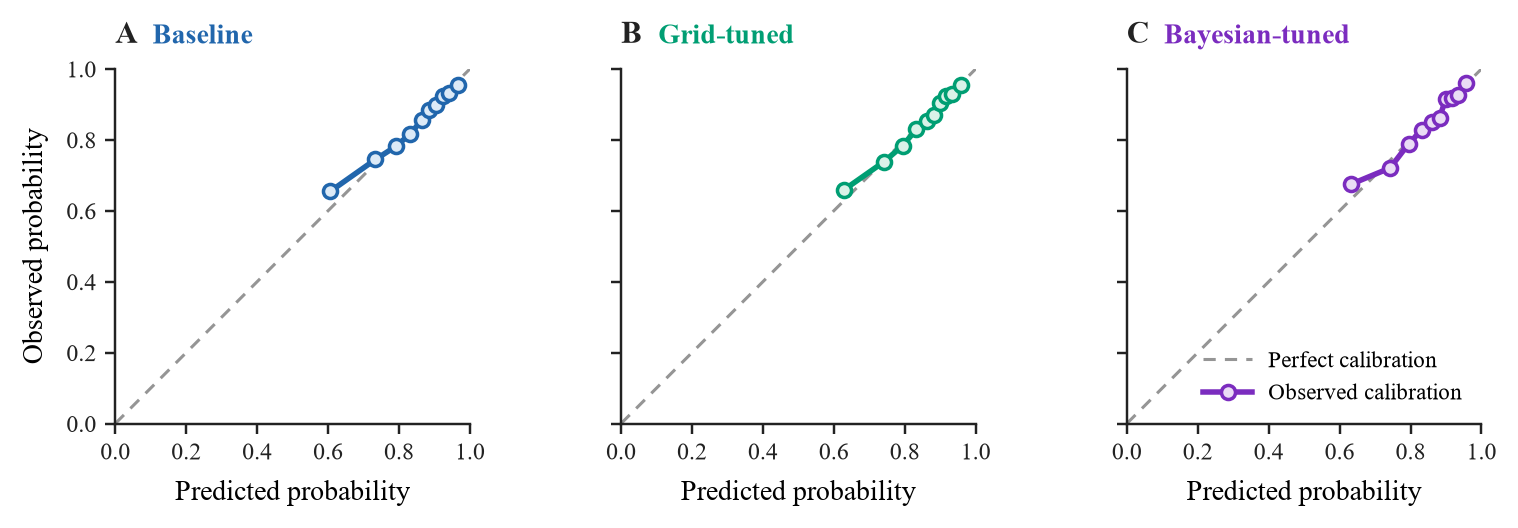

STEP 38A-R6 — COLORFUL FIGURE 1

COLOR SCHEME
------------------------------------------------------------------------------------------------------------------------------------------------------
Baseline       : Professional blue
Grid-tuned     : Emerald / teal
Bayesian-tuned : Refined purple
Perfect line   : Neutral gray

FORMAT
------------------------------------------------------------------------------------------------------------------------------------------------------
Font           : Times New Roman
Layout         : 1 × 3 horizontal
Overall title  : None
Background     : White
PDF            : Vector master
SVG            : Vector master
PNG            : Preview only

Saved:
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure1_Calibration_COLOR_VECTOR_20260905_214041.pdf
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure1_Calibration_COLOR_VECTOR_20260905_214041.svg
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure1_Calibration_COLOR_PREVIE

In [2]:
# ============================================================
# STEP 38A-R6 — COLORFUL VECTOR MASTER FIGURE 1
# BASELINE | GRID-TUNED | BAYESIAN-TUNED CALIBRATION
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

from IPython.display import display, Image as NotebookImage


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(
    r"E:\MICS_EColi_Q1_2026_Clean"
)

RUN_ID = "20260905_214041"

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "manuscript"
    / "figures"
)


DATA_FILE = (
    FIGURE_DIR
    /
    f"Figure1_calibration_data_{RUN_ID}.csv"
)


PDF_FILE = (
    FIGURE_DIR
    /
    f"Figure1_Calibration_COLOR_VECTOR_{RUN_ID}.pdf"
)


SVG_FILE = (
    FIGURE_DIR
    /
    f"Figure1_Calibration_COLOR_VECTOR_{RUN_ID}.svg"
)


PREVIEW_FILE = (
    FIGURE_DIR
    /
    f"Figure1_Calibration_COLOR_PREVIEW_{RUN_ID}.png"
)


# ============================================================
# 2. DATA QA
# ============================================================

if not DATA_FILE.exists():

    raise FileNotFoundError(
        f"Figure-data file not found:\n{DATA_FILE}"
    )


data = pd.read_csv(
    DATA_FILE
)


required_columns = [
    "Strategy",
    "MeanPredicted",
    "Observed",
]


missing_columns = [
    col
    for col in required_columns
    if col not in data.columns
]


if missing_columns:

    raise RuntimeError(
        "Missing required columns:\n"
        +
        "\n".join(
            missing_columns
        )
    )


expected_strategies = [
    "Baseline",
    "Grid-tuned",
    "Bayesian-tuned",
]


for strategy in expected_strategies:

    current = data.loc[
        data["Strategy"] == strategy
    ]

    if len(current) != 10:

        raise RuntimeError(
            f"{strategy}: expected 10 calibration bins, "
            f"found {len(current)}."
        )


# ============================================================
# 3. FONT
# ============================================================

FONT_NAME = "Times New Roman"


font_path = font_manager.findfont(
    FONT_NAME,
    fallback_to_default=False,
)


# ============================================================
# 4. PROFESSIONAL COLOR PALETTE
# ============================================================

COLORS = {

    "Baseline":
        "#2166AC",      # professional blue

    "Grid-tuned":
        "#009E73",      # deep emerald/teal

    "Bayesian-tuned":
        "#7B2CBF",      # refined purple
}


LIGHT_COLORS = {

    "Baseline":
        "#DCEAF7",

    "Grid-tuned":
        "#D9F2E8",

    "Bayesian-tuned":
        "#EADCF5",
}


PERFECT_COLOR = "#8F8F8F"

AXIS_COLOR = "#222222"


# ============================================================
# 5. PUBLICATION STYLE
# ============================================================

mpl.rcParams.update({

    "font.family":
        "serif",

    "font.serif":
        [FONT_NAME],

    "font.size":
        8.6,

    "axes.labelsize":
        9.0,

    "xtick.labelsize":
        8.0,

    "ytick.labelsize":
        8.0,

    "legend.fontsize":
        7.4,

    "axes.linewidth":
        0.8,

    "xtick.major.width":
        0.8,

    "ytick.major.width":
        0.8,

    "xtick.major.size":
        3.2,

    "ytick.major.size":
        3.2,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,

    "svg.fonttype":
        "none",

    "figure.facecolor":
        "white",

    "axes.facecolor":
        "white",
})


# ============================================================
# 6. PANEL DEFINITIONS
# ============================================================

PANELS = [

    (
        "A",
        "Baseline",
    ),

    (
        "B",
        "Grid-tuned",
    ),

    (
        "C",
        "Bayesian-tuned",
    ),
]


# ============================================================
# 7. FIGURE
# ============================================================

fig, axes = plt.subplots(

    nrows=1,

    ncols=3,

    figsize=(
        7.10,
        2.48,
    ),

    sharex=True,

    sharey=True,
)


for ax, (
    panel_label,
    strategy
) in zip(
    axes,
    PANELS,
):


    current = (
        data.loc[
            data[
                "Strategy"
            ]
            ==
            strategy
        ]
        .sort_values(
            "MeanPredicted"
        )
    )


    curve_color = (
        COLORS[
            strategy
        ]
    )


    marker_fill = (
        LIGHT_COLORS[
            strategy
        ]
    )


    # --------------------------------------------------------
    # Perfect calibration reference
    # --------------------------------------------------------

    perfect_line, = ax.plot(

        [0, 1],

        [0, 1],

        linestyle=(
            0,
            (
                4,
                3
            )
        ),

        linewidth=1.0,

        color=PERFECT_COLOR,

        alpha=0.95,

        label="Perfect calibration",

        zorder=1,
    )


    # --------------------------------------------------------
    # Observed calibration curve
    # --------------------------------------------------------

    calibration_line, = ax.plot(

        current[
            "MeanPredicted"
        ],

        current[
            "Observed"
        ],

        color=curve_color,

        linewidth=1.8,

        marker="o",

        markersize=4.6,

        markerfacecolor=marker_fill,

        markeredgecolor=curve_color,

        markeredgewidth=1.15,

        label="Observed calibration",

        zorder=3,
    )


    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------

    ax.set_xlim(
        0.0,
        1.0,
    )


    ax.set_ylim(
        0.0,
        1.0,
    )


    ax.set_xticks(
        np.arange(
            0.0,
            1.01,
            0.2,
        )
    )


    ax.set_yticks(
        np.arange(
            0.0,
            1.01,
            0.2,
        )
    )


    ax.set_xlabel(
        "Predicted probability",
        labelpad=5,
    )


    ax.set_aspect(
        "equal",
        adjustable="box",
    )


    ax.spines[
        "top"
    ].set_visible(
        False
    )


    ax.spines[
        "right"
    ].set_visible(
        False
    )


    ax.spines[
        "left"
    ].set_color(
        AXIS_COLOR
    )


    ax.spines[
        "bottom"
    ].set_color(
        AXIS_COLOR
    )


    ax.tick_params(

        axis="both",

        direction="out",

        colors=AXIS_COLOR,

        pad=3,
    )


    # --------------------------------------------------------
    # Panel letter
    # --------------------------------------------------------

    ax.text(

        0.00,

        1.055,

        panel_label,

        transform=
            ax.transAxes,

        ha="left",

        va="bottom",

        fontsize=10.0,

        fontweight="bold",

        color=AXIS_COLOR,
    )


    # --------------------------------------------------------
    # Colored panel descriptor
    # --------------------------------------------------------

    ax.text(

        0.105,

        1.055,

        strategy,

        transform=
            ax.transAxes,

        ha="left",

        va="bottom",

        fontsize=9.0,

        fontweight="bold",

        color=curve_color,
    )


# ============================================================
# 8. Y-AXIS LABEL
# ============================================================

axes[
    0
].set_ylabel(
    "Observed probability",
    labelpad=6,
)


# ============================================================
# 9. SINGLE LEGEND
# ============================================================

axes[
    2
].legend(

    handles=[
        perfect_line,
        calibration_line,
    ],

    labels=[
        "Perfect calibration",
        "Observed calibration",
    ],

    loc="lower right",

    frameon=False,

    handlelength=2.2,

    handletextpad=0.7,

    borderaxespad=0.45,
)


# ============================================================
# 10. SPACING
# ============================================================

fig.subplots_adjust(

    left=0.073,

    right=0.995,

    bottom=0.205,

    top=0.855,

    wspace=0.18,
)


# ============================================================
# 11. SAVE VECTOR MASTER
# ============================================================

fig.savefig(

    PDF_FILE,

    format="pdf",

    facecolor="white",

    bbox_inches="tight",
)


fig.savefig(

    SVG_FILE,

    format="svg",

    facecolor="white",

    bbox_inches="tight",
)


# ============================================================
# 12. LIGHTWEIGHT PREVIEW
# ============================================================

fig.savefig(

    PREVIEW_FILE,

    dpi=220,

    format="png",

    facecolor="white",

    bbox_inches="tight",
)


plt.close(
    fig
)


# ============================================================
# 13. FILE QA
# ============================================================

for path in [
    PDF_FILE,
    SVG_FILE,
    PREVIEW_FILE,
]:

    if (
        not path.exists()
        or
        path.stat().st_size <= 0
    ):

        raise RuntimeError(
            f"Invalid figure output: {path}"
        )


# ============================================================
# 14. DISPLAY PREVIEW
# ============================================================

display(
    NotebookImage(
        filename=str(
            PREVIEW_FILE
        )
    )
)


# ============================================================
# 15. FINAL OUTPUT
# ============================================================

print("=" * 150)

print(
    "STEP 38A-R6 — COLORFUL FIGURE 1"
)

print("=" * 150)


print(
    "\nCOLOR SCHEME"
)

print("-" * 150)

print(
    "Baseline       : Professional blue"
)

print(
    "Grid-tuned     : Emerald / teal"
)

print(
    "Bayesian-tuned : Refined purple"
)

print(
    "Perfect line   : Neutral gray"
)


print(
    "\nFORMAT"
)

print("-" * 150)

print(
    "Font           : Times New Roman"
)

print(
    "Layout         : 1 × 3 horizontal"
)

print(
    "Overall title  : None"
)

print(
    "Background     : White"
)

print(
    "PDF            : Vector master"
)

print(
    "SVG            : Vector master"
)

print(
    "PNG            : Preview only"
)


print(
    "\nSaved:"
)

print(
    PDF_FILE
)

print(
    SVG_FILE
)

print(
    PREVIEW_FILE
)


print(
    "\n✅ STEP 38A-R6 COMPLETED SUCCESSFULLY"
)

print("=" * 150)

In [4]:
# ============================================================
# STEP 38B-R1 — REPAIR STEP 21 PAIRED-BOOTSTRAP EXTRACTION
# ============================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd


# ============================================================
# 1. PROJECT
# ============================================================

PROJECT_ROOT = Path(
    r"E:\MICS_EColi_Q1_2026_Clean"
)

RUN_ID = "20260905_214041"


# ============================================================
# 2. HELPERS
# ============================================================

def norm(value):

    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).lower(),
    )


def numeric_series(
    df,
    column,
):

    return pd.to_numeric(
        df[column],
        errors="coerce",
    )


# ============================================================
# 3. FIND 18-CANDIDATE STEP 21 SUMMARY
# ============================================================

step21_files = sorted(
    PROJECT_ROOT.rglob(
        f"step21*{RUN_ID}*.csv"
    )
)


candidate_matches = []


for path in step21_files:

    try:

        df = pd.read_csv(
            path
        )

    except Exception:

        continue


    if len(df) != 18:

        continue


    candidate_column = None


    for column in df.columns:

        values = (
            df[column]
            .astype(str)
            .map(norm)
        )


        if (
            values.str.contains(
                norm(
                    "LogisticRegression__Grid"
                ),
                regex=False,
            ).any()
            and
            values.str.contains(
                norm(
                    "SVM__Grid"
                ),
                regex=False,
            ).any()
        ):

            candidate_column = column

            break


    if candidate_column is not None:

        candidate_matches.append(
            (
                path,
                df,
                candidate_column,
            )
        )


if len(
    candidate_matches
) != 1:

    print(
        "Possible STEP 21 files:"
    )

    for item in candidate_matches:

        print(
            item[0]
        )


    raise RuntimeError(
        f"Expected one 18-candidate STEP 21 summary; "
        f"found {len(candidate_matches)}."
    )


BOOTSTRAP_FILE, bootstrap, candidate_col = (
    candidate_matches[0]
)


bootstrap = bootstrap.copy()


bootstrap[
    "__strategy_norm"
] = (
    bootstrap[
        candidate_col
    ]
    .astype(str)
    .map(norm)
)


# ============================================================
# 4. ROW FINDER
# ============================================================

def get_row_index(
    strategy,
):

    key = norm(
        strategy
    )


    matched = bootstrap.index[
        bootstrap[
            "__strategy_norm"
        ]
        ==
        key
    ].tolist()


    if len(
        matched
    ) != 1:

        raise RuntimeError(
            f"Strategy not uniquely found: "
            f"{strategy}"
        )


    return matched[
        0
    ]


# ============================================================
# 5. NUMERIC-FINGERPRINT COLUMN RESOLVER
# ============================================================

def resolve_by_targets(
    targets,
    atol,
):

    matches = []


    for column in bootstrap.columns:

        if column in [
            candidate_col,
            "__strategy_norm",
        ]:

            continue


        values = numeric_series(
            bootstrap,
            column,
        )


        if values.isna().any():

            continue


        passed = True


        for strategy, target in targets.items():

            row_index = get_row_index(
                strategy
            )


            observed = float(
                values.loc[
                    row_index
                ]
            )


            if not np.isclose(
                observed,
                target,
                rtol=0.0,
                atol=atol,
            ):

                passed = False
                break


        if passed:

            matches.append(
                column
            )


    if len(
        matches
    ) != 1:

        raise RuntimeError(
            "Could not uniquely resolve numeric column.\n"
            f"Targets: {targets}\n"
            f"Matches: {matches}\n"
            f"Available columns: {list(bootstrap.columns)}"
        )


    return matches[
        0
    ]


# ============================================================
# 6. RESOLVE EXACT STEP 21 COLUMNS
# ============================================================

delta_col = resolve_by_targets(

    {

        "LogisticRegression__Grid":
            0.0,

        "ElasticNetLogistic__Grid":
            0.000134589,

        "SVM__Grid":
            0.006893168,
    },

    atol=5e-9,
)


lower_col = resolve_by_targets(

    {

        "ElasticNetLogistic__Grid":
            -0.000137085,

        "GradientBoosting__Bayesian":
            0.000113218,

        "SVM__Grid":
            0.004335334,
    },

    atol=5e-9,
)


upper_col = resolve_by_targets(

    {

        "ElasticNetLogistic__Grid":
            0.000384612,

        "GradientBoosting__Bayesian":
            0.001961214,

        "SVM__Grid":
            0.009554773,
    },

    atol=5e-9,
)


best_col = resolve_by_targets(

    {

        "LogisticRegression__Grid":
            0.3500,

        "ExtraTrees__Grid":
            0.1635,

        "LightGBM__Bayesian":
            0.1330,
    },

    atol=5e-6,
)


# ============================================================
# 7. CLEAN NUMERIC VALUES
# ============================================================

for column in [
    delta_col,
    lower_col,
    upper_col,
    best_col,
]:

    bootstrap[
        column
    ] = pd.to_numeric(
        bootstrap[
            column
        ],
        errors="raise",
    )


# ============================================================
# 8. EVIDENCE CLASSIFICATION
# ============================================================

REFERENCE_STRATEGY = (
    "LogisticRegression__Grid"
)


reference_key = norm(
    REFERENCE_STRATEGY
)


bootstrap[
    "EvidenceClass"
] = np.where(

    bootstrap[
        "__strategy_norm"
    ]
    ==
    reference_key,

    "Selected reference",

    np.where(

        bootstrap[
            lower_col
        ]
        >
        0,

        "Clearly worse",

        "Bootstrap-compatible",
    ),
)


reference_n = int(
    (
        bootstrap[
            "EvidenceClass"
        ]
        ==
        "Selected reference"
    ).sum()
)


compatible_n = int(
    (
        bootstrap[
            "EvidenceClass"
        ]
        ==
        "Bootstrap-compatible"
    ).sum()
)


worse_n = int(
    (
        bootstrap[
            "EvidenceClass"
        ]
        ==
        "Clearly worse"
    ).sum()
)


# ============================================================
# 9. HARD QA
# ============================================================

if reference_n != 1:

    raise RuntimeError(
        "Expected one selected reference."
    )


if compatible_n != 12:

    raise RuntimeError(
        f"Expected 12 non-reference compatible candidates; "
        f"found {compatible_n}."
    )


if worse_n != 5:

    raise RuntimeError(
        f"Expected 5 clearly worse candidates; "
        f"found {worse_n}."
    )


# Exact five clearly worse candidates
expected_worse = {

    norm(
        "GradientBoosting__Bayesian"
    ),

    norm(
        "AdaBoost__Bayesian"
    ),

    norm(
        "AdaBoost__Grid"
    ),

    norm(
        "SVM__Bayesian"
    ),

    norm(
        "SVM__Grid"
    ),
}


observed_worse = set(

    bootstrap.loc[

        bootstrap[
            "EvidenceClass"
        ]
        ==
        "Clearly worse",

        "__strategy_norm",

    ]
)


if observed_worse != expected_worse:

    raise RuntimeError(
        "Clearly-worse candidate set mismatch."
    )


# ============================================================
# 10. FIGURE-READY DATA
# ============================================================

plot_data = (
    bootstrap
    .sort_values(
        delta_col,
        ascending=True,
    )
    .reset_index(
        drop=True
    )
    .copy()
)


# ============================================================
# 11. PRINT QA
# ============================================================

print("=" * 155)

print(
    "STEP 38B-R1 — STEP 21 PAIRED-BOOTSTRAP REPAIR"
)

print("=" * 155)


print(
    "\nSource:"
)

print(
    BOOTSTRAP_FILE
)


print(
    "\nResolved columns"
)

print("-" * 155)

print(
    f"Strategy           : {candidate_col}"
)

print(
    f"ΔBrier             : {delta_col}"
)

print(
    f"95% CI lower       : {lower_col}"
)

print(
    f"95% CI upper       : {upper_col}"
)

print(
    f"Best frequency     : {best_col}"
)


print(
    "\nEvidence counts"
)

print("-" * 155)

print(
    f"Selected reference : {reference_n}"
)

print(
    f"Compatible         : {compatible_n}"
)

print(
    f"Clearly worse      : {worse_n}"
)

print(
    f"Total              : "
    f"{reference_n + compatible_n + worse_n}"
)


print(
    "\nClearly worse:"
)

print(
    bootstrap.loc[
        bootstrap[
            "EvidenceClass"
        ]
        ==
        "Clearly worse",
        candidate_col,
    ].to_string(
        index=False
    )
)


print(
    "\nTop bootstrap-best frequencies:"
)

print(
    bootstrap[
        [
            candidate_col,
            best_col,
        ]
    ]
    .sort_values(
        best_col,
        ascending=False,
    )
    .head(8)
    .to_string(
        index=False
    )
)


print(
    "\n✅ STEP 38B-R1 REPAIR COMPLETED SUCCESSFULLY"
)

print("=" * 155)

STEP 38B-R1 — STEP 21 PAIRED-BOOTSTRAP REPAIR

Source:
E:\MICS_EColi_Q1_2026_Clean\outputs\model_comparison\paired_psu_bootstrap\step21_candidate_bootstrap_summary_20260905_214041.csv

Resolved columns
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Strategy           : CandidateID
ΔBrier             : DeltaBrier_vs_Reference
95% CI lower       : DeltaCI_Lower
95% CI upper       : DeltaCI_Upper
Best frequency     : BootstrapBestFrequency

Evidence counts
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Selected reference : 1
Compatible         : 12
Clearly worse      : 5
Total              : 18

Clearly worse:
GradientBoosting__Bayesian
        AdaBoost__Bayesian
            AdaBoost__Grid
             SVM__Bayesian
                 SVM__Grid

Top bootstrap-best frequencies:

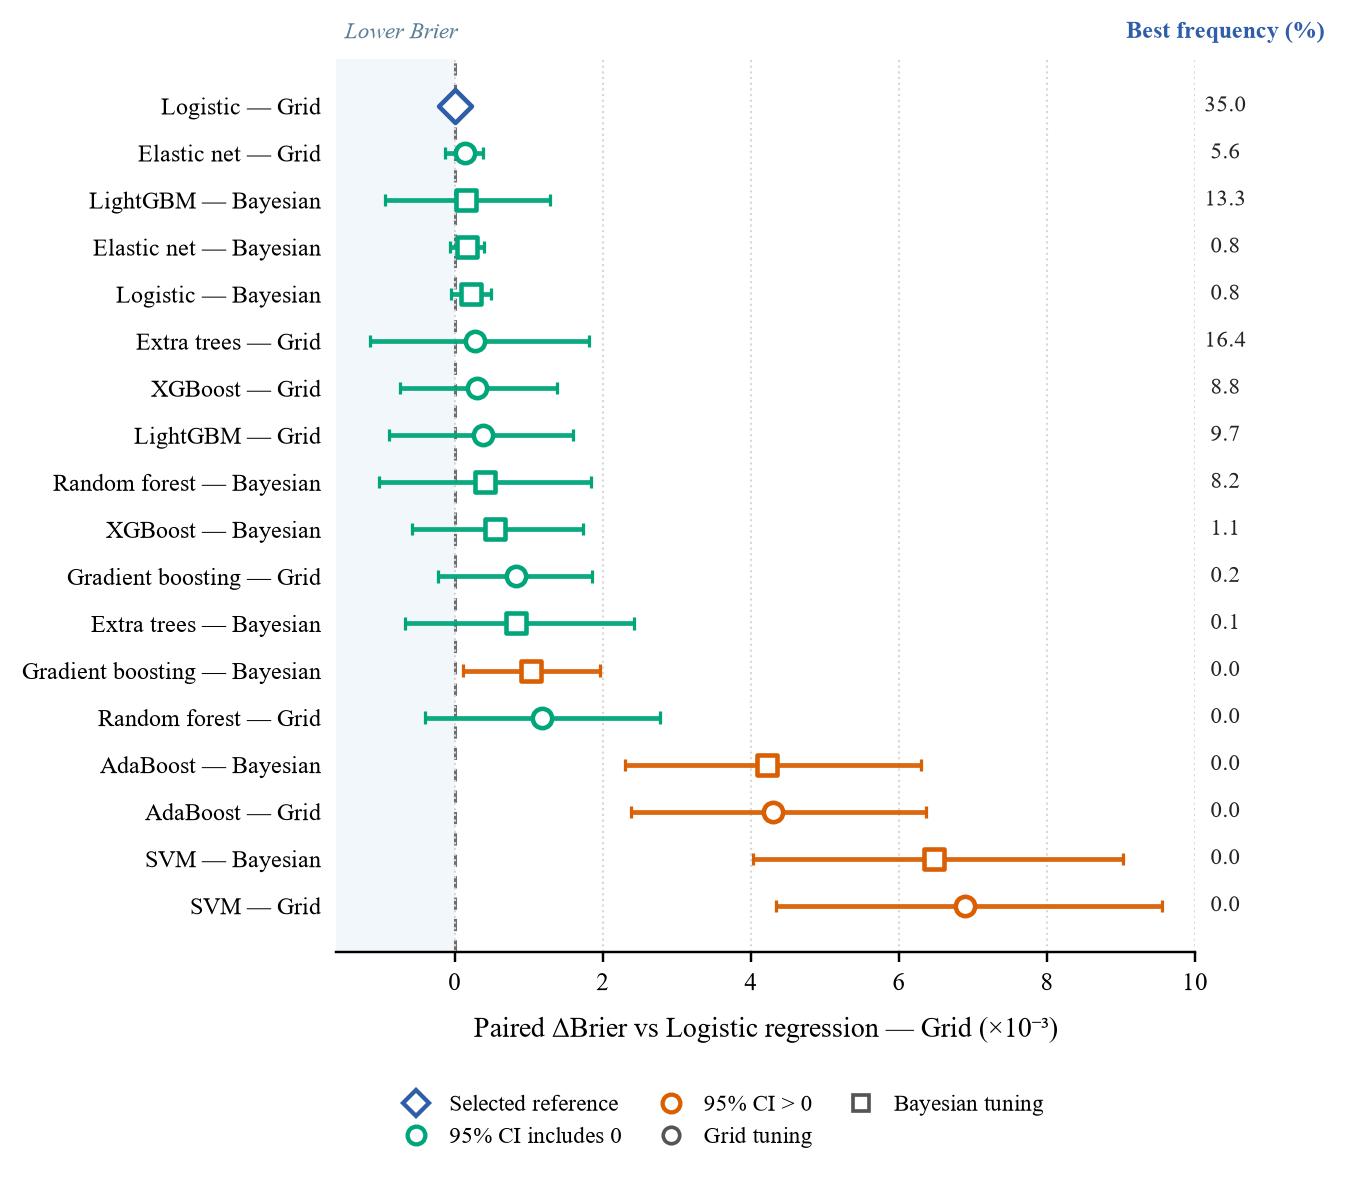

STEP 38B-R4 — FINAL POLISHED FIGURE 2

Design:
Position      : paired ΔBrier
Horizontal CI : paired 95% bootstrap CI
Color         : evidence class
Shape         : Grid vs Bayesian tuning
Right column  : bootstrap-best frequency (%)
Marker size   : fixed
Candidates    : all 18
Font          : Times New Roman
Overall title : None
PDF / SVG     : vector masters
PNG           : 220-DPI preview

Saved:
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure2_ModelSelection_FINAL_COLOR_VECTOR_20260905_214041.pdf
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure2_ModelSelection_FINAL_COLOR_VECTOR_20260905_214041.svg
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure2_ModelSelection_FINAL_COLOR_PREVIEW_20260905_214041.png
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure2_ModelSelection_FINAL_DATA_20260905_214041.csv

✅ STEP 38B-R4 COMPLETED SUCCESSFULLY


In [7]:
# ============================================================
# STEP 38B-R4 — FINAL POLISHED FIGURE 2
# INTEGRATED MODEL-SELECTION UNCERTAINTY
#
# Position      = paired Delta Brier
# Horizontal CI = paired 95% bootstrap CI
# Color         = evidence class
# Marker shape  = Grid vs Bayesian
# Right column  = bootstrap-best frequency
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory

from IPython.display import display, Image as NotebookImage


# ============================================================
# 1. REQUIRED VALIDATED STATE
# ============================================================

required_objects = [
    "plot_data",
    "candidate_col",
    "delta_col",
    "lower_col",
    "upper_col",
    "best_col",
    "PROJECT_ROOT",
    "RUN_ID",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run STEP 38B-R1 first. Missing:\n"
        + "\n".join(missing_objects)
    )


if len(plot_data) != 18:
    raise RuntimeError(
        "Expected 18 candidate strategies."
    )


# ============================================================
# 2. DISPLAY LABELS
# ============================================================

MODEL_LABELS = {

    "LogisticRegression":
        "Logistic",

    "ElasticNetLogistic":
        "Elastic net",

    "RandomForest":
        "Random forest",

    "ExtraTrees":
        "Extra trees",

    "GradientBoosting":
        "Gradient boosting",

    "AdaBoost":
        "AdaBoost",

    "SVM":
        "SVM",

    "XGBoost":
        "XGBoost",

    "LightGBM":
        "LightGBM",
}


def pretty_strategy(value):

    value = str(value)

    if "__" not in value:
        return value

    model, tuning = value.split(
        "__",
        1,
    )

    model_label = MODEL_LABELS.get(
        model,
        model,
    )

    if "Bayes" in tuning:
        tuning_label = "Bayesian"

    elif "Grid" in tuning:
        tuning_label = "Grid"

    else:
        tuning_label = tuning

    return (
        f"{model_label} — {tuning_label}"
    )


FIG_DATA = plot_data.copy()


FIG_DATA["Display"] = (
    FIG_DATA[candidate_col]
    .map(pretty_strategy)
)


FIG_DATA["TuningType"] = np.where(
    FIG_DATA[candidate_col]
    .astype(str)
    .str.contains(
        "Bayesian",
        regex=False,
    ),
    "Bayesian",
    "Grid",
)


# ============================================================
# 3. PLOTTING SCALE
# ============================================================

FIG_DATA["Delta_x1000"] = (
    FIG_DATA[delta_col]
    *
    1000
)

FIG_DATA["Lower_x1000"] = (
    FIG_DATA[lower_col]
    *
    1000
)

FIG_DATA["Upper_x1000"] = (
    FIG_DATA[upper_col]
    *
    1000
)


best_frequency = FIG_DATA[
    best_col
].to_numpy(
    dtype=float
)


if np.nanmax(best_frequency) <= 1.0:

    FIG_DATA["BestPercent"] = (
        best_frequency
        *
        100
    )

else:

    FIG_DATA["BestPercent"] = (
        best_frequency
    )


FIG_DATA = (
    FIG_DATA
    .sort_values(
        delta_col,
        ascending=True,
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 4. HARD QA
# ============================================================

reference = FIG_DATA.loc[
    FIG_DATA[candidate_col]
    ==
    "LogisticRegression__Grid"
]


if len(reference) != 1:
    raise RuntimeError(
        "Reference strategy not uniquely identified."
    )


reference = reference.iloc[0]


if not np.isclose(
    float(reference["Delta_x1000"]),
    0.0,
    atol=1e-12,
):
    raise RuntimeError(
        "Reference Delta Brier mismatch."
    )


if not np.isclose(
    float(reference["BestPercent"]),
    35.0,
    atol=0.01,
):
    raise RuntimeError(
        "Reference best-frequency mismatch."
    )


if (
    FIG_DATA["EvidenceClass"]
    ==
    "Clearly worse"
).sum() != 5:
    raise RuntimeError(
        "Clearly-worse count mismatch."
    )


# ============================================================
# 5. COLORS
# ============================================================

COLOR_REFERENCE = "#2F5DA8"
COLOR_COMPATIBLE = "#00A67A"
COLOR_WORSE = "#D95F02"

COLOR_ZERO = "#6D6D6D"
COLOR_GRID = "#D8D8D8"
COLOR_BETTER = "#EEF5FA"
COLOR_TEXT = "#252525"


CLASS_COLORS = {

    "Selected reference":
        COLOR_REFERENCE,

    "Bootstrap-compatible":
        COLOR_COMPATIBLE,

    "Clearly worse":
        COLOR_WORSE,
}


MARKERS = {

    "Grid":
        "o",

    "Bayesian":
        "s",
}


# ============================================================
# 6. FONT / STYLE
# ============================================================

FONT_NAME = "Times New Roman"


font_path = font_manager.findfont(
    FONT_NAME,
    fallback_to_default=False,
)


mpl.rcParams.update({

    "font.family":
        "serif",

    "font.serif":
        [FONT_NAME],

    "font.size":
        8.5,

    "axes.labelsize":
        9.2,

    "xtick.labelsize":
        8.1,

    "ytick.labelsize":
        8.0,

    "legend.fontsize":
        7.4,

    "axes.linewidth":
        0.8,

    "xtick.major.width":
        0.8,

    "ytick.major.width":
        0.8,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,

    "svg.fonttype":
        "none",

    "figure.facecolor":
        "white",

    "axes.facecolor":
        "white",
})


# ============================================================
# 7. FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        7.10,
        5.45,
    )
)


y_position = np.arange(
    len(FIG_DATA)
)


# ============================================================
# 8. X RANGE
# ============================================================

x_min = min(
    -1.6,
    float(
        FIG_DATA[
            "Lower_x1000"
        ].min()
    )
    -
    0.3,
)


x_max = (
    float(
        FIG_DATA[
            "Upper_x1000"
        ].max()
    )
    +
    0.45
)


# ============================================================
# 9. BETTER-THAN-REFERENCE REGION
# ============================================================

ax.axvspan(
    x_min,
    0,
    facecolor=COLOR_BETTER,
    alpha=0.75,
    zorder=0,
)


# ============================================================
# 10. REFERENCE LINE
# ============================================================

ax.axvline(
    0,
    color=COLOR_ZERO,
    linewidth=1.0,
    linestyle=(
        0,
        (
            4,
            3
        )
    ),
    zorder=1,
)


# ============================================================
# 11. FOREST PLOT
# ============================================================

for i, row in FIG_DATA.iterrows():

    evidence = row[
        "EvidenceClass"
    ]

    tuning_type = row[
        "TuningType"
    ]

    color = CLASS_COLORS[
        evidence
    ]

    marker = MARKERS[
        tuning_type
    ]


    estimate = float(
        row[
            "Delta_x1000"
        ]
    )

    lower = float(
        row[
            "Lower_x1000"
        ]
    )

    upper = float(
        row[
            "Upper_x1000"
        ]
    )


    # CI
    ax.hlines(
        y=i,
        xmin=lower,
        xmax=upper,
        color=color,
        linewidth=1.55,
        alpha=0.95,
        zorder=2,
    )


    # CI end caps
    ax.vlines(
        [
            lower,
            upper,
        ],
        ymin=i - 0.13,
        ymax=i + 0.13,
        color=color,
        linewidth=1.05,
        zorder=2,
    )


    # Reference uses diamond
    if evidence == "Selected reference":

        marker = "D"

        marker_size = 58

    else:

        marker_size = 40


    ax.scatter(
        estimate,
        i,
        s=marker_size,
        marker=marker,
        facecolor="white",
        edgecolor=color,
        linewidth=1.5,
        zorder=3,
    )


# ============================================================
# 12. AXES
# ============================================================

ax.set_xlim(
    x_min,
    x_max,
)


ax.set_yticks(
    y_position
)


ax.set_yticklabels(
    FIG_DATA[
        "Display"
    ]
)


ax.invert_yaxis()


ax.set_xlabel(
    "Paired ΔBrier vs Logistic regression — Grid (×10⁻³)",
    labelpad=7,
)


ax.grid(
    axis="x",
    linestyle=":",
    linewidth=0.7,
    color=COLOR_GRID,
    zorder=0,
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

ax.spines[
    "left"
].set_visible(
    False
)


ax.tick_params(
    axis="y",
    length=0,
    pad=5,
)


ax.tick_params(
    axis="x",
    direction="out",
)


# ============================================================
# 13. RIGHT-SIDE BEST-FREQUENCY COLUMN
# ============================================================

text_transform = blended_transform_factory(
    ax.transAxes,
    ax.transData,
)


for i, row in FIG_DATA.iterrows():

    value = float(
        row[
            "BestPercent"
        ]
    )


    if value < 0.05:

        display_value = "0.0"

    else:

        display_value = (
            f"{value:.1f}"
        )


    ax.text(
        1.035,
        i,
        display_value,
        transform=text_transform,
        ha="center",
        va="center",
        fontsize=7.5,
        color=COLOR_TEXT,
        clip_on=False,
    )


# Header for numeric column
ax.text(
    1.035,
    1.018,
    "Best frequency (%)",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=8.0,
    fontweight="bold",
    color=COLOR_REFERENCE,
    clip_on=False,
)


# ============================================================
# 14. SUBTLE DIRECTION CUE
# ============================================================

ax.text(
    0.01,
    1.018,
    "Lower Brier",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=7.4,
    color="#597D96",
    fontstyle="italic",
)


# ============================================================
# 15. LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=COLOR_REFERENCE,
        markeredgewidth=1.4,
        markersize=5.8,
        label="Selected reference",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=COLOR_COMPATIBLE,
        markeredgewidth=1.4,
        markersize=5.8,
        label="95% CI includes 0",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=COLOR_WORSE,
        markeredgewidth=1.4,
        markersize=5.8,
        label="95% CI > 0",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="#555555",
        markeredgewidth=1.2,
        markersize=5.4,
        label="Grid tuning",
    ),

    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="#555555",
        markeredgewidth=1.2,
        markersize=5.4,
        label="Bayesian tuning",
    ),
]


fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(
        0.56,
        0.025,
    ),
    ncol=3,
    frameon=False,
    handletextpad=0.45,
    columnspacing=1.15,
)


# ============================================================
# 16. LAYOUT
# ============================================================

fig.subplots_adjust(
    left=0.315,
    right=0.865,
    bottom=0.205,
    top=0.95,
)


# ============================================================
# 17. OUTPUT PATHS
# ============================================================

FIGURE_DIR = (
    Path(PROJECT_ROOT)
    / "outputs"
    / "manuscript"
    / "figures"
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PDF_FILE = (
    FIGURE_DIR
    /
    f"Figure2_ModelSelection_FINAL_COLOR_VECTOR_{RUN_ID}.pdf"
)


SVG_FILE = (
    FIGURE_DIR
    /
    f"Figure2_ModelSelection_FINAL_COLOR_VECTOR_{RUN_ID}.svg"
)


PREVIEW_FILE = (
    FIGURE_DIR
    /
    f"Figure2_ModelSelection_FINAL_COLOR_PREVIEW_{RUN_ID}.png"
)


DATA_FILE = (
    FIGURE_DIR
    /
    f"Figure2_ModelSelection_FINAL_DATA_{RUN_ID}.csv"
)


# ============================================================
# 18. SAVE
# ============================================================

fig.savefig(
    PDF_FILE,
    format="pdf",
    facecolor="white",
    bbox_inches="tight",
)


fig.savefig(
    SVG_FILE,
    format="svg",
    facecolor="white",
    bbox_inches="tight",
)


fig.savefig(
    PREVIEW_FILE,
    dpi=220,
    format="png",
    facecolor="white",
    bbox_inches="tight",
)


FIG_DATA.to_csv(
    DATA_FILE,
    index=False,
)


plt.close(
    fig
)


# ============================================================
# 19. FILE QA
# ============================================================

for path in [
    PDF_FILE,
    SVG_FILE,
    PREVIEW_FILE,
    DATA_FILE,
]:

    if (
        not path.exists()
        or
        path.stat().st_size <= 0
    ):

        raise RuntimeError(
            f"Invalid output: {path}"
        )


# ============================================================
# 20. PREVIEW
# ============================================================

display(
    NotebookImage(
        filename=str(
            PREVIEW_FILE
        )
    )
)


# ============================================================
# 21. FINAL PRINT
# ============================================================

print("=" * 155)

print(
    "STEP 38B-R4 — FINAL POLISHED FIGURE 2"
)

print("=" * 155)


print(
    "\nDesign:"
)

print(
    "Position      : paired ΔBrier"
)

print(
    "Horizontal CI : paired 95% bootstrap CI"
)

print(
    "Color         : evidence class"
)

print(
    "Shape         : Grid vs Bayesian tuning"
)

print(
    "Right column  : bootstrap-best frequency (%)"
)

print(
    "Marker size   : fixed"
)

print(
    "Candidates    : all 18"
)

print(
    "Font          : Times New Roman"
)

print(
    "Overall title : None"
)

print(
    "PDF / SVG     : vector masters"
)

print(
    "PNG           : 220-DPI preview"
)


print(
    "\nSaved:"
)

print(PDF_FILE)
print(SVG_FILE)
print(PREVIEW_FILE)
print(DATA_FILE)


print(
    "\n✅ STEP 38B-R4 COMPLETED SUCCESSFULLY"
)

print("=" * 155)

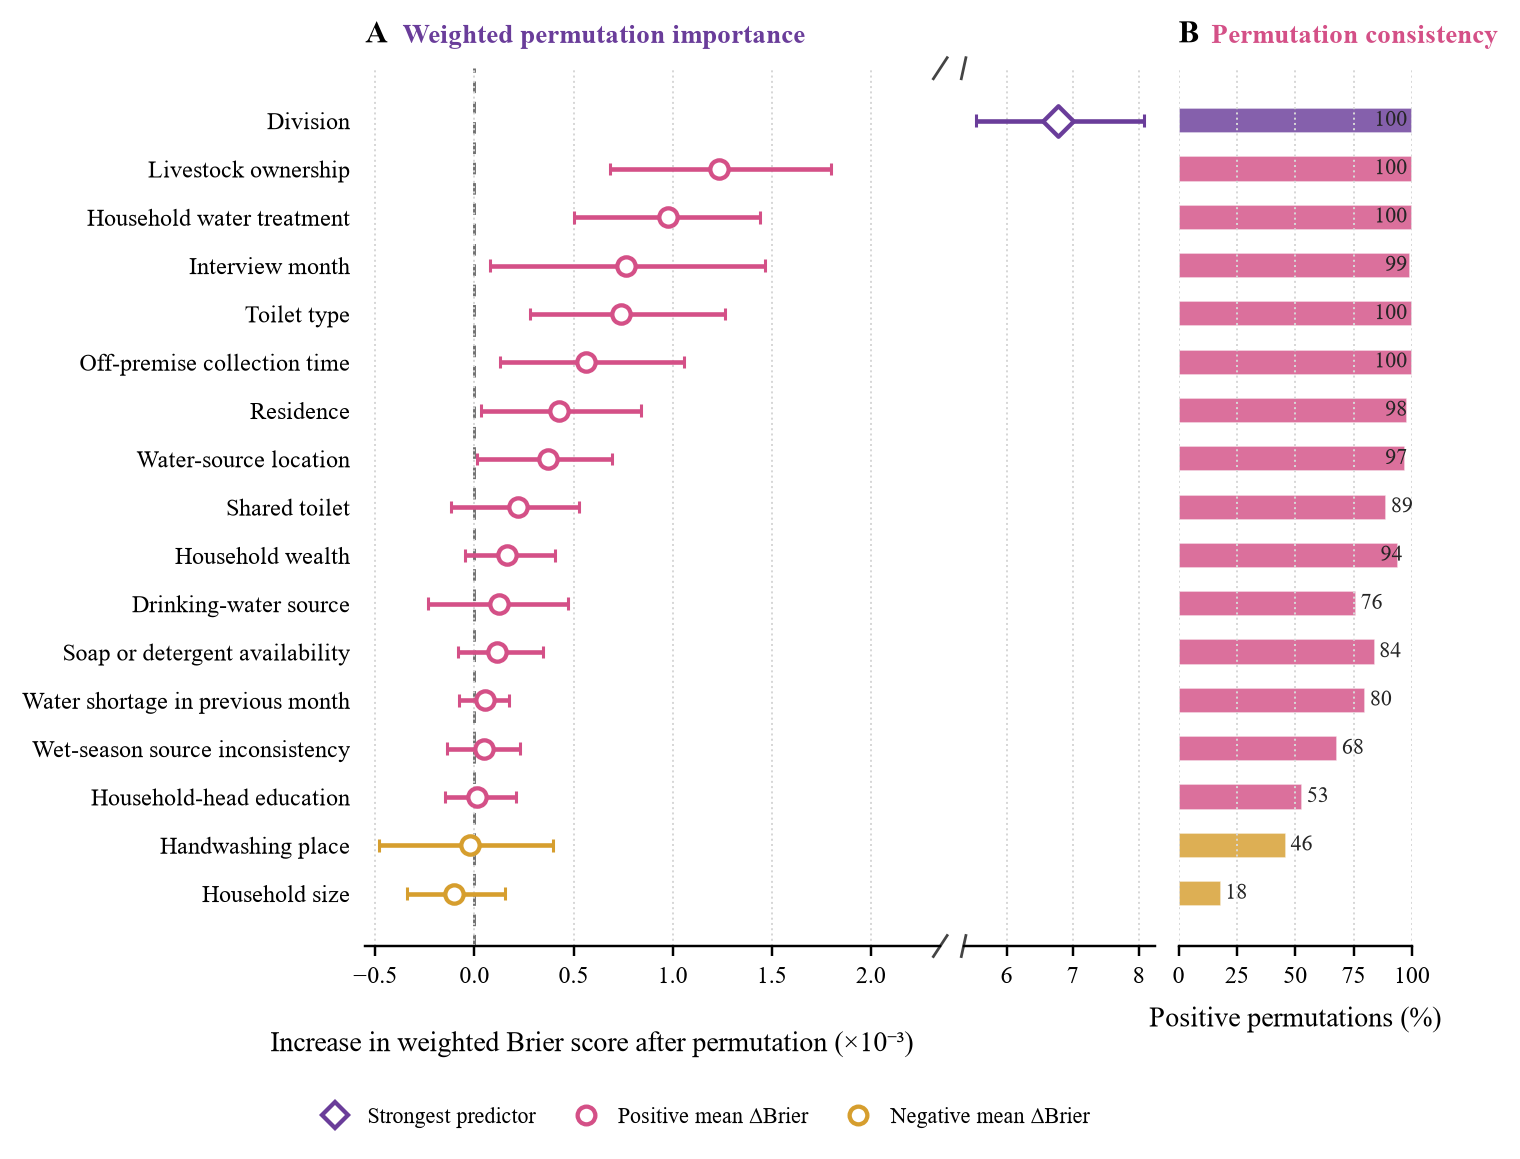

STEP 38C-R2 — REDESIGNED FIGURE 3

Predictors           : All 17
Panel A              : Weighted permutation importance
Axis                 : Broken to preserve readability
Whiskers             : 2.5th–97.5th permutation percentiles
Panel B              : Positive permutation frequency
Strongest color      : Deep violet
Positive mean color  : Rose
Negative mean color  : Amber
Font                 : Times New Roman
Overall title        : None
PDF / SVG            : Vector masters
PNG                  : 220-DPI preview

Saved:
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure3_PermutationImportance_REDESIGNED_VECTOR_20260905_214041.pdf
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure3_PermutationImportance_REDESIGNED_VECTOR_20260905_214041.svg
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure3_PermutationImportance_REDESIGNED_PREVIEW_20260905_214041.png
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure3_PermutationImportance_REDESIGNED_DA

In [9]:
# ============================================================
# STEP 38C-R2 — REDESIGNED FINAL FIGURE 3
# WEIGHTED PERMUTATION IMPORTANCE
#
# A: Mean Delta Brier + 2.5th–97.5th permutation range
#    with a broken x-axis so all 17 predictors remain readable.
#
# B: Positive Delta Brier frequency (%)
#
# New palette:
#   Strongest predictor = deep violet
#   Positive mean       = rose
#   Negative mean       = amber
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from matplotlib.lines import Line2D

from IPython.display import display, Image as NotebookImage


# ============================================================
# 1. PROJECT
# ============================================================

PROJECT_ROOT = Path(
    r"E:\MICS_EColi_Q1_2026_Clean"
)

RUN_ID = "20260905_214041"


FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "manuscript"
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


IMPORTANCE_FILE = (
    PROJECT_ROOT
    / "outputs"
    / "final_model"
    / "interpretability"
    / f"step35_weighted_permutation_importance_{RUN_ID}.csv"
)


# ============================================================
# 2. LOAD DATA
# ============================================================

if not IMPORTANCE_FILE.exists():

    raise FileNotFoundError(
        str(IMPORTANCE_FILE)
    )


importance = pd.read_csv(
    IMPORTANCE_FILE
)


required_columns = [
    "Feature",
    "MeanDeltaBrier",
    "P025DeltaBrier",
    "P975DeltaBrier",
    "PositiveDeltaBrierFrequency",
]


missing_columns = [
    column
    for column in required_columns
    if column not in importance.columns
]


if missing_columns:

    raise RuntimeError(
        "Missing columns:\n"
        +
        "\n".join(
            missing_columns
        )
    )


if len(importance) != 17:

    raise RuntimeError(
        f"Expected 17 predictors; found {len(importance)}."
    )


for column in [
    "MeanDeltaBrier",
    "P025DeltaBrier",
    "P975DeltaBrier",
    "PositiveDeltaBrierFrequency",
]:

    importance[column] = pd.to_numeric(
        importance[column],
        errors="raise",
    )


# ============================================================
# 3. HARD RESULT QA
# ============================================================

division_value = float(
    importance.loc[
        importance["Feature"] == "division",
        "MeanDeltaBrier",
    ].iloc[0]
)


if not np.isclose(
    division_value,
    0.006776282,
    atol=5e-9,
    rtol=0.0,
):

    raise RuntimeError(
        "Division permutation importance mismatch."
    )


# ============================================================
# 4. LABELS
# ============================================================

FEATURE_LABELS = {

    "division":
        "Division",

    "livestock":
        "Livestock ownership",

    "water_treated":
        "Household water treatment",

    "interview_month":
        "Interview month",

    "toilet_type3":
        "Toilet type",

    "offpremise_collection_min":
        "Off-premise collection time",

    "residence":
        "Residence",

    "source_location4":
        "Water-source location",

    "toilet_shared":
        "Shared toilet",

    "wealth3":
        "Household wealth",

    "water_source3":
        "Drinking-water source",

    "soap_or_detergent":
        "Soap or detergent availability",

    "water_shortage_1m":
        "Water shortage in previous month",

    "wetseason_inconsistent":
        "Wet-season source inconsistency",

    "head_education3":
        "Household-head education",

    "handwash_place5":
        "Handwashing place",

    "hh_size3":
        "Household size",
}


importance["Display"] = (
    importance["Feature"]
    .map(FEATURE_LABELS)
)


if importance["Display"].isna().any():

    raise RuntimeError(
        "Missing feature display label."
    )


# ============================================================
# 5. SORT
# ============================================================

FIG_DATA = (
    importance
    .sort_values(
        "MeanDeltaBrier",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
    .copy()
)


# ============================================================
# 6. SCALE
# ============================================================

FIG_DATA["Mean_x1000"] = (
    FIG_DATA["MeanDeltaBrier"]
    *
    1000
)

FIG_DATA["Lower_x1000"] = (
    FIG_DATA["P025DeltaBrier"]
    *
    1000
)

FIG_DATA["Upper_x1000"] = (
    FIG_DATA["P975DeltaBrier"]
    *
    1000
)


frequency = FIG_DATA[
    "PositiveDeltaBrierFrequency"
].to_numpy(
    dtype=float
)


if frequency.max() <= 1.0:

    FIG_DATA["PositivePercent"] = (
        frequency
        *
        100
    )

else:

    FIG_DATA["PositivePercent"] = (
        frequency
    )


# ============================================================
# 7. VISUAL CLASS
# ============================================================

FIG_DATA["VisualClass"] = np.where(

    FIG_DATA["Feature"] == "division",

    "Strongest predictor",

    np.where(

        FIG_DATA["MeanDeltaBrier"] < 0,

        "Negative mean",

        "Positive mean",
    ),
)


# ============================================================
# 8. NEW FIGURE-SPECIFIC PALETTE
# ============================================================

COLOR_STRONG = "#6A3D9A"    # deep violet
COLOR_POSITIVE = "#D45087"  # rose
COLOR_NEGATIVE = "#D69E2E"  # amber

COLOR_REFERENCE = "#707070"
COLOR_GRID = "#D7D7D7"
COLOR_TEXT = "#252525"


CLASS_COLORS = {

    "Strongest predictor":
        COLOR_STRONG,

    "Positive mean":
        COLOR_POSITIVE,

    "Negative mean":
        COLOR_NEGATIVE,
}


# ============================================================
# 9. FONT
# ============================================================

FONT_NAME = "Times New Roman"


font_path = font_manager.findfont(
    FONT_NAME,
    fallback_to_default=False,
)


mpl.rcParams.update({

    "font.family":
        "serif",

    "font.serif":
        [FONT_NAME],

    "font.size":
        8.4,

    "axes.labelsize":
        9.0,

    "xtick.labelsize":
        7.8,

    "ytick.labelsize":
        7.9,

    "legend.fontsize":
        7.3,

    "axes.linewidth":
        0.8,

    "xtick.major.width":
        0.8,

    "ytick.major.width":
        0.8,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,

    "svg.fonttype":
        "none",

    "figure.facecolor":
        "white",

    "axes.facecolor":
        "white",
})


# ============================================================
# 10. FIGURE LAYOUT
#
# First two axes create a broken x-axis for panel A.
# Third axis contains positive permutation frequency.
# ============================================================

fig = plt.figure(
    figsize=(
        7.10,
        5.25,
    )
)


gs = fig.add_gridspec(

    nrows=1,

    ncols=3,

    width_ratios=[
        3.45,
        1.15,
        1.40,
    ],

    wspace=0.07,
)


ax_left = fig.add_subplot(
    gs[0, 0]
)

ax_right = fig.add_subplot(
    gs[0, 1],
    sharey=ax_left,
)

ax_freq = fig.add_subplot(
    gs[0, 2],
    sharey=ax_left,
)


y = np.arange(
    len(FIG_DATA)
)


# ============================================================
# 11. BROKEN AXIS RANGES
# ============================================================

LEFT_MIN = -0.55
LEFT_MAX = 2.35

RIGHT_MIN = 5.35
RIGHT_MAX = 8.25


# ============================================================
# 12. DRAW FOREST DATA ON BOTH AXES
# ============================================================

def draw_forest(
    ax
):

    ax.axvline(
        0,
        color=COLOR_REFERENCE,
        linewidth=0.95,
        linestyle=(
            0,
            (
                4,
                3
            )
        ),
        zorder=1,
    )


    for i, row in FIG_DATA.iterrows():

        color = CLASS_COLORS[
            row["VisualClass"]
        ]


        lower = float(
            row["Lower_x1000"]
        )

        upper = float(
            row["Upper_x1000"]
        )

        mean = float(
            row["Mean_x1000"]
        )


        ax.hlines(
            y=i,
            xmin=lower,
            xmax=upper,
            linewidth=1.50,
            color=color,
            zorder=2,
        )


        ax.vlines(
            [
                lower,
                upper,
            ],
            ymin=i - 0.13,
            ymax=i + 0.13,
            linewidth=1.0,
            color=color,
            zorder=2,
        )


        marker = (
            "D"
            if row["Feature"] == "division"
            else "o"
        )


        size = (
            50
            if marker == "D"
            else 36
        )


        ax.scatter(
            mean,
            i,
            s=size,
            marker=marker,
            facecolor="white",
            edgecolor=color,
            linewidth=1.4,
            zorder=3,
        )


draw_forest(
    ax_left
)

draw_forest(
    ax_right
)


# ============================================================
# 13. LEFT SEGMENT
# ============================================================

ax_left.set_xlim(
    LEFT_MIN,
    LEFT_MAX
)


ax_left.set_xticks(
    [
        -0.5,
        0,
        0.5,
        1.0,
        1.5,
        2.0,
    ]
)


ax_left.set_yticks(
    y
)


ax_left.set_yticklabels(
    FIG_DATA["Display"]
)


ax_left.invert_yaxis()


ax_left.grid(
    axis="x",
    linestyle=":",
    linewidth=0.65,
    color=COLOR_GRID,
)


ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)
ax_left.spines["left"].set_visible(False)


ax_left.tick_params(
    axis="y",
    length=0,
    pad=5,
)


ax_left.tick_params(
    axis="x",
    direction="out",
)


# ============================================================
# 14. RIGHT SEGMENT
# ============================================================

ax_right.set_xlim(
    RIGHT_MIN,
    RIGHT_MAX
)


ax_right.set_xticks(
    [
        6,
        7,
        8,
    ]
)


ax_right.grid(
    axis="x",
    linestyle=":",
    linewidth=0.65,
    color=COLOR_GRID,
)


ax_right.spines["top"].set_visible(False)
ax_right.spines["left"].set_visible(False)
ax_right.spines["right"].set_visible(False)


ax_right.tick_params(
    axis="y",
    left=False,
    labelleft=False,
)


ax_right.tick_params(
    axis="x",
    direction="out",
)


# ============================================================
# 15. BROKEN-AXIS MARKS
# ============================================================

break_size = 0.012


kwargs_left = dict(
    transform=ax_left.transAxes,
    color="#444444",
    clip_on=False,
    linewidth=0.9,
)


ax_left.plot(
    (
        1 - break_size,
        1 + break_size,
    ),
    (
        -break_size,
        +break_size,
    ),
    **kwargs_left,
)


ax_left.plot(
    (
        1 - break_size,
        1 + break_size,
    ),
    (
        1 - break_size,
        1 + break_size,
    ),
    **kwargs_left,
)


kwargs_right = dict(
    transform=ax_right.transAxes,
    color="#444444",
    clip_on=False,
    linewidth=0.9,
)


ax_right.plot(
    (
        -break_size,
        +break_size,
    ),
    (
        -break_size,
        +break_size,
    ),
    **kwargs_right,
)


ax_right.plot(
    (
        -break_size,
        +break_size,
    ),
    (
        1 - break_size,
        1 + break_size,
    ),
    **kwargs_right,
)


# ============================================================
# 16. COMMON X LABEL FOR PANEL A
# ============================================================

fig.text(

    0.46,

    0.105,

    "Increase in weighted Brier score after permutation (×10⁻³)",

    ha="center",

    va="center",

    fontsize=9.0,
)


# ============================================================
# 17. PANEL A LABEL
# ============================================================

ax_left.text(

    0.00,

    1.022,

    "A",

    transform=ax_left.transAxes,

    fontsize=10.0,

    fontweight="bold",

    ha="left",

    va="bottom",
)


ax_left.text(

    0.065,

    1.022,

    "Weighted permutation importance",

    transform=ax_left.transAxes,

    fontsize=8.8,

    fontweight="bold",

    color=COLOR_STRONG,

    ha="left",

    va="bottom",
)


# ============================================================
# 18. PANEL B — POSITIVE PERMUTATION FREQUENCY
# ============================================================

bar_colors = [

    CLASS_COLORS[
        value
    ]

    for value in FIG_DATA[
        "VisualClass"
    ]
]


ax_freq.barh(

    y,

    FIG_DATA[
        "PositivePercent"
    ],

    height=0.52,

    color=bar_colors,

    alpha=0.82,

    edgecolor="white",

    linewidth=0.5,
)


ax_freq.set_xlim(
    0,
    100
)


ax_freq.set_xticks(
    [
        0,
        25,
        50,
        75,
        100,
    ]
)


ax_freq.set_xlabel(
    "Positive permutations (%)",
    labelpad=6,
)


ax_freq.grid(
    axis="x",
    linestyle=":",
    linewidth=0.65,
    color=COLOR_GRID,
)


ax_freq.spines["top"].set_visible(False)
ax_freq.spines["right"].set_visible(False)
ax_freq.spines["left"].set_visible(False)


ax_freq.tick_params(
    axis="y",
    left=False,
    labelleft=False,
)


ax_freq.tick_params(
    axis="x",
    direction="out",
)


# ============================================================
# 19. FREQUENCY VALUES
# ============================================================

for i, value in enumerate(
    FIG_DATA[
        "PositivePercent"
    ]
):

    x_text = min(
        float(value) + 2.0,
        98.0,
    )


    alignment = (
        "right"
        if value > 93
        else "left"
    )


    ax_freq.text(

        x_text,

        i,

        f"{value:.0f}",

        va="center",

        ha=alignment,

        fontsize=7.1,

        color=COLOR_TEXT,
    )


# ============================================================
# 20. PANEL B LABEL
# ============================================================

ax_freq.text(

    0.00,

    1.022,

    "B",

    transform=ax_freq.transAxes,

    fontsize=10.0,

    fontweight="bold",

    ha="left",

    va="bottom",
)


ax_freq.text(

    0.14,

    1.022,

    "Permutation consistency",

    transform=ax_freq.transAxes,

    fontsize=8.8,

    fontweight="bold",

    color=COLOR_POSITIVE,

    ha="left",

    va="bottom",
)


# ============================================================
# 21. LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=COLOR_STRONG,
        markeredgewidth=1.4,
        markersize=5.8,
        label="Strongest predictor",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=COLOR_POSITIVE,
        markeredgewidth=1.4,
        markersize=5.8,
        label="Positive mean ΔBrier",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=COLOR_NEGATIVE,
        markeredgewidth=1.4,
        markersize=5.8,
        label="Negative mean ΔBrier",
    ),
]


fig.legend(

    handles=legend_handles,

    loc="lower center",

    bbox_to_anchor=(
        0.53,
        0.015,
    ),

    ncol=3,

    frameon=False,

    handletextpad=0.45,

    columnspacing=1.25,
)


# ============================================================
# 22. LAYOUT
# ============================================================

fig.subplots_adjust(

    left=0.315,

    right=0.985,

    bottom=0.19,

    top=0.95,
)


# ============================================================
# 23. OUTPUT FILES
# ============================================================

PDF_FILE = (
    FIGURE_DIR
    /
    f"Figure3_PermutationImportance_REDESIGNED_VECTOR_{RUN_ID}.pdf"
)


SVG_FILE = (
    FIGURE_DIR
    /
    f"Figure3_PermutationImportance_REDESIGNED_VECTOR_{RUN_ID}.svg"
)


PREVIEW_FILE = (
    FIGURE_DIR
    /
    f"Figure3_PermutationImportance_REDESIGNED_PREVIEW_{RUN_ID}.png"
)


DATA_FILE = (
    FIGURE_DIR
    /
    f"Figure3_PermutationImportance_REDESIGNED_DATA_{RUN_ID}.csv"
)


# ============================================================
# 24. SAVE
# ============================================================

fig.savefig(
    PDF_FILE,
    format="pdf",
    facecolor="white",
    bbox_inches="tight",
)


fig.savefig(
    SVG_FILE,
    format="svg",
    facecolor="white",
    bbox_inches="tight",
)


fig.savefig(
    PREVIEW_FILE,
    dpi=220,
    format="png",
    facecolor="white",
    bbox_inches="tight",
)


FIG_DATA.to_csv(
    DATA_FILE,
    index=False,
)


plt.close(
    fig
)


# ============================================================
# 25. FILE QA
# ============================================================

for path in [
    PDF_FILE,
    SVG_FILE,
    PREVIEW_FILE,
    DATA_FILE,
]:

    if (
        not path.exists()
        or
        path.stat().st_size <= 0
    ):

        raise RuntimeError(
            f"Invalid output: {path}"
        )


# ============================================================
# 26. PREVIEW
# ============================================================

display(
    NotebookImage(
        filename=str(
            PREVIEW_FILE
        )
    )
)


# ============================================================
# 27. FINAL PRINT
# ============================================================

print("=" * 155)

print(
    "STEP 38C-R2 — REDESIGNED FIGURE 3"
)

print("=" * 155)


print(
    "\nPredictors           : All 17"
)

print(
    "Panel A              : Weighted permutation importance"
)

print(
    "Axis                 : Broken to preserve readability"
)

print(
    "Whiskers             : 2.5th–97.5th permutation percentiles"
)

print(
    "Panel B              : Positive permutation frequency"
)

print(
    "Strongest color      : Deep violet"
)

print(
    "Positive mean color  : Rose"
)

print(
    "Negative mean color  : Amber"
)

print(
    "Font                 : Times New Roman"
)

print(
    "Overall title        : None"
)

print(
    "PDF / SVG            : Vector masters"
)

print(
    "PNG                  : 220-DPI preview"
)


print(
    "\nSaved:"
)

print(PDF_FILE)
print(SVG_FILE)
print(PREVIEW_FILE)
print(DATA_FILE)


print(
    "\n✅ STEP 38C-R2 COMPLETED SUCCESSFULLY"
)

print("=" * 155)

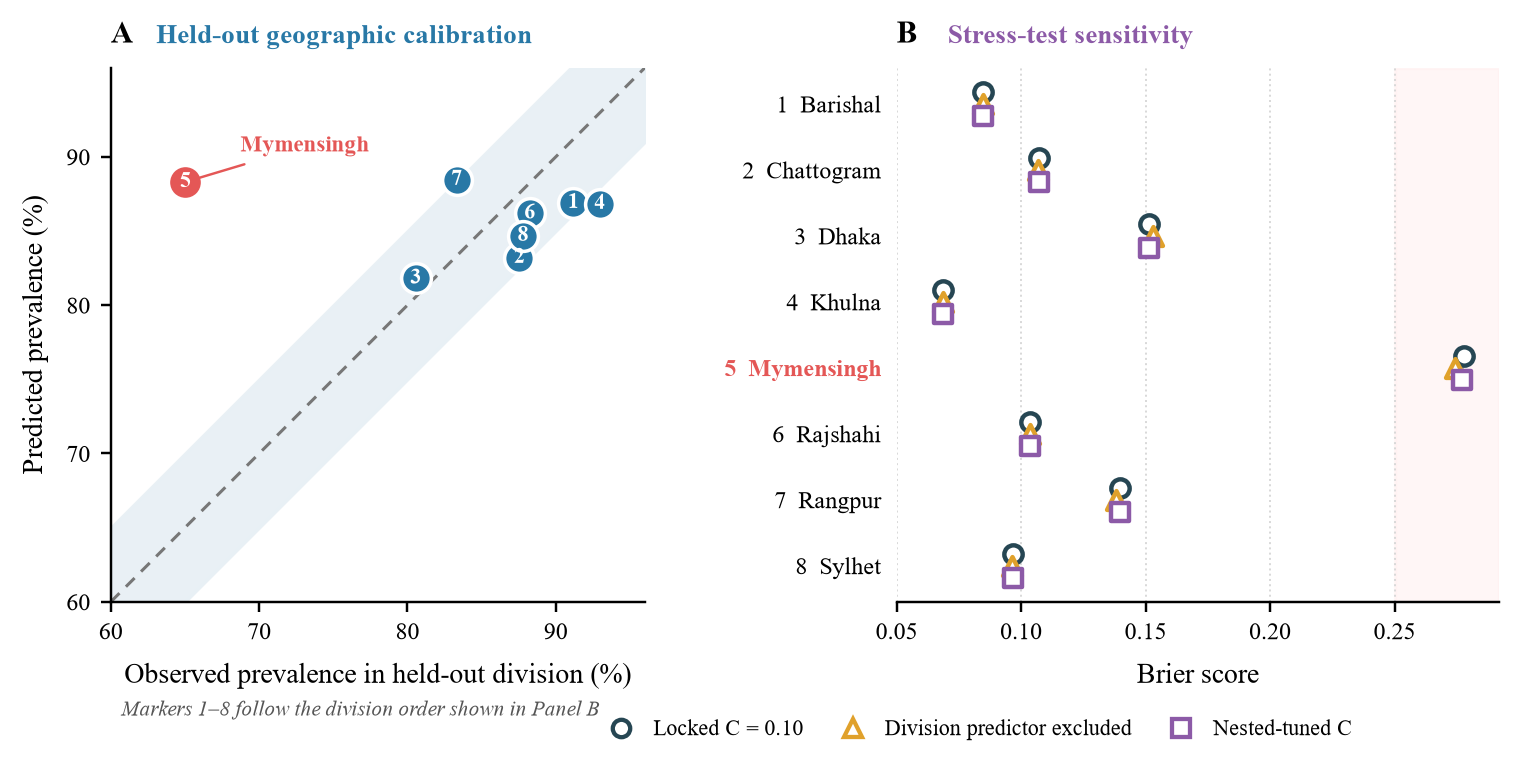

STEP 38D-R2 — FINAL POLISHED FIGURE 4

Panel A
Division labels       : Numbered markers
Full-name overlap     : Removed
Agreement reference   : Identity line + ±5 pp band
Mymensingh            : Highlighted

Panel B
Divisions             : All 8
Stress variants       : 3
Vertical marker dodge : Applied
Mymensingh label      : Highlighted
Legend                : Outside plot

Publication style
Font                  : Times New Roman
Overall title         : None
Palette               : Navy / gold / plum / coral
PDF / SVG             : Vector masters
PNG                   : 220-DPI preview

Saved:
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure4_GeographicStress_POLISHED_VECTOR_20260905_214041.pdf
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure4_GeographicStress_POLISHED_VECTOR_20260905_214041.svg
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure4_GeographicStress_POLISHED_PREVIEW_20260905_214041.png
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\f

In [11]:
# ============================================================
# STEP 38D-R2 — FINAL POLISHED FIGURE 4
# GEOGRAPHIC TRANSPORTABILITY STRESS TEST
#
# Panel A:
#   Observed vs predicted prevalence
#   Numbered division markers — no overlapping text labels
#
# Panel B:
#   Division-specific Brier under three stress-test variants
#
# No new analysis is performed.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from matplotlib.lines import Line2D

from IPython.display import display, Image as NotebookImage


# ============================================================
# 1. PROJECT
# ============================================================

PROJECT_ROOT = Path(
    r"E:\MICS_EColi_Q1_2026_Clean"
)

RUN_ID = "20260905_214041"


FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "manuscript"
    / "figures"
)


SOURCE_FILE = (
    FIGURE_DIR
    /
    f"Figure4_GeographicStress_FINAL_DATA_{RUN_ID}.csv"
)


if not SOURCE_FILE.exists():

    raise FileNotFoundError(
        f"Validated Figure 4 data not found:\n"
        f"{SOURCE_FILE}"
    )


# ============================================================
# 2. LOAD VALIDATED FIGURE DATA
# ============================================================

data = pd.read_csv(
    SOURCE_FILE
)


required_columns = [

    "DivisionCode",
    "Division",

    "ObservedPercent",
    "PredictedPercent",

    "Bias_pp",

    "Brier_Primary",
    "Brier_NoDivision",
    "Brier_Nested",
]


missing_columns = [
    column
    for column in required_columns
    if column not in data.columns
]


if missing_columns:

    raise RuntimeError(
        "Missing required Figure 4 columns:\n"
        +
        "\n".join(
            missing_columns
        )
    )


if len(data) != 8:

    raise RuntimeError(
        f"Expected 8 divisions; found {len(data)}."
    )


# ============================================================
# 3. DIVISION ORDER
# ============================================================

DIVISION_ORDER = [

    "Barishal",
    "Chattogram",
    "Dhaka",
    "Khulna",
    "Mymensingh",
    "Rajshahi",
    "Rangpur",
    "Sylhet",
]


division_order_map = {
    division:
        index

    for index, division
    in enumerate(
        DIVISION_ORDER
    )
}


data[
    "__order"
] = (
    data[
        "Division"
    ]
    .map(
        division_order_map
    )
)


if data[
    "__order"
].isna().any():

    raise RuntimeError(
        "Unexpected division label."
    )


FIG_DATA = (
    data
    .sort_values(
        "__order"
    )
    .reset_index(
        drop=True
    )
    .copy()
)


FIG_DATA[
    "PlotNumber"
] = (
    np.arange(
        1,
        9
    )
)


# ============================================================
# 4. NUMERIC QA
# ============================================================

numeric_columns = [

    "ObservedPercent",
    "PredictedPercent",
    "Bias_pp",

    "Brier_Primary",
    "Brier_NoDivision",
    "Brier_Nested",
]


for column in numeric_columns:

    FIG_DATA[
        column
    ] = pd.to_numeric(
        FIG_DATA[
            column
        ],
        errors="raise",
    )


if not np.isfinite(
    FIG_DATA[
        numeric_columns
    ].to_numpy(
        dtype=float
    )
).all():

    raise RuntimeError(
        "Non-finite geographic stress-test value."
    )


# ============================================================
# 5. MYMENSINGH HARD QA
# ============================================================

mymensingh = FIG_DATA.loc[
    FIG_DATA[
        "Division"
    ]
    ==
    "Mymensingh"
]


if len(mymensingh) != 1:

    raise RuntimeError(
        "Mymensingh row not unique."
    )


mymensingh = (
    mymensingh.iloc[0]
)


if not np.isclose(
    mymensingh[
        "Brier_Primary"
    ],
    0.278052671,
    atol=5e-9,
    rtol=0.0,
):

    raise RuntimeError(
        "Mymensingh primary Brier mismatch."
    )


if not np.isclose(
    mymensingh[
        "Bias_pp"
    ],
    -23.275059309,
    atol=5e-6,
    rtol=0.0,
):

    raise RuntimeError(
        "Mymensingh prevalence-bias mismatch."
    )


# ============================================================
# 6. FIGURE-SPECIFIC PALETTE
#
# Different from Figures 1–3
# ============================================================

COLOR_DIVISION = "#2878A6"       # ocean blue
COLOR_OUTLIER = "#E45756"        # coral red

COLOR_PRIMARY = "#264653"        # deep navy
COLOR_NO_DIVISION = "#E0A12B"    # warm gold
COLOR_NESTED = "#8C5AA7"         # plum

COLOR_IDENTITY = "#777777"
COLOR_BAND = "#E8F0F5"
COLOR_GRID = "#D9D9D9"
COLOR_CONNECTOR = "#B7B7B7"
COLOR_TEXT = "#252525"


# ============================================================
# 7. FONT + STYLE
# ============================================================

FONT_NAME = "Times New Roman"


font_path = font_manager.findfont(
    FONT_NAME,
    fallback_to_default=False,
)


mpl.rcParams.update({

    "font.family":
        "serif",

    "font.serif":
        [FONT_NAME],

    "font.size":
        8.5,

    "axes.labelsize":
        9.0,

    "xtick.labelsize":
        8.0,

    "ytick.labelsize":
        8.0,

    "legend.fontsize":
        7.2,

    "axes.linewidth":
        0.8,

    "xtick.major.width":
        0.8,

    "ytick.major.width":
        0.8,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,

    "svg.fonttype":
        "none",

    "figure.facecolor":
        "white",

    "axes.facecolor":
        "white",
})


# ============================================================
# 8. CREATE FIGURE
# ============================================================

fig, (
    ax_a,
    ax_b,
) = plt.subplots(

    nrows=1,

    ncols=2,

    figsize=(
        7.10,
        3.65,
    ),

    gridspec_kw={
        "width_ratios":
            [
                1.02,
                1.08,
            ]
    },
)


# ============================================================
# 9. PANEL A — AGREEMENT BAND
# ============================================================

AXIS_MIN = 60
AXIS_MAX = 96


agreement_x = np.linspace(
    AXIS_MIN,
    AXIS_MAX,
    300,
)


ax_a.fill_between(

    agreement_x,

    np.maximum(
        AXIS_MIN,
        agreement_x - 5,
    ),

    np.minimum(
        AXIS_MAX,
        agreement_x + 5,
    ),

    color=COLOR_BAND,

    alpha=0.95,

    zorder=0,
)


# Perfect agreement
ax_a.plot(

    [
        AXIS_MIN,
        AXIS_MAX,
    ],

    [
        AXIS_MIN,
        AXIS_MAX,
    ],

    color=COLOR_IDENTITY,

    linewidth=1.0,

    linestyle=(
        0,
        (
            4,
            3
        )
    ),

    zorder=1,
)


# ============================================================
# 10. PANEL A — NUMBERED DIVISION MARKERS
# ============================================================

for _, row in FIG_DATA.iterrows():

    division = row[
        "Division"
    ]


    is_mymensingh = (
        division
        ==
        "Mymensingh"
    )


    color = (
        COLOR_OUTLIER
        if is_mymensingh
        else
        COLOR_DIVISION
    )


    size = (
        125
        if is_mymensingh
        else
        95
    )


    # Filled circular point
    ax_a.scatter(

        row[
            "ObservedPercent"
        ],

        row[
            "PredictedPercent"
        ],

        s=size,

        facecolor=color,

        edgecolor="white",

        linewidth=1.15,

        zorder=3,
    )


    # Number inside point
    ax_a.text(

        row[
            "ObservedPercent"
        ],

        row[
            "PredictedPercent"
        ],

        str(
            int(
                row[
                    "PlotNumber"
                ]
            )
        ),

        ha="center",

        va="center",

        fontsize=7.2,

        fontweight="bold",

        color="white",

        zorder=4,
    )


# ============================================================
# 11. PANEL A — MYMENSINGH CALLOUT
# ============================================================

ax_a.annotate(

    "Mymensingh",

    xy=(
        mymensingh[
            "ObservedPercent"
        ],
        mymensingh[
            "PredictedPercent"
        ],
    ),

    xytext=(
        18,
        10,
    ),

    textcoords="offset points",

    color=COLOR_OUTLIER,

    fontsize=7.5,

    fontweight="bold",

    arrowprops={

        "arrowstyle":
            "-",

        "color":
            COLOR_OUTLIER,

        "linewidth":
            0.8,
    },

    zorder=5,
)


# ============================================================
# 12. PANEL A AXES
# ============================================================

ax_a.set_xlim(
    AXIS_MIN,
    AXIS_MAX,
)

ax_a.set_ylim(
    AXIS_MIN,
    AXIS_MAX,
)


ax_a.set_xticks(
    [
        60,
        70,
        80,
        90,
    ]
)


ax_a.set_yticks(
    [
        60,
        70,
        80,
        90,
    ]
)


ax_a.set_xlabel(
    "Observed prevalence in held-out division (%)",
    labelpad=6,
)


ax_a.set_ylabel(
    "Predicted prevalence (%)",
    labelpad=6,
)


ax_a.set_aspect(
    "equal",
    adjustable="box",
)


ax_a.spines[
    "top"
].set_visible(
    False
)

ax_a.spines[
    "right"
].set_visible(
    False
)


ax_a.tick_params(
    direction="out"
)


# ============================================================
# 13. PANEL A LABEL
# ============================================================

ax_a.text(

    0.00,

    1.035,

    "A",

    transform=
        ax_a.transAxes,

    fontsize=10.0,

    fontweight="bold",

    ha="left",

    va="bottom",
)


ax_a.text(

    0.085,

    1.035,

    "Held-out geographic calibration",

    transform=
        ax_a.transAxes,

    fontsize=8.7,

    fontweight="bold",

    color=COLOR_DIVISION,

    ha="left",

    va="bottom",
)


# ============================================================
# 14. PANEL A NUMBER KEY
# ============================================================

ax_a.text(

    0.02,

    -0.185,

    "Markers 1–8 follow the division order shown in Panel B",

    transform=
        ax_a.transAxes,

    ha="left",

    va="top",

    fontsize=6.8,

    fontstyle="italic",

    color="#555555",
)


# ============================================================
# 15. PANEL B
# ============================================================

y = np.arange(
    len(
        FIG_DATA
    )
)


# Small vertical offsets make near-identical results visible
OFFSET_PRIMARY = -0.18
OFFSET_NODIV = 0.00
OFFSET_NESTED = 0.18


for i, row in FIG_DATA.iterrows():

    values = [

        float(
            row[
                "Brier_Primary"
            ]
        ),

        float(
            row[
                "Brier_NoDivision"
            ]
        ),

        float(
            row[
                "Brier_Nested"
            ]
        ),
    ]


    # Horizontal range across all three variants
    ax_b.hlines(

        y=i,

        xmin=min(
            values
        ),

        xmax=max(
            values
        ),

        color=COLOR_CONNECTOR,

        linewidth=1.2,

        zorder=1,
    )


    # Primary locked C
    ax_b.scatter(

        row[
            "Brier_Primary"
        ],

        i
        +
        OFFSET_PRIMARY,

        s=36,

        marker="o",

        facecolor="white",

        edgecolor=COLOR_PRIMARY,

        linewidth=1.45,

        zorder=3,
    )


    # Division predictor excluded
    ax_b.scatter(

        row[
            "Brier_NoDivision"
        ],

        i
        +
        OFFSET_NODIV,

        s=38,

        marker="^",

        facecolor="white",

        edgecolor=COLOR_NO_DIVISION,

        linewidth=1.45,

        zorder=3,
    )


    # Nested tuning
    ax_b.scatter(

        row[
            "Brier_Nested"
        ],

        i
        +
        OFFSET_NESTED,

        s=36,

        marker="s",

        facecolor="white",

        edgecolor=COLOR_NESTED,

        linewidth=1.45,

        zorder=3,
    )


# ============================================================
# 16. PANEL B AXES
# ============================================================

ax_b.set_yticks(
    y
)


# Number + division provides Panel A key
panel_b_labels = [

    (
        f"{int(row.PlotNumber)}  "
        f"{row.Division}"
    )

    for row
    in FIG_DATA.itertuples()
]


ax_b.set_yticklabels(
    panel_b_labels
)


ax_b.invert_yaxis()


ax_b.set_xlim(
    0.055,
    0.292,
)


ax_b.set_xticks(
    [
        0.05,
        0.10,
        0.15,
        0.20,
        0.25,
    ]
)


ax_b.set_xlabel(
    "Brier score",
    labelpad=6,
)


ax_b.grid(

    axis="x",

    linestyle=":",

    linewidth=0.65,

    color=COLOR_GRID,

    zorder=0,
)


ax_b.spines[
    "top"
].set_visible(
    False
)

ax_b.spines[
    "right"
].set_visible(
    False
)

ax_b.spines[
    "left"
].set_visible(
    False
)


ax_b.tick_params(

    axis="y",

    length=0,

    pad=5,
)


ax_b.tick_params(

    axis="x",

    direction="out",
)


# ============================================================
# 17. HIGHLIGHT MYMENSINGH LABEL
# ============================================================

for label in ax_b.get_yticklabels():

    if "Mymensingh" in label.get_text():

        label.set_color(
            COLOR_OUTLIER
        )

        label.set_fontweight(
            "bold"
        )


# ============================================================
# 18. PANEL B — OUTLIER GUIDE
# ============================================================

ax_b.axvspan(

    0.25,

    0.292,

    color="#FFF0F0",

    alpha=0.60,

    zorder=0,
)


# ============================================================
# 19. PANEL B LABEL
# ============================================================

ax_b.text(

    0.00,

    1.035,

    "B",

    transform=
        ax_b.transAxes,

    fontsize=10.0,

    fontweight="bold",

    ha="left",

    va="bottom",
)


ax_b.text(

    0.085,

    1.035,

    "Stress-test sensitivity",

    transform=
        ax_b.transAxes,

    fontsize=8.7,

    fontweight="bold",

    color=COLOR_NESTED,

    ha="left",

    va="bottom",
)


# ============================================================
# 20. COMMON LEGEND BELOW FIGURE
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=COLOR_PRIMARY,
        markeredgewidth=1.4,
        markersize=5.7,
        label="Locked C = 0.10",
    ),

    Line2D(
        [0],
        [0],
        marker="^",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=COLOR_NO_DIVISION,
        markeredgewidth=1.4,
        markersize=5.8,
        label="Division predictor excluded",
    ),

    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=COLOR_NESTED,
        markeredgewidth=1.4,
        markersize=5.6,
        label="Nested-tuned C",
    ),
]


fig.legend(

    handles=
        legend_handles,

    loc="lower center",

    bbox_to_anchor=(
        0.65,
        0.018,
    ),

    ncol=3,

    frameon=False,

    handletextpad=0.45,

    columnspacing=1.25,
)


# ============================================================
# 21. LAYOUT
# ============================================================

fig.subplots_adjust(

    left=0.085,

    right=0.985,

    bottom=0.215,

    top=0.88,

    wspace=0.40,
)


# ============================================================
# 22. SAVE DATA
# ============================================================

DATA_FILE = (
    FIGURE_DIR
    /
    f"Figure4_GeographicStress_POLISHED_DATA_{RUN_ID}.csv"
)


FIG_DATA.drop(
    columns=[
        "__order",
    ]
).to_csv(
    DATA_FILE,
    index=False,
)


# ============================================================
# 23. OUTPUT FILES
# ============================================================

PDF_FILE = (
    FIGURE_DIR
    /
    f"Figure4_GeographicStress_POLISHED_VECTOR_{RUN_ID}.pdf"
)


SVG_FILE = (
    FIGURE_DIR
    /
    f"Figure4_GeographicStress_POLISHED_VECTOR_{RUN_ID}.svg"
)


PREVIEW_FILE = (
    FIGURE_DIR
    /
    f"Figure4_GeographicStress_POLISHED_PREVIEW_{RUN_ID}.png"
)


# ============================================================
# 24. SAVE
# ============================================================

fig.savefig(

    PDF_FILE,

    format="pdf",

    facecolor="white",

    bbox_inches="tight",
)


fig.savefig(

    SVG_FILE,

    format="svg",

    facecolor="white",

    bbox_inches="tight",
)


fig.savefig(

    PREVIEW_FILE,

    dpi=220,

    format="png",

    facecolor="white",

    bbox_inches="tight",
)


plt.close(
    fig
)


# ============================================================
# 25. FILE QA
# ============================================================

for path in [

    PDF_FILE,

    SVG_FILE,

    PREVIEW_FILE,

    DATA_FILE,
]:

    if (
        not path.exists()
        or
        path.stat().st_size <= 0
    ):

        raise RuntimeError(
            f"Invalid output: {path}"
        )


# ============================================================
# 26. PREVIEW
# ============================================================

display(
    NotebookImage(
        filename=str(
            PREVIEW_FILE
        )
    )
)


# ============================================================
# 27. FINAL OUTPUT
# ============================================================

print("=" * 155)

print(
    "STEP 38D-R2 — FINAL POLISHED FIGURE 4"
)

print("=" * 155)


print(
    "\nPanel A"
)

print(
    "Division labels       : Numbered markers"
)

print(
    "Full-name overlap     : Removed"
)

print(
    "Agreement reference   : Identity line + ±5 pp band"
)

print(
    "Mymensingh            : Highlighted"
)


print(
    "\nPanel B"
)

print(
    "Divisions             : All 8"
)

print(
    "Stress variants       : 3"
)

print(
    "Vertical marker dodge : Applied"
)

print(
    "Mymensingh label      : Highlighted"
)

print(
    "Legend                : Outside plot"
)


print(
    "\nPublication style"
)

print(
    "Font                  : Times New Roman"
)

print(
    "Overall title         : None"
)

print(
    "Palette               : Navy / gold / plum / coral"
)

print(
    "PDF / SVG             : Vector masters"
)

print(
    "PNG                   : 220-DPI preview"
)


print(
    "\nSaved:"
)

print(PDF_FILE)
print(SVG_FILE)
print(PREVIEW_FILE)
print(DATA_FILE)


print(
    "\n✅ STEP 38D-R2 COMPLETED SUCCESSFULLY"
)

print("=" * 155)

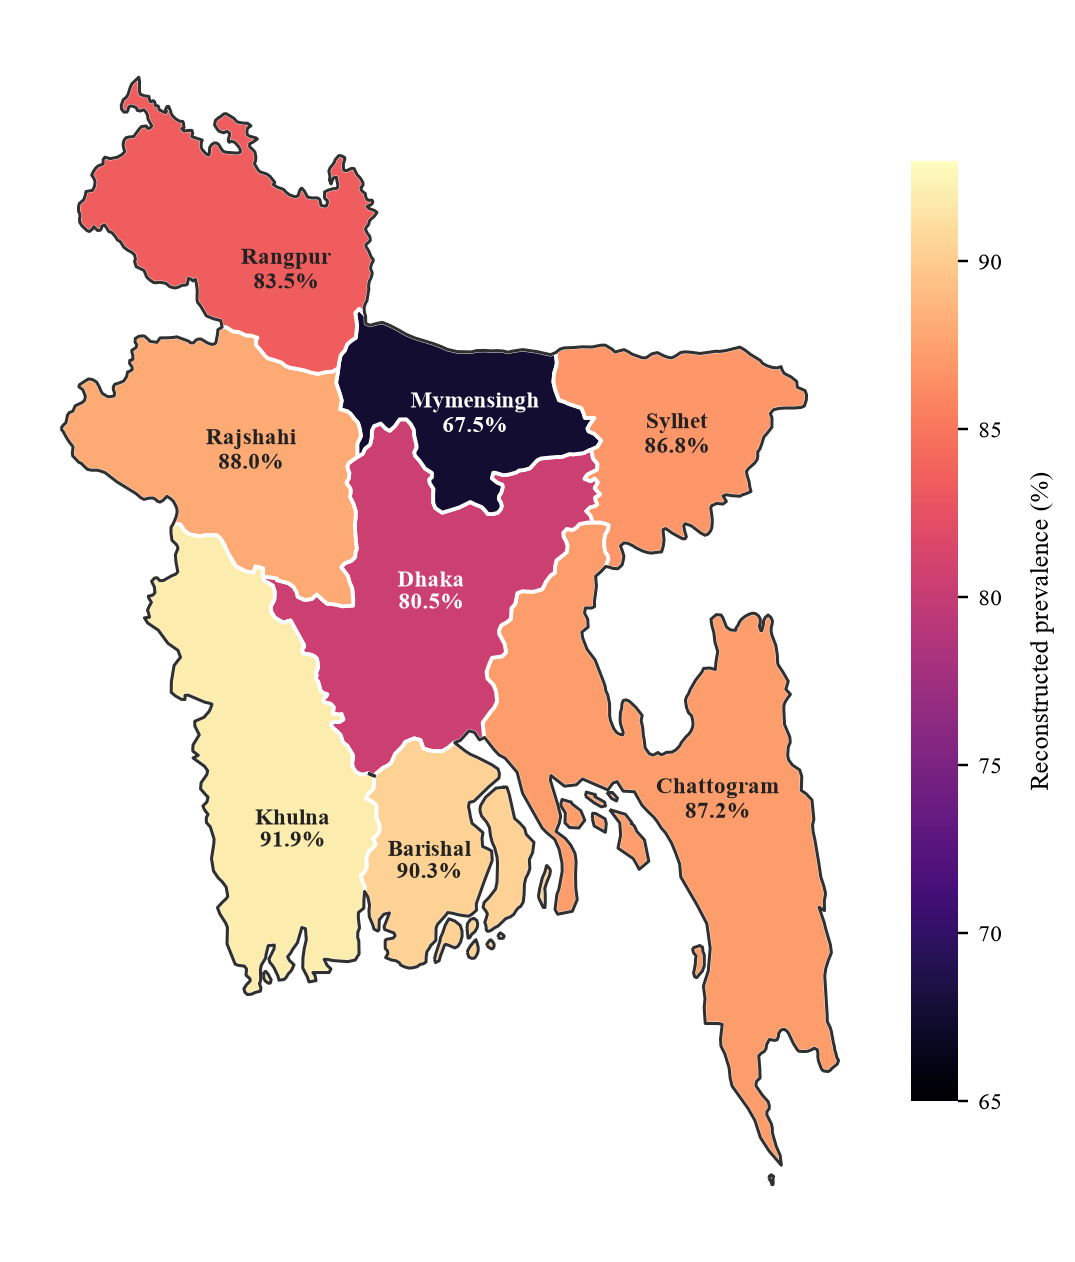

STEP 38E-R4 — CENTERED-LABEL BANGLADESH MAP

Labels              : Centrally positioned inside divisions
Chattogram          : Right shift removed / moved inward
White label boxes   : None
Division count      : 8 / 8
Font                : Times New Roman
Overall title       : None
PDF / SVG           : Vector masters
PNG                 : 220-DPI preview

Saved:
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure4_Bangladesh_Map_CENTERED_FINAL_VECTOR_20260905_214041.pdf
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure4_Bangladesh_Map_CENTERED_FINAL_VECTOR_20260905_214041.svg
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure4_Bangladesh_Map_CENTERED_FINAL_PREVIEW_20260905_214041.png

✅ STEP 38E-R4 COMPLETED


In [17]:
# ============================================================
# STEP 38E-R4 — FINAL CENTERED-LABEL BANGLADESH MAP
#
# - All labels placed centrally inside each division
# - Chattogram right-shift removed
# - No white label boxes
# - Times New Roman
# - PDF/SVG vector masters
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import polylabel

from IPython.display import display, Image as NotebookImage


# ============================================================
# 1. PROJECT
# ============================================================

PROJECT_ROOT = Path(
    r"E:\MICS_EColi_Q1_2026_Clean"
)

RUN_ID = "20260905_214041"

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "manuscript"
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. CHECK MAP DATA
# ============================================================

if "map_data" not in globals():

    raise RuntimeError(
        "map_data not found. "
        "Run STEP 38E-R2 first."
    )


if len(map_data) != 8:

    raise RuntimeError(
        f"Expected 8 divisions; found {len(map_data)}."
    )


# ============================================================
# 3. CENTRAL LABEL POINT FUNCTION
#
# polylabel finds an interior point with maximum clearance
# from polygon boundaries.
# For MultiPolygon, use largest polygon.
# ============================================================

def get_central_label_point(geometry):

    try:

        if isinstance(
            geometry,
            MultiPolygon
        ):

            geometry_for_label = max(
                geometry.geoms,
                key=lambda g: g.area
            )

        elif isinstance(
            geometry,
            Polygon
        ):

            geometry_for_label = geometry

        else:

            return geometry.representative_point()


        point = polylabel(
            geometry_for_label,
            tolerance=1000
        )


        return point


    except Exception:

        return geometry.representative_point()


# ============================================================
# 4. RECALCULATE CENTRAL LABEL LOCATIONS
# ============================================================

central_points = (
    map_data[
        "geometry"
    ]
    .apply(
        get_central_label_point
    )
)


map_data = map_data.copy()


map_data[
    "CenterX"
] = central_points.x


map_data[
    "CenterY"
] = central_points.y


# ============================================================
# 5. VERY SMALL FINAL MANUAL ADJUSTMENTS
#
# No large shifts.
# Chattogram is pulled slightly LEFT only.
# ============================================================

LABEL_ADJUSTMENTS = {

    "Barishal":
        (0, 0),

    "Chattogram":
        (-7000, 0),

    "Dhaka":
        (0, 0),

    "Khulna":
        (0, 0),

    "Mymensingh":
        (0, 0),

    "Rajshahi":
        (0, 0),

    "Rangpur":
        (0, 0),

    "Sylhet":
        (0, 0),
}


# ============================================================
# 6. TEXT COLORS
# ============================================================

TEXT_COLORS = {

    "Barishal":
        "#222222",

    "Chattogram":
        "#222222",

    "Dhaka":
        "#FFFFFF",

    "Khulna":
        "#222222",

    "Mymensingh":
        "#FFFFFF",

    "Rajshahi":
        "#222222",

    "Rangpur":
        "#222222",

    "Sylhet":
        "#222222",
}


# ============================================================
# 7. STYLE
# ============================================================

mpl.rcParams.update({

    "font.family":
        "serif",

    "font.serif":
        ["Times New Roman"],

    "font.size":
        8.5,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,

    "svg.fonttype":
        "none",

    "figure.facecolor":
        "white",

    "axes.facecolor":
        "white",
})


# ============================================================
# 8. COLOR SCALE
# ============================================================

VMIN = 65
VMAX = 93


norm = Normalize(
    vmin=VMIN,
    vmax=VMAX,
)


cmap = mpl.colormaps[
    "magma"
]


# ============================================================
# 9. FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        6.25,
        5.65,
    )
)


# Choropleth
map_data.plot(

    column=
        "PointEstimatePercent",

    cmap=cmap,

    norm=norm,

    edgecolor="white",

    linewidth=1.25,

    ax=ax,

    zorder=1,
)


# Bangladesh external outline
map_data.dissolve().boundary.plot(

    ax=ax,

    color="#303030",

    linewidth=1.0,

    zorder=2,
)


# ============================================================
# 10. CENTERED LABELS
# ============================================================

for _, row in map_data.iterrows():

    division_name = row[
        "Division"
    ]


    estimate = float(
        row[
            "PointEstimatePercent"
        ]
    )


    dx, dy = LABEL_ADJUSTMENTS[
        division_name
    ]


    x = (
        row[
            "CenterX"
        ]
        +
        dx
    )


    y = (
        row[
            "CenterY"
        ]
        +
        dy
    )


    label = (
        f"{division_name}\n"
        f"{estimate:.1f}%"
    )


    ax.text(

        x,
        y,

        label,

        ha="center",

        va="center",

        fontsize=7.7,

        fontweight="bold",

        color=TEXT_COLORS[
            division_name
        ],

        linespacing=1.05,

        zorder=4,
    )


# ============================================================
# 11. COLORBAR
# ============================================================

scalar_map = ScalarMappable(
    norm=norm,
    cmap=cmap,
)

scalar_map.set_array([])


colorbar = fig.colorbar(

    scalar_map,

    ax=ax,

    fraction=0.038,

    pad=0.027,
)


colorbar.set_label(

    "Reconstructed prevalence (%)",

    rotation=90,

    labelpad=9,

    fontsize=8.5,
)


colorbar.set_ticks(
    [
        65,
        70,
        75,
        80,
        85,
        90,
    ]
)


colorbar.ax.tick_params(
    labelsize=7.6
)


colorbar.outline.set_visible(
    False
)


# ============================================================
# 12. CLEAN AXIS
# ============================================================

ax.set_axis_off()


fig.subplots_adjust(

    left=0.01,

    right=0.91,

    bottom=0.01,

    top=0.99,
)


# ============================================================
# 13. OUTPUT PATHS
# ============================================================

PDF_FILE = (
    FIGURE_DIR
    /
    f"Figure4_Bangladesh_Map_CENTERED_FINAL_VECTOR_{RUN_ID}.pdf"
)


SVG_FILE = (
    FIGURE_DIR
    /
    f"Figure4_Bangladesh_Map_CENTERED_FINAL_VECTOR_{RUN_ID}.svg"
)


PREVIEW_FILE = (
    FIGURE_DIR
    /
    f"Figure4_Bangladesh_Map_CENTERED_FINAL_PREVIEW_{RUN_ID}.png"
)


# ============================================================
# 14. SAVE
# ============================================================

fig.savefig(

    PDF_FILE,

    format="pdf",

    facecolor="white",

    bbox_inches="tight",
)


fig.savefig(

    SVG_FILE,

    format="svg",

    facecolor="white",

    bbox_inches="tight",
)


fig.savefig(

    PREVIEW_FILE,

    dpi=220,

    format="png",

    facecolor="white",

    bbox_inches="tight",
)


plt.close(
    fig
)


# ============================================================
# 15. FILE QA
# ============================================================

for path in [
    PDF_FILE,
    SVG_FILE,
    PREVIEW_FILE,
]:

    if (
        not path.exists()
        or
        path.stat().st_size <= 0
    ):

        raise RuntimeError(
            f"Invalid output: {path}"
        )


# ============================================================
# 16. PREVIEW
# ============================================================

display(
    NotebookImage(
        filename=str(
            PREVIEW_FILE
        )
    )
)


# ============================================================
# 17. STATUS
# ============================================================

print("=" * 145)

print(
    "STEP 38E-R4 — CENTERED-LABEL BANGLADESH MAP"
)

print("=" * 145)

print(
    "\nLabels              : Centrally positioned inside divisions"
)

print(
    "Chattogram          : Right shift removed / moved inward"
)

print(
    "White label boxes   : None"
)

print(
    "Division count      : 8 / 8"
)

print(
    "Font                : Times New Roman"
)

print(
    "Overall title       : None"
)

print(
    "PDF / SVG           : Vector masters"
)

print(
    "PNG                 : 220-DPI preview"
)

print(
    "\nSaved:"
)

print(PDF_FILE)
print(SVG_FILE)
print(PREVIEW_FILE)

print(
    "\n✅ STEP 38E-R4 COMPLETED"
)

print("=" * 145)

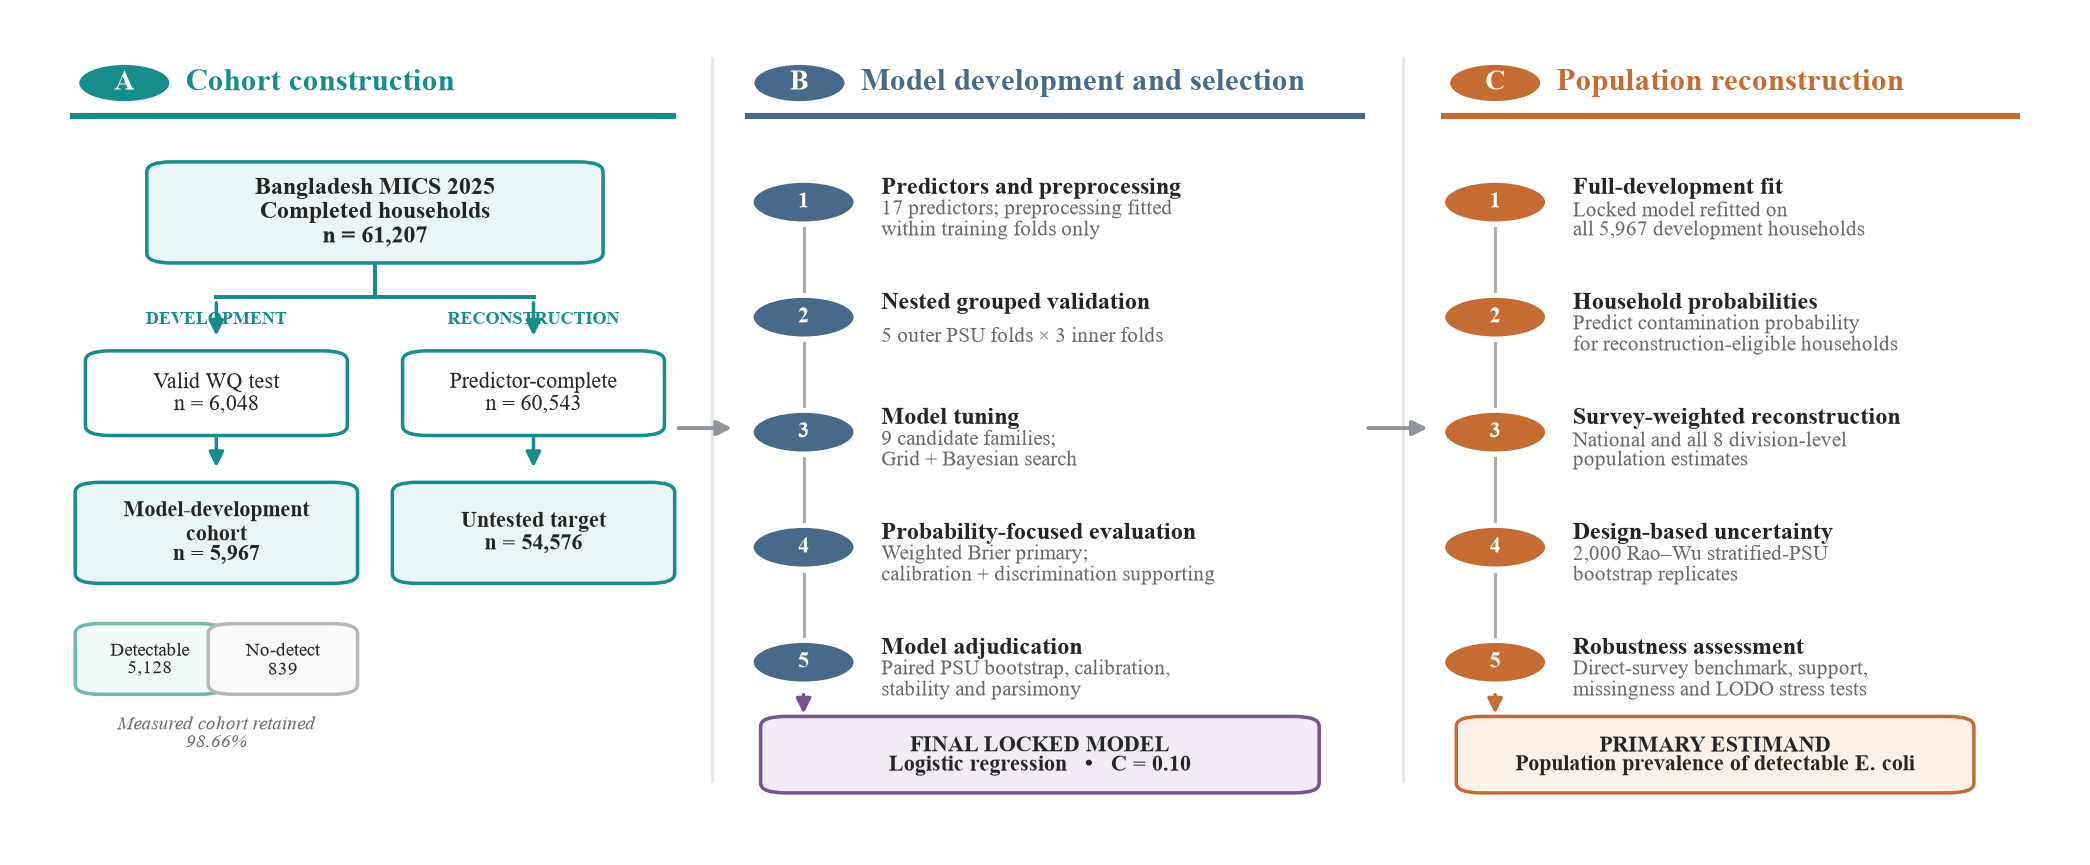

STEP 38F-R5 — FINAL POLISHED METHODOLOGICAL FRAMEWORK

Step-5 connectors     : Straight vertical
Bottom summary boxes : Raised
Retention note        : Centered below outcome chips
Branch labels         : Smaller and centered
Methodology           : Unchanged
Font                  : Times New Roman
Overall title         : None
PDF / SVG             : Vector masters
PNG                   : 220-DPI preview

Saved:
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure1_MethodologicalFramework_FINAL_LOCKED_VECTOR_20260905_214041.pdf
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure1_MethodologicalFramework_FINAL_LOCKED_VECTOR_20260905_214041.svg
E:\MICS_EColi_Q1_2026_Clean\outputs\manuscript\figures\Figure1_MethodologicalFramework_FINAL_LOCKED_PREVIEW_20260905_214041.png

✅ STEP 38F-R5 COMPLETED


In [21]:
# ============================================================
# STEP 38F-R5 — FINAL POLISHED METHODOLOGICAL FRAMEWORK
#
# Changes from R4:
# 1. Straight vertical connectors from Step 5 to summary boxes
# 2. Bottom summary boxes raised slightly
# 3. Cohort-retention note centered below outcome chips
# 4. DEVELOPMENT / RECONSTRUCTION labels refined
#
# No methodological or numerical changes.
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
    Circle,
)

from IPython.display import (
    display,
    Image as NotebookImage,
)


# ============================================================
# 1. PROJECT
# ============================================================

PROJECT_ROOT = Path(
    r"E:\MICS_EColi_Q1_2026_Clean"
)

RUN_ID = "20260905_214041"

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "manuscript"
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. STYLE
# ============================================================

mpl.rcParams.update({

    "font.family":
        "serif",

    "font.serif":
        ["Times New Roman"],

    "font.size":
        8.5,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,

    "svg.fonttype":
        "none",

    "figure.facecolor":
        "white",

    "axes.facecolor":
        "white",
})


# ============================================================
# 3. PALETTE
# ============================================================

TEAL = "#168C8C"
TEAL_LIGHT = "#EAF6F5"

BLUE = "#486A8A"

ORANGE = "#C56C32"
ORANGE_LIGHT = "#FBF1E9"

PURPLE = "#76528F"
PURPLE_LIGHT = "#F1EBF5"

TEXT = "#252525"
MUTED = "#666A6D"
LINE = "#A8ADB0"
LIGHT_LINE = "#E2E4E5"
WHITE = "#FFFFFF"


# ============================================================
# 4. CANVAS
# ============================================================

fig, ax = plt.subplots(
    figsize=(12.0, 4.85)
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.axis("off")


# ============================================================
# 5. HELPERS
# ============================================================

def phase_header(
    x0,
    x1,
    letter,
    title,
    color,
):

    y = 0.925

    ax.add_patch(
        Circle(
            (x0 + 0.025, y),
            0.022,
            facecolor=color,
            edgecolor="none",
            zorder=5,
        )
    )

    ax.text(
        x0 + 0.025,
        y,
        letter,
        ha="center",
        va="center",
        fontsize=9.2,
        fontweight="bold",
        color="white",
        zorder=6,
    )

    ax.text(
        x0 + 0.055,
        y,
        title,
        ha="left",
        va="center",
        fontsize=10.0,
        fontweight="bold",
        color=color,
    )

    ax.plot(
        [x0, x1],
        [0.885, 0.885],
        color=color,
        linewidth=2.0,
    )


def card(
    x,
    y,
    w,
    h,
    text,
    edge,
    fill=WHITE,
    fontsize=7.7,
    bold=False,
):

    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.009,rounding_size=0.012",
        facecolor=fill,
        edgecolor=edge,
        linewidth=1.15,
        zorder=3,
    )

    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal",
        color=TEXT,
        linespacing=1.10,
        zorder=4,
    )


def arrow(
    x1,
    y1,
    x2,
    y2,
    color=LINE,
    lw=1.15,
):

    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=10,
            linewidth=lw,
            color=color,
            shrinkA=2,
            shrinkB=2,
            zorder=2,
        )
    )


def numbered_step(
    x,
    y,
    n,
    heading,
    detail,
    color,
    line_above=True,
    line_below=True,
):

    if line_above:

        ax.plot(
            [x, x],
            [y + 0.032, y + 0.080],
            color=LINE,
            linewidth=1.0,
            zorder=1,
        )

    if line_below:

        ax.plot(
            [x, x],
            [y - 0.080, y - 0.032],
            color=LINE,
            linewidth=1.0,
            zorder=1,
        )

    ax.add_patch(
        Circle(
            (x, y),
            0.025,
            facecolor=color,
            edgecolor="white",
            linewidth=0.8,
            zorder=4,
        )
    )

    ax.text(
        x,
        y,
        str(n),
        ha="center",
        va="center",
        fontsize=7.3,
        fontweight="bold",
        color="white",
        zorder=5,
    )

    ax.text(
        x + 0.038,
        y + 0.017,
        heading,
        ha="left",
        va="center",
        fontsize=8.0,
        fontweight="bold",
        color=TEXT,
    )

    ax.text(
        x + 0.038,
        y - 0.021,
        detail,
        ha="left",
        va="center",
        fontsize=6.9,
        color=MUTED,
        linespacing=1.10,
    )


# ============================================================
# 6. PANEL REGIONS
# ============================================================

A0, A1 = 0.025, 0.318
B0, B1 = 0.355, 0.655
C0, C1 = 0.695, 0.975


phase_header(
    A0, A1,
    "A",
    "Cohort construction",
    TEAL,
)

phase_header(
    B0, B1,
    "B",
    "Model development and selection",
    BLUE,
)

phase_header(
    C0, C1,
    "C",
    "Population reconstruction",
    ORANGE,
)


# separators
for x in [0.337, 0.675]:

    ax.plot(
        [x, x],
        [0.075, 0.955],
        color=LIGHT_LINE,
        linewidth=0.9,
    )


# ============================================================
# 7. PANEL A — COHORT CONSTRUCTION
# ============================================================

card(
    0.070,
    0.715,
    0.205,
    0.105,

    "Bangladesh MICS 2025\n"
    "Completed households\n"
    "n = 61,207",

    TEAL,
    fill=TEAL_LIGHT,
    fontsize=8.0,
    bold=True,
)


# branch stem
ax.plot(
    [0.1725, 0.1725],
    [0.715, 0.665],
    color=TEAL,
    linewidth=1.3,
)

ax.plot(
    [0.095, 0.250],
    [0.665, 0.665],
    color=TEAL,
    linewidth=1.3,
)


arrow(
    0.095, 0.665,
    0.095, 0.610,
    color=TEAL,
)

arrow(
    0.250, 0.665,
    0.250, 0.610,
    color=TEAL,
)


# smaller + centered branch headings
ax.text(
    0.095,
    0.627,
    "DEVELOPMENT",
    ha="center",
    va="bottom",
    fontsize=5.9,
    fontweight="bold",
    color=TEAL,
)

ax.text(
    0.250,
    0.627,
    "RECONSTRUCTION",
    ha="center",
    va="bottom",
    fontsize=5.9,
    fontweight="bold",
    color=TEAL,
)


card(
    0.040,
    0.505,
    0.110,
    0.085,

    "Valid WQ test\n"
    "n = 6,048",

    TEAL,
    fontsize=7.2,
)


card(
    0.195,
    0.505,
    0.110,
    0.085,

    "Predictor-complete\n"
    "n = 60,543",

    TEAL,
    fontsize=7.1,
)


arrow(
    0.095, 0.505,
    0.095, 0.450,
    color=TEAL,
)

arrow(
    0.250, 0.505,
    0.250, 0.450,
    color=TEAL,
)


card(
    0.035,
    0.325,
    0.120,
    0.105,

    "Model-development\n"
    "cohort\n"
    "n = 5,967",

    TEAL,
    fill=TEAL_LIGHT,
    fontsize=7.2,
    bold=True,
)


card(
    0.190,
    0.325,
    0.120,
    0.105,

    "Untested target\n"
    "n = 54,576",

    TEAL,
    fill=TEAL_LIGHT,
    fontsize=7.3,
    bold=True,
)


# outcome chips
card(
    0.035,
    0.190,
    0.055,
    0.068,

    "Detectable\n"
    "5,128",

    "#72B8AE",
    fill="#F3FBF9",
    fontsize=6.35,
)


card(
    0.100,
    0.190,
    0.055,
    0.068,

    "No-detect\n"
    "839",

    "#B8B8B8",
    fill="#FAFAFA",
    fontsize=6.35,
)


# centered note BELOW outcome chips
ax.text(
    0.095,
    0.135,

    "Measured cohort retained\n98.66%",

    ha="center",
    va="center",

    fontsize=6.25,

    color=MUTED,

    fontstyle="italic",

    linespacing=1.05,
)


# ============================================================
# 8. PANEL B — MODEL DEVELOPMENT
# ============================================================

BX = 0.382


numbered_step(
    BX,
    0.780,
    1,
    "Predictors and preprocessing",
    "17 predictors; preprocessing fitted\nwithin training folds only",
    BLUE,
    line_above=False,
)


numbered_step(
    BX,
    0.640,
    2,
    "Nested grouped validation",
    "5 outer PSU folds × 3 inner folds",
    BLUE,
)


numbered_step(
    BX,
    0.500,
    3,
    "Model tuning",
    "9 candidate families;\nGrid + Bayesian search",
    BLUE,
)


numbered_step(
    BX,
    0.360,
    4,
    "Probability-focused evaluation",
    "Weighted Brier primary;\ncalibration + discrimination supporting",
    BLUE,
)


numbered_step(
    BX,
    0.220,
    5,
    "Model adjudication",
    "Paired PSU bootstrap, calibration,\nstability and parsimony",
    BLUE,
    line_below=False,
)


# straight vertical connector
arrow(
    BX,
    0.188,
    BX,
    0.150,
    color=PURPLE,
    lw=1.15,
)


# raised summary box
card(
    0.370,
    0.070,
    0.255,
    0.075,

    "FINAL LOCKED MODEL\n"
    "Logistic regression   •   C = 0.10",

    PURPLE,
    fill=PURPLE_LIGHT,
    fontsize=7.3,
    bold=True,
)


# ============================================================
# 9. PANEL C — RECONSTRUCTION
# ============================================================

CX = 0.720


numbered_step(
    CX,
    0.780,
    1,
    "Full-development fit",
    "Locked model refitted on\nall 5,967 development households",
    ORANGE,
    line_above=False,
)


numbered_step(
    CX,
    0.640,
    2,
    "Household probabilities",
    "Predict contamination probability\nfor reconstruction-eligible households",
    ORANGE,
)


numbered_step(
    CX,
    0.500,
    3,
    "Survey-weighted reconstruction",
    "National and all 8 division-level\npopulation estimates",
    ORANGE,
)


numbered_step(
    CX,
    0.360,
    4,
    "Design-based uncertainty",
    "2,000 Rao–Wu stratified-PSU\nbootstrap replicates",
    ORANGE,
)


numbered_step(
    CX,
    0.220,
    5,
    "Robustness assessment",
    "Direct-survey benchmark, support,\nmissingness and LODO stress tests",
    ORANGE,
    line_below=False,
)


# straight vertical connector
arrow(
    CX,
    0.188,
    CX,
    0.150,
    color=ORANGE,
    lw=1.15,
)


# raised summary box
card(
    0.710,
    0.070,
    0.235,
    0.075,

    "PRIMARY ESTIMAND\n"
    "Population prevalence of detectable E. coli",

    ORANGE,
    fill=ORANGE_LIGHT,
    fontsize=7.05,
    bold=True,
)


# ============================================================
# 10. BETWEEN-PHASE ARROWS
# ============================================================

arrow(
    0.318,
    0.505,
    0.350,
    0.505,
    color="#8F9598",
    lw=1.3,
)


arrow(
    0.655,
    0.505,
    0.690,
    0.505,
    color="#8F9598",
    lw=1.3,
)


# ============================================================
# 11. OUTPUT FILES
# ============================================================

PDF_FILE = (
    FIGURE_DIR
    /
    f"Figure1_MethodologicalFramework_FINAL_LOCKED_VECTOR_{RUN_ID}.pdf"
)

SVG_FILE = (
    FIGURE_DIR
    /
    f"Figure1_MethodologicalFramework_FINAL_LOCKED_VECTOR_{RUN_ID}.svg"
)

PREVIEW_FILE = (
    FIGURE_DIR
    /
    f"Figure1_MethodologicalFramework_FINAL_LOCKED_PREVIEW_{RUN_ID}.png"
)


# ============================================================
# 12. SAVE
# ============================================================

fig.savefig(
    PDF_FILE,
    format="pdf",
    facecolor="white",
    bbox_inches="tight",
)

fig.savefig(
    SVG_FILE,
    format="svg",
    facecolor="white",
    bbox_inches="tight",
)

fig.savefig(
    PREVIEW_FILE,
    dpi=220,
    format="png",
    facecolor="white",
    bbox_inches="tight",
)

plt.close(fig)


# ============================================================
# 13. QA
# ============================================================

for path in [
    PDF_FILE,
    SVG_FILE,
    PREVIEW_FILE,
]:

    if (
        not path.exists()
        or
        path.stat().st_size <= 0
    ):

        raise RuntimeError(
            f"Invalid output: {path}"
        )


# ============================================================
# 14. PREVIEW
# ============================================================

display(
    NotebookImage(
        filename=str(
            PREVIEW_FILE
        )
    )
)


# ============================================================
# 15. STATUS
# ============================================================

print("=" * 150)

print(
    "STEP 38F-R5 — FINAL POLISHED METHODOLOGICAL FRAMEWORK"
)

print("=" * 150)

print("\nStep-5 connectors     : Straight vertical")
print("Bottom summary boxes : Raised")
print("Retention note        : Centered below outcome chips")
print("Branch labels         : Smaller and centered")
print("Methodology           : Unchanged")
print("Font                  : Times New Roman")
print("Overall title         : None")
print("PDF / SVG             : Vector masters")
print("PNG                   : 220-DPI preview")

print("\nSaved:")
print(PDF_FILE)
print(SVG_FILE)
print(PREVIEW_FILE)

print(
    "\n✅ STEP 38F-R5 COMPLETED"
)

print("=" * 150)